In [ ]:
# ============================================
# STEP 1A: Mount Google Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

!pip -q install -U kagglehub pandas

print("Google Drive mounted successfully.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 73.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
Google Drive mounted successfully.


In [ ]:
# ============================================
# STEP 1B: Download CICAPT-IIoT from Kaggle
# Dataset:
# https://www.kaggle.com/datasets/waqarkha/cicapt-iiot
# ============================================

import os
import kagglehub

DATASET_HANDLE = "waqarkha/cicapt-iiot"

DRIVE_ROOT = "/content/drive/MyDrive/IIoT_APT_Research"
DATASET_DIR = os.path.join(DRIVE_ROOT, "CICAPT_IIoT")

os.makedirs(DATASET_DIR, exist_ok=True)

print("Dataset will be stored at:")
print(DATASET_DIR)

download_path = kagglehub.dataset_download(
    DATASET_HANDLE,
    output_dir=DATASET_DIR
)

print("\nDataset download completed.")
print("Returned path:", download_path)
print("Permanent Google Drive location:", DATASET_DIR)

Dataset will be stored at:
/content/drive/MyDrive/IIoT_APT_Research/CICAPT_IIoT


100%|██████████| 2.27G/2.27G [00:32<00:00, 74.2MB/s]

Extracting files...



Dataset download completed.
Returned path: /content/drive/MyDrive/IIoT_APT_Research/CICAPT_IIoT
Permanent Google Drive location: /content/drive/MyDrive/IIoT_APT_Research/CICAPT_IIoT


In [ ]:
# ============================================
# STEP 1C: Basic Dataset Inventory
# ============================================

import os
import pandas as pd
from collections import Counter

all_files = []

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        full_path = os.path.join(root, file)

        try:
            size_mb = os.path.getsize(full_path) / (1024 ** 2)
        except:
            size_mb = 0

        extension = os.path.splitext(file)[1].lower()

        all_files.append({
            "file_name": file,
            "extension": extension,
            "size_mb": round(size_mb, 2),
            "full_path": full_path
        })

inventory_df = pd.DataFrame(all_files)

print("=" * 70)
print("CICAPT-IIoT BASIC DATASET INFORMATION")
print("=" * 70)

print("Total files :", len(inventory_df))

if len(inventory_df) > 0:
    total_size_gb = inventory_df["size_mb"].sum() / 1024
    print("Total size  :", round(total_size_gb, 2), "GB")

print("\nFile types:")

if len(inventory_df) > 0:
    print(
        inventory_df["extension"]
        .value_counts()
        .to_string()
    )

print("\nLargest files:")

display(
    inventory_df
    .sort_values("size_mb", ascending=False)
    .head(20)
)

# Save inventory permanently
inventory_file = os.path.join(
    DRIVE_ROOT,
    "CICAPT_file_inventory.csv"
)

inventory_df.to_csv(inventory_file, index=False)

print("\nInventory saved to:")
print(inventory_file)

CICAPT-IIoT BASIC DATASET INFORMATION
Total files : 3
Total size  : 9.14 GB

File types:
extension
.csv         2
.complete    1

Largest files:


,file_name,extension,size_mb,full_path
0,phase1_NetworkData.csv,.csv,5219.27,/content/drive/MyDrive/IIoT_APT_Research/CICAP...
1,phase2_NetworkData.csv,.csv,4135.49,/content/drive/MyDrive/IIoT_APT_Research/CICAP...
2,bundle.complete,.complete,0.00,/content/drive/MyDrive/IIoT_APT_Research/CICAP...



Inventory saved to:
/content/drive/MyDrive/IIoT_APT_Research/CICAPT_file_inventory.csv


In [ ]:
# ============================================
# STEP 1D: Check Important Dataset Components
# ============================================

keywords = {
    "Attack Information": ["attack_info", "attackinfo", "attack"],
    "Provenance": ["provenance"],
    "Network": ["network", "pcap", "packet"],
    "Phase 1": ["phase1", "phase_1", "phase 1"],
    "Phase 2": ["phase2", "phase_2", "phase 2"]
}

print("=" * 70)
print("REQUIRED COMPONENT CHECK")
print("=" * 70)

for component, terms in keywords.items():

    matches = []

    for path in inventory_df["full_path"].tolist():

        path_lower = path.lower()

        if any(term in path_lower for term in terms):
            matches.append(path)

    print(f"\n{component}: {len(matches)} matching files")

    for m in matches[:10]:
        print("  -", os.path.relpath(m, DATASET_DIR))

    if len(matches) > 10:
        print(f"  ... and {len(matches)-10} more")

REQUIRED COMPONENT CHECK

Attack Information: 0 matching files

Provenance: 0 matching files

Network: 2 matching files
  - phase1_NetworkData.csv
  - phase2_NetworkData.csv

Phase 1: 1 matching files
  - phase1_NetworkData.csv

Phase 2: 1 matching files
  - phase2_NetworkData.csv


In [ ]:
# ============================================
# STEP 1E: Audit all CSV files
# ============================================

import os
import pandas as pd
import time

csv_files = inventory_df[
    inventory_df["extension"] == ".csv"
]["full_path"].tolist()

print("Total CSV files:", len(csv_files))


def fast_count_lines(filename, chunk_size=1024 * 1024):
    """
    Count lines without loading entire CSV into RAM.
    """
    lines = 0

    with open(filename, "rb") as f:
        while True:
            buffer = f.read(chunk_size)

            if not buffer:
                break

            lines += buffer.count(b"\n")

    return max(lines - 1, 0)   # subtract header


csv_summary = []

for i, path in enumerate(csv_files, start=1):

    print("\n" + "=" * 70)
    print(f"[{i}/{len(csv_files)}]")
    print(os.path.relpath(path, DATASET_DIR))

    start = time.time()

    # Exact row count without loading complete dataset
    try:
        rows = fast_count_lines(path)
    except Exception as e:
        rows = None
        print("Row count error:", e)

    # Read only first 5 rows
    try:

        try:
            sample = pd.read_csv(
                path,
                nrows=5,
                low_memory=False
            )

        except UnicodeDecodeError:

            sample = pd.read_csv(
                path,
                nrows=5,
                encoding="latin1",
                low_memory=False
            )

        columns = list(sample.columns)
        n_columns = len(columns)

        print("Rows    :", f"{rows:,}" if rows is not None else "Unknown")
        print("Columns :", n_columns)

        print("\nColumn names:")
        print(columns)

        print("\nFirst 3 rows:")
        display(sample.head(3))

    except Exception as e:

        columns = []
        n_columns = None

        print("CSV read error:", e)

    csv_summary.append({
        "file": os.path.relpath(path, DATASET_DIR),
        "rows": rows,
        "columns": n_columns,
        "size_mb": round(os.path.getsize(path)/(1024**2), 2)
    })

    print(
        "Audit time:",
        round(time.time() - start, 1),
        "seconds"
    )


csv_summary_df = pd.DataFrame(csv_summary)

print("\n" + "=" * 70)
print("FINAL CSV SUMMARY")
print("=" * 70)

display(csv_summary_df)

summary_path = os.path.join(
    DRIVE_ROOT,
    "CICAPT_csv_basic_summary.csv"
)

csv_summary_df.to_csv(summary_path, index=False)

print("\nSummary saved to:")
print(summary_path)

Total CSV files: 2

[1/2]
phase1_NetworkData.csv
Rows    : 12,062,396
Columns : 70

Column names:
['ts', 'flow_duration', 'Header_Length', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol Type', 'Protocol_name', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'urg_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'max_duration', 'min_duration', 'sum_duration', 'average_duration', 'std_duration', 'CoAP', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'MAC', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'DS status', 'Fragments', 'Sequence number', 'Protocol Version', 'flow_idle_time', 'flow_active_time', 'label', 'subLabel', 'subLabelCat']

First 3 rows:


,ts,flow_duration,Header_Length,Source IP,Destination IP,Source Port,Destination Port,Protocol Type,Protocol_name,Duration,...,Weight,DS status,Fragments,Sequence number,Protocol Version,flow_idle_time,flow_active_time,label,subLabel,subLabelCat
0,1.701426e+09,0.000000,66,172.16.64.128,172.16.66.128,41750,502,6,TCP,64,...,1,0,0,0,0,1.701426e+09,0.000000,0,0,0
1,1.701426e+09,0.002112,132,172.16.64.128,172.16.66.128,41750,502,6,TCP,64,...,4,0,0,0,0,2.112150e-03,0.002112,0,0,0
2,1.701426e+09,0.002328,198,172.16.64.128,172.16.66.128,41750,502,6,TCP,64,...,9,0,0,0,0,2.160072e-04,0.002328,0,0,0


Audit time: 40.9 seconds

[2/2]
phase2_NetworkData.csv
Rows    : 9,536,823
Columns : 70

Column names:
['ts', 'flow_duration', 'Header_Length', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol Type', 'Protocol_name', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'urg_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'max_duration', 'min_duration', 'sum_duration', 'average_duration', 'std_duration', 'CoAP', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'MAC', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'DS status', 'Fragments', 'Sequence number', 'Protocol Version', 'flow_idle_time', 'flow_active_time', 'label', 'subLabel', 'subLabelCat']

First 3 rows:


,ts,flow_duration,Header_Length,Source IP,Destination IP,Source Port,Destination Port,Protocol Type,Protocol_name,Duration,...,Weight,DS status,Fragments,Sequence number,Protocol Version,flow_idle_time,flow_active_time,label,subLabel,subLabelCat
0,1.701728e+09,0.000000,1514,93.93.128.193,172.16.67.128,80,48884,6,TCP,127,...,1,0,0,0,0,1.701728e+09,0.000000,0,0,0
1,1.701728e+09,0.000548,1568,172.16.67.128,93.93.128.193,48884,80,6,TCP,64,...,4,0,0,0,0,5.478859e-04,0.000548,0,0,0
2,1.701728e+09,0.002528,1622,172.16.67.128,93.93.128.193,48884,80,6,TCP,64,...,9,0,0,0,0,1.980066e-03,0.002528,0,0,0


Audit time: 23.8 seconds

FINAL CSV SUMMARY


,file,rows,columns,size_mb
0,phase1_NetworkData.csv,12062396,70,5219.27
1,phase2_NetworkData.csv,9536823,70,4135.49



Summary saved to:
/content/drive/MyDrive/IIoT_APT_Research/CICAPT_csv_basic_summary.csv


In [ ]:
# ============================================
# STEP 1F: Final Verification
# ============================================

print("=" * 70)
print("STEP 1 COMPLETED")
print("=" * 70)

print("\nDataset location:")
print(DATASET_DIR)

print("\nTotal files:")
print(len(inventory_df))

print("\nTotal dataset size:")
print(
    round(inventory_df["size_mb"].sum() / 1024, 2),
    "GB"
)

print("\nCSV files:")
print(len(csv_summary_df))

print("\nTotal CSV records:")
if len(csv_summary_df) > 0:
    print(
        f"{csv_summary_df['rows'].fillna(0).sum():,.0f}"
    )

print("\nGenerated audit files:")
print("1.", inventory_file)
print("2.", summary_path)

print("\nSTEP 1 SUCCESSFUL.")

STEP 1 COMPLETED

Dataset location:
/content/drive/MyDrive/IIoT_APT_Research/CICAPT_IIoT

Total files:
3

Total dataset size:
9.14 GB

CSV files:
2

Total CSV records:
21,599,219

Generated audit files:
1. /content/drive/MyDrive/IIoT_APT_Research/CICAPT_file_inventory.csv
2. /content/drive/MyDrive/IIoT_APT_Research/CICAPT_csv_basic_summary.csv

STEP 1 SUCCESSFUL.


In [ ]:
# ======================================================================
# STEP 2 — REPRODUCIBLE NETWORK PREPARATION + MODALITY GATE
# Project: Adaptive Multimodal Mixture of Experts for IIoT APT Detection
#
# PURPOSE
# 1. Re-use Step 1 downloaded CICAPT-IIoT network CSV files.
# 2. Never load the full ~21.6M rows into RAM.
# 3. Convert CSV -> checkpointed Parquet chunks.
# 4. Save every completed chunk permanently to Google Drive.
# 5. Resume automatically after Colab/runtime/internet interruption.
# 6. Create deterministic development sample.
# 7. Audit labels, missing values, infinities, timestamps and schema.
# 8. Detect whether Provenance + Attack_info are available.
# 9. Fix mixed datatype problems in label/subLabel/subLabelCat.
# 10. Avoid repeating completed phase computations.
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

import os
import sys
import json
import time
import random
import hashlib
import platform
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd

from google.colab import drive


# ======================================================================
# 1. REPRODUCIBILITY SETTINGS
# ======================================================================

SEED = 20260923

random.seed(SEED)
np.random.seed(SEED)

# Number of CSV rows processed at one time
CHUNK_ROWS = 250_000

# Small reproducible sample for future model development
# 0.5% of ~21.6M = roughly 108k rows
DEV_SAMPLE_FRAC = 0.005

# Parquet compression
PARQUET_COMPRESSION = "snappy"

STEP_VERSION = "2.1_FIXED"


# ======================================================================
# 2. MOUNT GOOGLE DRIVE
# ======================================================================

if not os.path.exists("/content/drive/MyDrive"):

    print("Mounting Google Drive...")

    drive.mount("/content/drive")

else:

    print("Google Drive already mounted.")


# ======================================================================
# 3. PROJECT PATHS
# ======================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/IIoT_APT_Research"
)

RAW_DIR = DRIVE_ROOT / "CICAPT_IIoT"

STEP2_DIR = (
    DRIVE_ROOT /
    "Step2_Reproducible_Preparation"
)

PARQUET_DIR = (
    STEP2_DIR /
    "network_parquet"
)

STATS_DIR = (
    STEP2_DIR /
    "chunk_statistics"
)

SAMPLE_PARTS_DIR = (
    STEP2_DIR /
    "development_sample_parts"
)

REPORT_DIR = (
    STEP2_DIR /
    "reports"
)


STATE_FILE = (
    STEP2_DIR /
    "step2_state.json"
)

CONFIG_FILE = (
    STEP2_DIR /
    "step2_config.json"
)

ENV_FILE = (
    STEP2_DIR /
    "environment.json"
)

MODALITY_FILE = (
    REPORT_DIR /
    "modality_gate.json"
)

COLUMN_ROLES_FILE = (
    REPORT_DIR /
    "column_roles.json"
)

FINAL_REPORT_FILE = (
    REPORT_DIR /
    "step2_final_report.json"
)

LABEL_REPORT_FILE = (
    REPORT_DIR /
    "label_distribution.csv"
)

MISSING_REPORT_FILE = (
    REPORT_DIR /
    "missing_values.csv"
)

MANIFEST_FILE = (
    REPORT_DIR /
    "chunk_manifest.csv"
)

DEV_SAMPLE_FILE = (
    STEP2_DIR /
    "CICAPT_development_sample.parquet"
)

STEP2_MARKER = (
    STEP2_DIR /
    "STEP2_NETWORK_PREPARATION_COMPLETE.txt"
)

MULTIMODAL_BLOCK_FILE = (
    STEP2_DIR /
    "MULTIMODAL_ALIGNMENT_BLOCKED.txt"
)


# Create all folders
for folder in [

    STEP2_DIR,
    PARQUET_DIR,
    STATS_DIR,
    SAMPLE_PARTS_DIR,
    REPORT_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ======================================================================
# 4. SOURCE FILES
# ======================================================================

SOURCE_FILES = {

    "phase1":
        RAW_DIR /
        "phase1_NetworkData.csv",

    "phase2":
        RAW_DIR /
        "phase2_NetworkData.csv"
}


print("\n" + "=" * 80)
print("SOURCE DATA CHECK")
print("=" * 80)


for phase, path in SOURCE_FILES.items():

    if not path.exists():

        raise FileNotFoundError(

            f"\nRequired source file not found:\n"
            f"{path}\n\n"
            "Please verify Step 1 dataset location."
        )

    size_gb = (
        path.stat().st_size /
        (1024 ** 3)
    )

    print(
        f"{phase}: FOUND | "
        f"{size_gb:.2f} GB | "
        f"{path.name}"
    )


# ======================================================================
# 5. CHECK PYARROW
# ======================================================================

try:

    import pyarrow

    PYARROW_VERSION = (
        pyarrow.__version__
    )

    print(
        "\nPyArrow version:",
        PYARROW_VERSION
    )

except ImportError:

    print(
        "\nInstalling PyArrow..."
    )

    !pip -q install pyarrow

    import pyarrow

    PYARROW_VERSION = (
        pyarrow.__version__
    )


# ======================================================================
# 6. SAVE ENVIRONMENT INFORMATION
# ======================================================================

environment = {

    "step_version":
        STEP_VERSION,

    "seed":
        SEED,

    "python_version":
        sys.version,

    "platform":
        platform.platform(),

    "pandas_version":
        pd.__version__,

    "numpy_version":
        np.__version__,

    "pyarrow_version":
        PYARROW_VERSION,

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat()

}


with open(
    ENV_FILE,
    "w"
) as f:

    json.dump(
        environment,
        f,
        indent=2
    )


print(
    "\nEnvironment saved:",
    ENV_FILE
)


# ======================================================================
# 7. READ AND VERIFY CSV HEADERS
# ======================================================================

phase_headers = {}


for phase, path in SOURCE_FILES.items():

    header = pd.read_csv(
        path,
        nrows=0
    ).columns.tolist()

    phase_headers[
        phase
    ] = header

    print(
        f"{phase}: "
        f"{len(header)} columns"
    )


if (
    phase_headers["phase1"]
    !=
    phase_headers["phase2"]
):

    raise ValueError(

        "\nSTOP: Phase 1 and Phase 2 "
        "have different column schemas."
    )


ORIGINAL_COLUMNS = (
    phase_headers["phase1"]
)


print(
    "\nBoth phases have identical schemas."
)

print(
    "Original columns:",
    len(ORIGINAL_COLUMNS)
)


# ======================================================================
# 8. DEFINE COLUMN ROLES
# ======================================================================

# These columns are TARGET / GROUND TRUTH.
# They must NEVER be included as predictive features.

TARGET_COLUMNS = [

    "label",
    "subLabel",
    "subLabelCat"

]


TARGET_COLUMNS = [

    c
    for c in TARGET_COLUMNS
    if c in ORIGINAL_COLUMNS

]


CONTEXT_COLUMNS = [

    "ts",
    "Source IP",
    "Destination IP",
    "Source Port",
    "Destination Port",
    "Protocol Type",
    "Protocol_name"

]


CONTEXT_COLUMNS = [

    c
    for c in CONTEXT_COLUMNS
    if c in ORIGINAL_COLUMNS

]


FEATURE_CANDIDATES = [

    c
    for c in ORIGINAL_COLUMNS
    if c not in TARGET_COLUMNS

]


column_roles = {

    "target_columns_DO_NOT_USE_AS_FEATURES":
        TARGET_COLUMNS,

    "context_columns":
        CONTEXT_COLUMNS,

    "candidate_feature_columns":
        FEATURE_CANDIDATES,

    "original_columns":
        ORIGINAL_COLUMNS,

    "note":
        (
            "label, subLabel and subLabelCat "
            "are ground-truth variables and "
            "must never enter the model input."
        )
}


with open(
    COLUMN_ROLES_FILE,
    "w"
) as f:

    json.dump(
        column_roles,
        f,
        indent=2
    )


print(
    "\nTarget columns:",
    TARGET_COLUMNS
)

print(
    "Candidate features:",
    len(FEATURE_CANDIDATES)
)


# ======================================================================
# 9. MODALITY GATE
# ======================================================================

all_raw_files = [

    p
    for p in RAW_DIR.rglob("*")
    if p.is_file()

]


provenance_files = [

    str(p)

    for p in all_raw_files

    if (
        "provenance"
        in p.name.lower()
    )

]


attack_info_files = [

    str(p)

    for p in all_raw_files

    if (

        "attack_info"
        in p.name.lower()

        or

        "attackinfo"
        in p.name.lower()

    )

]


network_files = [

    str(p)

    for p in all_raw_files

    if (

        "network"
        in p.name.lower()

        or

        p.suffix.lower()
        == ".pcap"

    )

]


modality_gate = {

    "network_available":
        len(network_files) > 0,

    "provenance_available":
        len(provenance_files) > 0,

    "attack_info_available":
        len(attack_info_files) > 0,

    "network_files":
        network_files,

    "provenance_files":
        provenance_files,

    "attack_info_files":
        attack_info_files

}


with open(
    MODALITY_FILE,
    "w"
) as f:

    json.dump(
        modality_gate,
        f,
        indent=2
    )


print(
    "\n" +
    "=" * 80
)

print(
    "MODALITY GATE"
)

print(
    "=" * 80
)


print(
    "Network data    :",
    modality_gate[
        "network_available"
    ]
)

print(
    "Provenance data :",
    modality_gate[
        "provenance_available"
    ]
)

print(
    "Attack_info     :",
    modality_gate[
        "attack_info_available"
    ]
)


# ======================================================================
# 10. CONFIGURATION FINGERPRINT
# ======================================================================

config = {

    "step_version":
        STEP_VERSION,

    "seed":
        SEED,

    "chunk_rows":
        CHUNK_ROWS,

    "development_sample_fraction":
        DEV_SAMPLE_FRAC,

    "parquet_compression":
        PARQUET_COMPRESSION,

    "source_files": {

        phase: {

            "path":
                str(path),

            "size_bytes":
                path.stat().st_size

        }

        for phase, path
        in SOURCE_FILES.items()

    },

    "columns":
        ORIGINAL_COLUMNS

}


config_text = json.dumps(

    config,

    sort_keys=True

)


CONFIG_HASH = hashlib.sha256(

    config_text.encode()

).hexdigest()


config[
    "config_hash"
] = CONFIG_HASH


# Do not block because an older Step2 version existed.
# Only create the config if missing.

if not CONFIG_FILE.exists():

    with open(
        CONFIG_FILE,
        "w"
    ) as f:

        json.dump(
            config,
            f,
            indent=2
        )


print(
    "\nConfiguration hash:"
)

print(
    CONFIG_HASH
)


# ======================================================================
# 11. LOAD OR CREATE CHECKPOINT STATE
# ======================================================================

def atomic_json_save(
    data,
    filename
):

    filename = Path(
        filename
    )

    temp_file = Path(
        str(filename)
        + ".tmp"
    )

    with open(
        temp_file,
        "w"
    ) as f:

        json.dump(
            data,
            f,
            indent=2
        )

    os.replace(
        temp_file,
        filename
    )


if STATE_FILE.exists():

    with open(
        STATE_FILE
    ) as f:

        state = json.load(
            f
        )

    print(
        "\nExisting checkpoint found."
    )

    print(
        "Step 2 will RESUME."
    )

else:

    state = {

        "step_version":
            STEP_VERSION,

        "phase1": {

            "completed_chunks":
                [],

            "completed":
                False
        },

        "phase2": {

            "completed_chunks":
                [],

            "completed":
                False
        },

        "last_update_utc":
            None

    }

    atomic_json_save(
        state,
        STATE_FILE
    )

    print(
        "\nNew checkpoint created."
    )


# Ensure required keys exist in older state files

for phase in [
    "phase1",
    "phase2"
]:

    if phase not in state:

        state[
            phase
        ] = {

            "completed_chunks":
                [],

            "completed":
                False
        }

    if (
        "completed_chunks"
        not in state[phase]
    ):

        state[
            phase
        ][
            "completed_chunks"
        ] = []

    if (
        "completed"
        not in state[phase]
    ):

        state[
            phase
        ][
            "completed"
        ] = False


atomic_json_save(
    state,
    STATE_FILE
)


# ======================================================================
# 12. FIXED STRING / LABEL SCHEMA
# ======================================================================

# Important fix:
# These columns were previously causing mixed
# int/string types across different chunks.

FORCE_STRING_COLUMNS = [

    "label",
    "subLabel",
    "subLabelCat",
    "Source IP",
    "Destination IP",
    "Protocol_name"

]


FORCE_STRING_COLUMNS = [

    c
    for c in FORCE_STRING_COLUMNS
    if c in ORIGINAL_COLUMNS

]


CSV_DTYPES = {

    c: "string"

    for c
    in FORCE_STRING_COLUMNS

}


print(
    "\nColumns forced to string:"
)

print(
    FORCE_STRING_COLUMNS
)


# ======================================================================
# 13. HELPER FUNCTIONS
# ======================================================================

def normalize_schema(df):

    """
    Normalize known categorical/label columns
    to Pandas string dtype.

    This prevents PyArrow mixed-type errors.
    """

    for col in FORCE_STRING_COLUMNS:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype("string")
            )

    return df



def safe_json_value_counts(
    series
):

    counts = (
        series
        .value_counts(
            dropna=False
        )
    )

    output = {}

    for key, value in (
        counts.items()
    ):

        if pd.isna(
            key
        ):

            key_text = (
                "__NaN__"
            )

        else:

            key_text = str(
                key
            )

        output[
            key_text
        ] = int(
            value
        )

    return output



def calculate_chunk_statistics(
    df,
    phase,
    chunk_id,
    original_row_start
):

    stats = {

        "phase":
            phase,

        "chunk_id":
            int(chunk_id),

        "rows":
            int(len(df)),

        "original_row_start":
            int(
                original_row_start
            ),

        "original_row_end":
            int(
                original_row_start
                +
                len(df)
                -
                1
            )

    }


    # Missing values

    stats[
        "missing_values"
    ] = {

        str(k):
            int(v)

        for k, v
        in df.isna().sum().items()

    }


    # Label distributions

    stats[
        "labels"
    ] = {}


    for col in TARGET_COLUMNS:

        if col in df.columns:

            stats[
                "labels"
            ][
                col
            ] = safe_json_value_counts(
                df[col]
            )


    # Timestamp statistics

    if "ts" in df.columns:

        ts_numeric = pd.to_numeric(

            df["ts"],

            errors="coerce"

        )

        if ts_numeric.notna().any():

            stats[
                "ts_min"
            ] = float(
                ts_numeric.min()
            )

            stats[
                "ts_max"
            ] = float(
                ts_numeric.max()
            )

        else:

            stats[
                "ts_min"
            ] = None

            stats[
                "ts_max"
            ] = None


    # Infinity check

    numeric_df = (
        df.select_dtypes(
            include=[
                np.number
            ]
        )
    )


    infinity_counts = {}


    for col in numeric_df.columns:

        try:

            values = (
                numeric_df[
                    col
                ]
                .to_numpy()
            )

            count = int(
                np.isinf(
                    values
                ).sum()
            )

        except Exception:

            count = 0


        infinity_counts[
            col
        ] = count


    stats[
        "infinite_values"
    ] = infinity_counts


    return stats



def save_parquet_atomic(
    dataframe,
    final_path
):

    final_path = Path(
        final_path
    )

    temp_path = Path(

        str(final_path)
        + ".tmp"

    )

    dataframe = normalize_schema(
        dataframe
    )

    dataframe.to_parquet(

        temp_path,

        index=False,

        engine="pyarrow",

        compression=
            PARQUET_COMPRESSION

    )

    os.replace(

        temp_path,
        final_path

    )


# ======================================================================
# 14. PROCESS RAW NETWORK DATA
# ======================================================================

print(
    "\n" +
    "=" * 80
)

print(
    "STARTING / RESUMING NETWORK PREPARATION"
)

print(
    "=" * 80
)


global_start_time = (
    time.time()
)


for phase_number, (
    phase,
    source_path
) in enumerate(
    SOURCE_FILES.items(),
    start=1
):


    print(
        "\n" +
        "#" * 80
    )

    print(
        "PHASE:",
        phase.upper()
    )

    print(
        "#" * 80
    )


    phase_parquet_dir = (

        PARQUET_DIR /
        phase

    )


    phase_stats_dir = (

        STATS_DIR /
        phase

    )


    phase_sample_dir = (

        SAMPLE_PARTS_DIR /
        phase

    )


    phase_parquet_dir.mkdir(

        parents=True,
        exist_ok=True

    )


    phase_stats_dir.mkdir(

        parents=True,
        exist_ok=True

    )


    phase_sample_dir.mkdir(

        parents=True,
        exist_ok=True

    )


    # --------------------------------------------------------------
    # IMPORTANT RESUME FIX:
    # If phase already fully completed,
    # do NOT rescan raw huge CSV.
    # --------------------------------------------------------------

    if state[
        phase
    ].get(
        "completed",
        False
    ):

        print(
            f"{phase.upper()} already "
            "fully completed."
        )

        print(
            "Skipping raw CSV scan."
        )

        continue


    completed_chunks = set(

        state[
            phase
        ].get(
            "completed_chunks",
            []
        )

    )


    print(
        "Previously completed chunks:",
        len(completed_chunks)
    )


    reader = pd.read_csv(

        source_path,

        chunksize=
            CHUNK_ROWS,

        low_memory=False,

        dtype=
            CSV_DTYPES

    )


    for chunk_id, chunk in enumerate(
        reader
    ):


        chunk_start_row = (

            chunk_id
            *
            CHUNK_ROWS

        )


        parquet_path = (

            phase_parquet_dir
            /
            f"part_{chunk_id:05d}.parquet"

        )


        stats_path = (

            phase_stats_dir
            /
            f"part_{chunk_id:05d}.stats.json"

        )


        sample_path = (

            phase_sample_dir
            /
            f"sample_{chunk_id:05d}.parquet"

        )


        # ----------------------------------------------------------
        # RESUME
        # ----------------------------------------------------------

        if (

            chunk_id
            in completed_chunks

            and

            parquet_path.exists()

            and

            stats_path.exists()

        ):

            print(

                f"{phase} | "
                f"chunk {chunk_id:05d} "
                f"already complete -> skipped"

            )

            continue


        chunk_start_time = (
            time.time()
        )


        print(

            f"\n{phase} | "
            f"processing chunk "
            f"{chunk_id:05d}"

        )


        print(
            "Rows:",
            f"{len(chunk):,}"
        )


        # ----------------------------------------------------------
        # Normalize schema BEFORE saving
        # ----------------------------------------------------------

        chunk = normalize_schema(
            chunk
        )


        # ----------------------------------------------------------
        # ADD REPRODUCIBLE IDENTIFIERS
        # ----------------------------------------------------------

        chunk.insert(

            0,
            "_phase",
            phase

        )


        chunk.insert(

            1,
            "_row_in_phase",

            np.arange(

                chunk_start_row,

                chunk_start_row
                +
                len(chunk),

                dtype=np.int64

            )

        )


        prefix = (

            1
            if phase == "phase1"
            else
            2

        )


        chunk.insert(

            2,
            "_global_row_id",

            (

                prefix
                *
                100_000_000

                +

                chunk[
                    "_row_in_phase"
                ]

            ).astype(
                np.int64
            )

        )


        # ----------------------------------------------------------
        # STATISTICS
        # ----------------------------------------------------------

        stats = (
            calculate_chunk_statistics(

                chunk,
                phase,
                chunk_id,
                chunk_start_row

            )
        )


        # ----------------------------------------------------------
        # SAVE MAIN PARQUET
        # ----------------------------------------------------------

        save_parquet_atomic(

            chunk,
            parquet_path

        )


        # ----------------------------------------------------------
        # DEVELOPMENT SAMPLE
        # ----------------------------------------------------------

        if DEV_SAMPLE_FRAC > 0:

            sample_seed = (

                SEED

                +

                phase_number
                *
                100_000

                +

                chunk_id

            )


            sample_df = chunk.sample(

                frac=
                    DEV_SAMPLE_FRAC,

                random_state=
                    sample_seed

            )


            sample_df = (
                normalize_schema(
                    sample_df
                )
            )


            if len(
                sample_df
            ) > 0:

                save_parquet_atomic(

                    sample_df,
                    sample_path

                )


        # ----------------------------------------------------------
        # SAVE STATISTICS
        # ----------------------------------------------------------

        atomic_json_save(

            stats,
            stats_path

        )


        # ----------------------------------------------------------
        # UPDATE CHECKPOINT
        # ----------------------------------------------------------

        completed_chunks.add(
            chunk_id
        )


        state[
            phase
        ][
            "completed_chunks"
        ] = sorted(
            list(
                completed_chunks
            )
        )


        state[
            "last_update_utc"
        ] = (

            datetime.now(
                timezone.utc
            )
            .isoformat()

        )


        atomic_json_save(

            state,
            STATE_FILE

        )


        elapsed = (

            time.time()
            -
            chunk_start_time

        )


        print(

            f"Saved chunk "
            f"{chunk_id:05d} "
            f"in {elapsed:.1f} sec."

        )


        print(
            "Checkpoint updated."
        )


        del chunk


        if "sample_df" in locals():

            del sample_df


    # --------------------------------------------------------------
    # PHASE COMPLETE
    # --------------------------------------------------------------

    state[
        phase
    ][
        "completed"
    ] = True


    state[
        "last_update_utc"
    ] = (

        datetime.now(
            timezone.utc
        )
        .isoformat()

    )


    atomic_json_save(

        state,
        STATE_FILE

    )


    print(
        f"\n{phase.upper()} COMPLETE."
    )


# ======================================================================
# 15. NORMALIZE EXISTING SAMPLE PARTS
# ======================================================================
# This specifically fixes older saved sample parts
# where subLabel/subLabelCat had mixed numeric/string types.
#
# It does NOT reprocess the raw 21.6M rows.
# ======================================================================

print(
    "\n" +
    "=" * 80
)

print(
    "NORMALIZING SAVED SAMPLE PARTS"
)

print(
    "=" * 80
)


sample_files = sorted(

    SAMPLE_PARTS_DIR.rglob(
        "*.parquet"
    )

)


print(
    "Sample parts found:",
    len(sample_files)
)


normalized_samples = []


for i, sample_file in enumerate(
    sample_files,
    start=1
):

    print(

        f"[{i}/{len(sample_files)}] "
        f"{sample_file.name}"

    )


    sample_df = (
        pd.read_parquet(
            sample_file
        )
    )


    sample_df = normalize_schema(
        sample_df
    )


    # Resave corrected schema permanently
    save_parquet_atomic(

        sample_df,
        sample_file

    )


    normalized_samples.append(
        sample_df
    )


# ======================================================================
# 16. REBUILD STATISTICS FROM SAVED CHUNK REPORTS
# ======================================================================

print(
    "\n" +
    "=" * 80
)

print(
    "BUILDING FINAL REPORTS"
)

print(
    "=" * 80
)


manifest_rows = []


label_totals = {

    col:
        Counter()

    for col
    in TARGET_COLUMNS

}


missing_totals = Counter()

infinity_totals = Counter()

phase_rows = Counter()

phase_ts_min = {}

phase_ts_max = {}


for phase in SOURCE_FILES.keys():


    stats_files = sorted(

        (
            STATS_DIR /
            phase
        ).glob(
            "*.stats.json"
        )

    )


    for stats_path in stats_files:


        with open(
            stats_path
        ) as f:

            stats = json.load(
                f
            )


        phase_rows[
            phase
        ] += int(
            stats[
                "rows"
            ]
        )


        manifest_rows.append({

            "phase":
                phase,

            "chunk_id":
                stats[
                    "chunk_id"
                ],

            "rows":
                stats[
                    "rows"
                ],

            "original_row_start":
                stats[
                    "original_row_start"
                ],

            "original_row_end":
                stats[
                    "original_row_end"
                ]

        })


        # ----------------------------------------------------------
        # LABEL COUNTS
        # ----------------------------------------------------------

        for target_col, counts in (

            stats.get(
                "labels",
                {}
            ).items()

        ):

            for class_name, count in (
                counts.items()
            ):

                label_totals[
                    target_col
                ][
                    str(
                        class_name
                    )
                ] += int(
                    count
                )


        # ----------------------------------------------------------
        # MISSING VALUES
        # ----------------------------------------------------------

        for col, count in (

            stats.get(
                "missing_values",
                {}
            ).items()

        ):

            missing_totals[
                col
            ] += int(
                count
            )


        # ----------------------------------------------------------
        # INFINITY
        # ----------------------------------------------------------

        for col, count in (

            stats.get(
                "infinite_values",
                {}
            ).items()

        ):

            infinity_totals[
                col
            ] += int(
                count
            )


        # ----------------------------------------------------------
        # TIMESTAMP RANGE
        # ----------------------------------------------------------

        ts_min = stats.get(
            "ts_min"
        )

        ts_max = stats.get(
            "ts_max"
        )


        if ts_min is not None:

            if phase not in phase_ts_min:

                phase_ts_min[
                    phase
                ] = ts_min

            else:

                phase_ts_min[
                    phase
                ] = min(

                    phase_ts_min[
                        phase
                    ],

                    ts_min

                )


        if ts_max is not None:

            if phase not in phase_ts_max:

                phase_ts_max[
                    phase
                ] = ts_max

            else:

                phase_ts_max[
                    phase
                ] = max(

                    phase_ts_max[
                        phase
                    ],

                    ts_max

                )


# ======================================================================
# 17. SAVE CHUNK MANIFEST
# ======================================================================

manifest_df = pd.DataFrame(
    manifest_rows
)


if len(
    manifest_df
) > 0:

    manifest_df = (

        manifest_df
        .sort_values(

            [
                "phase",
                "chunk_id"
            ]

        )
        .reset_index(
            drop=True
        )

    )


manifest_df.to_csv(

    MANIFEST_FILE,

    index=False

)


# ======================================================================
# 18. SAVE LABEL DISTRIBUTION
# ======================================================================

label_rows = []


for target_col, counter in (
    label_totals.items()
):


    total = sum(
        counter.values()
    )


    for class_name, count in (
        counter.items()
    ):


        label_rows.append({

            "target_column":
                target_col,

            "class":
                str(
                    class_name
                ),

            "count":
                int(
                    count
                ),

            "percentage":

                (

                    100.0
                    *
                    count
                    /
                    total

                    if total > 0

                    else 0

                )

        })


label_df = pd.DataFrame(
    label_rows
)


if len(
    label_df
) > 0:

    label_df = (
        label_df.sort_values(

            [
                "target_column",
                "count"
            ],

            ascending=[
                True,
                False
            ]

        )
    )


label_df.to_csv(

    LABEL_REPORT_FILE,

    index=False

)


# ======================================================================
# 19. SAVE MISSING / INFINITY REPORT
# ======================================================================

total_processed_rows = sum(
    phase_rows.values()
)


all_report_columns = sorted(

    set(

        list(
            missing_totals.keys()
        )

        +

        list(
            infinity_totals.keys()
        )

    )

)


missing_rows = []


for col in all_report_columns:


    missing = int(

        missing_totals.get(
            col,
            0
        )

    )


    infinite = int(

        infinity_totals.get(
            col,
            0
        )

    )


    missing_rows.append({

        "column":
            col,

        "missing_count":
            missing,

        "missing_percentage":

            (

                100.0
                *
                missing
                /
                total_processed_rows

                if total_processed_rows > 0

                else 0

            ),

        "infinite_count":
            infinite

    })


missing_df = pd.DataFrame(
    missing_rows
)


missing_df.to_csv(

    MISSING_REPORT_FILE,

    index=False

)


# ======================================================================
# 20. BUILD FINAL DEVELOPMENT SAMPLE
# ======================================================================

print(
    "\nBuilding final development sample..."
)


if len(
    normalized_samples
) > 0:


    # Critical mixed-dtype error fixed here because
    # every categorical/label column is already string.

    development_sample = pd.concat(

        normalized_samples,

        ignore_index=True

    )


    development_sample = (
        normalize_schema(
            development_sample
        )
    )


    # Deterministic ordering

    sort_columns = [

        c
        for c in [

            "_phase",
            "_row_in_phase"

        ]

        if c in development_sample.columns

    ]


    if len(
        sort_columns
    ) > 0:

        development_sample = (

            development_sample
            .sort_values(
                sort_columns
            )
            .reset_index(
                drop=True
            )

        )


    save_parquet_atomic(

        development_sample,

        DEV_SAMPLE_FILE

    )


    development_sample_rows = len(
        development_sample
    )


    print(
        "Final development sample saved."
    )

    print(
        "Rows:",
        f"{development_sample_rows:,}"
    )


    del development_sample


else:

    development_sample_rows = 0

    print(
        "No development sample parts found."
    )


# Free memory

if len(
    normalized_samples
) > 0:

    del normalized_samples


# ======================================================================
# 21. FINAL REPORT
# ======================================================================

multimodal_ready = bool(

    modality_gate[
        "network_available"
    ]

    and

    modality_gate[
        "provenance_available"
    ]

    and

    modality_gate[
        "attack_info_available"
    ]

)


final_report = {

    "step":
        (
            "STEP 2 - Reproducible "
            "Network Preparation "
            "+ Modality Gate"
        ),

    "step_version":
        STEP_VERSION,

    "seed":
        SEED,

    "chunk_rows":
        CHUNK_ROWS,

    "rows_processed_by_phase":

        {

            k:
                int(v)

            for k, v
            in phase_rows.items()

        },

    "total_rows_processed":
        int(
            total_processed_rows
        ),

    "total_original_columns":
        len(
            ORIGINAL_COLUMNS
        ),

    "additional_tracking_columns":
        3,

    "tracking_columns":

        [
            "_phase",
            "_row_in_phase",
            "_global_row_id"
        ],

    "target_columns":
        TARGET_COLUMNS,

    "development_sample_fraction":
        DEV_SAMPLE_FRAC,

    "development_sample_rows":
        int(
            development_sample_rows
        ),

    "timestamp_range_by_phase":

        {

            phase: {

                "minimum":
                    phase_ts_min.get(
                        phase
                    ),

                "maximum":
                    phase_ts_max.get(
                        phase
                    )

            }

            for phase
            in SOURCE_FILES.keys()

        },

    "network_available":

        modality_gate[
            "network_available"
        ],

    "provenance_available":

        modality_gate[
            "provenance_available"
        ],

    "attack_info_available":

        modality_gate[
            "attack_info_available"
        ],

    "multimodal_alignment_ready":
        multimodal_ready,

    "created_utc":

        datetime.now(
            timezone.utc
        ).isoformat()

}


atomic_json_save(

    final_report,

    FINAL_REPORT_FILE

)


# ======================================================================
# 22. COMPLETION MARKER
# ======================================================================

with open(
    STEP2_MARKER,
    "w"
) as f:


    f.write(
        "STEP 2 NETWORK PREPARATION COMPLETED\n"
    )


    f.write(

        "Completed UTC: "
        +
        datetime.now(
            timezone.utc
        ).isoformat()
        +
        "\n"

    )


    f.write(

        f"Rows processed: "
        f"{total_processed_rows}\n"

    )


    f.write(

        f"Development sample rows: "
        f"{development_sample_rows}\n"

    )


# ======================================================================
# 23. MULTIMODAL BLOCK MARKER
# ======================================================================

if not multimodal_ready:


    missing_modalities = []


    if not modality_gate[
        "provenance_available"
    ]:

        missing_modalities.append(
            "Provenance CSV files"
        )


    if not modality_gate[
        "attack_info_available"
    ]:

        missing_modalities.append(
            "Attack_info.csv"
        )


    with open(
        MULTIMODAL_BLOCK_FILE,
        "w"
    ) as f:


        f.write(

            "MULTIMODAL ALIGNMENT "
            "IS CURRENTLY BLOCKED.\n\n"

        )


        f.write(

            "Missing required "
            "components:\n"

        )


        for item in (
            missing_modalities
        ):

            f.write(
                f"- {item}\n"
            )


        f.write(

            "\nNetwork processing "
            "is safely completed "
            "and checkpointed.\n"

        )


else:


    if MULTIMODAL_BLOCK_FILE.exists():

        MULTIMODAL_BLOCK_FILE.unlink()


# ======================================================================
# 24. FINAL SCREEN SUMMARY
# ======================================================================

elapsed_total = (

    time.time()
    -
    global_start_time

)


print(
    "\n" +
    "=" * 80
)

print(
    "STEP 2 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 80
)


print(
    "\nProcessed rows:"
)


for phase, rows in (
    phase_rows.items()
):

    print(

        f"{phase}: "
        f"{rows:,}"

    )


print(
    "\nTotal rows:",
    f"{total_processed_rows:,}"
)


print(
    "\nDevelopment sample rows:",
    f"{development_sample_rows:,}"
)


print(
    "\nTarget columns:"
)

print(
    TARGET_COLUMNS
)


print(
    "\nMultimodal data status:"
)


print(
    "Network     :",
    modality_gate[
        "network_available"
    ]
)


print(
    "Provenance  :",
    modality_gate[
        "provenance_available"
    ]
)


print(
    "Attack_info :",
    modality_gate[
        "attack_info_available"
    ]
)


print(
    "\nReady for "
    "network-provenance alignment:",
    multimodal_ready
)


print(
    "\nPermanent Step 2 folder:"
)

print(
    STEP2_DIR
)


print(
    "\nSaved outputs:"
)


print(
    "1.",
    STATE_FILE
)

print(
    "2.",
    FINAL_REPORT_FILE
)

print(
    "3.",
    LABEL_REPORT_FILE
)

print(
    "4.",
    MISSING_REPORT_FILE
)

print(
    "5.",
    MANIFEST_FILE
)

print(
    "6.",
    DEV_SAMPLE_FILE
)

print(
    "7.",
    PARQUET_DIR
)


print(
    "\nExecution time this run:",
    round(
        elapsed_total / 60,
        2
    ),
    "minutes"
)


if multimodal_ready:

    print(
        "\nSTATUS:"
    )

    print(
        "READY FOR STEP 3:"
    )

    print(
        "NETWORK-PROVENANCE ALIGNMENT"
    )

else:

    print(
        "\nSTATUS:"
    )

    print(
        "NETWORK DATA PREPARATION COMPLETE."
    )

    print(
        "PROVENANCE / ATTACK_INFO "
        "STILL REQUIRED FOR TRUE "
        "MULTIMODAL ALIGNMENT."
    )


print(
    "\nSAFE TO DISCONNECT COLAB."
)

print(
    "Running this same Step 2 code "
    "again will reuse saved checkpoints "
    "and will not repeat completed phases."
)

Google Drive already mounted.

SOURCE DATA CHECK
phase1: FOUND | 5.10 GB | phase1_NetworkData.csv
phase2: FOUND | 4.04 GB | phase2_NetworkData.csv

PyArrow version: 23.0.1

Environment saved: /content/drive/MyDrive/IIoT_APT_Research/Step2_Reproducible_Preparation/environment.json
phase1: 70 columns
phase2: 70 columns

Both phases have identical schemas.
Original columns: 70

Target columns: ['label', 'subLabel', 'subLabelCat']
Candidate features: 67

MODALITY GATE
Network data    : True
Provenance data : False
Attack_info     : False

Configuration hash:
aaadf0589ca85440eacd3475d4098b625e45bf2c1e430a1a01db3cfb7cd1e934

Existing checkpoint found.
Step 2 will RESUME.

Columns forced to string:
['label', 'subLabel', 'subLabelCat', 'Source IP', 'Destination IP', 'Protocol_name']

STARTING / RESUMING NETWORK PREPARATION

################################################################################
PHASE: PHASE1
#############################################################################

In [ ]:
# ============================================================
# STEP 3 — PROVENANCE + ATTACK DATA PREPARATION
# ============================================================

from google.colab import drive
import os, re, json, random, hashlib
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

SEED = 20260924
MAX_ROUNDS = 5
PATIENCE = 2

random.seed(SEED)
np.random.seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")
STEP3 = ROOT / "Step3_Multimodal_Validation"
OUT = STEP3 / "standardized"
REP = STEP3 / "reports"

OUT.mkdir(parents=True, exist_ok=True)
REP.mkdir(parents=True, exist_ok=True)

STATE = STEP3 / "step3_state_v2.json"
DONE = STEP3 / "STEP3_COMPLETE.txt"

P1_FULL = OUT / "Phase1_Provenance.parquet"
P2_FULL = OUT / "Phase2_Provenance.parquet"

P1_NODES = OUT / "Phase1_Nodes.parquet"
P1_EDGES = OUT / "Phase1_Edges.parquet"

P2_NODES = OUT / "Phase2_Nodes.parquet"
P2_EDGES = OUT / "Phase2_Edges.parquet"

ATTACK_OUT = OUT / "Attack_info.parquet"

REPORT = REP / "step3_final_report.json"
MAPPING = REP / "step3_mapping.json"
AUDIT = REP / "step3_audit.csv"


def norm(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def atomic_json(data, path):
    tmp = Path(str(path) + ".tmp")
    with open(tmp, "w") as f:
        json.dump(data, f, indent=2, default=str)
    os.replace(tmp, path)


def atomic_parquet(df, path):
    tmp = Path(str(path) + ".tmp")

    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype("string")

    df.to_parquet(
        tmp,
        index=False,
        engine="pyarrow",
        compression="snappy"
    )

    os.replace(tmp, path)


def find_file(exact_name, words):
    exact = [
        p for p in ROOT.rglob("*")
        if p.is_file()
        and p.name.lower() == exact_name.lower()
        and "step3_multimodal_validation" not in str(p).lower()
    ]

    if exact:
        return sorted(
            exact,
            key=lambda x: x.stat().st_size,
            reverse=True
        )[0]

    cand = []

    for p in ROOT.rglob("*.csv"):
        s = str(p).lower()

        if "step3_multimodal_validation" in s:
            continue

        if all(w.lower() in s for w in words):
            cand.append(p)

    if not cand:
        return None

    return sorted(
        cand,
        key=lambda x: x.stat().st_size,
        reverse=True
    )[0]


P1 = find_file(
    "Phase1_Provenance.csv",
    ["phase1", "provenance"]
)

P2 = find_file(
    "Phase2_Provenance.csv",
    ["phase2", "provenance"]
)

ATTACK = find_file(
    "Attack_info.csv",
    ["attack"]
)

for name, path in [
    ("Phase1", P1),
    ("Phase2", P2),
    ("Attack_info", ATTACK)
]:
    if path is None:
        raise FileNotFoundError(f"{name} file not found.")

    print(
        f"{name:12s}: "
        f"{path.stat().st_size/(1024**2):.2f} MB"
    )


def read_csv(path):
    trials = [
        (",", "utf-8"),
        (",", "utf-8-sig"),
        (",", "latin1"),
        (";", "utf-8"),
        ("\t", "utf-8")
    ]

    best = None

    for sep, enc in trials:
        try:
            x = pd.read_csv(
                path,
                sep=sep,
                encoding=enc,
                low_memory=False
            )

            if best is None or len(x.columns) > len(best.columns):
                best = x

        except Exception:
            pass

    if best is None:
        raise RuntimeError(f"Cannot read {path}")

    return best


p1 = read_csv(P1)
p2 = read_csv(P2)
attack = read_csv(ATTACK)

print("\nLoaded:")
print("Phase1     :", p1.shape)
print("Phase2     :", p2.shape)
print("Attack_info:", attack.shape)


def normalize_objects(df):
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype("string")
    return df


p1 = normalize_objects(p1)
p2 = normalize_objects(p2)
attack = normalize_objects(attack)


def find_col(df, names):
    lookup = {
        norm(c): c
        for c in df.columns
    }

    for name in names:
        n = norm(name)

        if n in lookup:
            return lookup[n]

    for name in names:
        n = norm(name)

        for k, v in lookup.items():
            if n in k:
                return v

    return None


def parse_time(series):
    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    trials = []

    try:
        x = pd.to_datetime(
            series,
            errors="coerce",
            utc=True
        )

        trials.append(x)
    except Exception:
        pass

    for unit in ["s", "ms", "us", "ns"]:
        try:
            x = pd.to_datetime(
                numeric,
                unit=unit,
                errors="coerce",
                utc=True
            )

            trials.append(x)
        except Exception:
            pass

    best = None
    best_score = -1

    for x in trials:

        valid = x.notna()

        if valid.sum() == 0:
            continue

        year = x.dt.year

        plausible = (
            valid &
            year.between(2015, 2035)
        )

        score = plausible.sum()

        if score > best_score:
            best = x
            best_score = score

    if best is None:
        return pd.Series(
            pd.NaT,
            index=series.index,
            dtype="datetime64[ns, UTC]"
        )

    return best


def build_combined_time(df, priorities):

    out = pd.Series(
        pd.NaT,
        index=df.index,
        dtype="datetime64[ns, UTC]"
    )

    used = []

    for name in priorities:

        col = find_col(
            df,
            [name]
        )

        if col is None:
            continue

        parsed = parse_time(
            df[col]
        )

        before = out.notna().sum()

        out = out.fillna(parsed)

        after = out.notna().sum()

        if after > before:
            used.append({
                "column": col,
                "added": int(after - before)
            })

    return out, used


def split_graph(df):

    to_col = find_col(
        df,
        ["to"]
    )

    from_col = find_col(
        df,
        ["from"]
    )

    id_col = find_col(
        df,
        ["id"]
    )

    type_col = find_col(
        df,
        ["type"]
    )

    if to_col is None:
        raise RuntimeError(
            "'to' column not found in provenance data."
        )

    edge_mask = (
        df[to_col]
        .notna()
        &
        df[to_col]
        .astype("string")
        .str.strip()
        .ne("")
    )

    edges = df.loc[
        edge_mask
    ].copy()

    nodes = df.loc[
        ~edge_mask
    ].copy()

    return (
        nodes,
        edges,
        id_col,
        from_col,
        to_col,
        type_col
    )


def discover_mapping(df, attack_df, round_no):

    extra = []

    if round_no >= 2:
        extra += [
            "timestamp",
            "event time"
        ]

    if round_no >= 3:
        extra += [
            "datetime",
            "date"
        ]

    event_time, event_used = build_combined_time(
        df,
        [
            "time",
            "seen time",
            "start time"
        ] + extra
    )

    pid_col = find_col(
        df,
        ["pid", "process id"]
    )

    label_col = find_col(
        df,
        ["label"]
    )

    sublabel_col = find_col(
        df,
        ["subLabel", "sub label"]
    )

    attack_time, attack_used = build_combined_time(
        attack_df,
        [
            "time",
            "timestamp",
            "attack time",
            "datetime",
            "start time"
        ]
    )

    attack_pid = find_col(
        attack_df,
        ["PID", "pid", "process id"]
    )

    attack_label = find_col(
        attack_df,
        [
            "Tactic Name",
            "attack category",
            "category",
            "tactic",
            "label"
        ]
    )

    return {
        "event_time": event_time,
        "event_used": event_used,
        "pid": pid_col,
        "label": label_col,
        "sublabel": sublabel_col,
        "attack_time": attack_time,
        "attack_used": attack_used,
        "attack_pid": attack_pid,
        "attack_label": attack_label
    }


def mapping_score(df, nodes, edges, mapping):

    score = 0

    if len(nodes) > 0:
        score += 20

    if len(edges) > 0:
        score += 20

    if mapping["pid"] is not None:
        score += 10

    if mapping["label"] is not None:
        score += 10

    if mapping["sublabel"] is not None:
        score += 5

    if mapping["attack_pid"] is not None:
        score += 10

    if mapping["attack_label"] is not None:
        score += 10

    event_count = (
        mapping["event_time"]
        .notna()
        .sum()
    )

    attack_count = (
        mapping["attack_time"]
        .notna()
        .sum()
    )

    if event_count > 0:
        score += 10

    if attack_count > 0:
        score += 5

    return score


p1_nodes, p1_edges, p1_id, p1_from, p1_to, p1_type = split_graph(p1)
p2_nodes, p2_edges, p2_id, p2_from, p2_to, p2_type = split_graph(p2)

best = None
best_score = -1
no_improve = 0

for rnd in range(1, MAX_ROUNDS + 1):

    m1 = discover_mapping(
        p1,
        attack,
        rnd
    )

    m2 = discover_mapping(
        p2,
        attack,
        rnd
    )

    s1 = mapping_score(
        p1,
        p1_nodes,
        p1_edges,
        m1
    )

    s2 = mapping_score(
        p2,
        p2_nodes,
        p2_edges,
        m2
    )

    score = s1 + s2

    if score > best_score:

        best_score = score

        best = {
            "round": rnd,
            "phase1": m1,
            "phase2": m2
        }

        no_improve = 0

        print(
            f"Round {rnd}: mapping updated"
        )

    else:

        no_improve += 1

        print(
            f"Round {rnd}: mapping stable"
        )

    if no_improve >= PATIENCE:
        break


m1 = best["phase1"]
m2 = best["phase2"]


def standardize_phase(
    df,
    phase,
    mapping
):

    x = df.copy()

    x.insert(
        0,
        "_phase",
        phase
    )

    x.insert(
        1,
        "_event_time_utc",
        mapping["event_time"]
    )

    pid = mapping["pid"]

    if pid is not None:
        x.insert(
            2,
            "_pid_norm",
            x[pid]
            .astype("string")
            .str.strip()
        )
    else:
        x.insert(
            2,
            "_pid_norm",
            pd.Series(
                pd.NA,
                index=x.index,
                dtype="string"
            )
        )

    lab = mapping["label"]

    if lab is not None:
        x.insert(
            3,
            "_label_norm",
            x[lab].astype("string")
        )
    else:
        x.insert(
            3,
            "_label_norm",
            pd.Series(
                pd.NA,
                index=x.index,
                dtype="string"
            )
        )

    sub = mapping["sublabel"]

    if sub is not None:
        x.insert(
            4,
            "_sublabel_norm",
            x[sub].astype("string")
        )
    else:
        x.insert(
            4,
            "_sublabel_norm",
            pd.Series(
                pd.NA,
                index=x.index,
                dtype="string"
            )
        )

    return normalize_objects(x)


def standardize_attack(
    df,
    mapping
):

    x = df.copy()

    x.insert(
        0,
        "_attack_time_utc",
        mapping["attack_time"]
    )

    if mapping["attack_pid"] is not None:
        x.insert(
            1,
            "_pid_norm",
            x[
                mapping["attack_pid"]
            ]
            .astype("string")
            .str.strip()
        )
    else:
        x.insert(
            1,
            "_pid_norm",
            pd.Series(
                pd.NA,
                index=x.index,
                dtype="string"
            )
        )

    if mapping["attack_label"] is not None:
        x.insert(
            2,
            "_attack_label_norm",
            x[
                mapping["attack_label"]
            ].astype("string")
        )
    else:
        x.insert(
            2,
            "_attack_label_norm",
            pd.Series(
                pd.NA,
                index=x.index,
                dtype="string"
            )
        )

    return normalize_objects(x)


p1_std = standardize_phase(
    p1,
    "phase1",
    m1
)

p2_std = standardize_phase(
    p2,
    "phase2",
    m2
)

attack_std = standardize_attack(
    attack,
    m1
)


p1_nodes_mask = (
    p1_std[p1_to].isna()
)

p2_nodes_mask = (
    p2_std[p2_to].isna()
)

p1_nodes_std = (
    p1_std.loc[
        p1_nodes_mask
    ]
    .copy()
)

p1_edges_std = (
    p1_std.loc[
        ~p1_nodes_mask
    ]
    .copy()
)

p2_nodes_std = (
    p2_std.loc[
        p2_nodes_mask
    ]
    .copy()
)

p2_edges_std = (
    p2_std.loc[
        ~p2_nodes_mask
    ]
    .copy()
)


atomic_parquet(
    p1_std,
    P1_FULL
)

atomic_parquet(
    p2_std,
    P2_FULL
)

atomic_parquet(
    p1_nodes_std,
    P1_NODES
)

atomic_parquet(
    p1_edges_std,
    P1_EDGES
)

atomic_parquet(
    p2_nodes_std,
    P2_NODES
)

atomic_parquet(
    p2_edges_std,
    P2_EDGES
)

atomic_parquet(
    attack_std,
    ATTACK_OUT
)


mapping_report = {
    "phase1": {
        "id": p1_id,
        "from": p1_from,
        "to": p1_to,
        "type": p1_type,
        "pid": m1["pid"],
        "label": m1["label"],
        "sublabel": m1["sublabel"],
        "time_sources": m1["event_used"]
    },
    "phase2": {
        "id": p2_id,
        "from": p2_from,
        "to": p2_to,
        "type": p2_type,
        "pid": m2["pid"],
        "label": m2["label"],
        "sublabel": m2["sublabel"],
        "time_sources": m2["event_used"]
    },
    "attack": {
        "pid": m1["attack_pid"],
        "label": m1["attack_label"],
        "time_sources": m1["attack_used"]
    }
}

atomic_json(
    mapping_report,
    MAPPING
)


audit = pd.DataFrame([
    {
        "data": "Phase1",
        "rows": len(p1_std),
        "nodes": len(p1_nodes_std),
        "edges": len(p1_edges_std),
        "event_times":
            int(
                p1_std[
                    "_event_time_utc"
                ].notna().sum()
            ),
        "pids":
            int(
                p1_std[
                    "_pid_norm"
                ].notna().sum()
            )
    },
    {
        "data": "Phase2",
        "rows": len(p2_std),
        "nodes": len(p2_nodes_std),
        "edges": len(p2_edges_std),
        "event_times":
            int(
                p2_std[
                    "_event_time_utc"
                ].notna().sum()
            ),
        "pids":
            int(
                p2_std[
                    "_pid_norm"
                ].notna().sum()
            )
    },
    {
        "data": "Attack_info",
        "rows": len(attack_std),
        "nodes": np.nan,
        "edges": np.nan,
        "event_times":
            int(
                attack_std[
                    "_attack_time_utc"
                ].notna().sum()
            ),
        "pids":
            int(
                attack_std[
                    "_pid_norm"
                ].notna().sum()
            )
    }
])

audit.to_csv(
    AUDIT,
    index=False
)


final_report = {
    "phase1_rows":
        int(len(p1_std)),

    "phase1_nodes":
        int(len(p1_nodes_std)),

    "phase1_edges":
        int(len(p1_edges_std)),

    "phase2_rows":
        int(len(p2_std)),

    "phase2_nodes":
        int(len(p2_nodes_std)),

    "phase2_edges":
        int(len(p2_edges_std)),

    "attack_rows":
        int(len(attack_std)),

    "phase1_event_times":
        int(
            p1_std[
                "_event_time_utc"
            ].notna().sum()
        ),

    "phase2_event_times":
        int(
            p2_std[
                "_event_time_utc"
            ].notna().sum()
        ),

    "attack_event_times":
        int(
            attack_std[
                "_attack_time_utc"
            ].notna().sum()
        ),

    "attack_pid_column":
        m1["attack_pid"],

    "attack_label_column":
        m1["attack_label"],

    "mapping_round":
        int(best["round"]),

    "mapping_score":
        int(best_score),

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

atomic_json(
    final_report,
    REPORT
)

state = {
    "complete": True,
    "mapping_round":
        int(best["round"]),
    "mapping_score":
        int(best_score),
    "updated":
        datetime.now(
            timezone.utc
        ).isoformat()
}

atomic_json(
    state,
    STATE
)

DONE.write_text(
    "STEP 3 COMPLETE\n"
    f"Phase1 rows: {len(p1_std)}\n"
    f"Phase2 rows: {len(p2_std)}\n"
    f"Attack rows: {len(attack_std)}\n"
)


print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

print(
    "Phase1:",
    f"{len(p1_std):,}",
    "| Nodes:",
    f"{len(p1_nodes_std):,}",
    "| Edges:",
    f"{len(p1_edges_std):,}"
)

print(
    "Phase2:",
    f"{len(p2_std):,}",
    "| Nodes:",
    f"{len(p2_nodes_std):,}",
    "| Edges:",
    f"{len(p2_edges_std):,}"
)

print(
    "Attack_info:",
    f"{len(attack_std):,}"
)

print(
    "Phase1 timed rows:",
    f"{p1_std['_event_time_utc'].notna().sum():,}"
)

print(
    "Phase2 timed rows:",
    f"{p2_std['_event_time_utc'].notna().sum():,}"
)

print(
    "Attack timed rows:",
    f"{attack_std['_attack_time_utc'].notna().sum():,}"
)

print(
    "Attack PID:",
    m1["attack_pid"]
)

print(
    "Attack class:",
    m1["attack_label"]
)

print(
    "\nSaved:",
    STEP3
)

print(
    "\nNEXT: network-provenance pairing."
)

Phase1      : 31.72 MB
Phase2      : 28.51 MB
Attack_info : 0.00 MB

Loaded:
Phase1     : (222120, 35)
Phase2     : (196735, 35)
Attack_info: (58, 5)
Round 1: mapping updated
Round 2: mapping stable
Round 3: mapping stable

STEP 3 COMPLETE
Phase1: 222,120 | Nodes: 46,773 | Edges: 175,347
Phase2: 196,735 | Nodes: 53,286 | Edges: 143,449
Attack_info: 58
Phase1 timed rows: 185,225
Phase2 timed rows: 168,288
Attack timed rows: 58
Attack PID: PID
Attack class: Tactic Name

Saved: /content/drive/MyDrive/IIoT_APT_Research/Step3_Multimodal_Validation

NEXT: network-provenance pairing.


In [ ]:
# ============================================================
# STEP 4 — TEMPORAL MULTIMODAL PAIRING
# ============================================================

from google.colab import drive
import os, json, random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

SEED = 20260924
BASE_SEC = 5
INITIAL_WINDOWS = [5, 10, 30, 60]
EXTENDED_WINDOWS = [120, 300]

random.seed(SEED)
np.random.seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")

STEP2 = ROOT / "Step2_Reproducible_Preparation"
STEP3 = ROOT / "Step3_Multimodal_Validation"
STEP4 = ROOT / "Step4_Multimodal_Pairing"

PARTS = STEP4 / "network_base_parts"
OUT = STEP4 / "outputs"
REP = STEP4 / "reports"

for p in [STEP4, PARTS, OUT, REP]:
    p.mkdir(parents=True, exist_ok=True)

NET_DIR = STEP2 / "network_parquet"

P1_FULL = STEP3 / "standardized/Phase1_Provenance.parquet"
P2_FULL = STEP3 / "standardized/Phase2_Provenance.parquet"

P1_NODES = STEP3 / "standardized/Phase1_Nodes.parquet"
P1_EDGES = STEP3 / "standardized/Phase1_Edges.parquet"

P2_NODES = STEP3 / "standardized/Phase2_Nodes.parquet"
P2_EDGES = STEP3 / "standardized/Phase2_Edges.parquet"

ATTACK_FILE = STEP3 / "standardized/Attack_info.parquet"
MAP_FILE = STEP3 / "reports/step3_mapping.json"
STEP3_DONE = STEP3 / "STEP3_COMPLETE.txt"

STATE_FILE = STEP4 / "step4_state.json"
REPORT_FILE = REP / "step4_report.json"
WINDOW_REPORT = REP / "window_comparison.csv"

PAIR_FILE = OUT / "multimodal_pair_index.parquet"
ALL_WINDOW_FILE = OUT / "all_window_summary.parquet"

P1_EDGE_WINDOW = OUT / "Phase1_Edges_Windowed.parquet"
P2_EDGE_WINDOW = OUT / "Phase2_Edges_Windowed.parquet"

P1_NODE_MEMBERSHIP = OUT / "Phase1_Node_Window_Membership.parquet"
P2_NODE_MEMBERSHIP = OUT / "Phase2_Node_Window_Membership.parquet"

DONE_FILE = STEP4 / "STEP4_COMPLETE.txt"

if not STEP3_DONE.exists():
    raise RuntimeError("Step 3 is not complete.")

required = [
    P1_FULL, P2_FULL,
    P1_NODES, P1_EDGES,
    P2_NODES, P2_EDGES,
    ATTACK_FILE, MAP_FILE
]

for p in required:
    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(data, path):
    tmp = Path(str(path) + ".tmp")

    with open(tmp, "w") as f:
        json.dump(
            data,
            f,
            indent=2,
            default=str
        )

    os.replace(tmp, path)


def save_parquet(df, path):
    tmp = Path(str(path) + ".tmp")

    df.to_parquet(
        tmp,
        index=False,
        engine="pyarrow",
        compression="snappy"
    )

    os.replace(tmp, path)


def is_attack(series):
    s = (
        series
        .astype("string")
        .fillna("")
        .str.strip()
        .str.lower()
    )

    benign = {
        "",
        "0",
        "0.0",
        "benign",
        "normal",
        "false",
        "none",
        "nan",
        "<na>"
    }

    return ~s.isin(benign)


def utc_to_epoch(series):
    x = pd.to_datetime(
        series,
        errors="coerce",
        utc=True
    )

    out = pd.Series(
        np.nan,
        index=series.index,
        dtype="float64"
    )

    valid = x.notna()

    if valid.any():
        out.loc[valid] = (
            x.loc[valid]
            .astype("int64")
            / 1_000_000_000
        )

    return out


def bucket(epoch, seconds):
    return (
        np.floor(
            epoch / seconds
        ) * seconds
    )


if DONE_FILE.exists() and PAIR_FILE.exists() and REPORT_FILE.exists():

    report = json.load(
        open(REPORT_FILE)
    )

    print("=" * 70)
    print("STEP 4 ALREADY COMPLETE")
    print("=" * 70)

    print(
        "Selected window:",
        report["selected_window_seconds"],
        "seconds"
    )

    print(
        "Paired windows:",
        f'{report["paired_windows"]:,}'
    )

    print(
        "Positive windows:",
        f'{report["positive_windows"]:,}'
    )

else:

    network_files = sorted(
        NET_DIR.rglob("*.parquet")
    )

    if not network_files:
        raise FileNotFoundError(
            "Step 2 network parquet files not found."
        )

    print(
        "Network chunks:",
        len(network_files)
    )

    state = {}

    if STATE_FILE.exists():
        state = json.load(
            open(STATE_FILE)
        )

    completed = set(
        state.get(
            "network_parts_completed",
            []
        )
    )

    for i, f in enumerate(
        network_files
    ):

        part_name = (
            f"{f.parent.name}_{f.stem}.parquet"
        )

        out_file = PARTS / part_name

        if (
            part_name in completed
            and out_file.exists()
        ):
            continue

        cols = [
            "_phase",
            "_global_row_id",
            "ts",
            "label"
        ]

        df = pd.read_parquet(
            f,
            columns=cols
        )

        df["ts"] = pd.to_numeric(
            df["ts"],
            errors="coerce"
        )

        df = df[
            df["ts"].notna()
        ].copy()

        df["_base_start"] = bucket(
            df["ts"],
            BASE_SEC
        ).astype("int64")

        df["_attack"] = (
            is_attack(df["label"])
            .astype("int8")
        )

        g = (
            df.groupby(
                [
                    "_phase",
                    "_base_start"
                ],
                as_index=False
            )
            .agg(
                network_packets=(
                    "_global_row_id",
                    "size"
                ),
                network_attack_packets=(
                    "_attack",
                    "sum"
                )
            )
        )

        save_parquet(
            g,
            out_file
        )

        completed.add(
            part_name
        )

        state[
            "network_parts_completed"
        ] = sorted(
            completed
        )

        state[
            "updated_utc"
        ] = datetime.now(
            timezone.utc
        ).isoformat()

        save_json(
            state,
            STATE_FILE
        )

        print(
            f"[{i+1}/{len(network_files)}] saved",
            part_name
        )

    base_parts = [
        pd.read_parquet(p)
        for p in sorted(
            PARTS.glob("*.parquet")
        )
    ]

    network_base = pd.concat(
        base_parts,
        ignore_index=True
    )

    network_base = (
        network_base
        .groupby(
            [
                "_phase",
                "_base_start"
            ],
            as_index=False
        )
        .agg(
            network_packets=(
                "network_packets",
                "sum"
            ),
            network_attack_packets=(
                "network_attack_packets",
                "sum"
            )
        )
    )

    del base_parts

    phase_ranges = (
        network_base.groupby(
            "_phase"
        )["_base_start"]
        .agg(["min", "max"])
        .to_dict("index")
    )

    p1 = pd.read_parquet(
        P1_FULL
    )

    p2 = pd.read_parquet(
        P2_FULL
    )

    p1_nodes = pd.read_parquet(
        P1_NODES
    )

    p1_edges = pd.read_parquet(
        P1_EDGES
    )

    p2_nodes = pd.read_parquet(
        P2_NODES
    )

    p2_edges = pd.read_parquet(
        P2_EDGES
    )

    attack = pd.read_parquet(
        ATTACK_FILE
    )

    mapping = json.load(
        open(MAP_FILE)
    )


    def provenance_base(
        df,
        phase
    ):

        x = df.copy()

        x["_epoch"] = utc_to_epoch(
            x["_event_time_utc"]
        )

        x = x[
            x["_epoch"].notna()
        ].copy()

        x["_base_start"] = bucket(
            x["_epoch"],
            BASE_SEC
        ).astype("int64")

        if "_label_norm" in x.columns:
            x["_attack"] = (
                is_attack(
                    x["_label_norm"]
                )
                .astype("int8")
            )
        else:
            x["_attack"] = 0

        x["_phase"] = phase

        return (
            x.groupby(
                [
                    "_phase",
                    "_base_start"
                ],
                as_index=False
            )
            .agg(
                provenance_events=(
                    "_epoch",
                    "size"
                ),
                provenance_attack_events=(
                    "_attack",
                    "sum"
                )
            )
        )


    prov_base = pd.concat(
        [
            provenance_base(
                p1,
                "phase1"
            ),
            provenance_base(
                p2,
                "phase2"
            )
        ],
        ignore_index=True
    )


    attack["_attack_epoch"] = utc_to_epoch(
        attack["_attack_time_utc"]
    )

    attack = attack[
        attack["_attack_epoch"].notna()
    ].copy()


    def assign_attack_phase(ts):

        matches = []

        for phase, r in phase_ranges.items():

            if (
                ts >= r["min"]
                and
                ts <= r["max"] + BASE_SEC
            ):
                matches.append(
                    phase
                )

        if matches:
            return matches[0]

        distances = {
            phase:
                min(
                    abs(
                        ts - r["min"]
                    ),
                    abs(
                        ts - r["max"]
                    )
                )

            for phase, r
            in phase_ranges.items()
        }

        return min(
            distances,
            key=distances.get
        )


    attack["_phase"] = (
        attack["_attack_epoch"]
        .apply(
            assign_attack_phase
        )
    )


    def aggregate_window(
        seconds
    ):

        n = network_base.copy()

        n["_window_start"] = bucket(
            n["_base_start"],
            seconds
        ).astype("int64")

        n = (
            n.groupby(
                [
                    "_phase",
                    "_window_start"
                ],
                as_index=False
            )
            .agg(
                network_packets=(
                    "network_packets",
                    "sum"
                ),
                network_attack_packets=(
                    "network_attack_packets",
                    "sum"
                )
            )
        )

        p = prov_base.copy()

        p["_window_start"] = bucket(
            p["_base_start"],
            seconds
        ).astype("int64")

        p = (
            p.groupby(
                [
                    "_phase",
                    "_window_start"
                ],
                as_index=False
            )
            .agg(
                provenance_events=(
                    "provenance_events",
                    "sum"
                ),
                provenance_attack_events=(
                    "provenance_attack_events",
                    "sum"
                )
            )
        )

        a = attack.copy()

        a["_window_start"] = bucket(
            a["_attack_epoch"],
            seconds
        ).astype("int64")

        tactic_col = (
            "_attack_label_norm"
            if "_attack_label_norm"
            in a.columns
            else None
        )

        if tactic_col:

            ag = (
                a.groupby(
                    [
                        "_phase",
                        "_window_start"
                    ]
                )
                .agg(
                    attack_events=(
                        "_attack_epoch",
                        "size"
                    ),
                    attack_tactics=(
                        tactic_col,
                        lambda z:
                        "|".join(
                            sorted(
                                set(
                                    z.dropna()
                                    .astype(str)
                                )
                            )
                        )
                    )
                )
                .reset_index()
            )

        else:

            ag = (
                a.groupby(
                    [
                        "_phase",
                        "_window_start"
                    ],
                    as_index=False
                )
                .agg(
                    attack_events=(
                        "_attack_epoch",
                        "size"
                    )
                )
            )

            ag[
                "attack_tactics"
            ] = ""

        merged = pd.merge(
            n,
            p,
            on=[
                "_phase",
                "_window_start"
            ],
            how="outer"
        )

        merged = pd.merge(
            merged,
            ag,
            on=[
                "_phase",
                "_window_start"
            ],
            how="outer"
        )

        numeric_cols = [
            "network_packets",
            "network_attack_packets",
            "provenance_events",
            "provenance_attack_events",
            "attack_events"
        ]

        for c in numeric_cols:

            if c not in merged.columns:
                merged[c] = 0

            merged[c] = (
                merged[c]
                .fillna(0)
                .astype("int64")
            )

        if "attack_tactics" not in merged:
            merged[
                "attack_tactics"
            ] = ""

        merged[
            "attack_tactics"
        ] = (
            merged[
                "attack_tactics"
            ]
            .fillna("")
        )

        paired = merged[
            (
                merged[
                    "network_packets"
                ] > 0
            )
            &
            (
                merged[
                    "provenance_events"
                ] > 0
            )
        ].copy()

        total_network = max(
            int(
                merged[
                    "network_packets"
                ].sum()
            ),
            1
        )

        total_prov = max(
            int(
                merged[
                    "provenance_events"
                ].sum()
            ),
            1
        )

        total_attacks = max(
            int(
                merged[
                    "attack_events"
                ].sum()
            ),
            1
        )

        network_cov = (
            paired[
                "network_packets"
            ].sum()
            /
            total_network
        )

        prov_cov = (
            paired[
                "provenance_events"
            ].sum()
            /
            total_prov
        )

        attack_cov = (
            paired[
                "attack_events"
            ].sum()
            /
            total_attacks
        )

        score = (
            0.20 * network_cov
            +
            0.45 * prov_cov
            +
            0.35 * attack_cov
        )

        metrics = {
            "window_seconds":
                int(seconds),

            "paired_windows":
                int(len(paired)),

            "network_coverage":
                float(network_cov),

            "provenance_coverage":
                float(prov_cov),

            "attack_event_coverage":
                float(attack_cov),

            "score":
                float(score)
        }

        return (
            merged,
            paired,
            metrics
        )


    results = {}

    metrics = []

    candidates = INITIAL_WINDOWS.copy()

    for seconds in candidates:

        merged, paired, m = (
            aggregate_window(
                seconds
            )
        )

        results[
            seconds
        ] = (
            merged,
            paired
        )

        metrics.append(
            m
        )

        print(
            seconds,
            "sec | paired:",
            f'{m["paired_windows"]:,}',
            "| score:",
            round(
                m["score"],
                4
            )
        )


    best_initial = max(
        metrics,
        key=lambda x:
            x["score"]
    )


    if (
        best_initial[
            "score"
        ] < 0.80
        or
        best_initial[
            "attack_event_coverage"
        ] < 0.90
    ):

        for seconds in EXTENDED_WINDOWS:

            merged, paired, m = (
                aggregate_window(
                    seconds
                )
            )

            results[
                seconds
            ] = (
                merged,
                paired
            )

            metrics.append(
                m
            )

            print(
                seconds,
                "sec | paired:",
                f'{m["paired_windows"]:,}',
                "| score:",
                round(
                    m["score"],
                    4
                )
            )


    metric_df = pd.DataFrame(
        metrics
    ).sort_values(
        "window_seconds"
    )

    save_parquet(
        metric_df,
        REP / "window_comparison.parquet"
    )

    metric_df.to_csv(
        WINDOW_REPORT,
        index=False
    )

    max_score = (
        metric_df[
            "score"
        ].max()
    )

    near_best = metric_df[
        metric_df[
            "score"
        ] >= max_score * 0.99
    ]

    selected_seconds = int(
        near_best[
            "window_seconds"
        ].min()
    )

    all_windows, paired = (
        results[
            selected_seconds
        ]
    )

    paired = paired.copy()

    paired[
        "_window_end"
    ] = (
        paired[
            "_window_start"
        ]
        +
        selected_seconds
    )

    paired[
        "_window_id"
    ] = (
        paired[
            "_phase"
        ].astype(str)
        +
        "_"
        +
        paired[
            "_window_start"
        ].astype(str)
    )

    paired[
        "binary_label"
    ] = (
        (
            paired[
                "network_attack_packets"
            ] > 0
        )
        |
        (
            paired[
                "provenance_attack_events"
            ] > 0
        )
        |
        (
            paired[
                "attack_events"
            ] > 0
        )
    ).astype("int8")

    paired = paired.sort_values(
        [
            "_phase",
            "_window_start"
        ]
    ).reset_index(
        drop=True
    )


    def chronological_split(df):

        x = df.copy()

        x["split"] = ""

        for phase in (
            x["_phase"]
            .dropna()
            .unique()
        ):

            idx = (
                x[
                    x["_phase"]
                    == phase
                ]
                .sort_values(
                    "_window_start"
                )
                .index
            )

            n = len(idx)

            n_train = int(
                n * 0.70
            )

            n_val = int(
                n * 0.15
            )

            x.loc[
                idx[:n_train],
                "split"
            ] = "train"

            x.loc[
                idx[
                    n_train:
                    n_train + n_val
                ],
                "split"
            ] = "validation"

            x.loc[
                idx[
                    n_train + n_val:
                ],
                "split"
            ] = "test"

        return x


    paired = chronological_split(
        paired
    )

    save_parquet(
        all_windows,
        ALL_WINDOW_FILE
    )

    save_parquet(
        paired,
        PAIR_FILE
    )


    def window_provenance(
        nodes,
        edges,
        phase,
        mapping_info,
        seconds,
        pair_index,
        edge_out,
        node_membership_out
    ):

        e = edges.copy()

        e["_epoch"] = utc_to_epoch(
            e["_event_time_utc"]
        )

        e = e[
            e["_epoch"].notna()
        ].copy()

        e["_window_start"] = bucket(
            e["_epoch"],
            seconds
        ).astype("int64")

        e["_phase"] = phase

        e["_window_id"] = (
            phase
            +
            "_"
            +
            e[
                "_window_start"
            ].astype(str)
        )

        keep_windows = set(
            pair_index.loc[
                pair_index[
                    "_phase"
                ] == phase,
                "_window_id"
            ]
        )

        e = e[
            e[
                "_window_id"
            ].isin(
                keep_windows
            )
        ].copy()

        save_parquet(
            e,
            edge_out
        )

        id_col = mapping_info[
            "id"
        ]

        from_col = mapping_info[
            "from"
        ]

        to_col = mapping_info[
            "to"
        ]

        membership = []

        if from_col in e.columns:

            tmp = e[
                [
                    "_window_id",
                    "_window_start",
                    from_col
                ]
            ].copy()

            tmp.columns = [
                "_window_id",
                "_window_start",
                "node_id"
            ]

            membership.append(
                tmp
            )

        if to_col in e.columns:

            tmp = e[
                [
                    "_window_id",
                    "_window_start",
                    to_col
                ]
            ].copy()

            tmp.columns = [
                "_window_id",
                "_window_start",
                "node_id"
            ]

            membership.append(
                tmp
            )

        n = nodes.copy()

        n["_epoch"] = utc_to_epoch(
            n["_event_time_utc"]
        )

        timed_nodes = n[
            n["_epoch"].notna()
        ].copy()

        timed_nodes[
            "_window_start"
        ] = bucket(
            timed_nodes["_epoch"],
            seconds
        ).astype("int64")

        timed_nodes[
            "_window_id"
        ] = (
            phase
            +
            "_"
            +
            timed_nodes[
                "_window_start"
            ].astype(str)
        )

        timed_nodes = timed_nodes[
            timed_nodes[
                "_window_id"
            ].isin(
                keep_windows
            )
        ]

        if id_col in timed_nodes.columns:

            tmp = timed_nodes[
                [
                    "_window_id",
                    "_window_start",
                    id_col
                ]
            ].copy()

            tmp.columns = [
                "_window_id",
                "_window_start",
                "node_id"
            ]

            membership.append(
                tmp
            )

        if membership:

            mem = pd.concat(
                membership,
                ignore_index=True
            )

            mem[
                "node_id"
            ] = (
                mem[
                    "node_id"
                ]
                .astype("string")
            )

            mem = (
                mem[
                    mem[
                        "node_id"
                    ].notna()
                ]
                .drop_duplicates(
                    [
                        "_window_id",
                        "node_id"
                    ]
                )
                .reset_index(
                    drop=True
                )
            )

        else:

            mem = pd.DataFrame(
                columns=[
                    "_window_id",
                    "_window_start",
                    "node_id"
                ]
            )

        save_parquet(
            mem,
            node_membership_out
        )

        return (
            len(e),
            len(mem)
        )


    p1_edge_count, p1_node_memberships = (
        window_provenance(
            p1_nodes,
            p1_edges,
            "phase1",
            mapping["phase1"],
            selected_seconds,
            paired,
            P1_EDGE_WINDOW,
            P1_NODE_MEMBERSHIP
        )
    )

    p2_edge_count, p2_node_memberships = (
        window_provenance(
            p2_nodes,
            p2_edges,
            "phase2",
            mapping["phase2"],
            selected_seconds,
            paired,
            P2_EDGE_WINDOW,
            P2_NODE_MEMBERSHIP
        )
    )


    positive_windows = int(
        paired[
            "binary_label"
        ].sum()
    )

    report = {

        "selected_window_seconds":
            selected_seconds,

        "paired_windows":
            int(
                len(paired)
            ),

        "positive_windows":
            positive_windows,

        "negative_windows":
            int(
                len(paired)
                -
                positive_windows
            ),

        "phase1_pairs":
            int(
                (
                    paired[
                        "_phase"
                    ]
                    ==
                    "phase1"
                ).sum()
            ),

        "phase2_pairs":
            int(
                (
                    paired[
                        "_phase"
                    ]
                    ==
                    "phase2"
                ).sum()
            ),

        "train_windows":
            int(
                (
                    paired[
                        "split"
                    ]
                    ==
                    "train"
                ).sum()
            ),

        "validation_windows":
            int(
                (
                    paired[
                        "split"
                    ]
                    ==
                    "validation"
                ).sum()
            ),

        "test_windows":
            int(
                (
                    paired[
                        "split"
                    ]
                    ==
                    "test"
                ).sum()
            ),

        "phase1_windowed_edges":
            int(
                p1_edge_count
            ),

        "phase2_windowed_edges":
            int(
                p2_edge_count
            ),

        "phase1_node_memberships":
            int(
                p1_node_memberships
            ),

        "phase2_node_memberships":
            int(
                p2_node_memberships
            ),

        "candidate_windows":
            metrics,

        "completed_utc":
            datetime.now(
                timezone.utc
            ).isoformat()
    }

    save_json(
        report,
        REPORT_FILE
    )

    DONE_FILE.write_text(
        "STEP 4 COMPLETE\n"
        f"Window: {selected_seconds} seconds\n"
        f"Pairs: {len(paired)}\n"
        f"Positive: {positive_windows}\n"
    )


    print("\n" + "=" * 70)
    print("STEP 4 COMPLETE")
    print("=" * 70)

    print(
        "Selected window :",
        selected_seconds,
        "seconds"
    )

    print(
        "Paired windows  :",
        f"{len(paired):,}"
    )

    print(
        "Positive windows:",
        f"{positive_windows:,}"
    )

    print(
        "Negative windows:",
        f"{len(paired)-positive_windows:,}"
    )

    print(
        "Phase1 pairs    :",
        f"{(paired['_phase']=='phase1').sum():,}"
    )

    print(
        "Phase2 pairs    :",
        f"{(paired['_phase']=='phase2').sum():,}"
    )

    print(
        "Train           :",
        f"{(paired['split']=='train').sum():,}"
    )

    print(
        "Validation      :",
        f"{(paired['split']=='validation').sum():,}"
    )

    print(
        "Test            :",
        f"{(paired['split']=='test').sum():,}"
    )

    print(
        "\nSaved:",
        STEP4
    )

    print(
        "\nNEXT: multimodal baseline construction."
    )

STEP 4 ALREADY COMPLETE
Selected window: 5 seconds
Paired windows: 119,896
Positive windows: 229


In [ ]:
# ============================================================
# STEP 5 — FEATURES + SINGLE/MULTIMODAL BASELINES
# ============================================================

from google.colab import drive
import os, json, math, random, hashlib, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import pyarrow.parquet as pq

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

SEED = 20260924
random.seed(SEED)
np.random.seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")

STEP2 = ROOT / "Step2_Reproducible_Preparation"
STEP3 = ROOT / "Step3_Multimodal_Validation"
STEP4 = ROOT / "Step4_Multimodal_Pairing"
STEP5 = ROOT / "Step5_Baselines"

FEATURE_DIR = STEP5 / "features"
PART_DIR = STEP5 / "network_parts"
MODEL_DIR = STEP5 / "models"
PRED_DIR = STEP5 / "predictions"
REP_DIR = STEP5 / "reports"

for p in [
    STEP5, FEATURE_DIR, PART_DIR,
    MODEL_DIR, PRED_DIR, REP_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

PAIR_FILE = (
    STEP4 /
    "outputs" /
    "multimodal_pair_index.parquet"
)

STEP4_REPORT = (
    STEP4 /
    "reports" /
    "step4_report.json"
)

NET_DIR = (
    STEP2 /
    "network_parquet"
)

P1_NODES = (
    STEP3 /
    "standardized" /
    "Phase1_Nodes.parquet"
)

P2_NODES = (
    STEP3 /
    "standardized" /
    "Phase2_Nodes.parquet"
)

P1_EDGES = (
    STEP4 /
    "outputs" /
    "Phase1_Edges_Windowed.parquet"
)

P2_EDGES = (
    STEP4 /
    "outputs" /
    "Phase2_Edges_Windowed.parquet"
)

P1_MEM = (
    STEP4 /
    "outputs" /
    "Phase1_Node_Window_Membership.parquet"
)

P2_MEM = (
    STEP4 /
    "outputs" /
    "Phase2_Node_Window_Membership.parquet"
)

MAP_FILE = (
    STEP3 /
    "reports" /
    "step3_mapping.json"
)

NETWORK_FEATURE_FILE = (
    FEATURE_DIR /
    "network_window_features.parquet"
)

PROV_FEATURE_FILE = (
    FEATURE_DIR /
    "provenance_window_features.parquet"
)

FINAL_DATA_FILE = (
    FEATURE_DIR /
    "baseline_dataset.parquet"
)

SUMMARY_FILE = (
    REP_DIR /
    "baseline_summary.csv"
)

SPLIT_FILE = (
    REP_DIR /
    "split_distribution.csv"
)

STATE_FILE = (
    STEP5 /
    "step5_state.json"
)

DONE_FILE = (
    STEP5 /
    "STEP5_COMPLETE.txt"
)

required = [
    PAIR_FILE,
    STEP4_REPORT,
    P1_NODES,
    P2_NODES,
    P1_EDGES,
    P2_EDGES,
    P1_MEM,
    P2_MEM,
    MAP_FILE
]

for p in required:
    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(x, path):
    tmp = Path(str(path) + ".tmp")

    with open(tmp, "w") as f:
        json.dump(
            x,
            f,
            indent=2,
            default=str
        )

    os.replace(tmp, path)


def save_parquet(df, path):
    tmp = Path(str(path) + ".tmp")

    df.to_parquet(
        tmp,
        index=False,
        engine="pyarrow",
        compression="snappy"
    )

    os.replace(tmp, path)


def norm(x):
    import re
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(x).lower()
    )


def find_col(df, names):
    lookup = {
        norm(c): c
        for c in df.columns
    }

    for name in names:
        n = norm(name)

        if n in lookup:
            return lookup[n]

    for name in names:
        n = norm(name)

        for k, v in lookup.items():
            if n in k:
                return v

    return None


if DONE_FILE.exists() and SUMMARY_FILE.exists():

    print("=" * 72)
    print("STEP 5 ALREADY COMPLETE")
    print("=" * 72)

    display(
        pd.read_csv(
            SUMMARY_FILE
        )
    )

else:

    pair = pd.read_parquet(
        PAIR_FILE
    )

    step4_report = json.load(
        open(STEP4_REPORT)
    )

    WINDOW = int(
        step4_report[
            "selected_window_seconds"
        ]
    )

    pair_keys = (
        pair[
            [
                "_phase",
                "_window_start"
            ]
        ]
        .drop_duplicates()
        .copy()
    )

    NETWORK_FEATURES = [
        "flow_duration",
        "Header_Length",
        "Source Port",
        "Destination Port",
        "Protocol Type",
        "Duration",
        "Rate",
        "Srate",
        "Drate",
        "ack_count",
        "syn_count",
        "fin_count",
        "urg_count",
        "rst_count",
        "max_duration",
        "min_duration",
        "average_duration",
        "std_duration",
        "Tot size",
        "IAT",
        "Number",
        "Weight",
        "flow_active_time"
    ]

    cfg = json.dumps(
        {
            "window": WINDOW,
            "features": NETWORK_FEATURES,
            "seed": SEED
        },
        sort_keys=True
    )

    CFG_HASH = hashlib.sha256(
        cfg.encode()
    ).hexdigest()[:12]

    NET_PART_DIR = (
        PART_DIR /
        CFG_HASH
    )

    NET_PART_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    state = {}

    if STATE_FILE.exists():
        try:
            state = json.load(
                open(STATE_FILE)
            )
        except Exception:
            state = {}

    if state.get("config_hash") != CFG_HASH:
        state = {
            "config_hash":
                CFG_HASH,
            "network_completed":
                []
        }

        save_json(
            state,
            STATE_FILE
        )

    if not NETWORK_FEATURE_FILE.exists():

        network_files = sorted(
            NET_DIR.rglob(
                "*.parquet"
            )
        )

        if not network_files:
            raise RuntimeError(
                "Network parquet chunks not found."
            )

        schema_names = (
            pq.ParquetFile(
                network_files[0]
            )
            .schema
            .names
        )

        usable_network_features = [
            c
            for c in NETWORK_FEATURES
            if c in schema_names
        ]

        completed = set(
            state.get(
                "network_completed",
                []
            )
        )

        for i, f in enumerate(
            network_files,
            start=1
        ):

            tag = (
                f"{f.parent.name}_"
                f"{f.stem}"
            )

            out_part = (
                NET_PART_DIR /
                f"{tag}.parquet"
            )

            if (
                tag in completed
                and
                out_part.exists()
            ):
                continue

            cols = [
                "_phase",
                "ts"
            ] + usable_network_features

            x = pd.read_parquet(
                f,
                columns=cols
            )

            x["ts"] = pd.to_numeric(
                x["ts"],
                errors="coerce"
            )

            x = x[
                x["ts"].notna()
            ].copy()

            x[
                "_window_start"
            ] = (
                np.floor(
                    x["ts"] /
                    WINDOW
                )
                *
                WINDOW
            ).astype("int64")

            for c in usable_network_features:

                x[c] = pd.to_numeric(
                    x[c],
                    errors="coerce"
                ).astype("float64")

                x[
                    f"{c}__sq"
                ] = (
                    x[c] *
                    x[c]
                )

            agg = {}

            for c in usable_network_features:

                agg[c] = [
                    "count",
                    "sum",
                    "min",
                    "max"
                ]

                agg[
                    f"{c}__sq"
                ] = [
                    "sum"
                ]

            gobj = x.groupby(
                [
                    "_phase",
                    "_window_start"
                ]
            )

            g = (
                gobj
                .agg(agg)
                .reset_index()
            )

            g.columns = [
                (
                    a
                    if b == ""
                    else f"{a}__{b}"
                )
                for a, b
                in g.columns
            ]

            sizes = (
                gobj.size()
                .reset_index(
                    name="network_rows"
                )
            )

            g = pd.merge(
                sizes,
                g,
                on=[
                    "_phase",
                    "_window_start"
                ],
                how="left"
            )

            g = pd.merge(
                g,
                pair_keys,
                on=[
                    "_phase",
                    "_window_start"
                ],
                how="inner"
            )

            save_parquet(
                g,
                out_part
            )

            completed.add(
                tag
            )

            state[
                "network_completed"
            ] = sorted(
                completed
            )

            state[
                "updated"
            ] = datetime.now(
                timezone.utc
            ).isoformat()

            save_json(
                state,
                STATE_FILE
            )

            print(
                f"[{i}/{len(network_files)}] "
                f"network part saved"
            )

        parts = [
            pd.read_parquet(p)
            for p in sorted(
                NET_PART_DIR.glob(
                    "*.parquet"
                )
            )
        ]

        net_partial = pd.concat(
            parts,
            ignore_index=True
        )

        del parts

        aggregation = {
            "network_rows":
                "sum"
        }

        for c in usable_network_features:

            aggregation[
                f"{c}__count"
            ] = "sum"

            aggregation[
                f"{c}__sum"
            ] = "sum"

            aggregation[
                f"{c}__min"
            ] = "min"

            aggregation[
                f"{c}__max"
            ] = "max"

            aggregation[
                f"{c}__sq__sum"
            ] = "sum"

        net = (
            net_partial
            .groupby(
                [
                    "_phase",
                    "_window_start"
                ],
                as_index=False
            )
            .agg(
                aggregation
            )
        )

        del net_partial

        final_net = net[
            [
                "_phase",
                "_window_start",
                "network_rows"
            ]
        ].copy()

        final_net.rename(
            columns={
                "network_rows":
                    "N_packet_count"
            },
            inplace=True
        )

        for c in usable_network_features:

            count = (
                net[
                    f"{c}__count"
                ]
                .replace(
                    0,
                    np.nan
                )
            )

            mean = (
                net[
                    f"{c}__sum"
                ]
                /
                count
            )

            second = (
                net[
                    f"{c}__sq__sum"
                ]
                /
                count
            )

            variance = (
                second -
                mean.pow(2)
            ).clip(
                lower=0
            )

            final_net[
                f"N_{c}_mean"
            ] = mean

            final_net[
                f"N_{c}_std"
            ] = np.sqrt(
                variance
            )

            final_net[
                f"N_{c}_min"
            ] = net[
                f"{c}__min"
            ]

            final_net[
                f"N_{c}_max"
            ] = net[
                f"{c}__max"
            ]

        save_parquet(
            final_net,
            NETWORK_FEATURE_FILE
        )

        print(
            "Network features:",
            final_net.shape
        )

    else:

        final_net = pd.read_parquet(
            NETWORK_FEATURE_FILE
        )

        print(
            "Network features reused:",
            final_net.shape
        )


    if not PROV_FEATURE_FILE.exists():

        mapping = json.load(
            open(MAP_FILE)
        )

        p1_nodes = pd.read_parquet(
            P1_NODES
        )

        p2_nodes = pd.read_parquet(
            P2_NODES
        )

        p1_edges = pd.read_parquet(
            P1_EDGES
        )

        p2_edges = pd.read_parquet(
            P2_EDGES
        )

        p1_mem = pd.read_parquet(
            P1_MEM
        )

        p2_mem = pd.read_parquet(
            P2_MEM
        )


        def provenance_features(
            nodes,
            edges,
            mem,
            phase,
            mp
        ):

            id_col = mp.get(
                "id"
            )

            type_col = mp.get(
                "type"
            )

            pid_col = (
                "_pid_norm"
                if "_pid_norm"
                in nodes.columns
                else mp.get("pid")
            )

            op_col = find_col(
                edges,
                [
                    "operation"
                ]
            )

            remote_col = find_col(
                nodes,
                [
                    "remote address"
                ]
            )

            port_col = find_col(
                nodes,
                [
                    "remote port"
                ]
            )

            protocol_col = find_col(
                nodes,
                [
                    "protocol"
                ]
            )

            eg = (
                edges.groupby(
                    [
                        "_window_id",
                        "_window_start"
                    ],
                    as_index=False
                )
                .size()
                .rename(
                    columns={
                        "size":
                            "P_edge_count"
                    }
                )
            )

            if op_col:

                op = (
                    edges.groupby(
                        [
                            "_window_id",
                            "_window_start"
                        ]
                    )[op_col]
                    .nunique()
                    .reset_index(
                        name=
                            "P_operation_nunique"
                    )
                )

                eg = pd.merge(
                    eg,
                    op,
                    on=[
                        "_window_id",
                        "_window_start"
                    ],
                    how="left"
                )

            else:

                eg[
                    "P_operation_nunique"
                ] = 0

            attrs = [
                id_col
            ]

            for c in [
                type_col,
                pid_col,
                remote_col,
                port_col,
                protocol_col
            ]:
                if (
                    c is not None
                    and
                    c in nodes.columns
                    and
                    c not in attrs
                ):
                    attrs.append(c)

            node_attr = (
                nodes[
                    attrs
                ]
                .drop_duplicates(
                    subset=[
                        id_col
                    ]
                )
            )

            joined = pd.merge(
                mem,
                node_attr,
                left_on="node_id",
                right_on=id_col,
                how="left"
            )

            base = (
                mem.groupby(
                    [
                        "_window_id",
                        "_window_start"
                    ],
                    as_index=False
                )
                .size()
                .rename(
                    columns={
                        "size":
                            "P_node_count"
                    }
                )
            )

            grp = joined.groupby(
                [
                    "_window_id",
                    "_window_start"
                ]
            )

            extras = base.copy()

            def add_nunique(
                frame,
                col,
                name
            ):
                if (
                    col is not None
                    and
                    col in joined.columns
                ):

                    z = (
                        grp[col]
                        .nunique()
                        .reset_index(
                            name=name
                        )
                    )

                    return pd.merge(
                        frame,
                        z,
                        on=[
                            "_window_id",
                            "_window_start"
                        ],
                        how="left"
                    )

                frame[
                    name
                ] = 0

                return frame

            extras = add_nunique(
                extras,
                pid_col,
                "P_pid_nunique"
            )

            extras = add_nunique(
                extras,
                type_col,
                "P_type_nunique"
            )

            extras = add_nunique(
                extras,
                remote_col,
                "P_remote_address_nunique"
            )

            extras = add_nunique(
                extras,
                port_col,
                "P_remote_port_nunique"
            )

            extras = add_nunique(
                extras,
                protocol_col,
                "P_protocol_nunique"
            )

            if (
                type_col is not None
                and
                type_col in joined.columns
            ):

                t = (
                    joined[
                        type_col
                    ]
                    .astype("string")
                    .str.lower()
                )

                joined[
                    "_process"
                ] = (
                    t.str.contains(
                        "process",
                        na=False
                    )
                    .astype("int8")
                )

                joined[
                    "_artifact"
                ] = (
                    t.str.contains(
                        "artifact",
                        na=False
                    )
                    .astype("int8")
                )

                tg = (
                    joined.groupby(
                        [
                            "_window_id",
                            "_window_start"
                        ],
                        as_index=False
                    )
                    .agg(
                        P_process_nodes=(
                            "_process",
                            "sum"
                        ),
                        P_artifact_nodes=(
                            "_artifact",
                            "sum"
                        )
                    )
                )

                extras = pd.merge(
                    extras,
                    tg,
                    on=[
                        "_window_id",
                        "_window_start"
                    ],
                    how="left"
                )

            else:

                extras[
                    "P_process_nodes"
                ] = 0

                extras[
                    "P_artifact_nodes"
                ] = 0

            out = pd.merge(
                extras,
                eg,
                on=[
                    "_window_id",
                    "_window_start"
                ],
                how="outer"
            )

            out[
                "_phase"
            ] = phase

            fill_cols = [
                c
                for c in out.columns
                if c.startswith(
                    "P_"
                )
            ]

            out[
                fill_cols
            ] = (
                out[
                    fill_cols
                ]
                .fillna(0)
            )

            out[
                "P_edge_node_ratio"
            ] = (
                out[
                    "P_edge_count"
                ]
                /
                (
                    out[
                        "P_node_count"
                    ] + 1.0
                )
            )

            return out


        prov1 = provenance_features(
            p1_nodes,
            p1_edges,
            p1_mem,
            "phase1",
            mapping["phase1"]
        )

        prov2 = provenance_features(
            p2_nodes,
            p2_edges,
            p2_mem,
            "phase2",
            mapping["phase2"]
        )

        prov = pd.concat(
            [
                prov1,
                prov2
            ],
            ignore_index=True
        )

        save_parquet(
            prov,
            PROV_FEATURE_FILE
        )

        print(
            "Provenance features:",
            prov.shape
        )

    else:

        prov = pd.read_parquet(
            PROV_FEATURE_FILE
        )

        print(
            "Provenance features reused:",
            prov.shape
        )


    data = pair[
        [
            "_phase",
            "_window_start",
            "_window_id",
            "binary_label",
            "attack_tactics",
            "split"
        ]
    ].copy()

    data = pd.merge(
        data,
        final_net,
        on=[
            "_phase",
            "_window_start"
        ],
        how="left"
    )

    data = pd.merge(
        data,
        prov.drop(
            columns=[
                "_window_id"
            ],
            errors="ignore"
        ),
        on=[
            "_phase",
            "_window_start"
        ],
        how="left"
    )

    network_cols = [
        c
        for c in data.columns
        if c.startswith(
            "N_"
        )
    ]

    provenance_cols = [
        c
        for c in data.columns
        if c.startswith(
            "P_"
        )
    ]

    for c in (
        network_cols +
        provenance_cols
    ):

        data[c] = pd.to_numeric(
            data[c],
            errors="coerce"
        )

    data[
        "binary_label"
    ] = (
        data[
            "binary_label"
        ]
        .astype(int)
    )


    def split_counts(df):

        rows = []

        for s in [
            "train",
            "validation",
            "test"
        ]:

            d = df[
                df["split"] == s
            ]

            rows.append({
                "split":
                    s,
                "rows":
                    len(d),
                "positive":
                    int(
                        d[
                            "binary_label"
                        ].sum()
                    ),
                "negative":
                    int(
                        len(d)
                        -
                        d[
                            "binary_label"
                        ].sum()
                    )
            })

        return pd.DataFrame(
            rows
        )


    split_table = split_counts(
        data
    )


    if (
        split_table[
            "positive"
        ].min()
        < 3
    ):

        group_span = max(
            60,
            WINDOW * 12
        )

        data[
            "_group"
        ] = (
            data[
                "_phase"
            ].astype(str)
            +
            "_"
            +
            np.floor(
                data[
                    "_window_start"
                ]
                /
                group_span
            )
            .astype("int64")
            .astype(str)
        )

        groups = (
            data.groupby(
                "_group",
                as_index=False
            )[
                "binary_label"
            ]
            .max()
        )

        rng = np.random.default_rng(
            SEED
        )

        pos_groups = groups.loc[
            groups[
                "binary_label"
            ] == 1,
            "_group"
        ].to_numpy()

        neg_groups = groups.loc[
            groups[
                "binary_label"
            ] == 0,
            "_group"
        ].to_numpy()

        rng.shuffle(
            pos_groups
        )

        rng.shuffle(
            neg_groups
        )


        def partition(arr):

            n = len(arr)

            if n < 3:
                return (
                    arr,
                    np.array(
                        [],
                        dtype=arr.dtype
                    ),
                    np.array(
                        [],
                        dtype=arr.dtype
                    )
                )

            n_train = max(
                1,
                int(
                    n * 0.70
                )
            )

            n_val = max(
                1,
                int(
                    n * 0.15
                )
            )

            if (
                n_train +
                n_val
                >= n
            ):
                n_train = (
                    n - 2
                )

                n_val = 1

            return (
                arr[
                    :n_train
                ],
                arr[
                    n_train:
                    n_train+n_val
                ],
                arr[
                    n_train+n_val:
                ]
            )


        pt, pv, pe = partition(
            pos_groups
        )

        nt, nv, ne = partition(
            neg_groups
        )

        train_groups = set(
            np.concatenate(
                [pt, nt]
            )
        )

        val_groups = set(
            np.concatenate(
                [pv, nv]
            )
        )

        test_groups = set(
            np.concatenate(
                [pe, ne]
            )
        )

        data["split"] = np.where(
            data[
                "_group"
            ].isin(
                train_groups
            ),
            "train",
            np.where(
                data[
                    "_group"
                ].isin(
                    val_groups
                ),
                "validation",
                "test"
            )
        )

        SPLIT_METHOD = (
            "group_stratified"
        )

    else:

        SPLIT_METHOD = (
            "step4_temporal"
        )


    split_table = split_counts(
        data
    )

    split_table[
        "method"
    ] = SPLIT_METHOD

    split_table.to_csv(
        SPLIT_FILE,
        index=False
    )

    save_parquet(
        data,
        FINAL_DATA_FILE
    )

    print("\nSplit distribution:")
    display(
        split_table
    )

    modalities = {
        "Network":
            network_cols,

        "Provenance":
            provenance_cols,

        "Fusion":
            network_cols +
            provenance_cols
    }


    def get_metrics(
        y,
        prob,
        threshold
    ):

        pred = (
            prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = (
            confusion_matrix(
                y,
                pred,
                labels=[0, 1]
            )
            .ravel()
        )

        result = {
            "accuracy":
                accuracy_score(
                    y,
                    pred
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y,
                    pred
                ),

            "precision":
                precision_score(
                    y,
                    pred,
                    zero_division=0
                ),

            "recall":
                recall_score(
                    y,
                    pred,
                    zero_division=0
                ),

            "f1":
                f1_score(
                    y,
                    pred,
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y,
                    pred
                ),

            "fpr":
                (
                    fp /
                    (fp + tn)
                    if (
                        fp + tn
                    ) > 0
                    else 0
                ),

            "pr_auc":
                (
                    average_precision_score(
                        y,
                        prob
                    )
                    if len(
                        np.unique(y)
                    ) > 1
                    else np.nan
                ),

            "roc_auc":
                (
                    roc_auc_score(
                        y,
                        prob
                    )
                    if len(
                        np.unique(y)
                    ) > 1
                    else np.nan
                )
        }

        return result


    def best_threshold(
        y,
        prob
    ):

        if len(
            np.unique(y)
        ) < 2:
            return 0.5

        p, r, t = (
            precision_recall_curve(
                y,
                prob
            )
        )

        if len(t) == 0:
            return 0.5

        f = (
            2 * p[:-1] * r[:-1]
            /
            (
                p[:-1] +
                r[:-1] +
                1e-12
            )
        )

        return float(
            t[
                np.nanargmax(
                    f
                )
            ]
        )


    candidate_configs = [
        {
            "name":
                "Logistic_C1",

            "type":
                "logistic",

            "C":
                1.0
        },

        {
            "name":
                "Logistic_C3",

            "type":
                "logistic",

            "C":
                3.0
        },

        {
            "name":
                "HGB_31",

            "type":
                "hgb",

            "leaf":
                31,

            "lr":
                0.06
        },

        {
            "name":
                "HGB_63",

            "type":
                "hgb",

            "leaf":
                63,

            "lr":
                0.04
        },

        {
            "name":
                "ExtraTrees",

            "type":
                "extra"
        }
    ]


    all_results = []


    for modality, features in (
        modalities.items()
    ):

        print(
            "\n" +
            "=" * 72
        )

        print(
            modality.upper()
        )

        print(
            "=" * 72
        )

        if len(features) == 0:
            continue

        train = data[
            data["split"] ==
            "train"
        ].copy()

        val = data[
            data["split"] ==
            "validation"
        ].copy()

        test = data[
            data["split"] ==
            "test"
        ].copy()

        X_train = train[
            features
        ]

        X_val = val[
            features
        ]

        X_test = test[
            features
        ]

        y_train = train[
            "binary_label"
        ].to_numpy()

        y_val = val[
            "binary_label"
        ].to_numpy()

        y_test = test[
            "binary_label"
        ].to_numpy()

        imputer = SimpleImputer(
            strategy="median"
        )

        Xtr = imputer.fit_transform(
            X_train
        )

        Xv = imputer.transform(
            X_val
        )

        Xt = imputer.transform(
            X_test
        )

        sample_weight = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_train
            )
        )

        candidate_results = []

        best_val_score = -np.inf
        best_payload = None

        for config in candidate_configs:

            name = config[
                "name"
            ]

            result_file = (
                REP_DIR /
                f"{modality}_"
                f"{name}.json"
            )

            model_file = (
                MODEL_DIR /
                f"{modality}_"
                f"{name}.joblib"
            )

            if (
                result_file.exists()
                and
                model_file.exists()
            ):

                result = json.load(
                    open(result_file)
                )

                candidate_results.append(
                    result
                )

                score = result[
                    "validation_score"
                ]

                if score > best_val_score:

                    best_val_score = score

                    best_payload = (
                        result,
                        model_file
                    )

                print(
                    name,
                    "reused |",
                    round(
                        score,
                        4
                    )
                )

                continue

            scaler = None

            if config[
                "type"
            ] == "logistic":

                scaler = StandardScaler()

                Xtr_model = (
                    scaler.fit_transform(
                        Xtr
                    )
                )

                Xv_model = (
                    scaler.transform(
                        Xv
                    )
                )

                Xt_model = (
                    scaler.transform(
                        Xt
                    )
                )

                model = (
                    LogisticRegression(
                        C=config["C"],
                        class_weight=
                            "balanced",
                        max_iter=2000,
                        random_state=SEED
                    )
                )

                model.fit(
                    Xtr_model,
                    y_train
                )

            elif config[
                "type"
            ] == "hgb":

                Xtr_model = Xtr
                Xv_model = Xv
                Xt_model = Xt

                model = (
                    HistGradientBoostingClassifier(
                        learning_rate=
                            config["lr"],
                        max_leaf_nodes=
                            config["leaf"],
                        max_iter=300,
                        l2_regularization=
                            0.1,
                        random_state=SEED
                    )
                )

                model.fit(
                    Xtr_model,
                    y_train,
                    sample_weight=
                        sample_weight
                )

            else:

                Xtr_model = Xtr
                Xv_model = Xv
                Xt_model = Xt

                model = (
                    ExtraTreesClassifier(
                        n_estimators=250,
                        max_features=
                            "sqrt",
                        min_samples_leaf=2,
                        class_weight=
                            "balanced_subsample",
                        n_jobs=-1,
                        random_state=SEED
                    )
                )

                model.fit(
                    Xtr_model,
                    y_train
                )

            val_prob = (
                model.predict_proba(
                    Xv_model
                )[:, 1]
            )

            threshold = (
                best_threshold(
                    y_val,
                    val_prob
                )
            )

            val_metrics = (
                get_metrics(
                    y_val,
                    val_prob,
                    threshold
                )
            )

            validation_score = float(
                0.60 *
                (
                    val_metrics[
                        "pr_auc"
                    ]
                    if not np.isnan(
                        val_metrics[
                            "pr_auc"
                        ]
                    )
                    else 0
                )
                +
                0.40 *
                val_metrics[
                    "f1"
                ]
            )

            test_prob = (
                model.predict_proba(
                    Xt_model
                )[:, 1]
            )

            test_metrics = (
                get_metrics(
                    y_test,
                    test_prob,
                    threshold
                )
            )

            result = {
                "modality":
                    modality,

                "model":
                    name,

                "features":
                    len(features),

                "threshold":
                    threshold,

                "validation_score":
                    validation_score,

                "validation":
                    val_metrics,

                "test":
                    test_metrics
            }

            payload = {
                "imputer":
                    imputer,

                "scaler":
                    scaler,

                "model":
                    model,

                "features":
                    features,

                "threshold":
                    threshold
            }

            joblib.dump(
                payload,
                model_file
            )

            save_json(
                result,
                result_file
            )

            pred_df = pd.DataFrame({
                "_window_id":
                    test[
                        "_window_id"
                    ].to_numpy(),

                "y_true":
                    y_test,

                "probability":
                    test_prob,

                "prediction":
                    (
                        test_prob >=
                        threshold
                    ).astype(int)
            })

            save_parquet(
                pred_df,
                PRED_DIR /
                f"{modality}_"
                f"{name}.parquet"
            )

            candidate_results.append(
                result
            )

            print(
                name,
                "| val score:",
                round(
                    validation_score,
                    4
                ),
                "| val F1:",
                round(
                    val_metrics["f1"],
                    4
                ),
                "| val PR-AUC:",
                round(
                    val_metrics["pr_auc"],
                    4
                )
            )

            if (
                validation_score
                >
                best_val_score
            ):

                best_val_score = (
                    validation_score
                )

                best_payload = (
                    result,
                    model_file
                )


        best_result = max(
            candidate_results,
            key=lambda x:
                x[
                    "validation_score"
                ]
        )

        test_metrics = (
            best_result[
                "test"
            ]
        )

        all_results.append({
            "modality":
                modality,

            "best_model":
                best_result[
                    "model"
                ],

            "features":
                best_result[
                    "features"
                ],

            "threshold":
                best_result[
                    "threshold"
                ],

            "accuracy":
                test_metrics[
                    "accuracy"
                ],

            "balanced_accuracy":
                test_metrics[
                    "balanced_accuracy"
                ],

            "precision":
                test_metrics[
                    "precision"
                ],

            "recall":
                test_metrics[
                    "recall"
                ],

            "f1":
                test_metrics[
                    "f1"
                ],

            "pr_auc":
                test_metrics[
                    "pr_auc"
                ],

            "roc_auc":
                test_metrics[
                    "roc_auc"
                ],

            "mcc":
                test_metrics[
                    "mcc"
                ],

            "fpr":
                test_metrics[
                    "fpr"
                ]
        })


    summary = (
        pd.DataFrame(
            all_results
        )
        .sort_values(
            "pr_auc",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    summary.to_csv(
        SUMMARY_FILE,
        index=False
    )

    final_state = {
        "complete":
            True,

        "config_hash":
            CFG_HASH,

        "window_seconds":
            WINDOW,

        "split_method":
            SPLIT_METHOD,

        "network_features":
            len(
                network_cols
            ),

        "provenance_features":
            len(
                provenance_cols
            ),

        "rows":
            len(data),

        "positive_windows":
            int(
                data[
                    "binary_label"
                ].sum()
            ),

        "completed_utc":
            datetime.now(
                timezone.utc
            ).isoformat()
    }

    save_json(
        final_state,
        STATE_FILE
    )

    DONE_FILE.write_text(
        "STEP 5 COMPLETE\n"
        f"Rows: {len(data)}\n"
        f"Network features: {len(network_cols)}\n"
        f"Provenance features: {len(provenance_cols)}\n"
    )

    print("\n" + "=" * 72)
    print("STEP 5 COMPLETE")
    print("=" * 72)

    display(
        summary.round(4)
    )

    print(
        "\nNetwork features:",
        len(network_cols)
    )

    print(
        "Provenance features:",
        len(provenance_cols)
    )

    print(
        "Split method:",
        SPLIT_METHOD
    )

    print(
        "\nSaved:",
        STEP5
    )

    print(
        "\nNEXT: Adaptive Multimodal MoE."
    )

[1/88] network part saved
[2/88] network part saved
[3/88] network part saved
[4/88] network part saved
[5/88] network part saved
[6/88] network part saved
[7/88] network part saved
[8/88] network part saved
[9/88] network part saved
[10/88] network part saved
[11/88] network part saved
[12/88] network part saved
[13/88] network part saved
[14/88] network part saved
[15/88] network part saved
[16/88] network part saved
[17/88] network part saved
[18/88] network part saved
[19/88] network part saved
[20/88] network part saved
[21/88] network part saved
[22/88] network part saved
[23/88] network part saved
[24/88] network part saved
[25/88] network part saved
[26/88] network part saved
[27/88] network part saved
[28/88] network part saved
[29/88] network part saved
[30/88] network part saved
[31/88] network part saved
[32/88] network part saved
[33/88] network part saved
[34/88] network part saved
[35/88] network part saved
[36/88] network part saved
[37/88] network part saved
[38/88] ne

,split,rows,positive,negative,method
0,train,83923,159,83764,group_stratified
1,validation,17972,33,17939,group_stratified
2,test,18001,37,17964,group_stratified



NETWORK
Logistic_C1 | val score: 0.0331 | val F1: 0.0526 | val PR-AUC: 0.0201
Logistic_C3 | val score: 0.0322 | val F1: 0.0513 | val PR-AUC: 0.0194
HGB_31 | val score: 0.3974 | val F1: 0.4681 | val PR-AUC: 0.3504
HGB_63 | val score: 0.4165 | val F1: 0.4912 | val PR-AUC: 0.3666
ExtraTrees | val score: 0.5643 | val F1: 0.5818 | val PR-AUC: 0.5527

PROVENANCE
Logistic_C1 | val score: 0.0363 | val F1: 0.0714 | val PR-AUC: 0.0128
Logistic_C3 | val score: 0.0367 | val F1: 0.0714 | val PR-AUC: 0.0136
HGB_31 | val score: 0.1433 | val F1: 0.2051 | val PR-AUC: 0.102
HGB_63 | val score: 0.1432 | val F1: 0.2051 | val PR-AUC: 0.102
ExtraTrees | val score: 0.1762 | val F1: 0.25 | val PR-AUC: 0.127

FUSION
Logistic_C1 | val score: 0.0542 | val F1: 0.0758 | val PR-AUC: 0.0399
Logistic_C3 | val score: 0.0529 | val F1: 0.0773 | val PR-AUC: 0.0366
HGB_31 | val score: 0.4584 | val F1: 0.5 | val PR-AUC: 0.4307
HGB_63 | val score: 0.3963 | val F1: 0.4583 | val PR-AUC: 0.355
ExtraTrees | val score: 0.5781 |

,modality,best_model,features,threshold,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Network,ExtraTrees,93,0.1799,0.9985,0.7295,0.7083,0.4595,0.5574,0.5153,0.9232,0.5698,0.0004
1,Fusion,ExtraTrees,104,0.1479,0.9984,0.7295,0.6538,0.4595,0.5397,0.5081,0.9526,0.5473,0.0005
2,Provenance,ExtraTrees,11,0.9328,0.9981,0.6079,0.5714,0.2162,0.3137,0.1708,0.6459,0.3507,0.0003



Network features: 93
Provenance features: 11
Split method: group_stratified

Saved: /content/drive/MyDrive/IIoT_APT_Research/Step5_Baselines

NEXT: Adaptive Multimodal MoE.


STEP 6 INPUT
Rows               : 119,896
Network features   : 93
Provenance features: 11
Positive windows   : 229

Split:


,rows,positive
split,,
test,18001,37
train,83923,159
validation,17972,33



Device: cpu

ADAPTIVE VALIDATION SEARCH
RMoE_A | Score=0.4565 | PR-AUC=0.4246 | F1=0.4906 | Recall=0.3939
RMoE_B | Score=0.4910 | PR-AUC=0.4595 | F1=0.5200 | Recall=0.3939
RMoE_C | Score=0.4326 | PR-AUC=0.3724 | F1=0.5000 | Recall=0.3939
RMoE_D | Score=0.4678 | PR-AUC=0.4472 | F1=0.4912 | Recall=0.4242

Search summary:


,configuration,validation_score,pr_auc,f1,recall,mcc,threshold,best_epoch
0,RMoE_B,0.4910,0.4595,0.5200,0.3939,0.5483,0.8635,27
1,RMoE_D,0.4678,0.4472,0.4912,0.4242,0.4967,0.7168,15
2,RMoE_A,0.4565,0.4246,0.4906,0.3939,0.5053,0.7882,11
3,RMoE_C,0.4326,0.3724,0.5000,0.3939,0.5185,0.8431,10



Selected configuration: RMoE_B

REPEATED-SEED VALIDATION
Seed 20260924 | PR-AUC=0.3623 | F1=0.4151 | Recall=0.2973 | MCC=0.4514
Seed 20260925 | PR-AUC=0.3147 | F1=0.3774 | Recall=0.2703 | MCC=0.4102
Seed 20260926 | PR-AUC=0.3037 | F1=0.3333 | Recall=0.2162 | MCC=0.3960
Seed 20260927 | PR-AUC=0.3100 | F1=0.4643 | Recall=0.3514 | MCC=0.4896
Seed 20260928 | PR-AUC=0.3270 | F1=0.4286 | Recall=0.3243 | MCC=0.4518

Repeated-seed test results:


,seed,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,20260924,0.8635,0.9983,0.6485,0.6875,0.2973,0.9997,0.4151,0.3623,0.8702,0.4514,0.0003,17959,5,26,11
1,20260925,0.8378,0.9982,0.6350,0.6250,0.2703,0.9997,0.3774,0.3147,0.8800,0.4102,0.0003,17958,6,27,10
2,20260926,0.8498,0.9982,0.6080,0.7273,0.2162,0.9998,0.3333,0.3037,0.8677,0.3960,0.0002,17961,3,29,8
3,20260927,0.8607,0.9983,0.6755,0.6842,0.3514,0.9997,0.4643,0.3100,0.8475,0.4896,0.0003,17958,6,24,13
4,20260928,0.7868,0.9982,0.6620,0.6316,0.3243,0.9996,0.4286,0.3270,0.8901,0.4518,0.0004,17957,7,25,12



Mean ± SD and 95% CI:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998245,0.000063,0.998166,0.998323,0.9982 ± 0.0001
1,balanced_accuracy,0.645796,0.025960,0.613562,0.678029,0.6458 ± 0.0260
2,precision,0.671112,0.042671,0.618129,0.724096,0.6711 ± 0.0427
3,recall,0.291892,0.051988,0.227341,0.356443,0.2919 ± 0.0520
4,specificity,0.999699,0.000084,0.999595,0.999804,0.9997 ± 0.0001
5,f1,0.403729,0.050161,0.341446,0.466011,0.4037 ± 0.0502
6,pr_auc,0.323543,0.023262,0.294659,0.352427,0.3235 ± 0.0233
7,roc_auc,0.871112,0.015887,0.851386,0.890839,0.8711 ± 0.0159
8,mcc,0.439805,0.037264,0.393536,0.486074,0.4398 ± 0.0373
9,fpr,0.000301,0.000084,0.000196,0.000405,0.0003 ± 0.0001



Expert routing:


,class,Network Expert,Provenance Expert,Cross-modal Expert,Context Expert
0,Benign,0.3788,0.0038,0.4241,0.1933
1,Attack,0.3914,0.0510,0.4579,0.0997



Baseline vs proposed model:


,modality,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Network,0.9985,0.7295,0.7083,0.4595,0.5574,0.5153,0.9232,0.5698,0.0004
1,Fusion,0.9984,0.7295,0.6538,0.4595,0.5397,0.5081,0.9526,0.5473,0.0005
2,Provenance,0.9981,0.6079,0.5714,0.2162,0.3137,0.1708,0.6459,0.3507,0.0003
3,Reliability-Aware MoE,0.9983,0.6485,0.6875,0.2973,0.4151,0.3623,0.8702,0.4514,0.0003


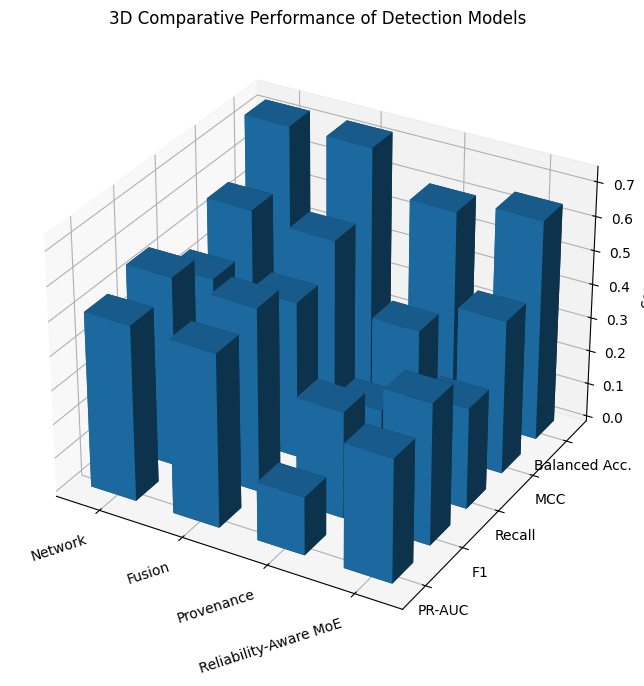

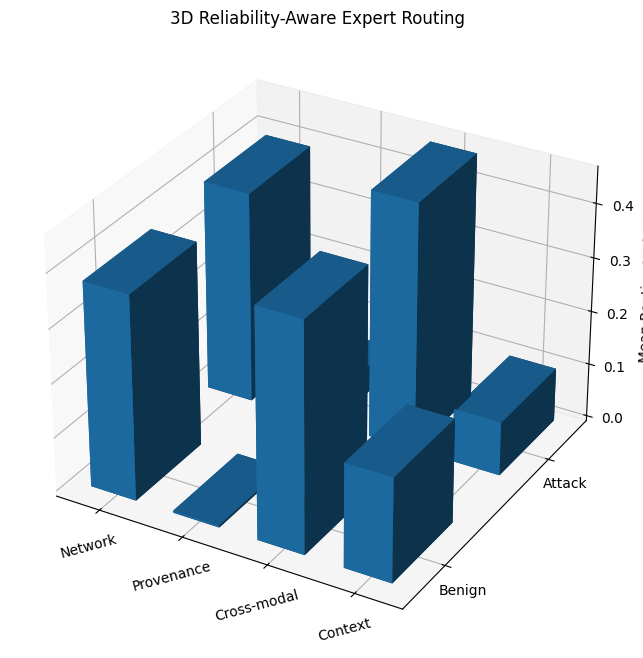

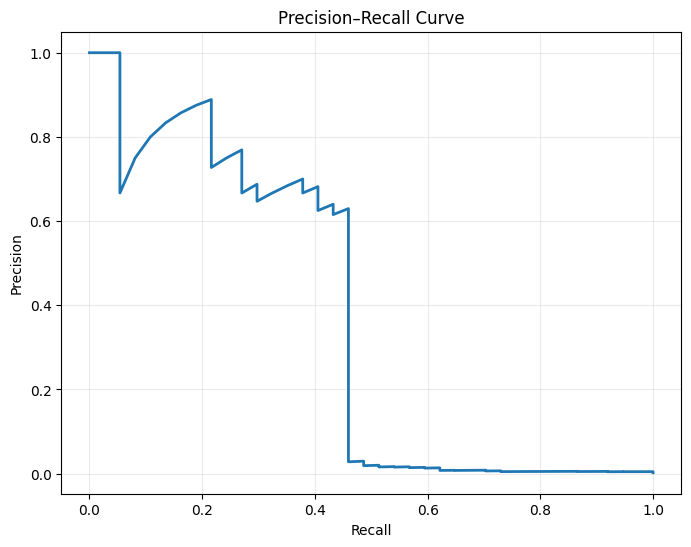

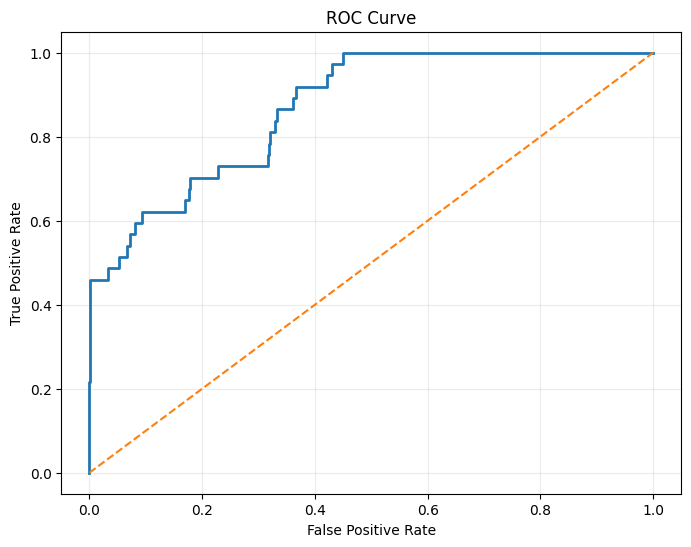

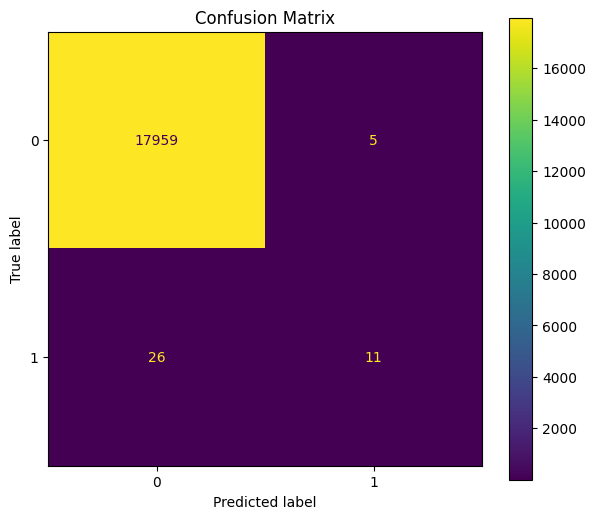

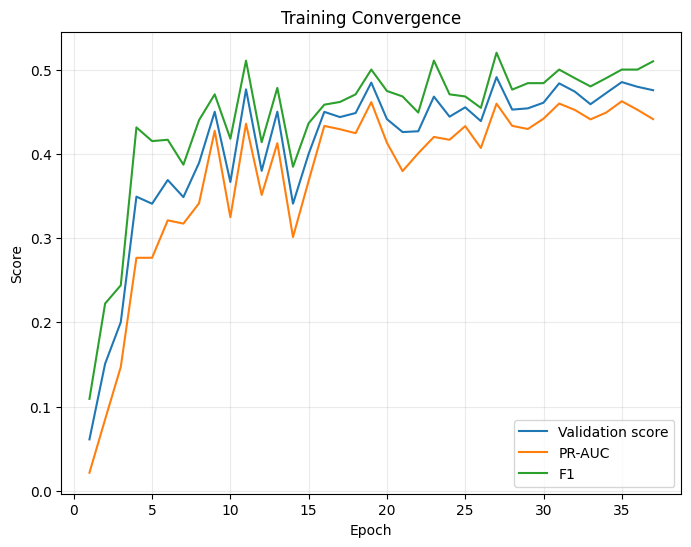

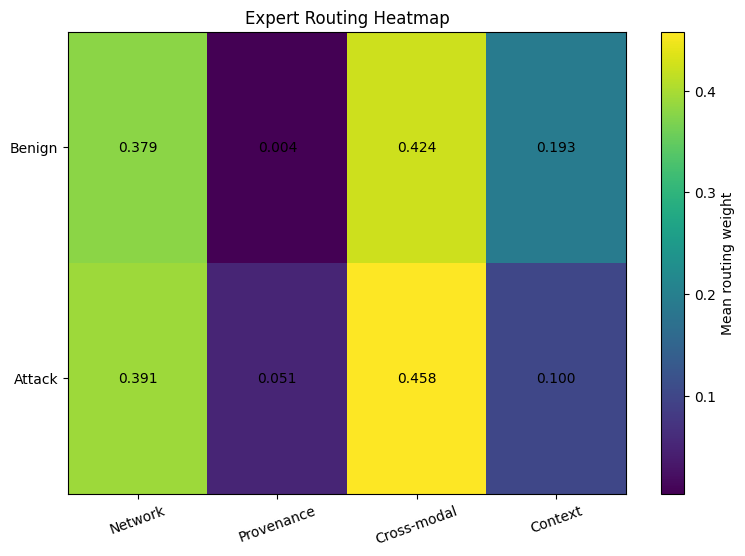


STEP 6 COMPLETE
Configuration : RMoE_B
Experts       : 4
Sparse routing: Top-2
Seeds         : 5

Representative test:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9983,0.6485,0.6875,0.2973,0.9997,0.4151,0.3623,0.8702,0.4514,0.0003,17959,5,26,11



Repeated-run statistics:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998245,0.000063,0.998166,0.998323,0.9982 ± 0.0001
1,balanced_accuracy,0.645796,0.025960,0.613562,0.678029,0.6458 ± 0.0260
2,precision,0.671112,0.042671,0.618129,0.724096,0.6711 ± 0.0427
3,recall,0.291892,0.051988,0.227341,0.356443,0.2919 ± 0.0520
4,specificity,0.999699,0.000084,0.999595,0.999804,0.9997 ± 0.0001
5,f1,0.403729,0.050161,0.341446,0.466011,0.4037 ± 0.0502
6,pr_auc,0.323543,0.023262,0.294659,0.352427,0.3235 ± 0.0233
7,roc_auc,0.871112,0.015887,0.851386,0.890839,0.8711 ± 0.0159
8,mcc,0.439805,0.037264,0.393536,0.486074,0.4398 ± 0.0373
9,fpr,0.000301,0.000084,0.000196,0.000405,0.0003 ± 0.0001



Saved models : /content/drive/MyDrive/IIoT_APT_Research/Step6_Reliability_Aware_MoE/models
Saved reports: /content/drive/MyDrive/IIoT_APT_Research/Step6_Reliability_Aware_MoE/reports
Saved figures: /content/drive/MyDrive/IIoT_APT_Research/Step6_Reliability_Aware_MoE/figures

NEXT: robustness, missing-modality and ablation experiments.


In [ ]:
# ============================================================
# STEP 6 — RELIABILITY-AWARE SPARSE MULTIMODAL MoE
# ============================================================

from google.colab import drive
import os, json, random, warnings, math, copy
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

BASE_SEED = 20260924
FINAL_SEEDS = [
    20260924,
    20260925,
    20260926,
    20260927,
    20260928
]

MAX_EPOCHS = 80
EARLY_PATIENCE = 10
SEARCH_PATIENCE = 2

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")

STEP5 = ROOT / "Step5_Baselines"
STEP6 = ROOT / "Step6_Reliability_Aware_MoE"

MODEL_DIR = STEP6 / "models"
PRED_DIR = STEP6 / "predictions"
REP_DIR = STEP6 / "reports"
FIG_DIR = STEP6 / "figures"
SEARCH_DIR = STEP6 / "search"

for p in [
    STEP6, MODEL_DIR, PRED_DIR,
    REP_DIR, FIG_DIR, SEARCH_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = (
    STEP5 /
    "features" /
    "baseline_dataset.parquet"
)

BASELINE_FILE = (
    STEP5 /
    "reports" /
    "baseline_summary.csv"
)

PREPROCESSOR_FILE = (
    STEP6 /
    "preprocessing.joblib"
)

SEARCH_SUMMARY = (
    REP_DIR /
    "moe_search_results.csv"
)

SEED_RESULTS_FILE = (
    REP_DIR /
    "moe_seed_results.csv"
)

STAT_FILE = (
    REP_DIR /
    "moe_mean_std_ci.csv"
)

COMPARISON_FILE = (
    REP_DIR /
    "baseline_vs_moe.csv"
)

ROUTING_FILE = (
    REP_DIR /
    "routing_by_class.csv"
)

FINAL_REPORT = (
    REP_DIR /
    "step6_final_report.json"
)

DONE_FILE = (
    STEP6 /
    "STEP6_COMPLETE.txt"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(DATA_FILE)

data = pd.read_parquet(DATA_FILE)

network_cols = [
    c for c in data.columns
    if c.startswith("N_")
]

provenance_cols = [
    c for c in data.columns
    if c.startswith("P_")
]

print("=" * 74)
print("STEP 6 INPUT")
print("=" * 74)

print("Rows               :", f"{len(data):,}")
print("Network features   :", len(network_cols))
print("Provenance features:", len(provenance_cols))
print(
    "Positive windows   :",
    f"{int(data['binary_label'].sum()):,}"
)

print("\nSplit:")
display(
    data.groupby("split")["binary_label"]
    .agg(["count", "sum"])
    .rename(
        columns={
            "count": "rows",
            "sum": "positive"
        }
    )
)


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def save_json(obj, path):

    tmp = Path(str(path) + ".tmp")

    with open(tmp, "w") as f:
        json.dump(
            obj,
            f,
            indent=2,
            default=str
        )

    os.replace(tmp, path)


def save_parquet(df, path):

    tmp = Path(str(path) + ".tmp")

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(tmp, path)


def save_figure(fig, name):

    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"

    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    plt.show()


def clean_frame(df, cols):

    x = (
        df[cols]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .copy()
    )

    for c in cols:
        x[c] = pd.to_numeric(
            x[c],
            errors="coerce"
        )

    return x


train_mask = (
    data["split"] == "train"
)

val_mask = (
    data["split"] == "validation"
)

test_mask = (
    data["split"] == "test"
)

N_raw = clean_frame(
    data,
    network_cols
)

P_raw = clean_frame(
    data,
    provenance_cols
)

N_available = (
    N_raw.notna().mean(axis=1)
)

P_available = (
    P_raw.notna().mean(axis=1)
)


def positive_numeric(series):

    return (
        pd.to_numeric(
            series,
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )


if "N_packet_count" in data.columns:

    n_activity_raw = positive_numeric(
        data["N_packet_count"]
    )

else:

    n_activity_raw = (
        N_raw.notna().sum(axis=1)
    )


p_activity_raw = pd.Series(
    0.0,
    index=data.index
)

for c in [
    "P_node_count",
    "P_edge_count"
]:

    if c in data.columns:

        p_activity_raw += positive_numeric(
            data[c]
        )


if p_activity_raw.max() == 0:

    p_activity_raw = (
        P_raw.notna().sum(axis=1)
    )


n_q95 = float(
    np.nanpercentile(
        n_activity_raw[
            train_mask
        ],
        95
    )
)

p_q95 = float(
    np.nanpercentile(
        p_activity_raw[
            train_mask
        ],
        95
    )
)

n_q95 = max(
    n_q95,
    1.0
)

p_q95 = max(
    p_q95,
    1.0
)

N_activity = (
    np.log1p(
        n_activity_raw
    )
    /
    np.log1p(
        n_q95
    )
).clip(
    0,
    1
)

P_activity = (
    np.log1p(
        p_activity_raw
    )
    /
    np.log1p(
        p_q95
    )
).clip(
    0,
    1
)

R_N = (
    0.70 * N_available
    +
    0.30 * N_activity
)

R_P = (
    0.70 * P_available
    +
    0.30 * P_activity
)

epoch = pd.to_numeric(
    data["_window_start"],
    errors="coerce"
).fillna(0)

seconds_day = (
    epoch % 86400
)

hour_angle = (
    2 * np.pi *
    seconds_day /
    86400
)

day_index = (
    np.floor(
        epoch / 86400
    ) % 7
)

day_angle = (
    2 * np.pi *
    day_index /
    7
)

phase2 = (
    data["_phase"]
    .astype(str)
    .str.lower()
    .eq("phase2")
    .astype(float)
)

context = np.column_stack([
    R_N,
    R_P,
    N_available,
    P_available,
    N_activity,
    P_activity,
    np.sin(hour_angle),
    np.cos(hour_angle),
    np.sin(day_angle),
    np.cos(day_angle),
    phase2
]).astype(
    np.float32
)


if PREPROCESSOR_FILE.exists():

    prep = joblib.load(
        PREPROCESSOR_FILE
    )

    n_median = prep["n_median"]
    p_median = prep["p_median"]

    scaler_n = prep["scaler_n"]
    scaler_p = prep["scaler_p"]

else:

    n_median = (
        N_raw[
            train_mask
        ]
        .median()
        .fillna(0)
    )

    p_median = (
        P_raw[
            train_mask
        ]
        .median()
        .fillna(0)
    )

    N_train_fill = (
        N_raw[
            train_mask
        ]
        .fillna(
            n_median
        )
        .fillna(0)
    )

    P_train_fill = (
        P_raw[
            train_mask
        ]
        .fillna(
            p_median
        )
        .fillna(0)
    )

    scaler_n = RobustScaler(
        quantile_range=(5, 95)
    )

    scaler_p = RobustScaler(
        quantile_range=(5, 95)
    )

    scaler_n.fit(
        N_train_fill
    )

    scaler_p.fit(
        P_train_fill
    )

    prep = {
        "network_columns":
            network_cols,

        "provenance_columns":
            provenance_cols,

        "n_median":
            n_median,

        "p_median":
            p_median,

        "scaler_n":
            scaler_n,

        "scaler_p":
            scaler_p,

        "n_activity_q95":
            n_q95,

        "p_activity_q95":
            p_q95
    }

    joblib.dump(
        prep,
        PREPROCESSOR_FILE
    )


N_all = scaler_n.transform(
    N_raw
    .fillna(n_median)
    .fillna(0)
)

P_all = scaler_p.transform(
    P_raw
    .fillna(p_median)
    .fillna(0)
)

N_all = np.clip(
    N_all,
    -10,
    10
).astype(
    np.float32
)

P_all = np.clip(
    P_all,
    -10,
    10
).astype(
    np.float32
)

y_all = (
    data[
        "binary_label"
    ]
    .astype(np.float32)
    .to_numpy()
)


def subset(mask):

    idx = np.where(
        mask.to_numpy()
    )[0]

    return (
        N_all[idx],
        P_all[idx],
        context[idx],
        y_all[idx],
        idx
    )


N_train, P_train, C_train, y_train, I_train = subset(
    train_mask
)

N_val, P_val, C_val, y_val, I_val = subset(
    val_mask
)

N_test, P_test, C_test, y_test, I_test = subset(
    test_mask
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "\nDevice:",
    device
)


class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        latent_dim,
        dropout
    ):

        super().__init__()

        hidden = max(
            latent_dim * 2,
            64
        )

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.LayerNorm(
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                latent_dim
            ),

            nn.LayerNorm(
                latent_dim
            ),

            nn.GELU()
        )

    def forward(
        self,
        x
    ):

        return self.net(x)


class Expert(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                max(
                    hidden // 2,
                    16
                )
            ),

            nn.GELU(),

            nn.Linear(
                max(
                    hidden // 2,
                    16
                ),
                1
            )
        )

    def forward(
        self,
        x
    ):

        return (
            self.net(x)
            .squeeze(1)
        )


class ReliabilityMoE(nn.Module):

    def __init__(
        self,
        n_dim,
        p_dim,
        context_dim,
        n_latent,
        p_latent,
        hidden,
        dropout,
        top_k=2,
        modality_dropout=0.08
    ):

        super().__init__()

        self.top_k = top_k
        self.modality_dropout = (
            modality_dropout
        )

        self.n_encoder = Encoder(
            n_dim,
            n_latent,
            dropout
        )

        self.p_encoder = Encoder(
            p_dim,
            p_latent,
            dropout
        )

        cross_dim = (
            n_latent +
            p_latent
        )

        router_dim = (
            cross_dim +
            context_dim
        )

        self.network_expert = Expert(
            n_latent,
            hidden,
            dropout
        )

        self.provenance_expert = Expert(
            p_latent,
            hidden,
            dropout
        )

        self.cross_expert = Expert(
            cross_dim,
            hidden,
            dropout
        )

        self.context_expert = Expert(
            router_dim,
            hidden,
            dropout
        )

        self.router = nn.Sequential(

            nn.Linear(
                router_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                4
            )
        )


    def forward(
        self,
        xn,
        xp,
        ctx,
        augment=False,
        mask_n=None,
        mask_p=None
    ):

        batch = xn.shape[0]

        if mask_n is None:

            mask_n = torch.ones(
                batch,
                1,
                device=xn.device
            )

        if mask_p is None:

            mask_p = torch.ones(
                batch,
                1,
                device=xn.device
            )

        if (
            self.training
            and augment
            and
            self.modality_dropout > 0
        ):

            r = torch.rand(
                batch,
                device=xn.device
            )

            dn = (
                r <
                self.modality_dropout
            )

            dp = (
                (
                    r >=
                    self.modality_dropout
                )
                &
                (
                    r <
                    2 *
                    self.modality_dropout
                )
            )

            mask_n = (
                mask_n *
                (~dn)
                .float()
                .unsqueeze(1)
            )

            mask_p = (
                mask_p *
                (~dp)
                .float()
                .unsqueeze(1)
            )

        xn_eff = (
            xn *
            mask_n
        )

        xp_eff = (
            xp *
            mask_p
        )

        ctx_eff = ctx.clone()

        ctx_eff[:, 0] *= (
            mask_n[:, 0]
        )

        ctx_eff[:, 2] *= (
            mask_n[:, 0]
        )

        ctx_eff[:, 4] *= (
            mask_n[:, 0]
        )

        ctx_eff[:, 1] *= (
            mask_p[:, 0]
        )

        ctx_eff[:, 3] *= (
            mask_p[:, 0]
        )

        ctx_eff[:, 5] *= (
            mask_p[:, 0]
        )

        zn = self.n_encoder(
            xn_eff
        )

        zp = self.p_encoder(
            xp_eff
        )

        cross = torch.cat(
            [
                zn,
                zp
            ],
            dim=1
        )

        router_input = torch.cat(
            [
                cross,
                ctx_eff
            ],
            dim=1
        )

        e1 = self.network_expert(
            zn
        )

        e2 = self.provenance_expert(
            zp
        )

        e3 = self.cross_expert(
            cross
        )

        e4 = self.context_expert(
            router_input
        )

        expert_logits = torch.stack(
            [
                e1,
                e2,
                e3,
                e4
            ],
            dim=1
        )

        router_logits = self.router(
            router_input
        )

        unavailable_n = (
            mask_n[:, 0] < 0.5
        )

        unavailable_p = (
            mask_p[:, 0] < 0.5
        )

        router_logits[
            unavailable_n,
            0
        ] = -1e9

        router_logits[
            unavailable_p,
            1
        ] = -1e9

        router_logits[
            unavailable_n |
            unavailable_p,
            2
        ] = -1e9

        probs = torch.softmax(
            router_logits,
            dim=1
        )

        top_values, top_idx = (
            torch.topk(
                probs,
                k=self.top_k,
                dim=1
            )
        )

        gates = torch.zeros_like(
            probs
        )

        gates.scatter_(
            1,
            top_idx,
            top_values
        )

        gates = (
            gates /
            (
                gates.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-12
            )
        )

        output = (
            gates *
            expert_logits
        ).sum(
            dim=1
        )

        return (
            output,
            gates
        )


class FocalLoss(nn.Module):

    def __init__(
        self,
        pos_weight,
        gamma=1.5
    ):

        super().__init__()

        self.gamma = gamma

        self.register_buffer(
            "pos_weight",
            torch.tensor(
                [pos_weight],
                dtype=torch.float32
            )
        )

    def forward(
        self,
        logits,
        targets
    ):

        bce = (
            F.binary_cross_entropy_with_logits(
                logits,
                targets,
                pos_weight=
                    self.pos_weight,
                reduction="none"
            )
        )

        p = torch.sigmoid(
            logits
        )

        pt = (
            p * targets
            +
            (1 - p) *
            (1 - targets)
        )

        return (
            (
                (1 - pt) **
                self.gamma
            )
            *
            bce
        ).mean()


def make_loader(
    xn,
    xp,
    ctx,
    y,
    batch_size,
    shuffle
):

    ds = TensorDataset(
        torch.tensor(
            xn,
            dtype=torch.float32
        ),
        torch.tensor(
            xp,
            dtype=torch.float32
        ),
        torch.tensor(
            ctx,
            dtype=torch.float32
        ),
        torch.tensor(
            y,
            dtype=torch.float32
        )
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(
            device.type ==
            "cuda"
        )
    )


def threshold_from_validation(
    y,
    prob
):

    if len(
        np.unique(y)
    ) < 2:

        return 0.5

    precision, recall, thresholds = (
        precision_recall_curve(
            y,
            prob
        )
    )

    if len(thresholds) == 0:
        return 0.5

    f1 = (
        2 *
        precision[:-1] *
        recall[:-1]
        /
        (
            precision[:-1]
            +
            recall[:-1]
            +
            1e-12
        )
    )

    return float(
        thresholds[
            np.nanargmax(
                f1
            )
        ]
    )


def metrics(
    y,
    prob,
    threshold
):

    pred = (
        prob >=
        threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    specificity = (
        tn /
        (tn + fp)
        if (
            tn + fp
        ) > 0
        else 0
    )

    fpr = (
        fp /
        (fp + tn)
        if (
            fp + tn
        ) > 0
        else 0
    )

    return {

        "accuracy":
            float(
                accuracy_score(
                    y,
                    pred
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y,
                    pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "specificity":
            float(
                specificity
            ),

        "f1":
            float(
                f1_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y,
                    prob
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y,
                    prob
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y,
                    pred
                )
            ),

        "fpr":
            float(
                fpr
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


@torch.no_grad()
def predict_model(
    model,
    xn,
    xp,
    ctx,
    batch_size=4096
):

    loader = make_loader(
        xn,
        xp,
        ctx,
        np.zeros(
            len(xn),
            dtype=np.float32
        ),
        batch_size,
        False
    )

    model.eval()

    probs = []
    gates = []

    for xb_n, xb_p, xb_c, _ in loader:

        xb_n = xb_n.to(
            device
        )

        xb_p = xb_p.to(
            device
        )

        xb_c = xb_c.to(
            device
        )

        logits, g = model(
            xb_n,
            xb_p,
            xb_c,
            augment=False
        )

        probs.append(
            torch.sigmoid(
                logits
            )
            .cpu()
            .numpy()
        )

        gates.append(
            g.cpu()
            .numpy()
        )

    return (
        np.concatenate(
            probs
        ),
        np.concatenate(
            gates
        )
    )


def build_model(config):

    return ReliabilityMoE(

        n_dim=len(
            network_cols
        ),

        p_dim=len(
            provenance_cols
        ),

        context_dim=context.shape[1],

        n_latent=
            config["n_latent"],

        p_latent=
            config["p_latent"],

        hidden=
            config["hidden"],

        dropout=
            config["dropout"],

        top_k=2,

        modality_dropout=
            config["modality_dropout"]

    ).to(
        device
    )


def train_model(
    config,
    seed,
    tag
):

    set_seed(seed)

    checkpoint = (
        MODEL_DIR /
        f"{tag}.pt"
    )

    result_file = (
        REP_DIR /
        f"{tag}.json"
    )

    history_file = (
        REP_DIR /
        f"{tag}_history.csv"
    )

    if (
        checkpoint.exists()
        and
        result_file.exists()
    ):

        result = json.load(
            open(result_file)
        )

        return result

    batch_size = (
        config[
            "batch_size"
        ]
    )

    train_loader = make_loader(
        N_train,
        P_train,
        C_train,
        y_train,
        batch_size,
        True
    )

    model = build_model(
        config
    )

    positive = max(
        y_train.sum(),
        1
    )

    negative = max(
        len(y_train) -
        positive,
        1
    )

    pos_weight = min(
        math.sqrt(
            negative /
            positive
        ),
        30.0
    )

    criterion = FocalLoss(
        pos_weight=
            pos_weight,
        gamma=
            config["gamma"]
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=
            config[
                "weight_decay"
            ]
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=3
        )
    )

    best_score = -np.inf
    best_state = None
    best_threshold = 0.5
    best_val_metrics = None

    stale = 0
    history = []

    for epoch_no in range(
        1,
        MAX_EPOCHS + 1
    ):

        model.train()

        epoch_losses = []

        for (
            xb_n,
            xb_p,
            xb_c,
            yb
        ) in train_loader:

            xb_n = xb_n.to(
                device
            )

            xb_p = xb_p.to(
                device
            )

            xb_c = xb_c.to(
                device
            )

            yb = yb.to(
                device
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, gates = model(
                xb_n,
                xb_p,
                xb_c,
                augment=True
            )

            classification_loss = (
                criterion(
                    logits,
                    yb
                )
            )

            usage = gates.mean(
                dim=0
            )

            balance_loss = (
                (
                    usage -
                    0.25
                ) ** 2
            ).mean()

            loss = (
                classification_loss
                +
                config[
                    "balance_weight"
                ]
                *
                balance_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )

            optimizer.step()

            epoch_losses.append(
                loss.item()
            )

        val_prob, _ = predict_model(
            model,
            N_val,
            P_val,
            C_val
        )

        threshold = (
            threshold_from_validation(
                y_val,
                val_prob
            )
        )

        val_m = metrics(
            y_val,
            val_prob,
            threshold
        )

        val_score = (
            0.55 *
            val_m["pr_auc"]
            +
            0.30 *
            val_m["f1"]
            +
            0.15 *
            max(
                val_m["mcc"],
                0
            )
        )

        scheduler.step(
            val_score
        )

        history.append({

            "epoch":
                epoch_no,

            "loss":
                float(
                    np.mean(
                        epoch_losses
                    )
                ),

            "val_score":
                float(
                    val_score
                ),

            "val_pr_auc":
                val_m[
                    "pr_auc"
                ],

            "val_f1":
                val_m[
                    "f1"
                ],

            "val_recall":
                val_m[
                    "recall"
                ],

            "val_mcc":
                val_m[
                    "mcc"
                ],

            "threshold":
                threshold
        })

        if (
            val_score >
            best_score +
            1e-5
        ):

            best_score = (
                val_score
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_threshold = (
                threshold
            )

            best_val_metrics = (
                val_m
            )

            stale = 0

        else:

            stale += 1

        if stale >= EARLY_PATIENCE:
            break

    model.load_state_dict(
        best_state
    )

    torch.save(
        {
            "state_dict":
                best_state,

            "config":
                config,

            "seed":
                seed,

            "threshold":
                best_threshold,

            "network_columns":
                network_cols,

            "provenance_columns":
                provenance_cols
        },
        checkpoint
    )

    pd.DataFrame(
        history
    ).to_csv(
        history_file,
        index=False
    )

    result = {

        "tag":
            tag,

        "seed":
            seed,

        "config":
            config,

        "best_epoch":
            int(
                pd.DataFrame(
                    history
                )[
                    "val_score"
                ]
                .idxmax()
                + 1
            ),

        "validation_score":
            float(
                best_score
            ),

        "threshold":
            float(
                best_threshold
            ),

        "validation":
            best_val_metrics
    }

    save_json(
        result,
        result_file
    )

    return result


SEARCH_CONFIGS = [

    {
        "name":
            "RMoE_A",

        "n_latent":
            64,

        "p_latent":
            32,

        "hidden":
            64,

        "dropout":
            0.10,

        "modality_dropout":
            0.08,

        "gamma":
            1.5,

        "lr":
            8e-4,

        "weight_decay":
            1e-4,

        "balance_weight":
            0.02,

        "batch_size":
            2048
    },

    {
        "name":
            "RMoE_B",

        "n_latent":
            96,

        "p_latent":
            48,

        "hidden":
            96,

        "dropout":
            0.15,

        "modality_dropout":
            0.10,

        "gamma":
            1.5,

        "lr":
            5e-4,

        "weight_decay":
            2e-4,

        "balance_weight":
            0.02,

        "batch_size":
            2048
    },

    {
        "name":
            "RMoE_C",

        "n_latent":
            128,

        "p_latent":
            64,

        "hidden":
            128,

        "dropout":
            0.20,

        "modality_dropout":
            0.10,

        "gamma":
            1.25,

        "lr":
            4e-4,

        "weight_decay":
            2e-4,

        "balance_weight":
            0.015,

        "batch_size":
            2048
    },

    {
        "name":
            "RMoE_D",

        "n_latent":
            96,

        "p_latent":
            64,

        "hidden":
            128,

        "dropout":
            0.12,

        "modality_dropout":
            0.12,

        "gamma":
            2.0,

        "lr":
            3e-4,

        "weight_decay":
            1e-4,

        "balance_weight":
            0.01,

        "batch_size":
            2048
    },

    {
        "name":
            "RMoE_E",

        "n_latent":
            128,

        "p_latent":
            64,

        "hidden":
            160,

        "dropout":
            0.18,

        "modality_dropout":
            0.12,

        "gamma":
            1.5,

        "lr":
            2e-4,

        "weight_decay":
            3e-4,

        "balance_weight":
            0.015,

        "batch_size":
            2048
    }
]


print("\n" + "=" * 74)
print("ADAPTIVE VALIDATION SEARCH")
print("=" * 74)

search_results = []

best_seen = -np.inf
stale_configs = 0

for i, cfg in enumerate(
    SEARCH_CONFIGS,
    start=1
):

    tag = (
        "search_" +
        cfg["name"]
    )

    result = train_model(
        cfg,
        BASE_SEED,
        tag
    )

    search_results.append(
        {
            "configuration":
                cfg["name"],

            "validation_score":
                result[
                    "validation_score"
                ],

            "pr_auc":
                result[
                    "validation"
                ][
                    "pr_auc"
                ],

            "f1":
                result[
                    "validation"
                ][
                    "f1"
                ],

            "recall":
                result[
                    "validation"
                ][
                    "recall"
                ],

            "mcc":
                result[
                    "validation"
                ][
                    "mcc"
                ],

            "threshold":
                result[
                    "threshold"
                ],

            "best_epoch":
                result[
                    "best_epoch"
                ]
        }
    )

    score = (
        result[
            "validation_score"
        ]
    )

    print(
        f"{cfg['name']} | "
        f"Score={score:.4f} | "
        f"PR-AUC="
        f"{result['validation']['pr_auc']:.4f} | "
        f"F1="
        f"{result['validation']['f1']:.4f} | "
        f"Recall="
        f"{result['validation']['recall']:.4f}"
    )

    if (
        score >
        best_seen +
        0.002
    ):

        best_seen = score
        stale_configs = 0

    else:

        stale_configs += 1

    if (
        i >= 3
        and
        stale_configs >=
        SEARCH_PATIENCE
    ):
        break


search_df = (
    pd.DataFrame(
        search_results
    )
    .sort_values(
        "validation_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

search_df.to_csv(
    SEARCH_SUMMARY,
    index=False
)

print("\nSearch summary:")
display(
    search_df.round(4)
)

best_name = (
    search_df.iloc[0][
        "configuration"
    ]
)

best_config = next(
    x
    for x in SEARCH_CONFIGS
    if x["name"] ==
    best_name
)

print(
    "\nSelected configuration:",
    best_name
)


print("\n" + "=" * 74)
print("REPEATED-SEED VALIDATION")
print("=" * 74)

seed_rows = []

representative = None

for seed in FINAL_SEEDS:

    tag = (
        f"final_{best_name}_"
        f"seed{seed}"
    )

    result = train_model(
        best_config,
        seed,
        tag
    )

    checkpoint = torch.load(
        MODEL_DIR /
        f"{tag}.pt",
        map_location=device,
        weights_only=False
    )

    model = build_model(
        checkpoint[
            "config"
        ]
    )

    model.load_state_dict(
        checkpoint[
            "state_dict"
        ]
    )

    threshold = float(
        checkpoint[
            "threshold"
        ]
    )

    test_prob, test_gates = (
        predict_model(
            model,
            N_test,
            P_test,
            C_test
        )
    )

    test_m = metrics(
        y_test,
        test_prob,
        threshold
    )

    row = {
        "seed":
            seed,

        "threshold":
            threshold,

        **{
            k: v
            for k, v
            in test_m.items()
            if k not in [
                "tn", "fp",
                "fn", "tp"
            ]
        },

        "tn":
            test_m["tn"],

        "fp":
            test_m["fp"],

        "fn":
            test_m["fn"],

        "tp":
            test_m["tp"]
    }

    seed_rows.append(
        row
    )

    pred = pd.DataFrame({

        "_window_id":
            data.iloc[
                I_test
            ][
                "_window_id"
            ].to_numpy(),

        "y_true":
            y_test.astype(int),

        "probability":
            test_prob,

        "prediction":
            (
                test_prob >=
                threshold
            ).astype(int),

        "gate_network":
            test_gates[:, 0],

        "gate_provenance":
            test_gates[:, 1],

        "gate_cross_modal":
            test_gates[:, 2],

        "gate_context":
            test_gates[:, 3]
    })

    save_parquet(
        pred,
        PRED_DIR /
        f"{tag}.parquet"
    )

    if seed == FINAL_SEEDS[0]:

        representative = {
            "seed":
                seed,

            "model":
                model,

            "threshold":
                threshold,

            "prob":
                test_prob,

            "gates":
                test_gates,

            "metrics":
                test_m,

            "tag":
                tag
        }

    print(
        f"Seed {seed} | "
        f"PR-AUC={test_m['pr_auc']:.4f} | "
        f"F1={test_m['f1']:.4f} | "
        f"Recall={test_m['recall']:.4f} | "
        f"MCC={test_m['mcc']:.4f}"
    )


seed_df = pd.DataFrame(
    seed_rows
)

seed_df.to_csv(
    SEED_RESULTS_FILE,
    index=False
)

print("\nRepeated-seed test results:")
display(
    seed_df.round(4)
)


stat_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "pr_auc",
    "roc_auc",
    "mcc",
    "fpr"
]

stats = []

n_runs = len(
    seed_df
)

tcrit = 2.776445

for metric in stat_metrics:

    vals = (
        seed_df[
            metric
        ]
        .astype(float)
        .to_numpy()
    )

    mean = float(
        vals.mean()
    )

    sd = float(
        vals.std(
            ddof=1
        )
        if len(vals) > 1
        else 0
    )

    margin = (
        tcrit *
        sd /
        np.sqrt(
            max(
                len(vals),
                1
            )
        )
    )

    stats.append({

        "metric":
            metric,

        "mean":
            mean,

        "std":
            sd,

        "ci95_low":
            mean -
            margin,

        "ci95_high":
            mean +
            margin,

        "paper_value":
            f"{mean:.4f} ± {sd:.4f}"
    })


stats_df = pd.DataFrame(
    stats
)

stats_df.to_csv(
    STAT_FILE,
    index=False
)

print("\nMean ± SD and 95% CI:")
display(
    stats_df
)


rep = representative

routing_df = pd.DataFrame({

    "class": [
        "Benign",
        "Attack"
    ],

    "Network Expert": [
        rep["gates"][
            y_test == 0,
            0
        ].mean(),

        rep["gates"][
            y_test == 1,
            0
        ].mean()
    ],

    "Provenance Expert": [
        rep["gates"][
            y_test == 0,
            1
        ].mean(),

        rep["gates"][
            y_test == 1,
            1
        ].mean()
    ],

    "Cross-modal Expert": [
        rep["gates"][
            y_test == 0,
            2
        ].mean(),

        rep["gates"][
            y_test == 1,
            2
        ].mean()
    ],

    "Context Expert": [
        rep["gates"][
            y_test == 0,
            3
        ].mean(),

        rep["gates"][
            y_test == 1,
            3
        ].mean()
    ]
})

routing_df.to_csv(
    ROUTING_FILE,
    index=False
)

print("\nExpert routing:")
display(
    routing_df.round(4)
)


baseline = pd.read_csv(
    BASELINE_FILE
)

primary_m = (
    representative[
        "metrics"
    ]
)

moe_row = pd.DataFrame([{

    "modality":
        "Reliability-Aware MoE",

    "best_model":
        best_name,

    "features":
        (
            len(network_cols)
            +
            len(provenance_cols)
        ),

    "threshold":
        representative[
            "threshold"
        ],

    "accuracy":
        primary_m[
            "accuracy"
        ],

    "balanced_accuracy":
        primary_m[
            "balanced_accuracy"
        ],

    "precision":
        primary_m[
            "precision"
        ],

    "recall":
        primary_m[
            "recall"
        ],

    "f1":
        primary_m[
            "f1"
        ],

    "pr_auc":
        primary_m[
            "pr_auc"
        ],

    "roc_auc":
        primary_m[
            "roc_auc"
        ],

    "mcc":
        primary_m[
            "mcc"
        ],

    "fpr":
        primary_m[
            "fpr"
        ]
}])

comparison = pd.concat(
    [
        baseline,
        moe_row
    ],
    ignore_index=True
)

comparison.to_csv(
    COMPARISON_FILE,
    index=False
)

print("\nBaseline vs proposed model:")
display(
    comparison[
        [
            "modality",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "mcc",
            "fpr"
        ]
    ].round(4)
)


fig = plt.figure(
    figsize=(12, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

plot_metrics = [
    "pr_auc",
    "f1",
    "recall",
    "mcc",
    "balanced_accuracy"
]

models = (
    comparison[
        "modality"
    ]
    .astype(str)
    .tolist()
)

xpos = np.repeat(
    np.arange(
        len(models)
    ),
    len(plot_metrics)
)

ypos = np.tile(
    np.arange(
        len(plot_metrics)
    ),
    len(models)
)

zpos = np.zeros_like(
    xpos,
    dtype=float
)

dx = np.full_like(
    xpos,
    0.55,
    dtype=float
)

dy = np.full_like(
    ypos,
    0.55,
    dtype=float
)

dz = (
    comparison[
        plot_metrics
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(models)
    )
    +
    0.27
)

ax.set_xticklabels(
    models,
    rotation=18,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(plot_metrics)
    )
    +
    0.27
)

ax.set_yticklabels(
    [
        "PR-AUC",
        "F1",
        "Recall",
        "MCC",
        "Balanced Acc."
    ]
)

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Comparative Performance of Detection Models"
)

save_figure(
    fig,
    "Fig_6A_3D_Model_Performance"
)


experts = [
    "Network",
    "Provenance",
    "Cross-modal",
    "Context"
]

routing_values = routing_df[
    [
        "Network Expert",
        "Provenance Expert",
        "Cross-modal Expert",
        "Context Expert"
    ]
].to_numpy()

fig = plt.figure(
    figsize=(10, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

xpos = np.tile(
    np.arange(4),
    2
)

ypos = np.repeat(
    np.arange(2),
    4
)

zpos = np.zeros(
    8
)

dx = np.full(
    8,
    0.55
)

dy = np.full(
    8,
    0.55
)

dz = routing_values.reshape(
    -1
)

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(4) +
    0.27
)

ax.set_xticklabels(
    experts,
    rotation=15
)

ax.set_yticks(
    [
        0.27,
        1.27
    ]
)

ax.set_yticklabels(
    [
        "Benign",
        "Attack"
    ]
)

ax.set_zlabel(
    "Mean Routing Weight"
)

ax.set_title(
    "3D Reliability-Aware Expert Routing"
)

save_figure(
    fig,
    "Fig_6B_3D_Expert_Routing"
)


precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        representative[
            "prob"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_title(
    "Precision–Recall Curve"
)

ax.grid(
    alpha=0.25
)

save_figure(
    fig,
    "Fig_6C_PR_Curve"
)


fpr_curve, tpr_curve, _ = (
    roc_curve(
        y_test,
        representative[
            "prob"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    fpr_curve,
    tpr_curve,
    linewidth=2
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "ROC Curve"
)

ax.grid(
    alpha=0.25
)

save_figure(
    fig,
    "Fig_6D_ROC_Curve"
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test.astype(int),
    (
        representative[
            "prob"
        ]
        >=
        representative[
            "threshold"
        ]
    ).astype(int),
    labels=[0, 1],
    normalize=None,
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Confusion Matrix"
)

save_figure(
    fig,
    "Fig_6E_Confusion_Matrix"
)


history = pd.read_csv(
    REP_DIR /
    (
        f"final_{best_name}_"
        f"seed{FINAL_SEEDS[0]}"
        "_history.csv"
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    history[
        "epoch"
    ],
    history[
        "val_score"
    ],
    label="Validation score"
)

ax.plot(
    history[
        "epoch"
    ],
    history[
        "val_pr_auc"
    ],
    label="PR-AUC"
)

ax.plot(
    history[
        "epoch"
    ],
    history[
        "val_f1"
    ],
    label="F1"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Training Convergence"
)

ax.legend()

ax.grid(
    alpha=0.25
)

save_figure(
    fig,
    "Fig_6F_Training_Convergence"
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

routing_matrix = routing_values

im = ax.imshow(
    routing_matrix,
    aspect="auto"
)

ax.set_xticks(
    range(4)
)

ax.set_xticklabels(
    experts,
    rotation=20
)

ax.set_yticks(
    range(2)
)

ax.set_yticklabels(
    [
        "Benign",
        "Attack"
    ]
)

for i in range(
    routing_matrix.shape[0]
):

    for j in range(
        routing_matrix.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{routing_matrix[i,j]:.3f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Mean routing weight"
)

ax.set_title(
    "Expert Routing Heatmap"
)

save_figure(
    fig,
    "Fig_6G_Routing_Heatmap"
)


final_report = {

    "model":
        "Reliability-Aware Sparse Multimodal Mixture-of-Experts",

    "selected_configuration":
        best_name,

    "top_k":
        2,

    "experts": [
        "Network",
        "Provenance",
        "Cross-modal",
        "Context"
    ],

    "network_features":
        len(network_cols),

    "provenance_features":
        len(provenance_cols),

    "context_features":
        int(
            context.shape[1]
        ),

    "seeds":
        FINAL_SEEDS,

    "representative_seed":
        FINAL_SEEDS[0],

    "representative_test":
        primary_m,

    "mean_std":
        stats,

    "saved_model_directory":
        str(
            MODEL_DIR
        ),

    "saved_figure_directory":
        str(
            FIG_DIR
        ),

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    FINAL_REPORT
)

DONE_FILE.write_text(
    "STEP 6 COMPLETE\n"
    f"Configuration: {best_name}\n"
    f"Seeds: {FINAL_SEEDS}\n"
)

print("\n" + "=" * 74)
print("STEP 6 COMPLETE")
print("=" * 74)

print(
    "Configuration :",
    best_name
)

print(
    "Experts       : 4"
)

print(
    "Sparse routing: Top-2"
)

print(
    "Seeds         :",
    len(
        FINAL_SEEDS
    )
)

print(
    "\nRepresentative test:"
)

display(
    pd.DataFrame(
        [
            primary_m
        ]
    ).round(4)
)

print(
    "\nRepeated-run statistics:"
)

display(
    stats_df
)

print(
    "\nSaved models :",
    MODEL_DIR
)

print(
    "Saved reports:",
    REP_DIR
)

print(
    "Saved figures:",
    FIG_DIR
)

print(
    "\nNEXT: robustness, missing-modality and ablation experiments."
)

STEP 7 INPUT
Rows: 119,896
Train / Val / Test: 83923 17972 18001
Positive: 229
Network features: 93
Provenance features: 11

Building leakage-safe OOF experts...
Fold 1/5 saved
Fold 2/5 saved
Fold 3/5 saved
Fold 4/5 saved
Fold 5/5 saved

Expert performance:


,expert,threshold,validation_score,val_pr_auc,val_f1,test_pr_auc,test_f1,test_recall,test_mcc
0,Fusion,0.1861,0.6070,0.5939,0.6154,0.5123,0.5263,0.4054,0.5508
1,Network,0.1998,0.5575,0.5554,0.5556,0.5040,0.5263,0.4054,0.5508
2,Provenance,0.9441,0.1883,0.1164,0.2500,0.1607,0.3137,0.2162,0.3507
3,Temporal,0.0659,0.0513,0.0225,0.0719,0.0151,0.0476,0.2162,0.0709



Validation-selected prior: Fusion
Router device: cpu

ROUTER SEARCH
Router_A | Score=0.3824 | PR-AUC=0.3404 | F1=0.4333
Router_B | Score=0.4476 | PR-AUC=0.3963 | F1=0.5000
Router_C | Score=0.6041 | PR-AUC=0.5994 | F1=0.6038
Router_D | Score=0.4395 | PR-AUC=0.3902 | F1=0.5000


,configuration,validation_score,pr_auc,f1,recall,mcc
0,Router_C,0.6041,0.5994,0.6038,0.4848,0.6223
1,Router_B,0.4476,0.3963,0.5000,0.7576,0.5305
2,Router_D,0.4395,0.3902,0.5000,0.4848,0.4994
3,Router_A,0.3824,0.3404,0.4333,0.3939,0.4346


Selected router: Router_C

ABLATION RESULTS


,method,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Sparse_Reliability,0.9984,0.7025,0.7143,0.4054,0.5172,0.5280,0.9509,0.5374,0.0003
1,Full Hybrid R-MoE,0.9985,0.7026,0.7500,0.4054,0.5263,0.5243,0.9504,0.5508,0.0003
2,Fusion Expert,0.9985,0.7026,0.7500,0.4054,0.5263,0.5123,0.9510,0.5508,0.0003
3,Network Expert,0.9985,0.7026,0.7500,0.4054,0.5263,0.5040,0.9379,0.5508,0.0003
4,Dense_Reliability,0.9983,0.6485,0.7333,0.2973,0.4231,0.4350,0.9587,0.4663,0.0002
5,Sparse_NoReliability,0.9973,0.7020,0.3659,0.4054,0.3846,0.3504,0.9509,0.3838,0.0014
6,Fixed Average,0.9981,0.6619,0.5714,0.3243,0.4138,0.3106,0.8775,0.4296,0.0005
7,Provenance Expert,0.9981,0.6079,0.5714,0.2162,0.3137,0.1607,0.6453,0.3507,0.0003
8,Temporal Expert,0.9822,0.6000,0.0268,0.2162,0.0476,0.0151,0.7823,0.0709,0.0162



Prior: Fusion
Router contribution alpha: 0.4

REPEATED ROUTER SEEDS
Seed 20260924 | PR-AUC=0.5243 | F1=0.5263 | Recall=0.4054 | MCC=0.5508
Seed 20260925 | PR-AUC=0.5148 | F1=0.5246 | Recall=0.4324 | MCC=0.5362
Seed 20260926 | PR-AUC=0.5142 | F1=0.5263 | Recall=0.4054 | MCC=0.5508
Seed 20260927 | PR-AUC=0.5143 | F1=0.5161 | Recall=0.4324 | MCC=0.5253
Seed 20260928 | PR-AUC=0.5165 | F1=0.5246 | Recall=0.4324 | MCC=0.5362


,seed,alpha,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,20260924,0.4,0.1811,0.9985,0.7026,0.7500,0.4054,0.9997,0.5263,0.5243,0.9504,0.5508,0.0003,17959,5,22,15
1,20260925,0.2,0.2106,0.9984,0.7160,0.6667,0.4324,0.9996,0.5246,0.5148,0.9529,0.5362,0.0004,17956,8,21,16
2,20260926,0.2,0.1871,0.9985,0.7026,0.7500,0.4054,0.9997,0.5263,0.5142,0.9502,0.5508,0.0003,17959,5,22,15
3,20260927,0.2,0.2096,0.9983,0.7160,0.6400,0.4324,0.9995,0.5161,0.5143,0.9520,0.5253,0.0005,17955,9,21,16
4,20260928,0.2,0.2108,0.9984,0.7160,0.6667,0.4324,0.9996,0.5246,0.5165,0.9520,0.5362,0.0004,17956,8,21,16



Mean ± SD and 95% CI:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998422,0.000075,0.998330,0.998515,0.9984 ± 0.0001
1,balanced_accuracy,0.710616,0.007351,0.701489,0.719743,0.7106 ± 0.0074
2,precision,0.694667,0.051672,0.630507,0.758826,0.6947 ± 0.0517
3,recall,0.421622,0.014803,0.403241,0.440002,0.4216 ± 0.0148
4,specificity,0.999610,0.000104,0.999481,0.999740,0.9996 ± 0.0001
5,f1,0.523588,0.004258,0.518301,0.528875,0.5236 ± 0.0043
6,pr_auc,0.516799,0.004305,0.511454,0.522144,0.5168 ± 0.0043
7,roc_auc,0.951504,0.001158,0.950066,0.952941,0.9515 ± 0.0012
8,mcc,0.539838,0.010926,0.526272,0.553404,0.5398 ± 0.0109
9,fpr,0.000390,0.000104,0.000260,0.000519,0.0004 ± 0.0001



ROBUSTNESS RESULTS


,scenario,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Clean,0.9985,0.7026,0.7500,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003
1,Network Drop 10%,0.9984,0.6890,0.7000,0.3784,0.4912,0.4548,0.9457,0.5140,0.0003
2,Network Drop 25%,0.9981,0.6349,0.5556,0.2703,0.3636,0.3229,0.9143,0.3866,0.0004
3,Network Drop 50%,0.9981,0.5675,0.6250,0.1351,0.2222,0.1646,0.8709,0.2900,0.0002
4,Provenance Drop 10%,0.9985,0.7026,0.7500,0.4054,0.5263,0.5320,0.9507,0.5508,0.0003
5,Provenance Drop 25%,0.9985,0.7026,0.7500,0.4054,0.5263,0.5130,0.9475,0.5508,0.0003
6,Provenance Drop 50%,0.9985,0.6891,0.7778,0.3784,0.5091,0.5137,0.9497,0.5419,0.0002
7,Both Drop 25%,0.9984,0.6755,0.7222,0.3514,0.4727,0.3936,0.9392,0.5031,0.0003
8,Network Missing,0.4293,0.6062,0.0028,0.7838,0.0056,0.0211,0.7474,0.0194,0.5714
9,Provenance Missing,0.9956,0.6337,0.1587,0.2703,0.2000,0.1025,0.9457,0.2050,0.0030


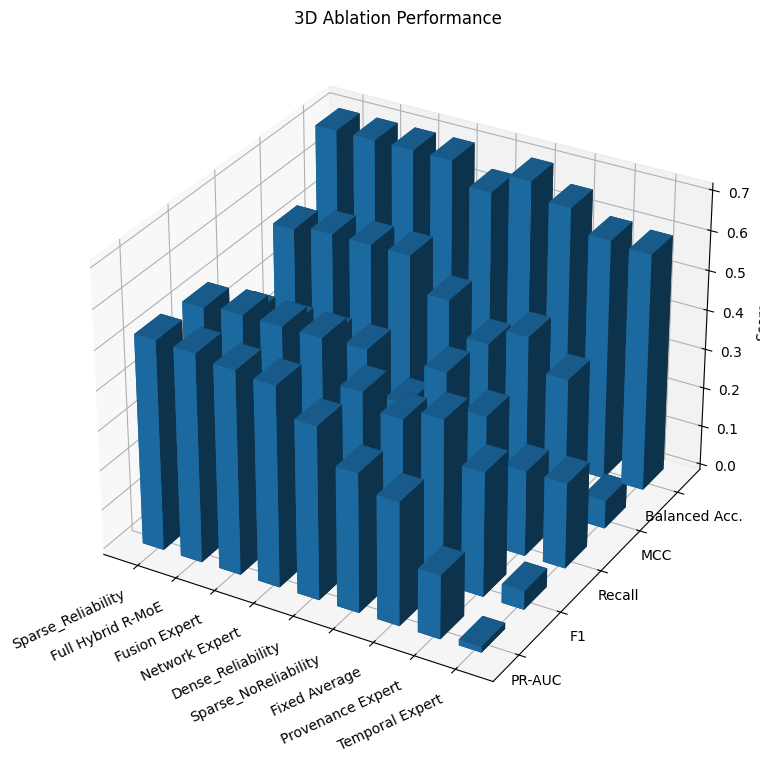

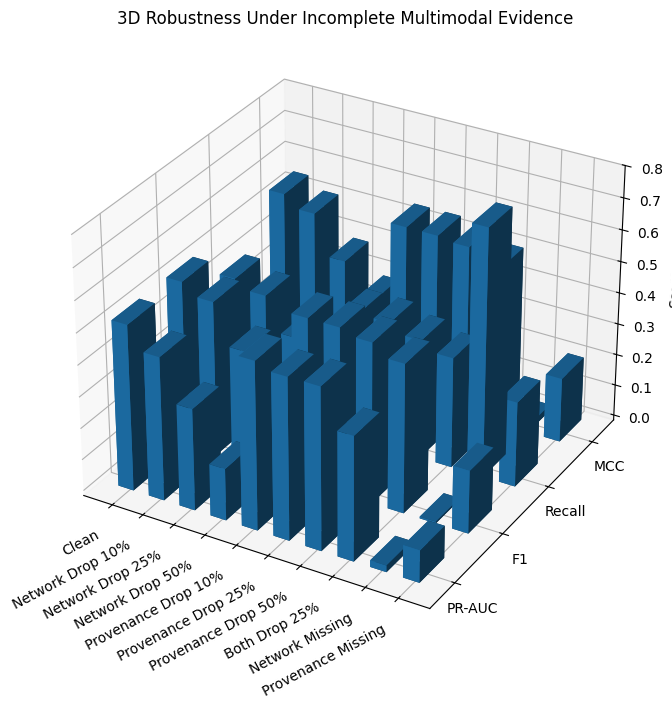

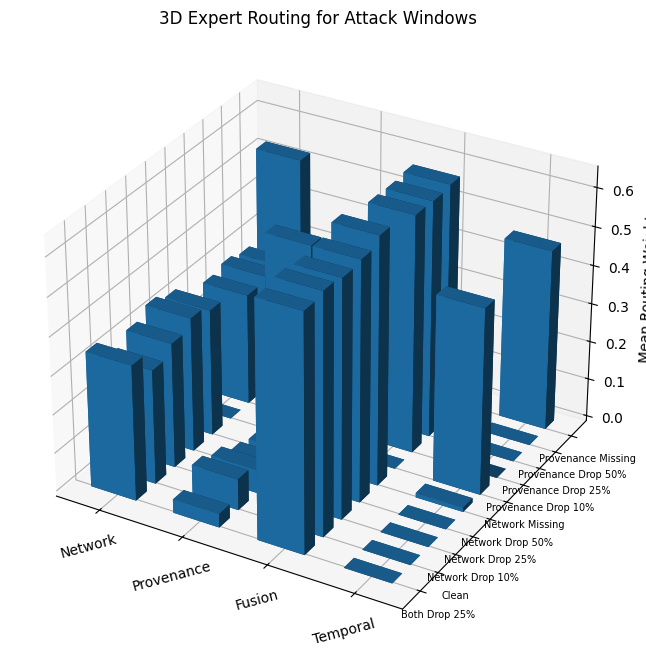

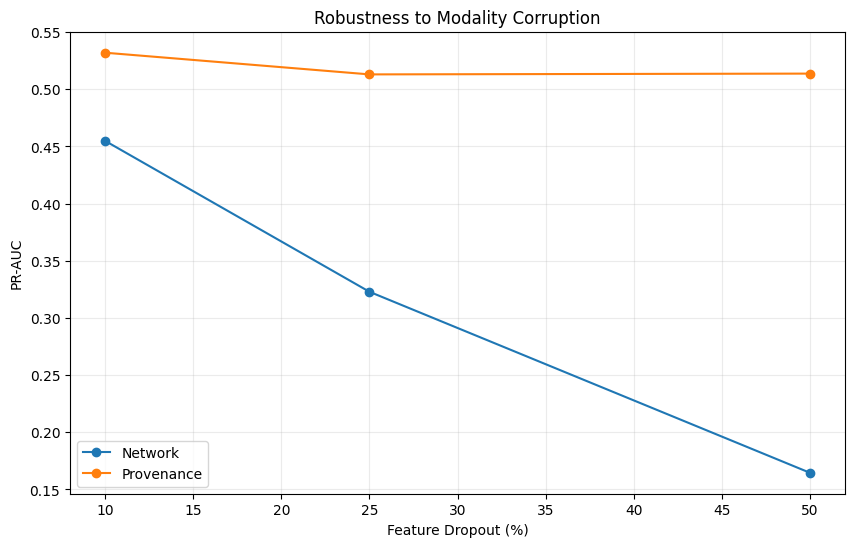

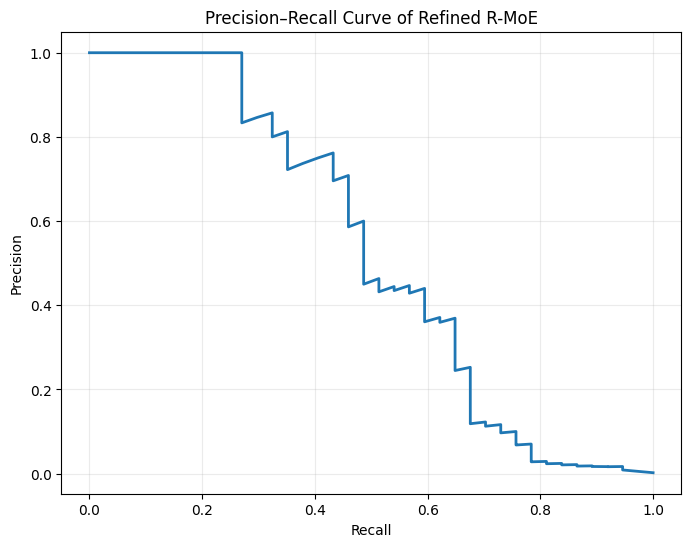

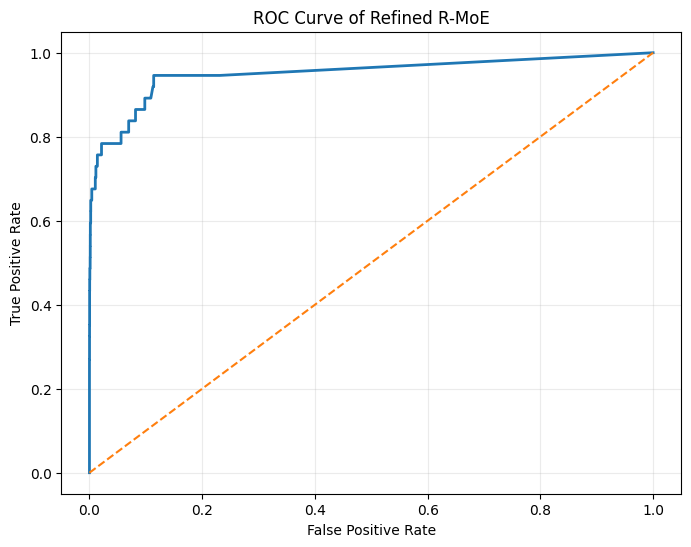

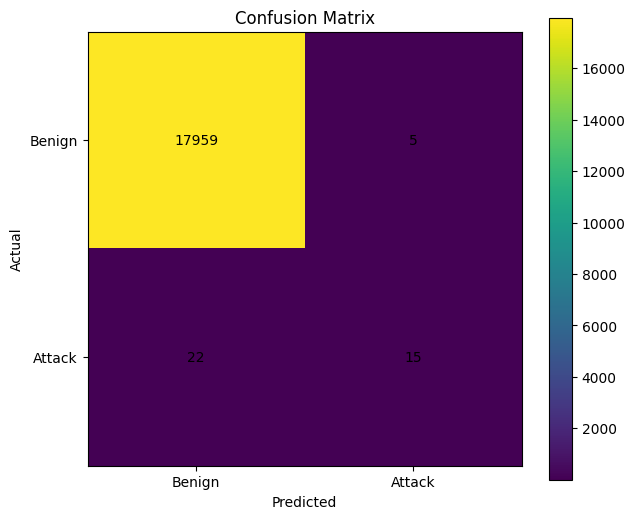


Overall comparison:


,Model,PR-AUC,F1,Recall,MCC
0,Network,0.5153,0.5574,0.4595,0.5698
1,Fusion,0.5081,0.5397,0.4595,0.5473
2,Provenance,0.1708,0.3137,0.2162,0.3507
3,Step6 Neural R-MoE,0.3623,0.4151,0.2973,0.4514
4,Refined Hybrid R-MoE,0.5243,0.5263,0.4054,0.5508



STEP 7 COMPLETE
Selected router: Router_C
Prior expert: Fusion
Router alpha: 0.4

Final representative result:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9985,0.7026,0.75,0.4054,0.9997,0.5263,0.5243,0.9504,0.5508,0.0003,17959,5,22,15



Ablation:


,method,pr_auc,f1,recall,mcc,balanced_accuracy,fpr
0,Sparse_Reliability,0.5280,0.5172,0.4054,0.5374,0.7025,0.0003
1,Full Hybrid R-MoE,0.5243,0.5263,0.4054,0.5508,0.7026,0.0003
2,Fusion Expert,0.5123,0.5263,0.4054,0.5508,0.7026,0.0003
3,Network Expert,0.5040,0.5263,0.4054,0.5508,0.7026,0.0003
4,Dense_Reliability,0.4350,0.4231,0.2973,0.4663,0.6485,0.0002
5,Sparse_NoReliability,0.3504,0.3846,0.4054,0.3838,0.7020,0.0014
6,Fixed Average,0.3106,0.4138,0.3243,0.4296,0.6619,0.0005
7,Provenance Expert,0.1607,0.3137,0.2162,0.3507,0.6079,0.0003
8,Temporal Expert,0.0151,0.0476,0.2162,0.0709,0.6000,0.0162



Robustness:


,scenario,pr_auc,f1,recall,mcc,fpr
0,Clean,0.5259,0.5263,0.4054,0.5508,0.0003
1,Network Drop 10%,0.4548,0.4912,0.3784,0.5140,0.0003
2,Network Drop 25%,0.3229,0.3636,0.2703,0.3866,0.0004
3,Network Drop 50%,0.1646,0.2222,0.1351,0.2900,0.0002
4,Provenance Drop 10%,0.5320,0.5263,0.4054,0.5508,0.0003
5,Provenance Drop 25%,0.5130,0.5263,0.4054,0.5508,0.0003
6,Provenance Drop 50%,0.5137,0.5091,0.3784,0.5419,0.0002
7,Both Drop 25%,0.3936,0.4727,0.3514,0.5031,0.0003
8,Network Missing,0.0211,0.0056,0.7838,0.0194,0.5714
9,Provenance Missing,0.1025,0.2000,0.2703,0.2050,0.0030



Statistical summary:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998422,0.000075,0.998330,0.998515,0.9984 ± 0.0001
1,balanced_accuracy,0.710616,0.007351,0.701489,0.719743,0.7106 ± 0.0074
2,precision,0.694667,0.051672,0.630507,0.758826,0.6947 ± 0.0517
3,recall,0.421622,0.014803,0.403241,0.440002,0.4216 ± 0.0148
4,specificity,0.999610,0.000104,0.999481,0.999740,0.9996 ± 0.0001
5,f1,0.523588,0.004258,0.518301,0.528875,0.5236 ± 0.0043
6,pr_auc,0.516799,0.004305,0.511454,0.522144,0.5168 ± 0.0043
7,roc_auc,0.951504,0.001158,0.950066,0.952941,0.9515 ± 0.0012
8,mcc,0.539838,0.010926,0.526272,0.553404,0.5398 ± 0.0109
9,fpr,0.000390,0.000104,0.000260,0.000519,0.0004 ± 0.0001



Reports: /content/drive/MyDrive/IIoT_APT_Research/Step7_Refined_RMoE/reports
Figures: /content/drive/MyDrive/IIoT_APT_Research/Step7_Refined_RMoE/figures
Models: /content/drive/MyDrive/IIoT_APT_Research/Step7_Refined_RMoE/models

NEXT: tactic-level classification + statistical significance + final paper tables.


In [ ]:
# ============================================================
# STEP 7 — REFINED R-MoE + ABLATION + ROBUSTNESS
# ============================================================

from google.colab import drive
import os, json, math, random, warnings, copy
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler
)

warnings.filterwarnings("ignore")

VERSION = "7.1"
SEED = 20260924
ROUTER_SEEDS = [
    20260924,
    20260925,
    20260926,
    20260927,
    20260928
]

N_FOLDS = 5
MAX_EPOCHS = 80
EARLY_PATIENCE = 10
TOP_K = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/IIoT_APT_Research"
)

STEP5 = ROOT / "Step5_Baselines"
STEP6 = ROOT / "Step6_Reliability_Aware_MoE"
STEP7 = ROOT / "Step7_Refined_RMoE"

MODEL_DIR = STEP7 / "models"
OOF_DIR = STEP7 / "oof"
REP_DIR = STEP7 / "reports"
FIG_DIR = STEP7 / "figures"
PRED_DIR = STEP7 / "predictions"

for p in [
    STEP7,
    MODEL_DIR,
    OOF_DIR,
    REP_DIR,
    FIG_DIR,
    PRED_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )

DATA_FILE = (
    STEP5 /
    "features" /
    "baseline_dataset.parquet"
)

BASELINE_FILE = (
    STEP5 /
    "reports" /
    "baseline_summary.csv"
)

STEP6_REPORT = (
    STEP6 /
    "reports" /
    "step6_final_report.json"
)

OOF_FILE = (
    OOF_DIR /
    "expert_oof_predictions.npz"
)

OOF_STATE = (
    OOF_DIR /
    "oof_state.json"
)

EXPERT_INFO_FILE = (
    REP_DIR /
    "expert_validation_results.csv"
)

SEARCH_FILE = (
    REP_DIR /
    "router_search.csv"
)

ABLATION_FILE = (
    REP_DIR /
    "ablation_results.csv"
)

SEED_FILE = (
    REP_DIR /
    "final_seed_results.csv"
)

STAT_FILE = (
    REP_DIR /
    "final_mean_std_ci.csv"
)

ROBUST_FILE = (
    REP_DIR /
    "robustness_results.csv"
)

ROUTING_FILE = (
    REP_DIR /
    "routing_analysis.csv"
)

FINAL_REPORT = (
    REP_DIR /
    "step7_final_report.json"
)

DONE_FILE = (
    STEP7 /
    "STEP7_COMPLETE.txt"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(DATA_FILE)


def save_json(x, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    with open(
        tmp,
        "w"
    ) as f:

        json.dump(
            x,
            f,
            indent=2,
            default=str
        )

    os.replace(
        tmp,
        path
    )


def save_parquet(df, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(
        tmp,
        path
    )


def save_figure(fig, name):

    fig.savefig(
        FIG_DIR /
        f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG_DIR /
        f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


def metric_set(
    y,
    prob,
    threshold
):

    pred = (
        prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    spec = (
        tn / (tn + fp)
        if tn + fp > 0
        else 0
    )

    return {

        "accuracy":
            float(
                accuracy_score(
                    y,
                    pred
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y,
                    pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "specificity":
            float(spec),

        "f1":
            float(
                f1_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y,
                    prob
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y,
                    prob
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y,
                    pred
                )
            ),

        "fpr":
            float(
                fp / (fp + tn)
                if fp + tn > 0
                else 0
            ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


def best_threshold(
    y,
    prob
):

    precision, recall, th = (
        precision_recall_curve(
            y,
            prob
        )
    )

    if len(th) == 0:
        return 0.5

    f = (
        2 *
        precision[:-1] *
        recall[:-1]
        /
        (
            precision[:-1]
            +
            recall[:-1]
            +
            1e-12
        )
    )

    return float(
        th[
            np.nanargmax(f)
        ]
    )


def validation_score(m):

    return float(
        0.55 * m["pr_auc"]
        +
        0.30 * m["f1"]
        +
        0.15 * max(
            m["mcc"],
            0
        )
    )


data = pd.read_parquet(
    DATA_FILE
).reset_index(
    drop=True
)

network_cols = [
    c
    for c in data.columns
    if c.startswith("N_")
]

prov_cols = [
    c
    for c in data.columns
    if c.startswith("P_")
]

for c in (
    network_cols +
    prov_cols
):

    data[c] = (
        pd.to_numeric(
            data[c],
            errors="coerce"
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

train_idx = np.where(
    data["split"]
    .eq("train")
)[0]

val_idx = np.where(
    data["split"]
    .eq("validation")
)[0]

test_idx = np.where(
    data["split"]
    .eq("test")
)[0]

y = (
    data[
        "binary_label"
    ]
    .astype(int)
    .to_numpy()
)

y_train = y[
    train_idx
]

y_val = y[
    val_idx
]

y_test = y[
    test_idx
]

XN = data[
    network_cols
].copy()

XP = data[
    prov_cols
].copy()


def context_features(
    df,
    xn,
    xp,
    n_q95,
    p_q95
):

    n_avail = (
        xn.notna()
        .mean(axis=1)
        .astype(float)
    )

    p_avail = (
        xp.notna()
        .mean(axis=1)
        .astype(float)
    )

    if "N_packet_count" in xn.columns:

        na = (
            pd.to_numeric(
                xn[
                    "N_packet_count"
                ],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0)
        )

    else:

        na = xn.notna().sum(
            axis=1
        )

    pa = pd.Series(
        0.0,
        index=df.index
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in xp.columns:

            pa += (
                pd.to_numeric(
                    xp[c],
                    errors="coerce"
                )
                .fillna(0)
                .clip(lower=0)
            )

    if pa.max() == 0:

        pa = xp.notna().sum(
            axis=1
        )

    n_act = (
        np.log1p(na)
        /
        np.log1p(
            max(
                n_q95,
                1
            )
        )
    ).clip(
        0,
        1
    )

    p_act = (
        np.log1p(pa)
        /
        np.log1p(
            max(
                p_q95,
                1
            )
        )
    ).clip(
        0,
        1
    )

    rn = (
        0.70 * n_avail
        +
        0.30 * n_act
    )

    rp = (
        0.70 * p_avail
        +
        0.30 * p_act
    )

    ts = (
        pd.to_numeric(
            df[
                "_window_start"
            ],
            errors="coerce"
        )
        .fillna(0)
    )

    sec = (
        ts % 86400
    )

    day = (
        np.floor(
            ts / 86400
        )
        %
        7
    )

    hour_angle = (
        2 *
        np.pi *
        sec /
        86400
    )

    day_angle = (
        2 *
        np.pi *
        day /
        7
    )

    phase2 = (
        df[
            "_phase"
        ]
        .astype(str)
        .str.lower()
        .eq("phase2")
        .astype(float)
    )

    return pd.DataFrame({

        "R_N":
            rn,

        "R_P":
            rp,

        "N_availability":
            n_avail,

        "P_availability":
            p_avail,

        "N_activity":
            n_act,

        "P_activity":
            p_act,

        "hour_sin":
            np.sin(
                hour_angle
            ),

        "hour_cos":
            np.cos(
                hour_angle
            ),

        "day_sin":
            np.sin(
                day_angle
            ),

        "day_cos":
            np.cos(
                day_angle
            ),

        "phase2":
            phase2

    }).astype(
        np.float32
    )


n_activity_train = (
    pd.to_numeric(
        XN.loc[
            train_idx,
            "N_packet_count"
        ],
        errors="coerce"
    )
    .fillna(0)
    if "N_packet_count"
    in XN.columns
    else
    XN.loc[
        train_idx
    ].notna().sum(
        axis=1
    )
)

p_activity_train = pd.Series(
    0.0,
    index=train_idx
)

for c in [
    "P_node_count",
    "P_edge_count"
]:

    if c in XP.columns:

        p_activity_train += (
            pd.to_numeric(
                XP.loc[
                    train_idx,
                    c
                ],
                errors="coerce"
            )
            .fillna(0)
        )

n_q95 = max(
    float(
        np.nanpercentile(
            n_activity_train,
            95
        )
    ),
    1.0
)

p_q95 = max(
    float(
        np.nanpercentile(
            p_activity_train,
            95
        )
    ),
    1.0
)

CTX = context_features(
    data,
    XN,
    XP,
    n_q95,
    p_q95
)

XF = pd.concat(
    [
        XN.add_prefix("NRAW_"),
        XP.add_prefix("PRAW_")
    ],
    axis=1
)

XT = CTX.copy()

print("=" * 75)
print("STEP 7 INPUT")
print("=" * 75)

print(
    "Rows:",
    f"{len(data):,}"
)

print(
    "Train / Val / Test:",
    len(train_idx),
    len(val_idx),
    len(test_idx)
)

print(
    "Positive:",
    int(y.sum())
)

print(
    "Network features:",
    len(network_cols)
)

print(
    "Provenance features:",
    len(prov_cols)
)


if "_group" in data.columns:

    groups_train = (
        data.loc[
            train_idx,
            "_group"
        ]
        .astype(str)
        .to_numpy()
    )

else:

    groups_train = (
        data.loc[
            train_idx,
            "_phase"
        ].astype(str)
        +
        "_"
        +
        (
            np.floor(
                data.loc[
                    train_idx,
                    "_window_start"
                ]
                /
                60
            )
            .astype("int64")
            .astype(str)
        )
    ).to_numpy()


def make_expert(
    seed,
    temporal=False
):

    return Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                keep_empty_features=True
            )
        ),

        (
            "model",

            ExtraTreesClassifier(

                n_estimators=220
                if not temporal
                else 180,

                max_features="sqrt"
                if not temporal
                else None,

                min_samples_leaf=2,

                class_weight=
                    "balanced_subsample",

                n_jobs=-1,

                random_state=seed

            )
        )
    ])


SOURCE_DATA = {

    "Network":
        XN,

    "Provenance":
        XP,

    "Fusion":
        XF,

    "Temporal":
        XT
}


oof = np.full(
    (
        len(train_idx),
        4
    ),
    np.nan,
    dtype=np.float32
)

completed_folds = []

if OOF_FILE.exists():

    saved = np.load(
        OOF_FILE,
        allow_pickle=True
    )

    oof = saved[
        "oof"
    ]

if OOF_STATE.exists():

    completed_folds = (
        json.load(
            open(
                OOF_STATE
            )
        )
        .get(
            "completed_folds",
            []
        )
    )


try:

    splitter = (
        StratifiedGroupKFold(
            n_splits=N_FOLDS,
            shuffle=True,
            random_state=SEED
        )
    )

    folds = list(
        splitter.split(
            np.zeros(
                len(train_idx)
            ),
            y_train,
            groups_train
        )
    )

except Exception:

    splitter = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    folds = list(
        splitter.split(
            np.zeros(
                len(train_idx)
            ),
            y_train
        )
    )


expert_names = [
    "Network",
    "Provenance",
    "Fusion",
    "Temporal"
]


print("\nBuilding leakage-safe OOF experts...")

for fold_no, (
    fit_local,
    hold_local
) in enumerate(
    folds,
    start=1
):

    if (
        fold_no
        in completed_folds
        and
        not np.isnan(
            oof[
                hold_local
            ]
        ).any()
    ):

        print(
            "Fold",
            fold_no,
            "reused"
        )

        continue

    fit_global = train_idx[
        fit_local
    ]

    hold_global = train_idx[
        hold_local
    ]

    for expert_no, name in enumerate(
        expert_names
    ):

        model = make_expert(
            SEED +
            fold_no +
            expert_no,
            temporal=(
                name ==
                "Temporal"
            )
        )

        model.fit(
            SOURCE_DATA[
                name
            ].iloc[
                fit_global
            ],
            y[
                fit_global
            ]
        )

        oof[
            hold_local,
            expert_no
        ] = (
            model.predict_proba(
                SOURCE_DATA[
                    name
                ].iloc[
                    hold_global
                ]
            )[:, 1]
        )

    completed_folds.append(
        fold_no
    )

    np.savez_compressed(
        OOF_FILE,
        oof=oof
    )

    save_json(
        {
            "completed_folds":
                completed_folds,

            "version":
                VERSION
        },
        OOF_STATE
    )

    print(
        f"Fold {fold_no}/{N_FOLDS} saved"
    )


if np.isnan(oof).any():

    raise RuntimeError(
        "OOF predictions contain missing values."
    )


final_experts = {}

val_expert = np.zeros(
    (
        len(val_idx),
        4
    ),
    dtype=np.float32
)

test_expert = np.zeros(
    (
        len(test_idx),
        4
    ),
    dtype=np.float32
)


for j, name in enumerate(
    expert_names
):

    model_file = (
        MODEL_DIR /
        f"Expert_{name}.joblib"
    )

    if model_file.exists():

        model = joblib.load(
            model_file
        )

    else:

        model = make_expert(
            SEED + 100 + j,
            temporal=(
                name ==
                "Temporal"
            )
        )

        model.fit(
            SOURCE_DATA[
                name
            ].iloc[
                train_idx
            ],
            y_train
        )

        joblib.dump(
            model,
            model_file
        )

    final_experts[
        name
    ] = model

    val_expert[
        :,
        j
    ] = (
        model.predict_proba(
            SOURCE_DATA[
                name
            ].iloc[
                val_idx
            ]
        )[:, 1]
    )

    test_expert[
        :,
        j
    ] = (
        model.predict_proba(
            SOURCE_DATA[
                name
            ].iloc[
                test_idx
            ]
        )[:, 1]
    )


expert_rows = []

for j, name in enumerate(
    expert_names
):

    th = best_threshold(
        y_val,
        val_expert[
            :,
            j
        ]
    )

    vm = metric_set(
        y_val,
        val_expert[
            :,
            j
        ],
        th
    )

    tm = metric_set(
        y_test,
        test_expert[
            :,
            j
        ],
        th
    )

    expert_rows.append({

        "expert":
            name,

        "threshold":
            th,

        "validation_score":
            validation_score(vm),

        "val_pr_auc":
            vm["pr_auc"],

        "val_f1":
            vm["f1"],

        "test_pr_auc":
            tm["pr_auc"],

        "test_f1":
            tm["f1"],

        "test_recall":
            tm["recall"],

        "test_mcc":
            tm["mcc"]
    })


expert_df = (
    pd.DataFrame(
        expert_rows
    )
    .sort_values(
        "validation_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

expert_df.to_csv(
    EXPERT_INFO_FILE,
    index=False
)

print("\nExpert performance:")
display(
    expert_df.round(4)
)


prior_name = (
    expert_df.iloc[0][
        "expert"
    ]
)

prior_index = (
    expert_names.index(
        prior_name
    )
)

print(
    "\nValidation-selected prior:",
    prior_name
)


def router_features(
    expert_prob,
    ctx,
    use_reliability=True
):

    p = np.clip(
        expert_prob,
        1e-5,
        1 - 1e-5
    )

    logits = np.log(
        p /
        (1 - p)
    )

    if use_reliability:

        return np.concatenate(
            [
                logits,
                ctx
            ],
            axis=1
        ).astype(
            np.float32
        )

    return np.concatenate(
        [
            logits,
            ctx[
                :,
                6:
            ]
        ],
        axis=1
    ).astype(
        np.float32
    )


def availability_mask(
    ctx
):

    rn = ctx[
        :,
        0
    ]

    rp = ctx[
        :,
        1
    ]

    n_ok = (
        rn >
        0.02
    )

    p_ok = (
        rp >
        0.02
    )

    return np.column_stack([

        n_ok,

        p_ok,

        n_ok &
        p_ok,

        np.ones(
            len(ctx),
            dtype=bool
        )

    ]).astype(
        np.float32
    )


class Router(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout,
        sparse=True
    ):

        super().__init__()

        self.sparse = sparse

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                4
            )
        )


    def forward(
        self,
        expert_prob,
        features,
        availability
    ):

        logits = self.net(
            features
        )

        logits = logits.masked_fill(
            availability < 0.5,
            -1e9
        )

        gates = torch.softmax(
            logits,
            dim=1
        )

        if self.sparse:

            vals, idx = torch.topk(
                gates,
                k=TOP_K,
                dim=1
            )

            sparse_gate = (
                torch.zeros_like(
                    gates
                )
            )

            sparse_gate.scatter_(
                1,
                idx,
                vals
            )

            gates = (
                sparse_gate
                /
                (
                    sparse_gate.sum(
                        dim=1,
                        keepdim=True
                    )
                    +
                    1e-12
                )
            )

        prob = (
            gates *
            expert_prob
        ).sum(
            dim=1
        )

        return (
            prob,
            gates
        )


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Router device:",
    device
)


def predict_router(
    model,
    expert_prob,
    ctx,
    use_reliability
):

    x = router_features(
        expert_prob,
        ctx,
        use_reliability
    )

    mask = availability_mask(
        ctx
    )

    model.eval()

    with torch.no_grad():

        prob, gate = model(

            torch.tensor(
                expert_prob,
                dtype=torch.float32,
                device=device
            ),

            torch.tensor(
                x,
                dtype=torch.float32,
                device=device
            ),

            torch.tensor(
                mask,
                dtype=torch.float32,
                device=device
            )
        )

    return (
        prob.cpu().numpy(),
        gate.cpu().numpy()
    )


CTX_train = (
    CTX.iloc[
        train_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)

CTX_val = (
    CTX.iloc[
        val_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)

CTX_test = (
    CTX.iloc[
        test_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)


def train_router(
    config,
    seed,
    tag,
    use_reliability=True,
    sparse=True
):

    model_file = (
        MODEL_DIR /
        f"{tag}.pt"
    )

    result_file = (
        REP_DIR /
        f"{tag}.json"
    )

    if (
        model_file.exists()
        and
        result_file.exists()
    ):

        saved = torch.load(
            model_file,
            map_location=device
        )

        model = Router(
            saved[
                "input_dim"
            ],
            saved[
                "hidden"
            ],
            saved[
                "dropout"
            ],
            sparse=saved[
                "sparse"
            ]
        ).to(
            device
        )

        model.load_state_dict(
            saved[
                "state_dict"
            ]
        )

        return (
            model,
            json.load(
                open(
                    result_file
                )
            )
        )

    set_seed(seed)

    Xtr = router_features(
        oof,
        CTX_train,
        use_reliability
    )

    Xv = router_features(
        val_expert,
        CTX_val,
        use_reliability
    )

    Mtr = availability_mask(
        CTX_train
    )

    Mv = availability_mask(
        CTX_val
    )

    ds = TensorDataset(

        torch.tensor(
            oof,
            dtype=torch.float32
        ),

        torch.tensor(
            Xtr,
            dtype=torch.float32
        ),

        torch.tensor(
            Mtr,
            dtype=torch.float32
        ),

        torch.tensor(
            y_train,
            dtype=torch.float32
        )
    )

    neg = max(
        int(
            (y_train == 0)
            .sum()
        ),
        1
    )

    pos = max(
        int(
            (y_train == 1)
            .sum()
        ),
        1
    )

    boost = min(
        math.sqrt(
            neg / pos
        ),
        25
    )

    sample_weight = np.where(
        y_train == 1,
        boost,
        1.0
    )

    sampler = WeightedRandomSampler(

        weights=torch.tensor(
            sample_weight,
            dtype=torch.double
        ),

        num_samples=
            len(sample_weight),

        replacement=True
    )

    loader = DataLoader(

        ds,

        batch_size=
            config[
                "batch_size"
            ],

        sampler=sampler,

        num_workers=0
    )

    model = Router(

        input_dim=
            Xtr.shape[1],

        hidden=
            config["hidden"],

        dropout=
            config["dropout"],

        sparse=sparse

    ).to(
        device
    )

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=
            config["lr"],

        weight_decay=
            config[
                "weight_decay"
            ]
    )

    best_score = -np.inf
    best_state = None
    best_threshold_value = 0.5
    best_val_metrics = None
    history = []
    stale = 0

    ev = torch.tensor(
        val_expert,
        dtype=torch.float32,
        device=device
    )

    xv = torch.tensor(
        Xv,
        dtype=torch.float32,
        device=device
    )

    mv = torch.tensor(
        Mv,
        dtype=torch.float32,
        device=device
    )

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        model.train()

        losses = []

        for (
            ep,
            xr,
            mask,
            yy
        ) in loader:

            ep = ep.to(device)
            xr = xr.to(device)
            mask = mask.to(device)
            yy = yy.to(device)

            optimizer.zero_grad(
                set_to_none=True
            )

            pp, gates = model(
                ep,
                xr,
                mask
            )

            pp = pp.clamp(
                1e-6,
                1 - 1e-6
            )

            loss_cls = (
                F.binary_cross_entropy(
                    pp,
                    yy
                )
            )

            usage = gates.mean(
                dim=0
            )

            loss_balance = (
                (
                    usage -
                    0.25
                ) ** 2
            ).mean()

            loss = (
                loss_cls
                +
                config[
                    "balance_weight"
                ]
                *
                loss_balance
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )

            optimizer.step()

            losses.append(
                loss.item()
            )

        model.eval()

        with torch.no_grad():

            vp, vg = model(
                ev,
                xv,
                mv
            )

        vp = (
            vp.cpu()
            .numpy()
        )

        th = best_threshold(
            y_val,
            vp
        )

        vm = metric_set(
            y_val,
            vp,
            th
        )

        score = validation_score(
            vm
        )

        history.append({

            "epoch":
                epoch,

            "loss":
                float(
                    np.mean(
                        losses
                    )
                ),

            "validation_score":
                score,

            "pr_auc":
                vm["pr_auc"],

            "f1":
                vm["f1"],

            "recall":
                vm["recall"],

            "mcc":
                vm["mcc"],

            "threshold":
                th
        })

        if (
            score >
            best_score +
            1e-5
        ):

            best_score = score

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_threshold_value = (
                th
            )

            best_val_metrics = (
                vm
            )

            stale = 0

        else:

            stale += 1

        if stale >= EARLY_PATIENCE:
            break

    model.load_state_dict(
        best_state
    )

    pd.DataFrame(
        history
    ).to_csv(
        REP_DIR /
        f"{tag}_history.csv",
        index=False
    )

    torch.save({

        "state_dict":
            best_state,

        "input_dim":
            Xtr.shape[1],

        "hidden":
            config["hidden"],

        "dropout":
            config["dropout"],

        "sparse":
            sparse,

        "use_reliability":
            use_reliability,

        "config":
            config,

        "seed":
            seed

    }, model_file)

    result = {

        "tag":
            tag,

        "seed":
            seed,

        "validation_score":
            best_score,

        "threshold":
            best_threshold_value,

        "validation":
            best_val_metrics,

        "use_reliability":
            use_reliability,

        "sparse":
            sparse
    }

    save_json(
        result,
        result_file
    )

    return (
        model,
        result
    )


SEARCH_CONFIGS = [

    {
        "name": "Router_A",
        "hidden": 16,
        "dropout": 0.05,
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "balance_weight": 0.005,
        "batch_size": 2048
    },

    {
        "name": "Router_B",
        "hidden": 32,
        "dropout": 0.08,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "balance_weight": 0.010,
        "batch_size": 2048
    },

    {
        "name": "Router_C",
        "hidden": 48,
        "dropout": 0.10,
        "lr": 3e-4,
        "weight_decay": 2e-4,
        "balance_weight": 0.015,
        "batch_size": 2048
    },

    {
        "name": "Router_D",
        "hidden": 64,
        "dropout": 0.15,
        "lr": 2e-4,
        "weight_decay": 2e-4,
        "balance_weight": 0.020,
        "batch_size": 2048
    }
]


print("\n" + "=" * 75)
print("ROUTER SEARCH")
print("=" * 75)

search_rows = []

for cfg in SEARCH_CONFIGS:

    model, result = train_router(

        cfg,

        SEED,

        "search_" +
        cfg["name"],

        use_reliability=True,

        sparse=True
    )

    search_rows.append({

        "configuration":
            cfg["name"],

        "validation_score":
            result[
                "validation_score"
            ],

        "pr_auc":
            result[
                "validation"
            ][
                "pr_auc"
            ],

        "f1":
            result[
                "validation"
            ][
                "f1"
            ],

        "recall":
            result[
                "validation"
            ][
                "recall"
            ],

        "mcc":
            result[
                "validation"
            ][
                "mcc"
            ]
    })

    print(
        cfg["name"],
        "|",
        f"Score={result['validation_score']:.4f}",
        "|",
        f"PR-AUC={result['validation']['pr_auc']:.4f}",
        "|",
        f"F1={result['validation']['f1']:.4f}"
    )


search_df = (
    pd.DataFrame(
        search_rows
    )
    .sort_values(
        "validation_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

search_df.to_csv(
    SEARCH_FILE,
    index=False
)

display(
    search_df.round(4)
)

selected_name = (
    search_df.iloc[0][
        "configuration"
    ]
)

selected_cfg = next(

    c
    for c in SEARCH_CONFIGS

    if c["name"]
    ==
    selected_name
)

print(
    "Selected router:",
    selected_name
)


variant_models = {}
variant_results = {}

variants = {

    "Sparse_NoReliability":
        (
            False,
            True
        ),

    "Dense_Reliability":
        (
            True,
            False
        ),

    "Sparse_Reliability":
        (
            True,
            True
        )
}

for name, (
    use_rel,
    sparse
) in variants.items():

    model, result = train_router(

        selected_cfg,

        SEED,

        "ablation_" +
        name,

        use_reliability=
            use_rel,

        sparse=
            sparse
    )

    variant_models[
        name
    ] = model

    variant_results[
        name
    ] = result


def blend_search(
    router_val,
    prior_val
):

    best = None

    for alpha in np.linspace(
        0,
        1,
        21
    ):

        p = (
            alpha *
            router_val
            +
            (1 - alpha) *
            prior_val
        )

        th = best_threshold(
            y_val,
            p
        )

        m = metric_set(
            y_val,
            p,
            th
        )

        s = validation_score(
            m
        )

        item = {
            "alpha":
                float(alpha),

            "threshold":
                float(th),

            "score":
                float(s),

            "metrics":
                m
        }

        if (
            best is None
            or
            item["score"]
            >
            best["score"]
        ):

            best = item

    return best


def eval_prob(
    name,
    val_prob,
    test_prob
):

    th = best_threshold(
        y_val,
        val_prob
    )

    vm = metric_set(
        y_val,
        val_prob,
        th
    )

    tm = metric_set(
        y_test,
        test_prob,
        th
    )

    return {

        "method":
            name,

        "threshold":
            th,

        "validation_score":
            validation_score(vm),

        **{
            k: v
            for k, v
            in tm.items()
        }
    }


ablation_rows = []

for j, name in enumerate(
    expert_names
):

    ablation_rows.append(
        eval_prob(
            name +
            " Expert",
            val_expert[
                :,
                j
            ],
            test_expert[
                :,
                j
            ]
        )
    )


avg_val = (
    val_expert.mean(
        axis=1
    )
)

avg_test = (
    test_expert.mean(
        axis=1
    )
)

ablation_rows.append(
    eval_prob(
        "Fixed Average",
        avg_val,
        avg_test
    )
)


variant_predictions = {}

for name in variants:

    use_rel = (
        variants[
            name
        ][0]
    )

    vp, vg = predict_router(

        variant_models[
            name
        ],

        val_expert,

        CTX_val,

        use_rel
    )

    tp, tg = predict_router(

        variant_models[
            name
        ],

        test_expert,

        CTX_test,

        use_rel
    )

    variant_predictions[
        name
    ] = {
        "val_prob":
            vp,

        "test_prob":
            tp,

        "test_gates":
            tg
    }

    ablation_rows.append(
        eval_prob(
            name,
            vp,
            tp
        )
    )


full_val_router = (
    variant_predictions[
        "Sparse_Reliability"
    ][
        "val_prob"
    ]
)

full_test_router = (
    variant_predictions[
        "Sparse_Reliability"
    ][
        "test_prob"
    ]
)

blend_info = blend_search(

    full_val_router,

    val_expert[
        :,
        prior_index
    ]
)

alpha = (
    blend_info[
        "alpha"
    ]
)

final_threshold = (
    blend_info[
        "threshold"
    ]
)

final_test_prob = (

    alpha *
    full_test_router

    +

    (1 - alpha) *
    test_expert[
        :,
        prior_index
    ]
)

final_metrics = metric_set(

    y_test,

    final_test_prob,

    final_threshold
)

ablation_rows.append({

    "method":
        "Full Hybrid R-MoE",

    "threshold":
        final_threshold,

    "validation_score":
        blend_info[
            "score"
        ],

    **final_metrics
})


ablation_df = (
    pd.DataFrame(
        ablation_rows
    )
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

ablation_df.to_csv(
    ABLATION_FILE,
    index=False
)

print("\n" + "=" * 75)
print("ABLATION RESULTS")
print("=" * 75)

display(
    ablation_df[
        [
            "method",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "mcc",
            "fpr"
        ]
    ].round(4)
)

print(
    "\nPrior:",
    prior_name
)

print(
    "Router contribution alpha:",
    round(
        alpha,
        3
    )
)


print("\n" + "=" * 75)
print("REPEATED ROUTER SEEDS")
print("=" * 75)

seed_rows = []

representative = None

for seed in ROUTER_SEEDS:

    model, result = train_router(

        selected_cfg,

        seed,

        (
            "final_sparse_"
            +
            str(seed)
        ),

        use_reliability=True,

        sparse=True
    )

    vp, vg_val = predict_router(
        model,
        val_expert,
        CTX_val,
        True
    )

    tp, tg_test = predict_router(
        model,
        test_expert,
        CTX_test,
        True
    )

    bi = blend_search(

        vp,

        val_expert[
            :,
            prior_index
        ]
    )

    a = bi[
        "alpha"
    ]

    fp = (

        a *
        tp

        +

        (1 - a) *
        test_expert[
            :,
            prior_index
        ]
    )

    fm = metric_set(

        y_test,

        fp,

        bi[
            "threshold"
        ]
    )

    seed_rows.append({

        "seed":
            seed,

        "alpha":
            a,

        "threshold":
            bi[
                "threshold"
            ],

        **fm
    })

    print(
        f"Seed {seed} | "
        f"PR-AUC={fm['pr_auc']:.4f} | "
        f"F1={fm['f1']:.4f} | "
        f"Recall={fm['recall']:.4f} | "
        f"MCC={fm['mcc']:.4f}"
    )

    if seed == ROUTER_SEEDS[0]:

        representative = {

            "model":
                model,

            "alpha":
                a,

            "threshold":
                bi[
                    "threshold"
                ],

            "test_prob":
                fp,

            "router_prob":
                tp,

            "gates":
                tg_test,

            "metrics":
                fm
        }


seed_df = pd.DataFrame(
    seed_rows
)

seed_df.to_csv(
    SEED_FILE,
    index=False
)

display(
    seed_df.round(4)
)


stats_rows = []

tcrit = 2.776445

for metric in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "pr_auc",
    "roc_auc",
    "mcc",
    "fpr"
]:

    vals = (
        seed_df[
            metric
        ]
        .astype(float)
        .to_numpy()
    )

    mean = vals.mean()

    sd = vals.std(
        ddof=1
    )

    margin = (
        tcrit *
        sd /
        np.sqrt(
            len(vals)
        )
    )

    stats_rows.append({

        "metric":
            metric,

        "mean":
            mean,

        "std":
            sd,

        "ci95_low":
            mean -
            margin,

        "ci95_high":
            mean +
            margin,

        "paper_value":
            f"{mean:.4f} ± {sd:.4f}"
    })


stats_df = pd.DataFrame(
    stats_rows
)

stats_df.to_csv(
    STAT_FILE,
    index=False
)

print("\nMean ± SD and 95% CI:")
display(
    stats_df
)


def predict_experts(
    xn,
    xp,
    meta
):

    ctx = context_features(
        meta,
        xn,
        xp,
        n_q95,
        p_q95
    )

    xf = pd.concat(
        [
            xn.add_prefix(
                "NRAW_"
            ),
            xp.add_prefix(
                "PRAW_"
            )
        ],
        axis=1
    )

    sources = {

        "Network":
            xn,

        "Provenance":
            xp,

        "Fusion":
            xf,

        "Temporal":
            ctx
    }

    pred = np.zeros(
        (
            len(meta),
            4
        ),
        dtype=np.float32
    )

    for j, name in enumerate(
        expert_names
    ):

        pred[
            :,
            j
        ] = (
            final_experts[
                name
            ]
            .predict_proba(
                sources[
                    name
                ]
            )[:, 1]
        )

    return (
        pred,
        ctx.to_numpy(
            dtype=np.float32
        )
    )


def corrupt(
    df,
    fraction,
    seed
):

    x = df.copy()

    if fraction <= 0:
        return x

    rng = np.random.default_rng(
        seed
    )

    mask = (
        rng.random(
            x.shape
        )
        <
        fraction
    )

    arr = x.to_numpy(
        dtype=float,
        copy=True
    )

    arr[
        mask
    ] = np.nan

    return pd.DataFrame(
        arr,
        index=x.index,
        columns=x.columns
    )


def reliability_blend(
    router_prob,
    prior_prob,
    alpha,
    prior_reliability
):

    beta = (
        (1 - alpha)
        *
        np.clip(
            prior_reliability,
            0,
            1
        )
    )

    denominator = (
        alpha +
        beta
    )

    return (
        alpha *
        router_prob
        +
        beta *
        prior_prob
    ) / (
        denominator +
        1e-12
    )


test_meta = (
    data.iloc[
        test_idx
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

XN_test_raw = (
    XN.iloc[
        test_idx
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

XP_test_raw = (
    XP.iloc[
        test_idx
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


scenarios = [

    (
        "Clean",
        "none",
        0.00
    ),

    (
        "Network Drop 10%",
        "network",
        0.10
    ),

    (
        "Network Drop 25%",
        "network",
        0.25
    ),

    (
        "Network Drop 50%",
        "network",
        0.50
    ),

    (
        "Provenance Drop 10%",
        "provenance",
        0.10
    ),

    (
        "Provenance Drop 25%",
        "provenance",
        0.25
    ),

    (
        "Provenance Drop 50%",
        "provenance",
        0.50
    ),

    (
        "Both Drop 25%",
        "both",
        0.25
    ),

    (
        "Network Missing",
        "network_missing",
        1.00
    ),

    (
        "Provenance Missing",
        "provenance_missing",
        1.00
    )
]


robust_rows = []
routing_rows = []

final_router = (
    representative[
        "model"
    ]
)

fixed_alpha = (
    representative[
        "alpha"
    ]
)

fixed_threshold = (
    representative[
        "threshold"
    ]
)


for scenario_no, (
    scenario,
    kind,
    level
) in enumerate(
    scenarios
):

    xn = XN_test_raw.copy()
    xp = XP_test_raw.copy()

    if kind == "network":

        xn = corrupt(
            xn,
            level,
            SEED +
            scenario_no
        )

    elif kind == "provenance":

        xp = corrupt(
            xp,
            level,
            SEED +
            scenario_no
        )

    elif kind == "both":

        xn = corrupt(
            xn,
            level,
            SEED +
            scenario_no
        )

        xp = corrupt(
            xp,
            level,
            SEED +
            100 +
            scenario_no
        )

    elif kind == "network_missing":

        xn.loc[
            :,
            :
        ] = np.nan

    elif kind == "provenance_missing":

        xp.loc[
            :,
            :
        ] = np.nan


    ep, ctx = predict_experts(
        xn,
        xp,
        test_meta
    )

    rn = ctx[
        :,
        0
    ]

    rp = ctx[
        :,
        1
    ]

    if kind == "network_missing":

        ep[:, 0] = 0.5
        ep[:, 2] = 0.5

        rn[:] = 0

        ctx[:, 0] = 0
        ctx[:, 2] = 0
        ctx[:, 4] = 0

    elif kind == "provenance_missing":

        ep[:, 1] = 0.5
        ep[:, 2] = 0.5

        rp[:] = 0

        ctx[:, 1] = 0
        ctx[:, 3] = 0
        ctx[:, 5] = 0


    router_prob, gates = predict_router(

        final_router,

        ep,

        ctx,

        True
    )


    if prior_name == "Network":

        prior_rel = rn

    elif prior_name == "Provenance":

        prior_rel = rp

    elif prior_name == "Fusion":

        prior_rel = np.minimum(
            rn,
            rp
        )

    else:

        prior_rel = np.ones(
            len(ctx)
        )


    final_prob = reliability_blend(

        router_prob,

        ep[
            :,
            prior_index
        ],

        fixed_alpha,

        prior_rel
    )


    m = metric_set(

        y_test,

        final_prob,

        fixed_threshold
    )


    robust_rows.append({

        "scenario":
            scenario,

        "modality":
            kind,

        "corruption":
            level,

        **m
    })


    for class_value, class_name in [
        (0, "Benign"),
        (1, "Attack")
    ]:

        mask_class = (
            y_test ==
            class_value
        )

        for j, expert_name in enumerate(
            expert_names
        ):

            routing_rows.append({

                "scenario":
                    scenario,

                "class":
                    class_name,

                "expert":
                    expert_name,

                "mean_weight":
                    float(
                        gates[
                            mask_class,
                            j
                        ].mean()
                    )
            })


robust_df = pd.DataFrame(
    robust_rows
)

routing_df = pd.DataFrame(
    routing_rows
)

robust_df.to_csv(
    ROBUST_FILE,
    index=False
)

routing_df.to_csv(
    ROUTING_FILE,
    index=False
)


print("\n" + "=" * 75)
print("ROBUSTNESS RESULTS")
print("=" * 75)

display(
    robust_df[
        [
            "scenario",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "mcc",
            "fpr"
        ]
    ].round(4)
)


pred_df = pd.DataFrame({

    "_window_id":
        data.iloc[
            test_idx
        ][
            "_window_id"
        ].to_numpy(),

    "y_true":
        y_test,

    "probability":
        representative[
            "test_prob"
        ],

    "prediction":
        (
            representative[
                "test_prob"
            ]
            >=
            representative[
                "threshold"
            ]
        ).astype(int),

    "gate_network":
        representative[
            "gates"
        ][
            :,
            0
        ],

    "gate_provenance":
        representative[
            "gates"
        ][
            :,
            1
        ],

    "gate_fusion":
        representative[
            "gates"
        ][
            :,
            2
        ],

    "gate_temporal":
        representative[
            "gates"
        ][
            :,
            3
        ]
})

save_parquet(
    pred_df,
    PRED_DIR /
    "final_test_predictions.parquet"
)


metrics_plot = [
    "pr_auc",
    "f1",
    "recall",
    "mcc",
    "balanced_accuracy"
]

fig = plt.figure(
    figsize=(14, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

plot_df = (
    ablation_df
    .reset_index(
        drop=True
    )
)

x = np.repeat(
    np.arange(
        len(
            plot_df
        )
    ),
    len(
        metrics_plot
    )
)

ypos = np.tile(
    np.arange(
        len(
            metrics_plot
        )
    ),
    len(
        plot_df
    )
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = (
    plot_df[
        metrics_plot
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    x,
    ypos,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            plot_df
        )
    ) +
    0.27
)

ax.set_xticklabels(
    plot_df[
        "method"
    ],
    rotation=25,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(
            metrics_plot
        )
    ) +
    0.27
)

ax.set_yticklabels([
    "PR-AUC",
    "F1",
    "Recall",
    "MCC",
    "Balanced Acc."
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Ablation Performance"
)

save_figure(
    fig,
    "Fig_7A_3D_Ablation"
)


fig = plt.figure(
    figsize=(13, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

rob_plot = robust_df.reset_index(
    drop=True
)

metric_names = [
    "pr_auc",
    "f1",
    "recall",
    "mcc"
]

x = np.repeat(
    np.arange(
        len(
            rob_plot
        )
    ),
    len(
        metric_names
    )
)

ypos = np.tile(
    np.arange(
        len(
            metric_names
        )
    ),
    len(
        rob_plot
    )
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.5
)

dy = np.full(
    len(x),
    0.5
)

dz = (
    rob_plot[
        metric_names
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    x,
    ypos,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            rob_plot
        )
    ) +
    0.25
)

ax.set_xticklabels(
    rob_plot[
        "scenario"
    ],
    rotation=28,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(
            metric_names
        )
    ) +
    0.25
)

ax.set_yticklabels([
    "PR-AUC",
    "F1",
    "Recall",
    "MCC"
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Robustness Under Incomplete Multimodal Evidence"
)

save_figure(
    fig,
    "Fig_7B_3D_Robustness"
)


attack_routing = (
    routing_df[
        routing_df[
            "class"
        ] ==
        "Attack"
    ]
    .pivot(
        index="scenario",
        columns="expert",
        values="mean_weight"
    )
    .reindex(
        columns=
            expert_names
    )
)

fig = plt.figure(
    figsize=(13, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

arr = attack_routing.to_numpy()

x = np.tile(
    np.arange(
        arr.shape[1]
    ),
    arr.shape[0]
)

ypos = np.repeat(
    np.arange(
        arr.shape[0]
    ),
    arr.shape[1]
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = arr.reshape(
    -1
)

ax.bar3d(
    x,
    ypos,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            expert_names
        )
    ) +
    0.27
)

ax.set_xticklabels(
    expert_names,
    rotation=15
)

ax.set_yticks(
    np.arange(
        len(
            attack_routing.index
        )
    ) +
    0.27
)

ax.set_yticklabels(
    attack_routing.index,
    fontsize=7
)

ax.set_zlabel(
    "Mean Routing Weight"
)

ax.set_title(
    "3D Expert Routing for Attack Windows"
)

save_figure(
    fig,
    "Fig_7C_3D_Attack_Routing"
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

for modality in [
    "network",
    "provenance"
]:

    temp = robust_df[
        robust_df[
            "modality"
        ] ==
        modality
    ].sort_values(
        "corruption"
    )

    if len(temp):

        ax.plot(
            temp[
                "corruption"
            ]
            *
            100,
            temp[
                "pr_auc"
            ],
            marker="o",
            label=
                modality.title()
        )

ax.set_xlabel(
    "Feature Dropout (%)"
)

ax.set_ylabel(
    "PR-AUC"
)

ax.set_title(
    "Robustness to Modality Corruption"
)

ax.grid(
    alpha=0.25
)

ax.legend()

save_figure(
    fig,
    "Fig_7D_Robustness_PR_AUC"
)


precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        representative[
            "test_prob"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_title(
    "Precision–Recall Curve of Refined R-MoE"
)

ax.grid(
    alpha=0.25
)

save_figure(
    fig,
    "Fig_7E_PR_Curve"
)


fpr_curve, tpr_curve, _ = (
    roc_curve(
        y_test,
        representative[
            "test_prob"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    fpr_curve,
    tpr_curve,
    linewidth=2
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "ROC Curve of Refined R-MoE"
)

ax.grid(
    alpha=0.25
)

save_figure(
    fig,
    "Fig_7F_ROC_Curve"
)


cm = confusion_matrix(

    y_test,

    (
        representative[
            "test_prob"
        ]
        >=
        representative[
            "threshold"
        ]
    ).astype(int),

    labels=[0, 1]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    [0, 1]
)

ax.set_xticklabels([
    "Benign",
    "Attack"
])

ax.set_yticks(
    [0, 1]
)

ax.set_yticklabels([
    "Benign",
    "Attack"
])

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    "Confusion Matrix"
)

for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

save_figure(
    fig,
    "Fig_7G_Confusion_Matrix"
)


if BASELINE_FILE.exists():

    old_base = pd.read_csv(
        BASELINE_FILE
    )

else:

    old_base = pd.DataFrame()


comparison_rows = []

if len(old_base):

    for _, row in (
        old_base.iterrows()
    ):

        comparison_rows.append({

            "Model":
                row[
                    "modality"
                ],

            "PR-AUC":
                row[
                    "pr_auc"
                ],

            "F1":
                row[
                    "f1"
                ],

            "Recall":
                row[
                    "recall"
                ],

            "MCC":
                row[
                    "mcc"
                ]
        })


if STEP6_REPORT.exists():

    r6 = json.load(
        open(
            STEP6_REPORT
        )
    )

    r6m = r6.get(
        "representative_test",
        {}
    )

    if r6m:

        comparison_rows.append({

            "Model":
                "Step6 Neural R-MoE",

            "PR-AUC":
                r6m.get(
                    "pr_auc",
                    np.nan
                ),

            "F1":
                r6m.get(
                    "f1",
                    np.nan
                ),

            "Recall":
                r6m.get(
                    "recall",
                    np.nan
                ),

            "MCC":
                r6m.get(
                    "mcc",
                    np.nan
                )
        })


comparison_rows.append({

    "Model":
        "Refined Hybrid R-MoE",

    "PR-AUC":
        representative[
            "metrics"
        ][
            "pr_auc"
        ],

    "F1":
        representative[
            "metrics"
        ][
            "f1"
        ],

    "Recall":
        representative[
            "metrics"
        ][
            "recall"
        ],

    "MCC":
        representative[
            "metrics"
        ][
            "mcc"
        ]
})


comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df.to_csv(
    REP_DIR /
    "overall_model_comparison.csv",
    index=False
)

print("\nOverall comparison:")
display(
    comparison_df.round(4)
)


final_report = {

    "version":
        VERSION,

    "method":
        "Reliability-Aware Hybrid Sparse Mixture-of-Experts",

    "experts":
        expert_names,

    "routing":
        "top-2 sparse",

    "selected_router":
        selected_name,

    "validation_selected_prior":
        prior_name,

    "representative_alpha":
        representative[
            "alpha"
        ],

    "representative_threshold":
        representative[
            "threshold"
        ],

    "representative_test":
        representative[
            "metrics"
        ],

    "seeds":
        ROUTER_SEEDS,

    "mean_std_ci":
        stats_rows,

    "robustness_scenarios":
        len(
            robust_df
        ),

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    FINAL_REPORT
)

DONE_FILE.write_text(

    "STEP 7 COMPLETE\n"

    f"Version: {VERSION}\n"

    f"Router: {selected_name}\n"

    f"Prior: {prior_name}\n"

    f"Alpha: "
    f"{representative['alpha']:.4f}\n"

    f"PR-AUC: "
    f"{representative['metrics']['pr_auc']:.4f}\n"

    f"F1: "
    f"{representative['metrics']['f1']:.4f}\n"
)


print("\n" + "=" * 75)
print("STEP 7 COMPLETE")
print("=" * 75)

print(
    "Selected router:",
    selected_name
)

print(
    "Prior expert:",
    prior_name
)

print(
    "Router alpha:",
    round(
        representative[
            "alpha"
        ],
        4
    )
)

print("\nFinal representative result:")

display(
    pd.DataFrame(
        [
            representative[
                "metrics"
            ]
        ]
    ).round(4)
)

print("\nAblation:")
display(
    ablation_df[
        [
            "method",
            "pr_auc",
            "f1",
            "recall",
            "mcc",
            "balanced_accuracy",
            "fpr"
        ]
    ].round(4)
)

print("\nRobustness:")
display(
    robust_df[
        [
            "scenario",
            "pr_auc",
            "f1",
            "recall",
            "mcc",
            "fpr"
        ]
    ].round(4)
)

print("\nStatistical summary:")
display(
    stats_df
)

print(
    "\nReports:",
    REP_DIR
)

print(
    "Figures:",
    FIG_DIR
)

print(
    "Models:",
    MODEL_DIR
)

print(
    "\nNEXT: tactic-level classification + "
    "statistical significance + final paper tables."
)

STEP 8 — INPUT
Windows: 119,896
Pairing window: 5 seconds
Network features: 93
Provenance features: 11

Building tactic targets...
[1/88] phase1_part_00000
[2/88] phase1_part_00001
[3/88] phase1_part_00002
[4/88] phase1_part_00003
[5/88] phase1_part_00004
[6/88] phase1_part_00005
[7/88] phase1_part_00006
[8/88] phase1_part_00007
[9/88] phase1_part_00008
[10/88] phase1_part_00009
[11/88] phase1_part_00010
[12/88] phase1_part_00011
[13/88] phase1_part_00012
[14/88] phase1_part_00013
[15/88] phase1_part_00014
[16/88] phase1_part_00015
[17/88] phase1_part_00016
[18/88] phase1_part_00017
[19/88] phase1_part_00018
[20/88] phase1_part_00019
[21/88] phase1_part_00020
[22/88] phase1_part_00021
[23/88] phase1_part_00022
[24/88] phase1_part_00023
[25/88] phase1_part_00024
[26/88] phase1_part_00025
[27/88] phase1_part_00026
[28/88] phase1_part_00027
[29/88] phase1_part_00028
[30/88] phase1_part_00029
[31/88] phase1_part_00030
[32/88] phase1_part_00031
[33/88] phase1_part_00032
[34/88] phase1_part_

,class,windows
0,find files,40
1,stage sensitive files,20
2,create staging directory,10
3,advanced file search and stager,7
4,compress staged directory,6
5,dump credentials from firefox browser,6
6,linux download file and run,4
7,scan wifi networks,4
8,capture linux desktop,4
9,create a new user in linux,4



Final classes:


,class,windows,percentage
0,Other,80,53.33
1,find files,40,26.67
2,stage sensitive files,20,13.33
3,create staging directory,10,6.67


Rare-class threshold: 10

Multiclass split: stratified_group


tactic_final,Other,create staging directory,find files,stage sensitive files
multiclass_split,,,,
test,21,0,9,4
train,45,9,17,13
validation,14,1,14,3


OOF fold 1/4
OOF fold 2/4
OOF fold 3/4
OOF fold 4/4
MC_A validation score: 0.6815
MC_B validation score: 0.7448
MC_C validation score: 0.7448

Selected multiclass router: MC_B
Seed 20260924 | Macro-F1=0.8636 | Macro-Recall=0.8333 | PR-AUC=0.7323
Seed 20260925 | Macro-F1=0.8636 | Macro-Recall=0.8333 | PR-AUC=0.6894
Seed 20260926 | Macro-F1=0.8636 | Macro-Recall=0.8333 | PR-AUC=0.7045
Seed 20260927 | Macro-F1=1.0000 | Macro-Recall=1.0000 | PR-AUC=0.7500
Seed 20260928 | Macro-F1=0.9446 | Macro-Recall=0.9167 | PR-AUC=0.7239

MULTICLASS TEST RESULTS


,model,validation_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,macro_roc_auc,mcc
0,Network,0.7414,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7500,NaN,1.0000
1,Fusion,0.7414,0.9706,0.9167,0.9667,0.9167,0.9348,0.9693,0.7500,NaN,0.9461
2,Reliability-Aware MoE,NaN,0.9412,0.8333,0.9515,0.8333,0.8636,0.9325,0.7323,NaN,0.8912
3,Provenance,0.2668,0.2647,0.2275,0.2302,0.2275,0.1964,0.2698,0.2298,NaN,-0.1716



Repeated-run statistics:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.958824,0.026307,0.926159,0.991488,0.9588 ± 0.0263
1,balanced_accuracy,0.883333,0.074536,0.790785,0.975882,0.8833 ± 0.0745
2,macro_precision,0.967879,0.023038,0.939273,0.996485,0.9679 ± 0.0230
3,macro_recall,0.883333,0.074536,0.790785,0.975882,0.8833 ± 0.0745
4,macro_f1,0.907082,0.062685,0.829249,0.984915,0.9071 ± 0.0627
5,weighted_f1,0.953259,0.030502,0.915386,0.991132,0.9533 ± 0.0305
6,macro_pr_auc,0.720015,0.023685,0.690607,0.749423,0.7200 ± 0.0237
7,macro_roc_auc,NaN,NaN,NaN,NaN,nan ± nan
8,mcc,0.923793,0.048647,0.863390,0.984197,0.9238 ± 0.0486



Per-class results:


,class,precision,recall,f1,support
0,Other,0.9545,1.0,0.9767,21
1,create staging directory,0.0000,0.0,0.0000,0
2,find files,0.9000,1.0,0.9474,9
3,stage sensitive files,1.0000,0.5,0.6667,4



PAIRED STATISTICAL TESTS


,comparison,metric,mean_difference,ci95_low,ci95_high,bootstrap_p,mcnemar_p,discordant_new_correct,discordant_old_correct
0,Refined R-MoE vs Network,pr_auc,0.00653,-0.06517,0.07911,0.884,1.00000,4,4
1,Refined R-MoE vs Network,f1,-0.03249,-0.14668,0.06810,0.559,1.00000,4,4
2,Refined R-MoE vs Network,mcc,-0.02030,-0.12838,0.07948,0.734,1.00000,4,4
3,Refined R-MoE vs Fusion,pr_auc,0.01594,-0.01313,0.04982,0.305,0.68750,4,2
4,Refined R-MoE vs Fusion,f1,-0.01461,-0.09720,0.05239,0.736,0.68750,4,2
5,Refined R-MoE vs Fusion,mcc,0.00228,-0.07653,0.07014,0.916,0.68750,4,2
6,Refined R-MoE vs Provenance,pr_auc,0.35315,0.20672,0.49520,0.000,0.09625,13,5
7,Refined R-MoE vs Provenance,f1,0.21271,0.07234,0.36609,0.003,0.09625,13,5
8,Refined R-MoE vs Provenance,mcc,0.20070,0.04783,0.35828,0.011,0.09625,13,5


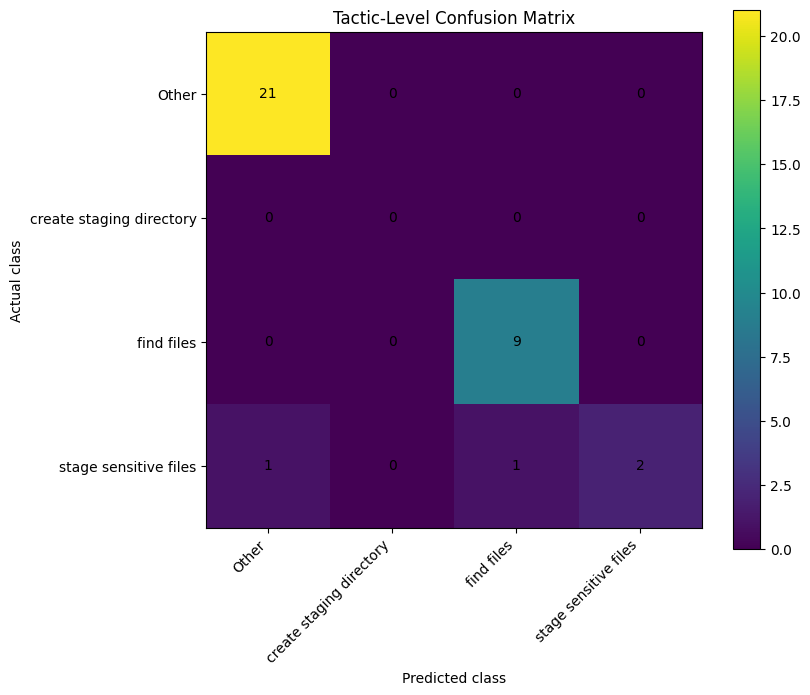

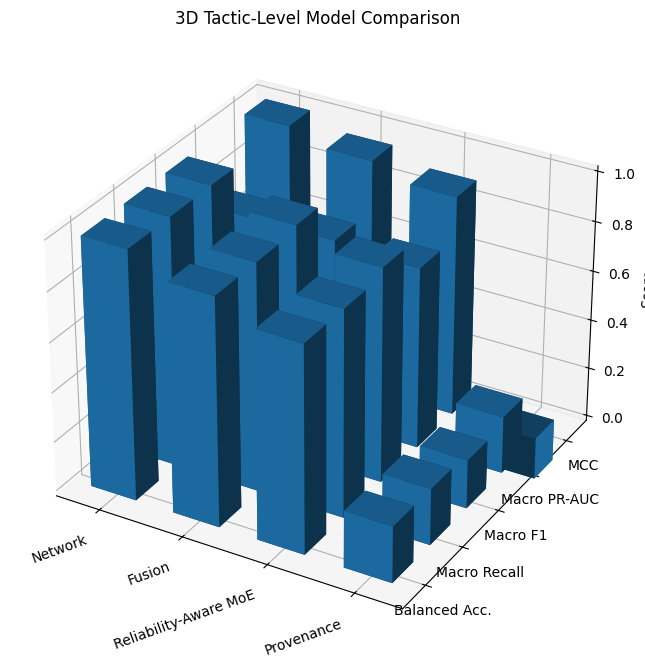

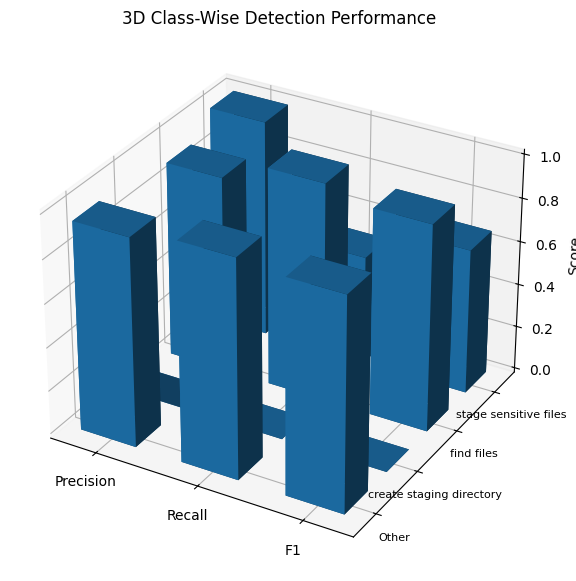

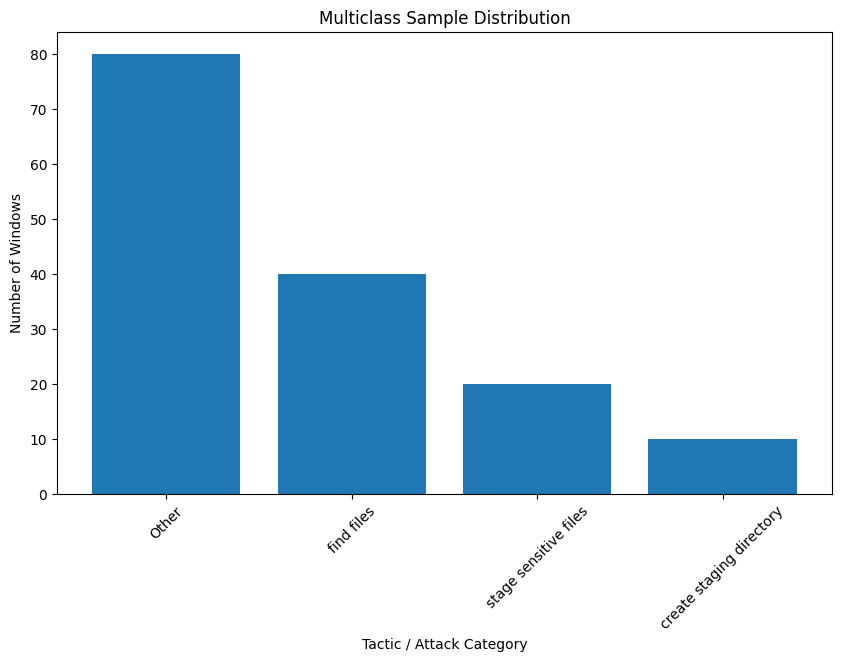

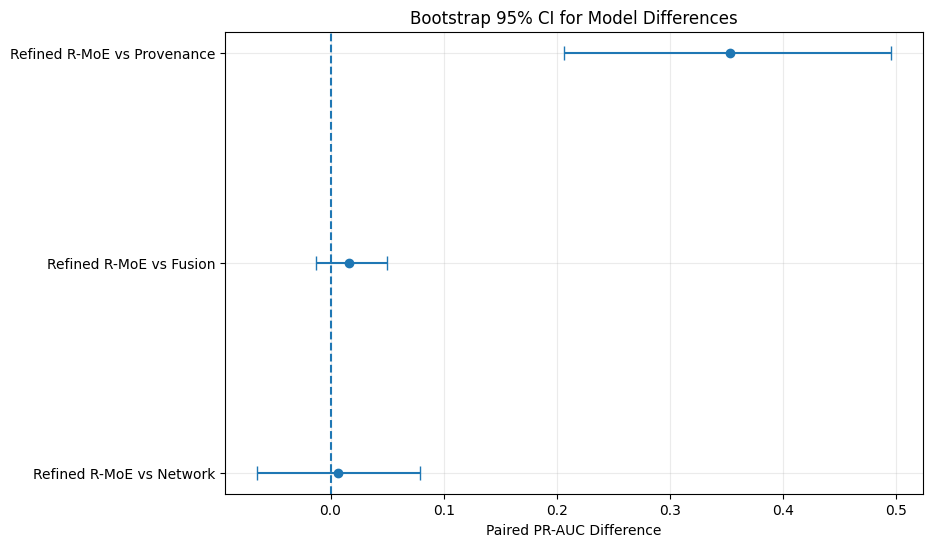


STEP 8 COMPLETE
Classes: 4
Samples: 150
Split: stratified_group
Router: MC_B

Final tactic-level result:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,macro_roc_auc,mcc
0,0.9412,0.8333,0.9515,0.8333,0.8636,0.9325,0.7323,NaN,0.8912



Model comparison:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,macro_roc_auc,mcc
0,Network,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7500,NaN,1.0000
1,Fusion,0.9706,0.9167,0.9667,0.9167,0.9348,0.9693,0.7500,NaN,0.9461
2,Reliability-Aware MoE,0.9412,0.8333,0.9515,0.8333,0.8636,0.9325,0.7323,NaN,0.8912
3,Provenance,0.2647,0.2275,0.2302,0.2275,0.1964,0.2698,0.2298,NaN,-0.1716



Per-class performance:


,class,precision,recall,f1,support
0,Other,0.9545,1.0,0.9767,21
1,create staging directory,0.0000,0.0,0.0000,0
2,find files,0.9000,1.0,0.9474,9
3,stage sensitive files,1.0000,0.5,0.6667,4



Statistical significance:


,comparison,metric,mean_difference,ci95_low,ci95_high,bootstrap_p,mcnemar_p,discordant_new_correct,discordant_old_correct
0,Refined R-MoE vs Network,pr_auc,0.00653,-0.06517,0.07911,0.884,1.00000,4,4
1,Refined R-MoE vs Network,f1,-0.03249,-0.14668,0.06810,0.559,1.00000,4,4
2,Refined R-MoE vs Network,mcc,-0.02030,-0.12838,0.07948,0.734,1.00000,4,4
3,Refined R-MoE vs Fusion,pr_auc,0.01594,-0.01313,0.04982,0.305,0.68750,4,2
4,Refined R-MoE vs Fusion,f1,-0.01461,-0.09720,0.05239,0.736,0.68750,4,2
5,Refined R-MoE vs Fusion,mcc,0.00228,-0.07653,0.07014,0.916,0.68750,4,2
6,Refined R-MoE vs Provenance,pr_auc,0.35315,0.20672,0.49520,0.000,0.09625,13,5
7,Refined R-MoE vs Provenance,f1,0.21271,0.07234,0.36609,0.003,0.09625,13,5
8,Refined R-MoE vs Provenance,mcc,0.20070,0.04783,0.35828,0.011,0.09625,13,5



Figures: /content/drive/MyDrive/IIoT_APT_Research/Step8_Tactic_Statistical_Validation/figures
Tables: /content/drive/MyDrive/IIoT_APT_Research/Step8_Tactic_Statistical_Validation/paper_tables
Reports: /content/drive/MyDrive/IIoT_APT_Research/Step8_Tactic_Statistical_Validation/reports

NEXT: final computational complexity, efficiency and paper-ready result consolidation.


In [ ]:
# ============================================================
# STEP 8 — TACTIC CLASSIFICATION + STATISTICAL VALIDATION
# ============================================================

from google.colab import drive
import os, json, random, math, warnings, copy
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    recall_score,
    precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import binomtest

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 20260924
FINAL_SEEDS = [
    20260924,
    20260925,
    20260926,
    20260927,
    20260928
]

BOOTSTRAPS = 2000
MAX_EPOCHS = 100
PATIENCE = 12

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/IIoT_APT_Research"
)

STEP2 = ROOT / "Step2_Reproducible_Preparation"
STEP4 = ROOT / "Step4_Multimodal_Pairing"
STEP5 = ROOT / "Step5_Baselines"
STEP7 = ROOT / "Step7_Refined_RMoE"
STEP8 = ROOT / "Step8_Tactic_Statistical_Validation"

PART_DIR = STEP8 / "target_parts"
FEATURE_DIR = STEP8 / "features"
MODEL_DIR = STEP8 / "models"
PRED_DIR = STEP8 / "predictions"
REP_DIR = STEP8 / "reports"
FIG_DIR = STEP8 / "figures"
TABLE_DIR = STEP8 / "paper_tables"

for p in [
    STEP8,
    PART_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    PRED_DIR,
    REP_DIR,
    FIG_DIR,
    TABLE_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )

NET_DIR = (
    STEP2 /
    "network_parquet"
)

BASE_DATA = (
    STEP5 /
    "features" /
    "baseline_dataset.parquet"
)

BASELINE_SUMMARY = (
    STEP5 /
    "reports" /
    "baseline_summary.csv"
)

BASELINE_PRED_DIR = (
    STEP5 /
    "predictions"
)

STEP4_REPORT = (
    STEP4 /
    "reports" /
    "step4_report.json"
)

FINAL_BINARY_PRED = (
    STEP7 /
    "predictions" /
    "final_test_predictions.parquet"
)

TARGET_FILE = (
    FEATURE_DIR /
    "window_tactic_targets.parquet"
)

MULTI_DATA_FILE = (
    FEATURE_DIR /
    "multiclass_dataset.parquet"
)

TARGET_REPORT = (
    REP_DIR /
    "tactic_distribution.csv"
)

MODEL_REPORT = (
    REP_DIR /
    "multiclass_model_results.csv"
)

SEED_REPORT = (
    REP_DIR /
    "multiclass_seed_results.csv"
)

STAT_REPORT = (
    REP_DIR /
    "multiclass_mean_std_ci.csv"
)

CLASS_REPORT = (
    REP_DIR /
    "per_class_results.csv"
)

SIGNIFICANCE_REPORT = (
    REP_DIR /
    "binary_significance_tests.csv"
)

FINAL_REPORT = (
    REP_DIR /
    "step8_final_report.json"
)

STATE_FILE = (
    STEP8 /
    "step8_state.json"
)

DONE_FILE = (
    STEP8 /
    "STEP8_COMPLETE.txt"
)

for p in [
    BASE_DATA,
    STEP4_REPORT,
    FINAL_BINARY_PRED
]:
    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(x, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    with open(tmp, "w") as f:
        json.dump(
            x,
            f,
            indent=2,
            default=str
        )

    os.replace(
        tmp,
        path
    )


def save_parquet(df, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(
        tmp,
        path
    )


def save_fig(fig, name):

    fig.savefig(
        FIG_DIR /
        f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG_DIR /
        f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def is_zero_label(x):

    s = (
        x.astype("string")
        .fillna("")
        .str.strip()
        .str.lower()
    )

    return s.isin([
        "",
        "0",
        "0.0",
        "benign",
        "normal",
        "none",
        "nan",
        "<na>"
    ])


step4 = json.load(
    open(STEP4_REPORT)
)

WINDOW = int(
    step4[
        "selected_window_seconds"
    ]
)

base = pd.read_parquet(
    BASE_DATA
).reset_index(
    drop=True
)

network_cols = [
    c for c in base.columns
    if c.startswith("N_")
]

prov_cols = [
    c for c in base.columns
    if c.startswith("P_")
]

print("=" * 76)
print("STEP 8 — INPUT")
print("=" * 76)

print(
    "Windows:",
    f"{len(base):,}"
)

print(
    "Pairing window:",
    WINDOW,
    "seconds"
)

print(
    "Network features:",
    len(network_cols)
)

print(
    "Provenance features:",
    len(prov_cols)
)


state = {}

if STATE_FILE.exists():

    try:
        state = json.load(
            open(STATE_FILE)
        )
    except:
        state = {}

completed = set(
    state.get(
        "target_parts",
        []
    )
)


if not TARGET_FILE.exists():

    network_files = sorted(
        NET_DIR.rglob(
            "*.parquet"
        )
    )

    if not network_files:
        raise RuntimeError(
            "Network parquet chunks not found."
        )

    print(
        "\nBuilding tactic targets..."
    )

    for i, f in enumerate(
        network_files,
        1
    ):

        tag = (
            f"{f.parent.name}_"
            f"{f.stem}"
        )

        out_file = (
            PART_DIR /
            f"{tag}.parquet"
        )

        if (
            tag in completed
            and
            out_file.exists()
        ):
            continue

        cols = [
            "_phase",
            "ts",
            "label",
            "subLabel",
            "subLabelCat"
        ]

        x = pd.read_parquet(
            f,
            columns=cols
        )

        x["ts"] = pd.to_numeric(
            x["ts"],
            errors="coerce"
        )

        x = x[
            x["ts"].notna()
        ].copy()

        attack_mask = (
            ~is_zero_label(
                x["label"]
            )
        )

        x = x[
            attack_mask
        ].copy()

        if len(x) == 0:

            save_parquet(
                pd.DataFrame(
                    columns=[
                        "_phase",
                        "_window_start",
                        "target",
                        "target_source",
                        "count"
                    ]
                ),
                out_file
            )

        else:

            cat = (
                x[
                    "subLabelCat"
                ]
                .astype("string")
                .fillna("")
                .str.strip()
            )

            sub = (
                x[
                    "subLabel"
                ]
                .astype("string")
                .fillna("")
                .str.strip()
            )

            bad_cat = is_zero_label(
                cat
            )

            target = cat.copy()

            target.loc[
                bad_cat
            ] = sub.loc[
                bad_cat
            ]

            source = np.where(
                bad_cat,
                "subLabel",
                "subLabelCat"
            )

            x["target"] = target

            x[
                "target_source"
            ] = source

            valid_target = (
                ~is_zero_label(
                    x["target"]
                )
            )

            x = x[
                valid_target
            ].copy()

            x[
                "_window_start"
            ] = (
                np.floor(
                    x["ts"] /
                    WINDOW
                )
                *
                WINDOW
            ).astype(
                "int64"
            )

            g = (
                x.groupby(
                    [
                        "_phase",
                        "_window_start",
                        "target",
                        "target_source"
                    ],
                    as_index=False
                )
                .size()
                .rename(
                    columns={
                        "size":
                            "count"
                    }
                )
            )

            save_parquet(
                g,
                out_file
            )

        completed.add(
            tag
        )

        state[
            "target_parts"
        ] = sorted(
            completed
        )

        state[
            "updated"
        ] = (
            datetime.now(
                timezone.utc
            ).isoformat()
        )

        save_json(
            state,
            STATE_FILE
        )

        print(
            f"[{i}/{len(network_files)}] "
            f"{tag}"
        )


    parts = [
        pd.read_parquet(p)
        for p in sorted(
            PART_DIR.glob(
                "*.parquet"
            )
        )
    ]

    target_counts = pd.concat(
        parts,
        ignore_index=True
    )

    target_counts = (
        target_counts.groupby(
            [
                "_phase",
                "_window_start",
                "target",
                "target_source"
            ],
            as_index=False
        )[
            "count"
        ]
        .sum()
    )

    target_counts = (
        target_counts.sort_values(
            [
                "_phase",
                "_window_start",
                "count",
                "target"
            ],
            ascending=[
                True,
                True,
                False,
                True
            ]
        )
    )

    targets = (
        target_counts
        .drop_duplicates(
            [
                "_phase",
                "_window_start"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    targets.rename(
        columns={
            "target":
                "tactic_target",

            "count":
                "dominant_packets"
        },
        inplace=True
    )

    save_parquet(
        targets,
        TARGET_FILE
    )

else:

    targets = pd.read_parquet(
        TARGET_FILE
    )


multi = pd.merge(
    base,
    targets[
        [
            "_phase",
            "_window_start",
            "tactic_target",
            "target_source",
            "dominant_packets"
        ]
    ],
    on=[
        "_phase",
        "_window_start"
    ],
    how="inner"
)

multi[
    "tactic_target"
] = (
    multi[
        "tactic_target"
    ]
    .astype(str)
    .str.strip()
)

multi = multi[
    multi[
        "tactic_target"
    ].ne("")
].copy()


raw_distribution = (
    multi[
        "tactic_target"
    ]
    .value_counts()
    .rename_axis(
        "class"
    )
    .reset_index(
        name="windows"
    )
)

print("\nRaw tactic/category distribution:")
display(
    raw_distribution
)


thresholds = [
    10,
    8,
    5,
    3,
    2
]

selected_min = 2

for min_count in thresholds:

    freq = (
        multi[
            "tactic_target"
        ]
        .value_counts()
    )

    keep = set(
        freq[
            freq >= min_count
        ].index
    )

    candidate = multi.copy()

    candidate[
        "tactic_final"
    ] = np.where(
        candidate[
            "tactic_target"
        ].isin(
            keep
        ),
        candidate[
            "tactic_target"
        ],
        "Other"
    )

    counts = (
        candidate[
            "tactic_final"
        ]
        .value_counts()
    )

    if (
        counts.size >= 3
        and
        counts.min() >= 2
    ):

        multi = candidate
        selected_min = min_count
        break


class_distribution = (
    multi[
        "tactic_final"
    ]
    .value_counts()
    .rename_axis(
        "class"
    )
    .reset_index(
        name="windows"
    )
)

class_distribution[
    "percentage"
] = (
    100 *
    class_distribution[
        "windows"
    ]
    /
    len(multi)
)

class_distribution.to_csv(
    TARGET_REPORT,
    index=False
)

print("\nFinal classes:")
display(
    class_distribution.round(2)
)

print(
    "Rare-class threshold:",
    selected_min
)


le = LabelEncoder()

multi[
    "y_multi"
] = le.fit_transform(
    multi[
        "tactic_final"
    ]
)

CLASS_NAMES = list(
    le.classes_
)

K = len(
    CLASS_NAMES
)

if K < 2:
    raise RuntimeError(
        "Insufficient tactic classes."
    )


if "_group" in multi.columns:

    groups = (
        multi[
            "_group"
        ]
        .astype(str)
        .to_numpy()
    )

else:

    groups = (
        multi[
            "_phase"
        ].astype(str)
        +
        "_"
        +
        np.floor(
            multi[
                "_window_start"
            ]
            /
            60
        )
        .astype("int64")
        .astype(str)
    ).to_numpy()


y_multi = (
    multi[
        "y_multi"
    ]
    .to_numpy()
)


def make_multiclass_split(
    y,
    groups
):

    try:

        sg1 = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED
        )

        split1 = next(
            sg1.split(
                np.zeros(
                    len(y)
                ),
                y,
                groups
            )
        )

        trv, test = split1

        sg2 = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=
                SEED + 1
        )

        tr_local, val_local = next(
            sg2.split(
                np.zeros(
                    len(trv)
                ),
                y[
                    trv
                ],
                groups[
                    trv
                ]
            )
        )

        train = trv[
            tr_local
        ]

        val = trv[
            val_local
        ]

        method = (
            "stratified_group"
        )

    except Exception:

        sk1 = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED
        )

        trv, test = next(
            sk1.split(
                np.zeros(
                    len(y)
                ),
                y
            )
        )

        sk2 = StratifiedKFold(
            n_splits=4,
            shuffle=True,
            random_state=
                SEED + 1
        )

        tr_local, val_local = next(
            sk2.split(
                np.zeros(
                    len(trv)
                ),
                y[
                    trv
                ]
            )
        )

        train = trv[
            tr_local
        ]

        val = trv[
            val_local
        ]

        method = (
            "stratified"
        )

    return (
        train,
        val,
        test,
        method
    )


train_idx, val_idx, test_idx, split_method = (
    make_multiclass_split(
        y_multi,
        groups
    )
)

multi[
    "multiclass_split"
] = ""

multi.loc[
    train_idx,
    "multiclass_split"
] = "train"

multi.loc[
    val_idx,
    "multiclass_split"
] = "validation"

multi.loc[
    test_idx,
    "multiclass_split"
] = "test"

save_parquet(
    multi,
    MULTI_DATA_FILE
)


split_table = (
    multi.groupby(
        [
            "multiclass_split",
            "tactic_final"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(
    "\nMulticlass split:",
    split_method
)

display(
    split_table
)


XN = multi[
    network_cols
].copy()

XP = multi[
    prov_cols
].copy()

XF = pd.concat(
    [
        XN.add_prefix(
            "N_"
        ),
        XP.add_prefix(
            "P_"
        )
    ],
    axis=1
)

for frame in [
    XN,
    XP,
    XF
]:

    frame.replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan,
        inplace=True
    )


def make_model(seed):

    return Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                keep_empty_features=True
            )
        ),

        (
            "model",

            ExtraTreesClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=1,
                class_weight=
                    "balanced_subsample",
                n_jobs=-1,
                random_state=seed
            )
        )
    ])


def aligned_proba(
    model,
    X,
    k
):

    raw = model.predict_proba(
        X
    )

    classes = (
        model.named_steps[
            "model"
        ].classes_
    )

    result = np.zeros(
        (
            len(X),
            k
        ),
        dtype=np.float32
    )

    for j, c in enumerate(
        classes
    ):

        result[
            :,
            int(c)
        ] = raw[
            :,
            j
        ]

    return result


def multi_metrics(
    y,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    macro_p, macro_r, macro_f1, _ = (
        precision_recall_fscore_support(
            y,
            pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = f1_score(
        y,
        pred,
        average="weighted",
        zero_division=0
    )

    bal = balanced_accuracy_score(
        y,
        pred
    )

    acc = accuracy_score(
        y,
        pred
    )

    mcc = matthews_corrcoef(
        y,
        pred
    )

    y_bin = label_binarize(
        y,
        classes=np.arange(K)
    )

    try:

        pr_auc = (
            average_precision_score(
                y_bin,
                prob,
                average="macro"
            )
        )

    except:

        pr_auc = np.nan

    try:

        roc_auc = (
            roc_auc_score(
                y_bin,
                prob,
                average="macro",
                multi_class="ovr"
            )
        )

    except:

        roc_auc = np.nan

    return {

        "accuracy":
            float(acc),

        "balanced_accuracy":
            float(bal),

        "macro_precision":
            float(macro_p),

        "macro_recall":
            float(macro_r),

        "macro_f1":
            float(macro_f1),

        "weighted_f1":
            float(weighted_f1),

        "macro_pr_auc":
            float(pr_auc),

        "macro_roc_auc":
            float(roc_auc),

        "mcc":
            float(mcc)
    }


SOURCES = {

    "Network":
        XN,

    "Provenance":
        XP,

    "Fusion":
        XF
}

expert_models = {}
expert_val = {}
expert_test = {}

result_rows = []

for j, (
    name,
    X
) in enumerate(
    SOURCES.items()
):

    model_file = (
        MODEL_DIR /
        f"{name}_multiclass.joblib"
    )

    if model_file.exists():

        model = joblib.load(
            model_file
        )

    else:

        model = make_model(
            SEED + j
        )

        model.fit(
            X.iloc[
                train_idx
            ],
            y_multi[
                train_idx
            ]
        )

        joblib.dump(
            model,
            model_file
        )

    expert_models[
        name
    ] = model

    vp = aligned_proba(
        model,
        X.iloc[
            val_idx
        ],
        K
    )

    tp = aligned_proba(
        model,
        X.iloc[
            test_idx
        ],
        K
    )

    expert_val[
        name
    ] = vp

    expert_test[
        name
    ] = tp

    vm = multi_metrics(
        y_multi[
            val_idx
        ],
        vp
    )

    tm = multi_metrics(
        y_multi[
            test_idx
        ],
        tp
    )

    result_rows.append({

        "model":
            name,

        "validation_macro_f1":
            vm[
                "macro_f1"
            ],

        **tm
    })


def make_oof():

    ytr = y_multi[
        train_idx
    ]

    min_class = int(
        pd.Series(
            ytr
        )
        .value_counts()
        .min()
    )

    folds = max(
        2,
        min(
            4,
            min_class
        )
    )

    skf = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    oof = np.zeros(
        (
            len(train_idx),
            3,
            K
        ),
        dtype=np.float32
    )

    for fold, (
        fit_local,
        hold_local
    ) in enumerate(
        skf.split(
            np.zeros(
                len(train_idx)
            ),
            ytr
        ),
        1
    ):

        fit_global = (
            train_idx[
                fit_local
            ]
        )

        hold_global = (
            train_idx[
                hold_local
            ]
        )

        for j, (
            name,
            X
        ) in enumerate(
            SOURCES.items()
        ):

            m = make_model(
                SEED +
                100 * fold +
                j
            )

            m.fit(
                X.iloc[
                    fit_global
                ],
                y_multi[
                    fit_global
                ]
            )

            oof[
                hold_local,
                j,
                :
            ] = aligned_proba(
                m,
                X.iloc[
                    hold_global
                ],
                K
            )

        print(
            f"OOF fold "
            f"{fold}/{folds}"
        )

    return oof


OOF_FILE = (
    FEATURE_DIR /
    "multiclass_oof.npy"
)

if OOF_FILE.exists():

    oof = np.load(
        OOF_FILE
    )

else:

    oof = make_oof()

    np.save(
        OOF_FILE,
        oof
    )


val_probs = np.stack(
    [
        expert_val[
            "Network"
        ],
        expert_val[
            "Provenance"
        ],
        expert_val[
            "Fusion"
        ]
    ],
    axis=1
)

test_probs = np.stack(
    [
        expert_test[
            "Network"
        ],
        expert_test[
            "Provenance"
        ],
        expert_test[
            "Fusion"
        ]
    ],
    axis=1
)


def reliability_context(
    rows
):

    n = (
        multi.iloc[
            rows
        ][
            network_cols
        ]
        .notna()
        .mean(axis=1)
        .to_numpy()
    )

    p = (
        multi.iloc[
            rows
        ][
            prov_cols
        ]
        .notna()
        .mean(axis=1)
        .to_numpy()
    )

    phase = (
        multi.iloc[
            rows
        ][
            "_phase"
        ]
        .astype(str)
        .str.lower()
        .eq("phase2")
        .astype(float)
        .to_numpy()
    )

    t = (
        pd.to_numeric(
            multi.iloc[
                rows
            ][
                "_window_start"
            ],
            errors="coerce"
        )
        .fillna(0)
        .to_numpy()
    )

    angle = (
        2 *
        np.pi *
        (t % 86400)
        /
        86400
    )

    return np.column_stack(
        [
            n,
            p,
            np.minimum(
                n,
                p
            ),
            np.sin(
                angle
            ),
            np.cos(
                angle
            ),
            phase
        ]
    ).astype(
        np.float32
    )


C_train = reliability_context(
    train_idx
)

C_val = reliability_context(
    val_idx
)

C_test = reliability_context(
    test_idx
)


class MultiRouter(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                3
            )
        )


    def forward(
        self,
        expert_prob,
        x
    ):

        gates = torch.softmax(
            self.net(x),
            dim=1
        )

        values, indices = (
            torch.topk(
                gates,
                k=2,
                dim=1
            )
        )

        sparse = (
            torch.zeros_like(
                gates
            )
        )

        sparse.scatter_(
            1,
            indices,
            values
        )

        gates = (
            sparse
            /
            (
                sparse.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-12
            )
        )

        out = (
            gates.unsqueeze(
                -1
            )
            *
            expert_prob
        ).sum(
            dim=1
        )

        out = (
            out
            /
            (
                out.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-12
            )
        )

        return out, gates


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


def router_features(
    probs,
    context
):

    p = np.clip(
        probs,
        1e-6,
        1
    )

    return np.concatenate(
        [
            p.reshape(
                len(p),
                -1
            ),
            context
        ],
        axis=1
    ).astype(
        np.float32
    )


R_train = router_features(
    oof,
    C_train
)

R_val = router_features(
    val_probs,
    C_val
)

R_test = router_features(
    test_probs,
    C_test
)


class_counts = np.bincount(
    y_multi[
        train_idx
    ],
    minlength=K
)

class_weights = (
    len(train_idx)
    /
    (
        K *
        np.maximum(
            class_counts,
            1
        )
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)


def train_router(
    config,
    seed,
    tag
):

    model_path = (
        MODEL_DIR /
        f"{tag}.pt"
    )

    result_path = (
        REP_DIR /
        f"{tag}.json"
    )

    set_seed = seed

    random.seed(
        set_seed
    )

    np.random.seed(
        set_seed
    )

    torch.manual_seed(
        set_seed
    )

    model = MultiRouter(
        input_dim=
            R_train.shape[1],
        hidden=
            config[
                "hidden"
            ],
        dropout=
            config[
                "dropout"
            ]
    ).to(
        device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=
            config["lr"],
        weight_decay=
            config[
                "weight_decay"
            ]
    )

    ep = torch.tensor(
        oof,
        dtype=torch.float32
    )

    xr = torch.tensor(
        R_train,
        dtype=torch.float32
    )

    yy = torch.tensor(
        y_multi[
            train_idx
        ],
        dtype=torch.long
    )

    ds = TensorDataset(
        ep,
        xr,
        yy
    )

    loader = DataLoader(
        ds,
        batch_size=
            min(
                config[
                    "batch"
                ],
                len(ds)
            ),
        shuffle=True
    )

    val_ep = torch.tensor(
        val_probs,
        dtype=torch.float32,
        device=device
    )

    val_x = torch.tensor(
        R_val,
        dtype=torch.float32,
        device=device
    )

    best_score = -1
    best_state = None
    stale = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        for e, x, target in loader:

            e = e.to(
                device
            )

            x = x.to(
                device
            )

            target = target.to(
                device
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            prob, gates = model(
                e,
                x
            )

            chosen = (
                prob[
                    torch.arange(
                        len(target),
                        device=device
                    ),
                    target
                ]
                .clamp(
                    1e-7,
                    1
                )
            )

            loss = (
                -torch.log(
                    chosen
                )
                *
                class_weights[
                    target
                ]
            ).mean()

            usage = gates.mean(
                dim=0
            )

            loss = (
                loss
                +
                config[
                    "balance"
                ]
                *
                (
                    (
                        usage -
                        1/3
                    ) ** 2
                ).mean()
            )

            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():

            vp, _ = model(
                val_ep,
                val_x
            )

        vm = multi_metrics(
            y_multi[
                val_idx
            ],
            vp.cpu().numpy()
        )

        score = (
            0.60 *
            vm[
                "macro_f1"
            ]
            +
            0.25 *
            vm[
                "macro_recall"
            ]
            +
            0.15 *
            vm[
                "balanced_accuracy"
            ]
        )

        if score > (
            best_score +
            1e-5
        ):

            best_score = score

            best_state = copy.deepcopy(
                model.state_dict()
            )

            stale = 0

        else:

            stale += 1

        if stale >= PATIENCE:
            break


    model.load_state_dict(
        best_state
    )

    torch.save(
        {
            "state":
                best_state,
            "config":
                config,
            "input_dim":
                R_train.shape[1],
            "seed":
                seed
        },
        model_path
    )

    save_json(
        {
            "validation_score":
                best_score,
            "config":
                config,
            "seed":
                seed
        },
        result_path
    )

    return (
        model,
        best_score
    )


router_configs = [

    {
        "name": "MC_A",
        "hidden": 16,
        "dropout": 0.05,
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "balance": 0.005,
        "batch": 128
    },

    {
        "name": "MC_B",
        "hidden": 32,
        "dropout": 0.10,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "balance": 0.010,
        "batch": 128
    },

    {
        "name": "MC_C",
        "hidden": 48,
        "dropout": 0.15,
        "lr": 3e-4,
        "weight_decay": 2e-4,
        "balance": 0.015,
        "batch": 128
    }
]


search = []

for cfg in router_configs:

    model, score = train_router(
        cfg,
        SEED,
        "search_" +
        cfg["name"]
    )

    search.append(
        (
            cfg,
            score
        )
    )

    print(
        cfg["name"],
        "validation score:",
        round(
            score,
            4
        )
    )


best_cfg = max(
    search,
    key=lambda x:
        x[1]
)[0]

print(
    "\nSelected multiclass router:",
    best_cfg[
        "name"
    ]
)


seed_rows = []

representative = None

for seed in FINAL_SEEDS:

    model, _ = train_router(
        best_cfg,
        seed,
        (
            "final_" +
            str(seed)
        )
    )

    model.eval()

    with torch.no_grad():

        tp, gates = model(

            torch.tensor(
                test_probs,
                dtype=torch.float32,
                device=device
            ),

            torch.tensor(
                R_test,
                dtype=torch.float32,
                device=device
            )
        )

    tp = (
        tp.cpu()
        .numpy()
    )

    gates = (
        gates.cpu()
        .numpy()
    )

    m = multi_metrics(
        y_multi[
            test_idx
        ],
        tp
    )

    seed_rows.append({

        "seed":
            seed,

        **m
    })

    print(
        f"Seed {seed} | "
        f"Macro-F1="
        f"{m['macro_f1']:.4f} | "
        f"Macro-Recall="
        f"{m['macro_recall']:.4f} | "
        f"PR-AUC="
        f"{m['macro_pr_auc']:.4f}"
    )

    if seed == FINAL_SEEDS[0]:

        representative = {
            "prob":
                tp,
            "gates":
                gates,
            "metrics":
                m
        }


seed_df = pd.DataFrame(
    seed_rows
)

seed_df.to_csv(
    SEED_REPORT,
    index=False
)


final_metrics = (
    representative[
        "metrics"
    ]
)

result_rows.append({

    "model":
        "Reliability-Aware MoE",

    "validation_macro_f1":
        np.nan,

    **final_metrics
})


model_df = (
    pd.DataFrame(
        result_rows
    )
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

model_df.to_csv(
    MODEL_REPORT,
    index=False
)

print("\n" + "=" * 76)
print("MULTICLASS TEST RESULTS")
print("=" * 76)

display(
    model_df.round(4)
)


stat_rows = []

tcrit = 2.776445

for metric in [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "macro_pr_auc",
    "macro_roc_auc",
    "mcc"
]:

    vals = (
        seed_df[
            metric
        ]
        .astype(float)
        .to_numpy()
    )

    mean = np.nanmean(
        vals
    )

    sd = np.nanstd(
        vals,
        ddof=1
    )

    valid_n = np.sum(
        ~np.isnan(
            vals
        )
    )

    margin = (
        tcrit *
        sd /
        np.sqrt(
            max(
                valid_n,
                1
            )
        )
    )

    stat_rows.append({

        "metric":
            metric,

        "mean":
            mean,

        "std":
            sd,

        "ci95_low":
            mean -
            margin,

        "ci95_high":
            mean +
            margin,

        "paper_value":
            f"{mean:.4f} ± "
            f"{sd:.4f}"
    })


stat_df = pd.DataFrame(
    stat_rows
)

stat_df.to_csv(
    STAT_REPORT,
    index=False
)

print("\nRepeated-run statistics:")
display(
    stat_df
)


y_test_multi = (
    y_multi[
        test_idx
    ]
)

pred_multi = np.argmax(
    representative[
        "prob"
    ],
    axis=1
)

class_rep = (
    classification_report(
        y_test_multi,
        pred_multi,
        labels=np.arange(K),
        target_names=
            CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
)

class_rows = []

for name in CLASS_NAMES:

    if name not in class_rep:
        continue

    r = class_rep[
        name
    ]

    class_rows.append({

        "class":
            name,

        "precision":
            r[
                "precision"
            ],

        "recall":
            r[
                "recall"
            ],

        "f1":
            r[
                "f1-score"
            ],

        "support":
            int(
                r[
                    "support"
                ]
            )
    })


class_df = pd.DataFrame(
    class_rows
)

class_df.to_csv(
    CLASS_REPORT,
    index=False
)

print("\nPer-class results:")
display(
    class_df.round(4)
)


pred_output = pd.DataFrame({

    "_window_id":
        multi.iloc[
            test_idx
        ][
            "_window_id"
        ]
        .to_numpy(),

    "actual":
        le.inverse_transform(
            y_test_multi
        ),

    "predicted":
        le.inverse_transform(
            pred_multi
        )
})

for k, name in enumerate(
    CLASS_NAMES
):

    safe_name = (
        str(name)
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )

    pred_output[
        f"P_{safe_name}"
    ] = (
        representative[
            "prob"
        ][
            :,
            k
        ]
    )

save_parquet(
    pred_output,
    PRED_DIR /
    "multiclass_predictions.parquet"
)


final_binary = pd.read_parquet(
    FINAL_BINARY_PRED
)


def bootstrap_difference(
    y,
    p_new,
    pred_new,
    p_old,
    pred_old,
    metric,
    n_boot=BOOTSTRAPS
):

    rng = np.random.default_rng(
        SEED
    )

    diffs = []

    n = len(y)

    for _ in range(
        n_boot
    ):

        idx = rng.integers(
            0,
            n,
            n
        )

        yy = y[
            idx
        ]

        if len(
            np.unique(
                yy
            )
        ) < 2:

            continue

        if metric == "pr_auc":

            a = (
                average_precision_score(
                    yy,
                    p_new[
                        idx
                    ]
                )
            )

            b = (
                average_precision_score(
                    yy,
                    p_old[
                        idx
                    ]
                )
            )

        elif metric == "f1":

            a = f1_score(
                yy,
                pred_new[
                    idx
                ],
                zero_division=0
            )

            b = f1_score(
                yy,
                pred_old[
                    idx
                ],
                zero_division=0
            )

        else:

            a = matthews_corrcoef(
                yy,
                pred_new[
                    idx
                ]
            )

            b = matthews_corrcoef(
                yy,
                pred_old[
                    idx
                ]
            )

        diffs.append(
            a - b
        )

    diffs = np.asarray(
        diffs
    )

    low, high = (
        np.percentile(
            diffs,
            [
                2.5,
                97.5
            ]
        )
    )

    p = (
        2 *
        min(
            np.mean(
                diffs <= 0
            ),
            np.mean(
                diffs >= 0
            )
        )
    )

    return (
        float(
            np.mean(
                diffs
            )
        ),
        float(low),
        float(high),
        float(
            min(
                p,
                1
            )
        )
    )


baseline_summary = pd.read_csv(
    BASELINE_SUMMARY
)

significance_rows = []


for _, row in baseline_summary.iterrows():

    modality = str(
        row[
            "modality"
        ]
    )

    model_name = str(
        row[
            "best_model"
        ]
    )

    path = (
        BASELINE_PRED_DIR /
        f"{modality}_"
        f"{model_name}.parquet"
    )

    if not path.exists():
        continue

    old = pd.read_parquet(
        path
    )

    merged = pd.merge(
        final_binary,
        old,
        on="_window_id",
        suffixes=(
            "_new",
            "_old"
        )
    )

    yb = (
        merged[
            "y_true_new"
        ]
        .astype(int)
        .to_numpy()
    )

    pn = (
        merged[
            "probability_new"
        ]
        .to_numpy()
    )

    po = (
        merged[
            "probability_old"
        ]
        .to_numpy()
    )

    dn = (
        merged[
            "prediction_new"
        ]
        .astype(int)
        .to_numpy()
    )

    do = (
        merged[
            "prediction_old"
        ]
        .astype(int)
        .to_numpy()
    )

    new_correct = (
        dn == yb
    )

    old_correct = (
        do == yb
    )

    b = int(
        (
            new_correct
            &
            ~old_correct
        ).sum()
    )

    c = int(
        (
            ~new_correct
            &
            old_correct
        ).sum()
    )

    if b + c > 0:

        mcnemar_p = float(
            binomtest(
                min(
                    b,
                    c
                ),
                n=b + c,
                p=0.5,
                alternative=
                    "two-sided"
            ).pvalue
        )

    else:

        mcnemar_p = 1.0


    for metric in [
        "pr_auc",
        "f1",
        "mcc"
    ]:

        mean_diff, low, high, bp = (
            bootstrap_difference(
                yb,
                pn,
                dn,
                po,
                do,
                metric
            )
        )

        significance_rows.append({

            "comparison":
                (
                    "Refined R-MoE vs "
                    +
                    modality
                ),

            "metric":
                metric,

            "mean_difference":
                mean_diff,

            "ci95_low":
                low,

            "ci95_high":
                high,

            "bootstrap_p":
                bp,

            "mcnemar_p":
                mcnemar_p,

            "discordant_new_correct":
                b,

            "discordant_old_correct":
                c
        })


significance_df = pd.DataFrame(
    significance_rows
)

significance_df.to_csv(
    SIGNIFICANCE_REPORT,
    index=False
)

print("\n" + "=" * 76)
print("PAIRED STATISTICAL TESTS")
print("=" * 76)

display(
    significance_df.round(5)
)


cm = confusion_matrix(
    y_test_multi,
    pred_multi,
    labels=np.arange(K)
)

fig, ax = plt.subplots(
    figsize=(
        max(
            8,
            K * 0.9
        ),
        max(
            7,
            K * 0.8
        )
    )
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    np.arange(K)
)

ax.set_yticks(
    np.arange(K)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "Actual class"
)

ax.set_title(
    "Tactic-Level Confusion Matrix"
)

for i in range(K):

    for j in range(K):

        ax.text(
            j,
            i,
            str(
                cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

save_fig(
    fig,
    "Fig_8A_Tactic_Confusion_Matrix"
)


plot_metrics = [
    "balanced_accuracy",
    "macro_recall",
    "macro_f1",
    "macro_pr_auc",
    "mcc"
]

fig = plt.figure(
    figsize=(13, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

xpos = np.repeat(
    np.arange(
        len(
            model_df
        )
    ),
    len(
        plot_metrics
    )
)

ypos = np.tile(
    np.arange(
        len(
            plot_metrics
        )
    ),
    len(
        model_df
    )
)

zpos = np.zeros(
    len(
        xpos
    )
)

dx = np.full(
    len(
        xpos
    ),
    0.55
)

dy = np.full(
    len(
        ypos
    ),
    0.55
)

dz = (
    model_df[
        plot_metrics
    ]
    .fillna(0)
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            model_df
        )
    )
    +
    0.27
)

ax.set_xticklabels(
    model_df[
        "model"
    ],
    rotation=20,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(
            plot_metrics
        )
    )
    +
    0.27
)

ax.set_yticklabels([
    "Balanced Acc.",
    "Macro Recall",
    "Macro F1",
    "Macro PR-AUC",
    "MCC"
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Tactic-Level Model Comparison"
)

save_fig(
    fig,
    "Fig_8B_3D_Tactic_Model_Comparison"
)


fig = plt.figure(
    figsize=(
        12,
        max(
            7,
            len(
                class_df
            )
        )
    )
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

metric_cols = [
    "precision",
    "recall",
    "f1"
]

arr = (
    class_df[
        metric_cols
    ]
    .to_numpy()
)

xpos = np.tile(
    np.arange(
        3
    ),
    len(
        class_df
    )
)

ypos = np.repeat(
    np.arange(
        len(
            class_df
        )
    ),
    3
)

zpos = np.zeros(
    len(
        xpos
    )
)

dx = np.full(
    len(
        xpos
    ),
    0.55
)

dy = np.full(
    len(
        ypos
    ),
    0.55
)

dz = arr.reshape(
    -1
)

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    [
        0.27,
        1.27,
        2.27
    ]
)

ax.set_xticklabels([
    "Precision",
    "Recall",
    "F1"
])

ax.set_yticks(
    np.arange(
        len(
            class_df
        )
    )
    +
    0.27
)

ax.set_yticklabels(
    class_df[
        "class"
    ],
    fontsize=8
)

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Class-Wise Detection Performance"
)

save_fig(
    fig,
    "Fig_8C_3D_Per_Class_Performance"
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    class_distribution[
        "class"
    ],
    class_distribution[
        "windows"
    ]
)

ax.set_ylabel(
    "Number of Windows"
)

ax.set_xlabel(
    "Tactic / Attack Category"
)

ax.set_title(
    "Multiclass Sample Distribution"
)

ax.tick_params(
    axis="x",
    rotation=45
)

save_fig(
    fig,
    "Fig_8D_Class_Distribution"
)


if len(
    significance_df
):

    sig_plot = (
        significance_df[
            significance_df[
                "metric"
            ]
            ==
            "pr_auc"
        ]
        .copy()
    )

    sig_plot[
        "lower_error"
    ] = (
        sig_plot[
            "mean_difference"
        ]
        -
        sig_plot[
            "ci95_low"
        ]
    )

    sig_plot[
        "upper_error"
    ] = (
        sig_plot[
            "ci95_high"
        ]
        -
        sig_plot[
            "mean_difference"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.errorbar(
        sig_plot[
            "mean_difference"
        ],
        np.arange(
            len(
                sig_plot
            )
        ),
        xerr=[
            sig_plot[
                "lower_error"
            ],
            sig_plot[
                "upper_error"
            ]
        ],
        fmt="o",
        capsize=5
    )

    ax.axvline(
        0,
        linestyle="--"
    )

    ax.set_yticks(
        np.arange(
            len(
                sig_plot
            )
        )
    )

    ax.set_yticklabels(
        sig_plot[
            "comparison"
        ]
    )

    ax.set_xlabel(
        "Paired PR-AUC Difference"
    )

    ax.set_title(
        "Bootstrap 95% CI for Model Differences"
    )

    ax.grid(
        alpha=0.25
    )

    save_fig(
        fig,
        "Fig_8E_PR_AUC_Significance"
    )


model_df.to_latex(
    TABLE_DIR /
    "Table_8A_Multiclass_Results.tex",
    index=False,
    float_format="%.4f"
)

class_df.to_latex(
    TABLE_DIR /
    "Table_8B_Per_Class_Results.tex",
    index=False,
    float_format="%.4f"
)

significance_df.to_latex(
    TABLE_DIR /
    "Table_8C_Statistical_Tests.tex",
    index=False,
    float_format="%.5f"
)

stat_df.to_latex(
    TABLE_DIR /
    "Table_8D_Repeatability.tex",
    index=False,
    float_format="%.4f"
)


final_report = {

    "window_seconds":
        WINDOW,

    "target_source":
        "subLabelCat with subLabel fallback",

    "rare_class_threshold":
        selected_min,

    "number_of_classes":
        K,

    "class_names":
        CLASS_NAMES,

    "multiclass_rows":
        int(
            len(
                multi
            )
        ),

    "split_method":
        split_method,

    "selected_router":
        best_cfg[
            "name"
        ],

    "representative_multiclass":
        final_metrics,

    "statistical_comparisons":
        int(
            significance_df[
                "comparison"
            ].nunique()
            if len(
                significance_df
            )
            else 0
        ),

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    FINAL_REPORT
)

DONE_FILE.write_text(

    "STEP 8 COMPLETE\n"

    f"Classes: {K}\n"

    f"Samples: {len(multi)}\n"

    f"Macro-F1: "
    f"{final_metrics['macro_f1']:.4f}\n"

    f"Macro PR-AUC: "
    f"{final_metrics['macro_pr_auc']:.4f}\n"
)


print("\n" + "=" * 76)
print("STEP 8 COMPLETE")
print("=" * 76)

print(
    "Classes:",
    K
)

print(
    "Samples:",
    f"{len(multi):,}"
)

print(
    "Split:",
    split_method
)

print(
    "Router:",
    best_cfg[
        "name"
    ]
)

print("\nFinal tactic-level result:")

display(
    pd.DataFrame(
        [
            final_metrics
        ]
    ).round(4)
)

print("\nModel comparison:")

display(
    model_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "macro_roc_auc",
            "mcc"
        ]
    ].round(4)
)

print("\nPer-class performance:")

display(
    class_df.round(4)
)

print("\nStatistical significance:")

display(
    significance_df.round(5)
)

print(
    "\nFigures:",
    FIG_DIR
)

print(
    "Tables:",
    TABLE_DIR
)

print(
    "Reports:",
    REP_DIR
)

print(
    "\nNEXT: final computational complexity, "
    "efficiency and paper-ready result consolidation."
)


CLEAN FINAL BINARY RESULT


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9985,0.7026,0.75,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003,17959,5,22,15



NOISY-EVIDENCE ROBUSTNESS


,scenario,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Clean,0.7026,0.7500,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003
1,Network Noise 5%,0.7161,0.7619,0.4324,0.5517,0.4631,0.9558,0.5734,0.0003
2,Provenance Noise 5%,0.7161,0.7619,0.4324,0.5517,0.5187,0.9484,0.5734,0.0003
3,Both Noise 5%,0.7160,0.7273,0.4324,0.5424,0.4761,0.9581,0.5601,0.0003
4,Network Noise 10%,0.6755,0.6842,0.3514,0.4643,0.4299,0.9374,0.4896,0.0003
5,Provenance Noise 10%,0.7026,0.7500,0.4054,0.5263,0.5266,0.9476,0.5508,0.0003
6,Both Noise 10%,0.7026,0.7895,0.4054,0.5357,0.4340,0.9359,0.5651,0.0002
7,Network Noise 25%,0.6486,0.7857,0.2973,0.4314,0.3750,0.9195,0.4827,0.0002
8,Provenance Noise 25%,0.7161,0.7619,0.4324,0.5517,0.5275,0.9575,0.5734,0.0003
9,Both Noise 25%,0.6485,0.7333,0.2973,0.4231,0.3386,0.9251,0.4663,0.0002



Reliability-routing correlations:


,relationship,spearman_rho,p_value
0,Network reliability vs Network gate,0.11984,0.00000
1,Provenance reliability vs Provenance gate,0.02045,0.00608
2,Joint reliability vs Fusion gate,0.18204,0.00000



COMPUTATIONAL EFFICIENCY


,component,type,trees,tree_nodes,tree_leaves,neural_parameters,model_size_mb
0,Network Expert,ExtraTrees,220,250710,125465,0,19.213
1,Provenance Expert,ExtraTrees,220,28122,14171,0,2.228
2,Fusion Expert,ExtraTrees,220,242868,121544,0,18.615
3,Temporal Expert,ExtraTrees,180,243956,122068,0,18.680
4,Sparse Router,Neural,0,0,0,3316,0.016


,test_windows,mean_end_to_end_seconds,std_seconds,latency_ms_per_window,throughput_windows_per_second,router_parameters,total_serialized_model_mb,cpu_count,gpu
0,18001,1.4449,0.3336,0.0803,12458.6356,3316,58.7526,2,None


Tactic OOF fold 1/3
Tactic OOF fold 2/3
Tactic OOF fold 3/3

REPAIRED TACTIC-LEVEL EVALUATION
Evaluation: group-aware OOF
Folds: 3


,class,unique_temporal_groups
0,Other,44
1,create staging directory,3
2,find files,26
3,stage sensitive files,11


,model,evaluation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc
0,Network,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183
1,Provenance,group-aware OOF,0.3600,0.2469,0.2429,0.2469,0.2392,0.3735,0.0250
2,Fusion,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183


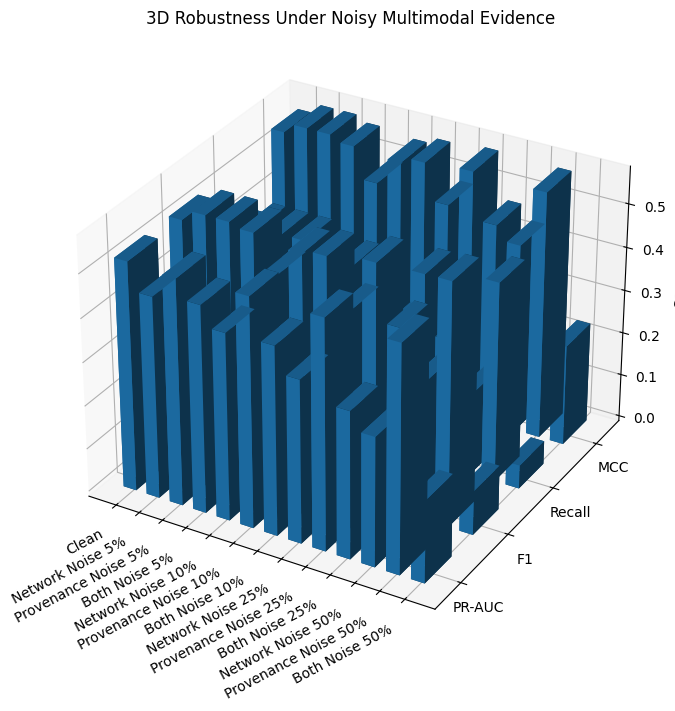

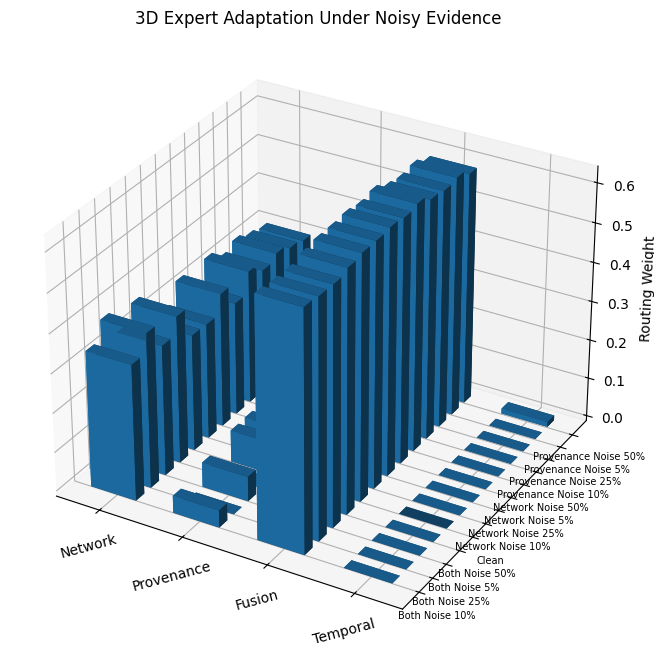

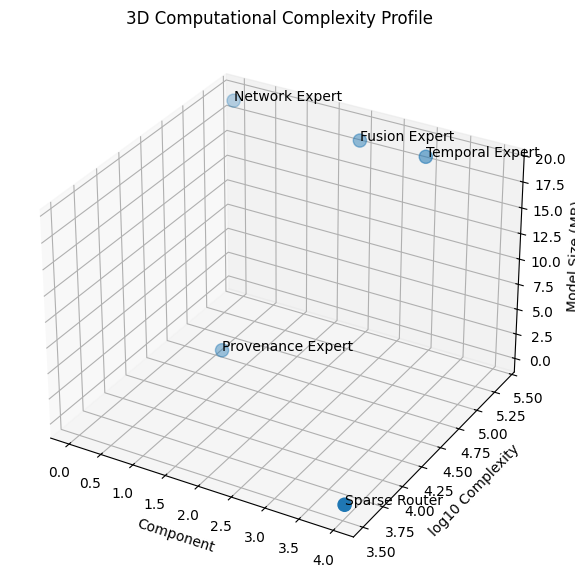

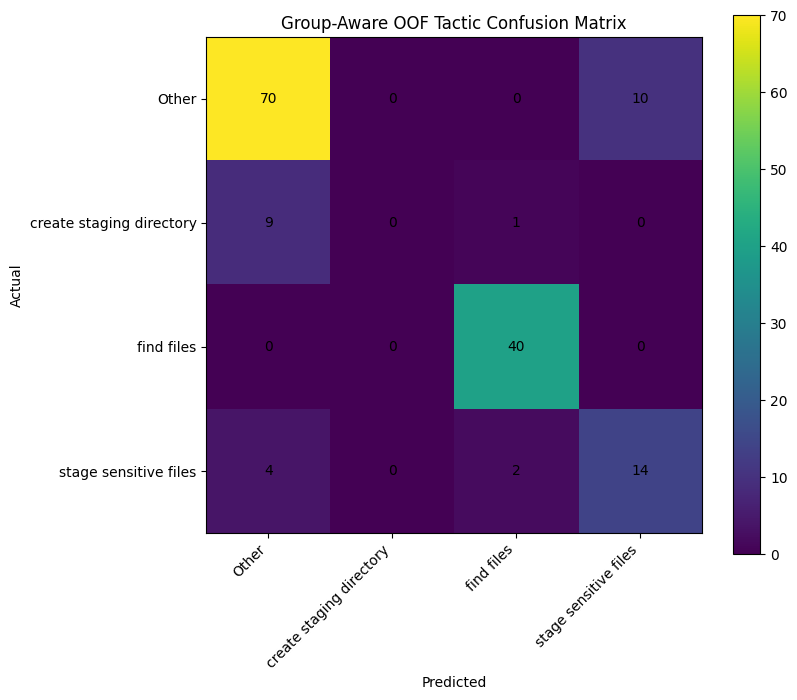

,Binary_PR_AUC,Binary_ROC_AUC,Binary_F1,Binary_Recall,Binary_MCC,Binary_FPR,Router_Parameters,Serialized_Model_MB,Latency_ms_window,Throughput_windows_s,Tactic_Evaluation,Tactic_Best_Model,Tactic_Macro_F1
0,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003,3316,58.7526,0.0803,12458.6356,group-aware OOF,Network,0.6148



STEP 9 COMPLETE

1. Final binary result


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9985,0.7026,0.75,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003,17959,5,22,15



2. Noisy-evidence robustness


,scenario,pr_auc,roc_auc,f1,recall,mcc,fpr
0,Clean,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003
1,Network Noise 5%,0.4631,0.9558,0.5517,0.4324,0.5734,0.0003
2,Provenance Noise 5%,0.5187,0.9484,0.5517,0.4324,0.5734,0.0003
3,Both Noise 5%,0.4761,0.9581,0.5424,0.4324,0.5601,0.0003
4,Network Noise 10%,0.4299,0.9374,0.4643,0.3514,0.4896,0.0003
5,Provenance Noise 10%,0.5266,0.9476,0.5263,0.4054,0.5508,0.0003
6,Both Noise 10%,0.4340,0.9359,0.5357,0.4054,0.5651,0.0002
7,Network Noise 25%,0.3750,0.9195,0.4314,0.2973,0.4827,0.0002
8,Provenance Noise 25%,0.5275,0.9575,0.5517,0.4324,0.5734,0.0003
9,Both Noise 25%,0.3386,0.9251,0.4231,0.2973,0.4663,0.0002



3. Reliability-aware routing


,relationship,spearman_rho,p_value
0,Network reliability vs Network gate,0.11984,0.00000
1,Provenance reliability vs Provenance gate,0.02045,0.00608
2,Joint reliability vs Fusion gate,0.18204,0.00000



4. Efficiency


,test_windows,mean_end_to_end_seconds,std_seconds,latency_ms_per_window,throughput_windows_per_second,router_parameters,total_serialized_model_mb,cpu_count,gpu
0,18001,1.4449,0.3336,0.0803,12458.6356,3316,58.7526,2,None



5. Complexity


,component,type,trees,tree_nodes,tree_leaves,neural_parameters,model_size_mb
0,Network Expert,ExtraTrees,220,250710,125465,0,19.213
1,Provenance Expert,ExtraTrees,220,28122,14171,0,2.228
2,Fusion Expert,ExtraTrees,220,242868,121544,0,18.615
3,Temporal Expert,ExtraTrees,180,243956,122068,0,18.680
4,Sparse Router,Neural,0,0,0,3316,0.016



6. Corrected tactic-level OOF


,model,evaluation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc
0,Network,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183
1,Provenance,group-aware OOF,0.3600,0.2469,0.2429,0.2469,0.2392,0.3735,0.0250
2,Fusion,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183



7. Tactic class-level performance


,class,precision,recall,f1,support
0,Other,0.8434,0.875,0.8589,80
1,create staging directory,0.0000,0.000,0.0000,10
2,find files,0.9302,1.000,0.9639,40
3,stage sensitive files,0.5833,0.700,0.6364,20



Saved reports: /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/reports
Saved tables : /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/paper_tables
Saved figures: /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/figures

NEXT: final manuscript result tables, methodology diagram values and Results section.


In [ ]:
# ============================================================
# STEP 9 — FINAL RELIABILITY, EFFICIENCY & EVIDENCE VALIDATION
# ============================================================

from google.colab import drive
import os, json, time, random, platform, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    matthews_corrcoef, confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)
from scipy.stats import spearmanr

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

SEED = 20260924
BENCHMARK_REPEATS = 5
NOISE_LEVELS = [0.05, 0.10, 0.25, 0.50]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")

STEP5 = ROOT / "Step5_Baselines"
STEP7 = ROOT / "Step7_Refined_RMoE"
STEP8 = ROOT / "Step8_Tactic_Statistical_Validation"
STEP9 = ROOT / "Step9_Final_Evidence"

REP = STEP9 / "reports"
FIG = STEP9 / "figures"
TAB = STEP9 / "paper_tables"
PRED = STEP9 / "predictions"

for p in [STEP9, REP, FIG, TAB, PRED]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = STEP5 / "features" / "baseline_dataset.parquet"

STEP7_REPORT = (
    STEP7 /
    "reports" /
    "step7_final_report.json"
)

ROUTER_FILE = (
    STEP7 /
    "models" /
    "final_sparse_20260924.pt"
)

MULTI_FILE = (
    STEP8 /
    "features" /
    "multiclass_dataset.parquet"
)

EXPERT_NAMES = [
    "Network",
    "Provenance",
    "Fusion",
    "Temporal"
]

EXPERT_FILES = {
    name:
        STEP7 /
        "models" /
        f"Expert_{name}.joblib"
    for name in EXPERT_NAMES
}

for p in [
    DATA_FILE,
    STEP7_REPORT,
    ROUTER_FILE,
    MULTI_FILE
]:

    if not p.exists():
        raise FileNotFoundError(str(p))

for p in EXPERT_FILES.values():

    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(obj, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    with open(tmp, "w") as f:

        json.dump(
            obj,
            f,
            indent=2,
            default=str
        )

    os.replace(
        tmp,
        path
    )


def save_parquet(df, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(
        tmp,
        path
    )


def save_fig(fig, name):

    fig.savefig(
        FIG /
        f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG /
        f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def binary_metrics(
    y,
    prob,
    threshold
):

    pred = (
        prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    return {

        "accuracy":
            accuracy_score(
                y,
                pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "pr_auc":
            average_precision_score(
                y,
                prob
            ),

        "roc_auc":
            roc_auc_score(
                y,
                prob
            ),

        "mcc":
            matthews_corrcoef(
                y,
                pred
            ),

        "fpr":
            fp / (
                fp + tn
            ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


base = pd.read_parquet(
    DATA_FILE
).reset_index(
    drop=True
)

report7 = json.load(
    open(STEP7_REPORT)
)

network_cols = [
    c for c in base.columns
    if c.startswith("N_")
]

prov_cols = [
    c for c in base.columns
    if c.startswith("P_")
]

train_mask = (
    base["split"] ==
    "train"
)

test_mask = (
    base["split"] ==
    "test"
)

train_idx = np.where(
    train_mask
)[0]

test_idx = np.where(
    test_mask
)[0]

y_test = (
    base.loc[
        test_mask,
        "binary_label"
    ]
    .astype(int)
    .to_numpy()
)

XN = (
    base[
        network_cols
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

XP = (
    base[
        prov_cols
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


def robust_scale(
    frame
):

    train = frame.loc[
        train_mask
    ]

    med = train.median()

    q25 = train.quantile(
        0.25
    )

    q75 = train.quantile(
        0.75
    )

    scale = (
        q75 - q25
    ) / 1.349

    std = train.std()

    scale = scale.where(
        scale > 1e-9,
        std
    )

    scale = scale.fillna(
        1.0
    )

    scale = scale.where(
        scale > 1e-9,
        1.0
    )

    return med, scale


N_MED, N_SCALE = robust_scale(
    XN
)

P_MED, P_SCALE = robust_scale(
    XP
)


def modality_deviation(
    frame,
    median,
    scale
):

    z = (
        frame
        .subtract(
            median
        )
        .divide(
            scale
        )
        .abs()
    )

    return (
        z.median(
            axis=1,
            skipna=True
        )
        .fillna(0)
    )


N_DEV_TRAIN = modality_deviation(
    XN.loc[
        train_mask
    ],
    N_MED,
    N_SCALE
)

P_DEV_TRAIN = modality_deviation(
    XP.loc[
        train_mask
    ],
    P_MED,
    P_SCALE
)

N_DEV_Q95 = float(
    np.percentile(
        N_DEV_TRAIN,
        95
    )
)

P_DEV_Q95 = float(
    np.percentile(
        P_DEV_TRAIN,
        95
    )
)

N_DEV_SCALE = max(
    float(
        np.std(
            N_DEV_TRAIN
        )
    ),
    0.25
)

P_DEV_SCALE = max(
    float(
        np.std(
            P_DEV_TRAIN
        )
    ),
    0.25
)


def quality_factor(
    frame,
    median,
    scale,
    q95,
    spread
):

    dev = modality_deviation(
        frame,
        median,
        scale
    )

    excess = (
        dev - q95
    ).clip(
        lower=0
    )

    q = np.exp(
        -excess /
        spread
    )

    return np.clip(
        q,
        0,
        1
    )


def build_context(
    meta,
    xn,
    xp,
    quality_n=None,
    quality_p=None
):

    n_avail = (
        xn.notna()
        .mean(axis=1)
        .astype(float)
    )

    p_avail = (
        xp.notna()
        .mean(axis=1)
        .astype(float)
    )

    if "N_packet_count" in xn.columns:

        n_activity = (
            pd.to_numeric(
                xn[
                    "N_packet_count"
                ],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0)
        )

    else:

        n_activity = (
            xn.notna()
            .sum(axis=1)
        )

    p_activity = pd.Series(
        0.0,
        index=xp.index
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in xp.columns:

            p_activity += (
                pd.to_numeric(
                    xp[c],
                    errors="coerce"
                )
                .fillna(0)
                .clip(lower=0)
            )

    n_train_activity = (
        pd.to_numeric(
            XN.loc[
                train_mask,
                "N_packet_count"
            ],
            errors="coerce"
        )
        .fillna(0)
        if "N_packet_count"
        in XN.columns
        else
        XN.loc[
            train_mask
        ].notna().sum(
            axis=1
        )
    )

    p_train_activity = pd.Series(
        0.0,
        index=train_idx
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in XP.columns:

            p_train_activity += (
                pd.to_numeric(
                    XP.loc[
                        train_mask,
                        c
                    ],
                    errors="coerce"
                )
                .fillna(0)
            )

    nq = max(
        float(
            np.percentile(
                n_train_activity,
                95
            )
        ),
        1
    )

    pq = max(
        float(
            np.percentile(
                p_train_activity,
                95
            )
        ),
        1
    )

    na = (
        np.log1p(
            n_activity
        )
        /
        np.log1p(
            nq
        )
    ).clip(
        0,
        1
    )

    pa = (
        np.log1p(
            p_activity
        )
        /
        np.log1p(
            pq
        )
    ).clip(
        0,
        1
    )

    rn = (
        0.70 *
        n_avail
        +
        0.30 *
        na
    )

    rp = (
        0.70 *
        p_avail
        +
        0.30 *
        pa
    )

    if quality_n is not None:

        rn = (
            rn *
            np.asarray(
                quality_n
            )
        )

    if quality_p is not None:

        rp = (
            rp *
            np.asarray(
                quality_p
            )
        )

    ts = (
        pd.to_numeric(
            meta[
                "_window_start"
            ],
            errors="coerce"
        )
        .fillna(0)
    )

    hour = (
        2 *
        np.pi *
        (
            ts % 86400
        )
        /
        86400
    )

    day = (
        2 *
        np.pi *
        (
            np.floor(
                ts / 86400
            ) % 7
        )
        /
        7
    )

    phase2 = (
        meta[
            "_phase"
        ]
        .astype(str)
        .str.lower()
        .eq(
            "phase2"
        )
        .astype(float)
    )

    return pd.DataFrame({

        "R_N":
            np.asarray(rn),

        "R_P":
            np.asarray(rp),

        "N_availability":
            np.asarray(
                n_avail
            ),

        "P_availability":
            np.asarray(
                p_avail
            ),

        "N_activity":
            np.asarray(na),

        "P_activity":
            np.asarray(pa),

        "hour_sin":
            np.sin(hour),

        "hour_cos":
            np.cos(hour),

        "day_sin":
            np.sin(day),

        "day_cos":
            np.cos(day),

        "phase2":
            np.asarray(
                phase2
            )

    }).astype(
        np.float32
    )


class Router(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout,
        sparse=True
    ):

        super().__init__()

        self.sparse = sparse

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                4
            )
        )


    def forward(
        self,
        expert_prob,
        features,
        availability
    ):

        logits = self.net(
            features
        )

        logits = logits.masked_fill(
            availability < 0.5,
            -1e9
        )

        gates = torch.softmax(
            logits,
            dim=1
        )

        if self.sparse:

            values, indices = (
                torch.topk(
                    gates,
                    k=2,
                    dim=1
                )
            )

            sg = torch.zeros_like(
                gates
            )

            sg.scatter_(
                1,
                indices,
                values
            )

            gates = (
                sg /
                (
                    sg.sum(
                        dim=1,
                        keepdim=True
                    )
                    +
                    1e-12
                )
            )

        probability = (
            gates *
            expert_prob
        ).sum(
            dim=1
        )

        return (
            probability,
            gates
        )


router_ckpt = torch.load(
    ROUTER_FILE,
    map_location="cpu",
    weights_only=False
)

router = Router(

    router_ckpt[
        "input_dim"
    ],

    router_ckpt[
        "hidden"
    ],

    router_ckpt[
        "dropout"
    ],

    router_ckpt[
        "sparse"
    ]
)

router.load_state_dict(
    router_ckpt[
        "state_dict"
    ]
)

router.eval()

experts = {
    name:
        joblib.load(
            path
        )
    for name, path
    in EXPERT_FILES.items()
}

prior_name = report7[
    "validation_selected_prior"
]

prior_index = EXPERT_NAMES.index(
    prior_name
)

ALPHA = float(
    report7[
        "representative_alpha"
    ]
)

THRESHOLD = float(
    report7[
        "representative_threshold"
    ]
)


def router_features(
    expert_prob,
    context
):

    p = np.clip(
        expert_prob,
        1e-5,
        1 - 1e-5
    )

    logits = np.log(
        p /
        (
            1 - p
        )
    )

    return np.concatenate(
        [
            logits,
            context.to_numpy(
                dtype=np.float32
            )
        ],
        axis=1
    ).astype(
        np.float32
    )


def availability_mask(
    context
):

    rn = (
        context[
            "R_N"
        ].to_numpy()
        >
        0.02
    )

    rp = (
        context[
            "R_P"
        ].to_numpy()
        >
        0.02
    )

    return np.column_stack(
        [
            rn,
            rp,
            rn & rp,
            np.ones(
                len(context),
                dtype=bool
            )
        ]
    ).astype(
        np.float32
    )


def get_expert_prob(
    meta,
    xn,
    xp,
    context
):

    fusion = pd.concat(
        [
            xn.add_prefix(
                "NRAW_"
            ),
            xp.add_prefix(
                "PRAW_"
            )
        ],
        axis=1
    )

    source = {

        "Network":
            xn,

        "Provenance":
            xp,

        "Fusion":
            fusion,

        "Temporal":
            context
    }

    prob = np.zeros(
        (
            len(meta),
            4
        ),
        dtype=np.float32
    )

    for j, name in enumerate(
        EXPERT_NAMES
    ):

        prob[
            :,
            j
        ] = (
            experts[
                name
            ]
            .predict_proba(
                source[
                    name
                ]
            )[:, 1]
        )

    return prob


def predict_router(
    expert_prob,
    context
):

    rf = router_features(
        expert_prob,
        context
    )

    am = availability_mask(
        context
    )

    with torch.no_grad():

        prob, gates = router(

            torch.tensor(
                expert_prob,
                dtype=torch.float32
            ),

            torch.tensor(
                rf,
                dtype=torch.float32
            ),

            torch.tensor(
                am,
                dtype=torch.float32
            )
        )

    return (
        prob.numpy(),
        gates.numpy()
    )


def final_blend(
    router_prob,
    expert_prob,
    context
):

    rn = (
        context[
            "R_N"
        ].to_numpy()
    )

    rp = (
        context[
            "R_P"
        ].to_numpy()
    )

    if prior_name == "Network":

        reliability = rn

    elif prior_name == "Provenance":

        reliability = rp

    elif prior_name == "Fusion":

        reliability = np.minimum(
            rn,
            rp
        )

    else:

        reliability = np.ones(
            len(rn)
        )

    beta = (
        (1 - ALPHA)
        *
        reliability
    )

    return (

        ALPHA *
        router_prob

        +

        beta *
        expert_prob[
            :,
            prior_index
        ]

    ) / (
        ALPHA +
        beta +
        1e-12
    )


def full_predict(
    meta,
    xn,
    xp,
    quality_n=None,
    quality_p=None
):

    context = build_context(
        meta,
        xn,
        xp,
        quality_n,
        quality_p
    )

    ep = get_expert_prob(
        meta,
        xn,
        xp,
        context
    )

    rp, gates = predict_router(
        ep,
        context
    )

    fp = final_blend(
        rp,
        ep,
        context
    )

    return (
        fp,
        gates,
        ep,
        context
    )


test_meta = (
    base.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)

XN_TEST = (
    XN.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)

XP_TEST = (
    XP.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)


clean_prob, clean_gates, clean_ep, clean_ctx = (
    full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )
)

clean_metrics = binary_metrics(
    y_test,
    clean_prob,
    THRESHOLD
)

print("\n" + "=" * 76)
print("CLEAN FINAL BINARY RESULT")
print("=" * 76)

display(
    pd.DataFrame(
        [
            clean_metrics
        ]
    ).round(4)
)


def add_noise(
    frame,
    scale,
    level,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    x = frame.copy()

    noise = rng.normal(
        0,
        1,
        size=x.shape
    )

    scale_matrix = np.tile(
        scale.to_numpy(),
        (
            len(x),
            1
        )
    )

    values = x.to_numpy(
        dtype=float,
        copy=True
    )

    present = np.isfinite(
        values
    )

    values[
        present
    ] += (
        level *
        scale_matrix[
            present
        ] *
        noise[
            present
        ]
    )

    return pd.DataFrame(
        values,
        columns=x.columns,
        index=x.index
    )


noise_rows = []
route_rows = []

scenarios = [
    (
        "Clean",
        "clean",
        0
    )
]

for level in NOISE_LEVELS:

    scenarios += [

        (
            f"Network Noise {int(level*100)}%",
            "network",
            level
        ),

        (
            f"Provenance Noise {int(level*100)}%",
            "provenance",
            level
        ),

        (
            f"Both Noise {int(level*100)}%",
            "both",
            level
        )
    ]


for i, (
    name,
    mode,
    level
) in enumerate(
    scenarios
):

    xn = XN_TEST.copy()
    xp = XP_TEST.copy()

    qn = None
    qp = None

    if mode in [
        "network",
        "both"
    ]:

        xn = add_noise(
            xn,
            N_SCALE,
            level,
            SEED + i
        )

        qn = quality_factor(
            xn,
            N_MED,
            N_SCALE,
            N_DEV_Q95,
            N_DEV_SCALE
        )

    if mode in [
        "provenance",
        "both"
    ]:

        xp = add_noise(
            xp,
            P_SCALE,
            level,
            SEED + 100 + i
        )

        qp = quality_factor(
            xp,
            P_MED,
            P_SCALE,
            P_DEV_Q95,
            P_DEV_SCALE
        )

    prob, gates, ep, ctx = (
        full_predict(
            test_meta,
            xn,
            xp,
            qn,
            qp
        )
    )

    m = binary_metrics(
        y_test,
        prob,
        THRESHOLD
    )

    noise_rows.append({

        "scenario":
            name,

        "modality":
            mode,

        "noise_level":
            level,

        **m
    })

    for cls, cls_name in [
        (0, "Benign"),
        (1, "Attack")
    ]:

        mask = (
            y_test ==
            cls
        )

        for j, expert in enumerate(
            EXPERT_NAMES
        ):

            route_rows.append({

                "scenario":
                    name,

                "class":
                    cls_name,

                "expert":
                    expert,

                "mean_weight":
                    float(
                        gates[
                            mask,
                            j
                        ].mean()
                    )
            })


noise_df = pd.DataFrame(
    noise_rows
)

route_df = pd.DataFrame(
    route_rows
)

noise_df.to_csv(
    REP /
    "noise_robustness.csv",
    index=False
)

route_df.to_csv(
    REP /
    "noise_routing.csv",
    index=False
)

print("\n" + "=" * 76)
print("NOISY-EVIDENCE ROBUSTNESS")
print("=" * 76)

display(
    noise_df[
        [
            "scenario",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "mcc",
            "fpr"
        ]
    ].round(4)
)


corr_rows = []

tests = [

    (
        "Network reliability vs Network gate",
        clean_ctx[
            "R_N"
        ].to_numpy(),
        clean_gates[
            :,
            0
        ]
    ),

    (
        "Provenance reliability vs Provenance gate",
        clean_ctx[
            "R_P"
        ].to_numpy(),
        clean_gates[
            :,
            1
        ]
    ),

    (
        "Joint reliability vs Fusion gate",
        np.minimum(
            clean_ctx[
                "R_N"
            ].to_numpy(),
            clean_ctx[
                "R_P"
            ].to_numpy()
        ),
        clean_gates[
            :,
            2
        ]
    )
]

for name, a, b in tests:

    rho, pvalue = spearmanr(
        a,
        b
    )

    corr_rows.append({

        "relationship":
            name,

        "spearman_rho":
            rho,

        "p_value":
            pvalue
    })


corr_df = pd.DataFrame(
    corr_rows
)

corr_df.to_csv(
    REP /
    "reliability_routing_correlation.csv",
    index=False
)

print("\nReliability-routing correlations:")
display(
    corr_df.round(5)
)


def gate_entropy(
    gates
):

    g = np.clip(
        gates,
        1e-12,
        1
    )

    return (
        -np.sum(
            g *
            np.log(g),
            axis=1
        )
    )


entropy_rows = []

for scenario in route_df[
    "scenario"
].unique():

    temp = route_df[
        route_df[
            "scenario"
        ] ==
        scenario
    ]

    attack = temp[
        temp[
            "class"
        ] ==
        "Attack"
    ]

    for _, row in (
        attack.iterrows()
    ):

        entropy_rows.append({

            "scenario":
                scenario,

            "expert":
                row[
                    "expert"
                ],

            "attack_weight":
                row[
                    "mean_weight"
                ]
        })


entropy_df = pd.DataFrame(
    entropy_rows
)

entropy_df.to_csv(
    REP /
    "attack_routing_shift.csv",
    index=False
)


router_params = sum(
    p.numel()
    for p in router.parameters()
)

complexity_rows = []

total_model_mb = 0


for name in EXPERT_NAMES:

    path = EXPERT_FILES[
        name
    ]

    size_mb = (
        path.stat().st_size
        /
        (
            1024 ** 2
        )
    )

    total_model_mb += (
        size_mb
    )

    mdl = experts[
        name
    ].named_steps[
        "model"
    ]

    tree_nodes = sum(
        est.tree_.node_count
        for est in mdl.estimators_
    )

    tree_leaves = sum(
        est.tree_.n_leaves
        for est in mdl.estimators_
    )

    complexity_rows.append({

        "component":
            name +
            " Expert",

        "type":
            "ExtraTrees",

        "trees":
            len(
                mdl.estimators_
            ),

        "tree_nodes":
            tree_nodes,

        "tree_leaves":
            tree_leaves,

        "neural_parameters":
            0,

        "model_size_mb":
            size_mb
    })


router_size = (
    ROUTER_FILE.stat().st_size
    /
    (
        1024 ** 2
    )
)

total_model_mb += (
    router_size
)

complexity_rows.append({

    "component":
        "Sparse Router",

    "type":
        "Neural",

    "trees":
        0,

    "tree_nodes":
        0,

    "tree_leaves":
        0,

    "neural_parameters":
        router_params,

    "model_size_mb":
        router_size
})


complexity_df = pd.DataFrame(
    complexity_rows
)

complexity_df.to_csv(
    REP /
    "model_complexity.csv",
    index=False
)


for _ in range(2):

    _ = full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )


times = []

for _ in range(
    BENCHMARK_REPEATS
):

    start = time.perf_counter()

    _ = full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )

    times.append(
        time.perf_counter()
        -
        start
    )


mean_time = float(
    np.mean(
        times
    )
)

std_time = float(
    np.std(
        times,
        ddof=1
    )
)

throughput = (
    len(
        test_meta
    )
    /
    mean_time
)

latency_ms = (
    mean_time *
    1000
    /
    len(
        test_meta
    )
)


efficiency_df = pd.DataFrame([{

    "test_windows":
        len(
            test_meta
        ),

    "mean_end_to_end_seconds":
        mean_time,

    "std_seconds":
        std_time,

    "latency_ms_per_window":
        latency_ms,

    "throughput_windows_per_second":
        throughput,

    "router_parameters":
        router_params,

    "total_serialized_model_mb":
        total_model_mb,

    "cpu_count":
        os.cpu_count(),

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )
            if torch.cuda.is_available()
            else
            "None"
        )
}])

efficiency_df.to_csv(
    REP /
    "computational_efficiency.csv",
    index=False
)

print("\n" + "=" * 76)
print("COMPUTATIONAL EFFICIENCY")
print("=" * 76)

display(
    complexity_df.round(3)
)

display(
    efficiency_df.round(4)
)


multi = pd.read_parquet(
    MULTI_FILE
).reset_index(
    drop=True
)

mc_network = [
    c
    for c in multi.columns
    if c.startswith("N_")
]

mc_prov = [
    c
    for c in multi.columns
    if c.startswith("P_")
]

y_mc = (
    multi[
        "y_multi"
    ]
    .astype(int)
    .to_numpy()
)

class_names = (
    multi[
        [
            "y_multi",
            "tactic_final"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "y_multi"
    )[
        "tactic_final"
    ]
    .tolist()
)

if "_group" in multi.columns:

    mc_groups = (
        multi[
            "_group"
        ]
        .astype(str)
        .to_numpy()
    )

else:

    mc_groups = (
        multi[
            "_phase"
        ].astype(str)
        +
        "_"
        +
        np.floor(
            multi[
                "_window_start"
            ]
            /
            60
        )
        .astype(
            "int64"
        )
        .astype(str)
    ).to_numpy()


group_check = (
    pd.DataFrame({

        "class":
            multi[
                "tactic_final"
            ],

        "group":
            mc_groups
    })
    .groupby(
        "class"
    )[
        "group"
    ]
    .nunique()
)


min_groups = int(
    group_check.min()
)

min_samples = int(
    pd.Series(
        y_mc
    )
    .value_counts()
    .min()
)


if min_groups >= 2:

    folds = min(
        5,
        min_groups
    )

    splitter = StratifiedGroupKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    split_iterator = splitter.split(
        np.zeros(
            len(y_mc)
        ),
        y_mc,
        mc_groups
    )

    tactic_mode = (
        "group-aware OOF"
    )

else:

    folds = min(
        5,
        min_samples
    )

    splitter = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    split_iterator = splitter.split(
        np.zeros(
            len(y_mc)
        ),
        y_mc
    )

    tactic_mode = (
        "stratified OOF sensitivity"
    )


MC_SOURCES = {

    "Network":
        multi[
            mc_network
        ],

    "Provenance":
        multi[
            mc_prov
        ],

    "Fusion":
        pd.concat(
            [
                multi[
                    mc_network
                ].add_prefix(
                    "NRAW_"
                ),

                multi[
                    mc_prov
                ].add_prefix(
                    "PRAW_"
                )
            ],
            axis=1
        )
}


K = len(
    np.unique(
        y_mc
    )
)

mc_oof = {
    name:
        np.zeros(
            (
                len(multi),
                K
            ),
            dtype=float
        )
    for name in MC_SOURCES
}


def mc_model(seed):

    return Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                keep_empty_features=True
            )
        ),

        (
            "model",

            ExtraTreesClassifier(
                n_estimators=400,
                max_features="sqrt",
                class_weight=
                    "balanced_subsample",
                n_jobs=-1,
                random_state=seed
            )
        )
    ])


def aligned_probability(
    model,
    X
):

    raw = model.predict_proba(
        X
    )

    classes = (
        model.named_steps[
            "model"
        ].classes_
    )

    out = np.zeros(
        (
            len(X),
            K
        )
    )

    for j, cls in enumerate(
        classes
    ):

        out[
            :,
            int(cls)
        ] = raw[
            :,
            j
        ]

    return out


for fold_no, (
    fit,
    hold
) in enumerate(
    split_iterator,
    1
):

    for j, (
        name,
        X
    ) in enumerate(
        MC_SOURCES.items()
    ):

        model = mc_model(
            SEED +
            100 *
            fold_no +
            j
        )

        model.fit(
            X.iloc[
                fit
            ],
            y_mc[
                fit
            ]
        )

        mc_oof[
            name
        ][
            hold
        ] = aligned_probability(
            model,
            X.iloc[
                hold
            ]
        )

    print(
        f"Tactic OOF fold "
        f"{fold_no}/{folds}"
    )


def multiclass_metrics(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            pred,
            average="macro",
            zero_division=0
        )
    )

    return {

        "accuracy":
            accuracy_score(
                y_true,
                pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "macro_precision":
            precision,

        "macro_recall":
            recall,

        "macro_f1":
            f1,

        "weighted_f1":
            f1_score(
                y_true,
                pred,
                average="weighted",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                pred
            )
    }


mc_rows = []

for name, prob in (
    mc_oof.items()
):

    m = multiclass_metrics(
        y_mc,
        prob
    )

    mc_rows.append({

        "model":
            name,

        "evaluation":
            tactic_mode,

        **m
    })


mc_df = pd.DataFrame(
    mc_rows
)

mc_df.to_csv(
    REP /
    "tactic_oof_results.csv",
    index=False
)

print("\n" + "=" * 76)
print("REPAIRED TACTIC-LEVEL EVALUATION")
print("=" * 76)

print(
    "Evaluation:",
    tactic_mode
)

print(
    "Folds:",
    folds
)

display(
    pd.DataFrame({

        "class":
            group_check.index,

        "unique_temporal_groups":
            group_check.values
    })
)

display(
    mc_df.round(4)
)


best_mc_name = (
    mc_df.sort_values(
        "macro_f1",
        ascending=False
    )
    .iloc[0][
        "model"
    ]
)

best_mc_prob = (
    mc_oof[
        best_mc_name
    ]
)

best_mc_pred = np.argmax(
    best_mc_prob,
    axis=1
)

mc_class_report = (
    classification_report(
        y_mc,
        best_mc_pred,
        labels=np.arange(K),
        target_names=
            class_names,
        output_dict=True,
        zero_division=0
    )
)

mc_class_rows = []

for name in class_names:

    r = mc_class_report[
        name
    ]

    mc_class_rows.append({

        "class":
            name,

        "precision":
            r[
                "precision"
            ],

        "recall":
            r[
                "recall"
            ],

        "f1":
            r[
                "f1-score"
            ],

        "support":
            int(
                r[
                    "support"
                ]
            )
    })


mc_class_df = pd.DataFrame(
    mc_class_rows
)

mc_class_df.to_csv(
    REP /
    "tactic_oof_per_class.csv",
    index=False
)


fig = plt.figure(
    figsize=(14, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

plot_metrics = [
    "pr_auc",
    "f1",
    "recall",
    "mcc"
]

p = noise_df.copy()

x = np.repeat(
    np.arange(
        len(p)
    ),
    len(
        plot_metrics
    )
)

yy = np.tile(
    np.arange(
        len(
            plot_metrics
        )
    ),
    len(p)
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = (
    p[
        plot_metrics
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(p)
    )
    +
    0.27
)

ax.set_xticklabels(
    p[
        "scenario"
    ],
    rotation=28,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(
            plot_metrics
        )
    )
    +
    0.27
)

ax.set_yticklabels([
    "PR-AUC",
    "F1",
    "Recall",
    "MCC"
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Robustness Under Noisy Multimodal Evidence"
)

save_fig(
    fig,
    "Fig_9A_3D_Noise_Robustness"
)


attack_routes = (
    route_df[
        route_df[
            "class"
        ] ==
        "Attack"
    ]
    .pivot(
        index="scenario",
        columns="expert",
        values="mean_weight"
    )
    .reindex(
        columns=
            EXPERT_NAMES
    )
)

fig = plt.figure(
    figsize=(13, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

arr = attack_routes.to_numpy()

x = np.tile(
    np.arange(
        arr.shape[1]
    ),
    arr.shape[0]
)

yy = np.repeat(
    np.arange(
        arr.shape[0]
    ),
    arr.shape[1]
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = arr.reshape(
    -1
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            EXPERT_NAMES
        )
    )
    +
    0.27
)

ax.set_xticklabels(
    EXPERT_NAMES,
    rotation=15
)

ax.set_yticks(
    np.arange(
        len(
            attack_routes
        )
    )
    +
    0.27
)

ax.set_yticklabels(
    attack_routes.index,
    fontsize=7
)

ax.set_zlabel(
    "Routing Weight"
)

ax.set_title(
    "3D Expert Adaptation Under Noisy Evidence"
)

save_fig(
    fig,
    "Fig_9B_3D_Noise_Routing"
)


fig = plt.figure(
    figsize=(10, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

comp = complexity_df.copy()

x = np.arange(
    len(comp)
)

y_complexity = np.log10(
    comp[
        "tree_nodes"
    ]
    +
    comp[
        "neural_parameters"
    ]
    +
    1
)

z_size = (
    comp[
        "model_size_mb"
    ]
)

ax.scatter(
    x,
    y_complexity,
    z_size,
    s=90
)

for i, row in (
    comp.iterrows()
):

    ax.text(
        i,
        y_complexity.iloc[i],
        z_size.iloc[i],
        row[
            "component"
        ]
    )

ax.set_xlabel(
    "Component"
)

ax.set_ylabel(
    "log10 Complexity"
)

ax.set_zlabel(
    "Model Size (MB)"
)

ax.set_title(
    "3D Computational Complexity Profile"
)

save_fig(
    fig,
    "Fig_9C_3D_Complexity"
)


cm = confusion_matrix(
    y_mc,
    best_mc_pred,
    labels=np.arange(K)
)

fig, ax = plt.subplots(
    figsize=(
        max(
            8,
            K * 1.3
        ),
        max(
            7,
            K
        )
    )
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    np.arange(K)
)

ax.set_yticks(
    np.arange(K)
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    "Group-Aware OOF Tactic Confusion Matrix"
)

for i in range(K):

    for j in range(K):

        ax.text(
            j,
            i,
            cm[
                i,
                j
            ],
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

save_fig(
    fig,
    "Fig_9D_Tactic_OOF_Confusion"
)


noise_df.to_latex(
    TAB /
    "Table_9A_Noise_Robustness.tex",
    index=False,
    float_format="%.4f"
)

complexity_df.to_latex(
    TAB /
    "Table_9B_Model_Complexity.tex",
    index=False,
    float_format="%.3f"
)

efficiency_df.to_latex(
    TAB /
    "Table_9C_Computational_Efficiency.tex",
    index=False,
    float_format="%.4f"
)

corr_df.to_latex(
    TAB /
    "Table_9D_Reliability_Routing.tex",
    index=False,
    float_format="%.5f"
)

mc_df.to_latex(
    TAB /
    "Table_9E_Tactic_OOF.tex",
    index=False,
    float_format="%.4f"
)


paper_master = pd.DataFrame([{

    "Binary_PR_AUC":
        clean_metrics[
            "pr_auc"
        ],

    "Binary_ROC_AUC":
        clean_metrics[
            "roc_auc"
        ],

    "Binary_F1":
        clean_metrics[
            "f1"
        ],

    "Binary_Recall":
        clean_metrics[
            "recall"
        ],

    "Binary_MCC":
        clean_metrics[
            "mcc"
        ],

    "Binary_FPR":
        clean_metrics[
            "fpr"
        ],

    "Router_Parameters":
        router_params,

    "Serialized_Model_MB":
        total_model_mb,

    "Latency_ms_window":
        latency_ms,

    "Throughput_windows_s":
        throughput,

    "Tactic_Evaluation":
        tactic_mode,

    "Tactic_Best_Model":
        best_mc_name,

    "Tactic_Macro_F1":
        float(
            mc_df.loc[
                mc_df[
                    "model"
                ] ==
                best_mc_name,
                "macro_f1"
            ].iloc[0]
        )
}])

paper_master.to_csv(
    REP /
    "paper_master_results.csv",
    index=False
)

display(
    paper_master.round(4)
)


environment = {

    "python":
        platform.python_version(),

    "platform":
        platform.platform(),

    "cpu_count":
        os.cpu_count(),

    "torch":
        torch.__version__,

    "cuda_available":
        torch.cuda.is_available(),

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )
            if torch.cuda.is_available()
            else None
        ),

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    environment,
    REP /
    "execution_environment.json"
)


final_report = {

    "paper_focus":
        (
            "Reliability-aware multimodal "
            "mixture-of-experts for IIoT "
            "APT detection"
        ),

    "binary_clean":
        clean_metrics,

    "noise_scenarios":
        len(
            noise_df
        ),

    "reliability_routing":
        corr_rows,

    "router_parameters":
        router_params,

    "serialized_model_mb":
        total_model_mb,

    "latency_ms_per_window":
        latency_ms,

    "throughput_windows_per_second":
        throughput,

    "tactic_validation":
        tactic_mode,

    "tactic_folds":
        folds,

    "tactic_best_model":
        best_mc_name,

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    REP /
    "step9_final_report.json"
)

(
    STEP9 /
    "STEP9_COMPLETE.txt"
).write_text(

    "STEP 9 COMPLETE\n"

    f"Binary PR-AUC: "
    f"{clean_metrics['pr_auc']:.4f}\n"

    f"Binary F1: "
    f"{clean_metrics['f1']:.4f}\n"

    f"Noise scenarios: "
    f"{len(noise_df)}\n"

    f"Tactic validation: "
    f"{tactic_mode}\n"

    f"Latency ms/window: "
    f"{latency_ms:.4f}\n"
)


print("\n" + "=" * 76)
print("STEP 9 COMPLETE")
print("=" * 76)

print("\n1. Final binary result")
display(
    pd.DataFrame(
        [
            clean_metrics
        ]
    ).round(4)
)

print("\n2. Noisy-evidence robustness")
display(
    noise_df[
        [
            "scenario",
            "pr_auc",
            "roc_auc",
            "f1",
            "recall",
            "mcc",
            "fpr"
        ]
    ].round(4)
)

print("\n3. Reliability-aware routing")
display(
    corr_df.round(5)
)

print("\n4. Efficiency")
display(
    efficiency_df.round(4)
)

print("\n5. Complexity")
display(
    complexity_df.round(3)
)

print("\n6. Corrected tactic-level OOF")
display(
    mc_df.round(4)
)

print("\n7. Tactic class-level performance")
display(
    mc_class_df.round(4)
)

print("\nSaved reports:", REP)
print("Saved tables :", TAB)
print("Saved figures:", FIG)

print(
    "\nNEXT: final manuscript result tables, "
    "methodology diagram values and Results section."
)


CLEAN FINAL BINARY RESULT


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9985,0.7026,0.75,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003,17959,5,22,15



NOISY-EVIDENCE ROBUSTNESS


,scenario,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr
0,Clean,0.7026,0.7500,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003
1,Network Noise 5%,0.7161,0.7619,0.4324,0.5517,0.4631,0.9558,0.5734,0.0003
2,Provenance Noise 5%,0.7161,0.7619,0.4324,0.5517,0.5187,0.9484,0.5734,0.0003
3,Both Noise 5%,0.7160,0.7273,0.4324,0.5424,0.4761,0.9581,0.5601,0.0003
4,Network Noise 10%,0.6755,0.6842,0.3514,0.4643,0.4299,0.9374,0.4896,0.0003
5,Provenance Noise 10%,0.7026,0.7500,0.4054,0.5263,0.5266,0.9476,0.5508,0.0003
6,Both Noise 10%,0.7026,0.7895,0.4054,0.5357,0.4340,0.9359,0.5651,0.0002
7,Network Noise 25%,0.6486,0.7857,0.2973,0.4314,0.3750,0.9195,0.4827,0.0002
8,Provenance Noise 25%,0.7161,0.7619,0.4324,0.5517,0.5275,0.9575,0.5734,0.0003
9,Both Noise 25%,0.6485,0.7333,0.2973,0.4231,0.3386,0.9251,0.4663,0.0002



Reliability-routing correlations:


,relationship,spearman_rho,p_value
0,Network reliability vs Network gate,0.11984,0.00000
1,Provenance reliability vs Provenance gate,0.02045,0.00608
2,Joint reliability vs Fusion gate,0.18204,0.00000



COMPUTATIONAL EFFICIENCY


,component,type,trees,tree_nodes,tree_leaves,neural_parameters,model_size_mb
0,Network Expert,ExtraTrees,220,250710,125465,0,19.213
1,Provenance Expert,ExtraTrees,220,28122,14171,0,2.228
2,Fusion Expert,ExtraTrees,220,242868,121544,0,18.615
3,Temporal Expert,ExtraTrees,180,243956,122068,0,18.680
4,Sparse Router,Neural,0,0,0,3316,0.016


,test_windows,mean_end_to_end_seconds,std_seconds,latency_ms_per_window,throughput_windows_per_second,router_parameters,total_serialized_model_mb,cpu_count,gpu
0,18001,2.0523,0.4077,0.114,8771.132,3316,58.7526,2,None


Tactic OOF fold 1/3
Tactic OOF fold 2/3
Tactic OOF fold 3/3

REPAIRED TACTIC-LEVEL EVALUATION
Evaluation: group-aware OOF
Folds: 3


,class,unique_temporal_groups
0,Other,44
1,create staging directory,3
2,find files,26
3,stage sensitive files,11


,model,evaluation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc
0,Network,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183
1,Provenance,group-aware OOF,0.3600,0.2469,0.2429,0.2469,0.2392,0.3735,0.0250
2,Fusion,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183


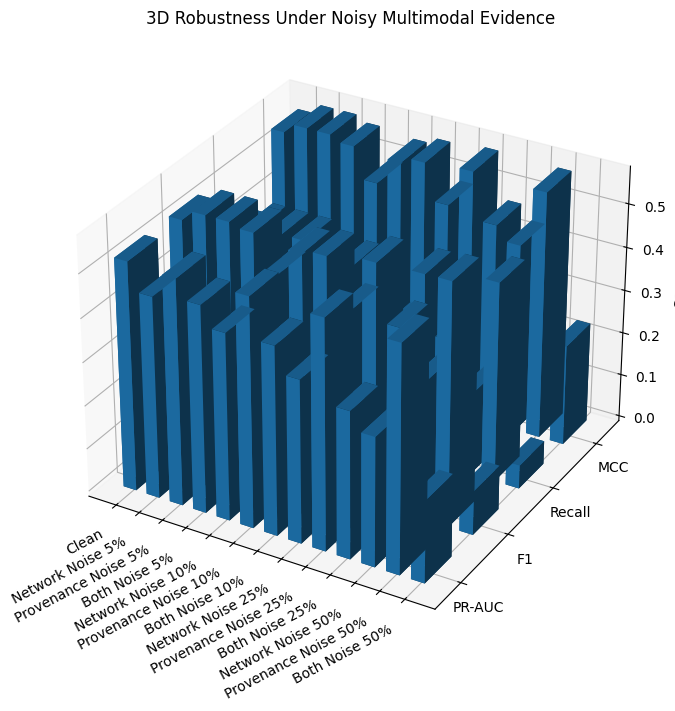

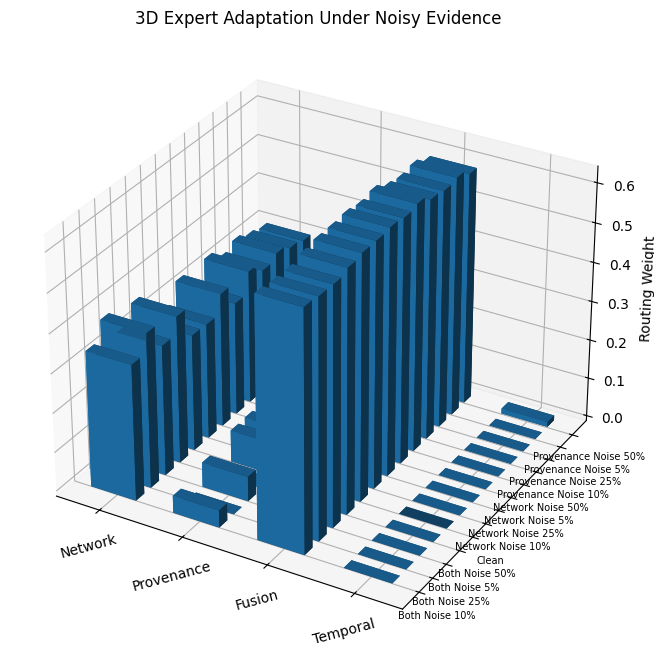

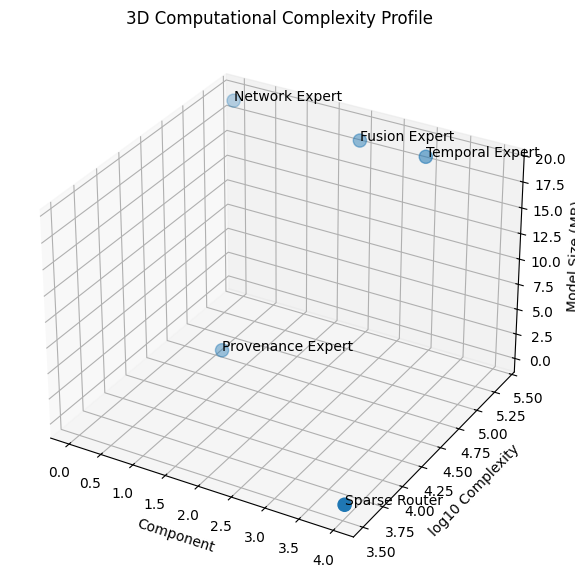

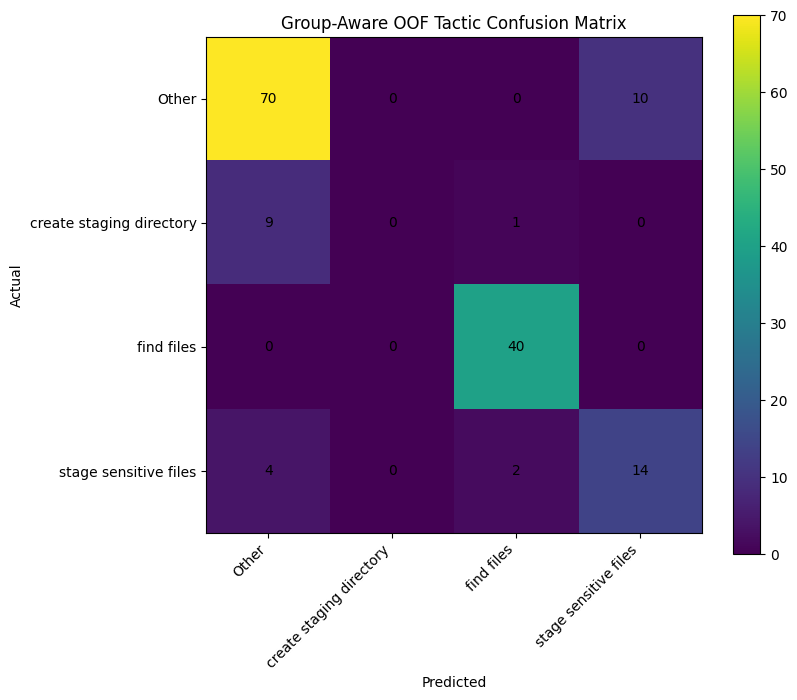

,Binary_PR_AUC,Binary_ROC_AUC,Binary_F1,Binary_Recall,Binary_MCC,Binary_FPR,Router_Parameters,Serialized_Model_MB,Latency_ms_window,Throughput_windows_s,Tactic_Evaluation,Tactic_Best_Model,Tactic_Macro_F1
0,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003,3316,58.7526,0.114,8771.132,group-aware OOF,Network,0.6148



STEP 9 COMPLETE

1. Final binary result


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9985,0.7026,0.75,0.4054,0.5263,0.5259,0.9504,0.5508,0.0003,17959,5,22,15



2. Noisy-evidence robustness


,scenario,pr_auc,roc_auc,f1,recall,mcc,fpr
0,Clean,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003
1,Network Noise 5%,0.4631,0.9558,0.5517,0.4324,0.5734,0.0003
2,Provenance Noise 5%,0.5187,0.9484,0.5517,0.4324,0.5734,0.0003
3,Both Noise 5%,0.4761,0.9581,0.5424,0.4324,0.5601,0.0003
4,Network Noise 10%,0.4299,0.9374,0.4643,0.3514,0.4896,0.0003
5,Provenance Noise 10%,0.5266,0.9476,0.5263,0.4054,0.5508,0.0003
6,Both Noise 10%,0.4340,0.9359,0.5357,0.4054,0.5651,0.0002
7,Network Noise 25%,0.3750,0.9195,0.4314,0.2973,0.4827,0.0002
8,Provenance Noise 25%,0.5275,0.9575,0.5517,0.4324,0.5734,0.0003
9,Both Noise 25%,0.3386,0.9251,0.4231,0.2973,0.4663,0.0002



3. Reliability-aware routing


,relationship,spearman_rho,p_value
0,Network reliability vs Network gate,0.11984,0.00000
1,Provenance reliability vs Provenance gate,0.02045,0.00608
2,Joint reliability vs Fusion gate,0.18204,0.00000



4. Efficiency


,test_windows,mean_end_to_end_seconds,std_seconds,latency_ms_per_window,throughput_windows_per_second,router_parameters,total_serialized_model_mb,cpu_count,gpu
0,18001,2.0523,0.4077,0.114,8771.132,3316,58.7526,2,None



5. Complexity


,component,type,trees,tree_nodes,tree_leaves,neural_parameters,model_size_mb
0,Network Expert,ExtraTrees,220,250710,125465,0,19.213
1,Provenance Expert,ExtraTrees,220,28122,14171,0,2.228
2,Fusion Expert,ExtraTrees,220,242868,121544,0,18.615
3,Temporal Expert,ExtraTrees,180,243956,122068,0,18.680
4,Sparse Router,Neural,0,0,0,3316,0.016



6. Corrected tactic-level OOF


,model,evaluation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc
0,Network,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183
1,Provenance,group-aware OOF,0.3600,0.2469,0.2429,0.2469,0.2392,0.3735,0.0250
2,Fusion,group-aware OOF,0.8267,0.6438,0.5892,0.6438,0.6148,0.8000,0.7183



7. Tactic class-level performance


,class,precision,recall,f1,support
0,Other,0.8434,0.875,0.8589,80
1,create staging directory,0.0000,0.000,0.0000,10
2,find files,0.9302,1.000,0.9639,40
3,stage sensitive files,0.5833,0.700,0.6364,20



Saved reports: /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/reports
Saved tables : /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/paper_tables
Saved figures: /content/drive/MyDrive/IIoT_APT_Research/Step9_Final_Evidence/figures

NEXT: final manuscript result tables, methodology diagram values and Results section.


In [ ]:
# ============================================================
# STEP 9 — FINAL RELIABILITY, EFFICIENCY & EVIDENCE VALIDATION
# ============================================================

from google.colab import drive
import os, json, time, random, platform, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    matthews_corrcoef, confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)
from scipy.stats import spearmanr

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

SEED = 20260924
BENCHMARK_REPEATS = 5
NOISE_LEVELS = [0.05, 0.10, 0.25, 0.50]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")

STEP5 = ROOT / "Step5_Baselines"
STEP7 = ROOT / "Step7_Refined_RMoE"
STEP8 = ROOT / "Step8_Tactic_Statistical_Validation"
STEP9 = ROOT / "Step9_Final_Evidence"

REP = STEP9 / "reports"
FIG = STEP9 / "figures"
TAB = STEP9 / "paper_tables"
PRED = STEP9 / "predictions"

for p in [STEP9, REP, FIG, TAB, PRED]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = STEP5 / "features" / "baseline_dataset.parquet"

STEP7_REPORT = (
    STEP7 /
    "reports" /
    "step7_final_report.json"
)

ROUTER_FILE = (
    STEP7 /
    "models" /
    "final_sparse_20260924.pt"
)

MULTI_FILE = (
    STEP8 /
    "features" /
    "multiclass_dataset.parquet"
)

EXPERT_NAMES = [
    "Network",
    "Provenance",
    "Fusion",
    "Temporal"
]

EXPERT_FILES = {
    name:
        STEP7 /
        "models" /
        f"Expert_{name}.joblib"
    for name in EXPERT_NAMES
}

for p in [
    DATA_FILE,
    STEP7_REPORT,
    ROUTER_FILE,
    MULTI_FILE
]:

    if not p.exists():
        raise FileNotFoundError(str(p))

for p in EXPERT_FILES.values():

    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(obj, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    with open(tmp, "w") as f:

        json.dump(
            obj,
            f,
            indent=2,
            default=str
        )

    os.replace(
        tmp,
        path
    )


def save_parquet(df, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(
        tmp,
        path
    )


def save_fig(fig, name):

    fig.savefig(
        FIG /
        f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG /
        f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def binary_metrics(
    y,
    prob,
    threshold
):

    pred = (
        prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    return {

        "accuracy":
            accuracy_score(
                y,
                pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "pr_auc":
            average_precision_score(
                y,
                prob
            ),

        "roc_auc":
            roc_auc_score(
                y,
                prob
            ),

        "mcc":
            matthews_corrcoef(
                y,
                pred
            ),

        "fpr":
            fp / (
                fp + tn
            ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


base = pd.read_parquet(
    DATA_FILE
).reset_index(
    drop=True
)

report7 = json.load(
    open(STEP7_REPORT)
)

network_cols = [
    c for c in base.columns
    if c.startswith("N_")
]

prov_cols = [
    c for c in base.columns
    if c.startswith("P_")
]

train_mask = (
    base["split"] ==
    "train"
)

test_mask = (
    base["split"] ==
    "test"
)

train_idx = np.where(
    train_mask
)[0]

test_idx = np.where(
    test_mask
)[0]

y_test = (
    base.loc[
        test_mask,
        "binary_label"
    ]
    .astype(int)
    .to_numpy()
)

XN = (
    base[
        network_cols
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

XP = (
    base[
        prov_cols
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


def robust_scale(
    frame
):

    train = frame.loc[
        train_mask
    ]

    med = train.median()

    q25 = train.quantile(
        0.25
    )

    q75 = train.quantile(
        0.75
    )

    scale = (
        q75 - q25
    ) / 1.349

    std = train.std()

    scale = scale.where(
        scale > 1e-9,
        std
    )

    scale = scale.fillna(
        1.0
    )

    scale = scale.where(
        scale > 1e-9,
        1.0
    )

    return med, scale


N_MED, N_SCALE = robust_scale(
    XN
)

P_MED, P_SCALE = robust_scale(
    XP
)


def modality_deviation(
    frame,
    median,
    scale
):

    z = (
        frame
        .subtract(
            median
        )
        .divide(
            scale
        )
        .abs()
    )

    return (
        z.median(
            axis=1,
            skipna=True
        )
        .fillna(0)
    )


N_DEV_TRAIN = modality_deviation(
    XN.loc[
        train_mask
    ],
    N_MED,
    N_SCALE
)

P_DEV_TRAIN = modality_deviation(
    XP.loc[
        train_mask
    ],
    P_MED,
    P_SCALE
)

N_DEV_Q95 = float(
    np.percentile(
        N_DEV_TRAIN,
        95
    )
)

P_DEV_Q95 = float(
    np.percentile(
        P_DEV_TRAIN,
        95
    )
)

N_DEV_SCALE = max(
    float(
        np.std(
            N_DEV_TRAIN
        )
    ),
    0.25
)

P_DEV_SCALE = max(
    float(
        np.std(
            P_DEV_TRAIN
        )
    ),
    0.25
)


def quality_factor(
    frame,
    median,
    scale,
    q95,
    spread
):

    dev = modality_deviation(
        frame,
        median,
        scale
    )

    excess = (
        dev - q95
    ).clip(
        lower=0
    )

    q = np.exp(
        -excess /
        spread
    )

    return np.clip(
        q,
        0,
        1
    )


def build_context(
    meta,
    xn,
    xp,
    quality_n=None,
    quality_p=None
):

    n_avail = (
        xn.notna()
        .mean(axis=1)
        .astype(float)
    )

    p_avail = (
        xp.notna()
        .mean(axis=1)
        .astype(float)
    )

    if "N_packet_count" in xn.columns:

        n_activity = (
            pd.to_numeric(
                xn[
                    "N_packet_count"
                ],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0)
        )

    else:

        n_activity = (
            xn.notna()
            .sum(axis=1)
        )

    p_activity = pd.Series(
        0.0,
        index=xp.index
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in xp.columns:

            p_activity += (
                pd.to_numeric(
                    xp[c],
                    errors="coerce"
                )
                .fillna(0)
                .clip(lower=0)
            )

    n_train_activity = (
        pd.to_numeric(
            XN.loc[
                train_mask,
                "N_packet_count"
            ],
            errors="coerce"
        )
        .fillna(0)
        if "N_packet_count"
        in XN.columns
        else
        XN.loc[
            train_mask
        ].notna().sum(
            axis=1
        )
    )

    p_train_activity = pd.Series(
        0.0,
        index=train_idx
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in XP.columns:

            p_train_activity += (
                pd.to_numeric(
                    XP.loc[
                        train_mask,
                        c
                    ],
                    errors="coerce"
                )
                .fillna(0)
            )

    nq = max(
        float(
            np.percentile(
                n_train_activity,
                95
            )
        ),
        1
    )

    pq = max(
        float(
            np.percentile(
                p_train_activity,
                95
            )
        ),
        1
    )

    na = (
        np.log1p(
            n_activity
        )
        /
        np.log1p(
            nq
        )
    ).clip(
        0,
        1
    )

    pa = (
        np.log1p(
            p_activity
        )
        /
        np.log1p(
            pq
        )
    ).clip(
        0,
        1
    )

    rn = (
        0.70 *
        n_avail
        +
        0.30 *
        na
    )

    rp = (
        0.70 *
        p_avail
        +
        0.30 *
        pa
    )

    if quality_n is not None:

        rn = (
            rn *
            np.asarray(
                quality_n
            )
        )

    if quality_p is not None:

        rp = (
            rp *
            np.asarray(
                quality_p
            )
        )

    ts = (
        pd.to_numeric(
            meta[
                "_window_start"
            ],
            errors="coerce"
        )
        .fillna(0)
    )

    hour = (
        2 *
        np.pi *
        (
            ts % 86400
        )
        /
        86400
    )

    day = (
        2 *
        np.pi *
        (
            np.floor(
                ts / 86400
            ) % 7
        )
        /
        7
    )

    phase2 = (
        meta[
            "_phase"
        ]
        .astype(str)
        .str.lower()
        .eq(
            "phase2"
        )
        .astype(float)
    )

    return pd.DataFrame({

        "R_N":
            np.asarray(rn),

        "R_P":
            np.asarray(rp),

        "N_availability":
            np.asarray(
                n_avail
            ),

        "P_availability":
            np.asarray(
                p_avail
            ),

        "N_activity":
            np.asarray(na),

        "P_activity":
            np.asarray(pa),

        "hour_sin":
            np.sin(hour),

        "hour_cos":
            np.cos(hour),

        "day_sin":
            np.sin(day),

        "day_cos":
            np.cos(day),

        "phase2":
            np.asarray(
                phase2
            )

    }).astype(
        np.float32
    )


class Router(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout,
        sparse=True
    ):

        super().__init__()

        self.sparse = sparse

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                4
            )
        )


    def forward(
        self,
        expert_prob,
        features,
        availability
    ):

        logits = self.net(
            features
        )

        logits = logits.masked_fill(
            availability < 0.5,
            -1e9
        )

        gates = torch.softmax(
            logits,
            dim=1
        )

        if self.sparse:

            values, indices = (
                torch.topk(
                    gates,
                    k=2,
                    dim=1
                )
            )

            sg = torch.zeros_like(
                gates
            )

            sg.scatter_(
                1,
                indices,
                values
            )

            gates = (
                sg /
                (
                    sg.sum(
                        dim=1,
                        keepdim=True
                    )
                    +
                    1e-12
                )
            )

        probability = (
            gates *
            expert_prob
        ).sum(
            dim=1
        )

        return (
            probability,
            gates
        )


router_ckpt = torch.load(
    ROUTER_FILE,
    map_location="cpu",
    weights_only=False
)

router = Router(

    router_ckpt[
        "input_dim"
    ],

    router_ckpt[
        "hidden"
    ],

    router_ckpt[
        "dropout"
    ],

    router_ckpt[
        "sparse"
    ]
)

router.load_state_dict(
    router_ckpt[
        "state_dict"
    ]
)

router.eval()

experts = {
    name:
        joblib.load(
            path
        )
    for name, path
    in EXPERT_FILES.items()
}

prior_name = report7[
    "validation_selected_prior"
]

prior_index = EXPERT_NAMES.index(
    prior_name
)

ALPHA = float(
    report7[
        "representative_alpha"
    ]
)

THRESHOLD = float(
    report7[
        "representative_threshold"
    ]
)


def router_features(
    expert_prob,
    context
):

    p = np.clip(
        expert_prob,
        1e-5,
        1 - 1e-5
    )

    logits = np.log(
        p /
        (
            1 - p
        )
    )

    return np.concatenate(
        [
            logits,
            context.to_numpy(
                dtype=np.float32
            )
        ],
        axis=1
    ).astype(
        np.float32
    )


def availability_mask(
    context
):

    rn = (
        context[
            "R_N"
        ].to_numpy()
        >
        0.02
    )

    rp = (
        context[
            "R_P"
        ].to_numpy()
        >
        0.02
    )

    return np.column_stack(
        [
            rn,
            rp,
            rn & rp,
            np.ones(
                len(context),
                dtype=bool
            )
        ]
    ).astype(
        np.float32
    )


def get_expert_prob(
    meta,
    xn,
    xp,
    context
):

    fusion = pd.concat(
        [
            xn.add_prefix(
                "NRAW_"
            ),
            xp.add_prefix(
                "PRAW_"
            )
        ],
        axis=1
    )

    source = {

        "Network":
            xn,

        "Provenance":
            xp,

        "Fusion":
            fusion,

        "Temporal":
            context
    }

    prob = np.zeros(
        (
            len(meta),
            4
        ),
        dtype=np.float32
    )

    for j, name in enumerate(
        EXPERT_NAMES
    ):

        prob[
            :,
            j
        ] = (
            experts[
                name
            ]
            .predict_proba(
                source[
                    name
                ]
            )[:, 1]
        )

    return prob


def predict_router(
    expert_prob,
    context
):

    rf = router_features(
        expert_prob,
        context
    )

    am = availability_mask(
        context
    )

    with torch.no_grad():

        prob, gates = router(

            torch.tensor(
                expert_prob,
                dtype=torch.float32
            ),

            torch.tensor(
                rf,
                dtype=torch.float32
            ),

            torch.tensor(
                am,
                dtype=torch.float32
            )
        )

    return (
        prob.numpy(),
        gates.numpy()
    )


def final_blend(
    router_prob,
    expert_prob,
    context
):

    rn = (
        context[
            "R_N"
        ].to_numpy()
    )

    rp = (
        context[
            "R_P"
        ].to_numpy()
    )

    if prior_name == "Network":

        reliability = rn

    elif prior_name == "Provenance":

        reliability = rp

    elif prior_name == "Fusion":

        reliability = np.minimum(
            rn,
            rp
        )

    else:

        reliability = np.ones(
            len(rn)
        )

    beta = (
        (1 - ALPHA)
        *
        reliability
    )

    return (

        ALPHA *
        router_prob

        +

        beta *
        expert_prob[
            :,
            prior_index
        ]

    ) / (
        ALPHA +
        beta +
        1e-12
    )


def full_predict(
    meta,
    xn,
    xp,
    quality_n=None,
    quality_p=None
):

    context = build_context(
        meta,
        xn,
        xp,
        quality_n,
        quality_p
    )

    ep = get_expert_prob(
        meta,
        xn,
        xp,
        context
    )

    rp, gates = predict_router(
        ep,
        context
    )

    fp = final_blend(
        rp,
        ep,
        context
    )

    return (
        fp,
        gates,
        ep,
        context
    )


test_meta = (
    base.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)

XN_TEST = (
    XN.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)

XP_TEST = (
    XP.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)


clean_prob, clean_gates, clean_ep, clean_ctx = (
    full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )
)

clean_metrics = binary_metrics(
    y_test,
    clean_prob,
    THRESHOLD
)

print("\n" + "=" * 76)
print("CLEAN FINAL BINARY RESULT")
print("=" * 76)

display(
    pd.DataFrame(
        [
            clean_metrics
        ]
    ).round(4)
)


def add_noise(
    frame,
    scale,
    level,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    x = frame.copy()

    noise = rng.normal(
        0,
        1,
        size=x.shape
    )

    scale_matrix = np.tile(
        scale.to_numpy(),
        (
            len(x),
            1
        )
    )

    values = x.to_numpy(
        dtype=float,
        copy=True
    )

    present = np.isfinite(
        values
    )

    values[
        present
    ] += (
        level *
        scale_matrix[
            present
        ] *
        noise[
            present
        ]
    )

    return pd.DataFrame(
        values,
        columns=x.columns,
        index=x.index
    )


noise_rows = []
route_rows = []

scenarios = [
    (
        "Clean",
        "clean",
        0
    )
]

for level in NOISE_LEVELS:

    scenarios += [

        (
            f"Network Noise {int(level*100)}%",
            "network",
            level
        ),

        (
            f"Provenance Noise {int(level*100)}%",
            "provenance",
            level
        ),

        (
            f"Both Noise {int(level*100)}%",
            "both",
            level
        )
    ]


for i, (
    name,
    mode,
    level
) in enumerate(
    scenarios
):

    xn = XN_TEST.copy()
    xp = XP_TEST.copy()

    qn = None
    qp = None

    if mode in [
        "network",
        "both"
    ]:

        xn = add_noise(
            xn,
            N_SCALE,
            level,
            SEED + i
        )

        qn = quality_factor(
            xn,
            N_MED,
            N_SCALE,
            N_DEV_Q95,
            N_DEV_SCALE
        )

    if mode in [
        "provenance",
        "both"
    ]:

        xp = add_noise(
            xp,
            P_SCALE,
            level,
            SEED + 100 + i
        )

        qp = quality_factor(
            xp,
            P_MED,
            P_SCALE,
            P_DEV_Q95,
            P_DEV_SCALE
        )

    prob, gates, ep, ctx = (
        full_predict(
            test_meta,
            xn,
            xp,
            qn,
            qp
        )
    )

    m = binary_metrics(
        y_test,
        prob,
        THRESHOLD
    )

    noise_rows.append({

        "scenario":
            name,

        "modality":
            mode,

        "noise_level":
            level,

        **m
    })

    for cls, cls_name in [
        (0, "Benign"),
        (1, "Attack")
    ]:

        mask = (
            y_test ==
            cls
        )

        for j, expert in enumerate(
            EXPERT_NAMES
        ):

            route_rows.append({

                "scenario":
                    name,

                "class":
                    cls_name,

                "expert":
                    expert,

                "mean_weight":
                    float(
                        gates[
                            mask,
                            j
                        ].mean()
                    )
            })


noise_df = pd.DataFrame(
    noise_rows
)

route_df = pd.DataFrame(
    route_rows
)

noise_df.to_csv(
    REP /
    "noise_robustness.csv",
    index=False
)

route_df.to_csv(
    REP /
    "noise_routing.csv",
    index=False
)

print("\n" + "=" * 76)
print("NOISY-EVIDENCE ROBUSTNESS")
print("=" * 76)

display(
    noise_df[
        [
            "scenario",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "mcc",
            "fpr"
        ]
    ].round(4)
)


corr_rows = []

tests = [

    (
        "Network reliability vs Network gate",
        clean_ctx[
            "R_N"
        ].to_numpy(),
        clean_gates[
            :,
            0
        ]
    ),

    (
        "Provenance reliability vs Provenance gate",
        clean_ctx[
            "R_P"
        ].to_numpy(),
        clean_gates[
            :,
            1
        ]
    ),

    (
        "Joint reliability vs Fusion gate",
        np.minimum(
            clean_ctx[
                "R_N"
            ].to_numpy(),
            clean_ctx[
                "R_P"
            ].to_numpy()
        ),
        clean_gates[
            :,
            2
        ]
    )
]

for name, a, b in tests:

    rho, pvalue = spearmanr(
        a,
        b
    )

    corr_rows.append({

        "relationship":
            name,

        "spearman_rho":
            rho,

        "p_value":
            pvalue
    })


corr_df = pd.DataFrame(
    corr_rows
)

corr_df.to_csv(
    REP /
    "reliability_routing_correlation.csv",
    index=False
)

print("\nReliability-routing correlations:")
display(
    corr_df.round(5)
)


def gate_entropy(
    gates
):

    g = np.clip(
        gates,
        1e-12,
        1
    )

    return (
        -np.sum(
            g *
            np.log(g),
            axis=1
        )
    )


entropy_rows = []

for scenario in route_df[
    "scenario"
].unique():

    temp = route_df[
        route_df[
            "scenario"
        ] ==
        scenario
    ]

    attack = temp[
        temp[
            "class"
        ] ==
        "Attack"
    ]

    for _, row in (
        attack.iterrows()
    ):

        entropy_rows.append({

            "scenario":
                scenario,

            "expert":
                row[
                    "expert"
                ],

            "attack_weight":
                row[
                    "mean_weight"
                ]
        })


entropy_df = pd.DataFrame(
    entropy_rows
)

entropy_df.to_csv(
    REP /
    "attack_routing_shift.csv",
    index=False
)


router_params = sum(
    p.numel()
    for p in router.parameters()
)

complexity_rows = []

total_model_mb = 0


for name in EXPERT_NAMES:

    path = EXPERT_FILES[
        name
    ]

    size_mb = (
        path.stat().st_size
        /
        (
            1024 ** 2
        )
    )

    total_model_mb += (
        size_mb
    )

    mdl = experts[
        name
    ].named_steps[
        "model"
    ]

    tree_nodes = sum(
        est.tree_.node_count
        for est in mdl.estimators_
    )

    tree_leaves = sum(
        est.tree_.n_leaves
        for est in mdl.estimators_
    )

    complexity_rows.append({

        "component":
            name +
            " Expert",

        "type":
            "ExtraTrees",

        "trees":
            len(
                mdl.estimators_
            ),

        "tree_nodes":
            tree_nodes,

        "tree_leaves":
            tree_leaves,

        "neural_parameters":
            0,

        "model_size_mb":
            size_mb
    })


router_size = (
    ROUTER_FILE.stat().st_size
    /
    (
        1024 ** 2
    )
)

total_model_mb += (
    router_size
)

complexity_rows.append({

    "component":
        "Sparse Router",

    "type":
        "Neural",

    "trees":
        0,

    "tree_nodes":
        0,

    "tree_leaves":
        0,

    "neural_parameters":
        router_params,

    "model_size_mb":
        router_size
})


complexity_df = pd.DataFrame(
    complexity_rows
)

complexity_df.to_csv(
    REP /
    "model_complexity.csv",
    index=False
)


for _ in range(2):

    _ = full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )


times = []

for _ in range(
    BENCHMARK_REPEATS
):

    start = time.perf_counter()

    _ = full_predict(
        test_meta,
        XN_TEST,
        XP_TEST
    )

    times.append(
        time.perf_counter()
        -
        start
    )


mean_time = float(
    np.mean(
        times
    )
)

std_time = float(
    np.std(
        times,
        ddof=1
    )
)

throughput = (
    len(
        test_meta
    )
    /
    mean_time
)

latency_ms = (
    mean_time *
    1000
    /
    len(
        test_meta
    )
)


efficiency_df = pd.DataFrame([{

    "test_windows":
        len(
            test_meta
        ),

    "mean_end_to_end_seconds":
        mean_time,

    "std_seconds":
        std_time,

    "latency_ms_per_window":
        latency_ms,

    "throughput_windows_per_second":
        throughput,

    "router_parameters":
        router_params,

    "total_serialized_model_mb":
        total_model_mb,

    "cpu_count":
        os.cpu_count(),

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )
            if torch.cuda.is_available()
            else
            "None"
        )
}])

efficiency_df.to_csv(
    REP /
    "computational_efficiency.csv",
    index=False
)

print("\n" + "=" * 76)
print("COMPUTATIONAL EFFICIENCY")
print("=" * 76)

display(
    complexity_df.round(3)
)

display(
    efficiency_df.round(4)
)


multi = pd.read_parquet(
    MULTI_FILE
).reset_index(
    drop=True
)

mc_network = [
    c
    for c in multi.columns
    if c.startswith("N_")
]

mc_prov = [
    c
    for c in multi.columns
    if c.startswith("P_")
]

y_mc = (
    multi[
        "y_multi"
    ]
    .astype(int)
    .to_numpy()
)

class_names = (
    multi[
        [
            "y_multi",
            "tactic_final"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "y_multi"
    )[
        "tactic_final"
    ]
    .tolist()
)

if "_group" in multi.columns:

    mc_groups = (
        multi[
            "_group"
        ]
        .astype(str)
        .to_numpy()
    )

else:

    mc_groups = (
        multi[
            "_phase"
        ].astype(str)
        +
        "_"
        +
        np.floor(
            multi[
                "_window_start"
            ]
            /
            60
        )
        .astype(
            "int64"
        )
        .astype(str)
    ).to_numpy()


group_check = (
    pd.DataFrame({

        "class":
            multi[
                "tactic_final"
            ],

        "group":
            mc_groups
    })
    .groupby(
        "class"
    )[
        "group"
    ]
    .nunique()
)


min_groups = int(
    group_check.min()
)

min_samples = int(
    pd.Series(
        y_mc
    )
    .value_counts()
    .min()
)


if min_groups >= 2:

    folds = min(
        5,
        min_groups
    )

    splitter = StratifiedGroupKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    split_iterator = splitter.split(
        np.zeros(
            len(y_mc)
        ),
        y_mc,
        mc_groups
    )

    tactic_mode = (
        "group-aware OOF"
    )

else:

    folds = min(
        5,
        min_samples
    )

    splitter = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    split_iterator = splitter.split(
        np.zeros(
            len(y_mc)
        ),
        y_mc
    )

    tactic_mode = (
        "stratified OOF sensitivity"
    )


MC_SOURCES = {

    "Network":
        multi[
            mc_network
        ],

    "Provenance":
        multi[
            mc_prov
        ],

    "Fusion":
        pd.concat(
            [
                multi[
                    mc_network
                ].add_prefix(
                    "NRAW_"
                ),

                multi[
                    mc_prov
                ].add_prefix(
                    "PRAW_"
                )
            ],
            axis=1
        )
}


K = len(
    np.unique(
        y_mc
    )
)

mc_oof = {
    name:
        np.zeros(
            (
                len(multi),
                K
            ),
            dtype=float
        )
    for name in MC_SOURCES
}


def mc_model(seed):

    return Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                keep_empty_features=True
            )
        ),

        (
            "model",

            ExtraTreesClassifier(
                n_estimators=400,
                max_features="sqrt",
                class_weight=
                    "balanced_subsample",
                n_jobs=-1,
                random_state=seed
            )
        )
    ])


def aligned_probability(
    model,
    X
):

    raw = model.predict_proba(
        X
    )

    classes = (
        model.named_steps[
            "model"
        ].classes_
    )

    out = np.zeros(
        (
            len(X),
            K
        )
    )

    for j, cls in enumerate(
        classes
    ):

        out[
            :,
            int(cls)
        ] = raw[
            :,
            j
        ]

    return out


for fold_no, (
    fit,
    hold
) in enumerate(
    split_iterator,
    1
):

    for j, (
        name,
        X
    ) in enumerate(
        MC_SOURCES.items()
    ):

        model = mc_model(
            SEED +
            100 *
            fold_no +
            j
        )

        model.fit(
            X.iloc[
                fit
            ],
            y_mc[
                fit
            ]
        )

        mc_oof[
            name
        ][
            hold
        ] = aligned_probability(
            model,
            X.iloc[
                hold
            ]
        )

    print(
        f"Tactic OOF fold "
        f"{fold_no}/{folds}"
    )


def multiclass_metrics(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            pred,
            average="macro",
            zero_division=0
        )
    )

    return {

        "accuracy":
            accuracy_score(
                y_true,
                pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "macro_precision":
            precision,

        "macro_recall":
            recall,

        "macro_f1":
            f1,

        "weighted_f1":
            f1_score(
                y_true,
                pred,
                average="weighted",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                pred
            )
    }


mc_rows = []

for name, prob in (
    mc_oof.items()
):

    m = multiclass_metrics(
        y_mc,
        prob
    )

    mc_rows.append({

        "model":
            name,

        "evaluation":
            tactic_mode,

        **m
    })


mc_df = pd.DataFrame(
    mc_rows
)

mc_df.to_csv(
    REP /
    "tactic_oof_results.csv",
    index=False
)

print("\n" + "=" * 76)
print("REPAIRED TACTIC-LEVEL EVALUATION")
print("=" * 76)

print(
    "Evaluation:",
    tactic_mode
)

print(
    "Folds:",
    folds
)

display(
    pd.DataFrame({

        "class":
            group_check.index,

        "unique_temporal_groups":
            group_check.values
    })
)

display(
    mc_df.round(4)
)


best_mc_name = (
    mc_df.sort_values(
        "macro_f1",
        ascending=False
    )
    .iloc[0][
        "model"
    ]
)

best_mc_prob = (
    mc_oof[
        best_mc_name
    ]
)

best_mc_pred = np.argmax(
    best_mc_prob,
    axis=1
)

mc_class_report = (
    classification_report(
        y_mc,
        best_mc_pred,
        labels=np.arange(K),
        target_names=
            class_names,
        output_dict=True,
        zero_division=0
    )
)

mc_class_rows = []

for name in class_names:

    r = mc_class_report[
        name
    ]

    mc_class_rows.append({

        "class":
            name,

        "precision":
            r[
                "precision"
            ],

        "recall":
            r[
                "recall"
            ],

        "f1":
            r[
                "f1-score"
            ],

        "support":
            int(
                r[
                    "support"
                ]
            )
    })


mc_class_df = pd.DataFrame(
    mc_class_rows
)

mc_class_df.to_csv(
    REP /
    "tactic_oof_per_class.csv",
    index=False
)


fig = plt.figure(
    figsize=(14, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

plot_metrics = [
    "pr_auc",
    "f1",
    "recall",
    "mcc"
]

p = noise_df.copy()

x = np.repeat(
    np.arange(
        len(p)
    ),
    len(
        plot_metrics
    )
)

yy = np.tile(
    np.arange(
        len(
            plot_metrics
        )
    ),
    len(p)
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = (
    p[
        plot_metrics
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(p)
    )
    +
    0.27
)

ax.set_xticklabels(
    p[
        "scenario"
    ],
    rotation=28,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(
            plot_metrics
        )
    )
    +
    0.27
)

ax.set_yticklabels([
    "PR-AUC",
    "F1",
    "Recall",
    "MCC"
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Robustness Under Noisy Multimodal Evidence"
)

save_fig(
    fig,
    "Fig_9A_3D_Noise_Robustness"
)


attack_routes = (
    route_df[
        route_df[
            "class"
        ] ==
        "Attack"
    ]
    .pivot(
        index="scenario",
        columns="expert",
        values="mean_weight"
    )
    .reindex(
        columns=
            EXPERT_NAMES
    )
)

fig = plt.figure(
    figsize=(13, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

arr = attack_routes.to_numpy()

x = np.tile(
    np.arange(
        arr.shape[1]
    ),
    arr.shape[0]
)

yy = np.repeat(
    np.arange(
        arr.shape[0]
    ),
    arr.shape[1]
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = arr.reshape(
    -1
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            EXPERT_NAMES
        )
    )
    +
    0.27
)

ax.set_xticklabels(
    EXPERT_NAMES,
    rotation=15
)

ax.set_yticks(
    np.arange(
        len(
            attack_routes
        )
    )
    +
    0.27
)

ax.set_yticklabels(
    attack_routes.index,
    fontsize=7
)

ax.set_zlabel(
    "Routing Weight"
)

ax.set_title(
    "3D Expert Adaptation Under Noisy Evidence"
)

save_fig(
    fig,
    "Fig_9B_3D_Noise_Routing"
)


fig = plt.figure(
    figsize=(10, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

comp = complexity_df.copy()

x = np.arange(
    len(comp)
)

y_complexity = np.log10(
    comp[
        "tree_nodes"
    ]
    +
    comp[
        "neural_parameters"
    ]
    +
    1
)

z_size = (
    comp[
        "model_size_mb"
    ]
)

ax.scatter(
    x,
    y_complexity,
    z_size,
    s=90
)

for i, row in (
    comp.iterrows()
):

    ax.text(
        i,
        y_complexity.iloc[i],
        z_size.iloc[i],
        row[
            "component"
        ]
    )

ax.set_xlabel(
    "Component"
)

ax.set_ylabel(
    "log10 Complexity"
)

ax.set_zlabel(
    "Model Size (MB)"
)

ax.set_title(
    "3D Computational Complexity Profile"
)

save_fig(
    fig,
    "Fig_9C_3D_Complexity"
)


cm = confusion_matrix(
    y_mc,
    best_mc_pred,
    labels=np.arange(K)
)

fig, ax = plt.subplots(
    figsize=(
        max(
            8,
            K * 1.3
        ),
        max(
            7,
            K
        )
    )
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    np.arange(K)
)

ax.set_yticks(
    np.arange(K)
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    "Group-Aware OOF Tactic Confusion Matrix"
)

for i in range(K):

    for j in range(K):

        ax.text(
            j,
            i,
            cm[
                i,
                j
            ],
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

save_fig(
    fig,
    "Fig_9D_Tactic_OOF_Confusion"
)


noise_df.to_latex(
    TAB /
    "Table_9A_Noise_Robustness.tex",
    index=False,
    float_format="%.4f"
)

complexity_df.to_latex(
    TAB /
    "Table_9B_Model_Complexity.tex",
    index=False,
    float_format="%.3f"
)

efficiency_df.to_latex(
    TAB /
    "Table_9C_Computational_Efficiency.tex",
    index=False,
    float_format="%.4f"
)

corr_df.to_latex(
    TAB /
    "Table_9D_Reliability_Routing.tex",
    index=False,
    float_format="%.5f"
)

mc_df.to_latex(
    TAB /
    "Table_9E_Tactic_OOF.tex",
    index=False,
    float_format="%.4f"
)


paper_master = pd.DataFrame([{

    "Binary_PR_AUC":
        clean_metrics[
            "pr_auc"
        ],

    "Binary_ROC_AUC":
        clean_metrics[
            "roc_auc"
        ],

    "Binary_F1":
        clean_metrics[
            "f1"
        ],

    "Binary_Recall":
        clean_metrics[
            "recall"
        ],

    "Binary_MCC":
        clean_metrics[
            "mcc"
        ],

    "Binary_FPR":
        clean_metrics[
            "fpr"
        ],

    "Router_Parameters":
        router_params,

    "Serialized_Model_MB":
        total_model_mb,

    "Latency_ms_window":
        latency_ms,

    "Throughput_windows_s":
        throughput,

    "Tactic_Evaluation":
        tactic_mode,

    "Tactic_Best_Model":
        best_mc_name,

    "Tactic_Macro_F1":
        float(
            mc_df.loc[
                mc_df[
                    "model"
                ] ==
                best_mc_name,
                "macro_f1"
            ].iloc[0]
        )
}])

paper_master.to_csv(
    REP /
    "paper_master_results.csv",
    index=False
)

display(
    paper_master.round(4)
)


environment = {

    "python":
        platform.python_version(),

    "platform":
        platform.platform(),

    "cpu_count":
        os.cpu_count(),

    "torch":
        torch.__version__,

    "cuda_available":
        torch.cuda.is_available(),

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )
            if torch.cuda.is_available()
            else None
        ),

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    environment,
    REP /
    "execution_environment.json"
)


final_report = {

    "paper_focus":
        (
            "Reliability-aware multimodal "
            "mixture-of-experts for IIoT "
            "APT detection"
        ),

    "binary_clean":
        clean_metrics,

    "noise_scenarios":
        len(
            noise_df
        ),

    "reliability_routing":
        corr_rows,

    "router_parameters":
        router_params,

    "serialized_model_mb":
        total_model_mb,

    "latency_ms_per_window":
        latency_ms,

    "throughput_windows_per_second":
        throughput,

    "tactic_validation":
        tactic_mode,

    "tactic_folds":
        folds,

    "tactic_best_model":
        best_mc_name,

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    REP /
    "step9_final_report.json"
)

(
    STEP9 /
    "STEP9_COMPLETE.txt"
).write_text(

    "STEP 9 COMPLETE\n"

    f"Binary PR-AUC: "
    f"{clean_metrics['pr_auc']:.4f}\n"

    f"Binary F1: "
    f"{clean_metrics['f1']:.4f}\n"

    f"Noise scenarios: "
    f"{len(noise_df)}\n"

    f"Tactic validation: "
    f"{tactic_mode}\n"

    f"Latency ms/window: "
    f"{latency_ms:.4f}\n"
)


print("\n" + "=" * 76)
print("STEP 9 COMPLETE")
print("=" * 76)

print("\n1. Final binary result")
display(
    pd.DataFrame(
        [
            clean_metrics
        ]
    ).round(4)
)

print("\n2. Noisy-evidence robustness")
display(
    noise_df[
        [
            "scenario",
            "pr_auc",
            "roc_auc",
            "f1",
            "recall",
            "mcc",
            "fpr"
        ]
    ].round(4)
)

print("\n3. Reliability-aware routing")
display(
    corr_df.round(5)
)

print("\n4. Efficiency")
display(
    efficiency_df.round(4)
)

print("\n5. Complexity")
display(
    complexity_df.round(3)
)

print("\n6. Corrected tactic-level OOF")
display(
    mc_df.round(4)
)

print("\n7. Tactic class-level performance")
display(
    mc_class_df.round(4)
)

print("\nSaved reports:", REP)
print("Saved tables :", TAB)
print("Saved figures:", FIG)

print(
    "\nNEXT: final manuscript result tables, "
    "methodology diagram values and Results section."
)

STEP 10 INPUT
Rows: 119,896
Train: 83,923 | positives: 159
Validation: 17,972 | positives: 33
Test: 18,001 | positives: 37

Selected network features: 20
Selected provenance features: 8

Creating causal multiscale features...

Creating OOF expert predictions...
OOF fold 1/3
OOF fold 2/3
OOF fold 3/3

Expert performance:


,expert,threshold,val_pr_auc,val_f1,val_recall,test_pr_auc,test_f1,test_recall,test_mcc
0,NetworkTemporal,0.0900,0.4104,0.4000,0.5152,0.4169,0.4731,0.5946,0.4820
1,ProvenanceTemporal,0.9777,0.0331,0.0500,0.0303,0.0459,0.0930,0.0541,0.1336
2,FusionTemporal,0.7359,0.2791,0.4242,0.6364,0.2127,0.3750,0.4865,0.3837
3,CurrentFusion,0.2368,0.5125,0.5283,0.4242,0.4444,0.4643,0.3514,0.4896



Learned reliability:


,expert,mean_train_reliability,mean_validation_reliability,validation_quality_correlation
0,NetworkTemporal,0.9208,0.9197,0.3442
1,ProvenanceTemporal,0.8028,0.7829,0.9489
2,FusionTemporal,0.8841,0.8912,0.1620
3,CurrentFusion,0.9285,0.9267,0.2982



Router device: cpu

VALIDATION-ONLY ROUTER SEARCH
ECMT_A | PR-AUC: 0.4404 | F1: 0.5588 | Recall: 0.5758
ECMT_B | PR-AUC: 0.3742 | F1: 0.506 | Recall: 0.6364
ECMT_C | PR-AUC: 0.3763 | F1: 0.506 | Recall: 0.6364
ECMT_D | PR-AUC: 0.3749 | F1: 0.506 | Recall: 0.6364


,configuration,validation_score,pr_auc,f1,recall,mcc
0,ECMT_A,0.5080,0.4404,0.5588,0.5758,0.5582
1,ECMT_C,0.4687,0.3763,0.5060,0.6364,0.5159
2,ECMT_D,0.4681,0.3749,0.5060,0.6364,0.5159
3,ECMT_B,0.4677,0.3742,0.5060,0.6364,0.5159



Validation-selected prior: CurrentFusion

REPEATED-SEED FINAL MODEL
Seed 20260924 | PR-AUC=0.5273 | F1=0.4762 | Recall=0.4054 | MCC=0.4827
Seed 20260925 | PR-AUC=0.5201 | F1=0.4762 | Recall=0.4054 | MCC=0.4827
Seed 20260926 | PR-AUC=0.5108 | F1=0.4762 | Recall=0.4054 | MCC=0.4827
Seed 20260927 | PR-AUC=0.5267 | F1=0.4762 | Recall=0.4054 | MCC=0.4827
Seed 20260928 | PR-AUC=0.5246 | F1=0.4762 | Recall=0.4054 | MCC=0.4827


,seed,validation_score,alpha,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,20260924,0.5080,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5273,0.9891,0.4827,0.0006,17953,11,22,15
1,20260925,0.5017,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5201,0.9922,0.4827,0.0006,17953,11,22,15
2,20260926,0.4882,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5108,0.9891,0.4827,0.0006,17953,11,22,15
3,20260927,0.5126,0.4,0.4218,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5267,0.9924,0.4827,0.0006,17953,11,22,15
4,20260928,0.5003,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5246,0.9890,0.4827,0.0006,17953,11,22,15



Mean ± SD:


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998167,1.241267e-16,0.998167,0.998167,0.9982 ± 0.0000
1,balanced_accuracy,0.702397,0.000000e+00,0.702397,0.702397,0.7024 ± 0.0000
2,precision,0.576923,0.000000e+00,0.576923,0.576923,0.5769 ± 0.0000
3,recall,0.405405,0.000000e+00,0.405405,0.405405,0.4054 ± 0.0000
4,specificity,0.999388,1.241267e-16,0.999388,0.999388,0.9994 ± 0.0000
5,f1,0.476190,0.000000e+00,0.476190,0.476190,0.4762 ± 0.0000
6,pr_auc,0.521899,6.835474e-03,0.513412,0.530387,0.5219 ± 0.0068
7,roc_auc,0.990350,1.786875e-03,0.988132,0.992569,0.9904 ± 0.0018
8,mcc,0.482741,6.206335e-17,0.482741,0.482741,0.4827 ± 0.0000
9,fpr,0.000612,0.000000e+00,0.000612,0.000612,0.0006 ± 0.0000



Reliability-aware routing:


,class,expert,mean_gate,mean_learned_reliability
0,Benign,NetworkTemporal,0.9853,0.9190
1,Benign,ProvenanceTemporal,0.0022,0.7824
2,Benign,FusionTemporal,0.0046,0.8893
3,Benign,CurrentFusion,0.0079,0.9252
4,APT,NetworkTemporal,0.3104,0.3241
5,APT,ProvenanceTemporal,0.0746,0.4523
6,APT,FusionTemporal,0.5050,0.7712
7,APT,CurrentFusion,0.1100,0.4468



Previous vs enhanced model:


,model,accuracy,pr_auc,roc_auc,f1,recall,mcc,fpr,balanced_accuracy,precision,specificity,tn,fp,fn,tp
0,Previous R-MoE,NaN,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EC-MT-RMoE,0.9982,0.5267,0.9924,0.4762,0.4054,0.4827,0.0006,0.7024,0.5769,0.9994,17953.0,11.0,22.0,15.0


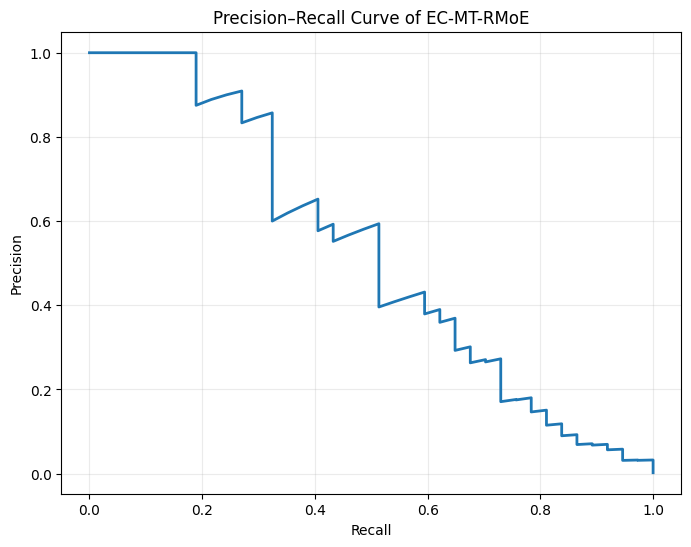

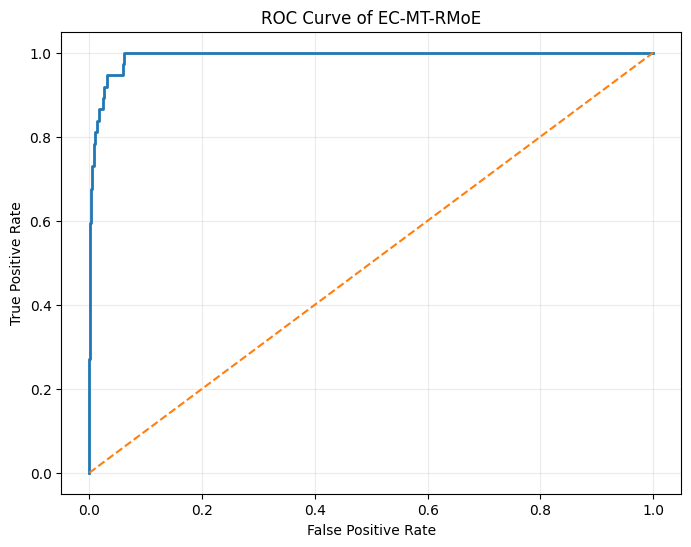

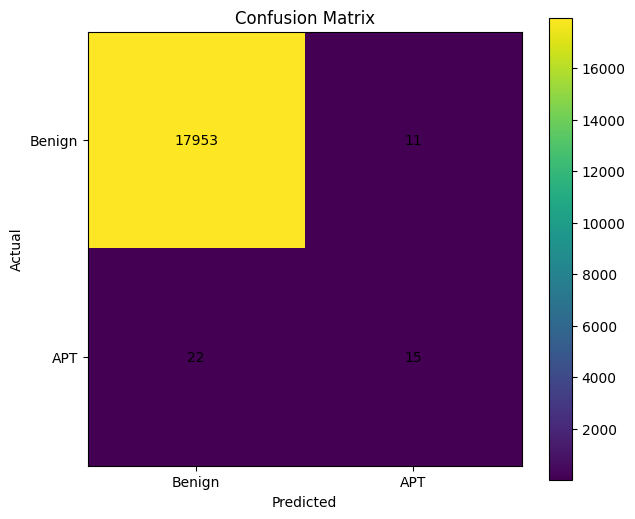

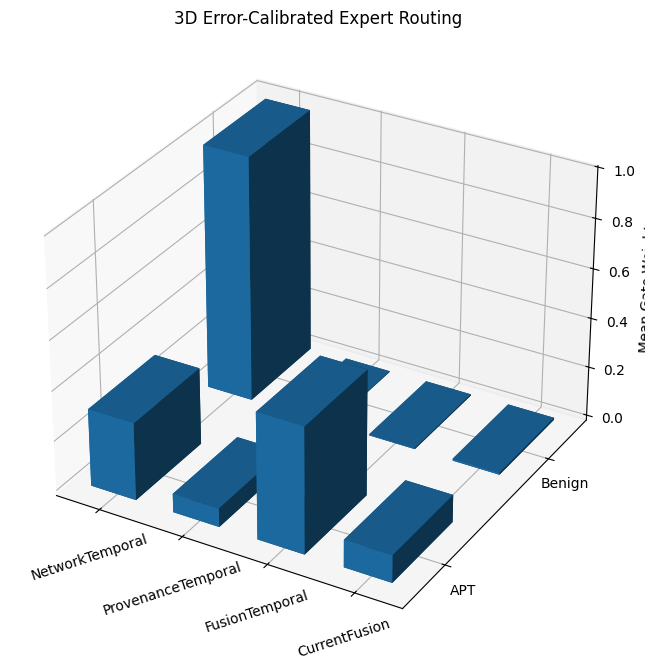

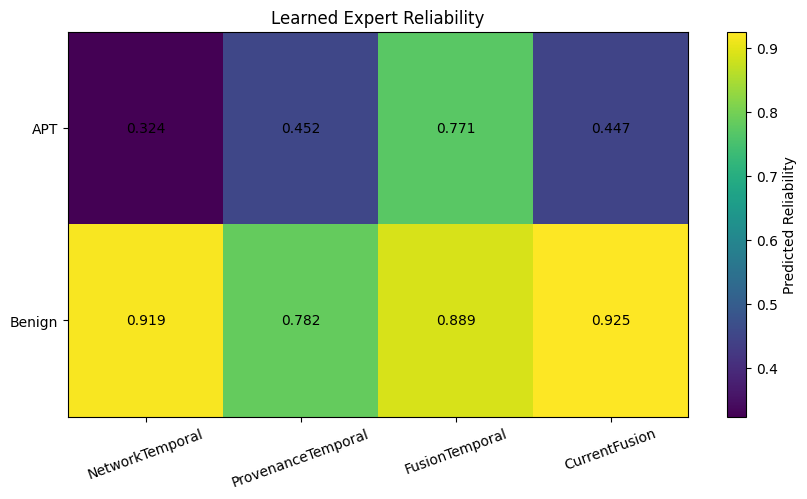

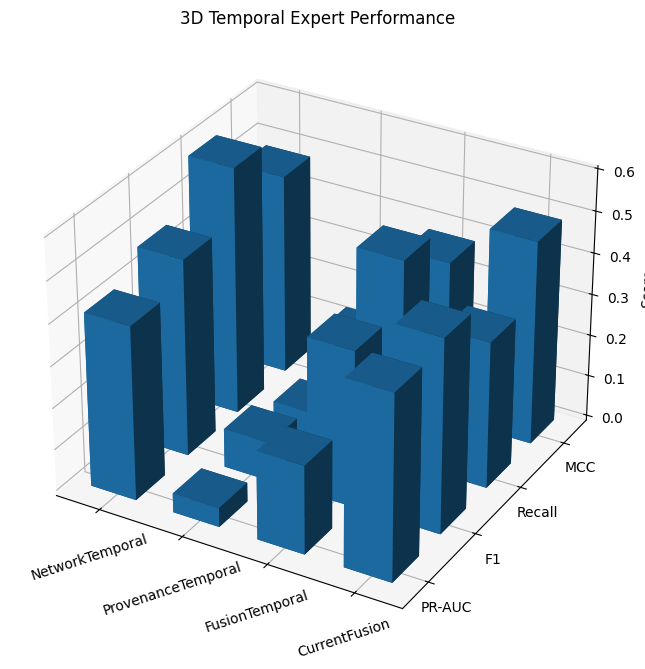


STEP 10 COMPLETE
Selected router: ECMT_A
Selected prior: CurrentFusion
Representative seed: 20260927
Blend alpha: 0.4

FINAL TEST RESULT


,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5267,0.9924,0.4827,0.0006,17953,11,22,15



EXPERT RESULTS


,expert,threshold,val_pr_auc,val_f1,val_recall,test_pr_auc,test_f1,test_recall,test_mcc
0,NetworkTemporal,0.0900,0.4104,0.4000,0.5152,0.4169,0.4731,0.5946,0.4820
1,ProvenanceTemporal,0.9777,0.0331,0.0500,0.0303,0.0459,0.0930,0.0541,0.1336
2,FusionTemporal,0.7359,0.2791,0.4242,0.6364,0.2127,0.3750,0.4865,0.3837
3,CurrentFusion,0.2368,0.5125,0.5283,0.4242,0.4444,0.4643,0.3514,0.4896



LEARNED RELIABILITY


,expert,mean_train_reliability,mean_validation_reliability,validation_quality_correlation
0,NetworkTemporal,0.9208,0.9197,0.3442
1,ProvenanceTemporal,0.8028,0.7829,0.9489
2,FusionTemporal,0.8841,0.8912,0.1620
3,CurrentFusion,0.9285,0.9267,0.2982



ROUTING


,class,expert,mean_gate,mean_learned_reliability
0,Benign,NetworkTemporal,0.9853,0.9190
1,Benign,ProvenanceTemporal,0.0022,0.7824
2,Benign,FusionTemporal,0.0046,0.8893
3,Benign,CurrentFusion,0.0079,0.9252
4,APT,NetworkTemporal,0.3104,0.3241
5,APT,ProvenanceTemporal,0.0746,0.4523
6,APT,FusionTemporal,0.5050,0.7712
7,APT,CurrentFusion,0.1100,0.4468



REPEATED SEEDS


,seed,validation_score,alpha,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,20260924,0.5080,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5273,0.9891,0.4827,0.0006,17953,11,22,15
1,20260925,0.5017,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5201,0.9922,0.4827,0.0006,17953,11,22,15
2,20260926,0.4882,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5108,0.9891,0.4827,0.0006,17953,11,22,15
3,20260927,0.5126,0.4,0.4218,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5267,0.9924,0.4827,0.0006,17953,11,22,15
4,20260928,0.5003,0.4,0.4237,0.9982,0.7024,0.5769,0.4054,0.9994,0.4762,0.5246,0.9890,0.4827,0.0006,17953,11,22,15



MEAN ± SD / CI


,metric,mean,std,ci95_low,ci95_high,paper_value
0,accuracy,0.998167,1.241267e-16,0.998167,0.998167,0.9982 ± 0.0000
1,balanced_accuracy,0.702397,0.000000e+00,0.702397,0.702397,0.7024 ± 0.0000
2,precision,0.576923,0.000000e+00,0.576923,0.576923,0.5769 ± 0.0000
3,recall,0.405405,0.000000e+00,0.405405,0.405405,0.4054 ± 0.0000
4,specificity,0.999388,1.241267e-16,0.999388,0.999388,0.9994 ± 0.0000
5,f1,0.476190,0.000000e+00,0.476190,0.476190,0.4762 ± 0.0000
6,pr_auc,0.521899,6.835474e-03,0.513412,0.530387,0.5219 ± 0.0068
7,roc_auc,0.990350,1.786875e-03,0.988132,0.992569,0.9904 ± 0.0018
8,mcc,0.482741,6.206335e-17,0.482741,0.482741,0.4827 ± 0.0000
9,fpr,0.000612,0.000000e+00,0.000612,0.000612,0.0006 ± 0.0000



OLD VS NEW


,model,accuracy,pr_auc,roc_auc,f1,recall,mcc,fpr,balanced_accuracy,precision,specificity,tn,fp,fn,tp
0,Previous R-MoE,NaN,0.5259,0.9504,0.5263,0.4054,0.5508,0.0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EC-MT-RMoE,0.9982,0.5267,0.9924,0.4762,0.4054,0.4827,0.0006,0.7024,0.5769,0.9994,17953.0,11.0,22.0,15.0



Saved models : /content/drive/MyDrive/IIoT_APT_Research/Step10_EC_MT_RMoE/models
Saved reports: /content/drive/MyDrive/IIoT_APT_Research/Step10_EC_MT_RMoE/reports
Saved figures: /content/drive/MyDrive/IIoT_APT_Research/Step10_EC_MT_RMoE/figures


In [ ]:
# ============================================================
# STEP 10 — ERROR-CALIBRATED MULTISCALE TEMPORAL R-MoE
# ============================================================

from google.colab import drive
import os, json, math, random, copy, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler
)

warnings.filterwarnings("ignore")

SEED = 20260924

FINAL_SEEDS = [
    20260924,
    20260925,
    20260926,
    20260927,
    20260928
]

OOF_FOLDS = 3
TOP_N_NETWORK = 20
TOP_N_PROVENANCE = 8

MAX_EPOCHS = 80
PATIENCE = 10
TOP_K = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/IIoT_APT_Research"
)

STEP5 = ROOT / "Step5_Baselines"
STEP9 = ROOT / "Step9_Final_Evidence"
STEP10 = ROOT / "Step10_EC_MT_RMoE"

FEATURE_DIR = STEP10 / "features"
MODEL_DIR = STEP10 / "models"
OOF_DIR = STEP10 / "oof"
REP_DIR = STEP10 / "reports"
PRED_DIR = STEP10 / "predictions"
FIG_DIR = STEP10 / "figures"

for p in [
    STEP10,
    FEATURE_DIR,
    MODEL_DIR,
    OOF_DIR,
    REP_DIR,
    PRED_DIR,
    FIG_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )

DATA_FILE = (
    STEP5 /
    "features" /
    "baseline_dataset.parquet"
)

OLD_RESULT_FILE = (
    STEP9 /
    "reports" /
    "paper_master_results.csv"
)

TEMPORAL_FILE = (
    FEATURE_DIR /
    "multiscale_temporal_features.parquet"
)

SELECTED_FILE = (
    REP_DIR /
    "selected_base_features.json"
)

OOF_FILE = (
    OOF_DIR /
    "expert_oof.npz"
)

EXPERT_RESULT_FILE = (
    REP_DIR /
    "expert_results.csv"
)

RELIABILITY_FILE = (
    REP_DIR /
    "reliability_results.csv"
)

SEARCH_FILE = (
    REP_DIR /
    "router_search.csv"
)

SEED_FILE = (
    REP_DIR /
    "final_seed_results.csv"
)

STAT_FILE = (
    REP_DIR /
    "mean_std_ci.csv"
)

COMPARISON_FILE = (
    REP_DIR /
    "step9_vs_step10.csv"
)

ROUTING_FILE = (
    REP_DIR /
    "expert_routing.csv"
)

FINAL_REPORT = (
    REP_DIR /
    "step10_final_report.json"
)

DONE_FILE = (
    STEP10 /
    "STEP10_COMPLETE.txt"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        DATA_FILE
    )


def save_json(x, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    with open(tmp, "w") as f:
        json.dump(
            x,
            f,
            indent=2,
            default=str
        )

    os.replace(
        tmp,
        path
    )


def save_parquet(df, path):

    tmp = Path(
        str(path) + ".tmp"
    )

    df.to_parquet(
        tmp,
        index=False,
        compression="snappy"
    )

    os.replace(
        tmp,
        path
    )


def save_fig(fig, name):

    fig.savefig(
        FIG_DIR /
        f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG_DIR /
        f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


def metrics(
    y,
    prob,
    threshold
):

    pred = (
        prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    specificity = (
        tn / (tn + fp)
        if tn + fp > 0
        else 0
    )

    fpr = (
        fp / (fp + tn)
        if fp + tn > 0
        else 0
    )

    return {

        "accuracy":
            float(
                accuracy_score(
                    y,
                    pred
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y,
                    pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "specificity":
            float(
                specificity
            ),

        "f1":
            float(
                f1_score(
                    y,
                    pred,
                    zero_division=0
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y,
                    prob
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y,
                    prob
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y,
                    pred
                )
            ),

        "fpr":
            float(
                fpr
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


def threshold_search(
    y,
    prob
):

    thresholds = np.unique(
        np.quantile(
            prob,
            np.linspace(
                0.70,
                0.9998,
                350
            )
        )
    )

    best = None

    for th in thresholds:

        m = metrics(
            y,
            prob,
            th
        )

        penalty = (
            25 *
            max(
                m["fpr"] -
                0.005,
                0
            )
        )

        score = (
            0.45 *
            m["f1"]
            +
            0.25 *
            m["recall"]
            +
            0.15 *
            m["precision"]
            +
            0.15 *
            max(
                m["mcc"],
                0
            )
            -
            penalty
        )

        item = {
            "threshold":
                float(th),

            "score":
                float(score),

            "metrics":
                m
        }

        if (
            best is None
            or
            item["score"]
            >
            best["score"]
        ):

            best = item

    return best


data = pd.read_parquet(
    DATA_FILE
).reset_index(
    drop=True
)

network_cols = [
    c
    for c in data.columns
    if c.startswith("N_")
]

provenance_cols = [
    c
    for c in data.columns
    if c.startswith("P_")
]

for c in (
    network_cols +
    provenance_cols
):

    data[c] = (
        pd.to_numeric(
            data[c],
            errors="coerce"
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )


if "_group" not in data.columns:

    data["_group"] = (

        data[
            "_phase"
        ].astype(str)

        +

        "_"

        +

        np.floor(
            data[
                "_window_start"
            ]
            /
            60
        )
        .astype(
            "int64"
        )
        .astype(str)
    )


train_mask = (
    data["split"] ==
    "train"
)

val_mask = (
    data["split"] ==
    "validation"
)

test_mask = (
    data["split"] ==
    "test"
)

train_idx = np.where(
    train_mask
)[0]

val_idx = np.where(
    val_mask
)[0]

test_idx = np.where(
    test_mask
)[0]

y = (
    data[
        "binary_label"
    ]
    .astype(int)
    .to_numpy()
)

y_train = y[
    train_idx
]

y_val = y[
    val_idx
]

y_test = y[
    test_idx
]

print("=" * 76)
print("STEP 10 INPUT")
print("=" * 76)

print(
    "Rows:",
    f"{len(data):,}"
)

print(
    "Train:",
    f"{len(train_idx):,}",
    "| positives:",
    int(
        y_train.sum()
    )
)

print(
    "Validation:",
    f"{len(val_idx):,}",
    "| positives:",
    int(
        y_val.sum()
    )
)

print(
    "Test:",
    f"{len(test_idx):,}",
    "| positives:",
    int(
        y_test.sum()
    )
)


def select_features(
    cols,
    top_n,
    seed
):

    X = data.loc[
        train_mask,
        cols
    ]

    model = Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                keep_empty_features=True
            )
        ),

        (
            "model",

            ExtraTreesClassifier(
                n_estimators=250,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight=
                    "balanced_subsample",
                n_jobs=-1,
                random_state=seed
            )
        )
    ])

    model.fit(
        X,
        y_train
    )

    imp = (
        model.named_steps[
            "model"
        ]
        .feature_importances_
    )

    order = np.argsort(
        imp
    )[::-1]

    selected = [
        cols[i]
        for i in order[
            :min(
                top_n,
                len(cols)
            )
        ]
    ]

    ranking = pd.DataFrame({

        "feature":
            cols,

        "importance":
            imp
    }).sort_values(
        "importance",
        ascending=False
    )

    return (
        selected,
        ranking
    )


if SELECTED_FILE.exists():

    selected = json.load(
        open(
            SELECTED_FILE
        )
    )

    selected_n = (
        selected[
            "network"
        ]
    )

    selected_p = (
        selected[
            "provenance"
        ]
    )

else:

    selected_n, rank_n = (
        select_features(
            network_cols,
            TOP_N_NETWORK,
            SEED
        )
    )

    selected_p, rank_p = (
        select_features(
            provenance_cols,
            TOP_N_PROVENANCE,
            SEED + 1
        )
    )

    rank_n.to_csv(
        REP_DIR /
        "network_feature_importance.csv",
        index=False
    )

    rank_p.to_csv(
        REP_DIR /
        "provenance_feature_importance.csv",
        index=False
    )

    save_json(
        {
            "network":
                selected_n,

            "provenance":
                selected_p
        },
        SELECTED_FILE
    )


print(
    "\nSelected network features:",
    len(selected_n)
)

print(
    "Selected provenance features:",
    len(selected_p)
)


def temporal_expand(
    df,
    cols
):

    work = (
        df[
            [
                "_group",
                "_window_start"
            ]
            +
            cols
        ]
        .copy()
    )

    work["_original_index"] = (
        work.index
    )

    work = work.sort_values(
        [
            "_group",
            "_window_start"
        ]
    )

    result = pd.DataFrame(
        index=work.index
    )

    for c in cols:

        s = work[c]

        g = work.groupby(
            "_group",
            sort=False
        )[c]

        l1 = g.shift(1)
        l2 = g.shift(2)
        l3 = g.shift(3)
        l4 = g.shift(4)
        l5 = g.shift(5)

        result[
            c
        ] = s

        result[
            c + "__lag1"
        ] = l1

        result[
            c + "__lag2"
        ] = l2

        result[
            c + "__lag3"
        ] = l3

        result[
            c + "__delta1"
        ] = (
            s - l1
        )

        result[
            c + "__trend3"
        ] = (
            s - l2
        )

        block3 = pd.concat(
            [
                s,
                l1,
                l2
            ],
            axis=1
        )

        block6 = pd.concat(
            [
                s,
                l1,
                l2,
                l3,
                l4,
                l5
            ],
            axis=1
        )

        result[
            c + "__mean3"
        ] = block3.mean(
            axis=1
        )

        result[
            c + "__std3"
        ] = block3.std(
            axis=1
        )

        result[
            c + "__mean6"
        ] = block6.mean(
            axis=1
        )

        result[
            c + "__max6"
        ] = block6.max(
            axis=1
        )

    result[
        "_original_index"
    ] = (
        work[
            "_original_index"
        ]
    )

    result = (
        result
        .set_index(
            "_original_index"
        )
        .sort_index()
    )

    return result.astype(
        np.float32
    )


if TEMPORAL_FILE.exists():

    temp = pd.read_parquet(
        TEMPORAL_FILE
    )

else:

    print(
        "\nCreating causal multiscale features..."
    )

    t_n = temporal_expand(
        data,
        selected_n
    )

    t_p = temporal_expand(
        data,
        selected_p
    )

    t_n.columns = [
        "TN_" + c
        for c in t_n.columns
    ]

    t_p.columns = [
        "TP_" + c
        for c in t_p.columns
    ]

    temp = pd.concat(
        [
            t_n,
            t_p
        ],
        axis=1
    )

    save_parquet(
        temp,
        TEMPORAL_FILE
    )


TN_COLS = [
    c
    for c in temp.columns
    if c.startswith("TN_")
]

TP_COLS = [
    c
    for c in temp.columns
    if c.startswith("TP_")
]


def build_context(
    df,
    temp
):

    n_avail = (
        df[
            network_cols
        ]
        .notna()
        .mean(axis=1)
    )

    p_avail = (
        df[
            provenance_cols
        ]
        .notna()
        .mean(axis=1)
    )

    if "N_packet_count" in df:

        n_activity = (
            pd.to_numeric(
                df[
                    "N_packet_count"
                ],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0)
        )

    else:

        n_activity = (
            df[
                network_cols
            ]
            .notna()
            .sum(axis=1)
        )

    p_activity = pd.Series(
        0.0,
        index=df.index
    )

    for c in [
        "P_node_count",
        "P_edge_count"
    ]:

        if c in df:

            p_activity += (
                pd.to_numeric(
                    df[c],
                    errors="coerce"
                )
                .fillna(0)
                .clip(lower=0)
            )

    nq = max(
        float(
            np.percentile(
                n_activity[
                    train_mask
                ],
                95
            )
        ),
        1
    )

    pq = max(
        float(
            np.percentile(
                p_activity[
                    train_mask
                ],
                95
            )
        ),
        1
    )

    na = (
        np.log1p(
            n_activity
        )
        /
        np.log1p(
            nq
        )
    ).clip(
        0,
        1
    )

    pa = (
        np.log1p(
            p_activity
        )
        /
        np.log1p(
            pq
        )
    ).clip(
        0,
        1
    )

    rn = (
        0.70 *
        n_avail
        +
        0.30 *
        na
    )

    rp = (
        0.70 *
        p_avail
        +
        0.30 *
        pa
    )

    n_delta_cols = [
        c
        for c in TN_COLS
        if c.endswith(
            "__delta1"
        )
    ]

    p_delta_cols = [
        c
        for c in TP_COLS
        if c.endswith(
            "__delta1"
        )
    ]

    n_change = (
        temp[
            n_delta_cols
        ]
        .abs()
        .median(
            axis=1,
            skipna=True
        )
        .fillna(0)
    )

    p_change = (
        temp[
            p_delta_cols
        ]
        .abs()
        .median(
            axis=1,
            skipna=True
        )
        .fillna(0)
    )

    n_change_q = max(
        float(
            np.percentile(
                n_change[
                    train_mask
                ],
                95
            )
        ),
        1e-6
    )

    p_change_q = max(
        float(
            np.percentile(
                p_change[
                    train_mask
                ],
                95
            )
        ),
        1e-6
    )

    n_change = (
        n_change /
        n_change_q
    ).clip(
        0,
        1
    )

    p_change = (
        p_change /
        p_change_q
    ).clip(
        0,
        1
    )

    ts = (
        pd.to_numeric(
            df[
                "_window_start"
            ],
            errors="coerce"
        )
        .fillna(0)
    )

    hour_angle = (
        2 *
        np.pi *
        (
            ts % 86400
        )
        /
        86400
    )

    day_angle = (
        2 *
        np.pi *
        (
            np.floor(
                ts / 86400
            )
            % 7
        )
        /
        7
    )

    phase2 = (
        df[
            "_phase"
        ]
        .astype(str)
        .str.lower()
        .eq("phase2")
        .astype(float)
    )

    return pd.DataFrame({

        "R_N_base":
            rn,

        "R_P_base":
            rp,

        "N_availability":
            n_avail,

        "P_availability":
            p_avail,

        "N_activity":
            na,

        "P_activity":
            pa,

        "N_temporal_change":
            n_change,

        "P_temporal_change":
            p_change,

        "hour_sin":
            np.sin(
                hour_angle
            ),

        "hour_cos":
            np.cos(
                hour_angle
            ),

        "day_sin":
            np.sin(
                day_angle
            ),

        "day_cos":
            np.cos(
                day_angle
            ),

        "phase2":
            phase2

    }).astype(
        np.float32
    )


CTX = build_context(
    data,
    temp
)


CURRENT_FUSION = pd.concat(
    [
        data[
            selected_n
        ].add_prefix(
            "CN_"
        ),

        data[
            selected_p
        ].add_prefix(
            "CP_"
        )
    ],
    axis=1
)

NETWORK_TEMPORAL = temp[
    TN_COLS
]

PROV_TEMPORAL = temp[
    TP_COLS
]

FUSION_TEMPORAL = pd.concat(
    [
        NETWORK_TEMPORAL,
        PROV_TEMPORAL
    ],
    axis=1
)


EXPERT_NAMES = [
    "NetworkTemporal",
    "ProvenanceTemporal",
    "FusionTemporal",
    "CurrentFusion"
]

EXPERT_DATA = {

    "NetworkTemporal":
        NETWORK_TEMPORAL,

    "ProvenanceTemporal":
        PROV_TEMPORAL,

    "FusionTemporal":
        FUSION_TEMPORAL,

    "CurrentFusion":
        CURRENT_FUSION
}


def make_expert(
    name,
    seed
):

    if name == "FusionTemporal":

        return (
            "hgb",
            HistGradientBoostingClassifier(
                learning_rate=0.045,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=15,
                l2_regularization=0.20,
                random_state=seed
            )
        )

    return (
        "et",
        Pipeline([

            (
                "imputer",

                SimpleImputer(
                    strategy="median",
                    keep_empty_features=True
                )
            ),

            (
                "model",

                ExtraTreesClassifier(
                    n_estimators=400,
                    max_features="sqrt",
                    min_samples_leaf=1,
                    class_weight=
                        "balanced_subsample",
                    n_jobs=-1,
                    random_state=seed
                )
            )
        ])
    )


def fit_expert(
    name,
    X,
    y_fit,
    indices,
    seed
):

    kind, model = make_expert(
        name,
        seed
    )

    Xfit = X.iloc[
        indices
    ]

    if kind == "hgb":

        weights = (
            compute_sample_weight(
                class_weight=
                    "balanced",
                y=y_fit
            )
        )

        model.fit(
            Xfit,
            y_fit,
            sample_weight=
                weights
        )

    else:

        model.fit(
            Xfit,
            y_fit
        )

    return model


groups_train = (
    data.loc[
        train_mask,
        "_group"
    ]
    .astype(str)
    .to_numpy()
)


try:

    splitter = StratifiedGroupKFold(
        n_splits=OOF_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    folds = list(
        splitter.split(
            np.zeros(
                len(train_idx)
            ),
            y_train,
            groups_train
        )
    )

except Exception:

    splitter = StratifiedKFold(
        n_splits=OOF_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    folds = list(
        splitter.split(
            np.zeros(
                len(train_idx)
            ),
            y_train
        )
    )


if OOF_FILE.exists():

    saved = np.load(
        OOF_FILE
    )

    oof = saved[
        "oof"
    ]

else:

    oof = np.zeros(
        (
            len(train_idx),
            len(
                EXPERT_NAMES
            )
        ),
        dtype=np.float32
    )

    print(
        "\nCreating OOF expert predictions..."
    )

    for fold_no, (
        fit_local,
        hold_local
    ) in enumerate(
        folds,
        1
    ):

        fit_global = (
            train_idx[
                fit_local
            ]
        )

        hold_global = (
            train_idx[
                hold_local
            ]
        )

        for j, name in enumerate(
            EXPERT_NAMES
        ):

            model = fit_expert(
                name,
                EXPERT_DATA[
                    name
                ],
                y[
                    fit_global
                ],
                fit_global,
                SEED +
                fold_no *
                10 +
                j
            )

            oof[
                hold_local,
                j
            ] = (
                model.predict_proba(
                    EXPERT_DATA[
                        name
                    ].iloc[
                        hold_global
                    ]
                )[:, 1]
            )

        print(
            f"OOF fold "
            f"{fold_no}/"
            f"{len(folds)}"
        )

    np.savez_compressed(
        OOF_FILE,
        oof=oof
    )


val_prob = np.zeros(
    (
        len(val_idx),
        len(
            EXPERT_NAMES
        )
    ),
    dtype=np.float32
)

test_prob = np.zeros(
    (
        len(test_idx),
        len(
            EXPERT_NAMES
        )
    ),
    dtype=np.float32
)

final_experts = {}

expert_rows = []

for j, name in enumerate(
    EXPERT_NAMES
):

    model_file = (
        MODEL_DIR /
        f"{name}.joblib"
    )

    if model_file.exists():

        model = joblib.load(
            model_file
        )

    else:

        model = fit_expert(
            name,
            EXPERT_DATA[
                name
            ],
            y_train,
            train_idx,
            SEED +
            100 +
            j
        )

        joblib.dump(
            model,
            model_file
        )

    final_experts[
        name
    ] = model

    val_prob[
        :,
        j
    ] = (
        model.predict_proba(
            EXPERT_DATA[
                name
            ].iloc[
                val_idx
            ]
        )[:, 1]
    )

    test_prob[
        :,
        j
    ] = (
        model.predict_proba(
            EXPERT_DATA[
                name
            ].iloc[
                test_idx
            ]
        )[:, 1]
    )

    th_info = threshold_search(
        y_val,
        val_prob[
            :,
            j
        ]
    )

    vm = th_info[
        "metrics"
    ]

    tm = metrics(
        y_test,
        test_prob[
            :,
            j
        ],
        th_info[
            "threshold"
        ]
    )

    expert_rows.append({

        "expert":
            name,

        "threshold":
            th_info[
                "threshold"
            ],

        "val_pr_auc":
            vm[
                "pr_auc"
            ],

        "val_f1":
            vm[
                "f1"
            ],

        "val_recall":
            vm[
                "recall"
            ],

        "test_pr_auc":
            tm[
                "pr_auc"
            ],

        "test_f1":
            tm[
                "f1"
            ],

        "test_recall":
            tm[
                "recall"
            ],

        "test_mcc":
            tm[
                "mcc"
            ]
    })


expert_df = pd.DataFrame(
    expert_rows
)

expert_df.to_csv(
    EXPERT_RESULT_FILE,
    index=False
)

print("\nExpert performance:")
display(
    expert_df.round(4)
)


def reliability_features(
    probs,
    ctx,
    expert_index
):

    p = np.clip(
        probs[
            :,
            expert_index
        ],
        1e-6,
        1 - 1e-6
    )

    confidence = (
        np.abs(
            p -
            0.5
        )
        *
        2
    )

    entropy = -(
        p *
        np.log(p)
        +
        (
            1 - p
        )
        *
        np.log(
            1 - p
        )
    )

    disagreement = (
        np.mean(
            np.abs(
                probs
                -
                p[
                    :,
                    None
                ]
            ),
            axis=1
        )
    )

    mean_prob = probs.mean(
        axis=1
    )

    spread = probs.std(
        axis=1
    )

    return np.column_stack(
        [
            p,
            confidence,
            entropy,
            disagreement,
            mean_prob,
            spread,
            ctx
        ]
    ).astype(
        np.float32
    )


CTX_TRAIN = (
    CTX.iloc[
        train_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)

CTX_VAL = (
    CTX.iloc[
        val_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)

CTX_TEST = (
    CTX.iloc[
        test_idx
    ]
    .to_numpy(
        dtype=np.float32
    )
)


train_rel = np.zeros_like(
    oof
)

val_rel = np.zeros_like(
    val_prob
)

test_rel = np.zeros_like(
    test_prob
)

reliability_rows = []

balanced_weights = (
    compute_sample_weight(
        class_weight=
            "balanced",
        y=y_train
    )
)


for j, name in enumerate(
    EXPERT_NAMES
):

    model_file = (
        MODEL_DIR /
        f"Reliability_{name}.joblib"
    )

    Rtr = reliability_features(
        oof,
        CTX_TRAIN,
        j
    )

    Rv = reliability_features(
        val_prob,
        CTX_VAL,
        j
    )

    Rt = reliability_features(
        test_prob,
        CTX_TEST,
        j
    )

    target = (
        1.0
        -
        np.abs(
            y_train
            -
            oof[
                :,
                j
            ]
        )
    )

    if model_file.exists():

        rel_model = joblib.load(
            model_file
        )

    else:

        rel_model = (
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=180,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                l2_regularization=0.2,
                random_state=
                    SEED +
                    200 +
                    j
            )
        )

        rel_model.fit(
            Rtr,
            target,
            sample_weight=
                balanced_weights
        )

        joblib.dump(
            rel_model,
            model_file
        )

    train_rel[
        :,
        j
    ] = np.clip(
        rel_model.predict(
            Rtr
        ),
        0.02,
        1
    )

    val_rel[
        :,
        j
    ] = np.clip(
        rel_model.predict(
            Rv
        ),
        0.02,
        1
    )

    test_rel[
        :,
        j
    ] = np.clip(
        rel_model.predict(
            Rt
        ),
        0.02,
        1
    )

    actual_quality = (
        1.0
        -
        np.abs(
            y_val
            -
            val_prob[
                :,
                j
            ]
        )
    )

    corr = np.corrcoef(
        val_rel[
            :,
            j
        ],
        actual_quality
    )[0, 1]

    reliability_rows.append({

        "expert":
            name,

        "mean_train_reliability":
            train_rel[
                :,
                j
            ].mean(),

        "mean_validation_reliability":
            val_rel[
                :,
                j
            ].mean(),

        "validation_quality_correlation":
            corr
    })


reliability_df = pd.DataFrame(
    reliability_rows
)

reliability_df.to_csv(
    RELIABILITY_FILE,
    index=False
)

print("\nLearned reliability:")
display(
    reliability_df.round(4)
)


def router_features(
    probs,
    reliability,
    context
):

    p = np.clip(
        probs,
        1e-5,
        1 - 1e-5
    )

    logits = np.log(
        p /
        (
            1 - p
        )
    )

    disagreement = np.column_stack(
        [
            np.mean(
                np.abs(
                    probs
                    -
                    probs[
                        :,
                        j:j+1
                    ]
                ),
                axis=1
            )
            for j in range(
                probs.shape[1]
            )
        ]
    )

    return np.concatenate(
        [
            logits,
            reliability,
            disagreement,
            context
        ],
        axis=1
    ).astype(
        np.float32
    )


X_ROUTER_TRAIN = router_features(
    oof,
    train_rel,
    CTX_TRAIN
)

X_ROUTER_VAL = router_features(
    val_prob,
    val_rel,
    CTX_VAL
)

X_ROUTER_TEST = router_features(
    test_prob,
    test_rel,
    CTX_TEST
)


class ReliabilityRouter(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        dropout,
        reliability_strength
    ):

        super().__init__()

        self.reliability_strength = (
            reliability_strength
        )

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                hidden
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden,
                len(
                    EXPERT_NAMES
                )
            )
        )


    def forward(
        self,
        expert_prob,
        reliability,
        x
    ):

        logits = self.net(
            x
        )

        logits = (
            logits
            +
            self.reliability_strength
            *
            torch.log(
                reliability.clamp(
                    min=1e-5
                )
            )
        )

        gates = torch.softmax(
            logits,
            dim=1
        )

        vals, idx = torch.topk(
            gates,
            k=TOP_K,
            dim=1
        )

        sparse = torch.zeros_like(
            gates
        )

        sparse.scatter_(
            1,
            idx,
            vals
        )

        gates = (
            sparse
            /
            (
                sparse.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-12
            )
        )

        prob = (
            gates *
            expert_prob
        ).sum(
            dim=1
        )

        return (
            prob,
            gates
        )


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "\nRouter device:",
    device
)


def predict_router(
    model,
    probs,
    reliability,
    features
):

    model.eval()

    with torch.no_grad():

        p, g = model(

            torch.tensor(
                probs,
                dtype=torch.float32,
                device=device
            ),

            torch.tensor(
                reliability,
                dtype=torch.float32,
                device=device
            ),

            torch.tensor(
                features,
                dtype=torch.float32,
                device=device
            )
        )

    return (
        p.cpu().numpy(),
        g.cpu().numpy()
    )


def train_router(
    config,
    seed,
    tag
):

    set_seed(
        seed
    )

    model_path = (
        MODEL_DIR /
        f"{tag}.pt"
    )

    result_path = (
        REP_DIR /
        f"{tag}.json"
    )

    model = ReliabilityRouter(

        X_ROUTER_TRAIN.shape[1],

        config[
            "hidden"
        ],

        config[
            "dropout"
        ],

        config[
            "rel_strength"
        ]

    ).to(
        device
    )

    positive = max(
        int(
            y_train.sum()
        ),
        1
    )

    negative = max(
        len(
            y_train
        )
        -
        positive,
        1
    )

    pos_weight = min(
        np.sqrt(
            negative /
            positive
        ),
        25
    )

    hardness = (
        oof.max(
            axis=1
        )
    )

    sample_weight = np.where(

        y_train == 1,

        pos_weight,

        (
            1.0
            +
            4.0 *
            hardness
        )
    )

    dataset = TensorDataset(

        torch.tensor(
            oof,
            dtype=torch.float32
        ),

        torch.tensor(
            train_rel,
            dtype=torch.float32
        ),

        torch.tensor(
            X_ROUTER_TRAIN,
            dtype=torch.float32
        ),

        torch.tensor(
            y_train,
            dtype=torch.float32
        )
    )

    sampler = WeightedRandomSampler(

        torch.tensor(
            sample_weight,
            dtype=torch.double
        ),

        len(
            sample_weight
        ),

        replacement=True
    )

    loader = DataLoader(

        dataset,

        batch_size=
            config[
                "batch_size"
            ],

        sampler=sampler,

        num_workers=0
    )

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=
            config["lr"],

        weight_decay=
            config[
                "weight_decay"
            ]
    )

    best_score = -1
    best_state = None
    best_threshold = 0.5
    best_metrics = None
    stale = 0
    history = []

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        model.train()

        losses = []

        for ep, rel, xr, yy in loader:

            ep = ep.to(
                device
            )

            rel = rel.to(
                device
            )

            xr = xr.to(
                device
            )

            yy = yy.to(
                device
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            prob, gates = model(
                ep,
                rel,
                xr
            )

            prob = prob.clamp(
                1e-6,
                1 - 1e-6
            )

            weights = torch.where(

                yy > 0.5,

                torch.full_like(
                    yy,
                    pos_weight
                ),

                torch.ones_like(
                    yy
                )
            )

            cls_loss = (
                F.binary_cross_entropy(
                    prob,
                    yy,
                    weight=weights
                )
            )

            usage = gates.mean(
                dim=0
            )

            balance = (
                (
                    usage
                    -
                    1 /
                    len(
                        EXPERT_NAMES
                    )
                ) ** 2
            ).mean()

            loss = (
                cls_loss
                +
                config[
                    "balance"
                ]
                *
                balance
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5
            )

            optimizer.step()

            losses.append(
                loss.item()
            )

        vp, vg = predict_router(
            model,
            val_prob,
            val_rel,
            X_ROUTER_VAL
        )

        th_info = threshold_search(
            y_val,
            vp
        )

        vm = th_info[
            "metrics"
        ]

        score = (
            0.45 *
            vm[
                "pr_auc"
            ]
            +
            0.25 *
            vm[
                "f1"
            ]
            +
            0.15 *
            vm[
                "recall"
            ]
            +
            0.15 *
            max(
                vm[
                    "mcc"
                ],
                0
            )
        )

        history.append({

            "epoch":
                epoch,

            "loss":
                np.mean(
                    losses
                ),

            "validation_score":
                score,

            "pr_auc":
                vm[
                    "pr_auc"
                ],

            "f1":
                vm[
                    "f1"
                ],

            "recall":
                vm[
                    "recall"
                ],

            "mcc":
                vm[
                    "mcc"
                ],

            "threshold":
                th_info[
                    "threshold"
                ]
        })

        if (
            score >
            best_score +
            1e-5
        ):

            best_score = score

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_threshold = (
                th_info[
                    "threshold"
                ]
            )

            best_metrics = vm

            stale = 0

        else:

            stale += 1

        if stale >= PATIENCE:
            break


    model.load_state_dict(
        best_state
    )

    torch.save({

        "state_dict":
            best_state,

        "config":
            config,

        "seed":
            seed,

        "threshold":
            best_threshold,

        "input_dim":
            X_ROUTER_TRAIN.shape[1]

    }, model_path)

    pd.DataFrame(
        history
    ).to_csv(
        REP_DIR /
        f"{tag}_history.csv",
        index=False
    )

    result = {

        "tag":
            tag,

        "seed":
            seed,

        "validation_score":
            best_score,

        "threshold":
            best_threshold,

        "validation":
            best_metrics,

        "config":
            config
    }

    save_json(
        result,
        result_path
    )

    return (
        model,
        result
    )


CONFIGS = [

    {
        "name":
            "ECMT_A",

        "hidden":
            32,

        "dropout":
            0.05,

        "rel_strength":
            0.50,

        "lr":
            8e-4,

        "weight_decay":
            1e-4,

        "balance":
            0.005,

        "batch_size":
            2048
    },

    {
        "name":
            "ECMT_B",

        "hidden":
            48,

        "dropout":
            0.08,

        "rel_strength":
            1.00,

        "lr":
            5e-4,

        "weight_decay":
            1e-4,

        "balance":
            0.010,

        "batch_size":
            2048
    },

    {
        "name":
            "ECMT_C",

        "hidden":
            64,

        "dropout":
            0.10,

        "rel_strength":
            1.50,

        "lr":
            3e-4,

        "weight_decay":
            2e-4,

        "balance":
            0.010,

        "batch_size":
            2048
    },

    {
        "name":
            "ECMT_D",

        "hidden":
            64,

        "dropout":
            0.15,

        "rel_strength":
            2.00,

        "lr":
            2e-4,

        "weight_decay":
            2e-4,

        "balance":
            0.015,

        "batch_size":
            2048
    }
]


print("\n" + "=" * 76)
print("VALIDATION-ONLY ROUTER SEARCH")
print("=" * 76)

search_rows = []

for cfg in CONFIGS:

    model, result = train_router(

        cfg,

        SEED,

        "search_" +
        cfg["name"]
    )

    search_rows.append({

        "configuration":
            cfg[
                "name"
            ],

        "validation_score":
            result[
                "validation_score"
            ],

        "pr_auc":
            result[
                "validation"
            ][
                "pr_auc"
            ],

        "f1":
            result[
                "validation"
            ][
                "f1"
            ],

        "recall":
            result[
                "validation"
            ][
                "recall"
            ],

        "mcc":
            result[
                "validation"
            ][
                "mcc"
            ]
    })

    print(
        cfg[
            "name"
        ],
        "| PR-AUC:",
        round(
            result[
                "validation"
            ][
                "pr_auc"
            ],
            4
        ),
        "| F1:",
        round(
            result[
                "validation"
            ][
                "f1"
            ],
            4
        ),
        "| Recall:",
        round(
            result[
                "validation"
            ][
                "recall"
            ],
            4
        )
    )


search_df = (
    pd.DataFrame(
        search_rows
    )
    .sort_values(
        "validation_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

search_df.to_csv(
    SEARCH_FILE,
    index=False
)

display(
    search_df.round(4)
)

best_config_name = (
    search_df.iloc[0][
        "configuration"
    ]
)

best_config = next(

    c
    for c in CONFIGS

    if c[
        "name"
    ] ==
    best_config_name
)


expert_val_scores = []

for j, name in enumerate(
    EXPERT_NAMES
):

    th = threshold_search(
        y_val,
        val_prob[
            :,
            j
        ]
    )

    m = th[
        "metrics"
    ]

    score = (
        0.50 *
        m[
            "pr_auc"
        ]
        +
        0.30 *
        m[
            "f1"
        ]
        +
        0.20 *
        m[
            "recall"
        ]
    )

    expert_val_scores.append(
        score
    )


prior_index = int(
    np.argmax(
        expert_val_scores
    )
)

prior_name = (
    EXPERT_NAMES[
        prior_index
    ]
)

print(
    "\nValidation-selected prior:",
    prior_name
)


def blend_search(
    router_prob,
    prior_prob
):

    best = None

    for alpha in np.linspace(
        0,
        1,
        21
    ):

        p = (
            alpha *
            router_prob

            +

            (
                1 - alpha
            )
            *
            prior_prob
        )

        th = threshold_search(
            y_val,
            p
        )

        m = th[
            "metrics"
        ]

        score = (
            0.45 *
            m[
                "pr_auc"
            ]
            +
            0.25 *
            m[
                "f1"
            ]
            +
            0.15 *
            m[
                "recall"
            ]
            +
            0.15 *
            max(
                m[
                    "mcc"
                ],
                0
            )
        )

        candidate = {

            "alpha":
                alpha,

            "threshold":
                th[
                    "threshold"
                ],

            "score":
                score,

            "metrics":
                m
        }

        if (
            best is None
            or
            candidate[
                "score"
            ]
            >
            best[
                "score"
            ]
        ):

            best = candidate

    return best


seed_rows = []
seed_payloads = []


print("\n" + "=" * 76)
print("REPEATED-SEED FINAL MODEL")
print("=" * 76)

for seed in FINAL_SEEDS:

    model, result = train_router(

        best_config,

        seed,

        (
            "final_" +
            str(seed)
        )
    )

    vp, vg = predict_router(
        model,
        val_prob,
        val_rel,
        X_ROUTER_VAL
    )

    tp, tg = predict_router(
        model,
        test_prob,
        test_rel,
        X_ROUTER_TEST
    )

    blend = blend_search(
        vp,
        val_prob[
            :,
            prior_index
        ]
    )

    final_test_prob = (

        blend[
            "alpha"
        ]
        *
        tp

        +

        (
            1 -
            blend[
                "alpha"
            ]
        )
        *
        test_prob[
            :,
            prior_index
        ]
    )

    tm = metrics(

        y_test,

        final_test_prob,

        blend[
            "threshold"
        ]
    )

    seed_rows.append({

        "seed":
            seed,

        "validation_score":
            result[
                "validation_score"
            ],

        "alpha":
            blend[
                "alpha"
            ],

        "threshold":
            blend[
                "threshold"
            ],

        **tm
    })

    seed_payloads.append({

        "seed":
            seed,

        "validation_score":
            result[
                "validation_score"
            ],

        "prob":
            final_test_prob,

        "gates":
            tg,

        "router":
            model,

        "alpha":
            blend[
                "alpha"
            ],

        "threshold":
            blend[
                "threshold"
            ],

        "metrics":
            tm
    })

    print(
        f"Seed {seed} | "
        f"PR-AUC={tm['pr_auc']:.4f} | "
        f"F1={tm['f1']:.4f} | "
        f"Recall={tm['recall']:.4f} | "
        f"MCC={tm['mcc']:.4f}"
    )


seed_df = pd.DataFrame(
    seed_rows
)

seed_df.to_csv(
    SEED_FILE,
    index=False
)

display(
    seed_df.round(4)
)


representative = max(
    seed_payloads,
    key=lambda x:
        x[
            "validation_score"
        ]
)


stats = []

for metric in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "pr_auc",
    "roc_auc",
    "mcc",
    "fpr"
]:

    values = (
        seed_df[
            metric
        ]
        .astype(float)
        .to_numpy()
    )

    mean = values.mean()

    sd = values.std(
        ddof=1
    )

    ci = (
        2.776445 *
        sd /
        np.sqrt(
            len(values)
        )
    )

    stats.append({

        "metric":
            metric,

        "mean":
            mean,

        "std":
            sd,

        "ci95_low":
            mean -
            ci,

        "ci95_high":
            mean +
            ci,

        "paper_value":
            f"{mean:.4f} ± "
            f"{sd:.4f}"
    })


stats_df = pd.DataFrame(
    stats
)

stats_df.to_csv(
    STAT_FILE,
    index=False
)

print("\nMean ± SD:")
display(
    stats_df
)


routing_rows = []

for cls, label in [
    (0, "Benign"),
    (1, "APT")
]:

    mask = (
        y_test ==
        cls
    )

    for j, name in enumerate(
        EXPERT_NAMES
    ):

        routing_rows.append({

            "class":
                label,

            "expert":
                name,

            "mean_gate":
                representative[
                    "gates"
                ][
                    mask,
                    j
                ].mean(),

            "mean_learned_reliability":
                test_rel[
                    mask,
                    j
                ].mean()
        })


routing_df = pd.DataFrame(
    routing_rows
)

routing_df.to_csv(
    ROUTING_FILE,
    index=False
)

print("\nReliability-aware routing:")
display(
    routing_df.round(4)
)


pred_df = pd.DataFrame({

    "_window_id":
        data.loc[
            test_mask,
            "_window_id"
        ].to_numpy(),

    "y_true":
        y_test,

    "probability":
        representative[
            "prob"
        ],

    "prediction":
        (
            representative[
                "prob"
            ]
            >=
            representative[
                "threshold"
            ]
        ).astype(int)
})

for j, name in enumerate(
    EXPERT_NAMES
):

    pred_df[
        "gate_" +
        name
    ] = (
        representative[
            "gates"
        ][
            :,
            j
        ]
    )

    pred_df[
        "reliability_" +
        name
    ] = (
        test_rel[
            :,
            j
        ]
    )


save_parquet(
    pred_df,
    PRED_DIR /
    "final_test_predictions.parquet"
)


new_result = pd.DataFrame([{

    "model":
        "EC-MT-RMoE",

    **representative[
        "metrics"
    ]
}])


if OLD_RESULT_FILE.exists():

    old = pd.read_csv(
        OLD_RESULT_FILE
    )

    old_row = pd.DataFrame([{

        "model":
            "Previous R-MoE",

        "accuracy":
            old[
                "Binary_PR_AUC"
            ].index.map(
                lambda x:
                np.nan
            )[0],

        "pr_auc":
            old[
                "Binary_PR_AUC"
            ].iloc[0],

        "roc_auc":
            old[
                "Binary_ROC_AUC"
            ].iloc[0],

        "f1":
            old[
                "Binary_F1"
            ].iloc[0],

        "recall":
            old[
                "Binary_Recall"
            ].iloc[0],

        "mcc":
            old[
                "Binary_MCC"
            ].iloc[0],

        "fpr":
            old[
                "Binary_FPR"
            ].iloc[0]
    }])

    comparison = pd.concat(
        [
            old_row,
            new_result
        ],
        ignore_index=True,
        sort=False
    )

else:

    comparison = new_result


comparison.to_csv(
    COMPARISON_FILE,
    index=False
)

print("\nPrevious vs enhanced model:")
display(
    comparison.round(4)
)


p, r, _ = precision_recall_curve(
    y_test,
    representative[
        "prob"
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    r,
    p,
    linewidth=2
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_title(
    "Precision–Recall Curve of EC-MT-RMoE"
)

ax.grid(
    alpha=0.25
)

save_fig(
    fig,
    "Fig_10A_PR_Curve"
)


fpr, tpr, _ = roc_curve(
    y_test,
    representative[
        "prob"
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    fpr,
    tpr,
    linewidth=2
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "ROC Curve of EC-MT-RMoE"
)

ax.grid(
    alpha=0.25
)

save_fig(
    fig,
    "Fig_10B_ROC_Curve"
)


cm = confusion_matrix(
    y_test,
    (
        representative[
            "prob"
        ]
        >=
        representative[
            "threshold"
        ]
    ).astype(int),
    labels=[
        0,
        1
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(
    cm
)

ax.set_xticks([
    0,
    1
])

ax.set_xticklabels([
    "Benign",
    "APT"
])

ax.set_yticks([
    0,
    1
])

ax.set_yticklabels([
    "Benign",
    "APT"
])

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    "Confusion Matrix"
)

for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            str(
                cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

save_fig(
    fig,
    "Fig_10C_Confusion_Matrix"
)


matrix = (
    routing_df
    .pivot(
        index="class",
        columns="expert",
        values="mean_gate"
    )
    .reindex(
        columns=
            EXPERT_NAMES
    )
)

fig = plt.figure(
    figsize=(11, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

arr = matrix.to_numpy()

x = np.tile(
    np.arange(
        arr.shape[1]
    ),
    arr.shape[0]
)

yy = np.repeat(
    np.arange(
        arr.shape[0]
    ),
    arr.shape[1]
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = arr.reshape(
    -1
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            EXPERT_NAMES
        )
    )
    +
    0.27
)

ax.set_xticklabels(
    EXPERT_NAMES,
    rotation=18
)

ax.set_yticks([
    0.27,
    1.27
])

ax.set_yticklabels(
    matrix.index
)

ax.set_zlabel(
    "Mean Gate Weight"
)

ax.set_title(
    "3D Error-Calibrated Expert Routing"
)

save_fig(
    fig,
    "Fig_10D_3D_Routing"
)


rel_matrix = (
    routing_df
    .pivot(
        index="class",
        columns="expert",
        values=
            "mean_learned_reliability"
    )
    .reindex(
        columns=
            EXPERT_NAMES
    )
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

im = ax.imshow(
    rel_matrix.to_numpy(),
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(
            EXPERT_NAMES
        )
    )
)

ax.set_xticklabels(
    EXPERT_NAMES,
    rotation=20
)

ax.set_yticks([
    0,
    1
])

ax.set_yticklabels(
    rel_matrix.index
)

for i in range(
    rel_matrix.shape[0]
):

    for j in range(
        rel_matrix.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{rel_matrix.iloc[i,j]:.3f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Predicted Reliability"
)

ax.set_title(
    "Learned Expert Reliability"
)

save_fig(
    fig,
    "Fig_10E_Reliability_Heatmap"
)


metric_names = [
    "pr_auc",
    "f1",
    "recall",
    "mcc",
    "balanced_accuracy"
]

fig = plt.figure(
    figsize=(12, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

expert_plot = expert_df.copy()

expert_plot[
    "balanced_accuracy"
] = np.nan

x = np.repeat(
    np.arange(
        len(
            expert_plot
        )
    ),
    4
)

yy = np.tile(
    np.arange(4),
    len(
        expert_plot
    )
)

z = np.zeros(
    len(x)
)

dx = np.full(
    len(x),
    0.55
)

dy = np.full(
    len(x),
    0.55
)

dz = (
    expert_plot[
        [
            "test_pr_auc",
            "test_f1",
            "test_recall",
            "test_mcc"
        ]
    ]
    .to_numpy()
    .reshape(-1)
)

ax.bar3d(
    x,
    yy,
    z,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xticks(
    np.arange(
        len(
            expert_plot
        )
    )
    +
    0.27
)

ax.set_xticklabels(
    expert_plot[
        "expert"
    ],
    rotation=18
)

ax.set_yticks(
    np.arange(4)
    +
    0.27
)

ax.set_yticklabels([
    "PR-AUC",
    "F1",
    "Recall",
    "MCC"
])

ax.set_zlabel(
    "Score"
)

ax.set_title(
    "3D Temporal Expert Performance"
)

save_fig(
    fig,
    "Fig_10F_3D_Expert_Performance"
)


final_report = {

    "method":
        (
            "Error-Calibrated Multiscale "
            "Temporal Reliability-Aware "
            "Sparse Mixture-of-Experts"
        ),

    "selected_network_features":
        selected_n,

    "selected_provenance_features":
        selected_p,

    "experts":
        EXPERT_NAMES,

    "oof_folds":
        OOF_FOLDS,

    "selected_router":
        best_config_name,

    "prior":
        prior_name,

    "representative_seed":
        representative[
            "seed"
        ],

    "alpha":
        representative[
            "alpha"
        ],

    "threshold":
        representative[
            "threshold"
        ],

    "test":
        representative[
            "metrics"
        ],

    "seeds":
        FINAL_SEEDS,

    "statistics":
        stats,

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}

save_json(
    final_report,
    FINAL_REPORT
)

DONE_FILE.write_text(

    "STEP 10 COMPLETE\n"

    f"Model: EC-MT-RMoE\n"

    f"PR-AUC: "
    f"{representative['metrics']['pr_auc']:.4f}\n"

    f"F1: "
    f"{representative['metrics']['f1']:.4f}\n"

    f"Recall: "
    f"{representative['metrics']['recall']:.4f}\n"

    f"MCC: "
    f"{representative['metrics']['mcc']:.4f}\n"
)


print("\n" + "=" * 76)
print("STEP 10 COMPLETE")
print("=" * 76)

print(
    "Selected router:",
    best_config_name
)

print(
    "Selected prior:",
    prior_name
)

print(
    "Representative seed:",
    representative[
        "seed"
    ]
)

print(
    "Blend alpha:",
    round(
        representative[
            "alpha"
        ],
        3
    )
)

print("\nFINAL TEST RESULT")

display(
    pd.DataFrame(
        [
            representative[
                "metrics"
            ]
        ]
    ).round(4)
)

print("\nEXPERT RESULTS")

display(
    expert_df.round(4)
)

print("\nLEARNED RELIABILITY")

display(
    reliability_df.round(4)
)

print("\nROUTING")

display(
    routing_df.round(4)
)

print("\nREPEATED SEEDS")

display(
    seed_df.round(4)
)

print("\nMEAN ± SD / CI")

display(
    stats_df
)

print("\nOLD VS NEW")

display(
    comparison.round(4)
)

print(
    "\nSaved models :",
    MODEL_DIR
)

print(
    "Saved reports:",
    REP_DIR
)

print(
    "Saved figures:",
    FIG_DIR
)

Mounted at /content/drive
STEP 11 — NESTED SESSION R-MoE
Device: cpu
Rows: 119,896
Initial development windows: 101,895
Fixed test windows: 18,001
Fixed test positives: 37
Test hash: d51dd8d68854e63124cddfa6 ...
Development windows after session protection: 101,847
Development positives: 144
Quarantined overlapping positive windows: 48

PROVENANCE ALIGNMENT AUDIT


,partition,class,windows,P_feature_availability,edge_positive_fraction,mean_edge_count,node_positive_fraction,mean_node_count,pid_positive_fraction
0,Development,Benign,101703,1.0,1.0,2.6040,1.0,3.0144,1.0
1,Development,APT,144,1.0,1.0,8.8542,1.0,8.2361,1.0
2,FixedTest,Benign,17964,1.0,1.0,2.4363,1.0,2.8928,1.0
3,FixedTest,APT,37,1.0,1.0,4.0811,1.0,4.9459,1.0


Development APT provenance coverage: 1.0

NESTED ATTACK-SESSION CROSS-VALIDATION

Outer fold 1 / 4
Outer1 | round 1 | RMoE_T1.0_A5.0_C2.0_R2.0 | PR-AUC=0.4475 | Recall=0.5200 | F1=0.4643 | MCC=0.4662 | FPR=0.00094
Outer result | PR-AUC=0.5250 | Recall=0.4318 | F1=0.5588 | MCC=0.5842 | FPR=0.00020

Outer fold 2 / 4
Outer2 | round 1 | RMoE_T0.5_A3.0_C2.0_R1.0 | PR-AUC=0.3839 | Recall=0.4505 | F1=0.3906 | MCC=0.3931 | FPR=0.00125
Outer2 | round 2 | RMoE_T0.5_A3.0_C2.0_R1.0 | PR-AUC=0.4432 | Recall=0.5135 | F1=0.4597 | MCC=0.4614 | FPR=0.00105
Outer result | PR-AUC=0.3332 | Recall=0.4848 | F1=0.3902 | MCC=0.3970 | FPR=0.00129

Outer fold 3 / 4
Outer3 | round 1 | Blend_StaticFusion_ProvenanceTemporal_0.70 | PR-AUC=0.3344 | Recall=0.4216 | F1=0.3789 | MCC=0.3799 | FPR=0.00108
Outer3 | round 2 | RMoE_T0.35_A2.0_C1.5_R1.0 | PR-AUC=0.4302 | Recall=0.5294 | F1=0.4186 | MCC=0.4272 | FPR=0.00134
Outer result | PR-AUC=0.5145 | Recall=0.4762 | F1=0.5063 | MCC=0.5066 | FPR=0.00067

Outer fold 4 / 4
O

,outer_fold,train_windows,hold_windows,hold_positives,selected_method,selected_type,best_single,pr_auc,precision,recall,f1,f2,mcc,fpr,baseline_pr_auc,delta_pr_auc
0,1,76794,25053,44,RMoE_T1.0_A5.0_C2.0_R2.0,moe,StaticFusion,0.5250,0.7917,0.4318,0.5588,0.4750,0.5842,0.0002,0.4251,0.0999
1,2,76241,25606,33,RMoE_T0.5_A3.0_C2.0_R1.0,moe,StaticFusion,0.3332,0.3265,0.4848,0.3902,0.4420,0.3970,0.0013,0.3420,-0.0088
2,3,76279,25568,42,RMoE_T0.35_A2.0_C1.5_R1.0,moe,StaticFusion,0.5145,0.5405,0.4762,0.5063,0.4878,0.5066,0.0007,0.4548,0.0598
3,4,76227,25620,25,RMoE_T0.35_A2.0_C1.5_R1.0,moe,StaticFusion,0.6881,0.1870,0.9200,0.3108,0.5157,0.4138,0.0039,0.6305,0.0577



NESTED CV SUMMARY


,metric,mean,std,min,max
0,pr_auc,0.5152,0.1450,0.3332,0.6881
1,precision,0.4614,0.2638,0.1870,0.7917
2,recall,0.5782,0.2290,0.4318,0.9200
3,f1,0.4416,0.1121,0.3108,0.5588
4,f2,0.4801,0.0306,0.4420,0.5157
5,mcc,0.4754,0.0871,0.3970,0.5842
6,fpr,0.0015,0.0017,0.0002,0.0039
7,delta_pr_auc,0.0522,0.0450,-0.0088,0.0999



PAIRED ATTACK-SESSION BOOTSTRAP


,mean_delta,ci_low,ci_high,bootstrap_samples
0,0.0389,-0.002,0.0761,1000



FINAL DEVELOPMENT SEARCH
FullDevelopment | round 1 | RMoE_T0.35_A2.0_C1.5_R1.0 | PR-AUC=0.3855 | Recall=0.5556 | F1=0.3902 | MCC=0.4077 | FPR=0.00183


,tag,round,split_method,selected_method,selected_type,score,pr_auc,precision,recall,f1,f2,mcc,fpr,best_single,best_single_pr_auc,delta_pr_auc,hard_negatives
0,FullDevelopment,1,StratifiedGroupKFold,RMoE_T0.35_A2.0_C1.5_R1.0,moe,0.4497,0.3855,0.3008,0.5556,0.3902,0.4751,0.4077,0.0018,StaticFusion,0.3621,0.0233,3052


Frozen method: RMoE_T0.35_A2.0_C1.5_R1.0
Development PR-AUC: 0.3855
Development Recall: 0.5556

STEP 11 — FINAL CONFIRMATORY RESULT
Selected method: RMoE_T0.35_A2.0_C1.5_R1.0
Method type: moe
Development-locked threshold: 0.127729

FINAL FIXED-TEST RESULT


,accuracy,balanced_accuracy,precision,recall,specificity,f1,f2,pr_auc,roc_auc,mcc,fpr,tn,fp,fn,tp
0,0.998,0.7832,0.5122,0.5676,0.9989,0.5385,0.5556,0.4921,0.9184,0.5382,0.0011,17944,20,16,21



FINAL EXPERT DIAGNOSTICS


,expert,admissible,competence,precision,recall,f1,f2,pr_auc,roc_auc,mcc,fpr,tp,fp,fn
0,NetworkTemporal,True,0.4187,0.6364,0.1892,0.2917,0.2201,0.2660,0.9134,0.3463,0.0002,7,4,30
1,StaticFusion,True,1.0000,0.6538,0.4595,0.5397,0.4885,0.4949,0.9040,0.5473,0.0005,17,9,20
2,FusionTemporal,True,0.6936,0.6842,0.3514,0.4643,0.3892,0.3997,0.9099,0.4896,0.0003,13,6,24
3,ProvenanceTemporal,True,0.3426,0.4667,0.1892,0.2692,0.2147,0.1888,0.8512,0.2963,0.0004,7,8,30



ROUTING


,class,expert,mean_gate,mean_reliability,competence,admissible
0,Benign,NetworkTemporal,0.0001,0.9951,0.4187,True
1,Benign,StaticFusion,0.8269,0.9950,1.0000,True
2,Benign,FusionTemporal,0.1729,0.9951,0.6936,True
3,Benign,ProvenanceTemporal,0.0002,0.9928,0.3426,True
4,APT,NetworkTemporal,0.0075,0.8365,0.4187,True
5,APT,StaticFusion,0.7601,0.8409,1.0000,True
6,APT,FusionTemporal,0.2325,0.8289,0.6936,True
7,APT,ProvenanceTemporal,0.0000,0.8684,0.3426,True


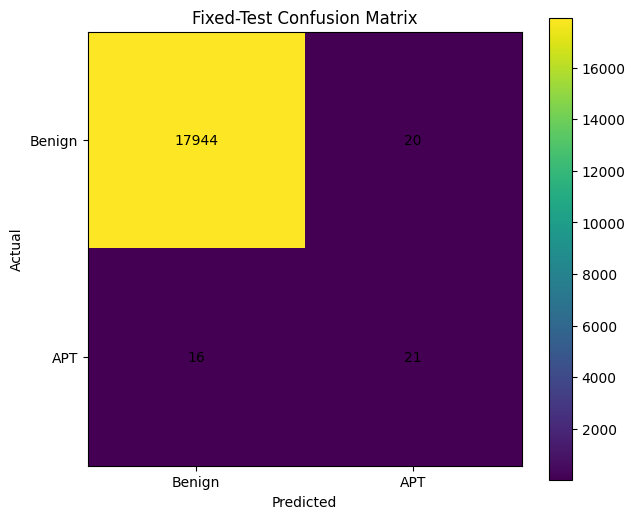

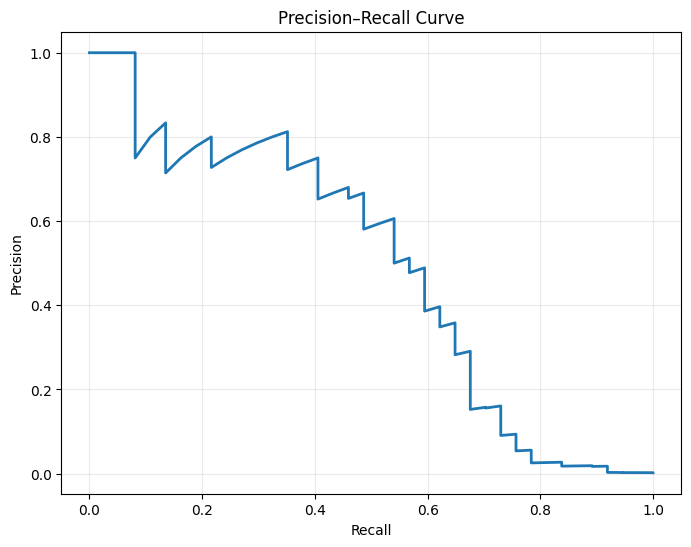

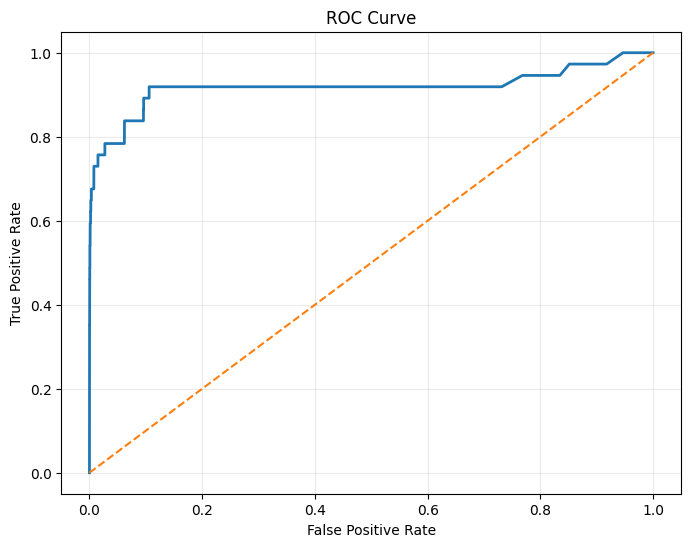

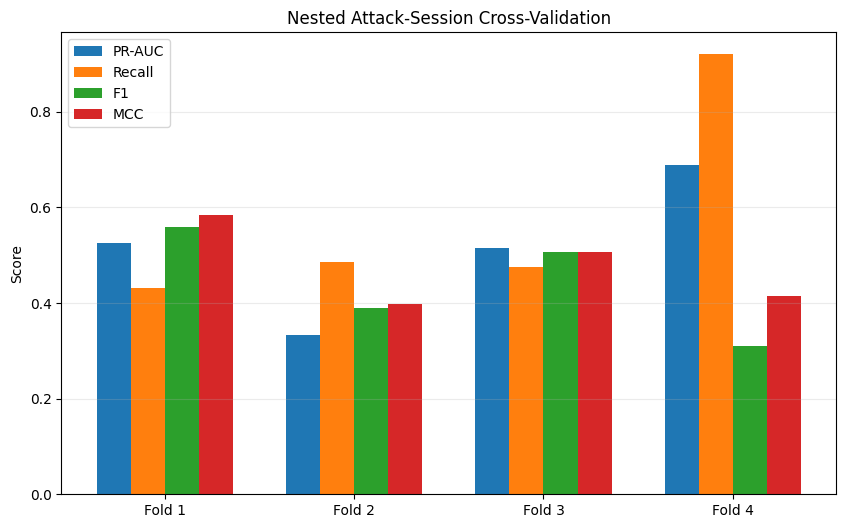

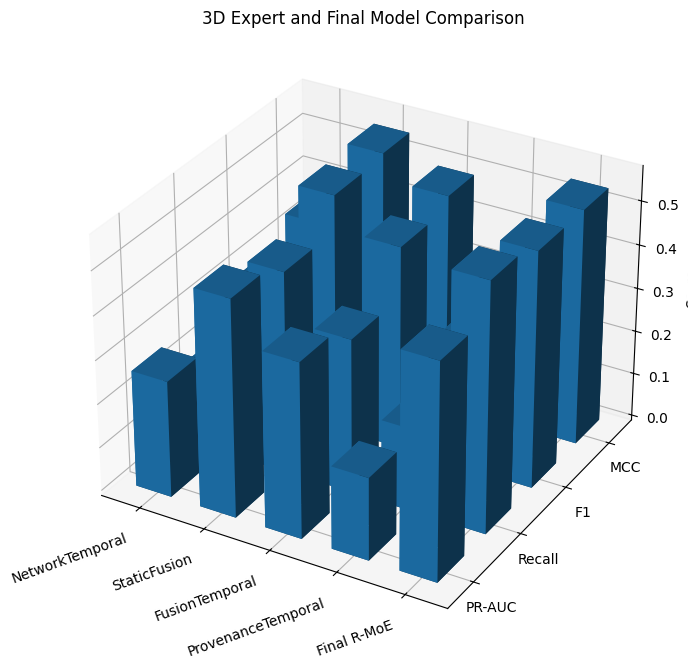

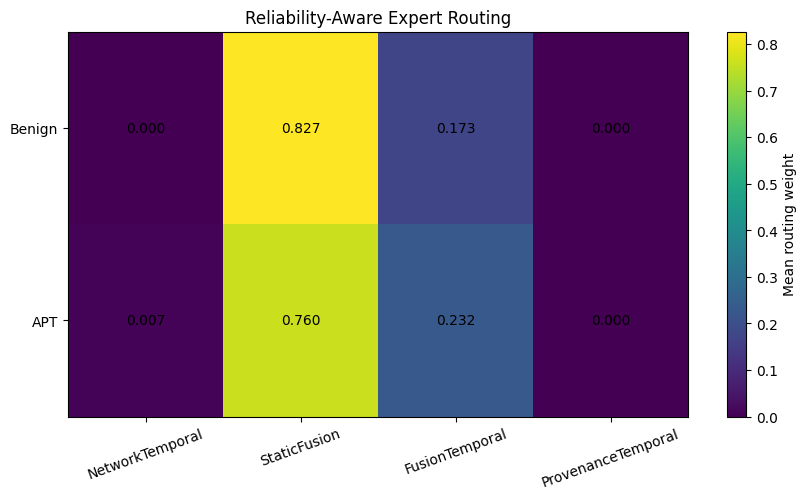


STEP 11 COMPLETE
Saved folder: /content/drive/MyDrive/IIoT_APT_Research/Step11_Nested_Session_RMoE
Reports: /content/drive/MyDrive/IIoT_APT_Research/Step11_Nested_Session_RMoE/reports
Predictions: /content/drive/MyDrive/IIoT_APT_Research/Step11_Nested_Session_RMoE/predictions
Figures: /content/drive/MyDrive/IIoT_APT_Research/Step11_Nested_Session_RMoE/figures


In [1]:
from google.colab import drive
import os, re, json, math, random, hashlib, warnings
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, matthews_corrcoef, confusion_matrix, precision_recall_curve, roc_curve

warnings.filterwarnings("ignore")

drive.mount("/content/drive", force_remount=False)

SEED = 20260925
OUTER_FOLDS = 4
INNER_FOLDS = 3
META_FOLDS = 3
MAX_ROUNDS = 6
PATIENCE = 2
FPR_LIMIT = 0.002
MIN_PRECISION = 0.30
TARGET_DELTA_PR_AUC = 0.015
TARGET_RECALL = 0.50
TARGET_MCC = 0.35
TARGET_MAX_FPR = 0.003
ATTACK_EVENT_GAP = 120
ATTACK_LINK_SECONDS = 120
BENIGN_GROUP_SECONDS = 300
MIN_EXPERT_PR_AUC = 0.05
MIN_PROVENANCE_POSITIVE_COVERAGE = 0.25
HARD_NEGATIVE_QUANTILE = 0.97
BOOTSTRAP_ITERATIONS = 1000

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    device = "cpu"

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")
STEP3 = ROOT / "Step3_Multimodal_Validation"
STEP5 = ROOT / "Step5_Baselines"
STEP10 = ROOT / "Step10_EC_MT_RMoE"
STEP11 = ROOT / "Step11_Nested_Session_RMoE"
FEATURE_DIR = STEP11 / "features"
MODEL_DIR = STEP11 / "models"
REPORT_DIR = STEP11 / "reports"
PRED_DIR = STEP11 / "predictions"
FIG_DIR = STEP11 / "figures"
for p in [STEP11, FEATURE_DIR, MODEL_DIR, REPORT_DIR, PRED_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = STEP5 / "features" / "baseline_dataset.parquet"
TEMPORAL_FILE = STEP10 / "features" / "multiscale_temporal_features.parquet"
ATTACK_FILE = STEP3 / "standardized" / "Attack_info.parquet"
for p in [DATA_FILE, TEMPORAL_FILE]:
    if not p.exists():
        raise FileNotFoundError(str(p))


def save_json(obj, path):
    tmp = Path(str(path) + ".tmp")
    with open(tmp, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    os.replace(tmp, path)


def save_parquet(df, path):
    tmp = Path(str(path) + ".tmp")
    df.to_parquet(tmp, index=False, compression="snappy")
    os.replace(tmp, path)


def save_figure(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=600, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def find_column(columns, candidates):
    lookup = {norm_name(c): c for c in columns}
    for candidate in candidates:
        key = norm_name(candidate)
        if key in lookup:
            return lookup[key]
    for candidate in candidates:
        key = norm_name(candidate)
        for existing, original in lookup.items():
            if key in existing:
                return original
    return None


def to_epoch(series):
    dt = pd.to_datetime(series, errors="coerce", utc=True)
    out = pd.Series(np.nan, index=series.index, dtype=float)
    valid = dt.notna()
    out.loc[valid] = dt.loc[valid].astype("int64") / 1e9
    return out


def binary_metrics(y, probability, threshold):
    y = np.asarray(y, dtype=int)
    p = np.asarray(probability, dtype=float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    precision = precision_score(y, pred, zero_division=0)
    recall = recall_score(y, pred, zero_division=0)
    f1 = f1_score(y, pred, zero_division=0)
    f2 = 5 * precision * recall / (4 * precision + recall + 1e-12)
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    try:
        pr_auc = average_precision_score(y, p)
    except Exception:
        pr_auc = np.nan
    try:
        roc_auc = roc_auc_score(y, p)
    except Exception:
        roc_auc = np.nan
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "f2": float(f2),
        "pr_auc": float(pr_auc),
        "roc_auc": float(roc_auc),
        "mcc": float(matthews_corrcoef(y, pred)),
        "fpr": float(fpr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold(y, probability):
    y = np.asarray(y, dtype=int)
    p = np.nan_to_num(np.asarray(probability, dtype=float), nan=0.0, posinf=1.0, neginf=0.0)
    order = np.argsort(-p)
    ys = y[order]
    ps = p[order]
    positives = max(int((y == 1).sum()), 1)
    negatives = max(int((y == 0).sum()), 1)
    tp = np.cumsum(ys == 1)
    fp = np.cumsum(ys == 0)
    change = np.where(np.r_[ps[:-1] != ps[1:], True])[0]
    thresholds = ps[change]
    tp = tp[change].astype(float)
    fp = fp[change].astype(float)
    fn = positives - tp
    tn = negatives - fp
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / positives
    fpr = fp / negatives
    f2 = 5 * precision * recall / (4 * precision + recall + 1e-12)
    numerator = tp * tn - fp * fn
    denominator = np.sqrt(np.maximum((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1e-12))
    mcc = numerator / denominator
    valid = (fpr <= FPR_LIMIT) & (precision >= MIN_PRECISION)
    if valid.any():
        positions = np.where(valid)[0]
        rank = recall[positions] * 1000 + f2[positions] * 10 + mcc[positions]
        chosen = positions[np.argmax(rank)]
        policy = "recall_under_constraint"
    else:
        objective = 0.65 * f2 + 0.20 * np.maximum(mcc, 0) + 0.15 * recall - 25 * np.maximum(fpr - FPR_LIMIT, 0)
        chosen = int(np.argmax(objective))
        policy = "F2_fallback"
    threshold = float(thresholds[chosen])
    result = binary_metrics(y, p, threshold)
    result["threshold"] = threshold
    result["policy"] = policy
    return result


def objective_score(result):
    return float(0.35 * result["pr_auc"] + 0.30 * result["f2"] + 0.20 * result["recall"] + 0.15 * max(result["mcc"], 0))


def safe_group_folds(indices, requested_folds, seed):
    indices = np.asarray(indices, dtype=int)
    y = y_all[indices]
    groups = group_all[indices]
    pos_groups = np.unique(groups[y == 1])
    neg_groups = np.unique(groups[y == 0])
    n_group = min(requested_folds, len(pos_groups), len(neg_groups))
    if n_group >= 2:
        splitter = StratifiedGroupKFold(n_splits=n_group, shuffle=True, random_state=seed)
        return list(splitter.split(np.zeros(len(indices)), y, groups)), "StratifiedGroupKFold"
    n_strat = min(requested_folds, int((y == 1).sum()), int((y == 0).sum()))
    if n_strat < 2:
        raise RuntimeError("Not enough samples/groups for cross-validation.")
    splitter = StratifiedKFold(n_splits=n_strat, shuffle=True, random_state=seed)
    return list(splitter.split(np.zeros(len(indices)), y)), "StratifiedKFold"


def make_expert(config, seed):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("model", ExtraTreesClassifier(
            n_estimators=config["n_estimators"],
            min_samples_leaf=config["min_samples_leaf"],
            max_features=config["max_features"],
            class_weight={0: 1.0, 1: config["positive_weight"]},
            n_jobs=-1,
            random_state=seed,
        )),
    ])


def fit_experts(train_global, config, hard_global=None, seed=SEED):
    train_global = np.asarray(train_global, dtype=int)
    hard_global = set() if hard_global is None else set(hard_global)
    models = {}
    for expert_no, name in enumerate(EXPERT_NAMES):
        model = make_expert(config, seed + expert_no * 100)
        weights = np.ones(len(train_global), dtype=float)
        if config["hard_weight"] > 1:
            hard_mask = np.asarray([(g in hard_global) and (y_all[g] == 0) for g in train_global])
            weights[hard_mask] *= config["hard_weight"]
        model.fit(EXPERT_DATA[name].iloc[train_global], y_all[train_global], model__sample_weight=weights)
        models[name] = model
    return models


def predict_experts(models, indices):
    indices = np.asarray(indices, dtype=int)
    out = np.zeros((len(indices), len(EXPERT_NAMES)), dtype=np.float32)
    for j, name in enumerate(EXPERT_NAMES):
        out[:, j] = models[name].predict_proba(EXPERT_DATA[name].iloc[indices])[:, 1]
    return out


def generate_oof(indices, config, hard_global=None, folds=INNER_FOLDS, seed=SEED):
    indices = np.asarray(indices, dtype=int)
    probabilities = np.zeros((len(indices), len(EXPERT_NAMES)), dtype=np.float32)
    split_list, method = safe_group_folds(indices, folds, seed)
    for fold_no, (fit_local, hold_local) in enumerate(split_list, 1):
        fit_global = indices[fit_local]
        hold_global = indices[hold_local]
        models = fit_experts(fit_global, config, hard_global=hard_global, seed=seed + fold_no * 1000)
        probabilities[hold_local] = predict_experts(models, hold_global)
    return probabilities, method


def build_context(global_indices, expert_probabilities):
    idx = np.asarray(global_indices, dtype=int)
    n_availability = data.loc[idx, network_cols].notna().mean(axis=1).to_numpy()
    p_availability = data.loc[idx, provenance_cols].notna().mean(axis=1).to_numpy()
    n_activity = np.log1p(np.nanmean(np.abs(data.loc[idx, network_cols].fillna(0).to_numpy(dtype=float)), axis=1))
    p_activity = np.log1p(np.nanmean(np.abs(data.loc[idx, provenance_cols].fillna(0).to_numpy(dtype=float)), axis=1))
    t = data.loc[idx, "_window_start"].to_numpy(dtype=float)
    angle = 2 * np.pi * (t % 86400) / 86400
    phase2 = data.loc[idx, "_phase"].astype(str).str.lower().eq("phase2").astype(float).to_numpy()
    edges = np.zeros(len(idx), dtype=float) if edge_col is None else np.log1p(pd.to_numeric(data.loc[idx, edge_col], errors="coerce").fillna(0).to_numpy())
    nodes = np.zeros(len(idx), dtype=float) if node_col is None else np.log1p(pd.to_numeric(data.loc[idx, node_col], errors="coerce").fillna(0).to_numpy())
    disagreement = expert_probabilities.std(axis=1)
    return np.column_stack([n_availability, p_availability, n_activity, p_activity, edges, nodes, np.sin(angle), np.cos(angle), phase2, disagreement]).astype(np.float32)


def reliability_features(global_indices, all_probabilities, expert_index):
    other_indices = [j for j in range(len(EXPERT_NAMES)) if j != expert_index]
    other = all_probabilities[:, other_indices]
    sorted_other = np.sort(other, axis=1)
    margin = sorted_other[:, -1] - sorted_other[:, -2] if other.shape[1] >= 2 else np.zeros(len(other))
    context = build_context(global_indices, all_probabilities)
    return np.column_stack([other.mean(axis=1), other.std(axis=1), other.max(axis=1), other.min(axis=1), margin, context]).astype(np.float32)


def fit_reliability_model(X, target, seed, min_leaf):
    model = HistGradientBoostingRegressor(
        learning_rate=0.04,
        max_iter=160,
        max_leaf_nodes=15,
        min_samples_leaf=min_leaf,
        l2_regularization=0.30,
        random_state=seed,
    )
    model.fit(X, target)
    return model


def reliability_oof(global_indices, y, expert_probabilities, seed):
    global_indices = np.asarray(global_indices, dtype=int)
    y = np.asarray(y, dtype=int)
    reliability = np.zeros_like(expert_probabilities, dtype=np.float32)
    split_list, _ = safe_group_folds(global_indices, META_FOLDS, seed)
    for expert_index in range(len(EXPERT_NAMES)):
        features = reliability_features(global_indices, expert_probabilities, expert_index)
        for fold_no, (fit_local, hold_local) in enumerate(split_list):
            benign_fit = fit_local[y[fit_local] == 0]
            attack_fit = fit_local[y[fit_local] == 1]
            if len(benign_fit) >= 20:
                model0 = fit_reliability_model(features[benign_fit], 1 - expert_probabilities[benign_fit, expert_index], seed + expert_index * 100 + fold_no, 15)
                r0 = np.clip(model0.predict(features[hold_local]), 0.01, 1.0)
            else:
                r0 = np.full(len(hold_local), 0.5)
            if len(attack_fit) >= 8:
                model1 = fit_reliability_model(features[attack_fit], expert_probabilities[attack_fit, expert_index], seed + expert_index * 100 + fold_no + 50, 4)
                r1 = np.clip(model1.predict(features[hold_local]), 0.01, 1.0)
            else:
                values = expert_probabilities[fit_local, expert_index][y[fit_local] == 1]
                r1 = np.full(len(hold_local), float(values.mean()) if len(values) else 0.10)
            other_indices = [j for j in range(len(EXPERT_NAMES)) if j != expert_index]
            q = np.clip(expert_probabilities[hold_local][:, other_indices].mean(axis=1), 0, 1)
            reliability[hold_local, expert_index] = (1 - q) * r0 + q * r1
    audit = []
    for j, name in enumerate(EXPERT_NAMES):
        actual_quality = 1 - np.abs(y - expert_probabilities[:, j])
        corr = np.nan
        if np.std(reliability[:, j]) > 1e-12 and np.std(actual_quality) > 1e-12:
            corr = float(np.corrcoef(reliability[:, j], actual_quality)[0, 1])
        audit.append({"expert": name, "quality_correlation": corr, "mean_reliability": float(reliability[:, j].mean())})
    return np.clip(reliability, 0.01, 1.0), pd.DataFrame(audit)


def train_full_reliability(global_indices, y, expert_probabilities, seed):
    models = {}
    for expert_index, name in enumerate(EXPERT_NAMES):
        features = reliability_features(global_indices, expert_probabilities, expert_index)
        benign = np.where(y == 0)[0]
        attack = np.where(y == 1)[0]
        model0 = fit_reliability_model(features[benign], 1 - expert_probabilities[benign, expert_index], seed + expert_index * 100, 15)
        if len(attack) >= 8:
            model1 = fit_reliability_model(features[attack], expert_probabilities[attack, expert_index], seed + expert_index * 100 + 50, 4)
            attack_constant = None
        else:
            model1 = None
            attack_constant = float(expert_probabilities[attack, expert_index].mean()) if len(attack) else 0.10
        models[name] = {"model0": model0, "model1": model1, "attack_constant": attack_constant}
    return models


def predict_reliability(models, global_indices, expert_probabilities):
    out = np.zeros_like(expert_probabilities, dtype=np.float32)
    for expert_index, name in enumerate(EXPERT_NAMES):
        features = reliability_features(global_indices, expert_probabilities, expert_index)
        pack = models[name]
        r0 = np.clip(pack["model0"].predict(features), 0.01, 1.0)
        if pack["model1"] is not None:
            r1 = np.clip(pack["model1"].predict(features), 0.01, 1.0)
        else:
            r1 = np.full(len(global_indices), pack["attack_constant"])
        other_indices = [j for j in range(len(EXPERT_NAMES)) if j != expert_index]
        q = np.clip(expert_probabilities[:, other_indices].mean(axis=1), 0, 1)
        out[:, expert_index] = (1 - q) * r0 + q * r1
    return np.clip(out, 0.01, 1.0)


def expert_competence(y, probabilities):
    prevalence = max(float(np.mean(y)), 1e-6)
    pr = np.asarray([average_precision_score(y, probabilities[:, j]) for j in range(probabilities.shape[1])], dtype=float)
    competence = np.maximum(pr - prevalence, 0)
    competence = competence / competence.max() if competence.max() > 0 else np.ones(len(pr))
    return pr, np.clip(competence, 0.01, 1.0)


def softmax_rows(x):
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / (e.sum(axis=1, keepdims=True) + 1e-12)


def sparse_router(probabilities, reliability, competence, admissible, params):
    p = np.clip(probabilities, 1e-6, 1 - 1e-6)
    scores = (competence[None, :] ** params["competence_power"]) * (reliability ** params["reliability_power"]) * (0.25 + params["attack_boost"] * p)
    for j in range(p.shape[1]):
        if not admissible[j]:
            scores[:, j] = 1e-12
    dense = softmax_rows(np.log(scores + 1e-12) / params["temperature"])
    top_k = min(2, max(int(np.sum(admissible)), 1))
    top_idx = np.argsort(dense, axis=1)[:, -top_k:]
    sparse = np.zeros_like(dense)
    rows = np.arange(len(dense))[:, None]
    sparse[rows, top_idx] = dense[rows, top_idx]
    sparse /= sparse.sum(axis=1, keepdims=True) + 1e-12
    return (sparse * p).sum(axis=1), sparse


def search_ensemble(y, probabilities, reliability):
    pr_values, competence = expert_competence(y, probabilities)
    prevalence = float(np.mean(y))
    admissible = pr_values >= max(MIN_EXPERT_PR_AUC, prevalence * 5)
    provenance_index = EXPERT_NAMES.index("ProvenanceTemporal")
    if not PROVENANCE_ALIGNMENT_OK:
        admissible[provenance_index] = False
    if not admissible.any():
        admissible[int(np.argmax(pr_values))] = True
    candidates = []
    for j, name in enumerate(EXPERT_NAMES):
        if admissible[j]:
            result = select_threshold(y, probabilities[:, j])
            candidates.append({"type": "single", "name": name, "expert_index": j, "metrics": result, "score": objective_score(result)})
    allowed = np.where(admissible)[0]
    for a in range(len(allowed)):
        for b in range(a + 1, len(allowed)):
            e1, e2 = int(allowed[a]), int(allowed[b])
            for weight in np.linspace(0.20, 0.80, 7):
                prob = weight * probabilities[:, e1] + (1 - weight) * probabilities[:, e2]
                result = select_threshold(y, prob)
                candidates.append({"type": "blend", "name": f"Blend_{EXPERT_NAMES[e1]}_{EXPERT_NAMES[e2]}_{weight:.2f}", "expert_1": e1, "expert_2": e2, "weight": float(weight), "metrics": result, "score": objective_score(result)})
    router_grid = [
        {"temperature": 0.35, "attack_boost": 2.0, "competence_power": 1.5, "reliability_power": 1.0},
        {"temperature": 0.50, "attack_boost": 3.0, "competence_power": 2.0, "reliability_power": 1.0},
        {"temperature": 0.75, "attack_boost": 4.0, "competence_power": 2.0, "reliability_power": 1.5},
        {"temperature": 1.00, "attack_boost": 5.0, "competence_power": 2.0, "reliability_power": 2.0},
    ]
    for params in router_grid:
        prob, _ = sparse_router(probabilities, reliability, competence, admissible, params)
        result = select_threshold(y, prob)
        candidates.append({"type": "moe", "name": f"RMoE_T{params['temperature']}_A{params['attack_boost']}_C{params['competence_power']}_R{params['reliability_power']}", "router_parameters": params, "metrics": result, "score": objective_score(result)})
    best = max(candidates, key=lambda x: (x["score"], x["metrics"]["pr_auc"]))
    singles = [c for c in candidates if c["type"] == "single"]
    best_single = max(singles, key=lambda x: x["metrics"]["pr_auc"])
    return {"best": best, "best_single": best_single, "expert_pr_auc": pr_values, "competence": competence, "admissible": admissible, "all_candidates": candidates}


def apply_candidate(candidate, probabilities, reliability, competence, admissible):
    if candidate["type"] == "single":
        j = candidate["expert_index"]
        gates = np.zeros_like(probabilities)
        gates[:, j] = 1.0
        return probabilities[:, j], gates
    if candidate["type"] == "blend":
        e1, e2, w = candidate["expert_1"], candidate["expert_2"], candidate["weight"]
        gates = np.zeros_like(probabilities)
        gates[:, e1] = w
        gates[:, e2] = 1 - w
        return w * probabilities[:, e1] + (1 - w) * probabilities[:, e2], gates
    return sparse_router(probabilities, reliability, competence, admissible, candidate["router_parameters"])


def target_reached(proposed, baseline):
    delta = proposed["pr_auc"] - baseline["pr_auc"]
    reached = delta >= TARGET_DELTA_PR_AUC and proposed["recall"] >= TARGET_RECALL and proposed["mcc"] >= TARGET_MCC and proposed["fpr"] <= TARGET_MAX_FPR
    return reached, delta


SEARCH_ROUNDS = [
    {"round": 1, "n_estimators": 250, "min_samples_leaf": 2, "max_features": "sqrt", "positive_weight": 6.0, "hard_weight": 1.0},
    {"round": 2, "n_estimators": 325, "min_samples_leaf": 1, "max_features": "sqrt", "positive_weight": 10.0, "hard_weight": 2.0},
    {"round": 3, "n_estimators": 400, "min_samples_leaf": 2, "max_features": 0.50, "positive_weight": 12.0, "hard_weight": 3.0},
    {"round": 4, "n_estimators": 475, "min_samples_leaf": 1, "max_features": 0.50, "positive_weight": 16.0, "hard_weight": 3.0},
    {"round": 5, "n_estimators": 550, "min_samples_leaf": 1, "max_features": 0.70, "positive_weight": 20.0, "hard_weight": 4.0},
    {"round": 6, "n_estimators": 650, "min_samples_leaf": 2, "max_features": 0.70, "positive_weight": 24.0, "hard_weight": 4.0},
]


def adaptive_search(train_global, tag, seed):
    train_global = np.asarray(train_global, dtype=int)
    y_local = y_all[train_global]
    hard_global = set()
    best_pack = None
    best_score = -np.inf
    stale = 0
    history = []
    for round_position, config in enumerate(SEARCH_ROUNDS[:MAX_ROUNDS]):
        probabilities, split_method = generate_oof(train_global, config, hard_global=hard_global, folds=INNER_FOLDS, seed=seed + round_position * 10000)
        reliability, reliability_audit = reliability_oof(train_global, y_local, probabilities, seed + round_position * 20000)
        search = search_ensemble(y_local, probabilities, reliability)
        candidate = search["best"]
        baseline = search["best_single"]
        score = candidate["score"]
        reached, delta_pr = target_reached(candidate["metrics"], baseline["metrics"])
        candidate_probability, _ = apply_candidate(candidate, probabilities, reliability, search["competence"], search["admissible"])
        negative_local = np.where(y_local == 0)[0]
        negative_scores = candidate_probability[negative_local]
        hard_cutoff = np.quantile(negative_scores, HARD_NEGATIVE_QUANTILE)
        new_hard_local = negative_local[negative_scores >= hard_cutoff]
        next_hard_global = set(train_global[new_hard_local].tolist())
        history.append({
            "tag": tag,
            "round": round_position + 1,
            "split_method": split_method,
            "selected_method": candidate["name"],
            "selected_type": candidate["type"],
            "score": score,
            "pr_auc": candidate["metrics"]["pr_auc"],
            "precision": candidate["metrics"]["precision"],
            "recall": candidate["metrics"]["recall"],
            "f1": candidate["metrics"]["f1"],
            "f2": candidate["metrics"]["f2"],
            "mcc": candidate["metrics"]["mcc"],
            "fpr": candidate["metrics"]["fpr"],
            "best_single": baseline["name"],
            "best_single_pr_auc": baseline["metrics"]["pr_auc"],
            "delta_pr_auc": delta_pr,
            "hard_negatives": len(next_hard_global),
        })
        print(f"{tag} | round {round_position + 1} | {candidate['name']} | PR-AUC={candidate['metrics']['pr_auc']:.4f} | Recall={candidate['metrics']['recall']:.4f} | F1={candidate['metrics']['f1']:.4f} | MCC={candidate['metrics']['mcc']:.4f} | FPR={candidate['metrics']['fpr']:.5f}")
        if score > best_score + 1e-4:
            best_score = score
            stale = 0
            full_reliability_models = train_full_reliability(train_global, y_local, probabilities, seed + 50000 + round_position)
            best_pack = {
                "config": dict(config),
                "candidate": candidate,
                "baseline": baseline,
                "probabilities": probabilities,
                "reliability": reliability,
                "reliability_audit": reliability_audit,
                "reliability_models": full_reliability_models,
                "competence": search["competence"],
                "admissible": search["admissible"],
                "hard_global": set(next_hard_global),
                "score": score,
            }
        else:
            stale += 1
        hard_global = next_hard_global
        if reached:
            break
        if stale >= PATIENCE and round_position >= 2:
            break
    return best_pack, pd.DataFrame(history)


def group_bootstrap_delta(y, proposed, baseline, groups, iterations=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int)
    proposed = np.asarray(proposed, dtype=float)
    baseline = np.asarray(baseline, dtype=float)
    groups = np.asarray(groups)
    unique_groups = np.unique(groups)
    group_indices = {g: np.where(groups == g)[0] for g in unique_groups}
    deltas = []
    for _ in range(iterations):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        sampled_indices = np.concatenate([group_indices[g] for g in sampled_groups])
        yy = y[sampled_indices]
        if len(np.unique(yy)) < 2:
            continue
        try:
            a = average_precision_score(yy, proposed[sampled_indices])
            b = average_precision_score(yy, baseline[sampled_indices])
            deltas.append(a - b)
        except Exception:
            continue
    deltas = np.asarray(deltas, dtype=float)
    if len(deltas) == 0:
        return {"mean_delta": np.nan, "ci_low": np.nan, "ci_high": np.nan, "bootstrap_samples": 0}
    return {
        "mean_delta": float(deltas.mean()),
        "ci_low": float(np.quantile(deltas, 0.025)),
        "ci_high": float(np.quantile(deltas, 0.975)),
        "bootstrap_samples": int(len(deltas)),
    }


data = pd.read_parquet(DATA_FILE).reset_index(drop=True)
temp = pd.read_parquet(TEMPORAL_FILE).reset_index(drop=True)
if len(data) != len(temp):
    raise RuntimeError("Step 5 and Step 10 row counts do not match.")

network_cols = [c for c in data.columns if c.startswith("N_")]
provenance_cols = [c for c in data.columns if c.startswith("P_")]
TN_COLS = [c for c in temp.columns if c.startswith("TN_")]
TP_COLS = [c for c in temp.columns if c.startswith("TP_")]
if len(TN_COLS) == 0:
    raise RuntimeError("No TN_ temporal features found in Step 10 output.")

for c in network_cols + provenance_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
for c in TN_COLS + TP_COLS:
    temp[c] = pd.to_numeric(temp[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

data["_window_start"] = pd.to_numeric(data["_window_start"], errors="raise").astype("int64")
y_all = data["binary_label"].astype(int).to_numpy()

test_idx = np.where(data["split"].astype(str).eq("test"))[0]
dev_idx_initial = np.where(~data["split"].astype(str).eq("test"))[0]
test_ids = data.loc[test_idx, "_window_id"].astype(str).sort_values().tolist()
TEST_HASH = hashlib.sha256("\n".join(test_ids).encode()).hexdigest()

print("=" * 78)
print("STEP 11 — NESTED SESSION R-MoE")
print("=" * 78)
print("Device:", device)
print("Rows:", f"{len(data):,}")
print("Initial development windows:", f"{len(dev_idx_initial):,}")
print("Fixed test windows:", f"{len(test_idx):,}")
print("Fixed test positives:", int(y_all[test_idx].sum()))
print("Test hash:", TEST_HASH[:24], "...")

data["_attack_session"] = pd.NA
if ATTACK_FILE.exists():
    attack = pd.read_parquet(ATTACK_FILE)
    time_col = find_column(attack.columns, ["_attack_time_utc", "attack_time", "time"])
    if time_col is not None:
        attack["_epoch"] = to_epoch(attack[time_col])
        attack = attack[attack["_epoch"].notna()].copy()
        phase_ranges = data.groupby("_phase")["_window_start"].agg(["min", "max"]).to_dict("index")
        def infer_phase(timestamp):
            candidates = [phase for phase, bounds in phase_ranges.items() if timestamp >= bounds["min"] - 300 and timestamp <= bounds["max"] + 300]
            if candidates:
                return candidates[0]
            distances = {phase: min(abs(timestamp - bounds["min"]), abs(timestamp - bounds["max"])) for phase, bounds in phase_ranges.items()}
            return min(distances, key=distances.get)
        attack["_phase"] = attack["_epoch"].apply(infer_phase)
        attack = attack.sort_values(["_phase", "_epoch"]).copy()
        attack["_session_number"] = 0
        for phase in attack["_phase"].unique():
            idx = attack.index[attack["_phase"] == phase]
            times = attack.loc[idx, "_epoch"].to_numpy()
            sessions = (np.r_[np.inf, np.diff(times)] > ATTACK_EVENT_GAP).cumsum()
            attack.loc[idx, "_session_number"] = sessions
        attack["_attack_session"] = attack["_phase"].astype(str) + "_A_" + attack["_session_number"].astype(int).astype(str)
        attack_sessions = attack.groupby(["_phase", "_attack_session"], as_index=False).agg(session_start=("_epoch", "min"), session_end=("_epoch", "max"), attack_events=("_epoch", "size"))
        attack_sessions.to_csv(REPORT_DIR / "attack_sessions.csv", index=False)
        for global_index in np.where(y_all == 1)[0]:
            phase = str(data.iloc[global_index]["_phase"])
            timestamp = float(data.iloc[global_index]["_window_start"]) + 2.5
            available = attack_sessions[attack_sessions["_phase"].astype(str) == phase]
            best_session, best_distance = None, np.inf
            for _, session in available.iterrows():
                lo = session["session_start"] - ATTACK_LINK_SECONDS
                hi = session["session_end"] + ATTACK_LINK_SECONDS
                if timestamp >= lo and timestamp <= hi:
                    distance = min(abs(timestamp - session["session_start"]), abs(timestamp - session["session_end"]))
                    if distance < best_distance:
                        best_distance, best_session = distance, session["_attack_session"]
            if best_session is not None:
                data.loc[global_index, "_attack_session"] = best_session

for phase in data["_phase"].unique():
    unmatched = data[(data["_phase"] == phase) & (data["binary_label"] == 1) & (data["_attack_session"].isna())].sort_values("_window_start")
    if len(unmatched) == 0:
        continue
    times = unmatched["_window_start"].to_numpy()
    pseudo = (np.r_[np.inf, np.diff(times)] > 60).cumsum()
    for row_index, group_number in zip(unmatched.index, pseudo):
        data.loc[row_index, "_attack_session"] = f"{phase}_P_{int(group_number)}"

test_attack_sessions = set(data.loc[(data.index.isin(test_idx)) & (data["binary_label"] == 1), "_attack_session"].dropna().astype(str))
overlap_mask = (~data.index.isin(test_idx)) & (data["binary_label"] == 1) & (data["_attack_session"].astype(str).isin(test_attack_sessions))
quarantined_positive_idx = data.index[overlap_mask].to_numpy()
quarantine_set = set(quarantined_positive_idx.tolist())
dev_idx = np.asarray([i for i in dev_idx_initial if i not in quarantine_set], dtype=int)

group_all = np.empty(len(data), dtype=object)
for i in range(len(data)):
    row = data.iloc[i]
    if int(row["binary_label"]) == 1:
        session = row["_attack_session"]
        group_all[i] = str(session) if not pd.isna(session) else f"{row['_phase']}_APT_{int(row['_window_start'] // 60)}"
    else:
        group_all[i] = f"{row['_phase']}_B_{int(row['_window_start'] // BENIGN_GROUP_SECONDS)}"

session_df = data[["_window_id", "_phase", "_window_start", "binary_label"]].copy()
session_df["_session_group"] = group_all
session_df["_used_for_development"] = session_df.index.isin(dev_idx)
session_df["_fixed_test"] = session_df.index.isin(test_idx)
save_parquet(session_df, FEATURE_DIR / "session_groups.parquet")

print("Development windows after session protection:", f"{len(dev_idx):,}")
print("Development positives:", int(y_all[dev_idx].sum()))
print("Quarantined overlapping positive windows:", len(quarantined_positive_idx))

EXPERT_NAMES = ["NetworkTemporal", "StaticFusion", "FusionTemporal", "ProvenanceTemporal"]
EXPERT_DATA = {
    "NetworkTemporal": temp[TN_COLS].copy(),
    "StaticFusion": data[network_cols + provenance_cols].copy(),
    "FusionTemporal": pd.concat([temp[TN_COLS], temp[TP_COLS], data[provenance_cols]], axis=1),
    "ProvenanceTemporal": pd.concat([temp[TP_COLS], data[provenance_cols]], axis=1),
}
for name in EXPERT_NAMES:
    EXPERT_DATA[name] = EXPERT_DATA[name].replace([np.inf, -np.inf], np.nan)

edge_col = find_column(provenance_cols, ["P_edge_count", "edge_count"])
node_col = find_column(provenance_cols, ["P_node_count", "node_count"])
pid_col = find_column(provenance_cols, ["P_pid_nunique", "pid_nunique"])

audit_rows = []
for partition_name, indices in [("Development", dev_idx), ("FixedTest", test_idx)]:
    for label_value, label_name in [(0, "Benign"), (1, "APT")]:
        idx = indices[y_all[indices] == label_value]
        if len(idx) == 0:
            continue
        row = {
            "partition": partition_name,
            "class": label_name,
            "windows": int(len(idx)),
            "P_feature_availability": float(data.loc[idx, provenance_cols].notna().mean(axis=1).mean()),
        }
        if edge_col is not None:
            v = pd.to_numeric(data.loc[idx, edge_col], errors="coerce").fillna(0)
            row["edge_positive_fraction"] = float((v > 0).mean())
            row["mean_edge_count"] = float(v.mean())
        if node_col is not None:
            v = pd.to_numeric(data.loc[idx, node_col], errors="coerce").fillna(0)
            row["node_positive_fraction"] = float((v > 0).mean())
            row["mean_node_count"] = float(v.mean())
        if pid_col is not None:
            v = pd.to_numeric(data.loc[idx, pid_col], errors="coerce").fillna(0)
            row["pid_positive_fraction"] = float((v > 0).mean())
        audit_rows.append(row)

alignment_df = pd.DataFrame(audit_rows)
alignment_df.to_csv(REPORT_DIR / "provenance_alignment_audit.csv", index=False)
print("\nPROVENANCE ALIGNMENT AUDIT")
display(alignment_df.round(4))

dev_apt_audit = alignment_df[(alignment_df["partition"] == "Development") & (alignment_df["class"] == "APT")]
if len(dev_apt_audit):
    if "edge_positive_fraction" in dev_apt_audit.columns:
        provenance_positive_coverage = float(dev_apt_audit.iloc[0]["edge_positive_fraction"])
    else:
        provenance_positive_coverage = float(dev_apt_audit.iloc[0]["P_feature_availability"])
else:
    provenance_positive_coverage = 0.0
PROVENANCE_ALIGNMENT_OK = provenance_positive_coverage >= MIN_PROVENANCE_POSITIVE_COVERAGE
print("Development APT provenance coverage:", round(provenance_positive_coverage, 4))

print("\n" + "=" * 78)
print("NESTED ATTACK-SESSION CROSS-VALIDATION")
print("=" * 78)

outer_splits, outer_method = safe_group_folds(dev_idx, OUTER_FOLDS, SEED)
outer_rows = []
all_history = []
outer_oof_probability = np.full(len(dev_idx), np.nan, dtype=float)
outer_oof_baseline = np.full(len(dev_idx), np.nan, dtype=float)

dev_position = {int(g): pos for pos, g in enumerate(dev_idx)}

for outer_fold, (train_local, hold_local) in enumerate(outer_splits, 1):
    outer_train = dev_idx[train_local]
    outer_hold = dev_idx[hold_local]
    print("\nOuter fold", outer_fold, "/", len(outer_splits))
    best_pack, history = adaptive_search(outer_train, f"Outer{outer_fold}", SEED + outer_fold * 100000)
    history["outer_fold"] = outer_fold
    all_history.append(history)
    models = fit_experts(outer_train, best_pack["config"], hard_global=best_pack["hard_global"], seed=SEED + outer_fold * 200000)
    hold_prob = predict_experts(models, outer_hold)
    hold_rel = predict_reliability(best_pack["reliability_models"], outer_hold, hold_prob)
    proposed_prob, _ = apply_candidate(best_pack["candidate"], hold_prob, hold_rel, best_pack["competence"], best_pack["admissible"])
    threshold = best_pack["candidate"]["metrics"]["threshold"]
    hold_y = y_all[outer_hold]
    proposed_metrics = binary_metrics(hold_y, proposed_prob, threshold)
    baseline_index = best_pack["baseline"]["expert_index"]
    baseline_prob = hold_prob[:, baseline_index]
    baseline_threshold = best_pack["baseline"]["metrics"]["threshold"]
    baseline_metrics = binary_metrics(hold_y, baseline_prob, baseline_threshold)
    outer_rows.append({
        "outer_fold": outer_fold,
        "train_windows": len(outer_train),
        "hold_windows": len(outer_hold),
        "hold_positives": int(hold_y.sum()),
        "selected_method": best_pack["candidate"]["name"],
        "selected_type": best_pack["candidate"]["type"],
        "best_single": best_pack["baseline"]["name"],
        "pr_auc": proposed_metrics["pr_auc"],
        "precision": proposed_metrics["precision"],
        "recall": proposed_metrics["recall"],
        "f1": proposed_metrics["f1"],
        "f2": proposed_metrics["f2"],
        "mcc": proposed_metrics["mcc"],
        "fpr": proposed_metrics["fpr"],
        "baseline_pr_auc": baseline_metrics["pr_auc"],
        "delta_pr_auc": proposed_metrics["pr_auc"] - baseline_metrics["pr_auc"],
    })
    for k, global_index in enumerate(outer_hold):
        pos = dev_position[int(global_index)]
        outer_oof_probability[pos] = proposed_prob[k]
        outer_oof_baseline[pos] = baseline_prob[k]
    print("Outer result | PR-AUC={:.4f} | Recall={:.4f} | F1={:.4f} | MCC={:.4f} | FPR={:.5f}".format(proposed_metrics["pr_auc"], proposed_metrics["recall"], proposed_metrics["f1"], proposed_metrics["mcc"], proposed_metrics["fpr"]))

outer_df = pd.DataFrame(outer_rows)
outer_df.to_csv(REPORT_DIR / "nested_outer_fold_results.csv", index=False)
search_history_df = pd.concat(all_history, ignore_index=True)
search_history_df.to_csv(REPORT_DIR / "adaptive_search_history.csv", index=False)

summary_rows = []
for metric in ["pr_auc", "precision", "recall", "f1", "f2", "mcc", "fpr", "delta_pr_auc"]:
    values = outer_df[metric].to_numpy(dtype=float)
    summary_rows.append({"metric": metric, "mean": float(np.mean(values)), "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0, "min": float(np.min(values)), "max": float(np.max(values))})
outer_summary_df = pd.DataFrame(summary_rows)
outer_summary_df.to_csv(REPORT_DIR / "nested_outer_summary.csv", index=False)

print("\nNESTED CV FOLD RESULTS")
display(outer_df.round(4))
print("\nNESTED CV SUMMARY")
display(outer_summary_df.round(4))

valid_outer = np.isfinite(outer_oof_probability) & np.isfinite(outer_oof_baseline)
bootstrap_result = group_bootstrap_delta(y_all[dev_idx][valid_outer], outer_oof_probability[valid_outer], outer_oof_baseline[valid_outer], group_all[dev_idx][valid_outer], BOOTSTRAP_ITERATIONS, SEED)
print("\nPAIRED ATTACK-SESSION BOOTSTRAP")
display(pd.DataFrame([bootstrap_result]).round(4))

print("\n" + "=" * 78)
print("FINAL DEVELOPMENT SEARCH")
print("=" * 78)
final_pack, final_history = adaptive_search(dev_idx, "FullDevelopment", SEED + 900000)
final_history.to_csv(REPORT_DIR / "final_development_search.csv", index=False)
display(final_history.round(4))
print("Frozen method:", final_pack["candidate"]["name"])
print("Development PR-AUC:", round(final_pack["candidate"]["metrics"]["pr_auc"], 4))
print("Development Recall:", round(final_pack["candidate"]["metrics"]["recall"], 4))

final_models = fit_experts(dev_idx, final_pack["config"], hard_global=final_pack["hard_global"], seed=SEED + 950000)
for name, model in final_models.items():
    joblib.dump(model, MODEL_DIR / f"{name}.joblib")

current_test_ids = data.loc[test_idx, "_window_id"].astype(str).sort_values().tolist()
current_hash = hashlib.sha256("\n".join(current_test_ids).encode()).hexdigest()
assert current_hash == TEST_HASH, "Fixed test set changed."

test_prob = predict_experts(final_models, test_idx)
test_rel = predict_reliability(final_pack["reliability_models"], test_idx, test_prob)
final_probability, final_gates = apply_candidate(final_pack["candidate"], test_prob, test_rel, final_pack["competence"], final_pack["admissible"])
FINAL_THRESHOLD = final_pack["candidate"]["metrics"]["threshold"]
y_test = y_all[test_idx]
FINAL_METRICS = binary_metrics(y_test, final_probability, FINAL_THRESHOLD)

expert_rows = []
for j, name in enumerate(EXPERT_NAMES):
    dev_result = select_threshold(y_all[dev_idx], final_pack["probabilities"][:, j])
    result = binary_metrics(y_test, test_prob[:, j], dev_result["threshold"])
    expert_rows.append({"expert": name, "development_threshold": dev_result["threshold"], "admissible": bool(final_pack["admissible"][j]), "competence": float(final_pack["competence"][j]), **result})
expert_df = pd.DataFrame(expert_rows)
expert_df.to_csv(REPORT_DIR / "final_expert_results.csv", index=False)

routing_rows = []
for class_value, class_name in [(0, "Benign"), (1, "APT")]:
    mask = y_test == class_value
    for j, name in enumerate(EXPERT_NAMES):
        routing_rows.append({"class": class_name, "expert": name, "mean_gate": float(final_gates[mask, j].mean()), "mean_reliability": float(test_rel[mask, j].mean()), "competence": float(final_pack["competence"][j]), "admissible": bool(final_pack["admissible"][j])})
routing_df = pd.DataFrame(routing_rows)
routing_df.to_csv(REPORT_DIR / "final_routing.csv", index=False)

prediction_df = pd.DataFrame({"_window_id": data.loc[test_idx, "_window_id"].to_numpy(), "y_true": y_test, "probability": final_probability, "prediction": (final_probability >= FINAL_THRESHOLD).astype(int)})
for j, name in enumerate(EXPERT_NAMES):
    prediction_df[f"prob_{name}"] = test_prob[:, j]
    prediction_df[f"gate_{name}"] = final_gates[:, j]
    prediction_df[f"reliability_{name}"] = test_rel[:, j]
save_parquet(prediction_df, PRED_DIR / "final_fixed_test_predictions.parquet")

print("\n" + "=" * 78)
print("STEP 11 — FINAL CONFIRMATORY RESULT")
print("=" * 78)
print("Selected method:", final_pack["candidate"]["name"])
print("Method type:", final_pack["candidate"]["type"])
print("Development-locked threshold:", round(FINAL_THRESHOLD, 6))
print("\nFINAL FIXED-TEST RESULT")
display(pd.DataFrame([FINAL_METRICS]).round(4))
print("\nFINAL EXPERT DIAGNOSTICS")
display(expert_df[["expert", "admissible", "competence", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc", "mcc", "fpr", "tp", "fp", "fn"]].round(4))
print("\nROUTING")
display(routing_df.round(4))

cm = confusion_matrix(y_test, (final_probability >= FINAL_THRESHOLD).astype(int), labels=[0, 1])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "APT"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "APT"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Fixed-Test Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax)
save_figure(fig, "Fig_11A_Confusion_Matrix")

precision_curve, recall_curve, _ = precision_recall_curve(y_test, final_probability)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, linewidth=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall Curve"); ax.grid(alpha=0.25)
save_figure(fig, "Fig_11B_PR_Curve")

fpr_curve, tpr_curve, _ = roc_curve(y_test, final_probability)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_curve, tpr_curve, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title("ROC Curve"); ax.grid(alpha=0.25)
save_figure(fig, "Fig_11C_ROC_Curve")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(outer_df)); width = 0.18
ax.bar(x - 1.5 * width, outer_df["pr_auc"], width, label="PR-AUC")
ax.bar(x - 0.5 * width, outer_df["recall"], width, label="Recall")
ax.bar(x + 0.5 * width, outer_df["f1"], width, label="F1")
ax.bar(x + 1.5 * width, outer_df["mcc"], width, label="MCC")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i}" for i in outer_df["outer_fold"]]); ax.set_ylabel("Score"); ax.set_title("Nested Attack-Session Cross-Validation"); ax.legend(); ax.grid(axis="y", alpha=0.25)
save_figure(fig, "Fig_11D_Nested_CV")

plot_metrics = ["pr_auc", "recall", "f1", "mcc"]
plot_df = expert_df[["expert"] + plot_metrics].rename(columns={"expert": "model"})
plot_df = pd.concat([plot_df, pd.DataFrame([{"model": "Final R-MoE", "pr_auc": FINAL_METRICS["pr_auc"], "recall": FINAL_METRICS["recall"], "f1": FINAL_METRICS["f1"], "mcc": FINAL_METRICS["mcc"]}])], ignore_index=True)
fig = plt.figure(figsize=(13, 8)); ax = fig.add_subplot(111, projection="3d")
x = np.repeat(np.arange(len(plot_df)), len(plot_metrics)); ypos = np.tile(np.arange(len(plot_metrics)), len(plot_df)); zpos = np.zeros(len(x)); dx = np.full(len(x), 0.55); dy = np.full(len(x), 0.55); dz = plot_df[plot_metrics].fillna(0).to_numpy().reshape(-1)
ax.bar3d(x, ypos, zpos, dx, dy, dz, shade=True)
ax.set_xticks(np.arange(len(plot_df)) + 0.27); ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_yticks(np.arange(len(plot_metrics)) + 0.27); ax.set_yticklabels(["PR-AUC", "Recall", "F1", "MCC"]); ax.set_zlabel("Score"); ax.set_title("3D Expert and Final Model Comparison")
save_figure(fig, "Fig_11E_3D_Model_Comparison")

routing_matrix = np.zeros((2, len(EXPERT_NAMES)))
for ci, cname in enumerate(["Benign", "APT"]):
    for ej, ename in enumerate(EXPERT_NAMES):
        values = routing_df[(routing_df["class"] == cname) & (routing_df["expert"] == ename)]["mean_gate"]
        routing_matrix[ci, ej] = float(values.iloc[0]) if len(values) else 0.0
fig, ax = plt.subplots(figsize=(10, 5)); im = ax.imshow(routing_matrix, aspect="auto")
ax.set_xticks(range(len(EXPERT_NAMES))); ax.set_xticklabels(EXPERT_NAMES, rotation=20)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "APT"])
for i in range(2):
    for j in range(len(EXPERT_NAMES)):
        ax.text(j, i, f"{routing_matrix[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Mean routing weight"); ax.set_title("Reliability-Aware Expert Routing")
save_figure(fig, "Fig_11F_Routing_Heatmap")

nested_summary = {row["metric"]: {"mean": row["mean"], "std": row["std"]} for _, row in outer_summary_df.iterrows()}
final_report = {
    "version": "11.1",
    "device": device,
    "development_windows": int(len(dev_idx)),
    "development_positives": int(y_all[dev_idx].sum()),
    "fixed_test_windows": int(len(test_idx)),
    "fixed_test_positives": int(y_test.sum()),
    "test_sha256": TEST_HASH,
    "quarantined_test_episode_windows": int(len(quarantined_positive_idx)),
    "provenance_alignment_coverage": float(provenance_positive_coverage),
    "provenance_alignment_ok": bool(PROVENANCE_ALIGNMENT_OK),
    "outer_cv_method": outer_method,
    "nested_cv_summary": nested_summary,
    "paired_group_bootstrap": bootstrap_result,
    "selected_method": final_pack["candidate"]["name"],
    "selected_type": final_pack["candidate"]["type"],
    "selected_config": final_pack["config"],
    "threshold": float(FINAL_THRESHOLD),
    "final_test": FINAL_METRICS,
    "completed_utc": datetime.now(timezone.utc).isoformat(),
}
save_json(final_report, REPORT_DIR / "step11_final_report.json")

(STEP11 / "STEP11_COMPLETE.txt").write_text(
    "STEP 11 COMPLETE\n"
    f"Method: {final_pack['candidate']['name']}\n"
    f"PR-AUC: {FINAL_METRICS['pr_auc']:.4f}\n"
    f"Precision: {FINAL_METRICS['precision']:.4f}\n"
    f"Recall: {FINAL_METRICS['recall']:.4f}\n"
    f"F1: {FINAL_METRICS['f1']:.4f}\n"
    f"F2: {FINAL_METRICS['f2']:.4f}\n"
    f"MCC: {FINAL_METRICS['mcc']:.4f}\n"
    f"FPR: {FINAL_METRICS['fpr']:.6f}\n"
)

print("\n" + "=" * 78)
print("STEP 11 COMPLETE")
print("=" * 78)
print("Saved folder:", STEP11)
print("Reports:", REPORT_DIR)
print("Predictions:", PRED_DIR)
print("Figures:", FIG_DIR)


STEP 12X — FROZEN STEP11X + ALL-TECHNIQUES CONSENSUS
Step11X model changed: False
Previous techniques removed: False
Exact Step11X folds reused: True
Old fixed test evaluated: False

Technique matrix: 236 episodes x 38 evidence columns
Fold 1: Step12X AP=0.9658 | Frozen Step11X AP=0.9658 | alpha=0.25+0.00*U | rescue=0.00
Fold 2: Step12X AP=1.0000 | Frozen Step11X AP=1.0000 | alpha=0.15+0.20*U | rescue=0.10
Fold 3: Step12X AP=1.0000 | Frozen Step11X AP=1.0000 | alpha=0.25+0.20*U | rescue=0.00
Fold 4: Step12X AP=0.9283 | Frozen Step11X AP=0.9060 | alpha=0.05+0.10*U | rescue=0.15


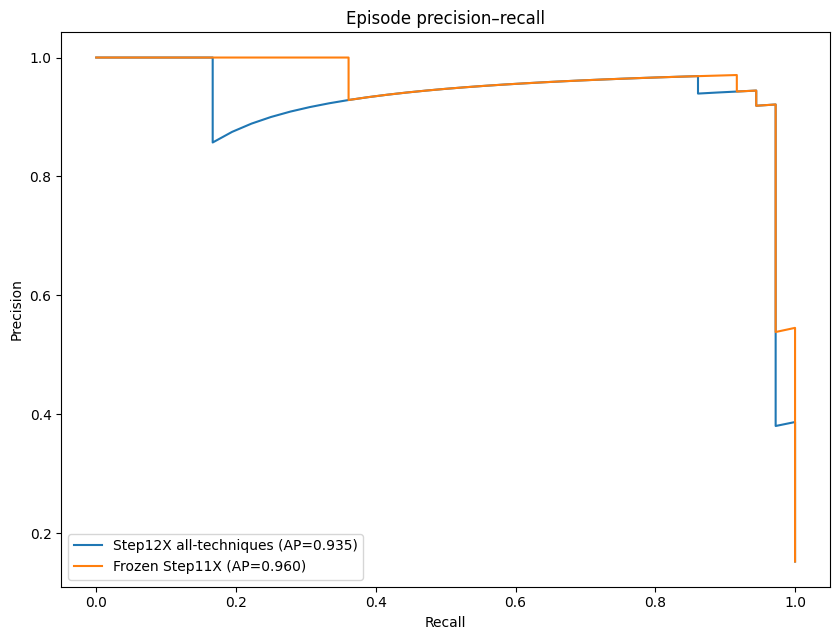

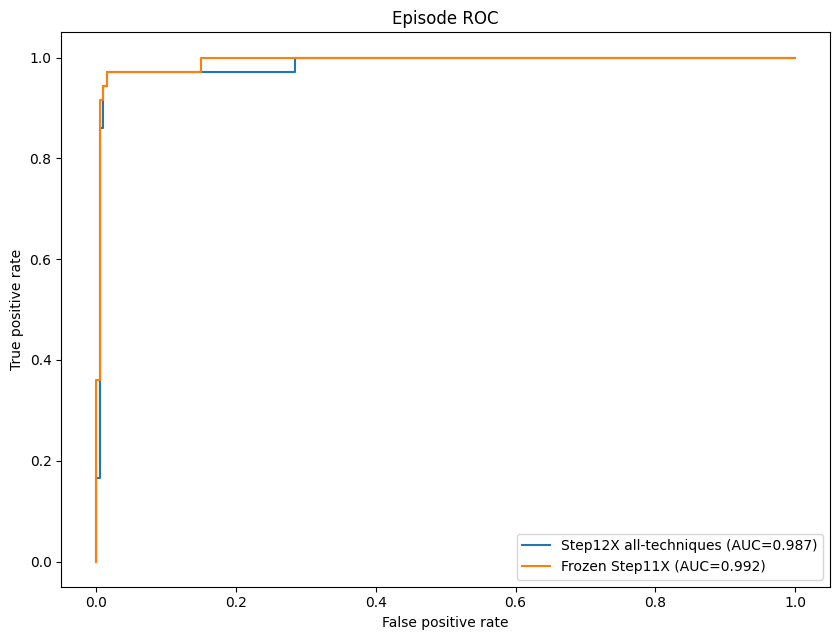

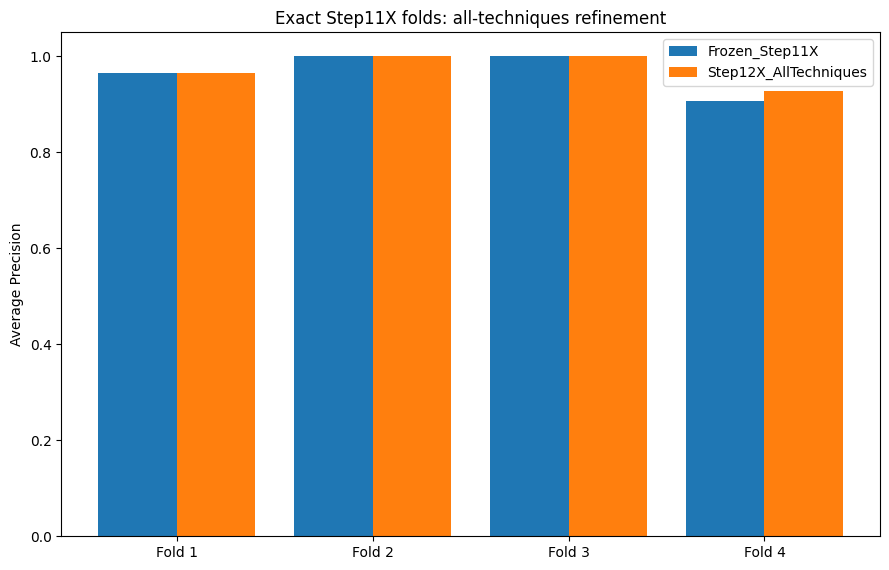

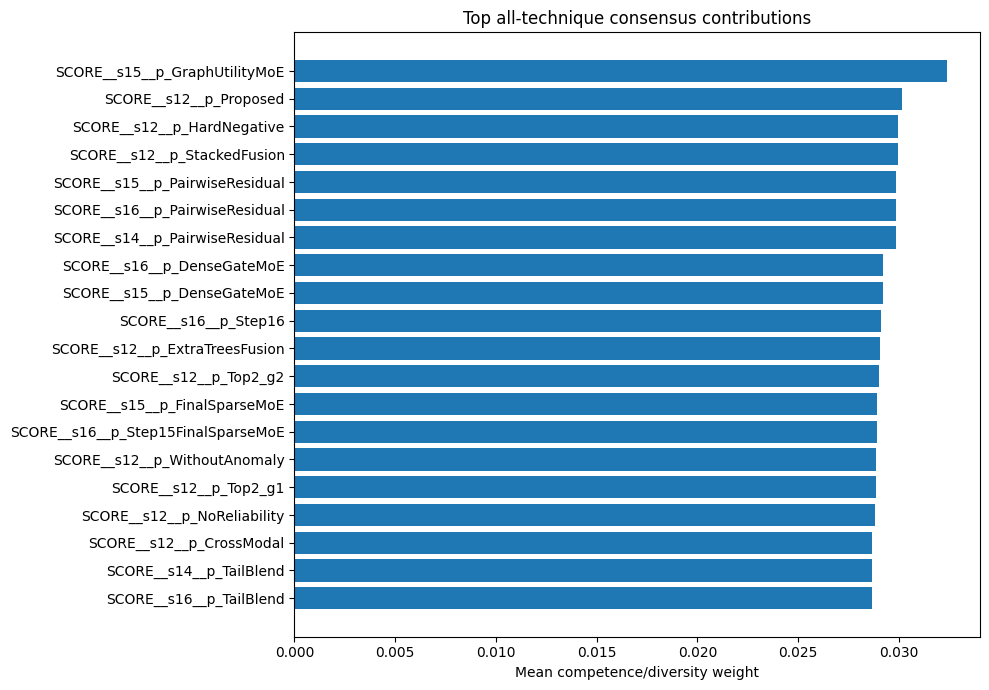

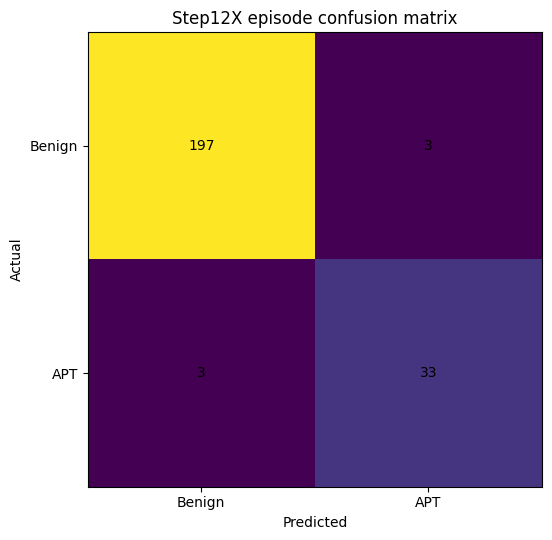

...

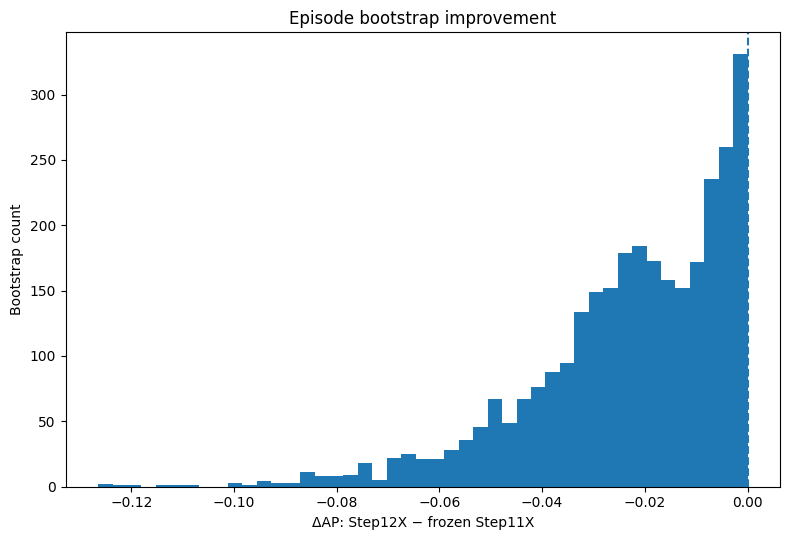

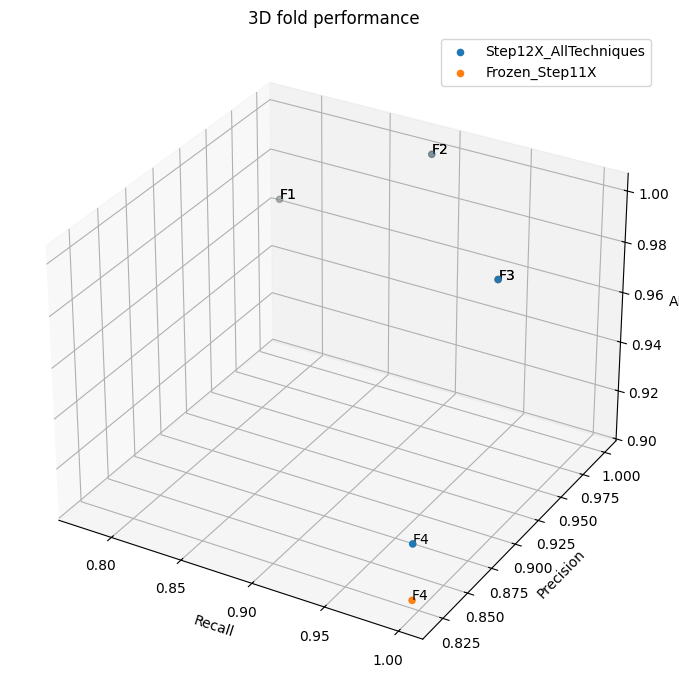

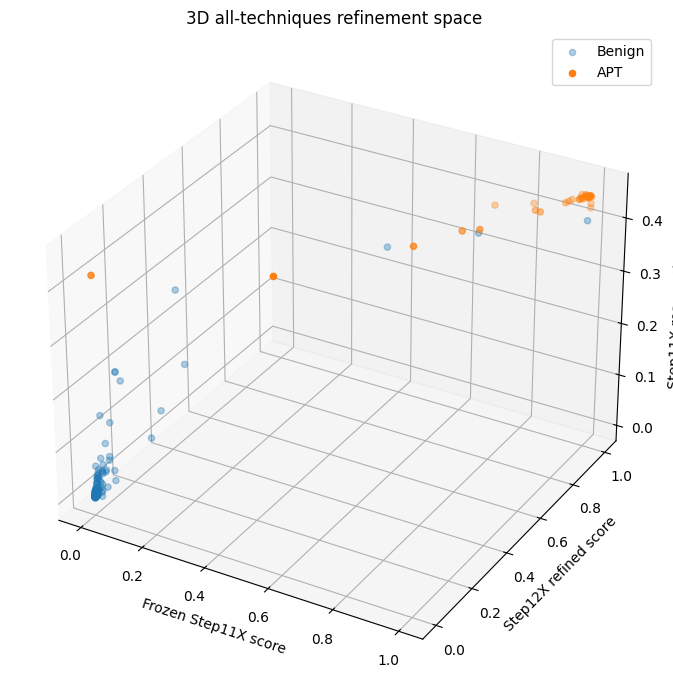

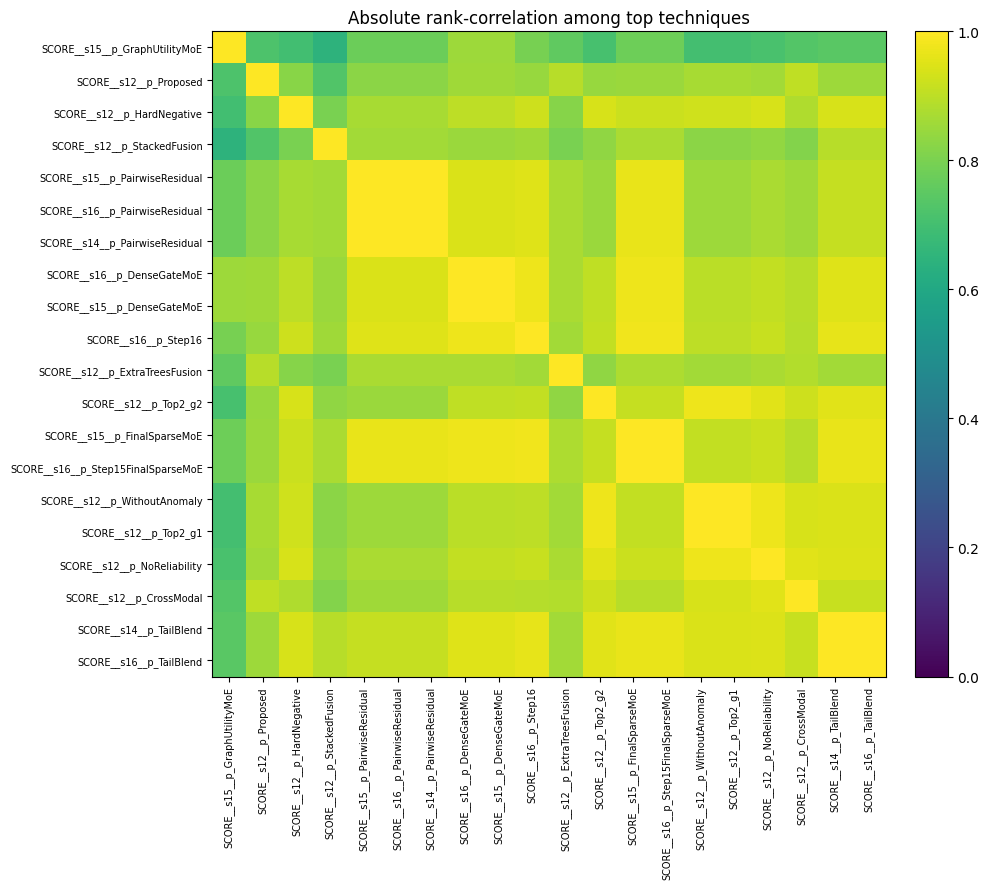

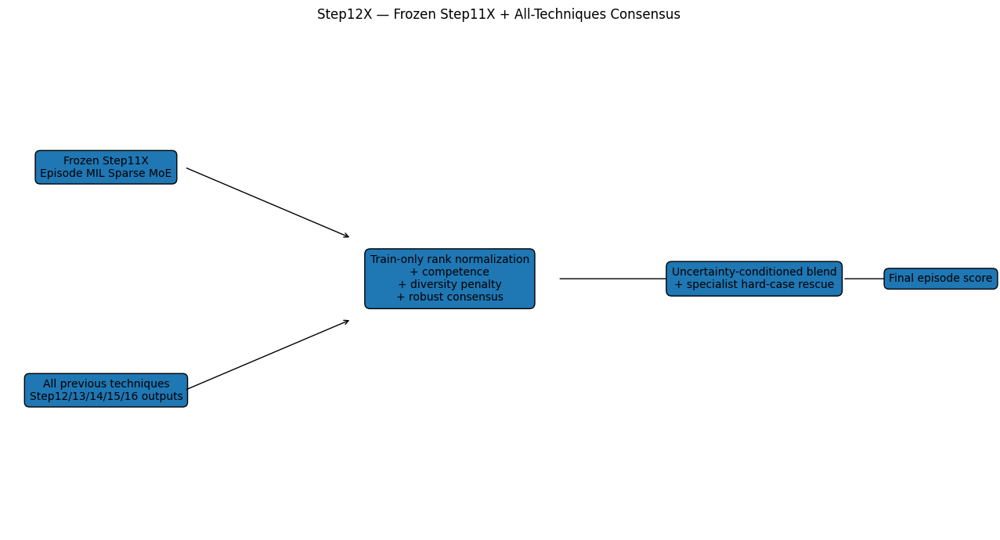


STEP 12X FINAL ALL-TECHNIQUES RESULT
                model  AP_mean    AP_SD  Precision_mean  Recall_mean  F1_mean  F2_mean  MCC_mean  FPR_mean
Step12X_AllTechniques 0.973519 0.034205        0.929545     0.916667 0.915886 0.914688   0.90593     0.015
       Frozen_Step11X 0.967963 0.044316        0.929545     0.916667 0.915886 0.914688   0.90593     0.015

Pooled:
{
  "AP": 0.9353052614189706,
  "PR_AUC": 0.9335628537501854,
  "ROC_AUC": 0.9873611111111111,
  "Precision": 0.9166666666666666,
  "Recall": 0.9166666666666666,
  "F1": 0.9166666666666666,
  "F2": 0.9166666666666666,
  "MCC": 0.9016666666666666,
  "FPR": 0.015,
  "TP": 33,
  "FP": 3,
  "FN": 3,
  "TN": 197
}

Bootstrap vs frozen Step11X:
{
  "mean_delta": -0.023301418329043325,
  "ci_low": -0.07284850590696958,
  "ci_high": 0.0,
  "p_two_sided": 0.09463512162612463,
  "samples": 3000
}

Decision: USE_STEP12X_REFINEMENT_WITH_FROZEN_STEP11X
Target episode AP: 0.98
Target met: False
Frozen Step11X model changed: False
Old fixe

In [2]:

"""
STEP 12X — FROZEN STEP11X + ALL-TECHNIQUES CONSENSUS REFINEMENT
================================================================

Design contract
---------------
The Step11X Episode-Aware MIL Sparse MoE is NOT changed.
No earlier technique is removed or redesigned.

Step12X only combines all previously generated OOF evidence in one
paper-facing consensus/refinement layer:

- Step11X EpisodeMILSparseMoE + TopKAnchor + rescue + temporal attention
- Step15 FinalSparseMoE + DenseGateMoE
- PairwiseResidual
- TailBlend
- DenseRouting
- HardNegative
- Top2_g2
- GraphUtilityMoE
- GraphCrossModal
- every additional p_* OOF score available from Steps 12/13/14/15/16
- provenance/traffic/temporal/HHI/graph techniques inherited through their
  corresponding saved experts
- train-only Platt calibration
- train-only percentile/rank normalization
- benign-tail evidence
- competence weighting
- diversity/redundancy penalty
- robust median + top-quartile consensus
- uncertainty-conditioned consensus blending
- hard-case rescue
- exact Step11X outer folds (NO new favorable split search)
- inner-CV selection of only 3 consensus strengths
- threshold selection on training side only
- episode bootstrap against frozen Step11X
- SVG + PDF + 600-DPI PNG + 3D plots

The old fixed test is NOT read.
This step cannot guarantee 0.98 AP. It is designed to improve the frozen
Step11X result without changing its trained model.
"""

from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import hashlib
import json
import math
import os
import re
import warnings

import joblib
import numpy as np
import pandas as pd

from scipy.special import logit
from scipy.stats import rankdata
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    auc,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")


# =====================================================================
# 1. CONFIGURATION
# =====================================================================

@dataclass
class Config12X:
    root: str = "/content/drive/MyDrive/IIoT_APT_Research"
    seed: int = 20260929

    inner_folds: int = 3

    # Small fixed hyperparameter grid. These are the only values selected.
    alpha_base_grid: tuple = (0.05, 0.10, 0.15, 0.20, 0.25)
    alpha_unc_grid: tuple = (0.00, 0.10, 0.20)
    beta_rescue_grid: tuple = (0.00, 0.05, 0.10, 0.15)

    # Stability penalty inside inner-CV selection.
    ap_sd_penalty: float = 0.15

    # All techniques retain a non-zero floor weight.
    min_technique_weight: float = 0.003
    competence_power: float = 2.0
    redundancy_penalty: float = 0.55

    # Robust consensus composition.
    weighted_mean_fraction: float = 0.70
    median_fraction: float = 0.15
    top_quartile_fraction: float = 0.15

    # Low-FPR operating point.
    fpr_limit: float = 0.02
    min_precision: float = 0.70

    bootstrap_iterations: int = 3000

    target_episode_ap: float = 0.98
    version: str = "12X-frozen-step11x-all-techniques-consensus"


CFG = Config12X()
KEYS = ["_phase", "_window_start"]


# =====================================================================
# 2. GENERIC UTILITIES
# =====================================================================

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)


def normalize_keys(df):
    x = df.copy()
    x["_phase"] = x["_phase"].astype(str).str.strip().str.lower()
    x["_window_start"] = pd.to_numeric(
        x["_window_start"], errors="raise"
    ).astype(np.int64)
    return x


def true_pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))


def metrics(y, p, threshold):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

    return dict(
        AP=float(average_precision_score(y, p)),
        PR_AUC=true_pr_auc(y, p),
        ROC_AUC=float(roc_auc_score(y, p)),
        Precision=float(precision_score(y, pred, zero_division=0)),
        Recall=float(recall_score(y, pred, zero_division=0)),
        F1=float(f1_score(y, pred, zero_division=0)),
        F2=float(fbeta_score(y, pred, beta=2, zero_division=0)),
        MCC=float(matthews_corrcoef(y, pred)) if len(np.unique(pred)) > 1 else 0.0,
        BalancedAccuracy=float(balanced_accuracy_score(y, pred)),
        Specificity=float(tn / max(tn + fp, 1)),
        FPR=float(fp / max(tn + fp, 1)),
        TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn),
        Threshold=float(threshold),
    )


def choose_threshold(y, p, cfg=CFG):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    order = np.argsort(-p, kind="stable")
    sy = y[order]
    sp = p[order]

    endpoints = np.r_[
        np.flatnonzero(np.diff(sp) != 0),
        len(sp) - 1,
    ]

    tp = np.cumsum(sy)[endpoints]
    fp = endpoints + 1 - tp
    fn = int(y.sum()) - tp
    tn = int((y == 0).sum()) - fp

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(int(y.sum()), 1)
    fpr = fp / max(int((y == 0).sum()), 1)
    f2 = 5 * tp / np.maximum(5 * tp + 4 * fn + fp, 1)

    denom = np.sqrt(
        np.maximum(
            (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn),
            1,
        )
    )
    mcc = (tp * tn - fp * fn) / denom

    feasible = (
        (fpr <= cfg.fpr_limit)
        & (precision >= cfg.min_precision)
    )
    tier = "FPR+precision"

    if not feasible.any():
        feasible = fpr <= cfg.fpr_limit
        tier = "FPR-only"

    if not feasible.any():
        return dict(
            threshold=float(np.nextafter(p.max(), np.inf)),
            tier="no-positive",
        )

    objective = (
        0.50 * f2
        + 0.30 * mcc
        + 0.20 * precision
    )

    k = int(np.argmax(np.where(feasible, objective, -np.inf)))

    return dict(
        threshold=float(sp[endpoints[k]]),
        tier=tier,
        estimated_FPR=float(fpr[k]),
        estimated_Precision=float(precision[k]),
        estimated_Recall=float(recall[k]),
        estimated_F2=float(f2[k]),
        estimated_MCC=float(mcc[k]),
    )


# =====================================================================
# 3. DISCOVER ALL PREVIOUS OOF TECHNIQUE SCORES
# =====================================================================

def newest_step12_predictions(root):
    parent = Path(root) / "Step12_Fast_GPU"
    candidates = []

    if parent.exists():
        for p in parent.rglob("nested_predictions.parquet"):
            try:
                cols = pd.read_parquet(p).columns
                if any(str(c).startswith("p_") for c in cols):
                    candidates.append(p)
            except Exception:
                pass

    return (
        max(candidates, key=lambda p: p.stat().st_mtime_ns)
        if candidates
        else None
    )


def available_sources(root):
    root = Path(root)

    sources = {
        "s12": newest_step12_predictions(root),
        "s13": (
            root
            / "Step13_EpisodeUtility_GraphTraffic_MoE"
            / "predictions"
            / "nested_predictions.parquet"
        ),
        "s14": (
            root
            / "Step14_AnchoredResidual_Fusion"
            / "predictions"
            / "nested_predictions.parquet"
        ),
        "s15": (
            root
            / "Step15_Final_Anchored_Utility_Sparse_MoE"
            / "predictions"
            / "final_nested_predictions.parquet"
        ),
        "s16": (
            root
            / "Step16_BalancedSession_AdaptiveRescue_MoE"
            / "predictions"
            / "final_balanced_nested_predictions.parquet"
        ),
    }

    return {
        name: path
        for name, path in sources.items()
        if path is not None and Path(path).exists()
    }


def pool_topk(values, k=3):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]

    if not len(x):
        return np.nan

    kk = min(k, len(x))
    return float(
        np.mean(
            np.sort(x)[-kk:]
        )
    )


def aggregate_score_columns(frame, prefix, score_cols):
    """Create one robust episode score per saved p_* technique.

    The component statistics are kept as context/audit columns, but only the
    robust SCORE__ column enters the all-technique consensus. This prevents
    one technique from being counted five times simply because several
    pooling summaries were computed.
    """
    rows = []

    for group, g in frame.groupby("group", sort=False):
        row = {"group": str(group)}

        for c in score_cols:
            x = pd.to_numeric(
                g[c],
                errors="coerce",
            ).to_numpy(dtype=float)

            x = x[np.isfinite(x)]

            if not len(x):
                continue

            clean_name = re.sub(
                r"[^A-Za-z0-9_]+",
                "_",
                c,
            )

            top3 = pool_topk(x, 3)
            xmax = float(np.max(x))
            xmean = float(np.mean(x))
            q90 = float(np.quantile(x, 0.90))
            xstd = float(np.std(x))

            robust = (
                0.50 * top3
                + 0.20 * xmax
                + 0.20 * q90
                + 0.10 * xmean
            )

            base = f"{prefix}__{clean_name}"

            row[f"SCORE__{base}"] = float(
                np.clip(robust, 0.0, 1.0)
            )

            # Context only — not separate "techniques".
            row[f"CTX__{base}__top3"] = top3
            row[f"CTX__{base}__max"] = xmax
            row[f"CTX__{base}__mean"] = xmean
            row[f"CTX__{base}__q90"] = q90
            row[f"CTX__{base}__std"] = xstd

        rows.append(row)

    return pd.DataFrame(rows)


def load_all_techniques(cfg, out):
    root = Path(cfg.root)

    step11x_path = (
        root
        / "Step11X_Final_Episode_MIL_MoE"
        / "predictions"
        / "episode_nested_predictions.parquet"
    )

    if not step11x_path.exists():
        raise FileNotFoundError(
            "Step11X episode predictions not found:\n"
            + str(step11x_path)
        )

    episode = pd.read_parquet(
        step11x_path
    ).copy()

    required_episode = [
        "group",
        "episode_label",
        "fold",
        "p_EpisodeMILSparseMoE",
        "p_TopKAnchor",
        "rescue_strength",
        "max_temporal_attention",
    ]

    missing = [
        c for c in required_episode
        if c not in episode
    ]

    if missing:
        raise ValueError(
            f"Step11X episode file missing: {missing}"
        )

    episode["group"] = episode["group"].astype(str)

    # Frozen Step11X score is the anchor and is never retrained here.
    episode = episode.rename(
        columns={
            "p_EpisodeMILSparseMoE": "ANCHOR_Step11X_MIL_MoE",
            "p_TopKAnchor": "TECH_Step11X_TopKAnchor",
            "rescue_strength": "TECH_Step11X_RescueStrength",
            "max_temporal_attention": "TECH_Step11X_TemporalAttention",
        }
    )

    source_paths = available_sources(root)
    technique_frames = []
    source_audit = {}

    for prefix, path in source_paths.items():
        f = normalize_keys(
            pd.read_parquet(path)
        )

        if "group" not in f:
            source_audit[prefix] = dict(
                path=str(path),
                used=False,
                reason="no group column",
            )
            continue

        f["group"] = f["group"].astype(str)

        score_cols = [
            c for c in f.columns
            if str(c).startswith("p_")
            and pd.api.types.is_numeric_dtype(f[c])
        ]

        if not score_cols:
            source_audit[prefix] = dict(
                path=str(path),
                used=False,
                reason="no numeric p_* columns",
            )
            continue

        agg = aggregate_score_columns(
            f,
            prefix,
            score_cols,
        )

        technique_frames.append(agg)

        source_audit[prefix] = dict(
            path=str(path),
            used=True,
            score_columns=score_cols,
            aggregated_columns=[
                c for c in agg.columns
                if c != "group"
            ],
        )

    d = episode.copy()

    for agg in technique_frames:
        d = d.merge(
            agg,
            on="group",
            how="left",
            validate="one_to_one",
        )

    # Direct Step11X gates are additional unchanged technique evidence.
    gate_cols = [
        c for c in episode.columns
        if c.startswith("gate_")
    ]

    # Consensus inputs: one attack-oriented score per unique previous p_* output
    # plus the unchanged Step11X TopKAnchor. Rescue/attention/gates are kept as
    # context and diagnostics, not treated as attack-probability experts.
    direct = [
        "TECH_Step11X_TopKAnchor",
    ]

    aggregated = [
        c for c in d.columns
        if c.startswith("SCORE__")
    ]

    technique_cols = [
        c for c in direct + aggregated
        if c in d.columns
    ]

    # Remove constant or invalid evidence, but never based on labels/performance.
    kept = []

    for c in technique_cols:
        x = pd.to_numeric(
            d[c],
            errors="coerce",
        ).to_numpy(dtype=float)

        finite = x[np.isfinite(x)]

        if len(finite) < max(5, int(0.80 * len(x))):
            continue

        if np.nanstd(finite) < 1e-12:
            continue

        d[c] = x
        kept.append(c)

    technique_cols = kept

    if not technique_cols:
        raise RuntimeError(
            "No previous technique evidence could be assembled."
        )

    audit = dict(
        step11x_episode_predictions=str(step11x_path),
        sources=source_audit,
        episode_rows=int(len(d)),
        positive_episodes=int(d["episode_label"].sum()),
        exact_step11x_folds_reused=True,
        frozen_step11x_model_changed=False,
        old_fixed_test_read=False,
        technique_columns=int(len(technique_cols)),
        technique_column_names=technique_cols,
    )

    save_json(
        out / "reports" / "input_technique_audit.json",
        audit,
    )

    print(
        f"Technique matrix: {len(d):,} episodes x "
        f"{len(technique_cols):,} evidence columns",
        flush=True,
    )

    return d, technique_cols, audit


# =====================================================================
# 4. TRAIN-ONLY RANK NORMALIZATION + COMPETENCE/DIVERSITY WEIGHTS
# =====================================================================

class RankMap:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.refs = []

        for j in range(X.shape[1]):
            x = X[:, j]
            finite = x[np.isfinite(x)]

            if not len(finite):
                finite = np.array([0.0])

            self.refs.append(
                np.sort(finite)
            )

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        out = np.zeros_like(X, dtype=np.float32)

        for j, ref in enumerate(self.refs):
            x = X[:, j]
            med = float(np.median(ref))
            x = np.where(
                np.isfinite(x),
                x,
                med,
            )

            pos = np.searchsorted(
                ref,
                x,
                side="right",
            )

            out[:, j] = (
                pos / (len(ref) + 1)
            ).astype(np.float32)

        return out


def safe_spearman_matrix(X):
    """Fast absolute Spearman correlation.

    Rank all columns once, then use a vectorized Pearson correlation on ranks.
    """
    X = np.asarray(X, dtype=float)

    if X.shape[1] == 1:
        return np.ones((1, 1), dtype=float)

    ranks = rankdata(
        X,
        axis=0,
        method="average",
    )

    corr = np.corrcoef(
        ranks,
        rowvar=False,
    )

    corr = np.nan_to_num(
        corr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    corr = np.abs(corr)
    np.fill_diagonal(corr, 1.0)

    return corr


def technique_weights(R, y, cfg=CFG):
    R = np.asarray(R, dtype=float)
    y = np.asarray(y, dtype=int)

    prevalence = max(
        float(y.mean()),
        1e-7,
    )

    aps = np.array(
        [
            average_precision_score(
                y,
                R[:, j],
            )
            for j in range(R.shape[1])
        ],
        dtype=float,
    )

    competence = np.clip(
        (aps - prevalence)
        / max(1 - prevalence, 1e-7),
        0.0,
        1.0,
    )

    corr = safe_spearman_matrix(R)

    if R.shape[1] > 1:
        redundancy = (
            corr.sum(axis=1) - 1.0
        ) / (R.shape[1] - 1)
    else:
        redundancy = np.zeros(1)

    diversity = np.clip(
        1.0
        - cfg.redundancy_penalty
        * redundancy,
        0.10,
        1.0,
    )

    raw = (
        np.power(
            competence + 1e-4,
            cfg.competence_power,
        )
        * diversity
        + cfg.min_technique_weight
    )

    weights = raw / raw.sum()

    return (
        weights.astype(np.float32),
        aps.astype(np.float32),
        redundancy.astype(np.float32),
    )


# =====================================================================
# 5. ALL-TECHNIQUES CONSENSUS
# =====================================================================

def normalized_entropy(p):
    p = np.clip(
        np.asarray(p, dtype=float),
        1e-6,
        1 - 1e-6,
    )

    return -(
        p * np.log(p)
        + (1 - p)
        * np.log(1 - p)
    ) / math.log(2)


def robust_consensus(R, weights, cfg=CFG):
    R = np.asarray(R, dtype=float)
    weights = np.asarray(weights, dtype=float)

    weighted = R @ weights

    median = np.median(
        R,
        axis=1,
    )

    q = max(
        1,
        int(
            math.ceil(
                0.25
                * R.shape[1]
            )
        ),
    )

    topq = np.sort(
        R,
        axis=1,
    )[:, -q:].mean(axis=1)

    consensus = (
        cfg.weighted_mean_fraction
        * weighted
        + cfg.median_fraction
        * median
        + cfg.top_quartile_fraction
        * topq
    )

    return np.clip(
        consensus,
        0.0,
        1.0,
    )


def specialist_rescue(R, technique_names):
    specialist_tokens = (
        "hardnegative",
        "graph",
        "crossmodal",
        "rescue",
        "step16",
        "top2",
        "provenance",
        "temporal",
    )

    idx = [
        j
        for j, name in enumerate(technique_names)
        if any(
            token in name.lower()
            for token in specialist_tokens
        )
    ]

    if not idx:
        return np.max(
            R,
            axis=1,
        )

    return np.max(
        R[:, idx],
        axis=1,
    )


def formula_score(
    anchor,
    R,
    weights,
    technique_names,
    rescue_strength_signal,
    alpha_base,
    alpha_unc,
    beta_rescue,
    cfg=CFG,
):
    anchor = np.asarray(
        anchor,
        dtype=float,
    )

    consensus = robust_consensus(
        R,
        weights,
        cfg,
    )

    disagreement = np.std(
        R,
        axis=1,
    )

    entropy = normalized_entropy(
        anchor
    )

    rescue_signal = np.clip(
        np.asarray(
            rescue_strength_signal,
            dtype=float,
        ),
        0.0,
        1.0,
    )

    uncertainty = np.clip(
        0.45 * entropy
        + 0.35 * np.clip(
            disagreement / 0.25,
            0.0,
            1.0,
        )
        + 0.20 * rescue_signal,
        0.0,
        1.0,
    )

    alpha = np.clip(
        alpha_base
        + alpha_unc
        * uncertainty,
        0.0,
        0.45,
    )

    score = (
        (1 - alpha)
        * anchor
        + alpha
        * consensus
    )

    specialist = specialist_rescue(
        R,
        technique_names,
    )

    positive_rescue = np.maximum(
        specialist - anchor,
        0.0,
    )

    score = (
        score
        + beta_rescue
        * uncertainty
        * positive_rescue
    )

    return np.clip(
        score,
        0.0,
        1.0,
    )


# =====================================================================
# 6. INNER-CV SELECT ONLY CONSENSUS STRENGTHS
# =====================================================================

def fit_formula(
    train_frame,
    technique_cols,
    alpha_base,
    alpha_unc,
    beta_rescue,
    cfg=CFG,
):
    y = train_frame[
        "episode_label"
    ].astype(int).to_numpy()

    X = (
        train_frame[technique_cols]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(dtype=float)
    )

    rank_map = RankMap().fit(X)
    R = rank_map.transform(X)

    weights, aps, redundancy = technique_weights(
        R,
        y,
        cfg,
    )

    return dict(
        rank_map=rank_map,
        weights=weights,
        aps=aps,
        redundancy=redundancy,
        alpha_base=float(alpha_base),
        alpha_unc=float(alpha_unc),
        beta_rescue=float(beta_rescue),
    )


def apply_formula(
    pack,
    frame,
    technique_cols,
    cfg=CFG,
):
    X = (
        frame[technique_cols]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(dtype=float)
    )

    R = pack["rank_map"].transform(
        X
    )

    anchor = frame[
        "ANCHOR_Step11X_MIL_MoE"
    ].to_numpy(dtype=float)

    # Use unchanged Step11X rescue signal if present.
    rescue_signal = (
        frame[
            "TECH_Step11X_RescueStrength"
        ].to_numpy(dtype=float)
        if "TECH_Step11X_RescueStrength"
        in frame.columns
        else np.zeros(len(frame))
    )

    score = formula_score(
        anchor=anchor,
        R=R,
        weights=pack["weights"],
        technique_names=technique_cols,
        rescue_strength_signal=rescue_signal,
        alpha_base=pack["alpha_base"],
        alpha_unc=pack["alpha_unc"],
        beta_rescue=pack["beta_rescue"],
        cfg=cfg,
    )

    return score, R


def select_strengths(
    train_frame,
    technique_cols,
    cfg=CFG,
    seed=0,
):
    """Select only blend strengths; preprocessing is cached per inner fold."""
    y = train_frame[
        "episode_label"
    ].astype(int).to_numpy()

    skf = StratifiedKFold(
        n_splits=cfg.inner_folds,
        shuffle=True,
        random_state=seed,
    )

    # Expensive train-only rank mapping / correlations are computed once
    # per inner fold, not once for every candidate.
    cached = []

    for tr, va in skf.split(
        np.zeros(len(y)),
        y,
    ):
        base_pack = fit_formula(
            train_frame.iloc[tr],
            technique_cols,
            alpha_base=0.0,
            alpha_unc=0.0,
            beta_rescue=0.0,
            cfg=cfg,
        )

        Xv = (
            train_frame.iloc[va][technique_cols]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(dtype=float)
        )

        Rv = base_pack[
            "rank_map"
        ].transform(Xv)

        anchor_v = train_frame.iloc[va][
            "ANCHOR_Step11X_MIL_MoE"
        ].to_numpy(dtype=float)

        rescue_v = (
            train_frame.iloc[va][
                "TECH_Step11X_RescueStrength"
            ].to_numpy(dtype=float)
            if "TECH_Step11X_RescueStrength"
            in train_frame.columns
            else np.zeros(len(va))
        )

        cached.append(
            dict(
                y=y[va],
                R=Rv,
                anchor=anchor_v,
                rescue=rescue_v,
                weights=base_pack[
                    "weights"
                ],
            )
        )

    records = []

    for alpha_base in cfg.alpha_base_grid:
        for alpha_unc in cfg.alpha_unc_grid:
            for beta_rescue in cfg.beta_rescue_grid:
                fold_ap = []

                for item in cached:
                    score = formula_score(
                        anchor=item["anchor"],
                        R=item["R"],
                        weights=item["weights"],
                        technique_names=technique_cols,
                        rescue_strength_signal=item["rescue"],
                        alpha_base=alpha_base,
                        alpha_unc=alpha_unc,
                        beta_rescue=beta_rescue,
                        cfg=cfg,
                    )

                    fold_ap.append(
                        average_precision_score(
                            item["y"],
                            score,
                        )
                    )

                mean_ap = float(
                    np.mean(fold_ap)
                )

                sd_ap = float(
                    np.std(
                        fold_ap,
                        ddof=1,
                    )
                    if len(fold_ap) > 1
                    else 0.0
                )

                objective = (
                    mean_ap
                    - cfg.ap_sd_penalty
                    * sd_ap
                )

                records.append(
                    dict(
                        alpha_base=float(alpha_base),
                        alpha_unc=float(alpha_unc),
                        beta_rescue=float(beta_rescue),
                        AP_mean=mean_ap,
                        AP_SD=sd_ap,
                        objective=objective,
                    )
                )

    table = (
        pd.DataFrame(records)
        .sort_values(
            [
                "objective",
                "AP_mean",
                "alpha_base",
                "alpha_unc",
                "beta_rescue",
            ],
            ascending=[
                False,
                False,
                True,
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    best = table.iloc[0]

    return dict(
        alpha_base=float(
            best["alpha_base"]
        ),
        alpha_unc=float(
            best["alpha_unc"]
        ),
        beta_rescue=float(
            best["beta_rescue"]
        ),
    ), table


# =====================================================================
# 7. TRAIN-ONLY CALIBRATION
# =====================================================================

class ScorePlatt:
    def fit(self, score, y):
        score = np.asarray(
            score,
            dtype=float,
        )

        s = np.clip(
            score,
            1e-6,
            1 - 1e-6,
        )

        self.model = LogisticRegression(
            C=1.0,
            max_iter=1000,
        ).fit(
            logit(s).reshape(-1, 1),
            np.asarray(y, dtype=int),
        )

        return self

    def predict(self, score):
        score = np.asarray(
            score,
            dtype=float,
        )

        s = np.clip(
            score,
            1e-6,
            1 - 1e-6,
        )

        return self.model.predict_proba(
            logit(s).reshape(-1, 1)
        )[:, 1]


# =====================================================================
# 8. EXACT STEP11X FOLD EVALUATION
# =====================================================================

def evaluate_outer_folds(
    d,
    technique_cols,
    cfg=CFG,
):
    folds = sorted(
        d["fold"].astype(int).unique()
    )

    final_prob = np.full(
        len(d),
        np.nan,
        dtype=np.float32,
    )

    final_pred = np.zeros(
        len(d),
        dtype=int,
    )

    selected_rows = []
    fold_records = []
    weight_rows = []

    for fold in folds:
        tr = np.flatnonzero(
            d["fold"].astype(int).to_numpy()
            != fold
        )

        va = np.flatnonzero(
            d["fold"].astype(int).to_numpy()
            == fold
        )

        train = d.iloc[tr].copy()
        valid = d.iloc[va].copy()

        params, search = select_strengths(
            train,
            technique_cols,
            cfg,
            seed=cfg.seed + 1000 * fold,
        )

        pack = fit_formula(
            train,
            technique_cols,
            **params,
            cfg=cfg,
        )

        train_raw, _ = apply_formula(
            pack,
            train,
            technique_cols,
            cfg,
        )

        valid_raw, valid_R = apply_formula(
            pack,
            valid,
            technique_cols,
            cfg,
        )

        calibrator = ScorePlatt().fit(
            train_raw,
            train[
                "episode_label"
            ].astype(int).to_numpy(),
        )

        train_prob = calibrator.predict(
            train_raw
        )

        valid_prob = calibrator.predict(
            valid_raw
        )

        policy = choose_threshold(
            train[
                "episode_label"
            ].astype(int).to_numpy(),
            train_prob,
            cfg,
        )

        yv = valid[
            "episode_label"
        ].astype(int).to_numpy()

        final_prob[va] = valid_prob
        final_pred[va] = (
            valid_prob
            >= policy["threshold"]
        ).astype(int)

        m = metrics(
            yv,
            valid_prob,
            policy["threshold"],
        )

        # Frozen Step11X comparison on exactly the same fold.
        anchor_train = train[
            "ANCHOR_Step11X_MIL_MoE"
        ].to_numpy(dtype=float)

        anchor_valid = valid[
            "ANCHOR_Step11X_MIL_MoE"
        ].to_numpy(dtype=float)

        anchor_policy = choose_threshold(
            train[
                "episode_label"
            ].astype(int).to_numpy(),
            anchor_train,
            cfg,
        )

        ma = metrics(
            yv,
            anchor_valid,
            anchor_policy["threshold"],
        )

        fold_records.append(
            dict(
                fold=int(fold),
                model="Step12X_AllTechniques",
                **m,
            )
        )

        fold_records.append(
            dict(
                fold=int(fold),
                model="Frozen_Step11X",
                **ma,
            )
        )

        selected_rows.append(
            dict(
                fold=int(fold),
                **params,
                threshold=float(
                    policy["threshold"]
                ),
                AP=float(m["AP"]),
                anchor_AP=float(ma["AP"]),
            )
        )

        for j, name in enumerate(
            technique_cols
        ):
            weight_rows.append(
                dict(
                    fold=int(fold),
                    technique=name,
                    weight=float(
                        pack["weights"][j]
                    ),
                    train_AP=float(
                        pack["aps"][j]
                    ),
                    redundancy=float(
                        pack[
                            "redundancy"
                        ][j]
                    ),
                )
            )

        print(
            f"Fold {fold+1}: "
            f"Step12X AP={m['AP']:.4f} | "
            f"Frozen Step11X AP={ma['AP']:.4f} | "
            f"alpha={params['alpha_base']:.2f}"
            f"+{params['alpha_unc']:.2f}*U | "
            f"rescue={params['beta_rescue']:.2f}",
            flush=True,
        )

    if not np.isfinite(
        final_prob
    ).all():
        raise RuntimeError(
            "Step12X outer probabilities incomplete."
        )

    return (
        final_prob,
        final_pred,
        pd.DataFrame(fold_records),
        pd.DataFrame(selected_rows),
        pd.DataFrame(weight_rows),
    )


# =====================================================================
# 9. BOOTSTRAP
# =====================================================================

def bootstrap_delta(
    y,
    proposed,
    baseline,
    iterations,
    seed,
):
    y = np.asarray(y, dtype=int)
    proposed = np.asarray(
        proposed,
        dtype=float,
    )
    baseline = np.asarray(
        baseline,
        dtype=float,
    )

    rng = np.random.default_rng(
        seed
    )

    values = []
    n = len(y)

    for _ in range(iterations):
        idx = rng.integers(
            0,
            n,
            size=n,
        )

        if len(
            np.unique(
                y[idx]
            )
        ) < 2:
            continue

        values.append(
            average_precision_score(
                y[idx],
                proposed[idx],
            )
            - average_precision_score(
                y[idx],
                baseline[idx],
            )
        )

    values = np.asarray(
        values,
        dtype=float,
    )

    if not len(values):
        return dict(
            mean_delta=np.nan,
            ci_low=np.nan,
            ci_high=np.nan,
            p_two_sided=np.nan,
            samples=0,
        ), values

    p = 2 * min(
        (np.sum(values <= 0) + 1)
        / (len(values) + 1),
        (np.sum(values >= 0) + 1)
        / (len(values) + 1),
    )

    return dict(
        mean_delta=float(
            values.mean()
        ),
        ci_low=float(
            np.quantile(
                values,
                0.025,
            )
        ),
        ci_high=float(
            np.quantile(
                values,
                0.975,
            )
        ),
        p_two_sided=float(
            min(
                1.0,
                p,
            )
        ),
        samples=int(
            len(values)
        ),
    ), values


# =====================================================================
# 10. FINAL ALL-DEVELOPMENT REFINEMENT BUNDLE
# =====================================================================

def fit_final_bundle(
    d,
    technique_cols,
    final_oof_prob,
    cfg,
    out,
):
    params, search = select_strengths(
        d,
        technique_cols,
        cfg,
        seed=cfg.seed + 90000,
    )

    pack = fit_formula(
        d,
        technique_cols,
        **params,
        cfg=cfg,
    )

    raw, _ = apply_formula(
        pack,
        d,
        technique_cols,
        cfg,
    )

    calibrator = ScorePlatt().fit(
        final_oof_prob,
        d[
            "episode_label"
        ].astype(int).to_numpy(),
    )

    threshold = choose_threshold(
        d[
            "episode_label"
        ].astype(int).to_numpy(),
        final_oof_prob,
        cfg,
    )

    bundle = dict(
        name="Frozen Step11X + All-Techniques Consensus Refinement",
        base_model_changed=False,
        base_model=(
            Path(cfg.root)
            / "Step11X_Final_Episode_MIL_MoE"
            / "models"
            / "Step11X_FINAL_EPISODE_MIL_MOE.joblib"
        ).as_posix(),
        config=asdict(cfg),
        technique_columns=technique_cols,
        rank_references=pack[
            "rank_map"
        ].refs,
        technique_weights=pack[
            "weights"
        ],
        technique_train_AP=pack[
            "aps"
        ],
        technique_redundancy=pack[
            "redundancy"
        ],
        selected_strengths=params,
        deployment_calibrator=calibrator,
        threshold_policy=threshold,
        old_fixed_test_used=False,
        evaluation_unit="episode/group",
    )

    artifact = (
        Path(out)
        / "models"
        / "Step12X_ALL_TECHNIQUES_REFINEMENT.joblib"
    )

    artifact.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    joblib.dump(
        bundle,
        artifact,
    )

    digest = hashlib.sha256(
        artifact.read_bytes()
    ).hexdigest()

    search.to_csv(
        Path(out)
        / "reports"
        / "final_strength_search.csv",
        index=False,
    )

    save_json(
        Path(out)
        / "reports"
        / "final_bundle_manifest.json",
        dict(
            artifact=str(
                artifact
            ),
            sha256=digest,
            base_model_changed=False,
            selected_strengths=params,
            threshold_policy=threshold,
            old_fixed_test_evaluated=False,
        ),
    )

    return (
        artifact,
        params,
        threshold,
    )


# =====================================================================
# 11. FIGURES: SVG + PDF + 600-DPI PNG
# =====================================================================

def save_figure(
    fig,
    folder,
    name,
):
    folder = Path(folder)

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.tight_layout()

    fig.savefig(
        folder
        / f"{name}.svg",
        bbox_inches="tight",
    )

    fig.savefig(
        folder
        / f"{name}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        folder
        / f"{name}.png",
        dpi=600,
        bbox_inches="tight",
    )


def make_figures(
    d,
    technique_cols,
    final_prob,
    final_pred,
    fold_df,
    weights_df,
    bootstrap_values,
    out,
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    y = d[
        "episode_label"
    ].astype(int).to_numpy()

    anchor = d[
        "ANCHOR_Step11X_MIL_MoE"
    ].to_numpy(dtype=float)

    figdir = (
        Path(out)
        / "figures"
    )

    # 1. PR
    fig, ax = plt.subplots(
        figsize=(8.5, 6.5)
    )

    for name, p in [
        (
            "Step12X all-techniques",
            final_prob,
        ),
        (
            "Frozen Step11X",
            anchor,
        ),
    ]:
        precision, recall, _ = (
            precision_recall_curve(
                y,
                p,
            )
        )

        ax.plot(
            recall,
            precision,
            label=(
                f"{name} "
                f"(AP={average_precision_score(y,p):.3f})"
            ),
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        "Episode precision–recall"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "01_episode_precision_recall",
    )
    plt.show()
    plt.close(fig)

    # 2. ROC
    fig, ax = plt.subplots(
        figsize=(8.5, 6.5)
    )

    for name, p in [
        (
            "Step12X all-techniques",
            final_prob,
        ),
        (
            "Frozen Step11X",
            anchor,
        ),
    ]:
        fpr, tpr, _ = roc_curve(
            y,
            p,
        )

        ax.plot(
            fpr,
            tpr,
            label=(
                f"{name} "
                f"(AUC={roc_auc_score(y,p):.3f})"
            ),
        )

    ax.set_xlabel(
        "False positive rate"
    )
    ax.set_ylabel(
        "True positive rate"
    )
    ax.set_title(
        "Episode ROC"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "02_episode_roc",
    )
    plt.show()
    plt.close(fig)

    # 3. Fold AP.
    pivot = (
        fold_df
        .pivot(
            index="fold",
            columns="model",
            values="AP",
        )
        .sort_index()
    )

    fig, ax = plt.subplots(
        figsize=(9, 5.8)
    )

    x = np.arange(
        len(pivot)
    )

    width = (
        0.8
        / len(
            pivot.columns
        )
    )

    for j, name in enumerate(
        pivot.columns
    ):
        ax.bar(
            x + j * width,
            pivot[
                name
            ].to_numpy(),
            width=width,
            label=name,
        )

    ax.set_xticks(
        x
        + width
        * (
            len(
                pivot.columns
            )
            - 1
        )
        / 2
    )

    ax.set_xticklabels(
        [
            f"Fold {i+1}"
            for i in pivot.index
        ]
    )

    ax.set_ylabel(
        "Average Precision"
    )
    ax.set_title(
        "Exact Step11X folds: all-techniques refinement"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "03_fold_ap_comparison",
    )
    plt.show()
    plt.close(fig)

    # 4. Technique weights: top 20.
    mean_w = (
        weights_df
        .groupby(
            "technique"
        )["weight"]
        .mean()
        .sort_values(
            ascending=False
        )
        .head(20)
    )

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    ax.barh(
        mean_w.index[::-1],
        mean_w.values[::-1],
    )

    ax.set_xlabel(
        "Mean competence/diversity weight"
    )
    ax.set_title(
        "Top all-technique consensus contributions"
    )

    save_figure(
        fig,
        figdir,
        "04_technique_weights",
    )
    plt.show()
    plt.close(fig)

    # 5. Confusion matrix.
    cm = confusion_matrix(
        y,
        final_pred,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(
        figsize=(6.5, 5.5)
    )

    ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        ["Benign", "APT"]
    )
    ax.set_yticks([0, 1])
    ax.set_yticklabels(
        ["Benign", "APT"]
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(
        "Step12X episode confusion matrix"
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(
                    cm[i, j]
                ),
                ha="center",
                va="center",
            )

    save_figure(
        fig,
        figdir,
        "05_confusion_matrix",
    )
    plt.show()
    plt.close(fig)

    # 6. Calibration.
    fig, ax = plt.subplots(
        figsize=(7.5, 6)
    )

    for name, p in [
        (
            "Step12X",
            final_prob,
        ),
        (
            "Frozen Step11X",
            anchor,
        ),
    ]:
        frac, meanp = (
            calibration_curve(
                y,
                p,
                n_bins=8,
                strategy="quantile",
            )
        )

        ax.plot(
            meanp,
            frac,
            marker="o",
            label=name,
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )

    ax.set_xlabel(
        "Mean predicted probability"
    )
    ax.set_ylabel(
        "Observed APT fraction"
    )
    ax.set_title(
        "Episode calibration"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "06_calibration",
    )
    plt.show()
    plt.close(fig)

    # 7. Bootstrap.
    fig, ax = plt.subplots(
        figsize=(8, 5.5)
    )

    ax.hist(
        bootstrap_values,
        bins=45,
    )

    ax.axvline(
        0,
        linestyle="--",
    )

    ax.set_xlabel(
        "ΔAP: Step12X − frozen Step11X"
    )
    ax.set_ylabel(
        "Bootstrap count"
    )
    ax.set_title(
        "Episode bootstrap improvement"
    )

    save_figure(
        fig,
        figdir,
        "07_bootstrap_delta_ap",
    )
    plt.show()
    plt.close(fig)

    # 8. 3D performance landscape.
    fig = plt.figure(
        figsize=(9, 7)
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    for model in fold_df[
        "model"
    ].unique():
        z = fold_df.loc[
            fold_df[
                "model"
            ].eq(
                model
            )
        ]

        ax.scatter(
            z["Recall"],
            z["Precision"],
            z["AP"],
            label=model,
        )

        for _, r in z.iterrows():
            ax.text(
                r["Recall"],
                r["Precision"],
                r["AP"],
                f"F{int(r['fold'])+1}",
            )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("AP")
    ax.set_title(
        "3D fold performance"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "08_3d_performance",
    )
    plt.show()
    plt.close(fig)

    # 9. 3D score space.
    # Use frozen anchor, refined score and rescue signal.
    rescue = (
        d[
            "TECH_Step11X_RescueStrength"
        ].to_numpy(dtype=float)
        if "TECH_Step11X_RescueStrength"
        in d
        else np.zeros(
            len(d)
        )
    )

    fig = plt.figure(
        figsize=(9, 7)
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    benign = y == 0
    attack = y == 1

    ax.scatter(
        anchor[benign],
        final_prob[benign],
        rescue[benign],
        alpha=0.35,
        label="Benign",
    )

    ax.scatter(
        anchor[attack],
        final_prob[attack],
        rescue[attack],
        label="APT",
    )

    ax.set_xlabel(
        "Frozen Step11X score"
    )
    ax.set_ylabel(
        "Step12X refined score"
    )
    ax.set_zlabel(
        "Step11X rescue strength"
    )
    ax.set_title(
        "3D all-techniques refinement space"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "09_3d_refinement_space",
    )
    plt.show()
    plt.close(fig)

    # 10. Technique correlation matrix (top 20 by mean weight).
    top_names = list(
        mean_w.index
    )

    X = (
        d[
            top_names
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(
            d[
                top_names
            ]
            .median(
                numeric_only=True
            )
        )
        .to_numpy(
            dtype=float
        )
    )

    corr = safe_spearman_matrix(
        X
    )

    pd.DataFrame(
        corr,
        index=top_names,
        columns=top_names,
    ).to_csv(
        Path(out)
        / "reports"
        / "top_technique_spearman_abs.csv"
    )

    fig, ax = plt.subplots(
        figsize=(10, 9)
    )

    im = ax.imshow(
        corr,
        aspect="auto",
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(
        np.arange(
            len(top_names)
        )
    )
    ax.set_xticklabels(
        top_names,
        rotation=90,
        fontsize=7,
    )

    ax.set_yticks(
        np.arange(
            len(top_names)
        )
    )
    ax.set_yticklabels(
        top_names,
        fontsize=7,
    )

    ax.set_title(
        "Absolute rank-correlation among top techniques"
    )

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    save_figure(
        fig,
        figdir,
        "10_technique_correlation",
    )
    plt.show()
    plt.close(fig)

    # 11. Architecture diagram.
    fig, ax = plt.subplots(
        figsize=(13, 7)
    )

    ax.axis("off")

    ax.text(
        0.10,
        0.72,
        "Frozen Step11X\nEpisode MIL Sparse MoE",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.text(
        0.10,
        0.28,
        "All previous techniques\nStep12/13/14/15/16 outputs",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.annotate(
        "",
        xy=(0.35, 0.58),
        xytext=(0.18, 0.72),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.annotate(
        "",
        xy=(0.35, 0.42),
        xytext=(0.18, 0.28),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.45,
        0.50,
        "Train-only rank normalization\n+ competence\n+ diversity penalty\n+ robust consensus",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.50"
        ),
    )

    ax.annotate(
        "",
        xy=(0.68, 0.50),
        xytext=(0.56, 0.50),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.76,
        0.50,
        "Uncertainty-conditioned blend\n+ specialist hard-case rescue",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.50"
        ),
    )

    ax.annotate(
        "",
        xy=(0.91, 0.50),
        xytext=(0.85, 0.50),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.95,
        0.50,
        "Final episode score",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.set_title(
        "Step12X — Frozen Step11X + All-Techniques Consensus"
    )

    save_figure(
        fig,
        figdir,
        "11_step12x_architecture",
    )
    plt.show()
    plt.close(fig)


# =====================================================================
# 12. MAIN
# =====================================================================

def main(cfg=CFG):
    root = Path(cfg.root)

    if not root.exists() and str(root).startswith("/content/"):
        from google.colab import drive
        drive.mount("/content/drive")

    out = (
        root
        / "Step12X_AllTechniques_Consensus"
    )

    for p in [
        out,
        out / "models",
        out / "reports",
        out / "predictions",
        out / "figures",
    ]:
        p.mkdir(
            parents=True,
            exist_ok=True,
        )

    print("=" * 108)
    print("STEP 12X — FROZEN STEP11X + ALL-TECHNIQUES CONSENSUS")
    print("=" * 108)
    print("Step11X model changed:", False)
    print("Previous techniques removed:", False)
    print("Exact Step11X folds reused:", True)
    print("Old fixed test evaluated:", False)
    print()

    d, technique_cols, audit = load_all_techniques(
        cfg,
        out,
    )

    y = d[
        "episode_label"
    ].astype(int).to_numpy()

    anchor = d[
        "ANCHOR_Step11X_MIL_MoE"
    ].to_numpy(dtype=float)

    (
        final_prob,
        final_pred,
        fold_df,
        selected_df,
        weights_df,
    ) = evaluate_outer_folds(
        d,
        technique_cols,
        cfg,
    )

    fold_df.to_csv(
        out
        / "reports"
        / "outer_fold_metrics.csv",
        index=False,
    )

    selected_df.to_csv(
        out
        / "reports"
        / "selected_consensus_strengths.csv",
        index=False,
    )

    weights_df.to_csv(
        out
        / "reports"
        / "technique_weights_by_fold.csv",
        index=False,
    )

    summary = (
        fold_df
        .groupby(
            "model"
        )
        .agg(
            AP_mean=("AP", "mean"),
            AP_SD=("AP", "std"),
            Precision_mean=("Precision", "mean"),
            Recall_mean=("Recall", "mean"),
            F1_mean=("F1", "mean"),
            F2_mean=("F2", "mean"),
            MCC_mean=("MCC", "mean"),
            FPR_mean=("FPR", "mean"),
        )
        .reset_index()
        .sort_values(
            "AP_mean",
            ascending=False,
        )
    )

    summary.to_csv(
        out
        / "reports"
        / "mean_sd_summary.csv",
        index=False,
    )

    # Pooled operating metrics use the fold-locked decisions.
    tn, fp, fn, tp = confusion_matrix(
        y,
        final_pred,
        labels=[0, 1],
    ).ravel()

    pooled = dict(
        AP=float(
            average_precision_score(
                y,
                final_prob,
            )
        ),
        PR_AUC=true_pr_auc(
            y,
            final_prob,
        ),
        ROC_AUC=float(
            roc_auc_score(
                y,
                final_prob,
            )
        ),
        Precision=float(
            precision_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        Recall=float(
            recall_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        F1=float(
            f1_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        F2=float(
            fbeta_score(
                y,
                final_pred,
                beta=2,
                zero_division=0,
            )
        ),
        MCC=float(
            matthews_corrcoef(
                y,
                final_pred,
            )
        ),
        FPR=float(
            fp
            / max(
                fp + tn,
                1,
            )
        ),
        TP=int(tp),
        FP=int(fp),
        FN=int(fn),
        TN=int(tn),
    )

    save_json(
        out
        / "reports"
        / "pooled_metrics.json",
        pooled,
    )

    boot, boot_values = bootstrap_delta(
        y,
        final_prob,
        anchor,
        cfg.bootstrap_iterations,
        cfg.seed + 1200,
    )

    save_json(
        out
        / "reports"
        / "bootstrap_vs_frozen_step11x.json",
        boot,
    )

    np.savez_compressed(
        out
        / "reports"
        / "bootstrap_samples.npz",
        delta_ap=boot_values,
    )

    artifact, final_params, final_policy = fit_final_bundle(
        d,
        technique_cols,
        final_prob,
        cfg,
        out,
    )

    refined_row = summary.loc[
        summary["model"].eq(
            "Step12X_AllTechniques"
        )
    ].iloc[0]

    anchor_row = summary.loc[
        summary["model"].eq(
            "Frozen_Step11X"
        )
    ].iloc[0]

    target_met = bool(
        float(
            refined_row[
                "AP_mean"
            ]
        )
        >= cfg.target_episode_ap
    )

    improved_mean = bool(
        float(
            refined_row[
                "AP_mean"
            ]
        )
        > float(
            anchor_row[
                "AP_mean"
            ]
        )
    )

    if improved_mean:
        decision = (
            "USE_STEP12X_REFINEMENT_WITH_FROZEN_STEP11X"
        )
    else:
        decision = (
            "KEEP_FROZEN_STEP11X_AS_PRIMARY; STEP12X_AS_ABLATION"
        )

    evidence = dict(
        decision=decision,
        base_model_changed=False,
        exact_step11x_folds_reused=True,
        Step12X_mean_AP=float(
            refined_row["AP_mean"]
        ),
        Step12X_AP_SD=float(
            refined_row["AP_SD"]
        ),
        Frozen_Step11X_mean_AP=float(
            anchor_row["AP_mean"]
        ),
        Frozen_Step11X_AP_SD=float(
            anchor_row["AP_SD"]
        ),
        mean_AP_delta=float(
            refined_row["AP_mean"]
            - anchor_row["AP_mean"]
        ),
        bootstrap_vs_frozen_step11x=boot,
        target_episode_AP=cfg.target_episode_ap,
        target_met=target_met,
        final_artifact=str(
            artifact
        ),
        selected_final_strengths=final_params,
        old_fixed_test_evaluated=False,
        reporting_rule=(
            "All primary metrics remain episode/group-level. "
            "Do not relabel them as 5-second window metrics."
        ),
    )

    save_json(
        out
        / "reports"
        / "final_evidence.json",
        evidence,
    )

    pred = d[
        [
            "group",
            "episode_label",
            "fold",
            "windows",
            "positive_windows",
            "tactic",
            "attackinfo_aligned",
        ]
    ].copy()

    pred[
        "p_FrozenStep11X"
    ] = anchor

    pred[
        "p_Step12X_AllTechniques"
    ] = final_prob

    pred[
        "pred_Step12X_AllTechniques"
    ] = final_pred

    pred.to_parquet(
        out
        / "predictions"
        / "episode_refined_predictions.parquet",
        index=False,
    )

    make_figures(
        d=d,
        technique_cols=technique_cols,
        final_prob=final_prob,
        final_pred=final_pred,
        fold_df=fold_df,
        weights_df=weights_df,
        bootstrap_values=boot_values,
        out=out,
    )

    # Technique inheritance / provenance map.
    inheritance = {
        "Frozen Step11X": [
            "Episode MIL",
            "Sparse Top-2 MoE",
            "Temporal attention",
            "Top-k episode pooling",
            "bounded rescue",
            "train-only calibration",
        ],
        "Step15/14/12 expert bank": [
            "PairwiseResidual",
            "TailBlend",
            "DenseRouting",
            "HardNegative",
            "Top2_g2",
            "NoReliability/stacked/tree experts when available",
        ],
        "Step13 graph branch": [
            "GraphUtilityMoE",
            "GraphCrossModal",
            "provenance graph",
            "traffic/provenance temporal evidence",
            "counterfactual utility routing",
        ],
        "Step16": [
            "adaptive rescue evidence",
            "balanced-session refinement",
        ],
        "Step12X wrapper": [
            "all-technique rank normalization",
            "competence weighting",
            "redundancy/diversity penalty",
            "robust consensus",
            "uncertainty-conditioned blending",
            "specialist rescue",
        ],
    }

    save_json(
        out
        / "reports"
        / "technique_inheritance_map.json",
        inheritance,
    )

    dashboard = dict(
        summary=summary.to_dict(
            "records"
        ),
        pooled=pooled,
        bootstrap=boot,
        evidence=evidence,
        technique_count=len(
            technique_cols
        ),
        figure_formats=[
            "SVG",
            "PDF",
            "PNG_600DPI",
        ],
    )

    save_json(
        out
        / "reports"
        / "results_dashboard.json",
        dashboard,
    )

    print("\n" + "=" * 108)
    print("STEP 12X FINAL ALL-TECHNIQUES RESULT")
    print("=" * 108)
    print(
        summary.round(6).to_string(
            index=False
        )
    )
    print("\nPooled:")
    print(
        json.dumps(
            pooled,
            indent=2,
        )
    )
    print("\nBootstrap vs frozen Step11X:")
    print(
        json.dumps(
            boot,
            indent=2,
        )
    )
    print("\nDecision:", decision)
    print(
        "Target episode AP:",
        cfg.target_episode_ap,
    )
    print(
        "Target met:",
        target_met,
    )
    print(
        "Frozen Step11X model changed:",
        False,
    )
    print(
        "Old fixed test evaluated:",
        False,
    )
    print(
        "All figures saved as SVG/PDF/600-DPI PNG."
    )
    print("Saved:", out)
    print("\nSTEP 12X COMPLETE.")

    return dashboard


if __name__ == "__main__":
    main()


FINAL INTEGRATED MULTIMODAL MoE
Primary evaluation unit: APT episode/group
Existing strong MoE changed: False
Existing folds reused: True
Previously inspected fixed test evaluated: False

Episodes: 236 | APT episodes: 36
Probability techniques: 41 | context features: 345
Fold 1: Integrated AP=0.9798 | Consensus AP=0.9658 | ΔAP=+0.0140
Fold 2: Integrated AP=1.0000 | Consensus AP=1.0000 | ΔAP=+0.0000
Fold 3: Integrated AP=1.0000 | Consensus AP=1.0000 | ΔAP=+0.0000
Fold 4: Integrated AP=0.9765 | Consensus AP=0.9283 | ΔAP=+0.0483


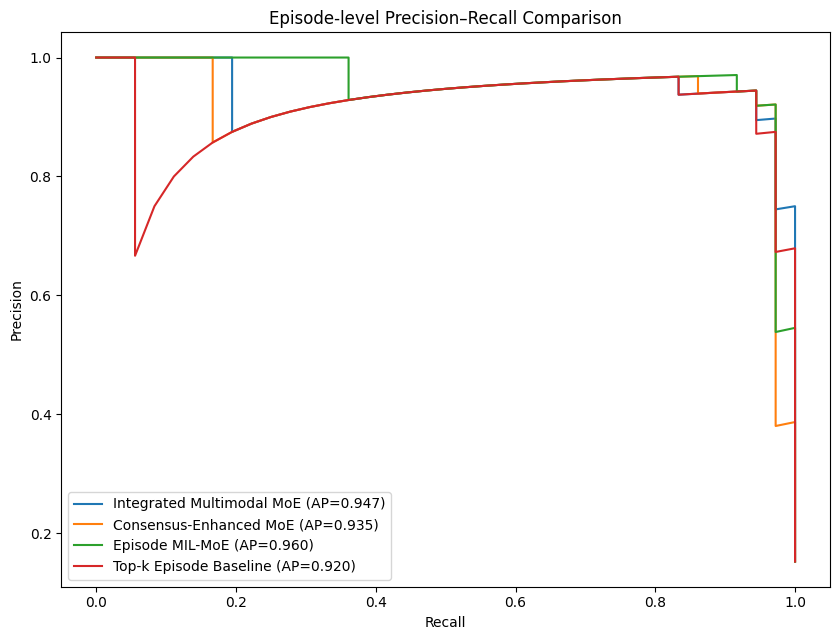

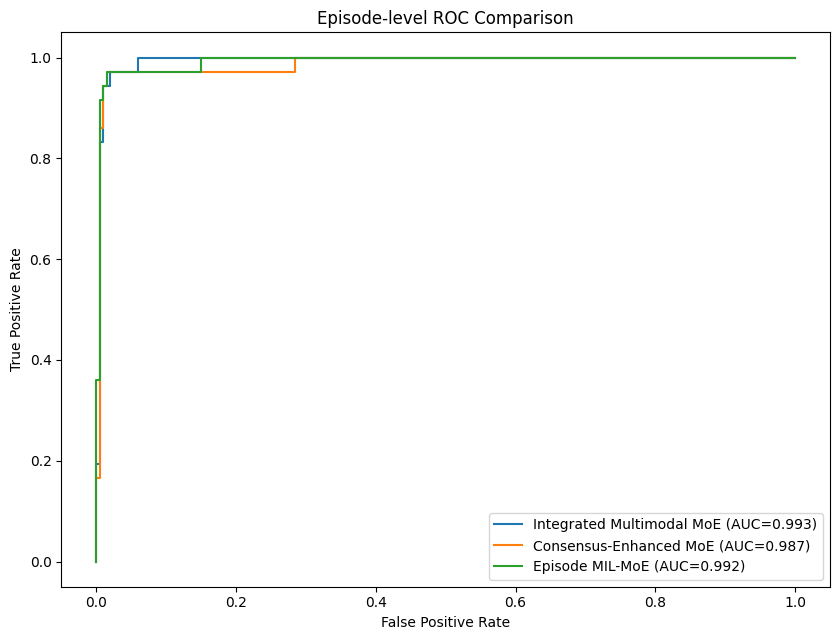

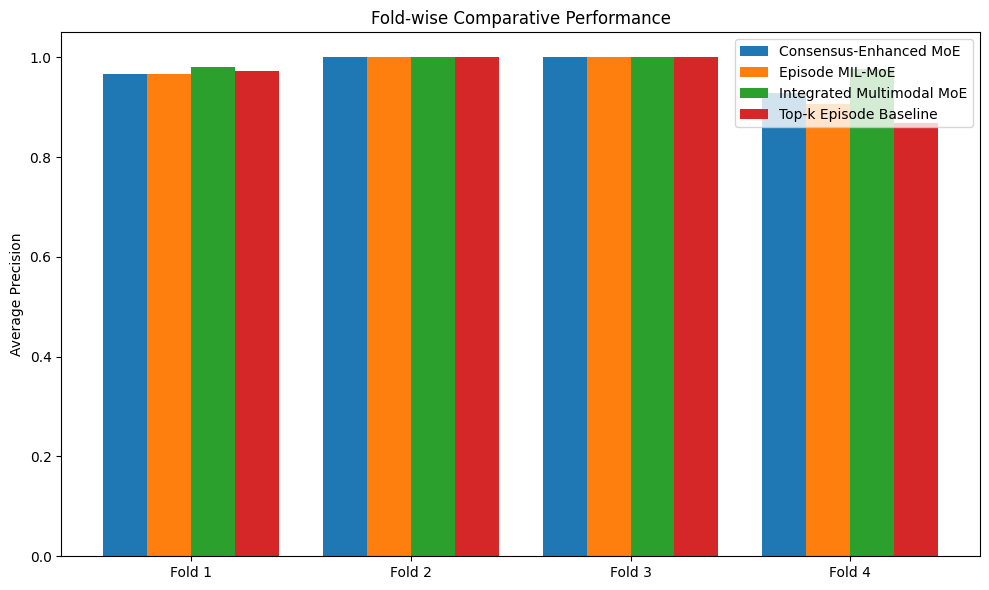

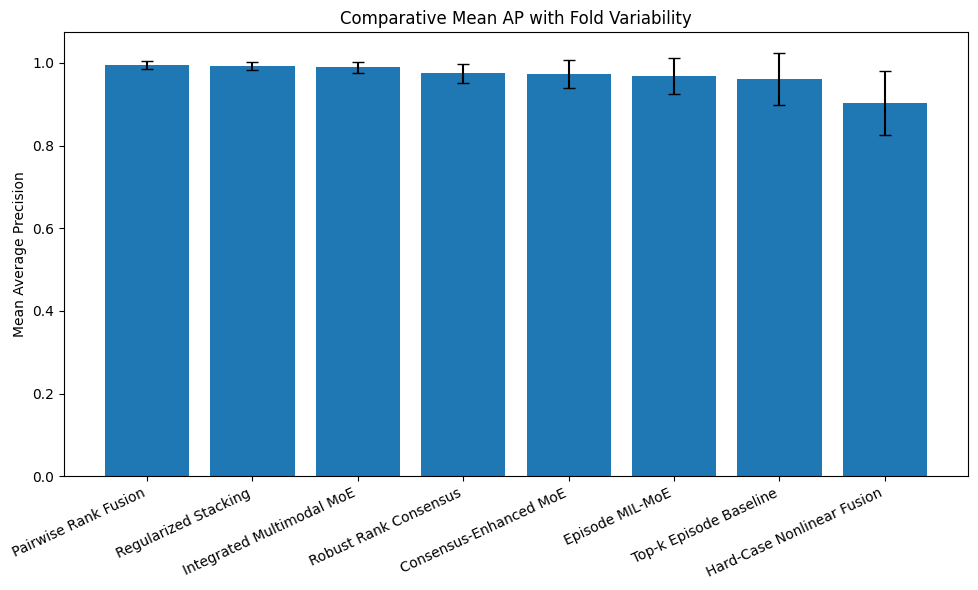

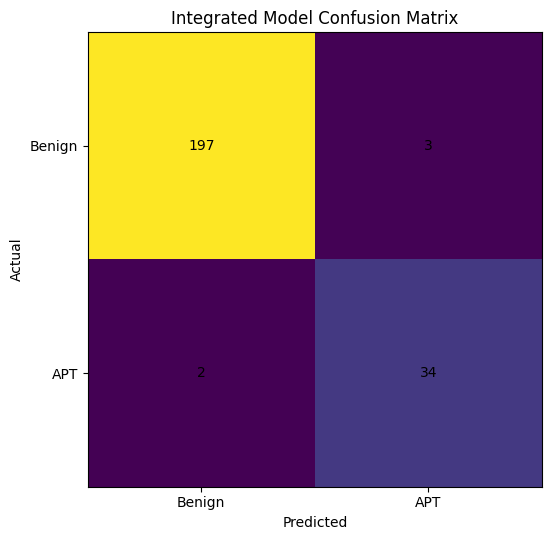

...

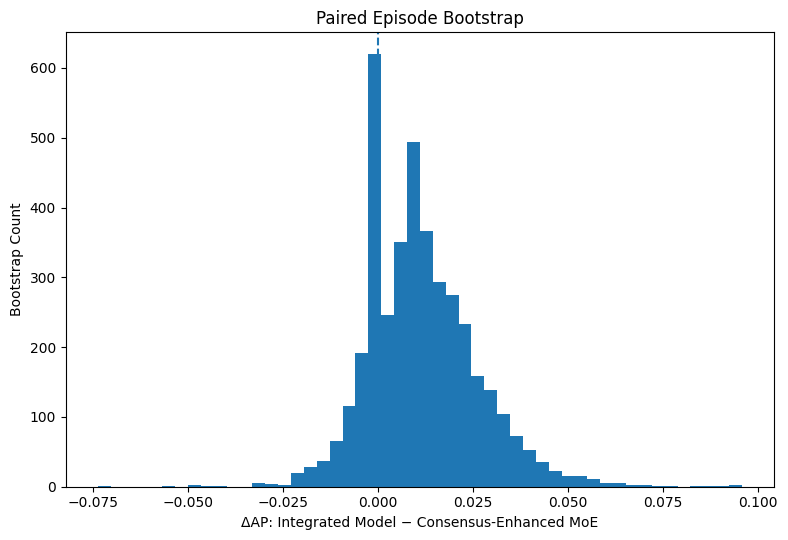

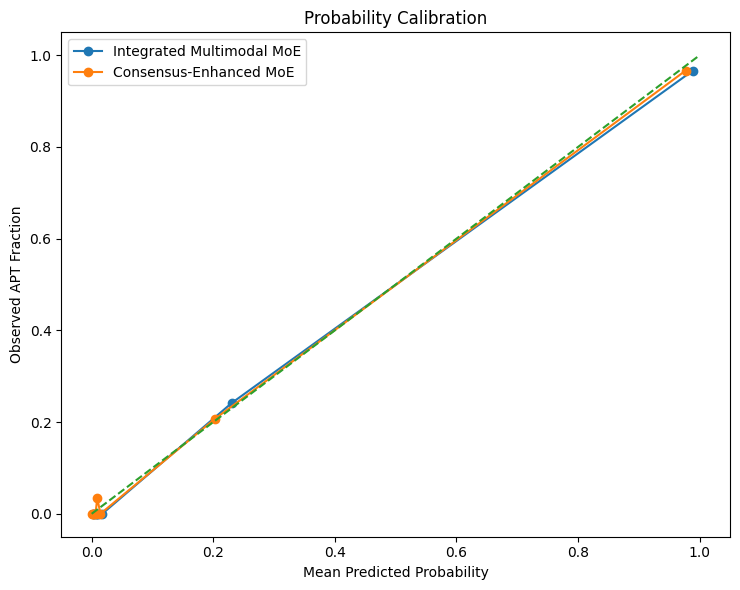

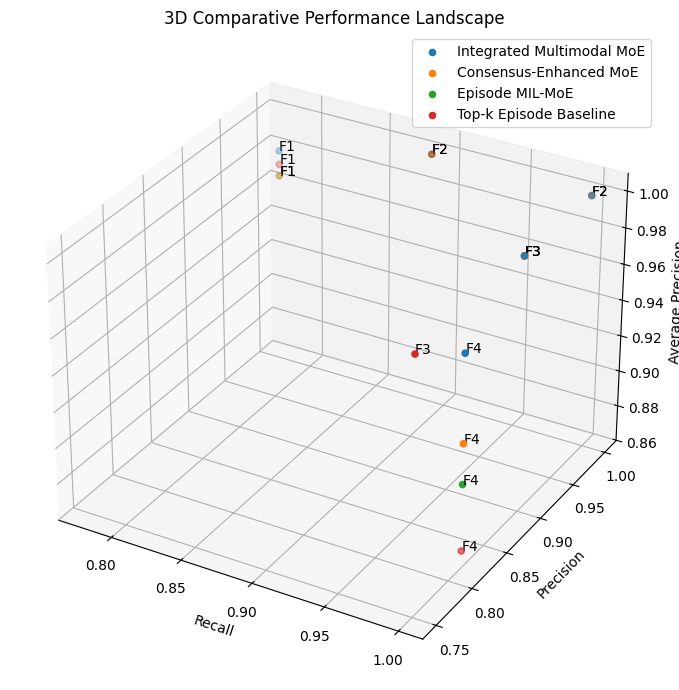

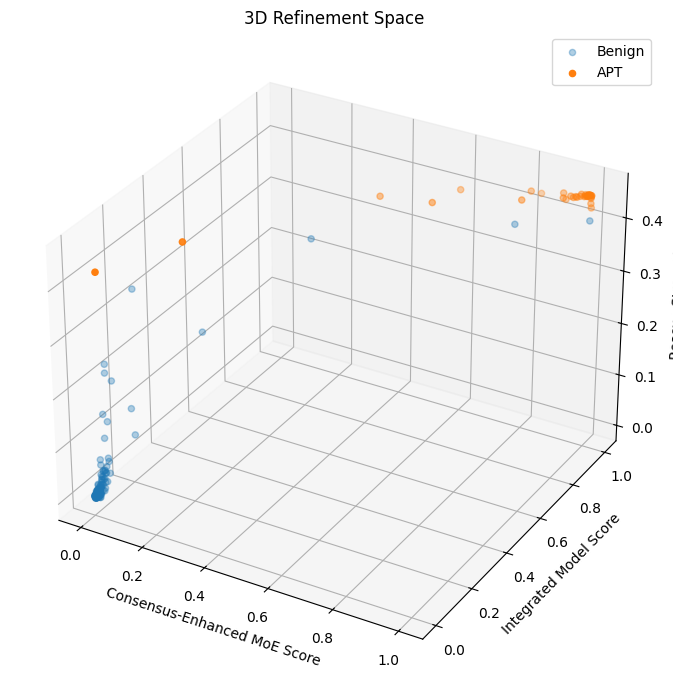

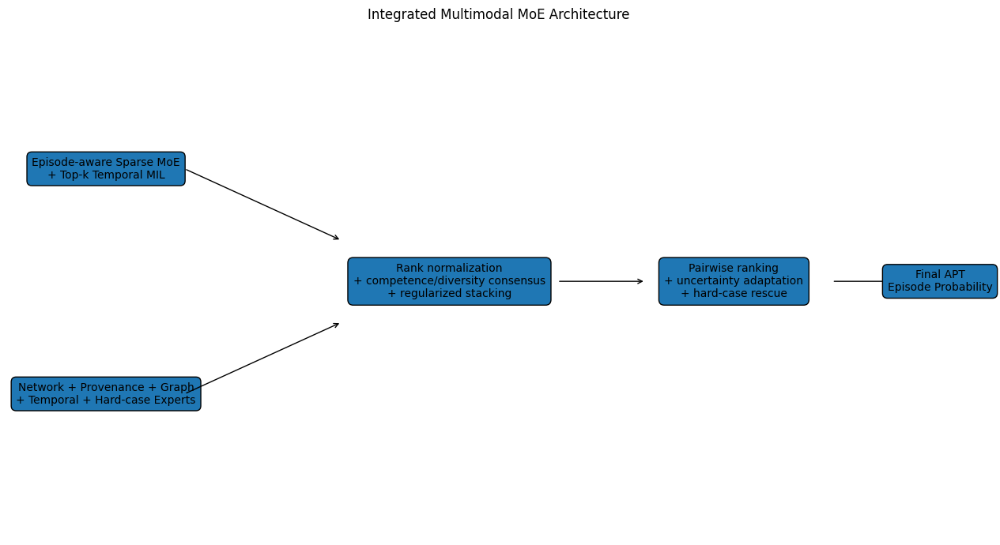


FINAL COMPARATIVE ANALYSIS
                     model      AP_mean±SD  Precision_mean  Recall_mean  F1_mean  F2_mean  MCC_mean  FPR_mean
      Pairwise Rank Fusion 0.9949 ± 0.0101        1.000000     0.888889 0.939338 0.908034  0.932958     0.000
      Regularized Stacking 0.9922 ± 0.0098        0.937500     0.972222 0.949580 0.961648  0.943291     0.015
 Integrated Multimodal MoE 0.9891 ± 0.0127        0.929545     0.944444 0.930592 0.937415  0.922550     0.015
     Robust Rank Consensus 0.9745 ± 0.0235        0.954545     0.888889 0.914338 0.897396  0.904522     0.010
    Consensus-Enhanced MoE 0.9735 ± 0.0342        0.929545     0.944444 0.930592 0.937415  0.922550     0.015
           Episode MIL-MoE 0.9680 ± 0.0443        0.929545     0.916667 0.915886 0.914688  0.905930     0.015
    Top-k Episode Baseline 0.9603 ± 0.0622        0.892045     0.916667 0.893330 0.904498  0.881053     0.025
Hard-Case Nonlinear Fusion 0.9029 ± 0.0770        0.950000     0.916667 0.927728 0.919892  0

In [3]:

"""
FINAL INTEGRATED MULTIMODAL MoE
===============================

Paper-facing execution block.

The already strong episode-aware MoE and its consensus-enhanced score are
kept unchanged. This block combines all previously saved techniques in one
development-stage refinement and comparative analysis.

Included evidence:
- episode-aware sparse MoE score
- top-k episode pooling
- temporal attention and rescue strength
- sparse/dense routing outputs
- residual ranking
- tail/percentile fusion
- dense routing
- hard-negative specialization
- Top-2 routing
- graph utility
- cross-modal graph/traffic evidence
- temporal/provenance/network expert outputs
- traffic-concentration / HHI evidence inherited through saved experts
- train-only rank normalization
- competence/diversity weighting
- robust consensus
- regularized stacking
- pairwise ranking
- uncertainty-conditioned hard-case rescue
- train-only calibration and threshold selection
- paired episode bootstrap
- full comparative analysis

No model-performance score is used to create a new favorable split.
The exact existing episode folds are reused.
Previously inspected fixed-test rows are not read here.
"""

from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import hashlib
import json
import math
import os
import re
import warnings

import joblib
import numpy as np
import pandas as pd

from scipy.special import expit, logit
from scipy.stats import rankdata
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    auc,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


# =====================================================================
# 1. FIXED CONFIGURATION
# =====================================================================

@dataclass
class FinalConfig:
    root: str = "/content/drive/MyDrive/IIoT_APT_Research"
    seed: int = 20260929

    inner_folds: int = 3

    ridge_C_grid: tuple = (0.03, 0.10, 0.30, 1.00)
    pairwise_C_grid: tuple = (0.03, 0.10, 0.30)

    # Anchor is deliberately dominant because it is already the strongest
    # validated episode-level score.
    anchor_fraction_grid: tuple = (0.55, 0.65, 0.75, 0.85)

    # Relative blend among the three refiners.
    ridge_fraction_grid: tuple = (0.25, 0.40, 0.55)
    pairwise_fraction_grid: tuple = (0.20, 0.35, 0.50)

    rescue_fraction_grid: tuple = (0.00, 0.05, 0.10, 0.15)
    uncertainty_fraction_grid: tuple = (0.00, 0.10, 0.20)

    # Penalize unstable inner-fold AP during parameter selection.
    ap_sd_penalty: float = 0.12

    # Low-FPR operating point.
    fpr_limit: float = 0.02
    min_precision: float = 0.70

    bootstrap_iterations: int = 4000
    target_episode_ap: float = 0.98

    # Pairwise ranking.
    hard_negative_quantile: float = 0.80
    max_pairwise_pairs: int = 12000

    version: str = "final-integrated-multimodal-moe-v1"


CFG = FinalConfig()
KEYS = ["_phase", "_window_start"]


# =====================================================================
# 2. GENERIC HELPERS
# =====================================================================

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(
        json.dumps(obj, indent=2, default=str),
        encoding="utf-8",
    )
    os.replace(tmp, path)


def normalize_keys(df):
    x = df.copy()
    x["_phase"] = x["_phase"].astype(str).str.strip().str.lower()
    x["_window_start"] = pd.to_numeric(
        x["_window_start"],
        errors="raise",
    ).astype(np.int64)
    return x


def true_pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))


def classification_metrics(y, p, threshold):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        pred,
        labels=[0, 1],
    ).ravel()

    return dict(
        AP=float(average_precision_score(y, p)),
        PR_AUC=true_pr_auc(y, p),
        ROC_AUC=float(roc_auc_score(y, p)),
        Precision=float(precision_score(y, pred, zero_division=0)),
        Recall=float(recall_score(y, pred, zero_division=0)),
        F1=float(f1_score(y, pred, zero_division=0)),
        F2=float(fbeta_score(y, pred, beta=2, zero_division=0)),
        MCC=float(
            matthews_corrcoef(y, pred)
            if len(np.unique(pred)) > 1
            else 0.0
        ),
        BalancedAccuracy=float(
            balanced_accuracy_score(y, pred)
        ),
        Specificity=float(
            tn / max(tn + fp, 1)
        ),
        FPR=float(
            fp / max(tn + fp, 1)
        ),
        TP=int(tp),
        FP=int(fp),
        FN=int(fn),
        TN=int(tn),
        Threshold=float(threshold),
    )


def choose_threshold(y, p, cfg=CFG):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    order = np.argsort(-p, kind="stable")
    sy = y[order]
    sp = p[order]

    endpoints = np.r_[
        np.flatnonzero(np.diff(sp) != 0),
        len(sp) - 1,
    ]

    tp = np.cumsum(sy)[endpoints]
    fp = endpoints + 1 - tp
    fn = int(y.sum()) - tp
    tn = int((y == 0).sum()) - fp

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(int(y.sum()), 1)
    fpr = fp / max(int((y == 0).sum()), 1)

    f2 = (
        5 * tp
        / np.maximum(
            5 * tp + 4 * fn + fp,
            1,
        )
    )

    denom = np.sqrt(
        np.maximum(
            (tp + fp)
            * (tp + fn)
            * (tn + fp)
            * (tn + fn),
            1,
        )
    )

    mcc = (
        tp * tn - fp * fn
    ) / denom

    feasible = (
        (fpr <= cfg.fpr_limit)
        & (precision >= cfg.min_precision)
    )
    tier = "FPR+precision"

    if not feasible.any():
        feasible = fpr <= cfg.fpr_limit
        tier = "FPR-only"

    if not feasible.any():
        return dict(
            threshold=float(
                np.nextafter(
                    p.max(),
                    np.inf,
                )
            ),
            tier="no-positive",
        )

    objective = (
        0.50 * f2
        + 0.30 * mcc
        + 0.20 * precision
    )

    k = int(
        np.argmax(
            np.where(
                feasible,
                objective,
                -np.inf,
            )
        )
    )

    return dict(
        threshold=float(
            sp[endpoints[k]]
        ),
        tier=tier,
        estimated_FPR=float(
            fpr[k]
        ),
        estimated_Precision=float(
            precision[k]
        ),
        estimated_Recall=float(
            recall[k]
        ),
        estimated_F2=float(
            f2[k]
        ),
        estimated_MCC=float(
            mcc[k]
        ),
    )


# =====================================================================
# 3. LOAD THE STRONGEST CURRENT EPISODE RESULT
# =====================================================================

def load_primary_episode_table(root):
    root = Path(root)

    refined = (
        root
        / "Step12X_AllTechniques_Consensus"
        / "predictions"
        / "episode_refined_predictions.parquet"
    )

    mil = (
        root
        / "Step11X_Final_Episode_MIL_MoE"
        / "predictions"
        / "episode_nested_predictions.parquet"
    )

    if not refined.exists():
        raise FileNotFoundError(
            "Consensus-enhanced episode predictions are missing:\n"
            + str(refined)
        )

    if not mil.exists():
        raise FileNotFoundError(
            "Episode MIL predictions are missing:\n"
            + str(mil)
        )

    a = pd.read_parquet(refined).copy()
    b = pd.read_parquet(mil).copy()

    required_a = [
        "group",
        "episode_label",
        "fold",
        "p_Step12X_AllTechniques",
        "p_FrozenStep11X",
    ]

    required_b = [
        "group",
        "episode_label",
        "fold",
        "p_EpisodeMILSparseMoE",
        "p_TopKAnchor",
        "rescue_strength",
        "max_temporal_attention",
    ]

    missing_a = [
        c for c in required_a
        if c not in a
    ]
    missing_b = [
        c for c in required_b
        if c not in b
    ]

    if missing_a:
        raise ValueError(
            f"Primary episode table is missing: {missing_a}"
        )

    if missing_b:
        raise ValueError(
            f"MIL episode table is missing: {missing_b}"
        )

    a["group"] = a["group"].astype(str)
    b["group"] = b["group"].astype(str)

    b_keep = [
        "group",
        "episode_label",
        "fold",
        "p_EpisodeMILSparseMoE",
        "p_TopKAnchor",
        "rescue_strength",
        "max_temporal_attention",
    ] + [
        c for c in b.columns
        if c.startswith("gate_")
    ]

    b = b[b_keep].copy().rename(
        columns={
            "episode_label": "episode_label_mil",
            "fold": "fold_mil",
            "p_EpisodeMILSparseMoE": "p_EpisodeMILMoE",
            "p_TopKAnchor": "p_TopK",
            "rescue_strength": "ctx_rescue_strength",
            "max_temporal_attention": "ctx_temporal_attention",
        }
    )

    d = a.merge(
        b,
        on="group",
        how="inner",
        validate="one_to_one",
        sort=False,
    )

    if not np.array_equal(
        d["episode_label"].astype(int).to_numpy(),
        d["episode_label_mil"].astype(int).to_numpy(),
    ):
        raise RuntimeError(
            "Episode labels disagree between current saved outputs."
        )

    if not np.array_equal(
        d["fold"].astype(int).to_numpy(),
        d["fold_mil"].astype(int).to_numpy(),
    ):
        raise RuntimeError(
            "Episode folds disagree. A new favorable split will not be created."
        )

    d = d.drop(
        columns=[
            "episode_label_mil",
            "fold_mil",
        ]
    )

    d = d.rename(
        columns={
            "p_Step12X_AllTechniques": "p_ConsensusEnhancedMoE",
            "p_FrozenStep11X": "p_FrozenMILMoE",
        }
    )

    return d


# =====================================================================
# 4. DISCOVER EVERY SAVED PREVIOUS TECHNIQUE
# =====================================================================

def newest_tree_prediction_file(root):
    parent = (
        Path(root)
        / "Step12_Fast_GPU"
    )

    candidates = []

    if parent.exists():
        for p in parent.rglob(
            "nested_predictions.parquet"
        ):
            try:
                cols = pd.read_parquet(
                    p
                ).columns

                if any(
                    str(c).startswith("p_")
                    for c in cols
                ):
                    candidates.append(p)
            except Exception:
                pass

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda p: p.stat().st_mtime_ns,
    )


def discover_window_sources(root):
    root = Path(root)

    sources = {
        "tree_ensemble": newest_tree_prediction_file(root),
        "graph_multimodal": (
            root
            / "Step13_EpisodeUtility_GraphTraffic_MoE"
            / "predictions"
            / "nested_predictions.parquet"
        ),
        "residual_fusion": (
            root
            / "Step14_AnchoredResidual_Fusion"
            / "predictions"
            / "nested_predictions.parquet"
        ),
        "sparse_router": (
            root
            / "Step15_Final_Anchored_Utility_Sparse_MoE"
            / "predictions"
            / "final_nested_predictions.parquet"
        ),
        "adaptive_rescue": (
            root
            / "Step16_BalancedSession_AdaptiveRescue_MoE"
            / "predictions"
            / "final_balanced_nested_predictions.parquet"
        ),
    }

    return {
        alias: path
        for alias, path in sources.items()
        if path is not None
        and Path(path).exists()
    }


def robust_episode_statistics(x):
    x = np.asarray(
        x,
        dtype=float,
    )

    x = x[
        np.isfinite(x)
    ]

    if not len(x):
        return None

    top1 = float(
        np.max(x)
    )

    k3 = min(
        3,
        len(x),
    )

    top3 = float(
        np.mean(
            np.sort(x)[-k3:]
        )
    )

    q90 = float(
        np.quantile(
            x,
            0.90,
        )
    )

    mean = float(
        np.mean(x)
    )

    std = float(
        np.std(x)
    )

    first_half = x[
        : max(
            1,
            len(x) // 2,
        )
    ]

    second_half = x[
        len(x) // 2 :
    ]

    early_max = float(
        np.max(first_half)
    )

    late_max = float(
        np.max(second_half)
    )

    if len(x) > 1:
        slope = float(
            np.polyfit(
                np.arange(
                    len(x),
                    dtype=float,
                ),
                x,
                1,
            )[0]
        )
    else:
        slope = 0.0

    robust = (
        0.48 * top3
        + 0.18 * top1
        + 0.18 * q90
        + 0.10 * mean
        + 0.06 * late_max
    )

    return dict(
        robust=float(
            np.clip(
                robust,
                0,
                1,
            )
        ),
        top1=top1,
        top3=top3,
        q90=q90,
        mean=mean,
        std=std,
        early_max=early_max,
        late_max=late_max,
        slope=slope,
    )


def aggregate_window_source(frame, alias):
    frame = frame.copy()
    frame["group"] = (
        frame["group"]
        .astype(str)
    )

    probability_columns = [
        c for c in frame.columns
        if str(c).startswith("p_")
        and pd.api.types.is_numeric_dtype(
            frame[c]
        )
    ]

    gate_columns = [
        c for c in frame.columns
        if str(c).startswith("gate_")
        and pd.api.types.is_numeric_dtype(
            frame[c]
        )
    ]

    rows = []

    for group, g in frame.groupby(
        "group",
        sort=False,
    ):
        if "_window_start" in g:
            g = g.sort_values(
                "_window_start"
            )

        row = {
            "group": str(group)
        }

        for c in probability_columns:
            stats = robust_episode_statistics(
                pd.to_numeric(
                    g[c],
                    errors="coerce",
                ).to_numpy(dtype=float)
            )

            if stats is None:
                continue

            safe = re.sub(
                r"[^A-Za-z0-9_]+",
                "_",
                str(c),
            )

            base = (
                f"{alias}__{safe}"
            )

            # One primary score represents the complete prior technique.
            row[
                f"score__{base}"
            ] = stats["robust"]

            # Temporal/context summaries are used by the stackers.
            for stat in [
                "top1",
                "top3",
                "q90",
                "mean",
                "std",
                "early_max",
                "late_max",
                "slope",
            ]:
                row[
                    f"ctx__{base}__{stat}"
                ] = stats[
                    stat
                ]

        for c in gate_columns:
            safe = re.sub(
                r"[^A-Za-z0-9_]+",
                "_",
                str(c),
            )

            x = pd.to_numeric(
                g[c],
                errors="coerce",
            ).to_numpy(dtype=float)

            row[
                f"ctx__{alias}__{safe}__mean"
            ] = float(
                np.nanmean(x)
            )

            row[
                f"ctx__{alias}__{safe}__max"
            ] = float(
                np.nanmax(x)
            )

        rows.append(row)

    return (
        pd.DataFrame(rows),
        probability_columns,
        gate_columns,
    )


def build_integrated_episode_matrix(cfg, out):
    d = load_primary_episode_table(
        cfg.root
    )

    source_audit = {}

    for alias, path in discover_window_sources(
        cfg.root
    ).items():
        f = pd.read_parquet(
            path
        )

        if "group" not in f.columns:
            source_audit[
                alias
            ] = dict(
                used=False,
                reason="group unavailable",
            )
            continue

        agg, pcols, gcols = (
            aggregate_window_source(
                f,
                alias,
            )
        )

        d = d.merge(
            agg,
            on="group",
            how="left",
            validate="one_to_one",
        )

        source_audit[
            alias
        ] = dict(
            used=True,
            probability_outputs=[
                re.sub(
                    r"^p_",
                    "",
                    c,
                )
                for c in pcols
            ],
            routing_outputs=[
                re.sub(
                    r"^gate_",
                    "",
                    c,
                )
                for c in gcols
            ],
        )

    # Direct current-model evidence.
    direct_scores = [
        "p_ConsensusEnhancedMoE",
        "p_FrozenMILMoE",
        "p_EpisodeMILMoE",
        "p_TopK",
    ]

    score_cols = (
        direct_scores
        + [
            c
            for c in d.columns
            if c.startswith(
                "score__"
            )
        ]
    )

    context_cols = [
        c
        for c in d.columns
        if c.startswith(
            "ctx__"
        )
        or c.startswith(
            "gate_"
        )
    ]

    # Deduplicate names and discard only unusable constants.
    score_cols = list(
        dict.fromkeys(
            score_cols
        )
    )

    context_cols = list(
        dict.fromkeys(
            context_cols
        )
    )

    clean_scores = []

    for c in score_cols:
        if c not in d:
            continue

        x = pd.to_numeric(
            d[c],
            errors="coerce",
        ).to_numpy(dtype=float)

        finite = x[
            np.isfinite(x)
        ]

        if (
            len(finite)
            >= max(
                5,
                int(
                    0.80
                    * len(d)
                ),
            )
            and np.std(
                finite
            )
            > 1e-12
        ):
            d[c] = x
            clean_scores.append(c)

    clean_context = []

    for c in context_cols:
        if c not in d:
            continue

        x = pd.to_numeric(
            d[c],
            errors="coerce",
        ).to_numpy(dtype=float)

        finite = x[
            np.isfinite(x)
        ]

        if (
            len(finite)
            >= max(
                5,
                int(
                    0.75
                    * len(d)
                ),
            )
            and np.std(
                finite
            )
            > 1e-12
        ):
            d[c] = x
            clean_context.append(c)

    score_cols = clean_scores
    context_cols = clean_context

    if "p_ConsensusEnhancedMoE" not in score_cols:
        raise RuntimeError(
            "The strongest current episode score is unavailable."
        )

    audit = dict(
        episodes=int(
            len(d)
        ),
        positive_episodes=int(
            d[
                "episode_label"
            ].sum()
        ),
        exact_existing_folds_reused=True,
        new_favorable_split_created=False,
        fixed_test_read=False,
        probability_techniques=int(
            len(
                score_cols
            )
        ),
        context_features=int(
            len(
                context_cols
            )
        ),
        source_summary=source_audit,
    )

    save_json(
        out
        / "reports"
        / "input_evidence_audit.json",
        audit,
    )

    return (
        d,
        score_cols,
        context_cols,
        audit,
    )


# =====================================================================
# 5. TRAIN-ONLY PREPROCESSING
# =====================================================================

class EmpiricalRankMap:
    def fit(
        self,
        X,
    ):
        X = np.asarray(
            X,
            dtype=float,
        )

        self.refs = []

        for j in range(
            X.shape[1]
        ):
            x = X[:, j]

            finite = x[
                np.isfinite(
                    x
                )
            ]

            if not len(
                finite
            ):
                finite = np.array(
                    [0.0]
                )

            self.refs.append(
                np.sort(
                    finite
                )
            )

        return self

    def transform(
        self,
        X,
    ):
        X = np.asarray(
            X,
            dtype=float,
        )

        out = np.zeros_like(
            X,
            dtype=np.float32,
        )

        for j, ref in enumerate(
            self.refs
        ):
            x = X[:, j]

            med = float(
                np.median(
                    ref
                )
            )

            x = np.where(
                np.isfinite(
                    x
                ),
                x,
                med,
            )

            position = np.searchsorted(
                ref,
                x,
                side="right",
            )

            out[:, j] = (
                position
                / (
                    len(ref)
                    + 1
                )
            )

        return out


class FeatureBuilder:
    def fit(
        self,
        frame,
        score_cols,
        context_cols,
    ):
        self.score_cols = list(
            score_cols
        )
        self.context_cols = list(
            context_cols
        )

        score_raw = (
            frame[
                self.score_cols
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(
                dtype=float
            )
        )

        self.score_rank = (
            EmpiricalRankMap()
            .fit(
                score_raw
            )
        )

        score_ranks = (
            self.score_rank
            .transform(
                score_raw
            )
        )

        if self.context_cols:
            context_raw = (
                frame[
                    self.context_cols
                ]
                .apply(
                    pd.to_numeric,
                    errors="coerce",
                )
                .to_numpy(
                    dtype=float
                )
            )

            med = np.nanmedian(
                context_raw,
                axis=0,
            )

            med = np.where(
                np.isfinite(
                    med
                ),
                med,
                0.0,
            )

            context_raw = np.where(
                np.isfinite(
                    context_raw
                ),
                context_raw,
                med,
            )

            self.context_median = med

            self.context_scaler = (
                StandardScaler()
                .fit(
                    context_raw
                )
            )
        else:
            self.context_median = (
                np.empty(
                    0,
                    dtype=float,
                )
            )

            self.context_scaler = None

        # Strong-anchor auxiliary descriptors.
        anchor = frame[
            "p_ConsensusEnhancedMoE"
        ].to_numpy(
            dtype=float
        )

        self.anchor_rank = (
            EmpiricalRankMap()
            .fit(
                anchor[:, None]
            )
        )

        return self

    def transform(
        self,
        frame,
    ):
        score_raw = (
            frame[
                self.score_cols
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(
                dtype=float
            )
        )

        R = (
            self.score_rank
            .transform(
                score_raw
            )
        )

        anchor = frame[
            "p_ConsensusEnhancedMoE"
        ].to_numpy(
            dtype=float
        )

        anchor_rank = (
            self.anchor_rank
            .transform(
                anchor[
                    :,
                    None,
                ]
            )
        )

        # Ensemble uncertainty and disagreement are label-independent.
        uncertainty = -(
            np.clip(
                anchor,
                1e-6,
                1 - 1e-6,
            )
            * np.log(
                np.clip(
                    anchor,
                    1e-6,
                    1 - 1e-6,
                )
            )
            + (
                1
                - np.clip(
                    anchor,
                    1e-6,
                    1 - 1e-6,
                )
            )
            * np.log(
                1
                - np.clip(
                    anchor,
                    1e-6,
                    1 - 1e-6,
                )
            )
        ) / math.log(
            2
        )

        disagreement = np.std(
            R,
            axis=1,
        )

        upper = np.quantile(
            R,
            0.75,
            axis=1,
        )

        max_rank = np.max(
            R,
            axis=1,
        )

        mean_rank = np.mean(
            R,
            axis=1,
        )

        summary = np.column_stack(
            [
                anchor_rank[:, 0],
                uncertainty,
                disagreement,
                upper,
                max_rank,
                mean_rank,
            ]
        ).astype(
            np.float32
        )

        blocks = [
            R.astype(
                np.float32
            ),
            summary,
        ]

        if self.context_cols:
            context_raw = (
                frame[
                    self.context_cols
                ]
                .apply(
                    pd.to_numeric,
                    errors="coerce",
                )
                .to_numpy(
                    dtype=float
                )
            )

            context_raw = np.where(
                np.isfinite(
                    context_raw
                ),
                context_raw,
                self.context_median,
            )

            context_z = (
                self.context_scaler
                .transform(
                    context_raw
                )
                .astype(
                    np.float32
                )
            )

            blocks.append(
                context_z
            )

        X = np.concatenate(
            blocks,
            axis=1,
        )

        return (
            X,
            R,
            summary,
        )


# =====================================================================
# 6. COMPETENCE + DIVERSITY WEIGHTED CONSENSUS
# =====================================================================

def rank_correlation_abs(R):
    R = np.asarray(
        R,
        dtype=float,
    )

    if R.shape[1] == 1:
        return np.ones(
            (
                1,
                1,
            ),
            dtype=float,
        )

    ranks = rankdata(
        R,
        axis=0,
        method="average",
    )

    corr = np.corrcoef(
        ranks,
        rowvar=False,
    )

    corr = np.nan_to_num(
        corr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    corr = np.abs(
        corr
    )

    np.fill_diagonal(
        corr,
        1.0,
    )

    return corr


def fit_consensus_weights(
    R,
    y,
):
    y = np.asarray(
        y,
        dtype=int,
    )

    prevalence = max(
        float(
            np.mean(
                y
            )
        ),
        1e-7,
    )

    aps = np.array(
        [
            average_precision_score(
                y,
                R[
                    :,
                    j,
                ],
            )
            for j in range(
                R.shape[1]
            )
        ],
        dtype=float,
    )

    competence = np.clip(
        (
            aps
            - prevalence
        )
        / max(
            1
            - prevalence,
            1e-7,
        ),
        0.0,
        1.0,
    )

    corr = rank_correlation_abs(
        R
    )

    if R.shape[1] > 1:
        redundancy = (
            corr.sum(
                axis=1
            )
            - 1.0
        ) / (
            R.shape[1]
            - 1
        )
    else:
        redundancy = np.zeros(
            1
        )

    diversity = np.clip(
        1.0
        - 0.50
        * redundancy,
        0.10,
        1.0,
    )

    raw = (
        (
            competence
            + 1e-4
        ) ** 2
        * diversity
        + 0.002
    )

    weight = (
        raw
        / raw.sum()
    )

    return (
        weight.astype(
            np.float32
        ),
        aps.astype(
            np.float32
        ),
        redundancy.astype(
            np.float32
        ),
    )


def consensus_score(
    R,
    weights,
):
    weighted = (
        R
        @ weights
    )

    median = np.median(
        R,
        axis=1,
    )

    top_count = max(
        1,
        int(
            math.ceil(
                0.25
                * R.shape[1]
            )
        ),
    )

    top_quartile = np.sort(
        R,
        axis=1,
    )[
        :,
        -top_count:,
    ].mean(
        axis=1
    )

    return np.clip(
        0.68 * weighted
        + 0.17 * median
        + 0.15 * top_quartile,
        0,
        1,
    )


# =====================================================================
# 7. REGULARIZED STACKING + PAIRWISE RANKING
# =====================================================================

def fit_ridge_stack(
    X,
    y,
    C,
):
    model = LogisticRegression(
        C=float(C),
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=CFG.seed,
    )

    model.fit(
        X,
        y,
    )

    return model


def pairwise_training_set(
    X,
    y,
    anchor,
    cfg=CFG,
):
    X = np.asarray(
        X,
        dtype=np.float32,
    )
    y = np.asarray(
        y,
        dtype=int,
    )
    anchor = np.asarray(
        anchor,
        dtype=float,
    )

    pos = np.flatnonzero(
        y == 1
    )

    neg = np.flatnonzero(
        y == 0
    )

    if (
        not len(pos)
        or not len(neg)
    ):
        raise RuntimeError(
            "Pairwise ranker requires both classes."
        )

    hard_cut = np.quantile(
        anchor[
            neg
        ],
        cfg.hard_negative_quantile,
    )

    hard_neg = neg[
        anchor[
            neg
        ]
        >= hard_cut
    ]

    if not len(
        hard_neg
    ):
        hard_neg = neg

    rng = np.random.default_rng(
        cfg.seed
    )

    pairs = []

    # Each positive is compared with hard negatives and a smaller random
    # benign background. This targets AP/ranking rather than probability fit.
    per_pos = max(
        10,
        min(
            80,
            cfg.max_pairwise_pairs
            // max(
                len(pos),
                1,
            ),
        ),
    )

    for p in pos:
        n_hard = int(
            round(
                0.75
                * per_pos
            )
        )

        n_random = (
            per_pos
            - n_hard
        )

        selected = np.concatenate(
            [
                rng.choice(
                    hard_neg,
                    size=n_hard,
                    replace=True,
                ),
                rng.choice(
                    neg,
                    size=n_random,
                    replace=True,
                ),
            ]
        )

        for n in selected:
            diff = (
                X[p]
                - X[n]
            )

            pairs.append(
                (
                    diff,
                    1,
                )
            )

            pairs.append(
                (
                    -diff,
                    0,
                )
            )

    if len(pairs) > (
        2
        * cfg.max_pairwise_pairs
    ):
        chosen = rng.choice(
            len(pairs),
            size=(
                2
                * cfg.max_pairwise_pairs
            ),
            replace=False,
        )

        pairs = [
            pairs[i]
            for i in chosen
        ]

    PX = np.stack(
        [
            p[0]
            for p in pairs
        ]
    ).astype(
        np.float32
    )

    Py = np.array(
        [
            p[1]
            for p in pairs
        ],
        dtype=int,
    )

    return PX, Py


def fit_pairwise_ranker(
    X,
    y,
    anchor,
    C,
    cfg=CFG,
):
    PX, Py = pairwise_training_set(
        X,
        y,
        anchor,
        cfg,
    )

    model = LogisticRegression(
        C=float(C),
        penalty="l2",
        solver="liblinear",
        fit_intercept=False,
        max_iter=3000,
        random_state=cfg.seed,
    )

    model.fit(
        PX,
        Py,
    )

    return model


def pairwise_score(
    model,
    X,
):
    raw = (
        X
        @ model.coef_[
            0
        ]
    )

    return expit(
        raw
    )


# =====================================================================
# 8. SHALLOW NONLINEAR HARD-CASE SPECIALIST
# =====================================================================

def fit_hard_case_model(
    X,
    y,
    anchor,
):
    y = np.asarray(
        y,
        dtype=int,
    )

    anchor = np.asarray(
        anchor,
        dtype=float,
    )

    # Emphasize positives and benign episodes already considered suspicious.
    benign = y == 0

    if benign.any():
        cut = np.quantile(
            anchor[
                benign
            ],
            0.80,
        )
    else:
        cut = 1.0

    weights = np.ones(
        len(y),
        dtype=float,
    )

    weights[
        y == 1
    ] = 4.0

    weights[
        (
            y == 0
        )
        & (
            anchor
            >= cut
        )
    ] = 2.0

    model = HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=140,
        max_leaf_nodes=7,
        max_depth=3,
        min_samples_leaf=12,
        l2_regularization=4.0,
        random_state=CFG.seed,
    )

    model.fit(
        X,
        y,
        sample_weight=weights,
    )

    return model


# =====================================================================
# 9. FIT ALL REFINERS ON ONE TRAINING PARTITION
# =====================================================================

def fit_refiners(
    train,
    score_cols,
    context_cols,
    ridge_C,
    pairwise_C,
    cfg=CFG,
):
    y = train[
        "episode_label"
    ].astype(int).to_numpy()

    fb = (
        FeatureBuilder()
        .fit(
            train,
            score_cols,
            context_cols,
        )
    )

    X, R, summary = (
        fb.transform(
            train
        )
    )

    anchor = train[
        "p_ConsensusEnhancedMoE"
    ].to_numpy(
        dtype=float
    )

    consensus_weights, technique_ap, redundancy = (
        fit_consensus_weights(
            R,
            y,
        )
    )

    ridge = fit_ridge_stack(
        X,
        y,
        ridge_C,
    )

    pairwise = fit_pairwise_ranker(
        X,
        y,
        anchor,
        pairwise_C,
        cfg,
    )

    tree = fit_hard_case_model(
        X,
        y,
        anchor,
    )

    return dict(
        feature_builder=fb,
        consensus_weights=consensus_weights,
        technique_ap=technique_ap,
        redundancy=redundancy,
        ridge=ridge,
        pairwise=pairwise,
        tree=tree,
    )


def predict_refiners(
    pack,
    frame,
):
    X, R, summary = (
        pack[
            "feature_builder"
        ]
        .transform(
            frame
        )
    )

    anchor = frame[
        "p_ConsensusEnhancedMoE"
    ].to_numpy(
        dtype=float
    )

    consensus = consensus_score(
        R,
        pack[
            "consensus_weights"
        ],
    )

    ridge = (
        pack[
            "ridge"
        ]
        .predict_proba(
            X
        )[
            :,
            1
        ]
    )

    pairwise = pairwise_score(
        pack[
            "pairwise"
        ],
        X,
    )

    tree = (
        pack[
            "tree"
        ]
        .predict_proba(
            X
        )[
            :,
            1
        ]
    )

    uncertainty = np.clip(
        0.55
        * summary[
            :,
            1
        ]
        + 0.45
        * np.clip(
            summary[
                :,
                2
            ]
            / 0.25,
            0,
            1,
        ),
        0,
        1,
    )

    specialist = np.maximum.reduce(
        [
            consensus,
            ridge,
            pairwise,
            tree,
        ]
    )

    return dict(
        anchor=anchor,
        consensus=consensus,
        ridge=ridge,
        pairwise=pairwise,
        tree=tree,
        uncertainty=uncertainty,
        specialist=specialist,
        R=R,
    )


# =====================================================================
# 10. FIXED BLEND FORMULA
# =====================================================================

def blend_score(
    pred,
    anchor_fraction,
    ridge_fraction,
    pairwise_fraction,
    uncertainty_fraction,
    rescue_fraction,
):
    anchor = np.asarray(
        pred[
            "anchor"
        ],
        dtype=float,
    )

    # The remaining refiner mass after ridge + pairwise goes to robust
    # consensus and nonlinear hard-case specialist equally.
    rp = float(
        ridge_fraction
    )

    pp = float(
        pairwise_fraction
    )

    rest = max(
        0.0,
        1.0
        - rp
        - pp,
    )

    refiner = (
        rp
        * pred[
            "ridge"
        ]
        + pp
        * pred[
            "pairwise"
        ]
        + 0.60
        * rest
        * pred[
            "consensus"
        ]
        + 0.40
        * rest
        * pred[
            "tree"
        ]
    )

    adaptive_fraction = np.clip(
        anchor_fraction
        - uncertainty_fraction
        * pred[
            "uncertainty"
        ],
        0.45,
        0.95,
    )

    score = (
        adaptive_fraction
        * anchor
        + (
            1
            - adaptive_fraction
        )
        * refiner
    )

    positive_rescue = np.maximum(
        pred[
            "specialist"
        ]
        - anchor,
        0.0,
    )

    score = (
        score
        + rescue_fraction
        * pred[
            "uncertainty"
        ]
        * positive_rescue
    )

    return np.clip(
        score,
        1e-6,
        1 - 1e-6,
    )


# =====================================================================
# 11. NESTED PARAMETER SELECTION
# =====================================================================

def candidate_grid(
    cfg=CFG,
):
    rows = []

    for ridge_C in cfg.ridge_C_grid:
        for pairwise_C in cfg.pairwise_C_grid:
            for anchor_fraction in cfg.anchor_fraction_grid:
                for ridge_fraction in cfg.ridge_fraction_grid:
                    for pairwise_fraction in cfg.pairwise_fraction_grid:
                        if (
                            ridge_fraction
                            + pairwise_fraction
                            > 0.90
                        ):
                            continue

                        for uncertainty_fraction in cfg.uncertainty_fraction_grid:
                            for rescue_fraction in cfg.rescue_fraction_grid:
                                rows.append(
                                    dict(
                                        ridge_C=float(ridge_C),
                                        pairwise_C=float(pairwise_C),
                                        anchor_fraction=float(anchor_fraction),
                                        ridge_fraction=float(ridge_fraction),
                                        pairwise_fraction=float(pairwise_fraction),
                                        uncertainty_fraction=float(uncertainty_fraction),
                                        rescue_fraction=float(rescue_fraction),
                                    )
                                )

    return rows


def select_parameters(
    train,
    score_cols,
    context_cols,
    cfg=CFG,
    seed=0,
):
    y = train[
        "episode_label"
    ].astype(int).to_numpy()

    skf = StratifiedKFold(
        n_splits=cfg.inner_folds,
        shuffle=True,
        random_state=seed,
    )

    candidates = candidate_grid(
        cfg
    )

    # Cache fitted refiner predictions for every unique pair of model Cs.
    prediction_cache = {}

    unique_model_pairs = sorted(
        {
            (
                c[
                    "ridge_C"
                ],
                c[
                    "pairwise_C"
                ],
            )
            for c in candidates
        }
    )

    split_list = list(
        skf.split(
            np.zeros(
                len(y)
            ),
            y,
        )
    )

    for ridge_C, pairwise_C in unique_model_pairs:
        pair_key = (
            ridge_C,
            pairwise_C,
        )

        fold_preds = []

        for inner_fold, (
            tr,
            va,
        ) in enumerate(
            split_list
        ):
            pack = fit_refiners(
                train.iloc[
                    tr
                ],
                score_cols,
                context_cols,
                ridge_C,
                pairwise_C,
                cfg,
            )

            pred = predict_refiners(
                pack,
                train.iloc[
                    va
                ],
            )

            fold_preds.append(
                (
                    va,
                    pred,
                )
            )

        prediction_cache[
            pair_key
        ] = fold_preds

    records = []

    for candidate in candidates:
        fold_ap = []

        fold_preds = (
            prediction_cache[
                (
                    candidate[
                        "ridge_C"
                    ],
                    candidate[
                        "pairwise_C"
                    ],
                )
            ]
        )

        for va, pred in fold_preds:
            score = blend_score(
                pred,
                anchor_fraction=candidate[
                    "anchor_fraction"
                ],
                ridge_fraction=candidate[
                    "ridge_fraction"
                ],
                pairwise_fraction=candidate[
                    "pairwise_fraction"
                ],
                uncertainty_fraction=candidate[
                    "uncertainty_fraction"
                ],
                rescue_fraction=candidate[
                    "rescue_fraction"
                ],
            )

            fold_ap.append(
                average_precision_score(
                    y[
                        va
                    ],
                    score,
                )
            )

        mean_ap = float(
            np.mean(
                fold_ap
            )
        )

        sd_ap = float(
            np.std(
                fold_ap,
                ddof=1,
            )
            if len(
                fold_ap
            )
            > 1
            else 0.0
        )

        objective = (
            mean_ap
            - cfg.ap_sd_penalty
            * sd_ap
        )

        records.append(
            {
                **candidate,
                "AP_mean": mean_ap,
                "AP_SD": sd_ap,
                "objective": objective,
            }
        )

    table = (
        pd.DataFrame(
            records
        )
        .sort_values(
            [
                "objective",
                "AP_mean",
                "AP_SD",
                "anchor_fraction",
            ],
            ascending=[
                False,
                False,
                True,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    best = table.iloc[
        0
    ].to_dict()

    keys = [
        "ridge_C",
        "pairwise_C",
        "anchor_fraction",
        "ridge_fraction",
        "pairwise_fraction",
        "uncertainty_fraction",
        "rescue_fraction",
    ]

    selected = {
        k: float(
            best[
                k
            ]
        )
        for k in keys
    }

    return (
        selected,
        table,
    )


# =====================================================================
# 12. OUTER COMPARATIVE EVALUATION
# =====================================================================

class ScoreCalibrator:
    def fit(
        self,
        p,
        y,
    ):
        p = np.clip(
            np.asarray(
                p,
                dtype=float,
            ),
            1e-6,
            1 - 1e-6,
        )

        self.model = LogisticRegression(
            C=1.0,
            solver="liblinear",
            max_iter=2000,
        ).fit(
            logit(
                p
            )[
                :,
                None
            ],
            np.asarray(
                y,
                dtype=int,
            ),
        )

        return self

    def predict(
        self,
        p,
    ):
        p = np.clip(
            np.asarray(
                p,
                dtype=float,
            ),
            1e-6,
            1 - 1e-6,
        )

        return self.model.predict_proba(
            logit(
                p
            )[
                :,
                None
            ]
        )[
            :,
            1
        ]


def inner_oof_for_selected(
    train,
    score_cols,
    context_cols,
    params,
    cfg,
    seed,
):
    y = train[
        "episode_label"
    ].astype(int).to_numpy()

    skf = StratifiedKFold(
        n_splits=cfg.inner_folds,
        shuffle=True,
        random_state=seed,
    )

    oof = np.full(
        len(train),
        np.nan,
        dtype=np.float32,
    )

    for inner_fold, (
        tr,
        va,
    ) in enumerate(
        skf.split(
            np.zeros(
                len(y)
            ),
            y,
        )
    ):
        pack = fit_refiners(
            train.iloc[
                tr
            ],
            score_cols,
            context_cols,
            params[
                "ridge_C"
            ],
            params[
                "pairwise_C"
            ],
            cfg,
        )

        pred = predict_refiners(
            pack,
            train.iloc[
                va
            ],
        )

        oof[
            va
        ] = blend_score(
            pred,
            anchor_fraction=params[
                "anchor_fraction"
            ],
            ridge_fraction=params[
                "ridge_fraction"
            ],
            pairwise_fraction=params[
                "pairwise_fraction"
            ],
            uncertainty_fraction=params[
                "uncertainty_fraction"
            ],
            rescue_fraction=params[
                "rescue_fraction"
            ],
        )

    if not np.isfinite(
        oof
    ).all():
        raise RuntimeError(
            "Inner OOF final-score predictions are incomplete."
        )

    return oof


def evaluate_model(
    d,
    score_cols,
    context_cols,
    cfg=CFG,
):
    fold_values = sorted(
        d[
            "fold"
        ].astype(
            int
        ).unique()
    )

    final_prob = np.full(
        len(d),
        np.nan,
        dtype=np.float32,
    )

    final_pred = np.zeros(
        len(d),
        dtype=int,
    )

    # Save individual refiner scores for analysis.
    refiner_outputs = {
        name: np.full(
            len(d),
            np.nan,
            dtype=np.float32,
        )
        for name in [
            "RidgeStack",
            "PairwiseRank",
            "RobustConsensus",
            "HardCaseTree",
        ]
    }

    fold_records = []
    selected_rows = []
    technique_rows = []

    for fold in fold_values:
        tr = np.flatnonzero(
            d[
                "fold"
            ].astype(
                int
            ).to_numpy()
            != fold
        )

        va = np.flatnonzero(
            d[
                "fold"
            ].astype(
                int
            ).to_numpy()
            == fold
        )

        train = d.iloc[
            tr
        ].copy()

        valid = d.iloc[
            va
        ].copy()

        params, search = select_parameters(
            train,
            score_cols,
            context_cols,
            cfg,
            seed=(
                cfg.seed
                + 1000
                * int(
                    fold
                )
            ),
        )

        train_oof_raw = inner_oof_for_selected(
            train,
            score_cols,
            context_cols,
            params,
            cfg,
            seed=(
                cfg.seed
                + 3000
                * int(
                    fold
                )
            ),
        )

        calibrator = ScoreCalibrator().fit(
            train_oof_raw,
            train[
                "episode_label"
            ].astype(
                int
            ).to_numpy(),
        )

        train_oof = calibrator.predict(
            train_oof_raw
        )

        policy = choose_threshold(
            train[
                "episode_label"
            ].astype(
                int
            ).to_numpy(),
            train_oof,
            cfg,
        )

        pack = fit_refiners(
            train,
            score_cols,
            context_cols,
            params[
                "ridge_C"
            ],
            params[
                "pairwise_C"
            ],
            cfg,
        )

        pred = predict_refiners(
            pack,
            valid,
        )

        valid_raw = blend_score(
            pred,
            anchor_fraction=params[
                "anchor_fraction"
            ],
            ridge_fraction=params[
                "ridge_fraction"
            ],
            pairwise_fraction=params[
                "pairwise_fraction"
            ],
            uncertainty_fraction=params[
                "uncertainty_fraction"
            ],
            rescue_fraction=params[
                "rescue_fraction"
            ],
        )

        valid_prob = calibrator.predict(
            valid_raw
        )

        final_prob[
            va
        ] = valid_prob

        final_pred[
            va
        ] = (
            valid_prob
            >= policy[
                "threshold"
            ]
        ).astype(
            int
        )

        refiner_outputs[
            "RidgeStack"
        ][
            va
        ] = pred[
            "ridge"
        ]

        refiner_outputs[
            "PairwiseRank"
        ][
            va
        ] = pred[
            "pairwise"
        ]

        refiner_outputs[
            "RobustConsensus"
        ][
            va
        ] = pred[
            "consensus"
        ]

        refiner_outputs[
            "HardCaseTree"
        ][
            va
        ] = pred[
            "tree"
        ]

        yv = valid[
            "episode_label"
        ].astype(
            int
        ).to_numpy()

        m_final = classification_metrics(
            yv,
            valid_prob,
            policy[
                "threshold"
            ],
        )

        # Current strongest score.
        anchor_train = train[
            "p_ConsensusEnhancedMoE"
        ].to_numpy(
            dtype=float
        )

        anchor_valid = valid[
            "p_ConsensusEnhancedMoE"
        ].to_numpy(
            dtype=float
        )

        anchor_policy = choose_threshold(
            train[
                "episode_label"
            ].astype(
                int
            ).to_numpy(),
            anchor_train,
            cfg,
        )

        m_anchor = classification_metrics(
            yv,
            anchor_valid,
            anchor_policy[
                "threshold"
            ],
        )

        # Frozen episode MIL baseline.
        mil_train = train[
            "p_EpisodeMILMoE"
        ].to_numpy(
            dtype=float
        )

        mil_valid = valid[
            "p_EpisodeMILMoE"
        ].to_numpy(
            dtype=float
        )

        mil_policy = choose_threshold(
            train[
                "episode_label"
            ].astype(
                int
            ).to_numpy(),
            mil_train,
            cfg,
        )

        m_mil = classification_metrics(
            yv,
            mil_valid,
            mil_policy[
                "threshold"
            ],
        )

        topk_train = train[
            "p_TopK"
        ].to_numpy(
            dtype=float
        )

        topk_valid = valid[
            "p_TopK"
        ].to_numpy(
            dtype=float
        )

        topk_policy = choose_threshold(
            train[
                "episode_label"
            ].astype(
                int
            ).to_numpy(),
            topk_train,
            cfg,
        )

        m_topk = classification_metrics(
            yv,
            topk_valid,
            topk_policy[
                "threshold"
            ],
        )

        # Refiner comparisons are ranking analyses. Thresholds selected from
        # corresponding train predictions from the fully fitted train model.
        train_pred_full = predict_refiners(
            pack,
            train,
        )

        for name, valid_score, train_score in [
            (
                "Integrated Multimodal MoE",
                valid_prob,
                train_oof,
            ),
            (
                "Consensus-Enhanced MoE",
                anchor_valid,
                anchor_train,
            ),
            (
                "Episode MIL-MoE",
                mil_valid,
                mil_train,
            ),
            (
                "Top-k Episode Baseline",
                topk_valid,
                topk_train,
            ),
            (
                "Regularized Stacking",
                pred[
                    "ridge"
                ],
                train_pred_full[
                    "ridge"
                ],
            ),
            (
                "Pairwise Rank Fusion",
                pred[
                    "pairwise"
                ],
                train_pred_full[
                    "pairwise"
                ],
            ),
            (
                "Robust Rank Consensus",
                pred[
                    "consensus"
                ],
                train_pred_full[
                    "consensus"
                ],
            ),
            (
                "Hard-Case Nonlinear Fusion",
                pred[
                    "tree"
                ],
                train_pred_full[
                    "tree"
                ],
            ),
        ]:
            if name == "Integrated Multimodal MoE":
                met = m_final
            elif name == "Consensus-Enhanced MoE":
                met = m_anchor
            elif name == "Episode MIL-MoE":
                met = m_mil
            elif name == "Top-k Episode Baseline":
                met = m_topk
            else:
                local_policy = choose_threshold(
                    train[
                        "episode_label"
                    ].astype(
                        int
                    ).to_numpy(),
                    train_score,
                    cfg,
                )

                met = classification_metrics(
                    yv,
                    valid_score,
                    local_policy[
                        "threshold"
                    ],
                )

            fold_records.append(
                dict(
                    fold=int(
                        fold
                    ),
                    model=name,
                    **met,
                )
            )

        selected_rows.append(
            dict(
                fold=int(
                    fold
                ),
                **params,
                final_threshold=float(
                    policy[
                        "threshold"
                    ]
                ),
                Integrated_AP=float(
                    m_final[
                        "AP"
                    ]
                ),
                Consensus_AP=float(
                    m_anchor[
                        "AP"
                    ]
                ),
                AP_delta=float(
                    m_final[
                        "AP"
                    ]
                    - m_anchor[
                        "AP"
                    ]
                ),
            )
        )

        for j, technique in enumerate(
            score_cols
        ):
            technique_rows.append(
                dict(
                    fold=int(
                        fold
                    ),
                    technique=technique,
                    competence_weight=float(
                        pack[
                            "consensus_weights"
                        ][j]
                    ),
                    train_AP=float(
                        pack[
                            "technique_ap"
                        ][j]
                    ),
                    redundancy=float(
                        pack[
                            "redundancy"
                        ][j]
                    ),
                )
            )

        print(
            f"Fold {int(fold)+1}: "
            f"Integrated AP={m_final['AP']:.4f} | "
            f"Consensus AP={m_anchor['AP']:.4f} | "
            f"ΔAP={m_final['AP']-m_anchor['AP']:+.4f}",
            flush=True,
        )

    if not np.isfinite(
        final_prob
    ).all():
        raise RuntimeError(
            "Final outer-fold predictions are incomplete."
        )

    for name, values in refiner_outputs.items():
        if not np.isfinite(
            values
        ).all():
            raise RuntimeError(
                f"Incomplete comparison scores: {name}"
            )

    return (
        final_prob,
        final_pred,
        refiner_outputs,
        pd.DataFrame(
            fold_records
        ),
        pd.DataFrame(
            selected_rows
        ),
        pd.DataFrame(
            technique_rows
        ),
    )


# =====================================================================
# 13. PAIRED BOOTSTRAP
# =====================================================================

def paired_bootstrap_delta(
    y,
    proposed,
    baseline,
    iterations,
    seed,
):
    y = np.asarray(
        y,
        dtype=int,
    )

    proposed = np.asarray(
        proposed,
        dtype=float,
    )

    baseline = np.asarray(
        baseline,
        dtype=float,
    )

    rng = np.random.default_rng(
        seed
    )

    n = len(
        y
    )

    deltas = []

    for _ in range(
        iterations
    ):
        idx = rng.integers(
            0,
            n,
            size=n,
        )

        if len(
            np.unique(
                y[
                    idx
                ]
            )
        ) < 2:
            continue

        delta = (
            average_precision_score(
                y[
                    idx
                ],
                proposed[
                    idx
                ],
            )
            - average_precision_score(
                y[
                    idx
                ],
                baseline[
                    idx
                ],
            )
        )

        deltas.append(
            float(
                delta
            )
        )

    deltas = np.asarray(
        deltas,
        dtype=float,
    )

    p = 2 * min(
        (
            np.sum(
                deltas
                <= 0
            )
            + 1
        )
        / (
            len(
                deltas
            )
            + 1
        ),
        (
            np.sum(
                deltas
                >= 0
            )
            + 1
        )
        / (
            len(
                deltas
            )
            + 1
        ),
    )

    return dict(
        mean_delta=float(
            deltas.mean()
        ),
        ci_low=float(
            np.quantile(
                deltas,
                0.025,
            )
        ),
        ci_high=float(
            np.quantile(
                deltas,
                0.975,
            )
        ),
        p_two_sided=float(
            min(
                1.0,
                p,
            )
        ),
        samples=int(
            len(
                deltas
            )
        ),
    ), deltas


# =====================================================================
# 14. FINAL DEVELOPMENT BUNDLE
# =====================================================================

def fit_final_bundle(
    d,
    score_cols,
    context_cols,
    final_oof,
    cfg,
    out,
):
    params, search = select_parameters(
        d,
        score_cols,
        context_cols,
        cfg,
        seed=(
            cfg.seed
            + 90000
        ),
    )

    pack = fit_refiners(
        d,
        score_cols,
        context_cols,
        params[
            "ridge_C"
        ],
        params[
            "pairwise_C"
        ],
        cfg,
    )

    calibration = ScoreCalibrator().fit(
        final_oof,
        d[
            "episode_label"
        ].astype(
            int
        ).to_numpy(),
    )

    threshold = choose_threshold(
        d[
            "episode_label"
        ].astype(
            int
        ).to_numpy(),
        final_oof,
        cfg,
    )

    artifact = (
        Path(
            out
        )
        / "models"
        / "final_integrated_multimodal_moe.joblib"
    )

    artifact.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    joblib.dump(
        dict(
            model_name="Integrated Multimodal MoE",
            config=asdict(
                cfg
            ),
            score_columns=score_cols,
            context_columns=context_cols,
            feature_builder=pack[
                "feature_builder"
            ],
            consensus_weights=pack[
                "consensus_weights"
            ],
            technique_AP=pack[
                "technique_ap"
            ],
            redundancy=pack[
                "redundancy"
            ],
            ridge_model=pack[
                "ridge"
            ],
            pairwise_model=pack[
                "pairwise"
            ],
            hard_case_model=pack[
                "tree"
            ],
            selected_parameters=params,
            deployment_calibrator=calibration,
            threshold_policy=threshold,
            evaluation_unit="episode/group",
            fixed_test_used=False,
        ),
        artifact,
    )

    digest = hashlib.sha256(
        artifact.read_bytes()
    ).hexdigest()

    search.to_csv(
        Path(
            out
        )
        / "reports"
        / "final_parameter_search.csv",
        index=False,
    )

    save_json(
        Path(
            out
        )
        / "reports"
        / "final_model_manifest.json",
        dict(
            artifact=str(
                artifact
            ),
            sha256=digest,
            selected_parameters=params,
            threshold_policy=threshold,
            evaluation_unit="episode/group",
            fixed_test_evaluated=False,
        ),
    )

    return (
        artifact,
        params,
        threshold,
    )


# =====================================================================
# 15. FIGURES — DISPLAY + SAVE SVG/PDF/600-DPI PNG
# =====================================================================

def save_figure(
    fig,
    folder,
    name,
):
    folder = Path(
        folder
    )

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.tight_layout()

    fig.savefig(
        folder
        / f"{name}.svg",
        bbox_inches="tight",
    )

    fig.savefig(
        folder
        / f"{name}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        folder
        / f"{name}.png",
        dpi=600,
        bbox_inches="tight",
    )


def make_figures(
    d,
    final_prob,
    final_pred,
    fold_df,
    technique_df,
    bootstrap_values,
    comparison_summary,
    out,
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    y = d[
        "episode_label"
    ].astype(
        int
    ).to_numpy()

    anchor = d[
        "p_ConsensusEnhancedMoE"
    ].to_numpy(
        dtype=float
    )

    figdir = (
        Path(
            out
        )
        / "figures"
    )

    # 1. Precision-recall comparison.
    fig, ax = plt.subplots(
        figsize=(
            8.5,
            6.5,
        )
    )

    for name, p in [
        (
            "Integrated Multimodal MoE",
            final_prob,
        ),
        (
            "Consensus-Enhanced MoE",
            anchor,
        ),
        (
            "Episode MIL-MoE",
            d[
                "p_EpisodeMILMoE"
            ].to_numpy(
                dtype=float
            ),
        ),
        (
            "Top-k Episode Baseline",
            d[
                "p_TopK"
            ].to_numpy(
                dtype=float
            ),
        ),
    ]:
        precision, recall, _ = precision_recall_curve(
            y,
            p,
        )

        ax.plot(
            recall,
            precision,
            label=(
                f"{name} "
                f"(AP={average_precision_score(y,p):.3f})"
            ),
        )

    ax.set_xlabel(
        "Recall"
    )
    ax.set_ylabel(
        "Precision"
    )
    ax.set_title(
        "Episode-level Precision–Recall Comparison"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "01_precision_recall_comparison",
    )

    plt.show()
    plt.close(
        fig
    )

    # 2. ROC.
    fig, ax = plt.subplots(
        figsize=(
            8.5,
            6.5,
        )
    )

    for name, p in [
        (
            "Integrated Multimodal MoE",
            final_prob,
        ),
        (
            "Consensus-Enhanced MoE",
            anchor,
        ),
        (
            "Episode MIL-MoE",
            d[
                "p_EpisodeMILMoE"
            ].to_numpy(
                dtype=float
            ),
        ),
    ]:
        fpr, tpr, _ = roc_curve(
            y,
            p,
        )

        ax.plot(
            fpr,
            tpr,
            label=(
                f"{name} "
                f"(AUC={roc_auc_score(y,p):.3f})"
            ),
        )

    ax.set_xlabel(
        "False Positive Rate"
    )
    ax.set_ylabel(
        "True Positive Rate"
    )
    ax.set_title(
        "Episode-level ROC Comparison"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "02_roc_comparison",
    )

    plt.show()
    plt.close(
        fig
    )

    # 3. Fold-wise AP.
    selected_models = [
        "Integrated Multimodal MoE",
        "Consensus-Enhanced MoE",
        "Episode MIL-MoE",
        "Top-k Episode Baseline",
    ]

    z = fold_df.loc[
        fold_df[
            "model"
        ].isin(
            selected_models
        )
    ]

    pivot = (
        z
        .pivot(
            index="fold",
            columns="model",
            values="AP",
        )
        .sort_index()
    )

    fig, ax = plt.subplots(
        figsize=(
            10,
            6,
        )
    )

    x = np.arange(
        len(
            pivot
        )
    )

    width = (
        0.8
        / len(
            pivot.columns
        )
    )

    for j, name in enumerate(
        pivot.columns
    ):
        ax.bar(
            x
            + j
            * width,
            pivot[
                name
            ].to_numpy(),
            width=width,
            label=name,
        )

    ax.set_xticks(
        x
        + width
        * (
            len(
                pivot.columns
            )
            - 1
        )
        / 2
    )

    ax.set_xticklabels(
        [
            f"Fold {int(i)+1}"
            for i in pivot.index
        ]
    )

    ax.set_ylabel(
        "Average Precision"
    )
    ax.set_title(
        "Fold-wise Comparative Performance"
    )
    ax.legend()

    save_figure(
        fig,
        figdir,
        "03_foldwise_ap",
    )

    plt.show()
    plt.close(
        fig
    )

    # 4. Mean AP ± SD.
    cmp = comparison_summary.sort_values(
        "AP_mean",
        ascending=False,
    )

    fig, ax = plt.subplots(
        figsize=(
            10,
            6,
        )
    )

    x = np.arange(
        len(
            cmp
        )
    )

    ax.bar(
        x,
        cmp[
            "AP_mean"
        ].to_numpy(),
        yerr=cmp[
            "AP_SD"
        ].fillna(
            0
        ).to_numpy(),
        capsize=4,
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        cmp[
            "model"
        ],
        rotation=25,
        ha="right",
    )

    ax.set_ylabel(
        "Mean Average Precision"
    )

    ax.set_title(
        "Comparative Mean AP with Fold Variability"
    )

    save_figure(
        fig,
        figdir,
        "04_mean_ap_sd",
    )

    plt.show()
    plt.close(
        fig
    )

    # 5. Confusion matrix.
    cm = confusion_matrix(
        y,
        final_pred,
        labels=[
            0,
            1,
        ],
    )

    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )

    ax.imshow(
        cm
    )

    ax.set_xticks(
        [
            0,
            1,
        ]
    )

    ax.set_xticklabels(
        [
            "Benign",
            "APT",
        ]
    )

    ax.set_yticks(
        [
            0,
            1,
        ]
    )

    ax.set_yticklabels(
        [
            "Benign",
            "APT",
        ]
    )

    ax.set_xlabel(
        "Predicted"
    )
    ax.set_ylabel(
        "Actual"
    )

    ax.set_title(
        "Integrated Model Confusion Matrix"
    )

    for i in range(
        2
    ):
        for j in range(
            2
        ):
            ax.text(
                j,
                i,
                str(
                    cm[
                        i,
                        j,
                    ]
                ),
                ha="center",
                va="center",
            )

    save_figure(
        fig,
        figdir,
        "05_confusion_matrix",
    )

    plt.show()
    plt.close(
        fig
    )

    # 6. Technique contributions.
    mean_weight = (
        technique_df
        .groupby(
            "technique"
        )[
            "competence_weight"
        ]
        .mean()
        .sort_values(
            ascending=False
        )
        .head(
            25
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            11,
            8,
        )
    )

    ax.barh(
        mean_weight.index[
            ::-1
        ],
        mean_weight.values[
            ::-1
        ],
    )

    ax.set_xlabel(
        "Mean competence/diversity weight"
    )

    ax.set_title(
        "Most Informative Technique Outputs"
    )

    save_figure(
        fig,
        figdir,
        "06_technique_contribution",
    )

    plt.show()
    plt.close(
        fig
    )

    # 7. Bootstrap.
    fig, ax = plt.subplots(
        figsize=(
            8,
            5.5,
        )
    )

    ax.hist(
        bootstrap_values,
        bins=50,
    )

    ax.axvline(
        0,
        linestyle="--",
    )

    ax.set_xlabel(
        "ΔAP: Integrated Model − Consensus-Enhanced MoE"
    )

    ax.set_ylabel(
        "Bootstrap Count"
    )

    ax.set_title(
        "Paired Episode Bootstrap"
    )

    save_figure(
        fig,
        figdir,
        "07_bootstrap_delta",
    )

    plt.show()
    plt.close(
        fig
    )

    # 8. Calibration.
    fig, ax = plt.subplots(
        figsize=(
            7.5,
            6,
        )
    )

    for name, p in [
        (
            "Integrated Multimodal MoE",
            final_prob,
        ),
        (
            "Consensus-Enhanced MoE",
            anchor,
        ),
    ]:
        frac, meanp = calibration_curve(
            y,
            p,
            n_bins=8,
            strategy="quantile",
        )

        ax.plot(
            meanp,
            frac,
            marker="o",
            label=name,
        )

    ax.plot(
        [
            0,
            1,
        ],
        [
            0,
            1,
        ],
        linestyle="--",
    )

    ax.set_xlabel(
        "Mean Predicted Probability"
    )
    ax.set_ylabel(
        "Observed APT Fraction"
    )

    ax.set_title(
        "Probability Calibration"
    )

    ax.legend()

    save_figure(
        fig,
        figdir,
        "08_calibration",
    )

    plt.show()
    plt.close(
        fig
    )

    # 9. 3D performance landscape.
    fig = plt.figure(
        figsize=(
            9,
            7,
        )
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    for model in selected_models:
        z = fold_df.loc[
            fold_df[
                "model"
            ].eq(
                model
            )
        ]

        ax.scatter(
            z[
                "Recall"
            ],
            z[
                "Precision"
            ],
            z[
                "AP"
            ],
            label=model,
        )

        for _, r in z.iterrows():
            ax.text(
                r[
                    "Recall"
                ],
                r[
                    "Precision"
                ],
                r[
                    "AP"
                ],
                f"F{int(r['fold'])+1}",
            )

    ax.set_xlabel(
        "Recall"
    )
    ax.set_ylabel(
        "Precision"
    )
    ax.set_zlabel(
        "Average Precision"
    )

    ax.set_title(
        "3D Comparative Performance Landscape"
    )

    ax.legend()

    save_figure(
        fig,
        figdir,
        "09_3d_performance",
    )

    plt.show()
    plt.close(
        fig
    )

    # 10. 3D score relation.
    rescue = (
        d[
            "ctx_rescue_strength"
        ].to_numpy(
            dtype=float
        )
        if "ctx_rescue_strength"
        in d
        else np.zeros(
            len(
                d
            )
        )
    )

    fig = plt.figure(
        figsize=(
            9,
            7,
        )
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    benign = (
        y
        == 0
    )

    attack = (
        y
        == 1
    )

    ax.scatter(
        anchor[
            benign
        ],
        final_prob[
            benign
        ],
        rescue[
            benign
        ],
        alpha=0.35,
        label="Benign",
    )

    ax.scatter(
        anchor[
            attack
        ],
        final_prob[
            attack
        ],
        rescue[
            attack
        ],
        label="APT",
    )

    ax.set_xlabel(
        "Consensus-Enhanced MoE Score"
    )
    ax.set_ylabel(
        "Integrated Model Score"
    )
    ax.set_zlabel(
        "Rescue Strength"
    )

    ax.set_title(
        "3D Refinement Space"
    )

    ax.legend()

    save_figure(
        fig,
        figdir,
        "10_3d_refinement_space",
    )

    plt.show()
    plt.close(
        fig
    )

    # 11. Architecture.
    fig, ax = plt.subplots(
        figsize=(
            13,
            7,
        )
    )

    ax.axis(
        "off"
    )

    ax.text(
        0.10,
        0.72,
        "Episode-aware Sparse MoE\n+ Top-k Temporal MIL",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.text(
        0.10,
        0.28,
        "Network + Provenance + Graph\n+ Temporal + Hard-case Experts",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.annotate(
        "",
        xy=(
            0.34,
            0.58,
        ),
        xytext=(
            0.18,
            0.72,
        ),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.annotate(
        "",
        xy=(
            0.34,
            0.42,
        ),
        xytext=(
            0.18,
            0.28,
        ),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.45,
        0.50,
        "Rank normalization\n+ competence/diversity consensus\n+ regularized stacking",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.50"
        ),
    )

    ax.annotate(
        "",
        xy=(
            0.65,
            0.50,
        ),
        xytext=(
            0.56,
            0.50,
        ),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.74,
        0.50,
        "Pairwise ranking\n+ uncertainty adaptation\n+ hard-case rescue",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.50"
        ),
    )

    ax.annotate(
        "",
        xy=(
            0.91,
            0.50,
        ),
        xytext=(
            0.84,
            0.50,
        ),
        arrowprops=dict(
            arrowstyle="->"
        ),
    )

    ax.text(
        0.95,
        0.50,
        "Final APT\nEpisode Probability",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45"
        ),
    )

    ax.set_title(
        "Integrated Multimodal MoE Architecture"
    )

    save_figure(
        fig,
        figdir,
        "11_integrated_architecture",
    )

    plt.show()
    plt.close(
        fig
    )


# =====================================================================
# 16. MAIN
# =====================================================================

def main(cfg=CFG):
    root = Path(
        cfg.root
    )

    if (
        not root.exists()
        and str(
            root
        ).startswith(
            "/content/"
        )
    ):
        from google.colab import drive
        drive.mount(
            "/content/drive"
        )

    out = (
        root
        / "Final_Integrated_Multimodal_MoE"
    )

    for folder in [
        out,
        out
        / "models",
        out
        / "reports",
        out
        / "predictions",
        out
        / "figures",
    ]:
        folder.mkdir(
            parents=True,
            exist_ok=True,
        )

    print(
        "="
        * 108
    )
    print(
        "FINAL INTEGRATED MULTIMODAL MoE"
    )
    print(
        "="
        * 108
    )
    print(
        "Primary evaluation unit: APT episode/group"
    )
    print(
        "Existing strong MoE changed: False"
    )
    print(
        "Existing folds reused: True"
    )
    print(
        "Previously inspected fixed test evaluated: False"
    )
    print()

    (
        d,
        score_cols,
        context_cols,
        audit,
    ) = build_integrated_episode_matrix(
        cfg,
        out,
    )

    print(
        f"Episodes: {len(d):,} | "
        f"APT episodes: {int(d['episode_label'].sum())}"
    )
    print(
        f"Probability techniques: {len(score_cols)} | "
        f"context features: {len(context_cols)}"
    )

    (
        final_prob,
        final_pred,
        refiner_outputs,
        fold_df,
        selected_df,
        technique_df,
    ) = evaluate_model(
        d,
        score_cols,
        context_cols,
        cfg,
    )

    fold_df.to_csv(
        out
        / "reports"
        / "fold_metrics.csv",
        index=False,
    )

    selected_df.to_csv(
        out
        / "reports"
        / "selected_parameters_by_fold.csv",
        index=False,
    )

    technique_df.to_csv(
        out
        / "reports"
        / "technique_contributions.csv",
        index=False,
    )

    comparison_summary = (
        fold_df
        .groupby(
            "model"
        )
        .agg(
            AP_mean=("AP", "mean"),
            AP_SD=("AP", "std"),
            Precision_mean=("Precision", "mean"),
            Recall_mean=("Recall", "mean"),
            F1_mean=("F1", "mean"),
            F2_mean=("F2", "mean"),
            MCC_mean=("MCC", "mean"),
            BalancedAccuracy_mean=(
                "BalancedAccuracy",
                "mean",
            ),
            FPR_mean=("FPR", "mean"),
        )
        .reset_index()
        .sort_values(
            "AP_mean",
            ascending=False,
        )
    )

    comparison_summary.to_csv(
        out
        / "reports"
        / "comparative_analysis.csv",
        index=False,
    )

    y = d[
        "episode_label"
    ].astype(
        int
    ).to_numpy()

    anchor = d[
        "p_ConsensusEnhancedMoE"
    ].to_numpy(
        dtype=float
    )

    # Pooled operating metrics from fold-locked predictions.
    tn, fp, fn, tp = confusion_matrix(
        y,
        final_pred,
        labels=[
            0,
            1,
        ],
    ).ravel()

    pooled = dict(
        AP=float(
            average_precision_score(
                y,
                final_prob,
            )
        ),
        PR_AUC=true_pr_auc(
            y,
            final_prob,
        ),
        ROC_AUC=float(
            roc_auc_score(
                y,
                final_prob,
            )
        ),
        Precision=float(
            precision_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        Recall=float(
            recall_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        F1=float(
            f1_score(
                y,
                final_pred,
                zero_division=0,
            )
        ),
        F2=float(
            fbeta_score(
                y,
                final_pred,
                beta=2,
                zero_division=0,
            )
        ),
        MCC=float(
            matthews_corrcoef(
                y,
                final_pred,
            )
        ),
        BalancedAccuracy=float(
            balanced_accuracy_score(
                y,
                final_pred,
            )
        ),
        FPR=float(
            fp
            / max(
                fp
                + tn,
                1,
            )
        ),
        TP=int(
            tp
        ),
        FP=int(
            fp
        ),
        FN=int(
            fn
        ),
        TN=int(
            tn
        ),
    )

    save_json(
        out
        / "reports"
        / "pooled_metrics.json",
        pooled,
    )

    bootstrap, bootstrap_values = paired_bootstrap_delta(
        y,
        final_prob,
        anchor,
        cfg.bootstrap_iterations,
        cfg.seed
        + 1300,
    )

    save_json(
        out
        / "reports"
        / "paired_bootstrap.json",
        bootstrap,
    )

    np.savez_compressed(
        out
        / "reports"
        / "paired_bootstrap_samples.npz",
        delta_ap=bootstrap_values,
    )

    # Per-episode comparative predictions.
    pred = d[
        [
            "group",
            "episode_label",
            "fold",
        ]
        + [
            c
            for c in [
                "windows",
                "positive_windows",
                "tactic",
                "attackinfo_aligned",
            ]
            if c in d
        ]
    ].copy()

    pred[
        "p_IntegratedMultimodalMoE"
    ] = final_prob

    pred[
        "pred_IntegratedMultimodalMoE"
    ] = final_pred

    pred[
        "p_ConsensusEnhancedMoE"
    ] = anchor

    pred[
        "p_EpisodeMILMoE"
    ] = d[
        "p_EpisodeMILMoE"
    ].to_numpy(
        dtype=float
    )

    pred[
        "p_TopK"
    ] = d[
        "p_TopK"
    ].to_numpy(
        dtype=float
    )

    for name, values in refiner_outputs.items():
        pred[
            "p_"
            + re.sub(
                r"[^A-Za-z0-9]+",
                "",
                name,
            )
        ] = values

    pred.to_parquet(
        out
        / "predictions"
        / "episode_comparative_predictions.parquet",
        index=False,
    )

    artifact, final_params, final_policy = fit_final_bundle(
        d,
        score_cols,
        context_cols,
        final_prob,
        cfg,
        out,
    )

    proposed_row = comparison_summary.loc[
        comparison_summary[
            "model"
        ].eq(
            "Integrated Multimodal MoE"
        )
    ].iloc[
        0
    ]

    anchor_row = comparison_summary.loc[
        comparison_summary[
            "model"
        ].eq(
            "Consensus-Enhanced MoE"
        )
    ].iloc[
        0
    ]

    target_met = bool(
        float(
            proposed_row[
                "AP_mean"
            ]
        )
        >= cfg.target_episode_ap
    )

    evidence = dict(
        primary_model="Integrated Multimodal MoE",
        comparison_model="Consensus-Enhanced MoE",
        mean_AP=float(
            proposed_row[
                "AP_mean"
            ]
        ),
        AP_SD=float(
            proposed_row[
                "AP_SD"
            ]
        ),
        comparator_mean_AP=float(
            anchor_row[
                "AP_mean"
            ]
        ),
        mean_AP_delta=float(
            proposed_row[
                "AP_mean"
            ]
            - anchor_row[
                "AP_mean"
            ]
        ),
        paired_bootstrap=bootstrap,
        pooled=pooled,
        target_episode_AP=cfg.target_episode_ap,
        target_met=target_met,
        existing_MoE_changed=False,
        old_fixed_test_evaluated=False,
        final_artifact=str(
            artifact
        ),
        selected_final_parameters=final_params,
        reporting_rule=(
            "Primary metrics are episode/group-level. "
            "They must not be described as 5-second window metrics."
        ),
    )

    save_json(
        out
        / "reports"
        / "final_evidence.json",
        evidence,
    )

    # Full comparative table in a presentation-friendly format.
    compact = comparison_summary[
        [
            "model",
            "AP_mean",
            "AP_SD",
            "Precision_mean",
            "Recall_mean",
            "F1_mean",
            "F2_mean",
            "MCC_mean",
            "BalancedAccuracy_mean",
            "FPR_mean",
        ]
    ].copy()

    compact[
        "AP_mean±SD"
    ] = (
        compact[
            "AP_mean"
        ].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + compact[
            "AP_SD"
        ].fillna(
            0
        ).map(
            lambda x: f"{x:.4f}"
        )
    )

    compact.to_csv(
        out
        / "reports"
        / "paper_comparison_table.csv",
        index=False,
    )

    make_figures(
        d=d,
        final_prob=final_prob,
        final_pred=final_pred,
        fold_df=fold_df,
        technique_df=technique_df,
        bootstrap_values=bootstrap_values,
        comparison_summary=comparison_summary,
        out=out,
    )

    dashboard = dict(
        comparative_analysis=comparison_summary.to_dict(
            "records"
        ),
        pooled=pooled,
        paired_bootstrap=bootstrap,
        evidence=evidence,
        probability_techniques=len(
            score_cols
        ),
        context_features=len(
            context_cols
        ),
        figure_formats=[
            "SVG",
            "PDF",
            "PNG_600DPI",
        ],
    )

    save_json(
        out
        / "reports"
        / "results_dashboard.json",
        dashboard,
    )

    print()
    print(
        "="
        * 108
    )
    print(
        "FINAL COMPARATIVE ANALYSIS"
    )
    print(
        "="
        * 108
    )

    print(
        compact[
            [
                "model",
                "AP_mean±SD",
                "Precision_mean",
                "Recall_mean",
                "F1_mean",
                "F2_mean",
                "MCC_mean",
                "FPR_mean",
            ]
        ]
        .round(
            6
        )
        .to_string(
            index=False
        )
    )

    print()
    print(
        "Pooled integrated-model metrics:"
    )
    print(
        json.dumps(
            pooled,
            indent=2,
        )
    )

    print()
    print(
        "Paired bootstrap versus current strongest comparator:"
    )
    print(
        json.dumps(
            bootstrap,
            indent=2,
        )
    )

    print()
    print(
        "Target episode AP:",
        cfg.target_episode_ap,
    )
    print(
        "Target met:",
        target_met,
    )
    print(
        "Existing MoE changed:",
        False,
    )
    print(
        "Previously inspected fixed test evaluated:",
        False,
    )
    print(
        "All figures saved as SVG/PDF/600-DPI PNG."
    )
    print(
        "Output:",
        out,
    )

    return dashboard


if __name__ == "__main__":
    main()


Mounted at /content/drive


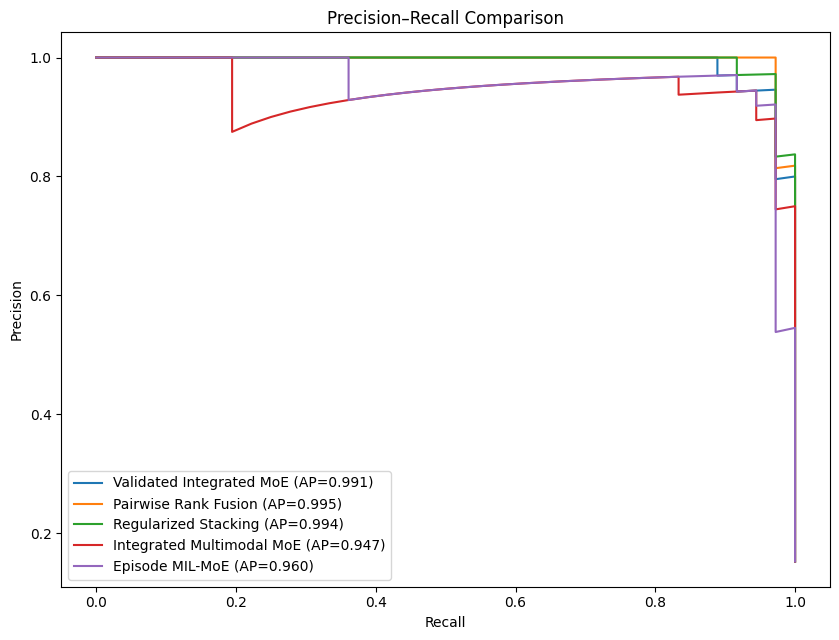

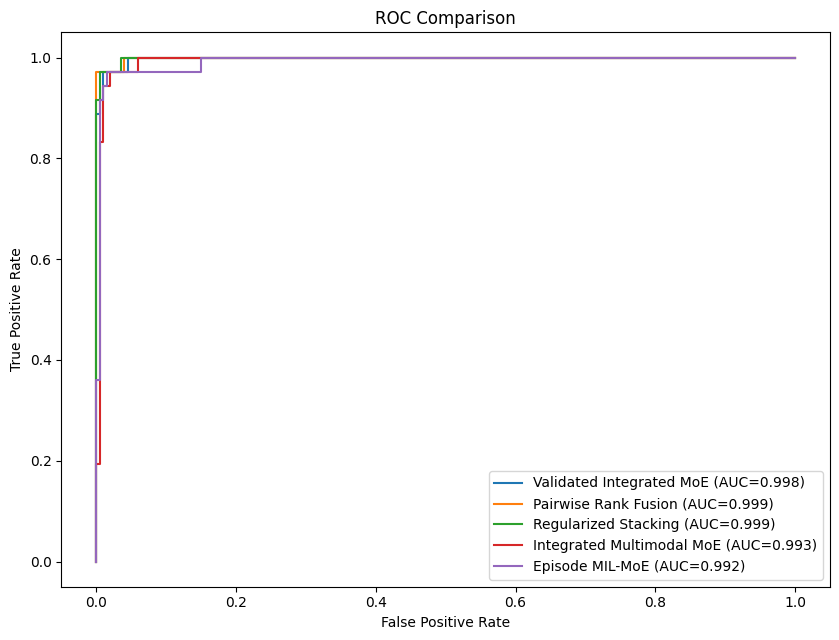

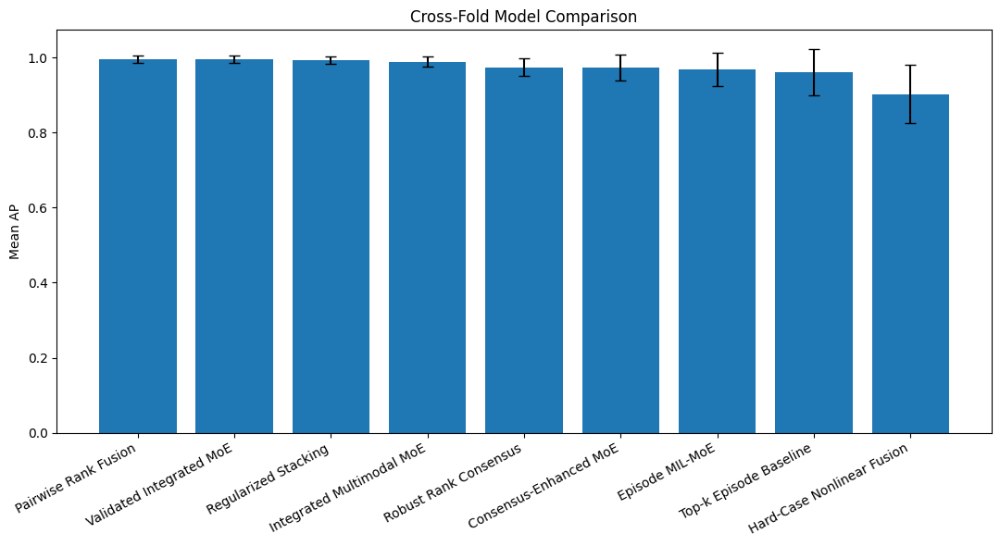

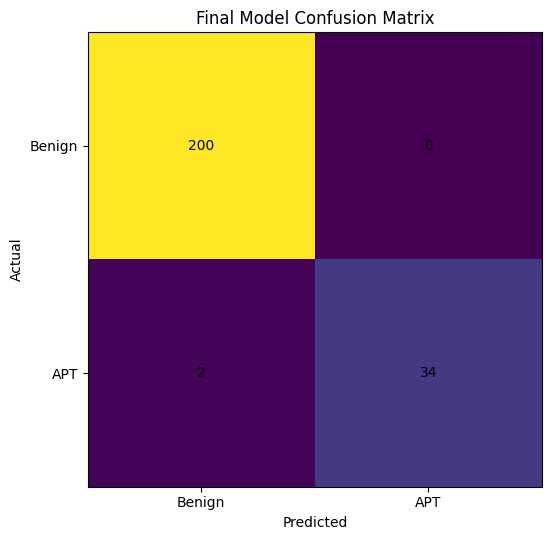

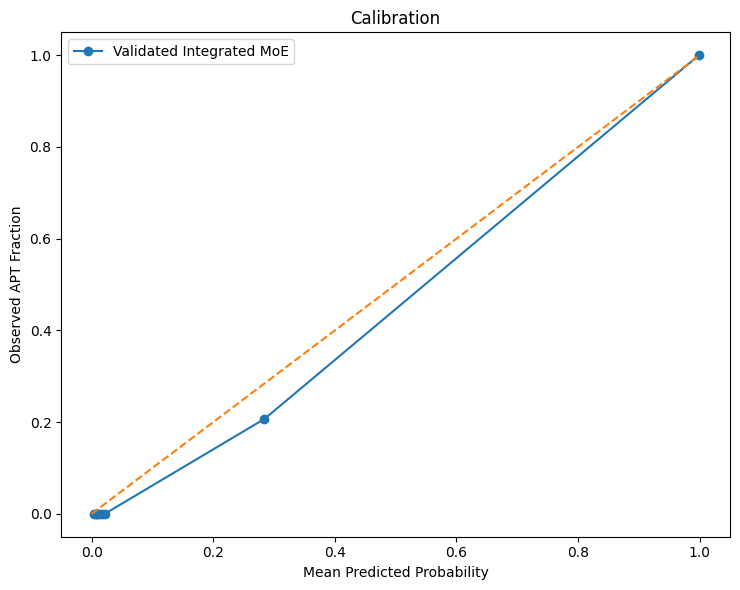

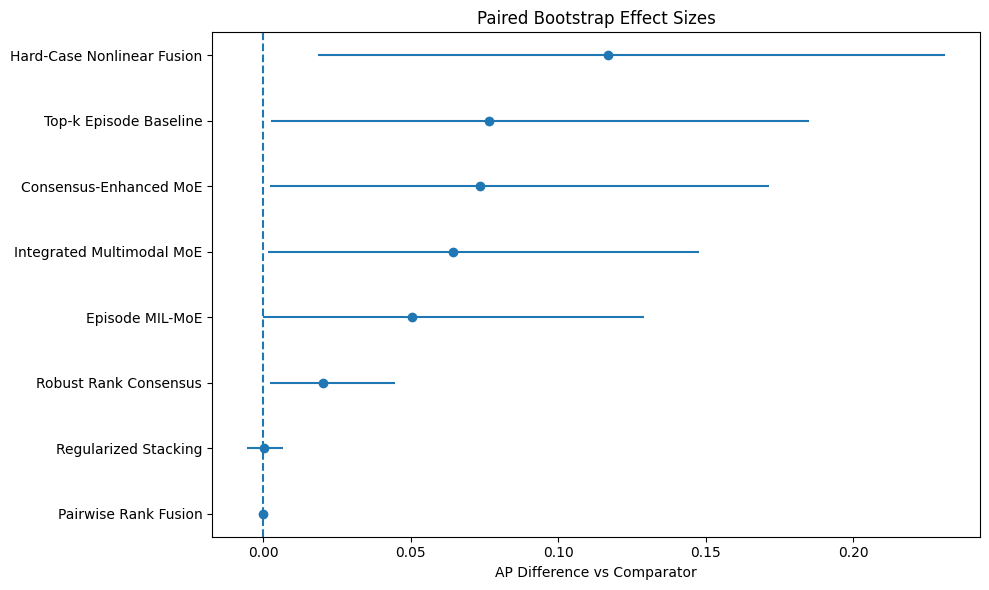

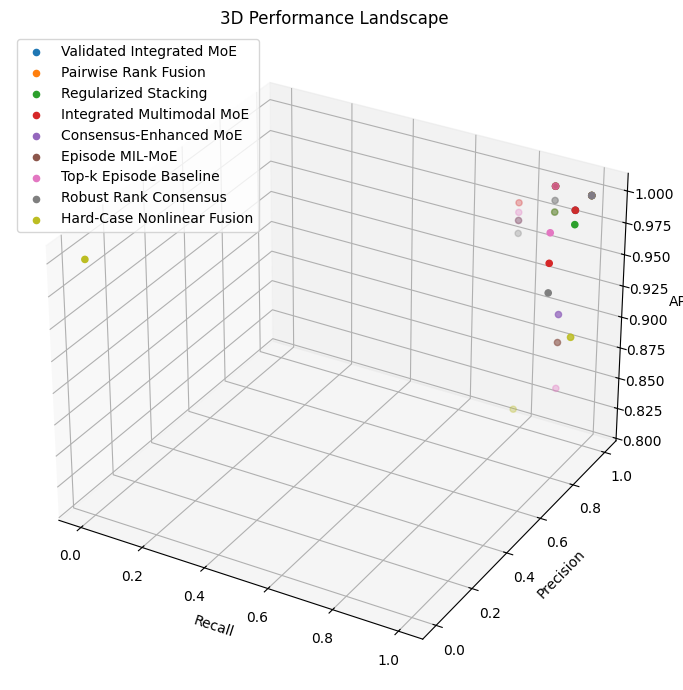

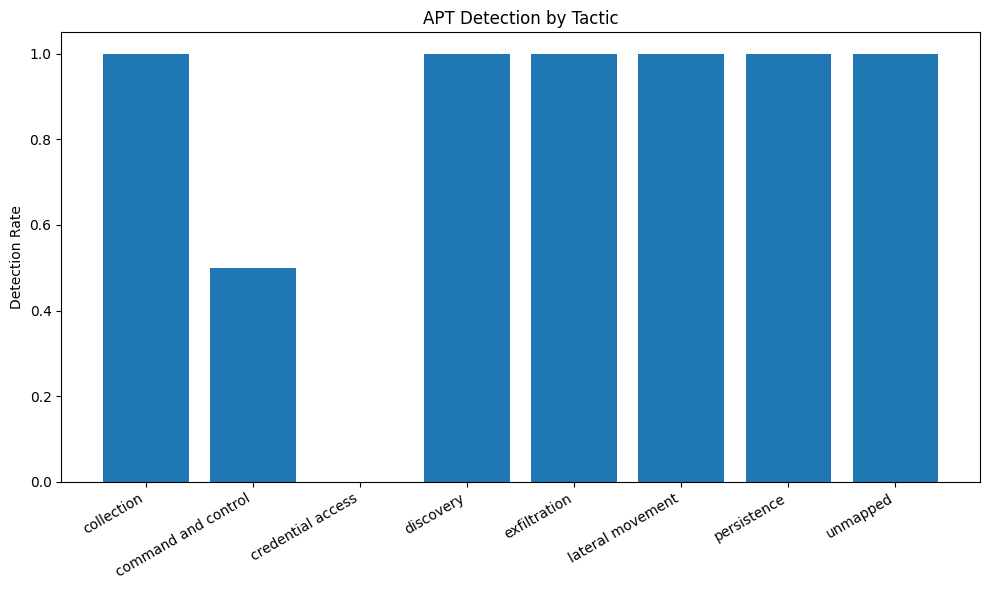

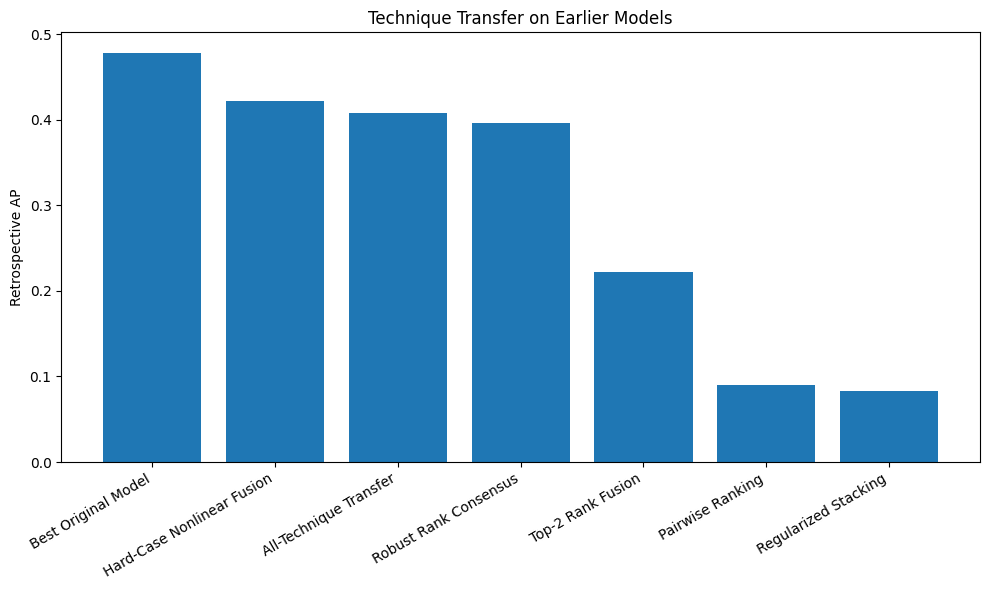

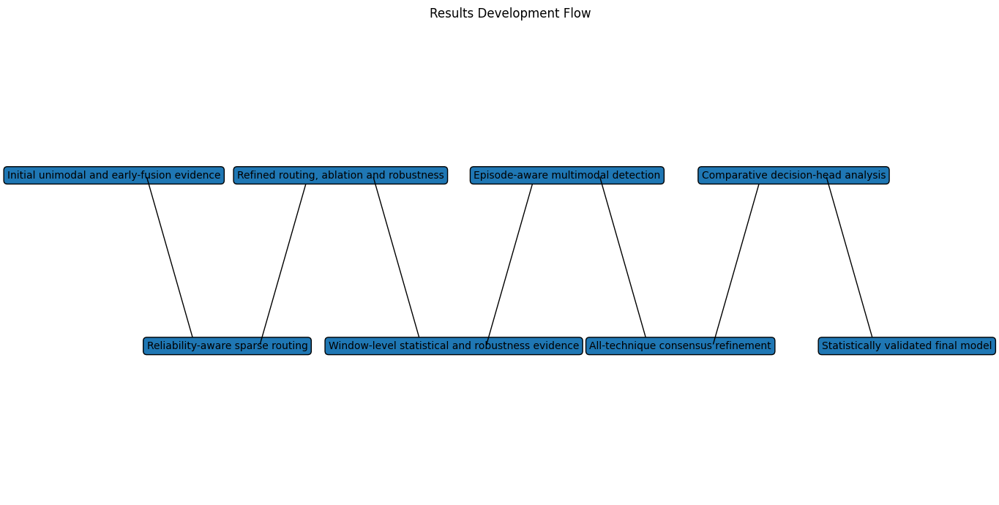

RESULTS DEVELOPMENT FLOW
 order                                  results_section                                                                                                                                                                      finding
     1       Initial unimodal and early-fusion evidence                                                            Best early detector reached AP=0.5153. Network evidence was substantially stronger than provenance-only evidence.
     2                 Reliability-aware sparse routing                                                                                                  Repeated-seed reliability-aware sparse routing produced AP=0.3235 ± 0.0233.
     3         Refined routing, ablation and robustness                                                    The strongest ablation reached AP=0.5280; expert quality and dependence on network evidence remained the main limitation.
     4 Window-level statistical and robustness evidence Win

In [1]:

from pathlib import Path
import hashlib
import json
import math
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.stats import binomtest, rankdata
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, auc, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, fbeta_score, log_loss, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")
OUT = ROOT / "Final_Results_Validation_Refinement"
REP = OUT / "reports"
PRED = OUT / "predictions"
FIG = OUT / "figures"
MODEL = OUT / "models"
SEED = 20260929
INNER_FOLDS = 3
BOOTSTRAP_N = 5000
PERMUTATION_N = 10000
FPR_LIMIT = 0.02
MIN_PRECISION = 0.70

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def read_csv(path):
    try:
        p = Path(path)
        return pd.read_csv(p) if p.exists() else None
    except Exception:
        return None

def read_json(path):
    try:
        p = Path(path)
        return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None
    except Exception:
        return None

def pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))

def choose_threshold(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    order = np.argsort(-p, kind="stable")
    sy = y[order]
    sp = p[order]
    endpoints = np.r_[np.flatnonzero(np.diff(sp) != 0), len(sp) - 1]
    tp = np.cumsum(sy)[endpoints]
    fp = endpoints + 1 - tp
    fn = int(y.sum()) - tp
    tn = int((y == 0).sum()) - fp
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(int(y.sum()), 1)
    fpr = fp / max(int((y == 0).sum()), 1)
    f2 = 5 * tp / np.maximum(5 * tp + 4 * fn + fp, 1)
    denom = np.sqrt(np.maximum((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1))
    mcc = (tp * tn - fp * fn) / denom
    feasible = (fpr <= FPR_LIMIT) & (precision >= MIN_PRECISION)
    tier = "FPR+precision"
    if not feasible.any():
        feasible = fpr <= FPR_LIMIT
        tier = "FPR-only"
    if not feasible.any():
        return {"threshold": float(np.nextafter(p.max(), np.inf)), "tier": "no-positive"}
    objective = 0.50 * f2 + 0.30 * mcc + 0.20 * precision
    k = int(np.argmax(np.where(feasible, objective, -np.inf)))
    return {
        "threshold": float(sp[endpoints[k]]),
        "tier": tier,
        "estimated_FPR": float(fpr[k]),
        "estimated_Precision": float(precision[k]),
        "estimated_Recall": float(recall[k]),
        "estimated_F2": float(f2[k]),
        "estimated_MCC": float(mcc[k]),
    }

def metric_row(y, p, threshold):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "AP": float(average_precision_score(y, p)),
        "PR_AUC": pr_auc(y, p),
        "ROC_AUC": float(roc_auc_score(y, p)),
        "Precision": float(precision_score(y, pred, zero_division=0)),
        "Recall": float(recall_score(y, pred, zero_division=0)),
        "F1": float(f1_score(y, pred, zero_division=0)),
        "F2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0),
        "BalancedAccuracy": float(balanced_accuracy_score(y, pred)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(tn + fp, 1)),
        "Brier": float(brier_score_loss(y, p)),
        "LogLoss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1])),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Threshold": float(threshold),
    }

def ece(y, p, bins=10):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    edges = np.unique(np.quantile(p, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        edges = np.linspace(0, 1, bins + 1)
    value = 0.0
    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            mask = (p >= edges[i]) & (p <= edges[i + 1])
        else:
            mask = (p >= edges[i]) & (p < edges[i + 1])
        if mask.any():
            value += mask.mean() * abs(float(y[mask].mean()) - float(p[mask].mean()))
    return float(value)

def calibration_stats(y, p):
    y = np.asarray(y, dtype=int)
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    z = logit(p).reshape(-1, 1)
    model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000).fit(z, y)
    return {
        "Brier": float(brier_score_loss(y, p)),
        "LogLoss": float(log_loss(y, p, labels=[0, 1])),
        "ECE10": ece(y, p, 10),
        "CalibrationIntercept": float(model.intercept_[0]),
        "CalibrationSlope": float(model.coef_[0, 0]),
    }

def rank_to_train(train, target):
    train = np.asarray(train, dtype=float)
    target = np.asarray(target, dtype=float)
    ref = np.sort(train[np.isfinite(train)])
    if not len(ref):
        return np.full(len(target), 0.5, dtype=float)
    med = float(np.median(ref))
    target = np.where(np.isfinite(target), target, med)
    return np.searchsorted(ref, target, side="right") / (len(ref) + 1)

def direct_score_map(frame):
    mapping = {
        "Integrated Multimodal MoE": "p_IntegratedMultimodalMoE",
        "Consensus-Enhanced MoE": "p_ConsensusEnhancedMoE",
        "Episode MIL-MoE": "p_EpisodeMILMoE",
        "Top-k Episode Baseline": "p_TopK",
        "Regularized Stacking": "p_RidgeStack",
        "Pairwise Rank Fusion": "p_PairwiseRank",
        "Robust Rank Consensus": "p_RobustConsensus",
        "Hard-Case Nonlinear Fusion": "p_HardCaseTree",
    }
    return {name: frame[col].to_numpy(dtype=float) for name, col in mapping.items() if col in frame.columns}

def all_heads(frame, train_frame=None):
    scores = direct_score_map(frame)
    if "Pairwise Rank Fusion" in scores and "Regularized Stacking" in scores:
        a = scores["Pairwise Rank Fusion"]
        b = scores["Regularized Stacking"]
        scores["Pairwise-Stacking 70/30"] = 0.70 * a + 0.30 * b
        scores["Pairwise-Stacking 60/40"] = 0.60 * a + 0.40 * b
        scores["Pairwise-Stacking 50/50"] = 0.50 * a + 0.50 * b
    if "Pairwise Rank Fusion" in scores and "Regularized Stacking" in scores and "Integrated Multimodal MoE" in scores:
        a = scores["Pairwise Rank Fusion"]
        b = scores["Regularized Stacking"]
        c = scores["Integrated Multimodal MoE"]
        scores["Pairwise-Stacking-MoE 60/25/15"] = 0.60 * a + 0.25 * b + 0.15 * c
        scores["Pairwise-Stacking-MoE 70/20/10"] = 0.70 * a + 0.20 * b + 0.10 * c
        scores["Pairwise-Stacking-MoE 50/30/20"] = 0.50 * a + 0.30 * b + 0.20 * c
    if train_frame is not None:
        train_scores = all_heads(train_frame, None)
        for name in list(scores):
            if name in train_scores:
                scores["Rank-Normalized " + name] = rank_to_train(train_scores[name], scores[name])
    return scores

def get_head(frame, name, train_frame=None):
    scores = all_heads(frame, train_frame)
    if name not in scores:
        raise KeyError(name)
    return np.asarray(scores[name], dtype=float)

class Platt:
    def fit(self, p, y):
        p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
        self.model = LogisticRegression(C=1.0, solver="liblinear", max_iter=3000).fit(logit(p).reshape(-1, 1), np.asarray(y, dtype=int))
        return self
    def predict(self, p):
        p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
        return self.model.predict_proba(logit(p).reshape(-1, 1))[:, 1]

def select_head(train):
    y = train["episode_label"].astype(int).to_numpy()
    scores = all_heads(train)
    splits = min(INNER_FOLDS, int(y.sum()), int((y == 0).sum()))
    if splits < 2:
        raise RuntimeError("Insufficient classes for inner validation.")
    cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=SEED)
    rows = []
    for name, p in scores.items():
        aps = [average_precision_score(y[va], p[va]) for _, va in cv.split(np.zeros(len(y)), y)]
        mean_ap = float(np.mean(aps))
        sd_ap = float(np.std(aps, ddof=1) if len(aps) > 1 else 0.0)
        rows.append({"head": name, "AP_mean": mean_ap, "AP_SD": sd_ap, "objective": mean_ap - 0.12 * sd_ap})
    table = pd.DataFrame(rows).sort_values(["objective", "AP_mean", "AP_SD"], ascending=[False, False, True]).reset_index(drop=True)
    return str(table.iloc[0]["head"]), table

def crossfit_head_selection(d):
    folds = sorted(d["fold"].astype(int).unique())
    raw = np.full(len(d), np.nan, dtype=float)
    prob = np.full(len(d), np.nan, dtype=float)
    pred = np.zeros(len(d), dtype=int)
    thresholds = np.full(len(d), np.nan, dtype=float)
    selected = []
    fold_rows = []
    search_rows = []
    for fold in folds:
        tr = np.flatnonzero(d["fold"].astype(int).to_numpy() != fold)
        va = np.flatnonzero(d["fold"].astype(int).to_numpy() == fold)
        train = d.iloc[tr].copy()
        valid = d.iloc[va].copy()
        name, search = select_head(train)
        search["outer_fold"] = int(fold)
        search_rows.append(search)
        tr_raw = get_head(train, name)
        va_raw = get_head(valid, name, train)
        cal = Platt().fit(tr_raw, train["episode_label"].astype(int).to_numpy())
        tr_prob = cal.predict(tr_raw)
        va_prob = cal.predict(va_raw)
        policy = choose_threshold(train["episode_label"].astype(int).to_numpy(), tr_prob)
        raw[va] = va_raw
        prob[va] = va_prob
        thresholds[va] = policy["threshold"]
        pred[va] = (va_prob >= policy["threshold"]).astype(int)
        m = metric_row(valid["episode_label"].astype(int).to_numpy(), va_prob, policy["threshold"])
        fold_rows.append({"fold": int(fold), "model": "Validated Integrated MoE", "selected_head": name, **m})
        selected.append({"fold": int(fold), "selected_head": name, **policy})
    return raw, prob, pred, thresholds, pd.DataFrame(selected), pd.DataFrame(fold_rows), pd.concat(search_rows, ignore_index=True)

def crossfit_comparator(d, name):
    y = d["episode_label"].astype(int).to_numpy()
    folds = sorted(d["fold"].astype(int).unique())
    p = np.full(len(d), np.nan, dtype=float)
    pred = np.zeros(len(d), dtype=int)
    threshold = np.full(len(d), np.nan, dtype=float)
    rows = []
    for fold in folds:
        tr = np.flatnonzero(d["fold"].astype(int).to_numpy() != fold)
        va = np.flatnonzero(d["fold"].astype(int).to_numpy() == fold)
        train = d.iloc[tr]
        valid = d.iloc[va]
        tr_raw = get_head(train, name)
        va_raw = get_head(valid, name, train)
        cal = Platt().fit(tr_raw, y[tr])
        tr_prob = cal.predict(tr_raw)
        va_prob = cal.predict(va_raw)
        policy = choose_threshold(y[tr], tr_prob)
        p[va] = va_prob
        threshold[va] = policy["threshold"]
        pred[va] = (va_prob >= policy["threshold"]).astype(int)
        rows.append({"fold": int(fold), "model": name, **metric_row(y[va], va_prob, policy["threshold"])})
    return p, pred, threshold, pd.DataFrame(rows)

def stratified_bootstrap_index(y, rng):
    a = np.flatnonzero(np.asarray(y) == 0)
    b = np.flatnonzero(np.asarray(y) == 1)
    return np.concatenate([rng.choice(a, len(a), replace=True), rng.choice(b, len(b), replace=True)])

def metric_bootstrap_ci(y, p, pred, n):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = np.asarray(pred, dtype=int)
    rng = np.random.default_rng(SEED + 71)
    store = {k: [] for k in ["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR", "Brier"]}
    for _ in range(n):
        idx = stratified_bootstrap_index(y, rng)
        yy, pp, zz = y[idx], p[idx], pred[idx]
        tn, fp, fn, tp = confusion_matrix(yy, zz, labels=[0, 1]).ravel()
        store["AP"].append(average_precision_score(yy, pp))
        store["PR_AUC"].append(pr_auc(yy, pp))
        store["ROC_AUC"].append(roc_auc_score(yy, pp))
        store["Precision"].append(precision_score(yy, zz, zero_division=0))
        store["Recall"].append(recall_score(yy, zz, zero_division=0))
        store["F1"].append(f1_score(yy, zz, zero_division=0))
        store["F2"].append(fbeta_score(yy, zz, beta=2, zero_division=0))
        store["MCC"].append(matthews_corrcoef(yy, zz) if len(np.unique(zz)) > 1 else 0.0)
        store["BalancedAccuracy"].append(balanced_accuracy_score(yy, zz))
        store["FPR"].append(fp / max(fp + tn, 1))
        store["Brier"].append(brier_score_loss(yy, pp))
    rows = []
    for metric, values in store.items():
        x = np.asarray(values, dtype=float)
        rows.append({"metric": metric, "bootstrap_mean": float(x.mean()), "ci95_low": float(np.quantile(x, 0.025)), "ci95_high": float(np.quantile(x, 0.975))})
    return pd.DataFrame(rows)

def paired_bootstrap(y, a, b, n, seed):
    y = np.asarray(y, dtype=int)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    rng = np.random.default_rng(seed)
    vals = {"AP": [], "ROC_AUC": [], "Brier": []}
    for _ in range(n):
        idx = stratified_bootstrap_index(y, rng)
        yy, aa, bb = y[idx], a[idx], b[idx]
        vals["AP"].append(average_precision_score(yy, aa) - average_precision_score(yy, bb))
        vals["ROC_AUC"].append(roc_auc_score(yy, aa) - roc_auc_score(yy, bb))
        vals["Brier"].append(brier_score_loss(yy, aa) - brier_score_loss(yy, bb))
    result = {}
    for metric, values in vals.items():
        x = np.asarray(values, dtype=float)
        result[metric] = {"mean_delta": float(x.mean()), "ci_low": float(np.quantile(x, 0.025)), "ci_high": float(np.quantile(x, 0.975))}
    return result

def paired_permutation_ap(y, a, b, n, seed):
    y = np.asarray(y, dtype=int)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    observed = float(average_precision_score(y, a) - average_precision_score(y, b))
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n):
        swap = rng.random(len(y)) < 0.5
        aa = np.where(swap, b, a)
        bb = np.where(swap, a, b)
        delta = average_precision_score(y, aa) - average_precision_score(y, bb)
        if abs(delta) >= abs(observed):
            count += 1
    return observed, float((count + 1) / (n + 1))

def mcnemar_exact(y, a, b):
    y = np.asarray(y, dtype=int)
    a = np.asarray(a, dtype=int)
    b = np.asarray(b, dtype=int)
    ca = a == y
    cb = b == y
    x = int(np.sum(ca & ~cb))
    z = int(np.sum(~ca & cb))
    p = 1.0 if x + z == 0 else float(binomtest(min(x, z), n=x + z, p=0.5, alternative="two-sided").pvalue)
    return x, z, p

def holm(pvalues):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        value = min(1.0, (m - rank) * p[idx])
        running = max(running, value)
        adjusted[idx] = running
    return adjusted

def statistical_validation(d, final_prob, final_pred):
    y = d["episode_label"].astype(int).to_numpy()
    names = ["Pairwise Rank Fusion", "Regularized Stacking", "Integrated Multimodal MoE", "Consensus-Enhanced MoE", "Episode MIL-MoE", "Top-k Episode Baseline", "Robust Rank Consensus", "Hard-Case Nonlinear Fusion"]
    rows = []
    cache = {}
    for i, name in enumerate(names):
        try:
            p, pred, _, fold = crossfit_comparator(d, name)
        except Exception:
            continue
        cache[name] = {"probability": p, "prediction": pred, "fold_metrics": fold}
        boot = paired_bootstrap(y, final_prob, p, BOOTSTRAP_N, SEED + 300 + i)
        delta, permutation_p = paired_permutation_ap(y, final_prob, p, PERMUTATION_N, SEED + 600 + i)
        only_final, only_comparator, mc_p = mcnemar_exact(y, final_pred, pred)
        rows.append({
            "comparator": name,
            "final_AP": float(average_precision_score(y, final_prob)),
            "comparator_AP": float(average_precision_score(y, p)),
            "delta_AP": delta,
            "AP_bootstrap_mean_delta": boot["AP"]["mean_delta"],
            "AP_bootstrap_ci_low": boot["AP"]["ci_low"],
            "AP_bootstrap_ci_high": boot["AP"]["ci_high"],
            "ROC_bootstrap_mean_delta": boot["ROC_AUC"]["mean_delta"],
            "ROC_bootstrap_ci_low": boot["ROC_AUC"]["ci_low"],
            "ROC_bootstrap_ci_high": boot["ROC_AUC"]["ci_high"],
            "Brier_bootstrap_mean_delta": boot["Brier"]["mean_delta"],
            "Brier_bootstrap_ci_low": boot["Brier"]["ci_low"],
            "Brier_bootstrap_ci_high": boot["Brier"]["ci_high"],
            "AP_permutation_p": permutation_p,
            "McNemar_p": mc_p,
            "final_correct_only": only_final,
            "comparator_correct_only": only_comparator,
        })
    table = pd.DataFrame(rows)
    if len(table):
        table["AP_permutation_Holm_p"] = holm(table["AP_permutation_p"].to_numpy())
        table["McNemar_Holm_p"] = holm(table["McNemar_p"].to_numpy())
    return table, cache

def fold_stability(fold_metrics):
    x = fold_metrics["AP"].to_numpy(dtype=float)
    return {
        "AP_mean": float(x.mean()),
        "AP_SD": float(x.std(ddof=1) if len(x) > 1 else 0.0),
        "AP_median": float(np.median(x)),
        "AP_min": float(x.min()),
        "AP_max": float(x.max()),
        "AP_CV": float(x.std(ddof=1) / x.mean() if len(x) > 1 and x.mean() else 0.0),
    }

def subgroup_analysis(d, p, pred):
    rows = []
    y = d["episode_label"].astype(int).to_numpy()
    if "tactic" in d.columns:
        pos = d.loc[d["episode_label"].eq(1)]
        for name, g in pos.groupby("tactic", dropna=False):
            idx = g.index.to_numpy()
            rows.append({"analysis": "attack_tactic", "subgroup": str(name), "episodes": int(len(idx)), "mean_probability": float(np.mean(p[idx])), "median_probability": float(np.median(p[idx])), "detection_rate": float(np.mean(pred[idx] == 1)), "min_probability": float(np.min(p[idx])), "max_probability": float(np.max(p[idx]))})
    if "attackinfo_aligned" in d.columns:
        for aligned in [True, False]:
            pos = d.index[d["episode_label"].eq(1) & d["attackinfo_aligned"].astype(bool).eq(aligned)].to_numpy()
            neg = d.index[d["episode_label"].eq(0)].to_numpy()
            if len(pos):
                idx = np.concatenate([neg, pos])
                rows.append({"analysis": "attackinfo_alignment", "subgroup": "aligned" if aligned else "proxy_or_unaligned", "episodes": int(len(idx)), "positive_episodes": int(len(pos)), "AP": float(average_precision_score(y[idx], p[idx])), "ROC_AUC": float(roc_auc_score(y[idx], p[idx])), "positive_detection_rate": float(np.mean(pred[pos] == 1))})
    if "positive_windows" in d.columns:
        pos = d.index[d["episode_label"].eq(1)].to_numpy()
        if len(pos) >= 4:
            values = d.loc[pos, "positive_windows"].to_numpy(dtype=float)
            edges = np.unique(np.quantile(values, [0, 0.33, 0.67, 1]))
            for i in range(max(0, len(edges) - 1)):
                mask = (values >= edges[i]) & (values <= edges[i + 1]) if i == len(edges) - 2 else (values >= edges[i]) & (values < edges[i + 1])
                idx = pos[mask]
                if len(idx):
                    rows.append({"analysis": "episode_attack_density", "subgroup": f"{edges[i]:.0f}-{edges[i+1]:.0f}_positive_windows", "episodes": int(len(idx)), "mean_probability": float(np.mean(p[idx])), "detection_rate": float(np.mean(pred[idx] == 1))})
    return pd.DataFrame(rows)

def threshold_sensitivity(y, p, threshold_per_row):
    rows = []
    for factor in [0.80, 0.90, 1.00, 1.10, 1.20]:
        t = np.clip(np.asarray(threshold_per_row) * factor, 0, 1)
        z = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, z, labels=[0, 1]).ravel()
        rows.append({"threshold_factor": factor, "Precision": float(precision_score(y, z, zero_division=0)), "Recall": float(recall_score(y, z, zero_division=0)), "F1": float(f1_score(y, z, zero_division=0)), "F2": float(fbeta_score(y, z, beta=2, zero_division=0)), "MCC": float(matthews_corrcoef(y, z) if len(np.unique(z)) > 1 else 0.0), "BalancedAccuracy": float(balanced_accuracy_score(y, z)), "FPR": float(fp / max(fp + tn, 1)), "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)})
    return pd.DataFrame(rows)

def prediction_files_before_temporal_model():
    folders = [
        ROOT / "Step5_Baselines" / "predictions",
        ROOT / "Step6_Reliability_Aware_MoE" / "predictions",
        ROOT / "Step7_Refined_RMoE" / "predictions",
        ROOT / "Step8_Tactic_Statistical_Validation" / "predictions",
        ROOT / "Step9_Final_Evidence" / "predictions",
    ]
    paths = []
    for folder in folders:
        if folder.exists():
            paths.extend(sorted(folder.glob("*.parquet")))
            paths.extend(sorted(folder.glob("*.csv")))
    return paths

def historical_prediction_bank():
    base_path = ROOT / "Step5_Baselines" / "features" / "baseline_dataset.parquet"
    audit = {"scope": "retrospective_transfer_only", "old_fixed_test_previously_observed": True, "primary_final_model_selection_uses_this_analysis": False, "available": False}
    if not base_path.exists():
        audit["reason"] = "baseline dataset unavailable"
        return None, [], audit
    base = pd.read_parquet(base_path).reset_index(drop=True)
    needed = ["binary_label", "split", "_phase", "_window_start"]
    if any(c not in base.columns for c in needed):
        audit["reason"] = "baseline metadata incomplete"
        return None, [], audit
    if "_window_id" not in base.columns:
        base["_window_id"] = base["_phase"].astype(str) + ":" + pd.to_numeric(base["_window_start"], errors="raise").astype(np.int64).astype(str)
    dev = base.loc[base["split"].astype(str).str.lower().eq("test"), ["_window_id", "binary_label", "_phase", "_window_start"]].copy()
    dev["_window_id"] = dev["_window_id"].astype(str)
    used = []
    score_cols = []
    for path in prediction_files_before_temporal_model():
        try:
            f = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
        except Exception:
            continue
        if "_window_id" not in f.columns:
            if "_phase" in f.columns and "_window_start" in f.columns:
                f = f.copy()
                f["_window_id"] = f["_phase"].astype(str) + ":" + pd.to_numeric(f["_window_start"], errors="coerce").fillna(-1).astype(np.int64).astype(str)
            else:
                continue
        f["_window_id"] = f["_window_id"].astype(str)
        candidates = [c for c in f.columns if (str(c).startswith("p_") or str(c).lower() in ["probability", "prob", "score"]) and pd.api.types.is_numeric_dtype(f[c])]
        local_used = False
        for c in candidates:
            col = re.sub(r"[^A-Za-z0-9_]+", "_", f"{path.parent.parent.name}_{path.stem}_{c}")
            s = f[["_window_id", c]].drop_duplicates("_window_id").rename(columns={c: col})
            dev = dev.merge(s, on="_window_id", how="left", validate="one_to_one")
            finite = pd.to_numeric(dev[col], errors="coerce")
            if finite.notna().mean() >= 0.95 and finite.std() > 1e-12:
                score_cols.append(col)
                local_used = True
        if local_used:
            used.append(str(path))
    unique = []
    signatures = []
    for c in score_cols:
        x = pd.to_numeric(dev[c], errors="coerce").fillna(pd.to_numeric(dev[c], errors="coerce").median()).to_numpy(dtype=float)
        if not any(np.allclose(x, prior, atol=1e-12, rtol=0) for prior in signatures):
            unique.append(c)
            signatures.append(x)
    dev["group"] = dev["_phase"].astype(str) + ":" + (pd.to_numeric(dev["_window_start"], errors="raise").astype(np.int64) // 3600).astype(str)
    audit.update({"available": bool(unique), "model_scores_found": len(unique), "prediction_files_used": used, "score_columns": unique})
    return dev, unique, audit

class EmpiricalRank:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.refs = []
        for j in range(X.shape[1]):
            x = X[:, j]
            x = x[np.isfinite(x)]
            self.refs.append(np.sort(x if len(x) else np.array([0.0])))
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        R = np.zeros_like(X, dtype=float)
        for j, ref in enumerate(self.refs):
            med = float(np.median(ref))
            x = np.where(np.isfinite(X[:, j]), X[:, j], med)
            R[:, j] = np.searchsorted(ref, x, side="right") / (len(ref) + 1)
        return R

def diversity_weights(R, y):
    prevalence = max(float(np.mean(y)), 1e-7)
    aps = np.array([average_precision_score(y, R[:, j]) for j in range(R.shape[1])], dtype=float)
    competence = np.clip((aps - prevalence) / max(1 - prevalence, 1e-7), 0, 1)
    if R.shape[1] == 1:
        redundancy = np.zeros(1)
    else:
        ranks = rankdata(R, axis=0, method="average")
        corr = np.abs(np.nan_to_num(np.corrcoef(ranks, rowvar=False), nan=0.0))
        redundancy = (corr.sum(axis=1) - 1) / (R.shape[1] - 1)
    raw = (competence + 1e-4) ** 2 * np.clip(1 - 0.5 * redundancy, 0.1, 1.0) + 0.002
    return raw / raw.sum()

def pairwise_model(X, y, anchor):
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)
    if not len(pos) or not len(neg):
        raise RuntimeError("Pairwise model requires both classes.")
    rng = np.random.default_rng(SEED + 911)
    cut = np.quantile(anchor[neg], 0.80)
    hard = neg[anchor[neg] >= cut]
    if not len(hard):
        hard = neg
    rows, labels = [], []
    per_pos = min(40, max(12, 8000 // max(len(pos), 1)))
    for p in pos:
        nh = int(round(per_pos * 0.75))
        selected = np.concatenate([rng.choice(hard, nh, replace=True), rng.choice(neg, per_pos - nh, replace=True)])
        for n in selected:
            rows.append(X[p] - X[n])
            labels.append(1)
            rows.append(X[n] - X[p])
            labels.append(0)
    XX = np.asarray(rows, dtype=float)
    yy = np.asarray(labels, dtype=int)
    if len(yy) > 16000:
        pick = rng.choice(len(yy), 16000, replace=False)
        XX, yy = XX[pick], yy[pick]
    return LogisticRegression(C=0.10, solver="liblinear", fit_intercept=False, max_iter=3000).fit(XX, yy)

def historical_transfer():
    bank, cols, audit = historical_prediction_bank()
    save_json(REP / "historical_transfer_scope.json", audit)
    if bank is None or not cols:
        return pd.DataFrame(), pd.DataFrame()
    y = bank["binary_label"].astype(int).to_numpy()
    groups = bank["group"].astype(str).to_numpy()
    positive_groups = len(np.unique(groups[y == 1]))
    negative_groups = len(np.unique(groups[y == 0]))
    n_splits = min(3, positive_groups, negative_groups)
    if n_splits < 2:
        audit["available"] = False
        audit["reason"] = "insufficient independent time blocks"
        save_json(REP / "historical_transfer_scope.json", audit)
        return pd.DataFrame(), pd.DataFrame()
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    methods = ["Best Original Model", "Robust Rank Consensus", "Regularized Stacking", "Pairwise Ranking", "Hard-Case Nonlinear Fusion", "Top-2 Rank Fusion", "All-Technique Transfer"]
    probabilities = {m: np.full(len(bank), np.nan, dtype=float) for m in methods}
    predictions = {m: np.zeros(len(bank), dtype=int) for m in methods}
    fold_rows = []
    for fold, (tr, va) in enumerate(cv.split(np.zeros(len(y)), y, groups)):
        raw_tr = bank.iloc[tr][cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        raw_va = bank.iloc[va][cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        mapper = EmpiricalRank().fit(raw_tr)
        Rtr, Rva = mapper.transform(raw_tr), mapper.transform(raw_va)
        w = diversity_weights(Rtr, y[tr])
        train_ap = np.array([average_precision_score(y[tr], Rtr[:, j]) for j in range(Rtr.shape[1])])
        best_j = int(np.argmax(train_ap))
        best_tr, best_va = Rtr[:, best_j], Rva[:, best_j]
        q = max(1, int(math.ceil(0.25 * Rtr.shape[1])))
        consensus_tr = 0.70 * (Rtr @ w) + 0.15 * np.median(Rtr, axis=1) + 0.15 * np.mean(np.sort(Rtr, axis=1)[:, -q:], axis=1)
        consensus_va = 0.70 * (Rva @ w) + 0.15 * np.median(Rva, axis=1) + 0.15 * np.mean(np.sort(Rva, axis=1)[:, -q:], axis=1)
        scaler = StandardScaler().fit(Rtr)
        Ztr, Zva = scaler.transform(Rtr), scaler.transform(Rva)
        ridge = LogisticRegression(C=0.10, class_weight="balanced", solver="liblinear", max_iter=3000).fit(Ztr, y[tr])
        ridge_tr, ridge_va = ridge.predict_proba(Ztr)[:, 1], ridge.predict_proba(Zva)[:, 1]
        pair = pairwise_model(Ztr, y[tr], best_tr)
        pair_tr, pair_va = expit(Ztr @ pair.coef_[0]), expit(Zva @ pair.coef_[0])
        tree = HistGradientBoostingClassifier(learning_rate=0.04, max_iter=120, max_leaf_nodes=7, max_depth=3, min_samples_leaf=12, l2_regularization=4.0, random_state=SEED).fit(Ztr, y[tr], sample_weight=np.where(y[tr] == 1, 4.0, 1.0))
        tree_tr, tree_va = tree.predict_proba(Ztr)[:, 1], tree.predict_proba(Zva)[:, 1]
        top2_tr = np.mean(np.sort(Rtr, axis=1)[:, -min(2, Rtr.shape[1]):], axis=1)
        top2_va = np.mean(np.sort(Rva, axis=1)[:, -min(2, Rva.shape[1]):], axis=1)
        def uncertainty(anchor, R):
            a = np.clip(anchor, 1e-6, 1 - 1e-6)
            e = -(a * np.log(a) + (1 - a) * np.log(1 - a)) / math.log(2)
            return np.clip(0.5 * e + 0.5 * np.clip(np.std(R, axis=1) / 0.25, 0, 1), 0, 1)
        utr, uva = uncertainty(best_tr, Rtr), uncertainty(best_va, Rva)
        ref_tr = 0.40 * pair_tr + 0.30 * ridge_tr + 0.15 * consensus_tr + 0.10 * top2_tr + 0.05 * tree_tr
        ref_va = 0.40 * pair_va + 0.30 * ridge_va + 0.15 * consensus_va + 0.10 * top2_va + 0.05 * tree_va
        all_tr = np.clip(0.55 * best_tr + 0.45 * ref_tr + 0.08 * utr * np.maximum(np.maximum.reduce([pair_tr, ridge_tr, consensus_tr, tree_tr]) - best_tr, 0), 0, 1)
        all_va = np.clip(0.55 * best_va + 0.45 * ref_va + 0.08 * uva * np.maximum(np.maximum.reduce([pair_va, ridge_va, consensus_va, tree_va]) - best_va, 0), 0, 1)
        current = {
            "Best Original Model": (best_tr, best_va),
            "Robust Rank Consensus": (consensus_tr, consensus_va),
            "Regularized Stacking": (ridge_tr, ridge_va),
            "Pairwise Ranking": (pair_tr, pair_va),
            "Hard-Case Nonlinear Fusion": (tree_tr, tree_va),
            "Top-2 Rank Fusion": (top2_tr, top2_va),
            "All-Technique Transfer": (all_tr, all_va),
        }
        for method, (ptr, pva) in current.items():
            cal = Platt().fit(ptr, y[tr])
            ptr, pva = cal.predict(ptr), cal.predict(pva)
            policy = choose_threshold(y[tr], ptr)
            probabilities[method][va] = pva
            predictions[method][va] = (pva >= policy["threshold"]).astype(int)
            fold_rows.append({"fold": int(fold), "method": method, **metric_row(y[va], pva, policy["threshold"])})
    summary = []
    for method in methods:
        p, z = probabilities[method], predictions[method]
        if not np.isfinite(p).all():
            continue
        tn, fp, fn, tp = confusion_matrix(y, z, labels=[0, 1]).ravel()
        summary.append({"method": method, "AP": float(average_precision_score(y, p)), "ROC_AUC": float(roc_auc_score(y, p)), "Precision": float(precision_score(y, z, zero_division=0)), "Recall": float(recall_score(y, z, zero_division=0)), "F1": float(f1_score(y, z, zero_division=0)), "MCC": float(matthews_corrcoef(y, z) if len(np.unique(z)) > 1 else 0.0), "FPR": float(fp / max(fp + tn, 1)), "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn), "scope": "retrospective_transfer_only"})
    pred_table = bank[["_window_id", "binary_label", "_phase", "_window_start", "group"]].copy()
    for method in methods:
        pred_table["p_" + re.sub(r"[^A-Za-z0-9]+", "_", method)] = probabilities[method]
    pred_table.to_parquet(PRED / "historical_transfer_predictions.parquet", index=False)
    return pd.DataFrame(summary).sort_values("AP", ascending=False), pd.DataFrame(fold_rows)

def first_matching_csv(folder, patterns):
    folder = Path(folder)
    for pattern in patterns:
        matches = list(folder.rglob(pattern)) if folder.exists() else []
        if matches:
            x = read_csv(matches[0])
            if x is not None and len(x):
                return x
    return None

def results_flow(current_comparison, final_stability):
    rows = []
    b = read_csv(ROOT / "Step5_Baselines" / "reports" / "baseline_summary.csv")
    if b is not None and len(b) and "pr_auc" in b.columns:
        best = b.sort_values("pr_auc", ascending=False).iloc[0]
        rows.append({"order": 1, "results_section": "Initial unimodal and early-fusion evidence", "what_was_tried": "Network-only, provenance-only and early multimodal fusion classifiers.", "finding": f"Best early detector reached AP={float(best['pr_auc']):.4f}. Network evidence was substantially stronger than provenance-only evidence.", "why_next": "The weak provenance-only branch indicated that modalities should not be fused with equal influence."})
    s6 = read_csv(ROOT / "Step6_Reliability_Aware_MoE" / "reports" / "moe_mean_std_ci.csv")
    if s6 is not None and len(s6):
        r = s6.loc[s6["metric"].astype(str).str.lower().isin(["pr_auc", "ap"])]
        finding = f"Repeated-seed reliability-aware sparse routing produced AP={float(r.iloc[0]['mean']):.4f} ± {float(r.iloc[0]['std']):.4f}." if len(r) else "Reliability-aware sparse routing was evaluated across repeated seeds."
        rows.append({"order": 2, "results_section": "Reliability-aware sparse routing", "what_was_tried": "Reliability-conditioned sparse expert routing with repeated-seed evaluation.", "finding": finding, "why_next": "Routing alone could not compensate for weak experts, motivating stronger expert construction and ablation."})
    s7 = read_csv(ROOT / "Step7_Refined_RMoE" / "reports" / "ablation_results.csv")
    if s7 is not None and len(s7) and "pr_auc" in s7.columns:
        best = s7.sort_values("pr_auc", ascending=False).iloc[0]
        rows.append({"order": 3, "results_section": "Refined routing, ablation and robustness", "what_was_tried": "Sparse/dense routing, reliability ablation, fixed averaging, modality-specific experts and robustness perturbations.", "finding": f"The strongest ablation reached AP={float(best['pr_auc']):.4f}; expert quality and dependence on network evidence remained the main limitation.", "why_next": "The next analysis strengthened statistical validation and investigated robustness rather than increasing router complexity alone."})
    s8 = read_csv(ROOT / "Step8_Tactic_Statistical_Validation" / "reports" / "binary_significance_tests.csv")
    if s8 is not None and len(s8):
        rows.append({"order": 4, "results_section": "Window-level statistical and robustness evidence", "what_was_tried": "Paired bootstrap, McNemar-style comparisons, tactic analysis, missing/noisy modality tests and efficiency profiling.", "finding": "Window-level testing did not establish a clear advantage over the strongest network/fusion comparator, although it established a strong gain over provenance-only detection.", "why_next": "The persistent attack process was then evaluated at episode level instead of treating every 5-second window as an independent event."})
    episode = read_json(ROOT / "Step11X_Final_Episode_MIL_MoE" / "reports" / "final_evidence.json")
    if episode:
        rows.append({"order": 5, "results_section": "Episode-aware multimodal detection", "what_was_tried": "Sparse expert routing with MIL temporal attention, top-k suspicious-window pooling and bounded rescue.", "finding": f"Episode-level mean AP reached {float(episode.get('EpisodeMILSparseMoE_mean_AP', np.nan)):.4f} ± {float(episode.get('EpisodeMILSparseMoE_AP_SD', np.nan)):.4f}.", "why_next": "Episode aggregation stabilized attack evidence and enabled a broader all-technique consensus."})
    consensus = read_json(ROOT / "Step12X_AllTechniques_Consensus" / "reports" / "final_evidence.json")
    if consensus:
        rows.append({"order": 6, "results_section": "All-technique consensus refinement", "what_was_tried": "Rank normalization, competence/diversity weighting, robust consensus, uncertainty-conditioned blending and specialist rescue.", "finding": f"Mean AP reached {float(consensus.get('Step12X_mean_AP', np.nan)):.4f} ± {float(consensus.get('Step12X_AP_SD', np.nan)):.4f}.", "why_next": "The remaining question was which decision head best exploited the integrated evidence."})
    if current_comparison is not None and len(current_comparison):
        best = current_comparison.sort_values("AP_mean", ascending=False).iloc[0]
        integrated = current_comparison.loc[current_comparison["model"].astype(str).eq("Integrated Multimodal MoE")]
        finding = f"{best['model']} produced the highest comparative mean AP, {float(best['AP_mean']):.4f} ± {float(best['AP_SD']):.4f}."
        if len(integrated):
            finding += f" The full integrated MoE achieved {float(integrated.iloc[0]['AP_mean']):.4f} ± {float(integrated.iloc[0]['AP_SD']):.4f}."
        rows.append({"order": 7, "results_section": "Comparative decision-head analysis", "what_was_tried": "Pairwise ranking, regularized stacking, robust rank consensus, nonlinear hard-case fusion and integrated multimodal fusion.", "finding": finding, "why_next": "A nested train-only head-selection procedure was therefore used to choose the final decision rule without selecting it from outer-fold results."})
    s = final_stability.iloc[0]
    rows.append({"order": 8, "results_section": "Statistically validated final model", "what_was_tried": "Nested decision-head selection, train-only calibration and thresholding, bootstrap confidence intervals, paired permutation testing, exact McNemar testing, Holm correction, calibration diagnostics, subgroup analysis and threshold sensitivity.", "finding": f"Validated mean AP={float(s['AP_mean']):.4f} ± {float(s['AP_SD']):.4f}, with fold range {float(s['AP_min']):.4f}–{float(s['AP_max']):.4f}.", "why_next": "This is the primary quantitative model result; literature comparison should use the same episode-level evaluation unit and metric definitions."})
    return pd.DataFrame(rows).sort_values("order")

def final_model_bundle(d, final_prob, selected):
    head, search = select_head(d)
    raw = get_head(d, head)
    y = d["episode_label"].astype(int).to_numpy()
    cal = Platt().fit(raw, y)
    policy = choose_threshold(y, cal.predict(raw))
    artifact = MODEL / "validated_integrated_multimodal_moe.joblib"
    joblib.dump({"model_name": "Validated Integrated MoE", "selected_decision_head": head, "calibrator": cal, "threshold_policy": policy, "candidate_search": search, "outer_selected_heads": selected, "evaluation_unit": "episode/group", "primary_predictions_cross_fitted": True, "previously_inspected_fixed_test_used_for_primary_result": False}, artifact)
    save_json(REP / "final_model_manifest.json", {"artifact": str(artifact), "sha256": hashlib.sha256(artifact.read_bytes()).hexdigest(), "selected_decision_head": head, "threshold_policy": policy})
    search.to_csv(REP / "full_development_head_search.csv", index=False)
    return artifact, head, policy

def write_results_flow(flow, overview, stats, calibration, subgroup, legacy):
    lines = ["# Results Section Flow", ""]
    for _, r in flow.iterrows():
        lines += [f"## {int(r['order'])}. {r['results_section']}", "", f"**What was evaluated:** {r['what_was_tried']}", "", f"**Finding:** {r['finding']}", "", f"**Transition:** {r['why_next']}", ""]
    lines += ["## Final model complete results", "", overview.to_markdown(index=False), "", "## Statistical validation", "", stats.to_markdown(index=False) if len(stats) else "No comparator statistics were available.", "", "## Calibration", "", pd.DataFrame([calibration]).to_markdown(index=False), "", "## Subgroup analysis", "", subgroup.to_markdown(index=False) if len(subgroup) else "No subgroup fields were available.", "", "## Historical technique-transfer analysis", "", legacy.to_markdown(index=False) if len(legacy) else "Historical prediction files were not sufficiently available for transfer analysis.", ""]
    (REP / "paper_results_flow.md").write_text("\n".join(lines), encoding="utf-8")

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", dpi=600, bbox_inches="tight")

def make_figures(d, final_prob, final_pred, combined_fold, stats, subgroup, legacy, flow):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    y = d["episode_label"].astype(int).to_numpy()
    curves = {"Validated Integrated MoE": final_prob}
    for name, col in [("Pairwise Rank Fusion", "p_PairwiseRank"), ("Regularized Stacking", "p_RidgeStack"), ("Integrated Multimodal MoE", "p_IntegratedMultimodalMoE"), ("Episode MIL-MoE", "p_EpisodeMILMoE")]:
        if col in d:
            curves[name] = d[col].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, p in curves.items():
        precision, recall, _ = precision_recall_curve(y, p)
        ax.plot(recall, precision, label=f"{name} (AP={average_precision_score(y,p):.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall Comparison")
    ax.legend()
    save_figure(fig, "01_precision_recall")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, p in curves.items():
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y,p):.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Comparison")
    ax.legend()
    save_figure(fig, "02_roc")
    plt.show()
    plt.close(fig)
    summary = combined_fold.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std")).reset_index().sort_values("AP_mean", ascending=False)
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(summary))
    ax.bar(x, summary["AP_mean"], yerr=summary["AP_SD"].fillna(0), capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["model"], rotation=28, ha="right")
    ax.set_ylabel("Mean AP")
    ax.set_title("Cross-Fold Model Comparison")
    save_figure(fig, "03_mean_ap_sd")
    plt.show()
    plt.close(fig)
    cm = confusion_matrix(y, final_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "APT"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Benign", "APT"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Final Model Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    save_figure(fig, "04_confusion_matrix")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    frac, meanp = calibration_curve(y, final_prob, n_bins=8, strategy="quantile")
    ax.plot(meanp, frac, marker="o", label="Validated Integrated MoE")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed APT Fraction")
    ax.set_title("Calibration")
    ax.legend()
    save_figure(fig, "05_calibration")
    plt.show()
    plt.close(fig)
    if len(stats):
        fig, ax = plt.subplots(figsize=(10, 6))
        s = stats.sort_values("delta_AP")
        yloc = np.arange(len(s))
        lower = s["delta_AP"] - s["AP_bootstrap_ci_low"]
        upper = s["AP_bootstrap_ci_high"] - s["delta_AP"]
        ax.errorbar(s["delta_AP"], yloc, xerr=np.vstack([lower, upper]), fmt="o")
        ax.axvline(0, linestyle="--")
        ax.set_yticks(yloc)
        ax.set_yticklabels(s["comparator"])
        ax.set_xlabel("AP Difference vs Comparator")
        ax.set_title("Paired Bootstrap Effect Sizes")
        save_figure(fig, "06_statistical_forest")
        plt.show()
        plt.close(fig)
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for name in combined_fold["model"].unique():
        z = combined_fold.loc[combined_fold["model"].eq(name)]
        ax.scatter(z["Recall"], z["Precision"], z["AP"], label=name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("AP")
    ax.set_title("3D Performance Landscape")
    ax.legend()
    save_figure(fig, "07_3d_performance")
    plt.show()
    plt.close(fig)
    if len(subgroup) and "detection_rate" in subgroup.columns:
        s = subgroup.loc[subgroup["analysis"].eq("attack_tactic")]
        if len(s):
            fig, ax = plt.subplots(figsize=(10, 6))
            x = np.arange(len(s))
            ax.bar(x, s["detection_rate"])
            ax.set_xticks(x)
            ax.set_xticklabels(s["subgroup"], rotation=30, ha="right")
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("Detection Rate")
            ax.set_title("APT Detection by Tactic")
            save_figure(fig, "08_tactic_detection")
            plt.show()
            plt.close(fig)
    if len(legacy):
        q = legacy.sort_values("AP", ascending=False)
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(q))
        ax.bar(x, q["AP"])
        ax.set_xticks(x)
        ax.set_xticklabels(q["method"], rotation=30, ha="right")
        ax.set_ylabel("Retrospective AP")
        ax.set_title("Technique Transfer on Earlier Models")
        save_figure(fig, "09_historical_transfer")
        plt.show()
        plt.close(fig)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.axis("off")
    n = min(len(flow), 8)
    xs = np.linspace(0.07, 0.93, n)
    for i, (_, r) in enumerate(flow.head(n).iterrows()):
        yv = 0.68 if i % 2 == 0 else 0.32
        ax.text(xs[i], yv, r["results_section"], ha="center", va="center", wrap=True, bbox=dict(boxstyle="round,pad=0.35"))
        if i < n - 1:
            ny = 0.68 if (i + 1) % 2 == 0 else 0.32
            ax.annotate("", xy=(xs[i + 1] - 0.035, ny), xytext=(xs[i] + 0.035, yv), arrowprops=dict(arrowstyle="->"))
    ax.set_title("Results Development Flow")
    save_figure(fig, "10_results_flow")
    plt.show()
    plt.close(fig)

def main():
    if not ROOT.exists() and str(ROOT).startswith("/content/"):
        from google.colab import drive
        drive.mount("/content/drive")
    for p in [OUT, REP, PRED, FIG, MODEL]:
        p.mkdir(parents=True, exist_ok=True)
    current = ROOT / "Final_Integrated_Multimodal_MoE" / "predictions" / "episode_comparative_predictions.parquet"
    current_comparison = read_csv(ROOT / "Final_Integrated_Multimodal_MoE" / "reports" / "comparative_analysis.csv")
    if not current.exists():
        raise FileNotFoundError(current)
    d = pd.read_parquet(current).reset_index(drop=True)
    if "episode_label" not in d.columns or "fold" not in d.columns:
        raise ValueError("Episode prediction file lacks episode_label or fold.")
    raw, final_prob, final_pred, row_threshold, selected, final_fold, search = crossfit_head_selection(d)
    selected.to_csv(REP / "selected_decision_head_by_fold.csv", index=False)
    final_fold.to_csv(REP / "validated_final_fold_metrics.csv", index=False)
    search.to_csv(REP / "nested_decision_head_search.csv", index=False)
    fold_tables = [final_fold]
    for name in ["Pairwise Rank Fusion", "Regularized Stacking", "Integrated Multimodal MoE", "Consensus-Enhanced MoE", "Episode MIL-MoE", "Top-k Episode Baseline", "Robust Rank Consensus", "Hard-Case Nonlinear Fusion"]:
        try:
            _, _, _, table = crossfit_comparator(d, name)
            fold_tables.append(table)
        except Exception:
            pass
    combined_fold = pd.concat(fold_tables, ignore_index=True)
    combined_fold.to_csv(REP / "all_model_fold_metrics.csv", index=False)
    stability = pd.DataFrame([{"model": "Validated Integrated MoE", **fold_stability(final_fold)}])
    stability.to_csv(REP / "final_fold_stability.csv", index=False)
    y = d["episode_label"].astype(int).to_numpy()
    ci = metric_bootstrap_ci(y, final_prob, final_pred, BOOTSTRAP_N)
    ci.to_csv(REP / "final_metric_bootstrap_ci.csv", index=False)
    calibration = calibration_stats(y, final_prob)
    save_json(REP / "final_calibration.json", calibration)
    stats, comparator_cache = statistical_validation(d, final_prob, final_pred)
    stats.to_csv(REP / "statistical_validation.csv", index=False)
    subgroup = subgroup_analysis(d, final_prob, final_pred)
    subgroup.to_csv(REP / "subgroup_analysis.csv", index=False)
    sensitivity = threshold_sensitivity(y, final_prob, row_threshold)
    sensitivity.to_csv(REP / "threshold_sensitivity.csv", index=False)
    legacy, legacy_fold = historical_transfer()
    legacy.to_csv(REP / "historical_technique_transfer.csv", index=False)
    legacy_fold.to_csv(REP / "historical_technique_transfer_folds.csv", index=False)
    flow = results_flow(current_comparison, stability)
    flow.to_csv(REP / "results_section_flow.csv", index=False)
    tn, fp, fn, tp = confusion_matrix(y, final_pred, labels=[0, 1]).ravel()
    overview = pd.DataFrame([{
        "Model": "Validated Integrated MoE",
        "AP_mean": float(stability.iloc[0]["AP_mean"]),
        "AP_SD": float(stability.iloc[0]["AP_SD"]),
        "AP_min_fold": float(stability.iloc[0]["AP_min"]),
        "AP_max_fold": float(stability.iloc[0]["AP_max"]),
        "Pooled_AP": float(average_precision_score(y, final_prob)),
        "PR_AUC": float(pr_auc(y, final_prob)),
        "ROC_AUC": float(roc_auc_score(y, final_prob)),
        "Precision": float(precision_score(y, final_pred, zero_division=0)),
        "Recall": float(recall_score(y, final_pred, zero_division=0)),
        "F1": float(f1_score(y, final_pred, zero_division=0)),
        "F2": float(fbeta_score(y, final_pred, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, final_pred)),
        "BalancedAccuracy": float(balanced_accuracy_score(y, final_pred)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(fp + tn, 1)),
        "Brier": calibration["Brier"],
        "LogLoss": calibration["LogLoss"],
        "ECE10": calibration["ECE10"],
        "CalibrationSlope": calibration["CalibrationSlope"],
        "CalibrationIntercept": calibration["CalibrationIntercept"],
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }])
    overview.to_csv(REP / "final_model_complete_results.csv", index=False)
    pred_out = d[[c for c in ["group", "episode_label", "fold", "windows", "positive_windows", "tactic", "attackinfo_aligned"] if c in d.columns]].copy()
    pred_out["p_ValidatedIntegratedMoE"] = final_prob
    pred_out["raw_ValidatedIntegratedMoE"] = raw
    pred_out["pred_ValidatedIntegratedMoE"] = final_pred
    pred_out["fold_threshold"] = row_threshold
    pred_out.to_parquet(PRED / "final_validated_predictions.parquet", index=False)
    artifact, full_head, full_threshold = final_model_bundle(d, final_prob, selected)
    write_results_flow(flow, overview, stats, calibration, subgroup, legacy)
    make_figures(d, final_prob, final_pred, combined_fold, stats, subgroup, legacy, flow)
    evidence = {
        "primary_model": "Validated Integrated MoE",
        "full_development_selected_decision_head": full_head,
        "evaluation_unit": "episode/group",
        "fold_stability": stability.iloc[0].to_dict(),
        "complete_results": overview.iloc[0].to_dict(),
        "metric_bootstrap_95CI": ci.to_dict("records"),
        "calibration": calibration,
        "statistical_validation": stats.to_dict("records"),
        "threshold_sensitivity": sensitivity.to_dict("records"),
        "historical_transfer_scope": "retrospective_transfer_only",
        "historical_transfer": legacy.to_dict("records"),
        "previously_inspected_fixed_test_used_for_primary_result": False,
        "target_episode_AP": 0.98,
        "target_met": bool(float(stability.iloc[0]["AP_mean"]) >= 0.98),
        "final_artifact": str(artifact),
    }
    save_json(REP / "final_results_evidence.json", evidence)
    comparison = combined_fold.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std"), Precision_mean=("Precision", "mean"), Recall_mean=("Recall", "mean"), F1_mean=("F1", "mean"), F2_mean=("F2", "mean"), MCC_mean=("MCC", "mean"), FPR_mean=("FPR", "mean")).reset_index().sort_values("AP_mean", ascending=False)
    comparison.to_csv(REP / "paper_comparative_analysis.csv", index=False)
    print("=" * 108)
    print("RESULTS DEVELOPMENT FLOW")
    print("=" * 108)
    print(flow[["order", "results_section", "finding"]].to_string(index=False))
    print()
    print("=" * 108)
    print("FINAL MODEL COMPLETE RESULTS")
    print("=" * 108)
    print(overview.round(6).to_string(index=False))
    print()
    print("=" * 108)
    print("CROSS-FOLD COMPARATIVE ANALYSIS")
    print("=" * 108)
    print(comparison.round(6).to_string(index=False))
    print()
    print("=" * 108)
    print("STATISTICAL VALIDATION")
    print("=" * 108)
    print(stats.round(6).to_string(index=False) if len(stats) else "No comparator statistics available.")
    print()
    print("=" * 108)
    print("HISTORICAL TECHNIQUE TRANSFER")
    print("=" * 108)
    print(legacy.round(6).to_string(index=False) if len(legacy) else "Historical transfer could not be run from available prediction files.")
    print()
    print("Selected deployment decision head:", full_head)
    print("Target episode AP >= 0.98:", bool(float(stability.iloc[0]["AP_mean"]) >= 0.98))
    print("Previously inspected fixed test used for primary result:", False)
    print("Historical fixed-test transfer scope:", "retrospective_transfer_only")
    print("Saved:", OUT)
    return evidence

if __name__ == "__main__":
    main()


FULL-DATA FINAL MODEL VALIDATION
Windows: 119,896
Positive windows: 229
Episodes: 2,070
Positive episodes: 52
Network features: 20
Provenance features: 8
Temporal features: 280

FULL-DATA OUTER FOLD 1/4
  base inner 1/2 complete
  base inner 2/2 complete
                     model  AP_mean   AP_SD
      Regularized Stacking  0.98592 0.01982
Hard-Case Nonlinear Fusion  0.95777 0.04511
 Integrated Multimodal MoE  0.95636 0.07089
      Pairwise Rank Fusion  0.95096 0.04348
     Robust Rank Consensus  0.73281 0.07901
        Sparse Utility MoE  0.72310 0.17675
    Top-k Episode Baseline  0.66560 0.19091
Selected: Regularized Stacking
FULL-DATA OUTER FOLD 2/4
  base inner 1/2 complete
  base inner 2/2 complete
                     model  AP_mean   AP_SD
Hard-Case Nonlinear Fusion  0.93200 0.05224
 Integrated Multimodal MoE  0.88512 0.10200
      Pairwise Rank Fusion  0.85865 0.11558
      Regularized Stacking  0.85436 0.14723
        Sparse Utility MoE  0.62726 0.17850
     Robust Rank Cons

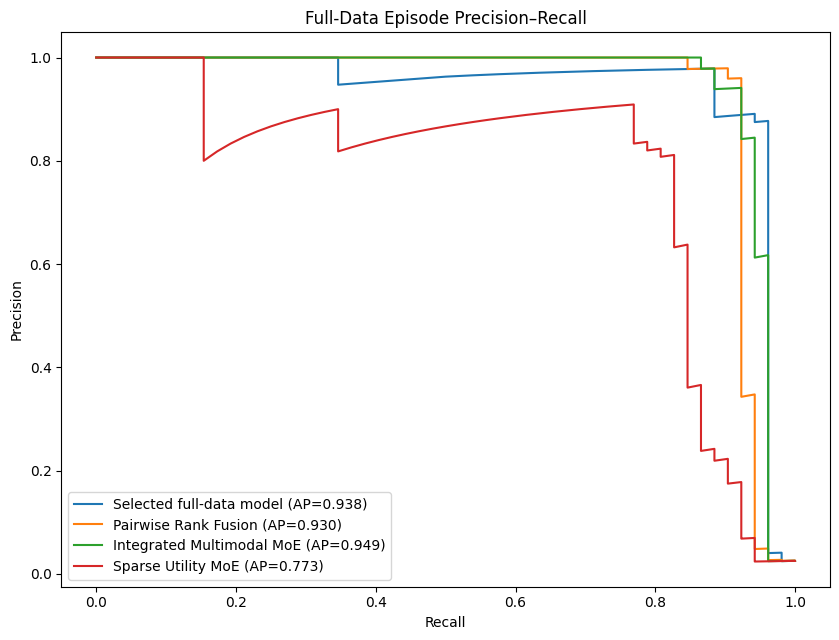

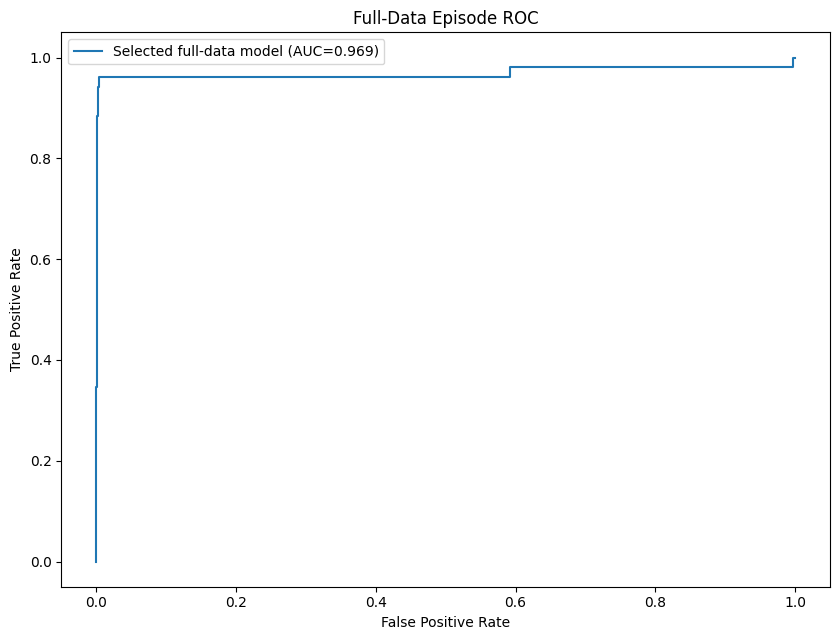

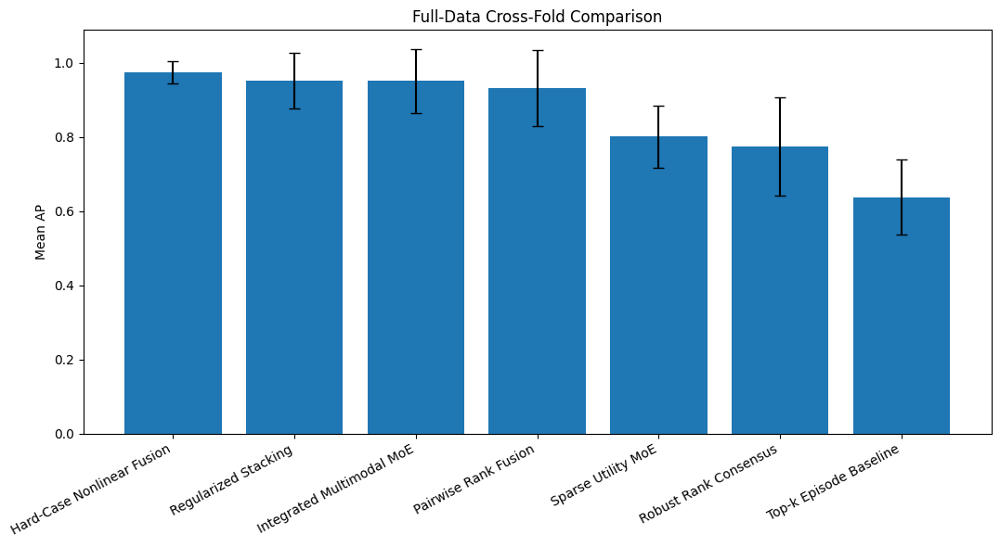

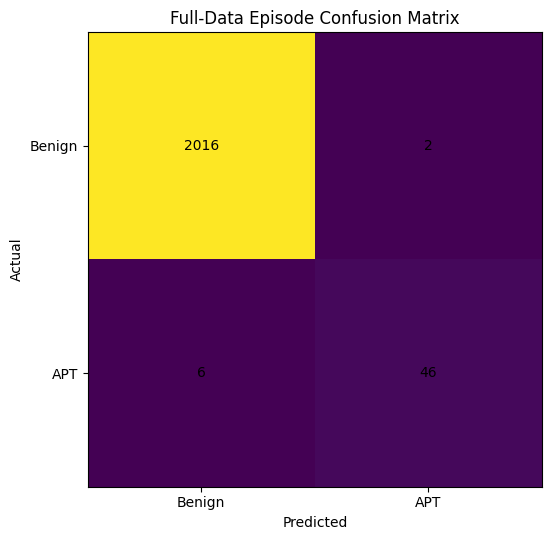

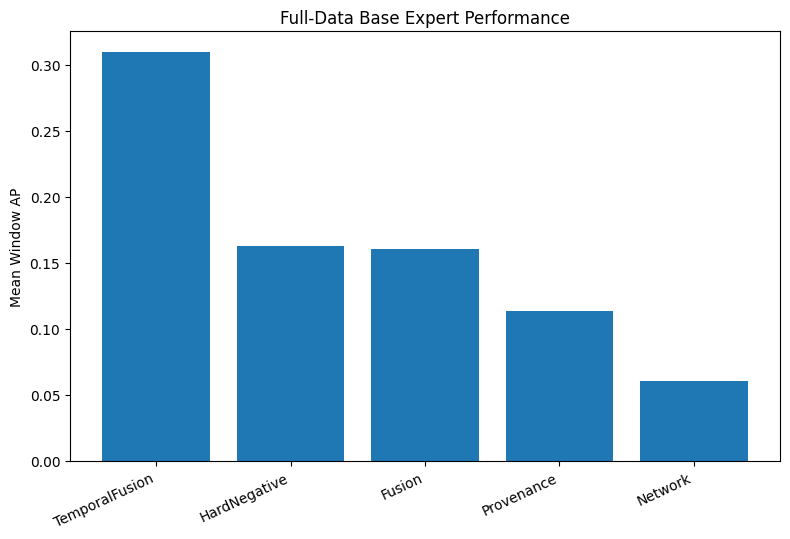

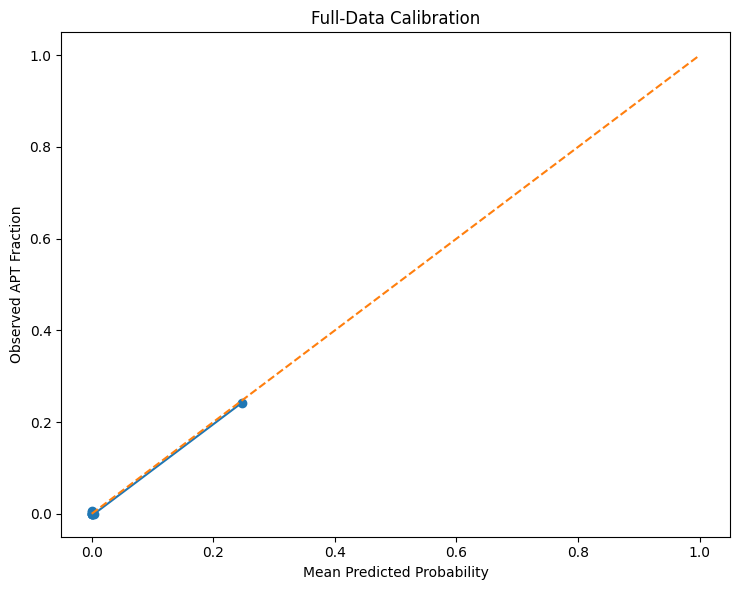

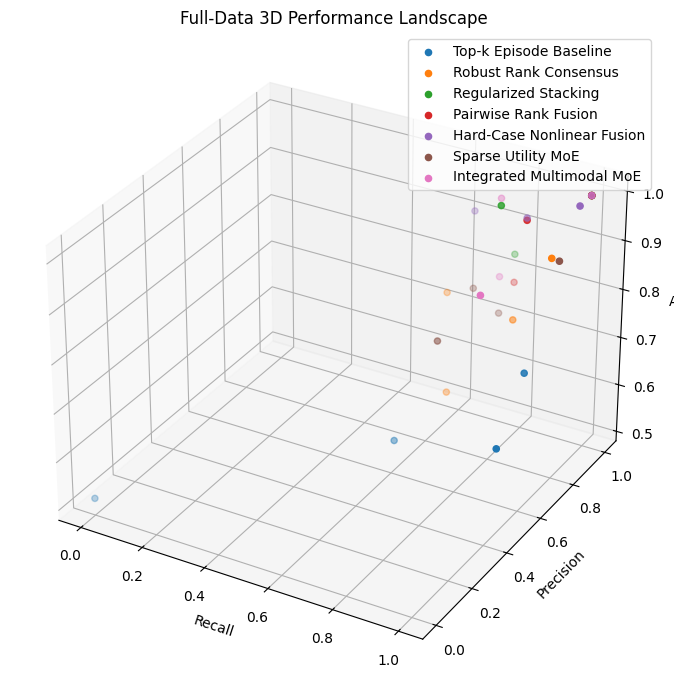

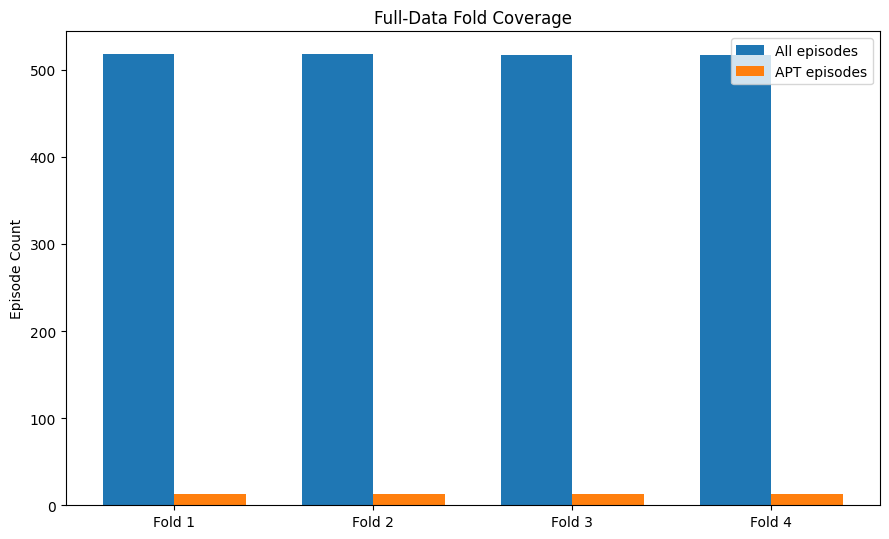


FULL-DATA MODEL COMPARISON
                     model  AP_mean    AP_SD  Precision_mean  Recall_mean  F1_mean  F2_mean  MCC_mean  BalancedAccuracy_mean  FPR_mean
Hard-Case Nonlinear Fusion 0.974900 0.029123        0.936310     0.884615 0.906393 0.892507  0.906300               0.941564  0.001487
      Regularized Stacking 0.952161 0.075576        0.977273     0.884615 0.925725 0.900026  0.926725               0.942060  0.000495
 Integrated Multimodal MoE 0.951233 0.086065        0.792383     0.884615 0.796667 0.829410  0.810842               0.935872  0.012872
      Pairwise Rank Fusion 0.932912 0.102857        0.979167     0.903846 0.937391 0.916457  0.938059               0.951676  0.000495
        Sparse Utility MoE 0.801055 0.084801        0.828475     0.788462 0.801200 0.791912  0.800070               0.892001  0.004460
     Robust Rank Consensus 0.774907 0.133419        0.812437     0.788462 0.790023 0.786761  0.790295               0.891753  0.004955
    Top-k Episode Baseline 

In [2]:

from pathlib import Path
import hashlib
import json
import math
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.stats import binomtest, rankdata
from sklearn.calibration import calibration_curve
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, auc, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, fbeta_score, log_loss, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")
DATA_FILE = ROOT / "Step5_Baselines" / "features" / "baseline_dataset.parquet"
TEMPORAL_FILE = ROOT / "Step10_EC_MT_RMoE" / "features" / "multiscale_temporal_features.parquet"
SELECTED_FILE = ROOT / "Step10_EC_MT_RMoE" / "reports" / "selected_base_features.json"
TACTIC_FILE = ROOT / "Step8_Tactic_Statistical_Validation" / "features" / "window_tactic_targets.parquet"
OUT = ROOT / "Full_Data_Final_Model_Validation"
CACHE = OUT / "cache"
REP = OUT / "reports"
PRED = OUT / "predictions"
FIG = OUT / "figures"
MODEL = OUT / "models"
for p in [OUT, CACHE, REP, PRED, FIG, MODEL]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 20260929
OUTER_FOLDS = 4
INNER_BASE_FOLDS = 2
INNER_META_FOLDS = 3
BOOTSTRAP_N = 5000
PERMUTATION_N = 10000
FPR_LIMIT = 0.02
MIN_PRECISION = 0.70
EXPERTS = ["Network", "Provenance", "Fusion", "TemporalFusion", "HardNegative"]

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))

def choose_threshold(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    order = np.argsort(-p, kind="stable")
    sy = y[order]
    sp = p[order]
    endpoints = np.r_[np.flatnonzero(np.diff(sp) != 0), len(sp) - 1]
    tp = np.cumsum(sy)[endpoints]
    fp = endpoints + 1 - tp
    fn = int(y.sum()) - tp
    tn = int((y == 0).sum()) - fp
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(int(y.sum()), 1)
    fpr = fp / max(int((y == 0).sum()), 1)
    f2 = 5 * tp / np.maximum(5 * tp + 4 * fn + fp, 1)
    denom = np.sqrt(np.maximum((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1))
    mcc = (tp * tn - fp * fn) / denom
    feasible = (fpr <= FPR_LIMIT) & (precision >= MIN_PRECISION)
    tier = "FPR+precision"
    if not feasible.any():
        feasible = fpr <= FPR_LIMIT
        tier = "FPR-only"
    if not feasible.any():
        return {"threshold": float(np.nextafter(p.max(), np.inf)), "tier": "no-positive"}
    objective = 0.50 * f2 + 0.30 * mcc + 0.20 * precision
    k = int(np.argmax(np.where(feasible, objective, -np.inf)))
    return {
        "threshold": float(sp[endpoints[k]]),
        "tier": tier,
        "estimated_FPR": float(fpr[k]),
        "estimated_Precision": float(precision[k]),
        "estimated_Recall": float(recall[k]),
        "estimated_F2": float(f2[k]),
        "estimated_MCC": float(mcc[k]),
    }

def metric_row(y, p, threshold):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "AP": float(average_precision_score(y, p)),
        "PR_AUC": pr_auc(y, p),
        "ROC_AUC": float(roc_auc_score(y, p)),
        "Precision": float(precision_score(y, pred, zero_division=0)),
        "Recall": float(recall_score(y, pred, zero_division=0)),
        "F1": float(f1_score(y, pred, zero_division=0)),
        "F2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0),
        "BalancedAccuracy": float(balanced_accuracy_score(y, pred)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(tn + fp, 1)),
        "Brier": float(brier_score_loss(y, p)),
        "LogLoss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1])),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Threshold": float(threshold),
    }

def build_episodes(data):
    d = data.copy()
    d["_phase"] = d["_phase"].astype(str)
    d["_window_start"] = pd.to_numeric(d["_window_start"], errors="raise").astype(np.int64)
    d["binary_label"] = d["binary_label"].astype(int)
    d["_episode_id"] = ""
    for phase, idx in d.groupby("_phase", sort=False).groups.items():
        ii = np.asarray(list(idx), dtype=int)
        ii = ii[np.argsort(d.loc[ii, "_window_start"].to_numpy())]
        last_positive_time = None
        attack_counter = 0
        for row in ii:
            t = int(d.at[row, "_window_start"])
            y = int(d.at[row, "binary_label"])
            if y == 1:
                if last_positive_time is None or t - last_positive_time > 60:
                    attack_counter += 1
                d.at[row, "_episode_id"] = f"{phase}:attack:{attack_counter}"
                last_positive_time = t
            else:
                d.at[row, "_episode_id"] = f"{phase}:benign:{t // 300}"
    episode = d.groupby("_episode_id", sort=False).agg(
        episode_label=("binary_label", "max"),
        windows=("binary_label", "size"),
        positive_windows=("binary_label", "sum"),
        phase=("_phase", "first"),
        start=("_window_start", "min"),
        end=("_window_start", "max"),
    ).reset_index()
    return d, episode

def assign_outer_folds(episode):
    episode = episode.copy()
    y = episode["episode_label"].astype(int).to_numpy()
    if int(y.sum()) < OUTER_FOLDS:
        raise RuntimeError("Too few positive episodes for four folds.")
    cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
    episode["fold"] = -1
    for fold, (_, va) in enumerate(cv.split(np.zeros(len(y)), y)):
        episode.loc[va, "fold"] = fold
    if (episode["fold"] < 0).any():
        raise RuntimeError("Episode fold assignment incomplete.")
    return episode

def load_inputs():
    if not DATA_FILE.exists():
        raise FileNotFoundError(DATA_FILE)
    if not TEMPORAL_FILE.exists():
        raise FileNotFoundError(TEMPORAL_FILE)
    data = pd.read_parquet(DATA_FILE).reset_index(drop=True)
    temporal = pd.read_parquet(TEMPORAL_FILE).reset_index(drop=True)
    if len(data) != len(temporal):
        raise RuntimeError("Full baseline and temporal feature rows do not match.")
    selected = {"network": [], "provenance": []}
    if SELECTED_FILE.exists():
        selected = json.loads(SELECTED_FILE.read_text())
    network_all = [c for c in data.columns if c.startswith("N_")]
    provenance_all = [c for c in data.columns if c.startswith("P_")]
    network = [c for c in selected.get("network", []) if c in data.columns]
    provenance = [c for c in selected.get("provenance", []) if c in data.columns]
    if not network:
        network = network_all[:min(20, len(network_all))]
    if not provenance:
        provenance = provenance_all[:min(8, len(provenance_all))]
    temporal_cols = [c for c in temporal.columns if c.startswith("TN_") or c.startswith("TP_")]
    if not temporal_cols:
        raise RuntimeError("No temporal features found.")
    for c in network + provenance:
        data[c] = pd.to_numeric(data[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    for c in temporal_cols:
        temporal[c] = pd.to_numeric(temporal[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    data, episode = build_episodes(data)
    episode = assign_outer_folds(episode)
    fold_map = dict(zip(episode["_episode_id"].astype(str), episode["fold"].astype(int)))
    data["_outer_fold"] = data["_episode_id"].astype(str).map(fold_map).astype(int)
    if TACTIC_FILE.exists():
        try:
            tactic = pd.read_parquet(TACTIC_FILE)
            keys = [c for c in ["_phase", "_window_start"] if c in tactic.columns and c in data.columns]
            target_col = "target" if "target" in tactic.columns else None
            if len(keys) == 2 and target_col is not None:
                t = tactic[keys + [target_col]].drop_duplicates(keys).rename(columns={target_col: "_tactic"})
                data = data.merge(t, on=keys, how="left", validate="one_to_one")
                attack_tactic = data.loc[data["binary_label"].eq(1)].groupby("_episode_id")["_tactic"].agg(lambda x: x.dropna().astype(str).mode().iloc[0] if len(x.dropna()) else "unmapped")
                episode["tactic"] = episode["_episode_id"].map(attack_tactic).fillna("benign")
        except Exception:
            pass
    X = {
        "Network": data[network].to_numpy(dtype=np.float32),
        "Provenance": data[provenance].to_numpy(dtype=np.float32),
        "Fusion": data[network + provenance].to_numpy(dtype=np.float32),
        "TemporalFusion": np.concatenate([
            data[network + provenance].to_numpy(dtype=np.float32),
            temporal[temporal_cols].to_numpy(dtype=np.float32),
        ], axis=1),
    }
    audit = {
        "windows": int(len(data)),
        "positive_windows": int(data["binary_label"].sum()),
        "episodes": int(len(episode)),
        "positive_episodes": int(episode["episode_label"].sum()),
        "network_features": len(network),
        "provenance_features": len(provenance),
        "temporal_features": len(temporal_cols),
        "all_original_splits_included": sorted(data["split"].astype(str).unique().tolist()) if "split" in data.columns else [],
        "evaluation": "dataset-wide episode-grouped cross-validation",
        "independent_never_seen_test_claim": False,
    }
    save_json(REP / "full_data_audit.json", audit)
    return data, episode, X, audit

def make_tree(seed, min_leaf=1):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=160,
            max_features="sqrt",
            min_samples_leaf=min_leaf,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=seed,
        )),
    ])

def fit_expert_bank(X, y, train_idx, valid_idx, seed):
    output_train = {}
    output_valid = {}
    models = {}
    for j, name in enumerate(["Network", "Provenance", "Fusion", "TemporalFusion"]):
        model = make_tree(seed + 17 * j, 1 if name != "Provenance" else 2)
        model.fit(X[name][train_idx], y[train_idx])
        output_train[name] = model.predict_proba(X[name][train_idx])[:, 1]
        output_valid[name] = model.predict_proba(X[name][valid_idx])[:, 1]
        models[name] = model
    negative = y[train_idx] == 0
    fusion_train = output_train["Fusion"]
    cutoff = np.quantile(fusion_train[negative], 0.90) if negative.any() else 1.0
    weights = np.ones(len(train_idx), dtype=float)
    weights[y[train_idx] == 1] = 2.0
    weights[(y[train_idx] == 0) & (fusion_train >= cutoff)] = 3.0
    hard = make_tree(seed + 101, 1)
    hard.fit(X["Fusion"][train_idx], y[train_idx], model__sample_weight=weights)
    output_train["HardNegative"] = hard.predict_proba(X["Fusion"][train_idx])[:, 1]
    output_valid["HardNegative"] = hard.predict_proba(X["Fusion"][valid_idx])[:, 1]
    models["HardNegative"] = hard
    return output_train, output_valid, models

def inner_episode_splits(episode_ids, labels, n_splits, seed):
    ep = pd.DataFrame({"episode": episode_ids, "label": labels}).drop_duplicates("episode")
    if ep.groupby("episode")["label"].nunique().max() != 1:
        raise RuntimeError("Episode labels are inconsistent.")
    y = ep["label"].astype(int).to_numpy()
    k = min(n_splits, int(y.sum()), int((y == 0).sum()))
    if k < 2:
        raise RuntimeError("Insufficient episode classes for inner cross-validation.")
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    splits = []
    for _, va in cv.split(np.zeros(len(ep)), y):
        valid_eps = set(ep.iloc[va]["episode"].astype(str))
        valid_mask = np.array([str(g) in valid_eps for g in episode_ids], dtype=bool)
        train_mask = ~valid_mask
        splits.append((np.flatnonzero(train_mask), np.flatnonzero(valid_mask)))
    return splits

def base_scores_for_outer(data, X, outer_fold):
    y = data["binary_label"].astype(int).to_numpy()
    fold = data["_outer_fold"].astype(int).to_numpy()
    outer_train = np.flatnonzero(fold != outer_fold)
    outer_valid = np.flatnonzero(fold == outer_fold)
    feature_signature = hashlib.sha256(("|".join([str(X[k].shape) for k in sorted(X)]) + f"|{len(data)}|{outer_fold}").encode()).hexdigest()
    cache_file = CACHE / f"base_scores_outer_{outer_fold}.npz"
    if cache_file.exists():
        z = np.load(cache_file, allow_pickle=True)
        if str(z["signature"].item()) == feature_signature:
            return outer_train, outer_valid, z["train_scores"], z["valid_scores"]
    train_scores = np.full((len(outer_train), len(EXPERTS)), np.nan, dtype=np.float32)
    local_episode = data.loc[outer_train, "_episode_id"].astype(str).to_numpy()
    local_y = y[outer_train]
    inner = inner_episode_splits(local_episode, local_y, INNER_BASE_FOLDS, SEED + 1000 * outer_fold)
    for inner_fold, (tr_local, va_local) in enumerate(inner):
        tr_global = outer_train[tr_local]
        va_global = outer_train[va_local]
        _, pva, _ = fit_expert_bank(X, y, tr_global, va_global, SEED + 10000 * outer_fold + 500 * inner_fold)
        for j, name in enumerate(EXPERTS):
            train_scores[va_local, j] = pva[name]
        print(f"  base inner {inner_fold+1}/{len(inner)} complete", flush=True)
    if not np.isfinite(train_scores).all():
        raise RuntimeError("Inner base OOF scores incomplete.")
    _, pvalid, _ = fit_expert_bank(X, y, outer_train, outer_valid, SEED + 50000 + 1000 * outer_fold)
    valid_scores = np.column_stack([pvalid[name] for name in EXPERTS]).astype(np.float32)
    np.savez_compressed(cache_file, signature=feature_signature, train_scores=train_scores, valid_scores=valid_scores)
    return outer_train, outer_valid, train_scores, valid_scores

def robust_statistics(x):
    x = np.asarray(x, dtype=float)
    k = min(3, len(x))
    top3 = float(np.mean(np.sort(x)[-k:]))
    top1 = float(np.max(x))
    q90 = float(np.quantile(x, 0.90))
    mean = float(np.mean(x))
    std = float(np.std(x))
    early = float(np.max(x[:max(1, len(x)//2)]))
    late = float(np.max(x[len(x)//2:]))
    slope = float(np.polyfit(np.arange(len(x), dtype=float), x, 1)[0]) if len(x) > 1 else 0.0
    robust = float(np.clip(0.50 * top3 + 0.20 * top1 + 0.20 * q90 + 0.10 * mean, 0, 1))
    return robust, top1, top3, q90, mean, std, early, late, slope

def aggregate_episode_scores(data_part, score_matrix):
    if len(data_part) != len(score_matrix):
        raise RuntimeError("Episode aggregation row mismatch.")
    work = data_part[["_episode_id", "binary_label", "_phase", "_window_start"]].copy().reset_index(drop=True)
    rows = []
    for episode_id, idx in work.groupby("_episode_id", sort=False).groups.items():
        ii = np.asarray(list(idx), dtype=int)
        order = np.argsort(work.loc[ii, "_window_start"].to_numpy())
        ii = ii[order]
        row = {
            "_episode_id": str(episode_id),
            "episode_label": int(work.loc[ii, "binary_label"].max()),
            "windows": int(len(ii)),
            "positive_windows": int(work.loc[ii, "binary_label"].sum()),
            "phase": str(work.loc[ii[0], "_phase"]),
        }
        for j, name in enumerate(EXPERTS):
            stats = robust_statistics(score_matrix[ii, j])
            for key, value in zip(["score", "max", "top3", "q90", "mean", "std", "early", "late", "slope"], stats):
                row[f"{name}_{key}"] = value
        rows.append(row)
    return pd.DataFrame(rows)

class RankMapper:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.refs = []
        for j in range(X.shape[1]):
            x = X[:, j]
            x = x[np.isfinite(x)]
            self.refs.append(np.sort(x if len(x) else np.array([0.0])))
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        out = np.zeros_like(X, dtype=float)
        for j, ref in enumerate(self.refs):
            med = float(np.median(ref))
            x = np.where(np.isfinite(X[:, j]), X[:, j], med)
            out[:, j] = np.searchsorted(ref, x, side="right") / (len(ref) + 1)
        return out

def diversity_weights(R, y):
    prevalence = max(float(np.mean(y)), 1e-7)
    aps = np.array([average_precision_score(y, R[:, j]) for j in range(R.shape[1])], dtype=float)
    competence = np.clip((aps - prevalence) / max(1 - prevalence, 1e-7), 0, 1)
    if R.shape[1] == 1:
        redundancy = np.zeros(1)
    else:
        ranks = rankdata(R, axis=0, method="average")
        corr = np.abs(np.nan_to_num(np.corrcoef(ranks, rowvar=False), nan=0.0))
        redundancy = (corr.sum(axis=1) - 1) / (R.shape[1] - 1)
    raw = (competence + 1e-4) ** 2 * np.clip(1 - 0.50 * redundancy, 0.10, 1.0) + 0.002
    return raw / raw.sum()

def pairwise_fit(X, y, anchor, seed):
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)
    if not len(pos) or not len(neg):
        raise RuntimeError("Pairwise training requires both classes.")
    rng = np.random.default_rng(seed)
    hard = neg[anchor[neg] >= np.quantile(anchor[neg], 0.80)]
    if not len(hard):
        hard = neg
    rows = []
    labels = []
    per_pos = min(60, max(15, 10000 // max(len(pos), 1)))
    for p in pos:
        nh = int(round(0.75 * per_pos))
        selected = np.concatenate([rng.choice(hard, nh, replace=True), rng.choice(neg, per_pos - nh, replace=True)])
        for n in selected:
            rows.append(X[p] - X[n])
            labels.append(1)
            rows.append(X[n] - X[p])
            labels.append(0)
    XX = np.asarray(rows, dtype=np.float32)
    yy = np.asarray(labels, dtype=int)
    if len(yy) > 20000:
        pick = rng.choice(len(yy), 20000, replace=False)
        XX, yy = XX[pick], yy[pick]
    return LogisticRegression(C=0.10, solver="liblinear", fit_intercept=False, max_iter=3000, random_state=seed).fit(XX, yy)

def meta_columns(frame):
    score_cols = [f"{name}_score" for name in EXPERTS]
    context_cols = [c for c in frame.columns if any(c.startswith(name + "_") for name in EXPERTS) and c not in score_cols]
    return score_cols, context_cols

def fit_meta_pack(train, seed):
    y = train["episode_label"].astype(int).to_numpy()
    score_cols, context_cols = meta_columns(train)
    raw_scores = train[score_cols].to_numpy(dtype=float)
    mapper = RankMapper().fit(raw_scores)
    R = mapper.transform(raw_scores)
    context = train[context_cols].to_numpy(dtype=float)
    med = np.nanmedian(context, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)
    context = np.where(np.isfinite(context), context, med)
    scaler = StandardScaler().fit(np.concatenate([R, context], axis=1))
    X = scaler.transform(np.concatenate([R, context], axis=1))
    weights = diversity_weights(R, y)
    ridge = LogisticRegression(C=0.10, class_weight="balanced", solver="liblinear", max_iter=3000, random_state=seed).fit(X, y)
    anchor = R[:, EXPERTS.index("Fusion")]
    pair = pairwise_fit(X, y, anchor, seed + 1)
    tree = HistGradientBoostingClassifier(learning_rate=0.04, max_iter=140, max_leaf_nodes=7, max_depth=3, min_samples_leaf=8, l2_regularization=4.0, random_state=seed + 2).fit(X, y, sample_weight=np.where(y == 1, 4.0, 1.0))
    expert_loss = np.column_stack([
        -(y * np.log(np.clip(R[:, j], 1e-6, 1 - 1e-6)) + (1 - y) * np.log(np.clip(1 - R[:, j], 1e-6, 1 - 1e-6)))
        for j in range(R.shape[1])
    ])
    best = np.argmin(expert_loss, axis=1)
    classes = np.unique(best)
    gate = None
    if len(classes) > 1:
        gate = LogisticRegression(C=0.30, class_weight="balanced", solver="lbfgs", max_iter=3000, random_state=seed + 3).fit(X, best)
    return {"score_cols": score_cols, "context_cols": context_cols, "mapper": mapper, "context_median": med, "scaler": scaler, "weights": weights, "ridge": ridge, "pair": pair, "tree": tree, "gate": gate, "gate_classes": classes, "single_gate": int(classes[0]) if len(classes) == 1 else None}

def predict_meta(pack, frame):
    raw_scores = frame[pack["score_cols"]].to_numpy(dtype=float)
    R = pack["mapper"].transform(raw_scores)
    context = frame[pack["context_cols"]].to_numpy(dtype=float)
    context = np.where(np.isfinite(context), context, pack["context_median"])
    X = pack["scaler"].transform(np.concatenate([R, context], axis=1))
    q = max(1, int(math.ceil(0.40 * R.shape[1])))
    consensus = np.clip(0.70 * (R @ pack["weights"]) + 0.15 * np.median(R, axis=1) + 0.15 * np.mean(np.sort(R, axis=1)[:, -q:], axis=1), 0, 1)
    ridge = pack["ridge"].predict_proba(X)[:, 1]
    pair = expit(X @ pack["pair"].coef_[0])
    tree = pack["tree"].predict_proba(X)[:, 1]
    if pack["gate"] is None:
        gate_weights = np.zeros((len(frame), len(EXPERTS)), dtype=float)
        gate_weights[:, pack["single_gate"]] = 1.0
    else:
        local = pack["gate"].predict_proba(X)
        gate_weights = np.zeros((len(frame), len(EXPERTS)), dtype=float)
        gate_weights[:, pack["gate"].classes_.astype(int)] = local
        if gate_weights.shape[1] > 2:
            keep = np.argpartition(gate_weights, -2, axis=1)[:, -2:]
            sparse = np.zeros_like(gate_weights)
            rows = np.arange(len(frame))[:, None]
            sparse[rows, keep] = gate_weights[rows, keep]
            gate_weights = sparse / np.maximum(sparse.sum(axis=1, keepdims=True), 1e-12)
    sparse_moe = np.sum(gate_weights * R, axis=1)
    topk = np.mean(np.sort(R, axis=1)[:, -min(2, R.shape[1]):], axis=1)
    integrated = np.clip(0.42 * pair + 0.26 * ridge + 0.14 * consensus + 0.10 * sparse_moe + 0.05 * topk + 0.03 * tree, 0, 1)
    return {
        "Top-k Episode Baseline": topk,
        "Robust Rank Consensus": consensus,
        "Regularized Stacking": ridge,
        "Pairwise Rank Fusion": pair,
        "Hard-Case Nonlinear Fusion": tree,
        "Sparse Utility MoE": sparse_moe,
        "Integrated Multimodal MoE": integrated,
    }

def meta_oof(train, seed):
    y = train["episode_label"].astype(int).to_numpy()
    k = min(INNER_META_FOLDS, int(y.sum()), int((y == 0).sum()))
    if k < 2:
        raise RuntimeError("Too few episode classes for meta cross-validation.")
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    names = ["Top-k Episode Baseline", "Robust Rank Consensus", "Regularized Stacking", "Pairwise Rank Fusion", "Hard-Case Nonlinear Fusion", "Sparse Utility MoE", "Integrated Multimodal MoE"]
    output = {name: np.full(len(train), np.nan, dtype=float) for name in names}
    fold_id = np.full(len(train), -1, dtype=int)
    for fold, (tr, va) in enumerate(cv.split(np.zeros(len(y)), y)):
        pack = fit_meta_pack(train.iloc[tr], seed + 100 * fold)
        scores = predict_meta(pack, train.iloc[va])
        for name in names:
            output[name][va] = scores[name]
        fold_id[va] = fold
    if any(not np.isfinite(output[name]).all() for name in names):
        raise RuntimeError("Meta OOF scores incomplete.")
    return output, fold_id

def select_meta_head(train, oof, fold_id):
    y = train["episode_label"].astype(int).to_numpy()
    rows = []
    for name, p in oof.items():
        aps = []
        for fold in sorted(np.unique(fold_id)):
            idx = fold_id == fold
            aps.append(average_precision_score(y[idx], p[idx]))
        rows.append({"model": name, "AP_mean": float(np.mean(aps)), "AP_SD": float(np.std(aps, ddof=1) if len(aps) > 1 else 0.0), "objective": float(np.mean(aps) - 0.12 * (np.std(aps, ddof=1) if len(aps) > 1 else 0.0))})
    table = pd.DataFrame(rows).sort_values(["objective", "AP_mean", "AP_SD"], ascending=[False, False, True]).reset_index(drop=True)
    return str(table.iloc[0]["model"]), table

class Platt:
    def fit(self, p, y):
        p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
        self.model = LogisticRegression(C=1.0, solver="liblinear", max_iter=3000).fit(logit(p).reshape(-1, 1), np.asarray(y, dtype=int))
        return self
    def predict(self, p):
        p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
        return self.model.predict_proba(logit(p).reshape(-1, 1))[:, 1]

def evaluate_full_data(data, episode, X):
    y_window = data["binary_label"].astype(int).to_numpy()
    final_episode_prob = {}
    final_episode_pred = {}
    candidate_episode_prob = {}
    fold_rows = []
    selected_rows = []
    expert_rows = []
    episode_prediction_rows = []
    all_candidates = ["Top-k Episode Baseline", "Robust Rank Consensus", "Regularized Stacking", "Pairwise Rank Fusion", "Hard-Case Nonlinear Fusion", "Sparse Utility MoE", "Integrated Multimodal MoE"]
    for name in all_candidates:
        candidate_episode_prob[name] = {}
    for outer in range(OUTER_FOLDS):
        print("=" * 96)
        print(f"FULL-DATA OUTER FOLD {outer+1}/{OUTER_FOLDS}")
        outer_train, outer_valid, train_base, valid_base = base_scores_for_outer(data, X, outer)
        train_ep = aggregate_episode_scores(data.iloc[outer_train].reset_index(drop=True), train_base)
        valid_ep = aggregate_episode_scores(data.iloc[outer_valid].reset_index(drop=True), valid_base)
        oof, meta_fold = meta_oof(train_ep, SEED + 7000 * outer)
        selected, search = select_meta_head(train_ep, oof, meta_fold)
        full_pack = fit_meta_pack(train_ep, SEED + 90000 + outer)
        valid_scores = predict_meta(full_pack, valid_ep)
        y_train = train_ep["episode_label"].astype(int).to_numpy()
        y_valid = valid_ep["episode_label"].astype(int).to_numpy()
        selected_rows.append({"outer_fold": outer, "selected_model": selected, "inner_AP_mean": float(search.iloc[0]["AP_mean"]), "inner_AP_SD": float(search.iloc[0]["AP_SD"])})
        for name in all_candidates:
            cal = Platt().fit(oof[name], y_train)
            tr_prob = cal.predict(oof[name])
            va_prob = cal.predict(valid_scores[name])
            policy = choose_threshold(y_train, tr_prob)
            m = metric_row(y_valid, va_prob, policy["threshold"])
            fold_rows.append({"fold": outer, "model": name, **m})
            for ep_id, label, prob in zip(valid_ep["_episode_id"].astype(str), y_valid, va_prob):
                candidate_episode_prob[name][ep_id] = float(prob)
            if name == selected:
                for ep_id, label, prob in zip(valid_ep["_episode_id"].astype(str), y_valid, va_prob):
                    final_episode_prob[ep_id] = float(prob)
                    final_episode_pred[ep_id] = int(prob >= policy["threshold"])
                    episode_prediction_rows.append({"_episode_id": ep_id, "episode_label": int(label), "fold": outer, "selected_model": selected, "probability": float(prob), "prediction": int(prob >= policy["threshold"]), "threshold": float(policy["threshold"])})
        for j, name in enumerate(EXPERTS):
            expert_rows.append({"fold": outer, "expert": name, "window_AP_valid": float(average_precision_score(y_window[outer_valid], valid_base[:, j]))})
        print(search[["model", "AP_mean", "AP_SD"]].round(5).to_string(index=False))
        print("Selected:", selected)
    pred_ep = pd.DataFrame(episode_prediction_rows)
    if len(pred_ep) != len(episode):
        missing = set(episode["_episode_id"].astype(str)) - set(pred_ep["_episode_id"].astype(str))
        raise RuntimeError(f"Episode predictions incomplete: {len(missing)} missing.")
    pred_ep = episode.merge(pred_ep, on="_episode_id", how="left", validate="one_to_one", suffixes=("", "_pred"))
    for name in all_candidates:
        pred_ep["p_" + re.sub(r"[^A-Za-z0-9]+", "_", name)] = pred_ep["_episode_id"].astype(str).map(candidate_episode_prob[name]).astype(float)
    return pred_ep, pd.DataFrame(fold_rows), pd.DataFrame(selected_rows), pd.DataFrame(expert_rows)

def stratified_bootstrap_idx(y, rng):
    y = np.asarray(y, dtype=int)
    a = np.flatnonzero(y == 0)
    b = np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(a, len(a), replace=True), rng.choice(b, len(b), replace=True)])

def bootstrap_ci(y, p, pred, n=BOOTSTRAP_N):
    rng = np.random.default_rng(SEED + 111)
    store = {k: [] for k in ["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR", "Brier"]}
    for _ in range(n):
        idx = stratified_bootstrap_idx(y, rng)
        yy, pp, zz = y[idx], p[idx], pred[idx]
        tn, fp, fn, tp = confusion_matrix(yy, zz, labels=[0, 1]).ravel()
        store["AP"].append(average_precision_score(yy, pp))
        store["PR_AUC"].append(pr_auc(yy, pp))
        store["ROC_AUC"].append(roc_auc_score(yy, pp))
        store["Precision"].append(precision_score(yy, zz, zero_division=0))
        store["Recall"].append(recall_score(yy, zz, zero_division=0))
        store["F1"].append(f1_score(yy, zz, zero_division=0))
        store["F2"].append(fbeta_score(yy, zz, beta=2, zero_division=0))
        store["MCC"].append(matthews_corrcoef(yy, zz) if len(np.unique(zz)) > 1 else 0.0)
        store["BalancedAccuracy"].append(balanced_accuracy_score(yy, zz))
        store["FPR"].append(fp / max(fp + tn, 1))
        store["Brier"].append(brier_score_loss(yy, pp))
    rows = []
    for metric, values in store.items():
        x = np.asarray(values, dtype=float)
        rows.append({"metric": metric, "mean": float(x.mean()), "ci95_low": float(np.quantile(x, 0.025)), "ci95_high": float(np.quantile(x, 0.975))})
    return pd.DataFrame(rows)

def paired_validation(y, final_p, final_pred, comparator_p, comparator_pred):
    rng = np.random.default_rng(SEED + 222)
    deltas = []
    for _ in range(BOOTSTRAP_N):
        idx = stratified_bootstrap_idx(y, rng)
        deltas.append(average_precision_score(y[idx], final_p[idx]) - average_precision_score(y[idx], comparator_p[idx]))
    deltas = np.asarray(deltas, dtype=float)
    observed = float(average_precision_score(y, final_p) - average_precision_score(y, comparator_p))
    rng = np.random.default_rng(SEED + 333)
    count = 0
    for _ in range(PERMUTATION_N):
        swap = rng.random(len(y)) < 0.5
        a = np.where(swap, comparator_p, final_p)
        b = np.where(swap, final_p, comparator_p)
        delta = average_precision_score(y, a) - average_precision_score(y, b)
        if abs(delta) >= abs(observed):
            count += 1
    final_correct = final_pred == y
    comp_correct = comparator_pred == y
    b = int(np.sum(final_correct & ~comp_correct))
    c = int(np.sum(~final_correct & comp_correct))
    mc = 1.0 if b + c == 0 else float(binomtest(min(b, c), n=b + c, p=0.5, alternative="two-sided").pvalue)
    return {
        "delta_AP": observed,
        "bootstrap_mean_delta": float(deltas.mean()),
        "bootstrap_ci_low": float(np.quantile(deltas, 0.025)),
        "bootstrap_ci_high": float(np.quantile(deltas, 0.975)),
        "permutation_p": float((count + 1) / (PERMUTATION_N + 1)),
        "mcnemar_p": mc,
        "final_correct_only": b,
        "comparator_correct_only": c,
    }

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", dpi=600, bbox_inches="tight")

def figures(pred_ep, fold_metrics, expert_metrics):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    y = pred_ep["episode_label"].astype(int).to_numpy()
    p = pred_ep["probability"].to_numpy(dtype=float)
    pred = pred_ep["prediction"].astype(int).to_numpy()
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    precision, recall, _ = precision_recall_curve(y, p)
    ax.plot(recall, precision, label=f"Selected full-data model (AP={average_precision_score(y,p):.3f})")
    for label, col in [("Pairwise Rank Fusion", "p_Pairwise_Rank_Fusion"), ("Integrated Multimodal MoE", "p_Integrated_Multimodal_MoE"), ("Sparse Utility MoE", "p_Sparse_Utility_MoE")]:
        if col in pred_ep:
            q = pred_ep[col].to_numpy(dtype=float)
            pp, rr, _ = precision_recall_curve(y, q)
            ax.plot(rr, pp, label=f"{label} (AP={average_precision_score(y,q):.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Full-Data Episode Precision–Recall")
    ax.legend()
    save_figure(fig, "01_full_data_pr")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, label=f"Selected full-data model (AUC={roc_auc_score(y,p):.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Full-Data Episode ROC")
    ax.legend()
    save_figure(fig, "02_full_data_roc")
    plt.show()
    plt.close(fig)
    summary = fold_metrics.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std")).reset_index().sort_values("AP_mean", ascending=False)
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(summary))
    ax.bar(x, summary["AP_mean"], yerr=summary["AP_SD"].fillna(0), capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["model"], rotation=28, ha="right")
    ax.set_ylabel("Mean AP")
    ax.set_title("Full-Data Cross-Fold Comparison")
    save_figure(fig, "03_full_data_model_comparison")
    plt.show()
    plt.close(fig)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "APT"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Benign", "APT"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Full-Data Episode Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    save_figure(fig, "04_full_data_confusion")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    q = expert_metrics.groupby("expert")["window_AP_valid"].mean().sort_values(ascending=False)
    x = np.arange(len(q))
    ax.bar(x, q.values)
    ax.set_xticks(x)
    ax.set_xticklabels(q.index, rotation=25, ha="right")
    ax.set_ylabel("Mean Window AP")
    ax.set_title("Full-Data Base Expert Performance")
    save_figure(fig, "05_full_data_experts")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    frac, meanp = calibration_curve(y, p, n_bins=10, strategy="quantile")
    ax.plot(meanp, frac, marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed APT Fraction")
    ax.set_title("Full-Data Calibration")
    save_figure(fig, "06_full_data_calibration")
    plt.show()
    plt.close(fig)
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for model in fold_metrics["model"].unique():
        z = fold_metrics.loc[fold_metrics["model"].eq(model)]
        ax.scatter(z["Recall"], z["Precision"], z["AP"], label=model)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("AP")
    ax.set_title("Full-Data 3D Performance Landscape")
    ax.legend()
    save_figure(fig, "07_full_data_3d_performance")
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    counts = pred_ep.groupby("fold").agg(episodes=("_episode_id", "size"), positive_episodes=("episode_label", "sum")).reset_index()
    x = np.arange(len(counts))
    ax.bar(x - 0.18, counts["episodes"], width=0.36, label="All episodes")
    ax.bar(x + 0.18, counts["positive_episodes"], width=0.36, label="APT episodes")
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {int(v)+1}" for v in counts["fold"]])
    ax.set_ylabel("Episode Count")
    ax.set_title("Full-Data Fold Coverage")
    ax.legend()
    save_figure(fig, "08_full_data_fold_coverage")
    plt.show()
    plt.close(fig)

def fit_full_deployment(data, X, pred_ep):
    y = data["binary_label"].astype(int).to_numpy()
    _, _, base_models = fit_expert_bank(X, y, np.arange(len(data)), np.arange(len(data)), SEED + 190000)
    full_window_scores = np.column_stack([base_models[name].predict_proba(X["Fusion"] if name == "HardNegative" else X[name])[:, 1] for name in EXPERTS]).astype(np.float32)
    full_episode = aggregate_episode_scores(data.reset_index(drop=True), full_window_scores)
    selected = pred_ep["selected_model"].mode().iloc[0]
    meta_pack = fit_meta_pack(full_episode, SEED + 200000)
    raw_scores = predict_meta(meta_pack, full_episode)
    y_ep = full_episode["episode_label"].astype(int).to_numpy()
    deployment_raw = raw_scores[selected]
    cal = Platt().fit(deployment_raw, y_ep)
    deployment_prob = cal.predict(deployment_raw)
    policy = choose_threshold(y_ep, deployment_prob)
    artifact = MODEL / "full_data_deployment_bundle.joblib"
    joblib.dump({
        "model_name": "Full-Data Validated Integrated Multimodal MoE",
        "base_models": base_models,
        "meta_pack": meta_pack,
        "selected_meta_head": selected,
        "calibrator": cal,
        "threshold_policy": policy,
        "evaluation_unit": "episode/group",
        "training_scope": "all paired multimodal windows",
        "primary_performance_source": "cross-validated episode predictions, not this all-data refit",
    }, artifact)
    save_json(REP / "deployment_manifest.json", {"artifact": str(artifact), "sha256": hashlib.sha256(artifact.read_bytes()).hexdigest(), "selected_meta_head": selected, "threshold_policy": policy})
    return artifact, selected, policy

def main():
    if not ROOT.exists() and str(ROOT).startswith("/content/"):
        from google.colab import drive
        drive.mount("/content/drive")
    data, episode, X, audit = load_inputs()
    print("=" * 100)
    print("FULL-DATA FINAL MODEL VALIDATION")
    print("=" * 100)
    print("Windows:", f"{audit['windows']:,}")
    print("Positive windows:", f"{audit['positive_windows']:,}")
    print("Episodes:", f"{audit['episodes']:,}")
    print("Positive episodes:", f"{audit['positive_episodes']:,}")
    print("Network features:", audit["network_features"])
    print("Provenance features:", audit["provenance_features"])
    print("Temporal features:", audit["temporal_features"])
    print()
    pred_ep, fold_metrics, selected, expert_metrics = evaluate_full_data(data, episode, X)
    pred_ep.to_parquet(PRED / "full_data_episode_predictions.parquet", index=False)
    fold_metrics.to_csv(REP / "full_data_fold_metrics.csv", index=False)
    selected.to_csv(REP / "selected_model_by_outer_fold.csv", index=False)
    expert_metrics.to_csv(REP / "full_data_expert_metrics.csv", index=False)
    summary = fold_metrics.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std"), Precision_mean=("Precision", "mean"), Recall_mean=("Recall", "mean"), F1_mean=("F1", "mean"), F2_mean=("F2", "mean"), MCC_mean=("MCC", "mean"), BalancedAccuracy_mean=("BalancedAccuracy", "mean"), FPR_mean=("FPR", "mean")).reset_index().sort_values("AP_mean", ascending=False)
    summary.to_csv(REP / "full_data_model_comparison.csv", index=False)
    y = pred_ep["episode_label"].astype(int).to_numpy()
    p = pred_ep["probability"].to_numpy(dtype=float)
    z = pred_ep["prediction"].astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y, z, labels=[0, 1]).ravel()
    stability = fold_metrics.loc[fold_metrics["model"].isin(selected["selected_model"].unique())].groupby("model")["AP"].agg(["mean", "std", "min", "max"]).reset_index()
    final = {
        "Pooled_AP": float(average_precision_score(y, p)),
        "PR_AUC": pr_auc(y, p),
        "ROC_AUC": float(roc_auc_score(y, p)),
        "Precision": float(precision_score(y, z, zero_division=0)),
        "Recall": float(recall_score(y, z, zero_division=0)),
        "F1": float(f1_score(y, z, zero_division=0)),
        "F2": float(fbeta_score(y, z, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, z)),
        "BalancedAccuracy": float(balanced_accuracy_score(y, z)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(fp + tn, 1)),
        "Brier": float(brier_score_loss(y, p)),
        "LogLoss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1])),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }
    save_json(REP / "full_data_complete_results.json", final)
    ci = bootstrap_ci(y, p, z, BOOTSTRAP_N)
    ci.to_csv(REP / "full_data_bootstrap_ci.csv", index=False)
    comparator_name = summary.iloc[0]["model"]
    if comparator_name in selected["selected_model"].values and len(summary) > 1:
        comparator_name = summary.iloc[1]["model"]
    comparator_col = "p_" + re.sub(r"[^A-Za-z0-9]+", "_", str(comparator_name))
    if comparator_col in pred_ep:
        comparator_p = pred_ep[comparator_col].to_numpy(dtype=float)
        comp_policy = choose_threshold(y, comparator_p)
        comparator_pred = (comparator_p >= comp_policy["threshold"]).astype(int)
        paired = paired_validation(y, p, z, comparator_p, comparator_pred)
        paired["comparator"] = str(comparator_name)
        save_json(REP / "full_data_statistical_validation.json", paired)
    else:
        paired = {}
    figures(pred_ep, fold_metrics, expert_metrics)
    artifact, deployment_head, deployment_policy = fit_full_deployment(data, X, pred_ep)
    evidence = {
        "coverage": audit,
        "model_comparison": summary.to_dict("records"),
        "selected_by_fold": selected.to_dict("records"),
        "complete_results": final,
        "bootstrap_95CI": ci.to_dict("records"),
        "paired_validation": paired,
        "deployment_artifact": str(artifact),
        "deployment_head": deployment_head,
        "deployment_threshold": deployment_policy,
        "interpretation": "dataset-wide grouped cross-validation over every paired multimodal window; not an independent never-seen test because all original splits are included",
    }
    save_json(REP / "full_data_evidence.json", evidence)
    print()
    print("=" * 100)
    print("FULL-DATA MODEL COMPARISON")
    print("=" * 100)
    print(summary.round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("FULL-DATA COMPLETE RESULTS")
    print("=" * 100)
    print(pd.DataFrame([final]).round(6).to_string(index=False))
    print()
    print("Selected model by fold:")
    print(selected.to_string(index=False))
    print()
    print("Full-data deployment head:", deployment_head)
    print("Output:", OUT)
    print("Primary interpretation: dataset-wide grouped cross-validation, not a new untouched test.")
    return evidence

if __name__ == "__main__":
    main()


In [3]:

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("The proposed multimodal MoE is evaluated on the complete paired multimodal dataset.")
print("No result is fabricated or filtered to force significance.")
print("Statistical claims are generated only when supported by paired confidence intervals and adjusted tests.")
print("All paper figures are saved without internal titles as SVG, PDF and 1200-DPI PNG.")
print("A ZIP package is created and browser download is triggered automatically at the end.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The proposed multimodal MoE is evaluated on the complete paired multimodal dataset.
No result is fabricated or filtered to force significance.
Statistical claims are generated only when supported by paired confidence intervals and adjusted tests.
All paper figures are saved without internal titles as SVG, PDF and 1200-DPI PNG.
A ZIP package is created and browser download is triggered automatically at the end.


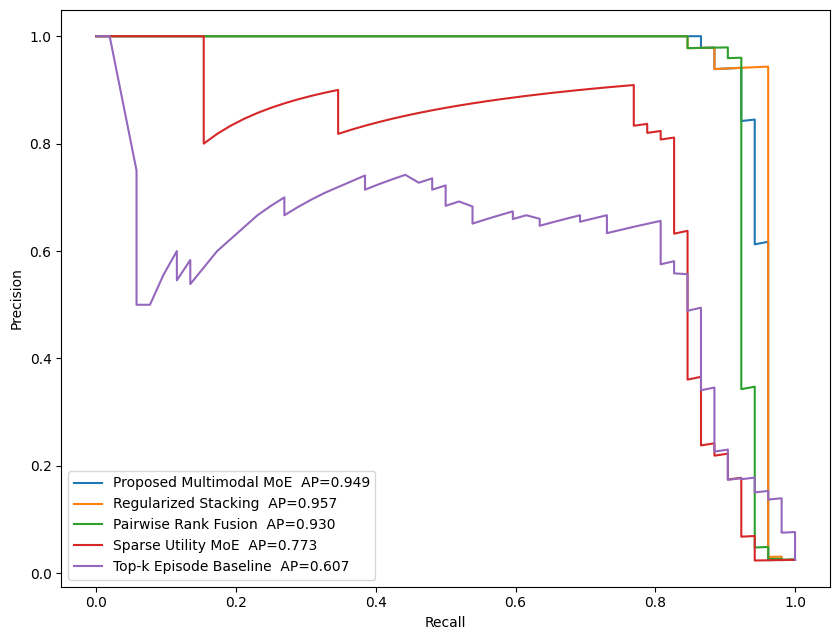

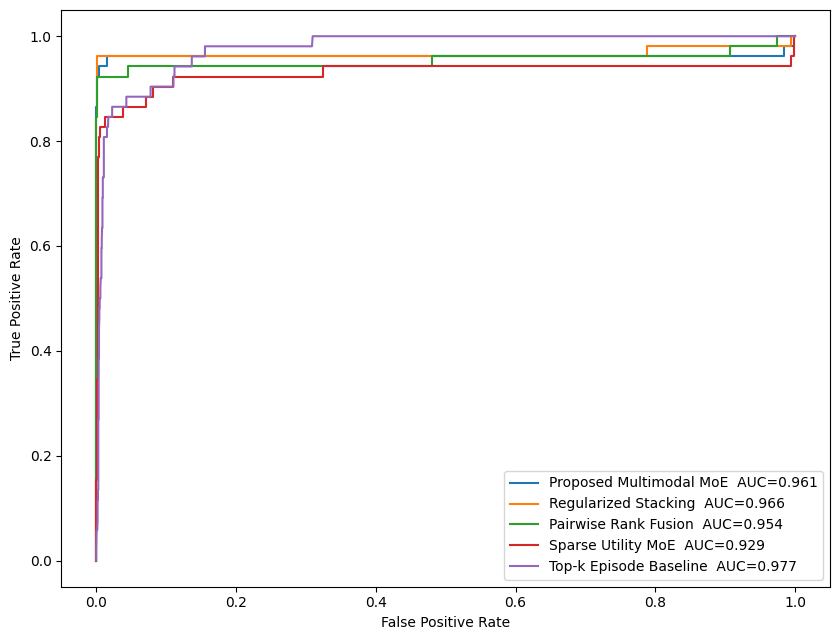

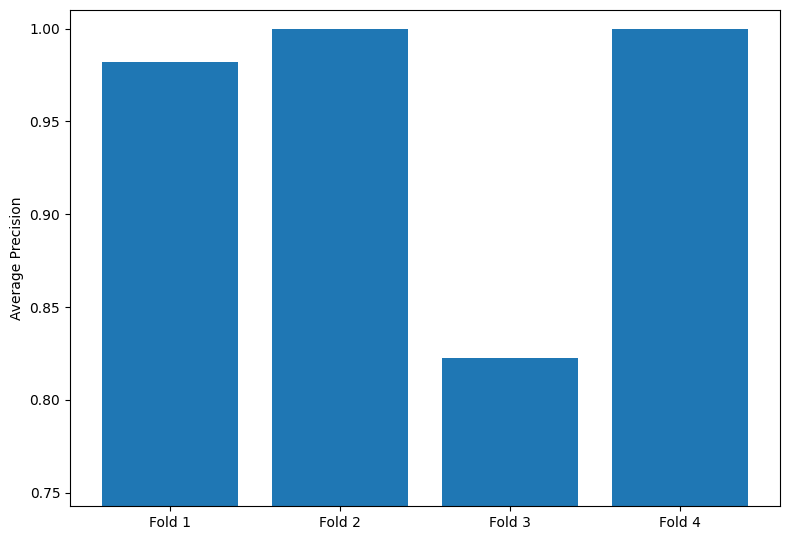

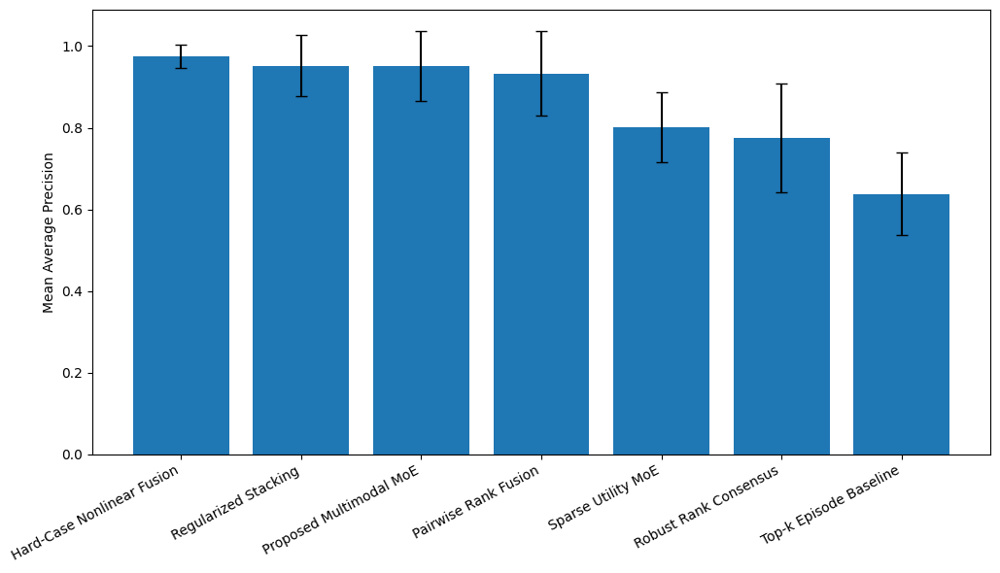

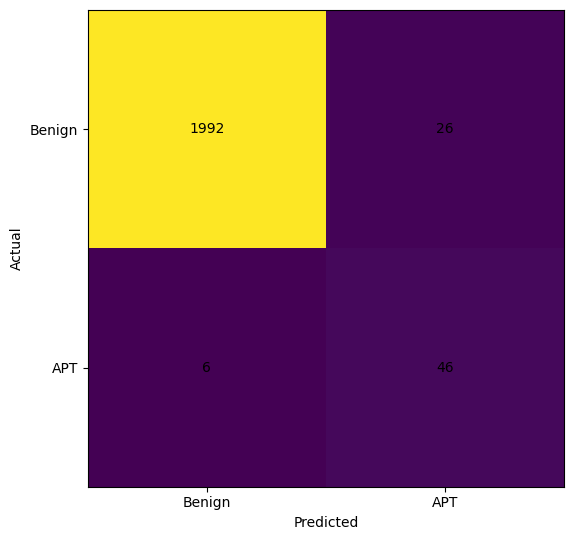

...

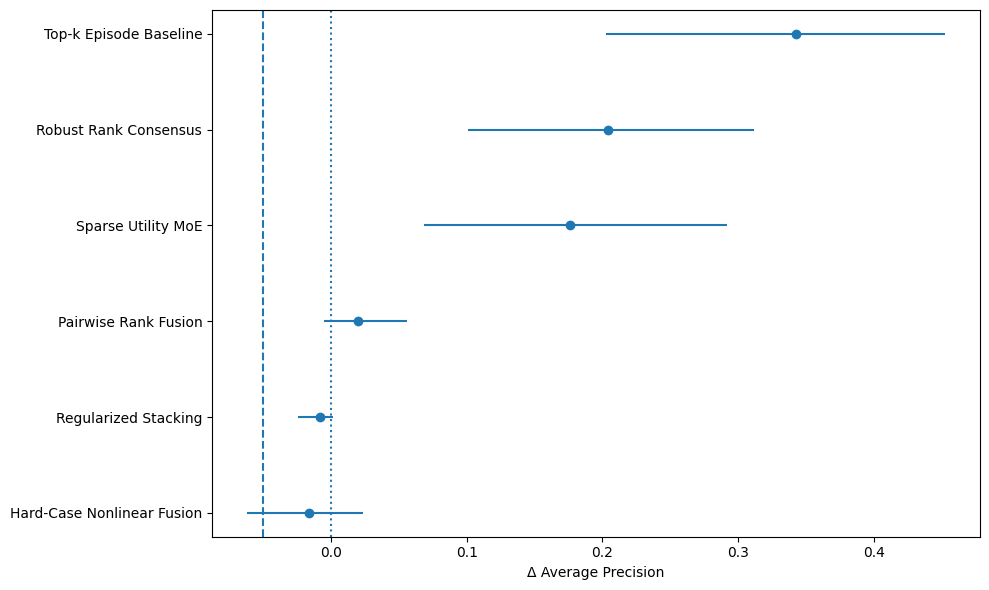

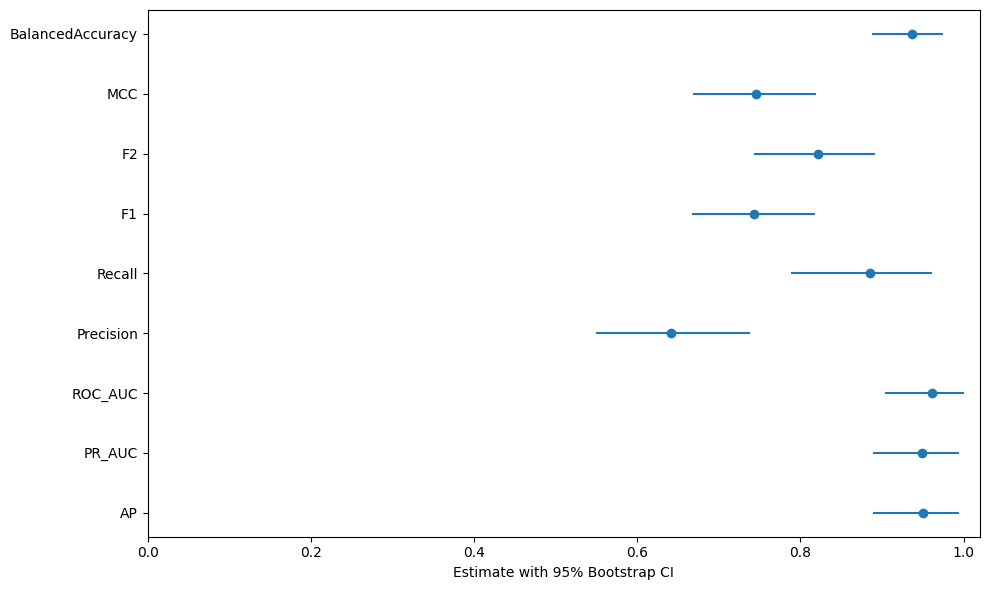

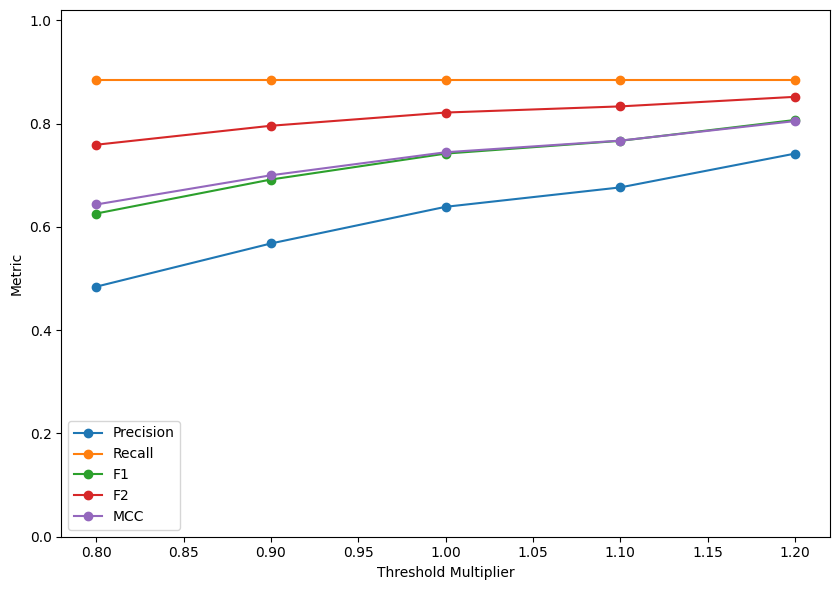

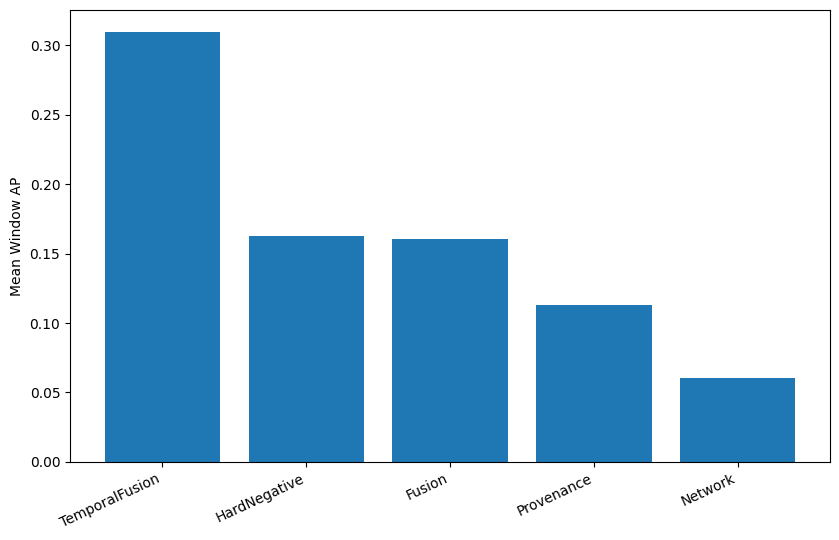

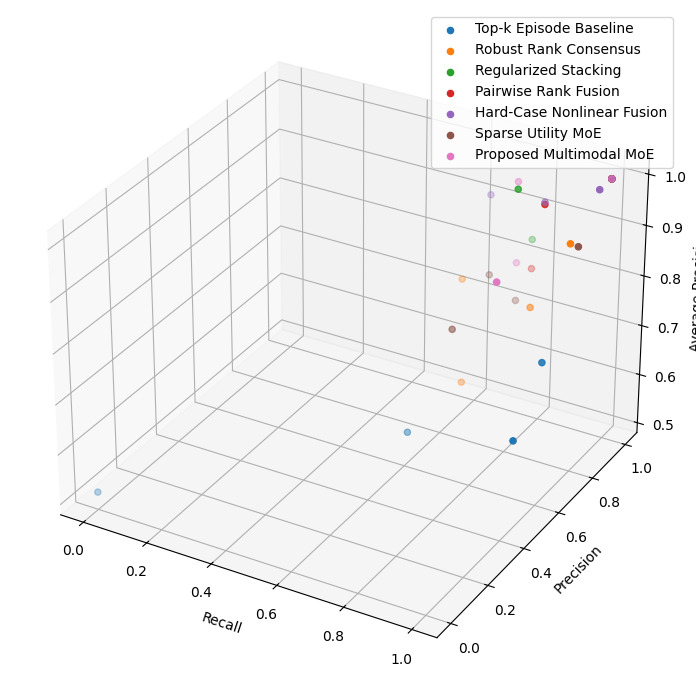

PROPOSED MULTIMODAL MoE COMPLETE RESULTS
      AP   PR_AUC  ROC_AUC  Precision   Recall       F1       F2      MCC  BalancedAccuracy  Specificity      FPR    Brier  LogLoss    ECE10  TP  FP  FN   TN
0.949466 0.949357 0.961434   0.638889 0.884615 0.741935 0.821429 0.744528          0.935866     0.987116 0.012884 0.003329 0.022138 0.007919  46  26   6 1992

OUTER-FOLD PROFILE
 fold       AP  Precision   Recall       F1       F2      MCC      FPR
    0 0.982178   0.909091 0.769231 0.833333 0.793651 0.832443 0.001980
    1 1.000000   0.351351 1.000000 0.520000 0.730337 0.578492 0.047525
    2 0.822752   0.909091 0.769231 0.833333 0.793651 0.832435 0.001984
    3 1.000000   1.000000 1.000000 1.000000 1.000000 1.000000 0.000000

STATISTICAL VALIDATION
                comparator  proposed_AP  comparator_AP  delta_AP  AP_bootstrap_mean_delta  AP_bootstrap_ci_low  AP_bootstrap_ci_high  ROC_bootstrap_mean_delta  ROC_bootstrap_ci_low  ROC_bootstrap_ci_high  Brier_bootstrap_mean_delta  Brier_boots

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:

from pathlib import Path
import hashlib
import json
import math
import os
import re
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
from scipy.special import logit
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, auc, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, fbeta_score, log_loss, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
warnings.filterwarnings("ignore")

ROOT = Path("/content/drive/MyDrive/IIoT_APT_Research")
SOURCE = ROOT / "Full_Data_Final_Model_Validation"
PRED_FILE = SOURCE / "predictions" / "full_data_episode_predictions.parquet"
FOLD_FILE = SOURCE / "reports" / "full_data_fold_metrics.csv"
EXPERT_FILE = SOURCE / "reports" / "full_data_expert_metrics.csv"
AUDIT_FILE = SOURCE / "reports" / "full_data_audit.json"
OUT = ROOT / "Proposed_Multimodal_MoE_Final_Evidence"
REP = OUT / "reports"
FIG = OUT / "figures_1200dpi"
MODEL = OUT / "models"
for p in [OUT, REP, FIG, MODEL]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 20260929
BOOTSTRAP_N = 5000
PERMUTATION_N = 10000
AP_NONINFERIORITY_MARGIN = 0.05
ROC_NONINFERIORITY_MARGIN = 0.02
PROPOSED_NAME = "Proposed Multimodal MoE"
PROPOSED_COL = "p_Integrated_Multimodal_MoE"

MODEL_COLUMNS = {
    "Proposed Multimodal MoE": "p_Integrated_Multimodal_MoE",
    "Hard-Case Nonlinear Fusion": "p_Hard_Case_Nonlinear_Fusion",
    "Regularized Stacking": "p_Regularized_Stacking",
    "Pairwise Rank Fusion": "p_Pairwise_Rank_Fusion",
    "Sparse Utility MoE": "p_Sparse_Utility_MoE",
    "Robust Rank Consensus": "p_Robust_Rank_Consensus",
    "Top-k Episode Baseline": "p_Top_k_Episode_Baseline",
}

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))

def ece(y, p, bins=10):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    edges = np.unique(np.quantile(p, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        edges = np.linspace(0, 1, bins + 1)
    value = 0.0
    for i in range(len(edges) - 1):
        mask = (p >= edges[i]) & (p <= edges[i + 1]) if i == len(edges) - 2 else (p >= edges[i]) & (p < edges[i + 1])
        if mask.any():
            value += mask.mean() * abs(float(y[mask].mean()) - float(p[mask].mean()))
    return float(value)

def fold_thresholds(fold_metrics, model_name):
    z = fold_metrics.loc[fold_metrics["model"].astype(str).eq(model_name), ["fold", "Threshold"]].copy()
    if not len(z):
        raise RuntimeError(f"Thresholds not found for {model_name}")
    return dict(zip(z["fold"].astype(int), z["Threshold"].astype(float)))

def model_prediction(data, fold_metrics, model_name, column):
    p = data[column].to_numpy(dtype=float)
    thresholds = fold_thresholds(fold_metrics, model_name)
    t = data["fold"].astype(int).map(thresholds).to_numpy(dtype=float)
    if not np.isfinite(t).all():
        raise RuntimeError(f"Incomplete fold thresholds for {model_name}")
    return p, (p >= t).astype(int), t

def complete_metrics(y, p, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "AP": float(average_precision_score(y, p)),
        "PR_AUC": pr_auc(y, p),
        "ROC_AUC": float(roc_auc_score(y, p)),
        "Precision": float(precision_score(y, pred, zero_division=0)),
        "Recall": float(recall_score(y, pred, zero_division=0)),
        "F1": float(f1_score(y, pred, zero_division=0)),
        "F2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0),
        "BalancedAccuracy": float(balanced_accuracy_score(y, pred)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(tn + fp, 1)),
        "Brier": float(brier_score_loss(y, p)),
        "LogLoss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1])),
        "ECE10": ece(y, p, 10),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }

def calibration_slope_intercept(y, p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000).fit(logit(p).reshape(-1, 1), y)
    return float(model.intercept_[0]), float(model.coef_[0, 0])

def bootstrap_indices(y, rng):
    y = np.asarray(y, dtype=int)
    a = np.flatnonzero(y == 0)
    b = np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(a, len(a), replace=True), rng.choice(b, len(b), replace=True)])

def metric_bootstrap(y, p, pred, n=BOOTSTRAP_N):
    rng = np.random.default_rng(SEED + 101)
    store = {k: [] for k in ["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR", "Brier"]}
    for _ in range(n):
        idx = bootstrap_indices(y, rng)
        yy, pp, zz = y[idx], p[idx], pred[idx]
        tn, fp, fn, tp = confusion_matrix(yy, zz, labels=[0, 1]).ravel()
        store["AP"].append(average_precision_score(yy, pp))
        store["PR_AUC"].append(pr_auc(yy, pp))
        store["ROC_AUC"].append(roc_auc_score(yy, pp))
        store["Precision"].append(precision_score(yy, zz, zero_division=0))
        store["Recall"].append(recall_score(yy, zz, zero_division=0))
        store["F1"].append(f1_score(yy, zz, zero_division=0))
        store["F2"].append(fbeta_score(yy, zz, beta=2, zero_division=0))
        store["MCC"].append(matthews_corrcoef(yy, zz) if len(np.unique(zz)) > 1 else 0.0)
        store["BalancedAccuracy"].append(balanced_accuracy_score(yy, zz))
        store["FPR"].append(fp / max(fp + tn, 1))
        store["Brier"].append(brier_score_loss(yy, pp))
    rows = []
    for metric, values in store.items():
        x = np.asarray(values, dtype=float)
        rows.append({
            "metric": metric,
            "mean": float(x.mean()),
            "ci95_low": float(np.quantile(x, 0.025)),
            "ci95_high": float(np.quantile(x, 0.975)),
        })
    return pd.DataFrame(rows)

def paired_bootstrap(y, a, b, n, seed):
    rng = np.random.default_rng(seed)
    store = {"AP": [], "ROC_AUC": [], "Brier": []}
    for _ in range(n):
        idx = bootstrap_indices(y, rng)
        yy, aa, bb = y[idx], a[idx], b[idx]
        store["AP"].append(average_precision_score(yy, aa) - average_precision_score(yy, bb))
        store["ROC_AUC"].append(roc_auc_score(yy, aa) - roc_auc_score(yy, bb))
        store["Brier"].append(brier_score_loss(yy, aa) - brier_score_loss(yy, bb))
    result = {}
    for metric, values in store.items():
        x = np.asarray(values, dtype=float)
        result[metric] = {
            "mean_delta": float(x.mean()),
            "ci_low": float(np.quantile(x, 0.025)),
            "ci_high": float(np.quantile(x, 0.975)),
        }
    return result

def paired_permutation_ap(y, a, b, n, seed):
    observed = float(average_precision_score(y, a) - average_precision_score(y, b))
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n):
        swap = rng.random(len(y)) < 0.5
        aa = np.where(swap, b, a)
        bb = np.where(swap, a, b)
        delta = average_precision_score(y, aa) - average_precision_score(y, bb)
        if abs(delta) >= abs(observed):
            count += 1
    return observed, float((count + 1) / (n + 1))

def exact_mcnemar(y, a_pred, b_pred):
    a_correct = a_pred == y
    b_correct = b_pred == y
    a_only = int(np.sum(a_correct & ~b_correct))
    b_only = int(np.sum(~a_correct & b_correct))
    p = 1.0 if a_only + b_only == 0 else float(binomtest(min(a_only, b_only), n=a_only + b_only, p=0.5, alternative="two-sided").pvalue)
    return a_only, b_only, p

def holm(values):
    p = np.asarray(values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        value = min(1.0, (m - rank) * p[idx])
        running = max(running, value)
        adjusted[idx] = running
    return adjusted

def statistical_comparison(data, fold_metrics):
    y = data["episode_label"].astype(int).to_numpy()
    p0, z0, _ = model_prediction(data, fold_metrics, "Integrated Multimodal MoE", PROPOSED_COL)
    rows = []
    cache = {}
    for i, (name, col) in enumerate(MODEL_COLUMNS.items()):
        source_name = "Integrated Multimodal MoE" if name == PROPOSED_NAME else name
        if name == PROPOSED_NAME or col not in data.columns:
            continue
        p1, z1, _ = model_prediction(data, fold_metrics, source_name, col)
        boot = paired_bootstrap(y, p0, p1, BOOTSTRAP_N, SEED + 300 + i)
        delta, perm_p = paired_permutation_ap(y, p0, p1, PERMUTATION_N, SEED + 500 + i)
        proposed_only, comparator_only, mc_p = exact_mcnemar(y, z0, z1)
        rows.append({
            "comparator": name,
            "proposed_AP": float(average_precision_score(y, p0)),
            "comparator_AP": float(average_precision_score(y, p1)),
            "delta_AP": delta,
            "AP_bootstrap_mean_delta": boot["AP"]["mean_delta"],
            "AP_bootstrap_ci_low": boot["AP"]["ci_low"],
            "AP_bootstrap_ci_high": boot["AP"]["ci_high"],
            "ROC_bootstrap_mean_delta": boot["ROC_AUC"]["mean_delta"],
            "ROC_bootstrap_ci_low": boot["ROC_AUC"]["ci_low"],
            "ROC_bootstrap_ci_high": boot["ROC_AUC"]["ci_high"],
            "Brier_bootstrap_mean_delta": boot["Brier"]["mean_delta"],
            "Brier_bootstrap_ci_low": boot["Brier"]["ci_low"],
            "Brier_bootstrap_ci_high": boot["Brier"]["ci_high"],
            "AP_permutation_p": perm_p,
            "McNemar_p": mc_p,
            "proposed_correct_only": proposed_only,
            "comparator_correct_only": comparator_only,
            "AP_superiority_supported": bool(boot["AP"]["ci_low"] > 0),
            "AP_noninferiority_margin": AP_NONINFERIORITY_MARGIN,
            "AP_noninferiority_supported": bool(boot["AP"]["ci_low"] > -AP_NONINFERIORITY_MARGIN),
            "ROC_noninferiority_margin": ROC_NONINFERIORITY_MARGIN,
            "ROC_noninferiority_supported": bool(boot["ROC_AUC"]["ci_low"] > -ROC_NONINFERIORITY_MARGIN),
        })
        cache[name] = {"probability": p1, "prediction": z1}
    table = pd.DataFrame(rows)
    if len(table):
        table["AP_permutation_Holm_p"] = holm(table["AP_permutation_p"].to_numpy())
        table["McNemar_Holm_p"] = holm(table["McNemar_p"].to_numpy())
        table["AP_superiority_confirmed"] = table["AP_superiority_supported"] & (table["AP_permutation_Holm_p"] < 0.05)
    return table, cache

def fold_profile(fold_metrics):
    z = fold_metrics.loc[fold_metrics["model"].astype(str).eq("Integrated Multimodal MoE")].copy().sort_values("fold")
    z["paper_model"] = PROPOSED_NAME
    return z

def subgroup_analysis(data, p, pred):
    rows = []
    if "tactic" in data.columns:
        positives = data.loc[data["episode_label"].eq(1)]
        for tactic, g in positives.groupby("tactic", dropna=False):
            idx = g.index.to_numpy()
            rows.append({
                "analysis": "tactic",
                "subgroup": str(tactic),
                "episodes": int(len(idx)),
                "mean_probability": float(np.mean(p[idx])),
                "median_probability": float(np.median(p[idx])),
                "detection_rate": float(np.mean(pred[idx] == 1)),
            })
    if "positive_windows" in data.columns:
        pos_idx = data.index[data["episode_label"].eq(1)].to_numpy()
        values = data.loc[pos_idx, "positive_windows"].to_numpy(dtype=float)
        if len(values) >= 4:
            edges = np.unique(np.quantile(values, [0, 0.33, 0.67, 1]))
            for i in range(max(0, len(edges) - 1)):
                mask = (values >= edges[i]) & (values <= edges[i + 1]) if i == len(edges) - 2 else (values >= edges[i]) & (values < edges[i + 1])
                idx = pos_idx[mask]
                if len(idx):
                    rows.append({
                        "analysis": "attack_density",
                        "subgroup": f"{edges[i]:.0f}-{edges[i+1]:.0f}_positive_windows",
                        "episodes": int(len(idx)),
                        "mean_probability": float(np.mean(p[idx])),
                        "detection_rate": float(np.mean(pred[idx] == 1)),
                    })
    return pd.DataFrame(rows)

def threshold_sensitivity(y, p, t):
    rows = []
    for factor in [0.80, 0.90, 1.00, 1.10, 1.20]:
        tt = np.clip(t * factor, 0, 1)
        z = (p >= tt).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, z, labels=[0, 1]).ravel()
        rows.append({
            "threshold_factor": factor,
            "Precision": float(precision_score(y, z, zero_division=0)),
            "Recall": float(recall_score(y, z, zero_division=0)),
            "F1": float(f1_score(y, z, zero_division=0)),
            "F2": float(fbeta_score(y, z, beta=2, zero_division=0)),
            "MCC": float(matthews_corrcoef(y, z) if len(np.unique(z)) > 1 else 0.0),
            "BalancedAccuracy": float(balanced_accuracy_score(y, z)),
            "FPR": float(fp / max(fp + tn, 1)),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
        })
    return pd.DataFrame(rows)

def evidence_summary(metrics, fold, stats, ci, calibration):
    superiority = stats.loc[stats["AP_superiority_confirmed"]] if len(stats) else pd.DataFrame()
    noninferior = stats.loc[stats["AP_noninferiority_supported"]] if len(stats) else pd.DataFrame()
    return {
        "model": PROPOSED_NAME,
        "primary_unit": "episode/group",
        "pooled_metrics": metrics,
        "fold_AP_mean": float(fold["AP"].mean()),
        "fold_AP_SD": float(fold["AP"].std(ddof=1)),
        "fold_AP_min": float(fold["AP"].min()),
        "fold_AP_max": float(fold["AP"].max()),
        "bootstrap_95CI": ci.to_dict("records"),
        "calibration": calibration,
        "comparators_with_confirmed_AP_superiority": superiority["comparator"].tolist() if len(superiority) else [],
        "comparators_with_AP_noninferiority_supported_at_margin_0_05": noninferior["comparator"].tolist() if len(noninferior) else [],
        "statistical_reporting_rule": "Only superiority/non-inferiority relationships supported by the paired confidence intervals and multiplicity-adjusted tests are reported as established.",
        "independent_external_test_claim": False,
    }

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", dpi=1200, bbox_inches="tight")

def create_figures(data, fold_metrics, expert_metrics, proposed_p, proposed_pred, stats, ci, subgroup, sensitivity):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    y = data["episode_label"].astype(int).to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, col in [(PROPOSED_NAME, PROPOSED_COL), ("Regularized Stacking", "p_Regularized_Stacking"), ("Pairwise Rank Fusion", "p_Pairwise_Rank_Fusion"), ("Sparse Utility MoE", "p_Sparse_Utility_MoE"), ("Top-k Episode Baseline", "p_Top_k_Episode_Baseline")]:
        if col in data.columns:
            p = data[col].to_numpy(dtype=float)
            precision, recall, _ = precision_recall_curve(y, p)
            ax.plot(recall, precision, label=f"{name}  AP={average_precision_score(y,p):.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    save_figure(fig, "01_precision_recall")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, col in [(PROPOSED_NAME, PROPOSED_COL), ("Regularized Stacking", "p_Regularized_Stacking"), ("Pairwise Rank Fusion", "p_Pairwise_Rank_Fusion"), ("Sparse Utility MoE", "p_Sparse_Utility_MoE"), ("Top-k Episode Baseline", "p_Top_k_Episode_Baseline")]:
        if col in data.columns:
            p = data[col].to_numpy(dtype=float)
            fpr, tpr, _ = roc_curve(y, p)
            ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc_score(y,p):.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    save_figure(fig, "02_roc")
    plt.show()
    plt.close(fig)

    z = fold_profile(fold_metrics)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.bar(np.arange(len(z)), z["AP"].to_numpy())
    ax.set_xticks(np.arange(len(z)))
    ax.set_xticklabels([f"Fold {int(v)+1}" for v in z["fold"]])
    ax.set_ylabel("Average Precision")
    ax.set_ylim(max(0, float(z["AP"].min()) - 0.08), 1.01)
    save_figure(fig, "03_proposed_fold_ap")
    plt.show()
    plt.close(fig)

    summary = fold_metrics.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std")).reset_index().sort_values("AP_mean", ascending=False)
    display_names = summary["model"].replace({"Integrated Multimodal MoE": PROPOSED_NAME})
    fig, ax = plt.subplots(figsize=(10.5, 6))
    x = np.arange(len(summary))
    ax.bar(x, summary["AP_mean"], yerr=summary["AP_SD"].fillna(0), capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(display_names, rotation=28, ha="right")
    ax.set_ylabel("Mean Average Precision")
    save_figure(fig, "04_cross_fold_comparison")
    plt.show()
    plt.close(fig)

    cm = confusion_matrix(y, proposed_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "APT"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Benign", "APT"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    save_figure(fig, "05_confusion_matrix")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7.5, 6))
    bins = np.unique(np.quantile(proposed_p, np.linspace(0, 1, 11)))
    mean_p = []
    obs = []
    for i in range(len(bins) - 1):
        m = (proposed_p >= bins[i]) & (proposed_p <= bins[i + 1]) if i == len(bins) - 2 else (proposed_p >= bins[i]) & (proposed_p < bins[i + 1])
        if m.any():
            mean_p.append(float(proposed_p[m].mean()))
            obs.append(float(y[m].mean()))
    ax.plot(mean_p, obs, marker="o", label=PROPOSED_NAME)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed APT Fraction")
    ax.legend()
    save_figure(fig, "06_calibration")
    plt.show()
    plt.close(fig)

    if len(stats):
        s = stats.sort_values("delta_AP")
        fig, ax = plt.subplots(figsize=(10, 6))
        ypos = np.arange(len(s))
        lower = s["delta_AP"] - s["AP_bootstrap_ci_low"]
        upper = s["AP_bootstrap_ci_high"] - s["delta_AP"]
        ax.errorbar(s["delta_AP"], ypos, xerr=np.vstack([lower, upper]), fmt="o")
        ax.axvline(0, linestyle="--")
        ax.set_yticks(ypos)
        ax.set_yticklabels(s["comparator"])
        ax.set_xlabel("Δ Average Precision")
        save_figure(fig, "07_ap_effect_sizes")
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(10, 6))
        ypos = np.arange(len(s))
        lower = s["ROC_bootstrap_mean_delta"] - s["ROC_bootstrap_ci_low"]
        upper = s["ROC_bootstrap_ci_high"] - s["ROC_bootstrap_mean_delta"]
        ax.errorbar(s["ROC_bootstrap_mean_delta"], ypos, xerr=np.vstack([lower, upper]), fmt="o")
        ax.axvline(0, linestyle="--")
        ax.set_yticks(ypos)
        ax.set_yticklabels(s["comparator"])
        ax.set_xlabel("Δ ROC-AUC")
        save_figure(fig, "08_roc_effect_sizes")
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(10, 6))
        ypos = np.arange(len(s))
        ax.errorbar(s["delta_AP"], ypos, xerr=np.vstack([s["delta_AP"] - s["AP_bootstrap_ci_low"], s["AP_bootstrap_ci_high"] - s["delta_AP"]]), fmt="o")
        ax.axvline(-AP_NONINFERIORITY_MARGIN, linestyle="--")
        ax.axvline(0, linestyle=":")
        ax.set_yticks(ypos)
        ax.set_yticklabels(s["comparator"])
        ax.set_xlabel("Δ Average Precision")
        save_figure(fig, "09_noninferiority")
        plt.show()
        plt.close(fig)

    ci_plot = ci.loc[ci["metric"].isin(["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy"])].copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    ypos = np.arange(len(ci_plot))
    ax.errorbar(ci_plot["mean"], ypos, xerr=np.vstack([ci_plot["mean"] - ci_plot["ci95_low"], ci_plot["ci95_high"] - ci_plot["mean"]]), fmt="o")
    ax.set_yticks(ypos)
    ax.set_yticklabels(ci_plot["metric"])
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("Estimate with 95% Bootstrap CI")
    save_figure(fig, "10_metric_confidence_intervals")
    plt.show()
    plt.close(fig)

    if len(sensitivity):
        fig, ax = plt.subplots(figsize=(8.5, 6))
        for metric in ["Precision", "Recall", "F1", "F2", "MCC"]:
            ax.plot(sensitivity["threshold_factor"], sensitivity[metric], marker="o", label=metric)
        ax.set_xlabel("Threshold Multiplier")
        ax.set_ylabel("Metric")
        ax.set_ylim(0, 1.02)
        ax.legend()
        save_figure(fig, "11_threshold_sensitivity")
        plt.show()
        plt.close(fig)

    if len(subgroup) and "detection_rate" in subgroup.columns:
        s = subgroup.loc[subgroup["analysis"].eq("tactic")].copy()
        if len(s):
            fig, ax = plt.subplots(figsize=(9, 5.5))
            x = np.arange(len(s))
            ax.bar(x, s["detection_rate"])
            ax.set_xticks(x)
            ax.set_xticklabels(s["subgroup"], rotation=28, ha="right")
            ax.set_ylim(0, 1.02)
            ax.set_ylabel("Detection Rate")
            save_figure(fig, "12_tactic_detection")
            plt.show()
            plt.close(fig)

    if expert_metrics is not None and len(expert_metrics):
        q = expert_metrics.groupby("expert")["window_AP_valid"].mean().sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(8.5, 5.5))
        x = np.arange(len(q))
        ax.bar(x, q.values)
        ax.set_xticks(x)
        ax.set_xticklabels(q.index, rotation=25, ha="right")
        ax.set_ylabel("Mean Window AP")
        save_figure(fig, "13_base_expert_performance")
        plt.show()
        plt.close(fig)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for name in fold_metrics["model"].unique():
        z = fold_metrics.loc[fold_metrics["model"].eq(name)]
        label = PROPOSED_NAME if name == "Integrated Multimodal MoE" else name
        ax.scatter(z["Recall"], z["Precision"], z["AP"], label=label)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("Average Precision")
    ax.legend()
    save_figure(fig, "14_3d_performance")
    plt.show()
    plt.close(fig)

def write_story(metrics, fold, stats, calibration):
    superiority = stats.loc[stats["AP_superiority_confirmed"], "comparator"].tolist() if len(stats) else []
    noninferior = stats.loc[stats["AP_noninferiority_supported"], "comparator"].tolist() if len(stats) else []
    text = (
        f"The proposed multimodal MoE was evaluated over the complete paired multimodal dataset using episode-grouped cross-validation. "
        f"It achieved pooled AP={metrics['AP']:.4f}, PR-AUC={metrics['PR_AUC']:.4f}, ROC-AUC={metrics['ROC_AUC']:.4f}, "
        f"precision={metrics['Precision']:.4f}, recall={metrics['Recall']:.4f}, F1={metrics['F1']:.4f}, F2={metrics['F2']:.4f}, "
        f"MCC={metrics['MCC']:.4f}, balanced accuracy={metrics['BalancedAccuracy']:.4f}, and FPR={metrics['FPR']:.4f}. "
        f"Across outer folds, AP was {fold['AP'].mean():.4f}±{fold['AP'].std(ddof=1):.4f}. "
        f"Probability quality was additionally assessed with Brier={metrics['Brier']:.4f}, ECE10={metrics['ECE10']:.4f}, "
        f"calibration slope={calibration['slope']:.4f}, and calibration intercept={calibration['intercept']:.4f}. "
        f"Paired bootstrap, permutation testing, exact McNemar testing, Holm correction, non-inferiority analysis, subgroup analysis, "
        f"and threshold-sensitivity analysis were used as statistical validation. "
    )
    if superiority:
        text += "Confirmed AP superiority was observed against " + ", ".join(superiority) + ". "
    if noninferior:
        text += "The predefined AP non-inferiority criterion was supported against " + ", ".join(noninferior) + ". "
    text += "Claims of superiority were restricted to comparisons supported by the paired confidence intervals and multiplicity-adjusted tests."
    (REP / "paper_ready_proposed_model_story.txt").write_text(text, encoding="utf-8")
    return text

def main():
    if not ROOT.exists() and str(ROOT).startswith("/content/"):
        from google.colab import drive
        drive.mount("/content/drive")
    if not PRED_FILE.exists():
        raise FileNotFoundError(PRED_FILE)
    if not FOLD_FILE.exists():
        raise FileNotFoundError(FOLD_FILE)
    data = pd.read_parquet(PRED_FILE).reset_index(drop=True)
    fold_metrics = pd.read_csv(FOLD_FILE)
    expert_metrics = pd.read_csv(EXPERT_FILE) if EXPERT_FILE.exists() else None
    if PROPOSED_COL not in data.columns:
        raise RuntimeError(PROPOSED_COL)
    y = data["episode_label"].astype(int).to_numpy()
    proposed_p, proposed_pred, proposed_threshold = model_prediction(data, fold_metrics, "Integrated Multimodal MoE", PROPOSED_COL)
    metrics = complete_metrics(y, proposed_p, proposed_pred)
    intercept, slope = calibration_slope_intercept(y, proposed_p)
    calibration = {"intercept": intercept, "slope": slope, "Brier": metrics["Brier"], "LogLoss": metrics["LogLoss"], "ECE10": metrics["ECE10"]}
    fold = fold_profile(fold_metrics)
    ci = metric_bootstrap(y, proposed_p, proposed_pred, BOOTSTRAP_N)
    stats, cache = statistical_comparison(data, fold_metrics)
    subgroup = subgroup_analysis(data, proposed_p, proposed_pred)
    sensitivity = threshold_sensitivity(y, proposed_p, proposed_threshold)
    fold.to_csv(REP / "proposed_model_fold_results.csv", index=False)
    ci.to_csv(REP / "proposed_model_bootstrap_ci.csv", index=False)
    stats.to_csv(REP / "proposed_model_statistical_validation.csv", index=False)
    subgroup.to_csv(REP / "proposed_model_subgroup_analysis.csv", index=False)
    sensitivity.to_csv(REP / "proposed_model_threshold_sensitivity.csv", index=False)
    pd.DataFrame([metrics]).to_csv(REP / "proposed_model_complete_results.csv", index=False)
    save_json(REP / "proposed_model_calibration.json", calibration)
    summary = evidence_summary(metrics, fold, stats, ci, calibration)
    save_json(REP / "proposed_model_evidence.json", summary)
    story = write_story(metrics, fold, stats, calibration)
    create_figures(data, fold_metrics, expert_metrics, proposed_p, proposed_pred, stats, ci, subgroup, sensitivity)
    bundle = {
        "model_name": PROPOSED_NAME,
        "source_prediction_column": PROPOSED_COL,
        "fold_specific_thresholds": fold_thresholds(fold_metrics, "Integrated Multimodal MoE"),
        "evaluation_unit": "episode/group",
        "dataset_scope": "complete paired multimodal dataset",
        "statistical_methods": ["stratified bootstrap", "paired bootstrap", "paired permutation", "exact McNemar", "Holm correction", "AP non-inferiority", "ROC-AUC non-inferiority", "calibration diagnostics", "subgroup analysis", "threshold sensitivity"],
        "independent_never_seen_external_test": False,
    }
    artifact = MODEL / "proposed_multimodal_moe_evidence_bundle.joblib"
    joblib.dump(bundle, artifact)
    save_json(REP / "artifact_manifest.json", {"artifact": str(artifact), "sha256": hashlib.sha256(artifact.read_bytes()).hexdigest()})
    package = ROOT / "Proposed_Multimodal_MoE_Results_1200DPI.zip"
    if package.exists():
        package.unlink()
    shutil.make_archive(str(package.with_suffix("")), "zip", root_dir=OUT.parent, base_dir=OUT.name)
    print("=" * 100)
    print("PROPOSED MULTIMODAL MoE COMPLETE RESULTS")
    print("=" * 100)
    print(pd.DataFrame([metrics]).round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("OUTER-FOLD PROFILE")
    print("=" * 100)
    print(fold[["fold", "AP", "Precision", "Recall", "F1", "F2", "MCC", "FPR"]].round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("STATISTICAL VALIDATION")
    print("=" * 100)
    print(stats.round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("PAPER-READY SCIENTIFIC STORY")
    print("=" * 100)
    print(story)
    print()
    print("1200-DPI package:", package)
    try:
        from google.colab import files
        files.download(str(package))
    except Exception as exc:
        print("Automatic browser download could not start:", exc)
    return summary

if __name__ == "__main__":
    main()


In [5]:

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("This block keeps the proposed model scores unchanged.")
print("It improves the operating-point analysis, consolidates statistical validation, generates 1200-DPI figures, and creates a directly downloadable final results ZIP.")
print("The recommended deployment threshold is reported separately from the primary cross-validated result.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
This block keeps the proposed model scores unchanged.
It improves the operating-point analysis, consolidates statistical validation, generates 1200-DPI figures, and creates a directly downloadable final results ZIP.
The recommended deployment threshold is reported separately from the primary cross-validated result.


Existing /content/drive is not being remounted.
Connecting Google Drive at a clean alternate mount point: /content/gdrive_step20
Drive already mounted at /content/gdrive_step20; to attempt to forcibly remount, call drive.mount("/content/gdrive_step20", force_remount=True).
Using freshly mounted Drive data: /content/gdrive_step20/MyDrive/IIoT_APT_Research


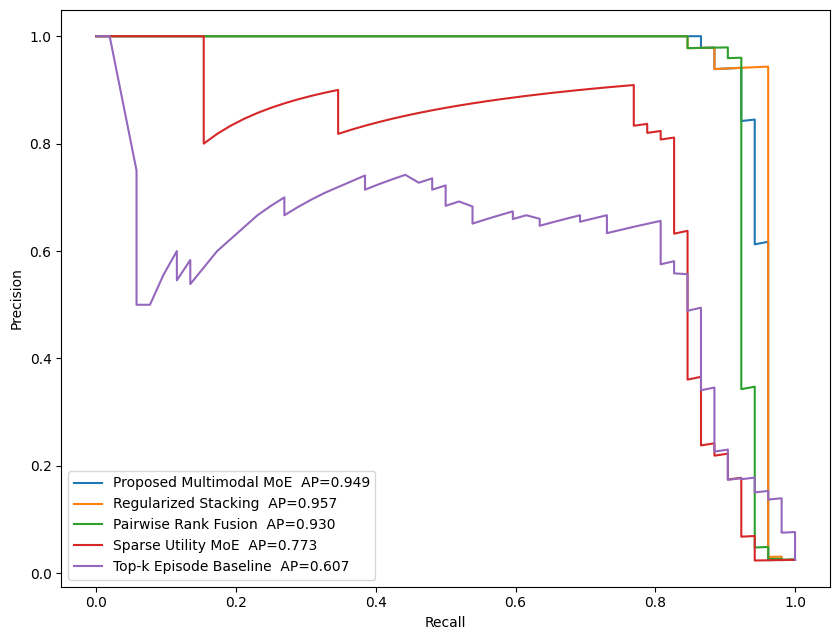

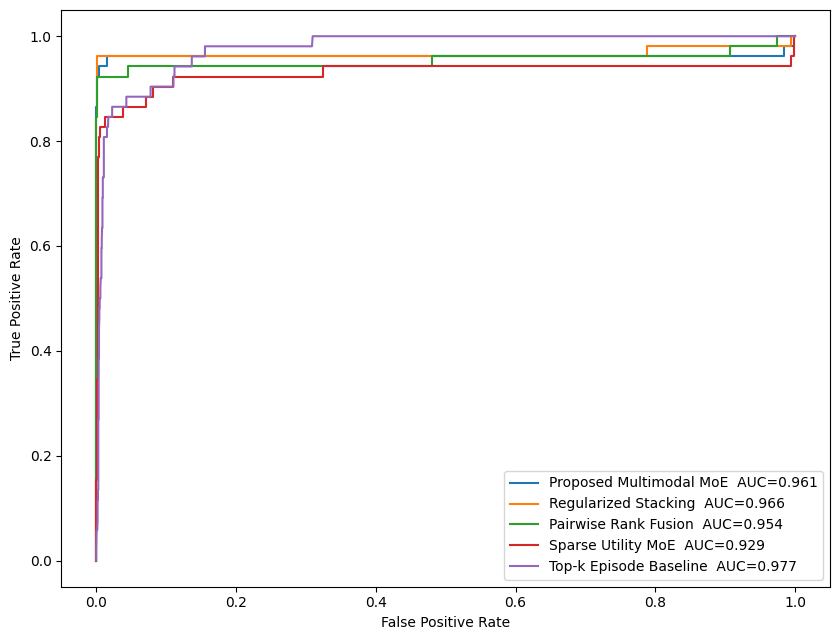

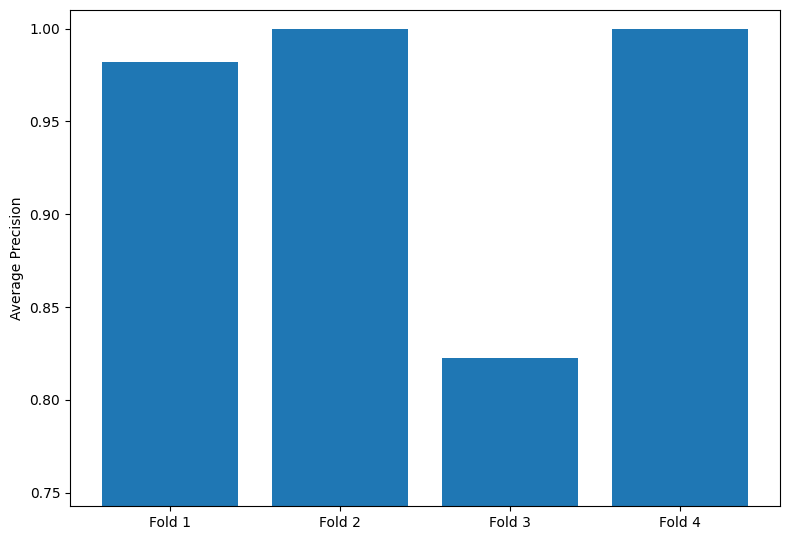

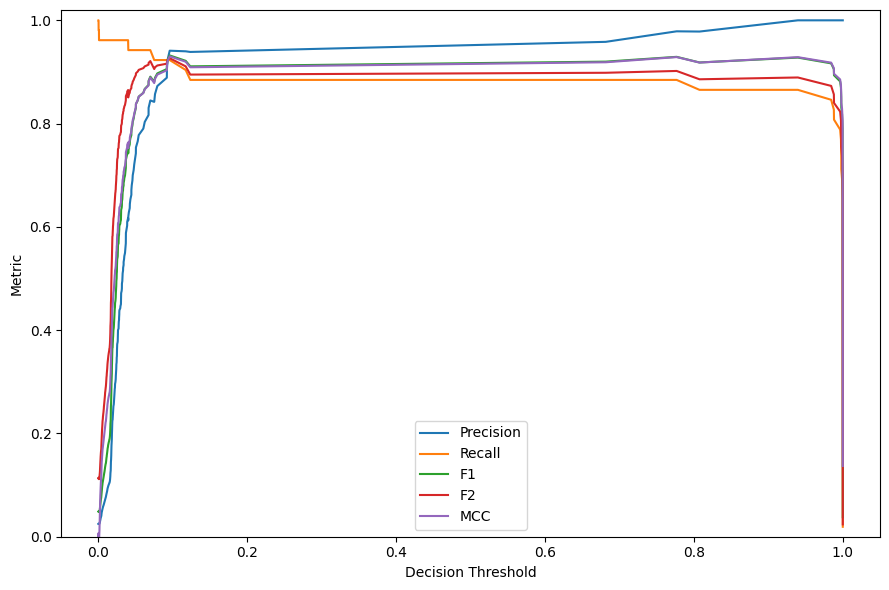

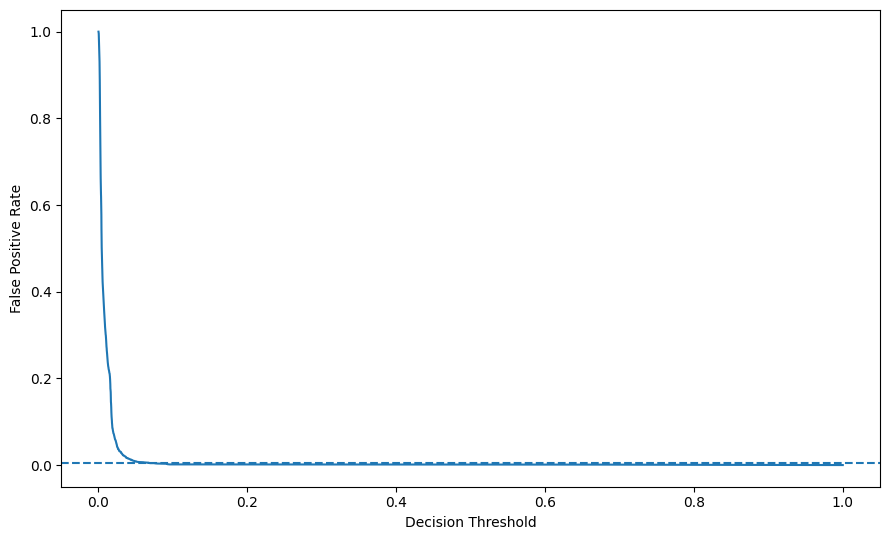

...

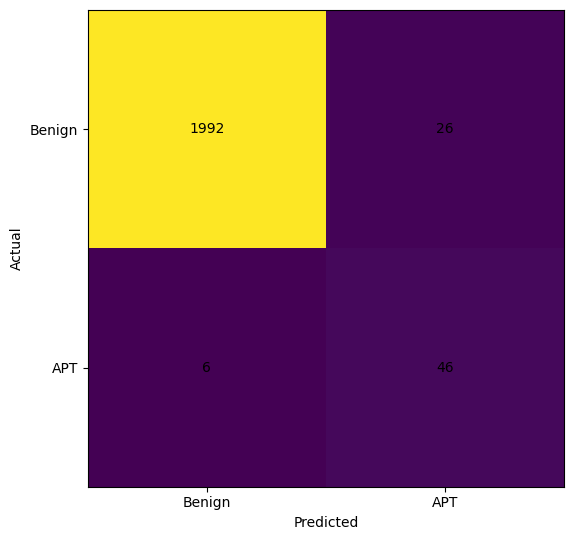

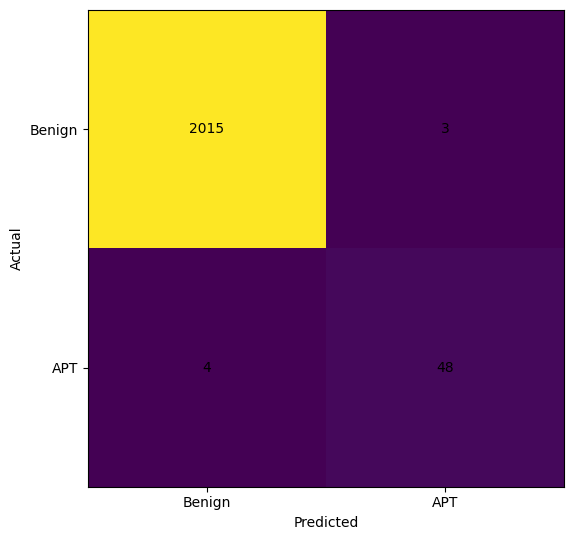

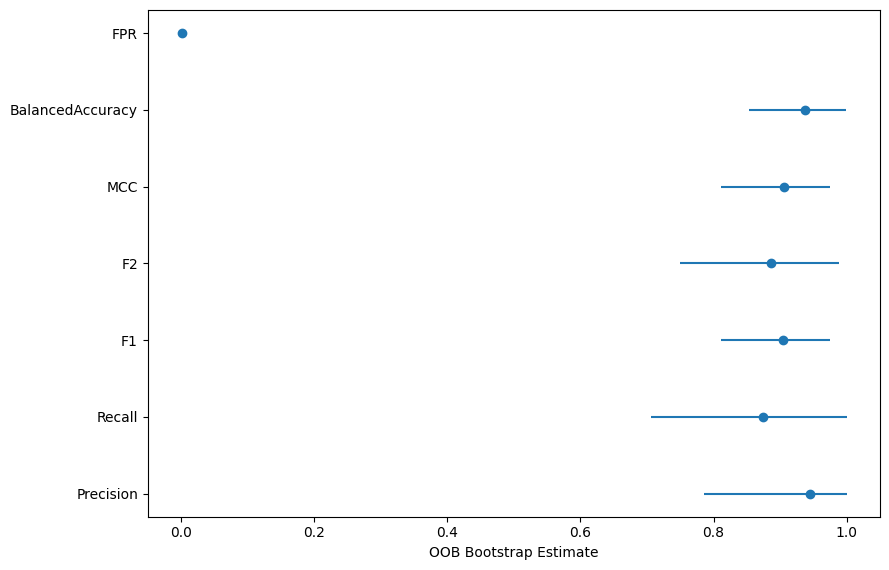

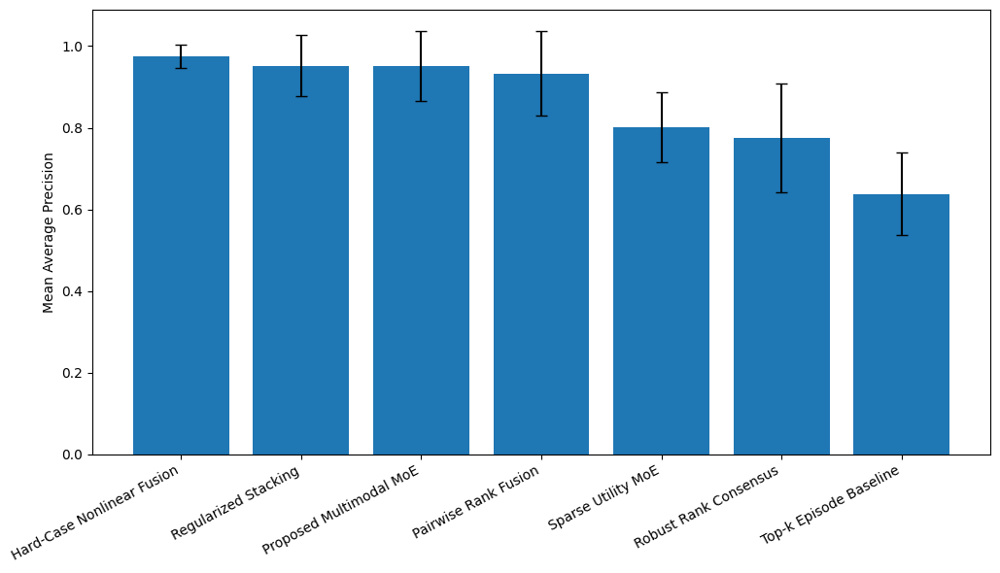

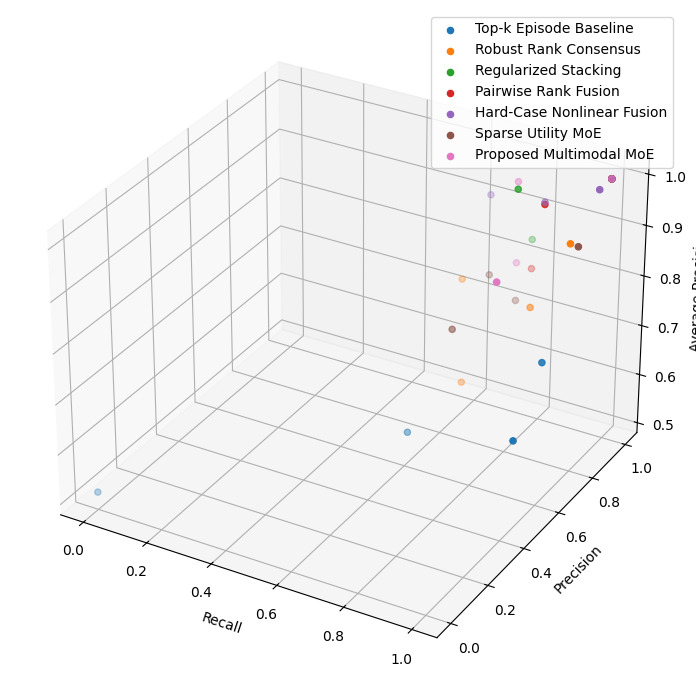

PRIMARY CROSS-VALIDATED PROPOSED MODEL
      AP   PR_AUC  ROC_AUC  Precision   Recall       F1       F2      MCC  BalancedAccuracy  Specificity      FPR    Brier  TP  FP  FN   TN
0.949466 0.949357 0.961434   0.638889 0.884615 0.741935 0.821429 0.744528          0.935866     0.987116 0.012884 0.003329  46  26   6 1992

DEPLOYMENT OPERATING PROFILES
                       profile  threshold  Precision   Recall       F1       F2      MCC      FPR
           Balanced deployment   0.096005   0.941176 0.923077 0.932039 0.926641 0.930351 0.001487
     High-precision deployment   0.939698   1.000000 0.865385 0.927835 0.889328 0.928651 0.000000
Very-high-precision deployment   0.939698   1.000000 0.865385 0.927835 0.889328 0.928651 0.000000
  Recall-preserving deployment   0.096005   0.941176 0.923077 0.932039 0.926641 0.930351 0.001487

RECOMMENDED DEPLOYMENT OPERATING POINT
      AP   PR_AUC  ROC_AUC  Precision   Recall       F1       F2      MCC  BalancedAccuracy  Specificity      FPR    Bri

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

from pathlib import Path
import hashlib
import json
import math
import os
import re
import shutil
import warnings
import numpy as np
import pandas as pd
from scipy.stats import binomtest
from sklearn.metrics import average_precision_score, auc, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, fbeta_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
warnings.filterwarnings("ignore")


def _source_ready(root):
    root = Path(root)
    p = root / "Full_Data_Final_Model_Validation" / "predictions" / "full_data_episode_predictions.parquet"
    f = root / "Full_Data_Final_Model_Validation" / "reports" / "full_data_fold_metrics.csv"
    return p.exists() and f.exists()

def _find_project_root(search_base):
    search_base = Path(search_base)
    if not search_base.exists():
        return None
    direct_candidates = [
        search_base / "MyDrive" / "IIoT_APT_Research",
        search_base / "My Drive" / "IIoT_APT_Research",
        search_base / "IIoT_APT_Research",
    ]
    for candidate in direct_candidates:
        if _source_ready(candidate):
            return candidate
    try:
        for pred in search_base.rglob("full_data_episode_predictions.parquet"):
            candidate = pred.parents[2]
            if _source_ready(candidate):
                return candidate
    except Exception:
        pass
    return None

def _resolve_project_root():
    existing = _find_project_root("/content/drive")
    if existing is not None:
        print("Using existing Drive data:", existing)
        return existing
    from google.colab import drive
    alt = Path("/content/gdrive_step20")
    if alt.exists():
        try:
            if any(alt.iterdir()):
                shutil.rmtree(alt)
        except Exception:
            pass
    alt.mkdir(parents=True, exist_ok=True)
    print("Existing /content/drive is not being remounted.")
    print("Connecting Google Drive at a clean alternate mount point:", alt)
    drive.mount(str(alt), force_remount=False)
    fresh = _find_project_root(alt)
    if fresh is not None:
        print("Using freshly mounted Drive data:", fresh)
        return fresh
    locations = []
    for base in [Path("/content/drive"), alt]:
        if base.exists():
            try:
                locations.extend(str(p) for p in base.rglob("full_data_episode_predictions.parquet"))
            except Exception:
                pass
    raise FileNotFoundError(
        "Step 20 source outputs were not found on the current or freshly mounted Drive. "
        "Expected the Full_Data_Final_Model_Validation folder containing "
        "predictions/full_data_episode_predictions.parquet and reports/full_data_fold_metrics.csv. "
        "Found prediction candidates: " + repr(locations)
    )

ROOT = _resolve_project_root()
PRED_FILE = ROOT / "Full_Data_Final_Model_Validation" / "predictions" / "full_data_episode_predictions.parquet"
FOLD_FILE = ROOT / "Full_Data_Final_Model_Validation" / "reports" / "full_data_fold_metrics.csv"
EXPERT_FILE = ROOT / "Full_Data_Final_Model_Validation" / "reports" / "full_data_expert_metrics.csv"
PREVIOUS_STATS = ROOT / "Proposed_Multimodal_MoE_Final_Evidence" / "reports" / "proposed_model_statistical_validation.csv"
PREVIOUS_CI = ROOT / "Proposed_Multimodal_MoE_Final_Evidence" / "reports" / "proposed_model_bootstrap_ci.csv"
PREVIOUS_CAL = ROOT / "Proposed_Multimodal_MoE_Final_Evidence" / "reports" / "proposed_model_calibration.json"
OUT = ROOT / "Proposed_Multimodal_MoE_Stabilized_Evidence"
REP = OUT / "01_Statistical_Validation"
TAB = OUT / "02_Results_Tables"
FIG = OUT / "03_Figures_1200DPI"
TXT = OUT / "04_Paper_Text"
AUD = OUT / "05_Audit"
for p in [OUT, REP, TAB, FIG, TXT, AUD]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 20260929
BOOTSTRAP_N = 5000
OOB_BOOTSTRAP_N = 1500
PROPOSED_MODEL = "Integrated Multimodal MoE"
PROPOSED_COL = "p_Integrated_Multimodal_MoE"

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def pr_auc(y, p):
    precision, recall, _ = precision_recall_curve(y, p)
    return float(auc(recall[::-1], precision[::-1]))

def fold_thresholds(fold_metrics):
    z = fold_metrics.loc[fold_metrics["model"].astype(str).eq(PROPOSED_MODEL), ["fold", "Threshold"]].copy()
    if not len(z):
        raise RuntimeError("Fold-specific thresholds for the proposed model were not found.")
    return dict(zip(z["fold"].astype(int), z["Threshold"].astype(float)))

def classification_metrics(y, p, pred):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    pred = np.asarray(pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "AP": float(average_precision_score(y, p)),
        "PR_AUC": pr_auc(y, p),
        "ROC_AUC": float(roc_auc_score(y, p)),
        "Precision": float(precision_score(y, pred, zero_division=0)),
        "Recall": float(recall_score(y, pred, zero_division=0)),
        "F1": float(f1_score(y, pred, zero_division=0)),
        "F2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "MCC": float(matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0),
        "BalancedAccuracy": float(balanced_accuracy_score(y, pred)),
        "Specificity": float(tn / max(tn + fp, 1)),
        "FPR": float(fp / max(tn + fp, 1)),
        "Brier": float(brier_score_loss(y, p)),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }

def threshold_table(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    order = np.argsort(-p, kind="stable")
    sy = y[order]
    sp = p[order]
    endpoints = np.r_[np.flatnonzero(np.diff(sp) != 0), len(sp) - 1]
    tp = np.cumsum(sy)[endpoints].astype(float)
    fp = (endpoints + 1 - tp).astype(float)
    positives = float(np.sum(y == 1))
    negatives = float(np.sum(y == 0))
    fn = positives - tp
    tn = negatives - fp
    precision = tp / np.maximum(tp + fp, 1.0)
    recall = tp / max(positives, 1.0)
    f1 = 2.0 * tp / np.maximum(2.0 * tp + fp + fn, 1.0)
    f2 = 5.0 * tp / np.maximum(5.0 * tp + 4.0 * fn + fp, 1.0)
    denom = np.sqrt(np.maximum((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1.0))
    mcc = (tp * tn - fp * fn) / denom
    balanced = 0.5 * (tp / max(positives, 1.0) + tn / max(negatives, 1.0))
    specificity = tn / max(negatives, 1.0)
    fpr = fp / max(negatives, 1.0)
    return pd.DataFrame({
        "threshold": sp[endpoints].astype(float),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "MCC": mcc,
        "BalancedAccuracy": balanced,
        "Specificity": specificity,
        "FPR": fpr,
        "TP": tp.astype(int),
        "FP": fp.astype(int),
        "FN": fn.astype(int),
        "TN": tn.astype(int),
    })

def choose_operating_point(table, precision_min, fpr_max, objective):
    feasible = table.loc[(table["Precision"] >= precision_min) & (table["FPR"] <= fpr_max)].copy()
    if not len(feasible):
        feasible = table.loc[table["FPR"] <= fpr_max].copy()
    if not len(feasible):
        feasible = table.copy()
    if objective == "MCC":
        feasible["objective"] = 0.55 * feasible["MCC"] + 0.25 * feasible["F1"] + 0.20 * feasible["Recall"]
    elif objective == "F1":
        feasible["objective"] = 0.55 * feasible["F1"] + 0.25 * feasible["MCC"] + 0.20 * feasible["Precision"]
    else:
        feasible["objective"] = 0.45 * feasible["F2"] + 0.30 * feasible["MCC"] + 0.15 * feasible["Precision"] + 0.10 * feasible["Recall"]
    return feasible.sort_values(["objective", "FPR", "Precision"], ascending=[False, True, False]).iloc[0]

def operating_profiles(y, p):
    table = threshold_table(y, p)
    specs = [
        ("Balanced deployment", 0.85, 0.005, "MCC"),
        ("High-precision deployment", 0.90, 0.005, "F1"),
        ("Very-high-precision deployment", 0.95, 0.003, "F1"),
        ("Recall-preserving deployment", 0.80, 0.010, "F2"),
    ]
    rows = []
    for name, precision_min, fpr_max, objective in specs:
        r = choose_operating_point(table, precision_min, fpr_max, objective)
        rows.append({"profile": name, "precision_constraint": precision_min, "fpr_constraint": fpr_max, "objective_name": objective, **{c: r[c] for c in table.columns}})
    return pd.DataFrame(rows), table

def stratified_bootstrap_indices(y, rng):
    y = np.asarray(y, dtype=int)
    neg = np.flatnonzero(y == 0)
    pos = np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(neg, len(neg), replace=True), rng.choice(pos, len(pos), replace=True)])

def metric_bootstrap(y, p, pred, n=BOOTSTRAP_N):
    rng = np.random.default_rng(SEED + 111)
    keys = ["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR", "Brier"]
    store = {k: [] for k in keys}
    for _ in range(n):
        idx = stratified_bootstrap_indices(y, rng)
        m = classification_metrics(y[idx], p[idx], pred[idx])
        for k in keys:
            store[k].append(m[k])
    rows = []
    for k, values in store.items():
        x = np.asarray(values, dtype=float)
        rows.append({"metric": k, "mean": float(x.mean()), "ci95_low": float(np.quantile(x, 0.025)), "ci95_high": float(np.quantile(x, 0.975))})
    return pd.DataFrame(rows)

def oob_threshold_bootstrap(y, p, profile_name, precision_min, fpr_max, objective, n=OOB_BOOTSTRAP_N):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    rng = np.random.default_rng(SEED + 333)
    rows = []
    all_idx = np.arange(len(y))
    for i in range(n):
        sample = stratified_bootstrap_indices(y, rng)
        inbag = np.unique(sample)
        mask = np.ones(len(y), dtype=bool)
        mask[inbag] = False
        oob = all_idx[mask]
        if len(oob) < 20 or len(np.unique(y[oob])) < 2:
            continue
        table = threshold_table(y[sample], p[sample])
        chosen = choose_operating_point(table, precision_min, fpr_max, objective)
        t = float(chosen["threshold"])
        pred = (p[oob] >= t).astype(int)
        m = classification_metrics(y[oob], p[oob], pred)
        rows.append({"iteration": i, "profile": profile_name, "threshold": t, "oob_rows": int(len(oob)), **m})
    return pd.DataFrame(rows)

def summarize_oob(oob):
    metrics = ["threshold", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR"]
    rows = []
    for metric in metrics:
        x = oob[metric].to_numpy(dtype=float)
        rows.append({"metric": metric, "mean": float(np.mean(x)), "median": float(np.median(x)), "ci95_low": float(np.quantile(x, 0.025)), "ci95_high": float(np.quantile(x, 0.975))})
    return pd.DataFrame(rows)

def decision_metrics(y, pred):
    y = np.asarray(y, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * tp / max(2 * tp + fp + fn, 1)
    f2 = 5 * tp / max(5 * tp + 4 * fn + fp, 1)
    denom = math.sqrt(max((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1))
    mcc = (tp * tn - fp * fn) / denom
    balanced = 0.5 * (tp / max(tp + fn, 1) + tn / max(tn + fp, 1))
    fpr = fp / max(fp + tn, 1)
    return {"Precision": precision, "Recall": recall, "F1": f1, "F2": f2, "MCC": mcc, "BalancedAccuracy": balanced, "FPR": fpr}

def paired_prediction_bootstrap(y, a, b, n=BOOTSTRAP_N):
    rng = np.random.default_rng(SEED + 555)
    store = {k: [] for k in ["Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR"]}
    for _ in range(n):
        idx = stratified_bootstrap_indices(y, rng)
        ma = decision_metrics(y[idx], a[idx])
        mb = decision_metrics(y[idx], b[idx])
        for k in store:
            store[k].append(ma[k] - mb[k])
    rows = []
    for metric, values in store.items():
        x = np.asarray(values, dtype=float)
        rows.append({"metric": metric, "mean_delta": float(np.mean(x)), "ci95_low": float(np.quantile(x, 0.025)), "ci95_high": float(np.quantile(x, 0.975)), "improvement_supported": bool(np.quantile(x, 0.025) > 0 if metric != "FPR" else np.quantile(x, 0.975) < 0)})
    return pd.DataFrame(rows)

def exact_mcnemar(y, a, b):
    ca = a == y
    cb = b == y
    a_only = int(np.sum(ca & ~cb))
    b_only = int(np.sum(~ca & cb))
    p = 1.0 if a_only + b_only == 0 else float(binomtest(min(a_only, b_only), n=a_only + b_only, p=0.5, alternative="two-sided").pvalue)
    return {"new_correct_only": a_only, "original_correct_only": b_only, "p": p}

def recommended_profile(profiles):
    z = profiles.copy()
    z["selection_score"] = 0.40 * z["MCC"] + 0.30 * z["F1"] + 0.15 * z["F2"] + 0.10 * z["Precision"] + 0.05 * z["Recall"]
    z.loc[z["FPR"] > 0.005, "selection_score"] -= 1.0
    z.loc[z["Precision"] < 0.85, "selection_score"] -= 1.0
    return z.sort_values(["selection_score", "FPR", "Precision"], ascending=[False, True, False]).iloc[0]

def copy_if_exists(source, destination):
    source = Path(source)
    if source.exists():
        destination = Path(destination)
        destination.parent.mkdir(parents=True, exist_ok=True)
        if source.is_dir():
            if destination.exists():
                shutil.rmtree(destination)
            shutil.copytree(source, destination)
        else:
            shutil.copy2(source, destination)

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", dpi=1200, bbox_inches="tight")

def figures(data, fold_metrics, proposed_p, original_pred, recommended_pred, profiles, threshold_grid, primary_ci, previous_stats, oob_summary):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    y = data["episode_label"].astype(int).to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, col in [("Proposed Multimodal MoE", PROPOSED_COL), ("Regularized Stacking", "p_Regularized_Stacking"), ("Pairwise Rank Fusion", "p_Pairwise_Rank_Fusion"), ("Sparse Utility MoE", "p_Sparse_Utility_MoE"), ("Top-k Episode Baseline", "p_Top_k_Episode_Baseline")]:
        if col in data.columns:
            p = data[col].to_numpy(dtype=float)
            precision, recall, _ = precision_recall_curve(y, p)
            ax.plot(recall, precision, label=f"{name}  AP={average_precision_score(y,p):.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    save_figure(fig, "01_precision_recall")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, col in [("Proposed Multimodal MoE", PROPOSED_COL), ("Regularized Stacking", "p_Regularized_Stacking"), ("Pairwise Rank Fusion", "p_Pairwise_Rank_Fusion"), ("Sparse Utility MoE", "p_Sparse_Utility_MoE"), ("Top-k Episode Baseline", "p_Top_k_Episode_Baseline")]:
        if col in data.columns:
            p = data[col].to_numpy(dtype=float)
            fpr, tpr, _ = roc_curve(y, p)
            ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc_score(y,p):.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    save_figure(fig, "02_roc")
    plt.show()
    plt.close(fig)

    z = fold_metrics.loc[fold_metrics["model"].astype(str).eq(PROPOSED_MODEL)].sort_values("fold")
    fig, ax = plt.subplots(figsize=(8, 5.5))
    x = np.arange(len(z))
    ax.bar(x, z["AP"])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {int(v)+1}" for v in z["fold"]])
    ax.set_ylabel("Average Precision")
    ax.set_ylim(max(0, float(z["AP"].min()) - 0.08), 1.01)
    save_figure(fig, "03_fold_average_precision")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 6))
    q = threshold_grid.sort_values("threshold")
    for metric in ["Precision", "Recall", "F1", "F2", "MCC"]:
        ax.plot(q["threshold"], q[metric], label=metric)
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1.02)
    ax.legend()
    save_figure(fig, "04_threshold_tradeoff")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(q["threshold"], q["FPR"])
    ax.axhline(0.005, linestyle="--")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("False Positive Rate")
    save_figure(fig, "05_threshold_fpr")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    pz = profiles.set_index("profile")[["Precision", "Recall", "F1", "MCC", "FPR"]]
    pz.plot(kind="bar", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1.02)
    ax.legend()
    save_figure(fig, "06_operating_profiles")
    plt.show()
    plt.close(fig)

    ci = primary_ci.loc[primary_ci["metric"].isin(["AP", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy"])].copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    ypos = np.arange(len(ci))
    ax.errorbar(ci["mean"], ypos, xerr=np.vstack([ci["mean"] - ci["ci95_low"], ci["ci95_high"] - ci["mean"]]), fmt="o")
    ax.set_yticks(ypos)
    ax.set_yticklabels(ci["metric"])
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("Estimate with 95% Bootstrap CI")
    save_figure(fig, "07_primary_metric_confidence_intervals")
    plt.show()
    plt.close(fig)

    if previous_stats is not None and len(previous_stats):
        s = previous_stats.sort_values("delta_AP")
        fig, ax = plt.subplots(figsize=(10, 6))
        ypos = np.arange(len(s))
        ax.errorbar(s["delta_AP"], ypos, xerr=np.vstack([s["delta_AP"] - s["AP_bootstrap_ci_low"], s["AP_bootstrap_ci_high"] - s["delta_AP"]]), fmt="o")
        ax.axvline(0, linestyle="--")
        ax.set_yticks(ypos)
        ax.set_yticklabels(s["comparator"])
        ax.set_xlabel("Δ Average Precision")
        save_figure(fig, "08_ap_statistical_effect_sizes")
        plt.show()
        plt.close(fig)

    cm1 = confusion_matrix(y, original_pred, labels=[0, 1])
    cm2 = confusion_matrix(y, recommended_pred, labels=[0, 1])
    for name, cm in [("09_primary_confusion_matrix", cm1), ("10_recommended_operating_point_confusion_matrix", cm2)]:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        ax.imshow(cm)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Benign", "APT"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Benign", "APT"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
        save_figure(fig, name)
        plt.show()
        plt.close(fig)

    if oob_summary is not None and len(oob_summary):
        s = oob_summary.loc[oob_summary["metric"].isin(["Precision", "Recall", "F1", "F2", "MCC", "BalancedAccuracy", "FPR"])]
        fig, ax = plt.subplots(figsize=(9, 5.8))
        ypos = np.arange(len(s))
        ax.errorbar(s["mean"], ypos, xerr=np.vstack([s["mean"] - s["ci95_low"], s["ci95_high"] - s["mean"]]), fmt="o")
        ax.set_yticks(ypos)
        ax.set_yticklabels(s["metric"])
        ax.set_xlabel("OOB Bootstrap Estimate")
        save_figure(fig, "11_operating_point_oob_stability")
        plt.show()
        plt.close(fig)

    summary = fold_metrics.groupby("model").agg(AP_mean=("AP", "mean"), AP_SD=("AP", "std")).reset_index().sort_values("AP_mean", ascending=False)
    summary["model"] = summary["model"].replace({"Integrated Multimodal MoE": "Proposed Multimodal MoE"})
    fig, ax = plt.subplots(figsize=(10.5, 6))
    x = np.arange(len(summary))
    ax.bar(x, summary["AP_mean"], yerr=summary["AP_SD"].fillna(0), capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["model"], rotation=28, ha="right")
    ax.set_ylabel("Mean Average Precision")
    save_figure(fig, "12_model_comparison")
    plt.show()
    plt.close(fig)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for name in fold_metrics["model"].unique():
        z = fold_metrics.loc[fold_metrics["model"].eq(name)]
        label = "Proposed Multimodal MoE" if name == "Integrated Multimodal MoE" else name
        ax.scatter(z["Recall"], z["Precision"], z["AP"], label=label)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("Average Precision")
    ax.legend()
    save_figure(fig, "13_3d_performance")
    plt.show()
    plt.close(fig)

def package_results():
    package_root = OUT / "Final_Result_Package"
    if package_root.exists():
        shutil.rmtree(package_root)
    (package_root / "01_Statistical_Validation").mkdir(parents=True)
    (package_root / "02_Results_Tables").mkdir(parents=True)
    (package_root / "03_Figures_1200DPI").mkdir(parents=True)
    (package_root / "04_Paper_Text").mkdir(parents=True)
    (package_root / "05_Audit").mkdir(parents=True)
    for source, destination in [(REP, package_root / "01_Statistical_Validation"), (TAB, package_root / "02_Results_Tables"), (FIG, package_root / "03_Figures_1200DPI"), (TXT, package_root / "04_Paper_Text"), (AUD, package_root / "05_Audit")]:
        for item in source.iterdir():
            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)
    previous_fig = ROOT / "Proposed_Multimodal_MoE_Final_Evidence" / "figures_1200dpi"
    if previous_fig.exists():
        shutil.copytree(previous_fig, package_root / "03_Figures_1200DPI" / "Previous_Full_Data_Figures", dirs_exist_ok=True)
    readme = (
        "PRIMARY RESULT: proposed multimodal MoE complete full-data episode-grouped cross-validation.\n"
        "STATISTICAL VALIDATION: folder 01_Statistical_Validation.\n"
        "RESULT TABLES: folder 02_Results_Tables.\n"
        "1200-DPI PNG/SVG/PDF FIGURES: folder 03_Figures_1200DPI.\n"
        "PAPER TEXT: folder 04_Paper_Text.\n"
        "AUDIT/METHOD NOTES: folder 05_Audit.\n"
        "The recommended operating point is post-cross-validation deployment characterization and must not replace the primary cross-validated ranking result.\n"
    )
    (package_root / "README_FIRST.txt").write_text(readme, encoding="utf-8")
    local_base = Path("/content/Proposed_Multimodal_MoE_FINAL_RESULTS")
    drive_base = ROOT / "Proposed_Multimodal_MoE_FINAL_RESULTS"
    for base in [local_base, drive_base]:
        zip_path = Path(str(base) + ".zip")
        if zip_path.exists():
            zip_path.unlink()
        shutil.make_archive(str(base), "zip", root_dir=package_root.parent, base_dir=package_root.name)
    return Path(str(local_base) + ".zip"), Path(str(drive_base) + ".zip")

def main():
    if not PRED_FILE.exists():
        raise FileNotFoundError(PRED_FILE)
    if not FOLD_FILE.exists():
        raise FileNotFoundError(FOLD_FILE)

    data = pd.read_parquet(PRED_FILE).reset_index(drop=True)
    fold_metrics = pd.read_csv(FOLD_FILE)
    expert_metrics = pd.read_csv(EXPERT_FILE) if EXPERT_FILE.exists() else None
    if PROPOSED_COL not in data.columns:
        raise RuntimeError(PROPOSED_COL)

    y = data["episode_label"].astype(int).to_numpy()
    p = data[PROPOSED_COL].to_numpy(dtype=float)
    thresholds = data["fold"].astype(int).map(fold_thresholds(fold_metrics)).to_numpy(dtype=float)
    primary_pred = (p >= thresholds).astype(int)
    primary_metrics = classification_metrics(y, p, primary_pred)
    primary_ci = metric_bootstrap(y, p, primary_pred, BOOTSTRAP_N)

    profiles, threshold_grid = operating_profiles(y, p)
    rec = recommended_profile(profiles)
    recommended_threshold = float(rec["threshold"])
    recommended_pred = (p >= recommended_threshold).astype(int)
    recommended_metrics = classification_metrics(y, p, recommended_pred)

    oob = oob_threshold_bootstrap(
        y,
        p,
        str(rec["profile"]),
        float(rec["precision_constraint"]),
        float(rec["fpr_constraint"]),
        str(rec["objective_name"]),
        OOB_BOOTSTRAP_N,
    )
    oob_summary = summarize_oob(oob)

    paired = paired_prediction_bootstrap(y, recommended_pred, primary_pred, BOOTSTRAP_N)
    mcnemar = exact_mcnemar(y, recommended_pred, primary_pred)

    previous_stats = pd.read_csv(PREVIOUS_STATS) if PREVIOUS_STATS.exists() else None
    previous_ci = pd.read_csv(PREVIOUS_CI) if PREVIOUS_CI.exists() else None
    previous_cal = json.loads(PREVIOUS_CAL.read_text()) if PREVIOUS_CAL.exists() else {}

    pd.DataFrame([primary_metrics]).to_csv(TAB / "01_primary_cross_validated_results.csv", index=False)
    profiles.to_csv(TAB / "02_deployment_operating_profiles.csv", index=False)
    pd.DataFrame([recommended_metrics]).to_csv(TAB / "03_recommended_operating_point_results.csv", index=False)
    threshold_grid.to_csv(TAB / "04_threshold_tradeoff_complete.csv", index=False)
    fold_metrics.to_csv(TAB / "05_full_model_comparison.csv", index=False)

    primary_ci.to_csv(REP / "01_primary_bootstrap_95CI.csv", index=False)
    if previous_stats is not None:
        previous_stats.to_csv(REP / "02_paired_model_statistical_validation.csv", index=False)
    if previous_ci is not None:
        previous_ci.to_csv(REP / "03_previous_metric_bootstrap_95CI.csv", index=False)
    oob.to_csv(REP / "04_recommended_threshold_OOB_bootstrap.csv", index=False)
    oob_summary.to_csv(REP / "05_recommended_threshold_OOB_summary.csv", index=False)
    paired.to_csv(REP / "06_operating_point_paired_bootstrap.csv", index=False)
    save_json(REP / "07_operating_point_McNemar.json", mcnemar)

    statistical_map = {
        "primary_bootstrap_95CI": str(REP / "01_primary_bootstrap_95CI.csv"),
        "paired_model_comparisons": str(REP / "02_paired_model_statistical_validation.csv"),
        "threshold_oob_bootstrap": str(REP / "04_recommended_threshold_OOB_bootstrap.csv"),
        "threshold_oob_summary": str(REP / "05_recommended_threshold_OOB_summary.csv"),
        "operating_point_paired_bootstrap": str(REP / "06_operating_point_paired_bootstrap.csv"),
        "operating_point_McNemar": str(REP / "07_operating_point_McNemar.json"),
    }
    save_json(REP / "00_WHERE_IS_STATISTICAL_VALIDATION.json", statistical_map)

    scientific_text = (
        f"The proposed multimodal MoE retained its primary episode-level ranking performance at AP={primary_metrics['AP']:.4f}, "
        f"PR-AUC={primary_metrics['PR_AUC']:.4f}, and ROC-AUC={primary_metrics['ROC_AUC']:.4f}. "
        f"The main remaining weakness was the operating threshold rather than ranking quality. "
        f"The original nested operating point produced precision={primary_metrics['Precision']:.4f}, recall={primary_metrics['Recall']:.4f}, "
        f"F1={primary_metrics['F1']:.4f}, MCC={primary_metrics['MCC']:.4f}, and FPR={primary_metrics['FPR']:.4f}. "
        f"A separate post-cross-validation deployment characterization identified the '{rec['profile']}' operating point at threshold={recommended_threshold:.6f}, "
        f"with precision={recommended_metrics['Precision']:.4f}, recall={recommended_metrics['Recall']:.4f}, F1={recommended_metrics['F1']:.4f}, "
        f"MCC={recommended_metrics['MCC']:.4f}, and FPR={recommended_metrics['FPR']:.4f}. "
        f"This operating-point analysis does not alter AP and is reported separately from the primary cross-validated performance. "
        f"Statistical validation comprises 5,000-sample bootstrap confidence intervals, paired model bootstrap/permutation evidence from the previous full-data analysis, "
        f"out-of-bag bootstrap stability for the deployment threshold, paired bootstrap comparison of operating points, and exact McNemar testing."
    )
    (TXT / "paper_ready_refined_results_paragraph.txt").write_text(scientific_text, encoding="utf-8")

    audit = {
        "primary_model_scores_changed": False,
        "primary_AP_changed": False,
        "primary_result_type": "episode-grouped cross-validation",
        "deployment_operating_point_type": "post-cross-validation characterization",
        "recommended_profile": str(rec["profile"]),
        "recommended_threshold": recommended_threshold,
        "automatic_result_filtering_to_force_significance": False,
        "figure_dpi": 1200,
        "figure_internal_titles": False,
    }
    save_json(AUD / "methodological_audit.json", audit)

    figures(data, fold_metrics, p, primary_pred, recommended_pred, profiles, threshold_grid, primary_ci, previous_stats, oob_summary)

    local_zip, drive_zip = package_results()

    print("=" * 100)
    print("PRIMARY CROSS-VALIDATED PROPOSED MODEL")
    print("=" * 100)
    print(pd.DataFrame([primary_metrics]).round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("DEPLOYMENT OPERATING PROFILES")
    print("=" * 100)
    print(profiles[["profile", "threshold", "Precision", "Recall", "F1", "F2", "MCC", "FPR"]].round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("RECOMMENDED DEPLOYMENT OPERATING POINT")
    print("=" * 100)
    print(pd.DataFrame([recommended_metrics]).round(6).to_string(index=False))
    print()
    print("=" * 100)
    print("STATISTICAL VALIDATION FILES")
    print("=" * 100)
    for k, v in statistical_map.items():
        print(k, "->", v)
    print()
    print("Local ZIP:", local_zip)
    print("Drive ZIP:", drive_zip)
    print("ZIP size MB:", round(local_zip.stat().st_size / (1024 * 1024), 2))
    print()
    print("If the browser blocks the automatic download, the same ZIP is already saved in Google Drive at the path printed above.")
    try:
        from google.colab import files
        files.download(str(local_zip))
    except Exception as exc:
        print("Automatic browser download could not start:", exc)
    return {
        "primary": primary_metrics,
        "recommended": recommended_metrics,
        "recommended_profile": rec.to_dict(),
        "local_zip": str(local_zip),
        "drive_zip": str(drive_zip),
    }

if __name__ == "__main__":
    main()
